In [1]:
import pandas as pd
import pickle
import json
from matplotlib import pyplot as plt
import torch
import numpy as np
import os
import itertools
import seaborn as sns
import warnings
import scanpy as sc
import time
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import Dataset,DataLoader
import copy
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300



# CREATE DATAFRAME WITH TRAIN PARAMETER COMBINATIONS FOR SLURM PARALLEL COMPUTING

In [ ]:
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'survival':True,
                            'result_cat':'RELAPSE'}, 


                         
                        'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_dr_reg_per_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                             'pat_ids_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_dr_reg_per_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'}, 

                

                        'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'X_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_basic_vars':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'X_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'},

                          'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_with_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                               'X_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_with_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                             'X_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'}, 


                           'tb21_22_2984_pats_22_vars_raw_pred_prob_norm_loss':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'raw_pred_prob_norm'},
                         
                        'tb21_22_2984_pats_22_vars_llm_pred_prob_norm_loss':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'llm_pred_prob_norm'},

                 

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_relapse_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_1405_pats_40_vars_result_at_end_of_treatment':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb21_1405_pats_40_vars_relapse':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb22_1499_pats_31_vars_result_at_end_of_treatment':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb22_1499_pats_31_vars_relapse':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},


                      

                         

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                        

                         'tb21_22_2984_pats_22_vars_relapse_1_year':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,365][:],
                             'labels':[1]}, 

                         'tb21_22_2984_pats_22_vars_relapse_half_years':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,182,365,np.inf],
                             'labels':[1,2,3]}, 
                         
                         
                         'tb21_22_2840_pats_23_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2840_pats_23_vars_relapse':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},
        

                         'tb21_22_2798_pats_24_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},   

                          'tb21_22_2798_pats_24_vars_relapse':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                         
                         }






dataset_names=[*parameters_for_analysis][1:2]
period_end_days=['baseline',31,62,93,125,160,'all'][:]
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
model_names=['XGBoost','CoxnetSurvival'][:]
pool_methods =['mean_pooling','attention_pooling'][:1]
ther_arm_durations=['4-month','6-month']

#Create all combinations of the lists
combinations = list(itertools.product(dataset_names,model_names,period_end_days, data_inclusion_types,pool_methods,ther_arm_durations))

# Create the dataframe
df = pd.DataFrame(combinations, columns=['dataset_names','model_names','period_end_days', 'data_inclusion_types','pool_methods','ther_arm_durations'])

# Add a column for the row number
df['ArrayTaskID'] = range(1, len(df) + 1)


file_path = "llm_survival_train_param_combinations.tsv"
df.to_csv(file_path, sep='\t', index=False)
df[df['ArrayTaskID']<42]
df

# FUNCTIONS

In [2]:
parameters_for_analysis={'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'survival':True,
                            'result_cat':'RELAPSE'}, 

                         'tb21_22_2263_pats_24_vars_relapse':{
                            'fn':'tb21_22_2263_pats_24_vars_relapse',
                            'survival':True,
                            'result_cat':'RELAPSE'},


                         
                        'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_dr_reg_per_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                             'pat_ids_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_dr_reg_per_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'}, 

                       
                        'tb21_22_2984_pats_22_vars_relapse_without_dr_reg':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'X_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_basic_vars':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'X_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'},

                          'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_with_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                               'X_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_with_arm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                             'X_fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'pat_ids_fn':'tb21_22_2984_pats_22_vars_relapse',
                            'result_cat':'RELAPSE'}, 


                           'tb21_22_2984_pats_22_vars_raw_pred_prob_norm_loss':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'raw_pred_prob_norm'},
                         
                        'tb21_22_2984_pats_22_vars_llm_pred_prob_norm_loss':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'llm_pred_prob_norm'},

                 

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2984_pats_22_vars_relapse_mb_only':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_22_2984_pats_22_vars_relapse_without_mb':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb21_1405_pats_40_vars_result_at_end_of_treatment':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb21_1405_pats_40_vars_relapse':{
                            'fn':'tb21_1405_pats_40_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},

                         'tb22_1499_pats_31_vars_result_at_end_of_treatment':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
                         
                         'tb22_1499_pats_31_vars_relapse':{
                             'fn':'tb22_1499_pats_31_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},


                      

                         

                         'tb21_22_2984_pats_22_vars_result_at_end_of_treatment_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},
            
                        'tb21_22_2984_pats_22_vars_relapse_weight_norm':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                        

                         'tb21_22_2984_pats_22_vars_relapse_1_year':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,365][:],
                             'labels':[1]}, 

                         'tb21_22_2984_pats_22_vars_relapse_half_years':{
                            'fn':'tb21_22_2984_pats_22_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE',
                             'bins':[0,182,365,np.inf],
                             'labels':[1,2,3]}, 
                         
                         
                         'tb21_22_2840_pats_23_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},

                         'tb21_22_2840_pats_23_vars_relapse':{
                            'fn':'tb21_22_2840_pats_23_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'},
        

                         'tb21_22_2798_pats_24_vars_result_at_end_of_treatment':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RESULT_AT_END_OF_TREATMENT'},   

                          'tb21_22_2798_pats_24_vars_relapse':{
                            'fn':'tb21_22_2798_pats_24_vars_result_at_end_of_treatment',
                            'result_cat':'RELAPSE'}, 
                         
                         }

## Define string descriptions to add as a prefix for each ds_type, for LLM to know what the variables describe
ds_type_descriptions={'dm':'Demographic descriptors',
                    'mb':'Microbiological test results',
                    'vs':'Vital signs',
                    're':'Chest X-ray findings',
                    'lb':'Laboratory test results',
                    'dr_reg':'Cumulative drug doses taken'}


##=========================================
## Setup function for calculating elapsed time
def print_elapsed_time(start,stop):
    # Calculate the elapsed time in seconds
    elapsed_seconds = stop - start
    
    # Convert elapsed time to hours and minutes
    elapsed_minutes, elapsed_seconds = divmod(int(elapsed_seconds), 60)
    elapsed_hours, elapsed_minutes = divmod(elapsed_minutes, 60)
    
    # Print the result in the desired format
    print(f"Elapsed time:{elapsed_hours} hours:{elapsed_minutes} minutes seconds:{elapsed_seconds}")


##=========================================
##  LOAD INPUT EMBEDDINGS CREATED BY AN LLM MODEL AS A DATAFRAME
def load_input_emebddings_of_model(data_param_key,llm_model_name,fine_tuned_tag,period_end_day,llm_model_name_with_tag,data_inclusion_type,autoencoder_merged):

    if autoencoder_merged==True:
        model_dir=f"../data/{'_'.join([parameters_for_analysis[data_param_key]['fn'],llm_model_name,fine_tuned_tag,str(period_end_day),'days',data_inclusion_type,'autoencoder_merged'])}"
        fn=f"{model_dir}/latent_embeddings.csv.gz"
        df_pt=pd.read_csv(fn,low_memory=False,index_col=0)

        return df_pt

    
    if autoencoder_merged==False:
        
        ## LOAD EMBEDDINGS OF GIVEN MODEL AND DATASET&PREDICTION LABEL (CONTAINED IN 'key' string)
        model_dir=f"../data/{'_'.join([parameters_for_analysis[data_param_key]['fn'],llm_model_name,fine_tuned_tag,str(period_end_day),'days',data_inclusion_type])}"
        print(model_dir)
    
        #if 'text-embedding' in llm_model_name:
        #    llm_model_name_with_tag=llm_model_name
        #else:
        #    llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
    
    
        ## LOOP THORUGH PAT _IDS AND LOAD THE EMBEDDINGS VECTORS INTO AN DATAFRAME
        l_pt,l_npy=[],[]
        #pats=target_df.index.tolist()
        
        pat_filenames = os.listdir(f"{model_dir}")
        
        pat_ids=[pat.replace('_','/').replace('.pt','') for pat in pat_filenames if 'TB-1018' not in pat]
    
        if 'text-embedding' in llm_model_name_with_tag:
            pat_ids=[pat.replace('_','/').replace('.npy','') for pat in pat_filenames if 'TB-1018' not in pat]
    
        for pat in pat_filenames:
            fn=f"{model_dir}/{pat}"
            
            if 'text-embedding' in llm_model_name_with_tag:
                embed=np.load(fn)
            
            else:
                embed=torch.load(fn)
                #print(torch.isinf(embed).any())
                #if torch.isinf(embed).any():
                    #torch.isnan(tensor).any().item()
                    #print('Inf in embedding',pat)
    
                embed=embed.detach().cpu().numpy()
            
            if 'TB-1018' not in pat:
                l_pt.append(embed)
            
            #fn=f"../data/{model_dir}/{pat_ids[0].replace('/','_')}_pca_mean.npy"
            #l_npy.append(np.load(fn))
    
        df_pt=pd.DataFrame(data=np.array(l_pt),index=pat_ids)
        #df_npy=pd.DataFrame(data=np.array(l_npy),index=pats)
    
    
        ## REPLACE -INF OR INF VALUES WITH THE MEAN OF THE GIVEN COLUMN
        # Replace infinite values with NaN
        df_pt=df_pt.replace([np.inf, -np.inf], np.nan)
        #df_npy.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        # Fill NaNs with respective column means
        for column in df_pt.columns[df_pt.isna().any()]:
            column_mean = df_pt[column].astype(float).mean(skipna=True)
            df_pt[column]=df_pt[column].fillna(column_mean, inplace=False)
    
        # Fill NaN values with mean of respective columns
        #df_pt=df_pt.fillna(df_pt.mean())
        #df_npy.fillna(df_npy.mean(), inplace=True)
    
        return df_pt #,df_npy



###=========================================
def load_input_embeddings_of_model(data_param_key, llm_model_name, fine_tuned_tag, period_end_day, 
                                   llm_model_name_with_tag,data_inclusion_type, pool_method,
                                   autoencoder_merged, max_workers=8):
    
    import os
    import numpy as np
    import pandas as pd
    import torch
    from concurrent.futures import ThreadPoolExecutor, as_completed
    
    base = "../data"
    dataset_name = parameters_for_analysis[data_param_key]['fn']

    parts = [dataset_name, llm_model_name, fine_tuned_tag, str(period_end_day), 'days', data_inclusion_type,pool_method]
    if autoencoder_merged:
        parts.append('autoencoder_merged')
    model_dir = os.path.join(base, '_'.join(parts))

    # Load full matrix directly if autoencoder was used
    if autoencoder_merged:
        df_pt = pd.read_csv(f"{model_dir}/latent_embeddings.csv.gz", index_col=0, low_memory=False)
        return df_pt

    text_embedding_mode = 'text-embedding' in llm_model_name
    #llm_model_name_with_tag = llm_model_name if text_embedding_mode else '_'.join([llm_model_name.split('/')[-1], fine_tuned_tag])

    def load_embedding(entry):
        fname = entry.name
        if 'TB-1018' in fname:
            return None

        path = os.path.join(model_dir, fname)

        try:
            if text_embedding_mode:
                embed = np.load(path)
            else:
                embed = torch.load(path,map_location=torch.device('cpu')).detach().cpu().numpy()

            # Replace inf before appending
            embed = np.where(np.isinf(embed), np.nan, embed)

            pat_id = fname.replace('_', '/').replace('.pt', '').replace('.npy', '')
            return (pat_id, embed)
        except Exception as e:
            print(f"Error loading {fname}: {e}")
            return None

    # Use ThreadPoolExecutor for I/O parallelism
    embeddings = []
    pat_ids = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(load_embedding, entry)
            for entry in os.scandir(model_dir)
            if entry.is_file() and (entry.name.endswith('.npy') or entry.name.endswith('.pt'))
        ]

        for future in as_completed(futures):
            result = future.result()
            if result is not None:
                pid, emb = result
                pat_ids.append(pid)
                embeddings.append(emb)

    # Stack into DataFrame
    df_pt = pd.DataFrame(data=np.vstack(embeddings), index=pat_ids)

    df_pt = df_pt.astype(float)

    # Clean Inf/NaN
    df_pt = df_pt.replace([np.inf, -np.inf], np.nan)
    df_pt = df_pt.fillna(df_pt.mean(numeric_only=True))

    return df_pt



###=========================================
### Initialise Dense Network structure -> number of layers and activation function as hyperparameters
class DenseNetwork(nn.Module):
    def __init__(self, input_dim, 
                 output_dim, 
                 hidden_dims,
                 hidden_activation,
                 last_activation):
        super(DenseNetwork, self).__init__()
        
        dims=[input_dim] + hidden_dims + [output_dim]
        layers=[]
        
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(hidden_activation)
        
        # Replace the last activation function
        layers[-1]=last_activation  
        #layers=layers[:-1]
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

#=================================================================
## Initialise CustomDataset for loading my training/testing data
class CustomDataset(Dataset):
    def __init__(self, x_train, y_train):
        self.x_train = x_train.reset_index(drop=True)
        self.y_train = y_train.reset_index(drop=True)

    def __len__(self):
        return len(self.x_train)

    def __getitem__(self, index):
        x = self.x_train.loc[index,:]
        y = self.y_train.loc[index,:]
        X_patient_data=torch.tensor(x.values, dtype=torch.float32)
        y_patient_data=torch.tensor(y.values, dtype=torch.float32)
        return X_patient_data, y_patient_data


#=================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, weight=None, reduction='mean'):
        """
        gamma: focusing parameter (>=0). 0 -> plain CE
        alpha: None or tensor of shape [num_classes] for class balancing
        weight: like CrossEntropyLoss 'weight' (class weights)
        """
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction

        # class weights passed to CE
        self.register_buffer('weight', None if weight is None else torch.as_tensor(weight, dtype=torch.float))

        # focal alpha (per-class)
        if alpha is not None:
            self.register_buffer('alpha', torch.as_tensor(alpha, dtype=torch.float))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        """
        logits: (N, C)
        targets: (N,) with class indices
        """
        # standard CE per-sample (no reduction)
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')  # (N,)

        # pt = exp(-CE) = predicted prob of true class
        pt = torch.exp(-ce_loss)  # (N,)

        # focal factor
        focal_factor = (1 - pt) ** self.gamma  # (N,)

        if self.alpha is not None:
            # get alpha per sample: alpha_t = alpha[targets]
            alpha_t = self.alpha[targets]  # (N,)
            loss = alpha_t * focal_factor * ce_loss
        else:
            loss = focal_factor * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


#=================================================================
## Function for training DenseNetwork
def train_dense_network(X_train,
                        y_train_data_with_index,
                        dense_network_params,
                        label_weights_dict,
                        train_param_comb,
                        plot_loss_function,
                        verbose,
                        patience=10,
                        X_val=None,
                        y_val_data_with_index=None):
    
    from torch.optim.lr_scheduler import CosineAnnealingLR

    print('dense_network_params',dense_network_params)

    if 'early_stop_epoch' in dense_network_params.keys():
        early_stopping_by_predef_epoch=True
        stop_epoch_num=int(np.ceil(dense_network_params['early_stop_epoch'])) + 1
    
    if 'early_stop_epoch' not in dense_network_params.keys():
        early_stopping_by_predef_epoch=False
        
    print('early_stopping_by_predef_epoch',early_stopping_by_predef_epoch)
    
    if X_val is not None and y_val_data_with_index is not None:
        early_stopping_by_val_loss=True
    else:
        early_stopping_by_val_loss=False        

    
    ### TRAIN MODEL ###
    loss_items_list=[]
    # Define batch size
    batch_size=dense_network_params['batch_size']

    # Create data loaders
    train_dataset=CustomDataset(X_train,y_train_data_with_index)
    train_loader=DataLoader(train_dataset,batch_size=batch_size, shuffle=True)

    if early_stopping_by_val_loss==True:
        val_dataset= CustomDataset(X_val, y_val_data_with_index)
        val_loader= DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize the model and optimizer
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model=DenseNetwork(len(X_train.columns), dense_network_params['output_dim'], 
                        dense_network_params['hidden_dims'],
                        dense_network_params['hidden_activation'],
                        dense_network_params['last_activation']).to(device)
  

    #print(model)

    optimizer=torch.optim.Adam(model.parameters(), lr=dense_network_params['learning_rate'],
                                weight_decay=dense_network_params['weight_decay'])

    if label_weights_dict is not None:
        cross_entropy_weights=[label_weights_dict[key] for key in np.sort([*label_weights_dict])]
        #print('DenseNetwork weights',(cross_entropy_weights))

    ## Initialize loss function    
    if dense_network_params['criterion']=='CrossEntropyLoss':
        if label_weights_dict is not None:
            weight_tensor = torch.tensor(cross_entropy_weights, dtype=torch.float, device=device)
            criterion=nn.CrossEntropyLoss(weight=weight_tensor)
        if label_weights_dict is None:
            criterion=nn.CrossEntropyLoss()

    elif dense_network_params['criterion'] == 'FocalLoss':
        # build class weights from label_weights_dict if provided
        if label_weights_dict is not None:
            ce_weights = [label_weights_dict[key] for key in np.sort([*label_weights_dict])]
        else:
            ce_weights = None
        
        # focal alpha from params (optional)
        focal_alpha = dense_network_params.get('focal_alpha', None)
        gamma = dense_network_params.get('focal_gamma', 2.0)

        target_label_freq=y_train_data_with_index.value_counts(normalize=True)
        #print('target_label_freq',target_label_freq)
        focal_alpha = torch.tensor([target_label_freq.loc[0].values[0],
                                    target_label_freq.loc[1].values[0]])
        #print('target_label_freq',target_label_freq)
        #print('focal_alpha',focal_alpha)
    
        criterion = FocalLoss(
            gamma=gamma,
            alpha=focal_alpha,
            weight=ce_weights,
            reduction='mean'
        ).to(device)


    elif dense_network_params['criterion']=='MSELoss':
        criterion=nn.MSELoss()
  

    # Train the model
    num_of_epochs=dense_network_params['num_epochs']

     # Learning rate scheduler
    scheduler = CosineAnnealingLR(
        optimizer, 
        T_max=dense_network_params['num_epochs'],  # The maximum number of epochs
        eta_min=0  # Minimum learning rate
    )



     # ---- early stopping state ----
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0

    
 

    epoch_loss_list = []
    
    for epoch in range(num_of_epochs):
        model.train()
        
        epoch_losses = []
        #print('epoch:',epoch)
        for inputs, targets in train_loader:
            #print('inputs.shape',inputs.shape,'targets.shape',targets.shape)
            inputs = inputs.to(device)
            targets = targets.to(device)
        
            outputs = model(inputs)
            #print('outputs.shape',outputs,'targets.shape',targets)
            if dense_network_params['criterion'] in ['CrossEntropyLoss', 'FocalLoss']:
                loss = criterion(outputs, targets.squeeze(1).long())
            
            elif dense_network_params['criterion']=='MSELoss':
                loss = criterion(outputs, targets.squeeze(1))
            #print('loss',loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # store per-batch loss
            epoch_losses.append(loss.item())

            if plot_loss_function==True:
                loss_items_list.append(loss.item())
        '''
        if verbose==True:
            if num_of_epochs>10:
                if epoch==0:
                    print(f'Epoch [{epoch+1}/{num_of_epochs}], Loss: {loss.item():.3f}')
                if (epoch+1) % round(num_of_epochs/10) == 0:
                    print(f'Mean Loss Epoch [{epoch+1}/{num_of_epochs}], Loss: {round(np.mean(loss_items_list[-round(num_of_epochs/10):]),3)}')
            else:
                print(f'Epoch [{epoch+1}], Loss: {loss.item():.3f}') 
        '''

        mean_epoch_loss = np.mean(epoch_losses)
        epoch_loss_list.append(mean_epoch_loss)

        if early_stopping_by_val_loss==True:
            # -------- VALIDATION --------
            model.eval()
            val_losses = []
            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs = inputs.to(device)
                    targets = targets.to(device)
    
                    outputs = model(inputs)
                    if dense_network_params['criterion'] in ['CrossEntropyLoss', 'FocalLoss']:
                        val_loss = criterion(outputs, targets.squeeze(1).long())
    
                    elif dense_network_params['criterion']=='MSELoss':
                        val_loss = criterion(outputs, targets.squeeze(1))
                   
                    val_losses.append(val_loss.item())
    
            mean_val_loss = float(np.mean(val_losses))
        
        
        scheduler.step()

        
        if verbose==True:
            if num_of_epochs > 10:
                #if epoch==0:
                #    print(f'Epoch [{epoch+1}/{num_of_epochs}], Loss: {loss.item():.3f}')
                    
                if (epoch + 1) % round(num_of_epochs / 10) == 0:
                    n = round(num_of_epochs / 10)
                    mean_last_n_epochs = np.mean(epoch_loss_list[-n:])
                    print(f"Mean Loss over last {n} epochs at epoch {epoch+1}: "
                          f"{mean_last_n_epochs:.3f}")
            else:
                print(f"Epoch [{epoch+1}], Loss: {mean_epoch_loss:.3f}")

        if early_stopping_by_val_loss==True:

            # -------- EARLY STOPPING CHECK --------
            
            if mean_val_loss < best_val_loss - 1e-6:  # small tolerance
                best_val_loss = mean_val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    #if verbose:
                    print(f"Early stopping at epoch {epoch+1}. Best val loss: {best_val_loss:.3f}")
                    break
            
        # -------- EARLY STOPPING AT PREDEFINED EPOCH --------
        if early_stopping_by_predef_epoch==True and epoch >= stop_epoch_num:
            print(f"Early stopping at predefined epoch {epoch+1}.")
            best_model_state = copy.deepcopy(model.state_dict())
            break
                

    # restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    
    ### PLOT LOSS FUNCTION OVER TRAINING STEPS
    if plot_loss_function==True:
        fig,ax=plt.subplots(1,1,figsize=(10,5))

        sns.lineplot(y=loss_items_list,x=np.arange(len(loss_items_list)),ax=ax)
        #ax.set_title(categorical_map_name,fontsize=10)
        ax.set_ylim(0,None)
        ax.set_ylabel('Loss',fontsize=7)
        fig.suptitle(train_param_comb,fontsize=6,fontweight='bold') 
            
    return model, epoch



#=================================================================
## Function for testing the model 
#  1. Test the model with training dataset
#  2. Test the model with unseen testing dataset
def test_dense_model(model,X_test,y_test_data_with_index):


    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.to(device)
    model.eval()
    
    ### TEST MODEL ###
    with torch.no_grad():
    
        x_test=X_test.copy()
        y_data_with_index=y_test_data_with_index.copy()                                                         

        test_dataset=CustomDataset(x_test,y_data_with_index)
        test_loader = DataLoader(test_dataset, batch_size=x_test.shape[0], shuffle=False)#, collate_fn=train_dataset.collate_fn)
        
        predicted_output_list,target_list=[],[]
        for inputs, targets in test_loader:
        
            #print('test input shape',inputs.shape)
            #print('test targets',targets.detach().cpu().numpy().flatten())
            predicted_output=model(inputs)
            #print('predicted_output',predicted_output.detach().cpu().numpy().flatten())

            #predicted_output_list.append(torch.argmax(predicted_output.detach(),dim=1).numpy().flatten())
            predicted_output_list.append(predicted_output.detach().numpy().flatten())
            #target_list.append(targets.detach().cpu().numpy().flatten())

    #predicted_output_list=np.array(predicted_output_list)

    predicted_output_list = predicted_output.squeeze(0).detach().numpy()
    
    return predicted_output_list



'''
###=========================================
### FUNCTION FOR TRAINING THE ML MODELS & CALCULATING CV ROC-AUC SCORES

def init_model(model_name,X_train,y_train_data,
                                k_folds,random_state,
                                outcome_label,
                                model_params,
                                weight_by_label_freq,
                                train_params,
                                dense_network_params):

    from sklearn.model_selection import cross_val_score,RepeatedKFold,cross_validate,GridSearchCV
    from sklearn.linear_model import Lasso,LogisticRegressionCV,LogisticRegression
    from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier

    
    
    if weight_by_label_freq==True:
        target_label_freq=y_train_data[outcome_label].value_counts(normalize=True)
        
        target_label_freq=target_label_freq.sort_index(ascending=False)

        label_weights_dict={label:1/x for label,x in zip(target_label_freq.index.tolist(),
                                                         target_label_freq.values.tolist())}

        rf_label_weight='balanced' 
        gb_label_weight=y_train_data[outcome_label].map(label_weights_dict).values
        #print(gb_label_weight)
        #print('label_weights_dict',label_weights_dict)
    
    if weight_by_label_freq==False:

        if train_params['label_weights'] is not None:
            rf_label_weight={label:x for label,x in enumerate(train_params['label_weights'])}
            gb_label_weight=y_train_data[outcome_label].map(rf_label_weight).values

            #print('label_weights_dict',rf_label_weight)

        if train_params['label_weights'] is None:
            rf_label_weight=None   
            gb_label_weight=None

        if dense_network_params['label_weights'] is not None:
            label_weights_dict={label:x for label,x in enumerate(dense_network_params['label_weights'])}
        if dense_network_params['label_weights'] is None:
            label_weights_dict=None

    if 'RandomForest' in model_name:

        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        
        '''
        rfCV=RandomForestClassifier(n_estimators=200, max_features='sqrt',random_state=random_state,
                                     class_weight=label_weights)
        params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'max_depth':[3,5,7],}

        grid=GridSearchCV(rfCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)
        print(model_name,'parameter grid search...')

        '''
                                    
        model=RandomForestClassifier(class_weight=rf_label_weight,random_state=random_state,
                                     **model_params)
        
        #model=RandomForestClassifier(n_estimators=500, max_features='sqrt',random_state=random_state,
        #                             class_weight=label_weights)
        #model.fit(X_train, y_train_data)
        #feature_names=model.feature_names_in_
        #feature_importances=model.feature_importances_

        
    elif 'GradientBoost' in model_name:
        
        label_weights=gb_label_weight
        label_weight_param_name='sample_weight'
        '''
        gbCV=GradientBoostingClassifier(n_estimators=200, subsample=0.9,max_features='sqrt',random_state=random_state,\
                                        learning_rate=0.1)
        params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'learning_rate':[0.1,0.3,0.5],}

        print(model_name,'parameter grid search...')                        
        grid=GridSearchCV(gbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data,sample_weight=label_weights)

        model=GradientBoostingClassifier(n_estimators=grid.best_params_['n_estimators'], subsample=0.9,
                                         max_features=grid.best_params_['max_features'],random_state=random_state,\
                                         learning_rate=grid.best_params_['learning_rate']) 
        '''                                                 
        
        model=GradientBoostingClassifier(random_state=random_state,**model_params)
        
        #model.fit(X_train, y_train_data,label_weights=gb_label_weight)
        #feature_names=model.feature_names_in_
        #feature_importances=model.feature_importances_

        
    elif 'XGBoost' in model_name:
        
        label_weights=gb_label_weight
        label_weight_param_name='sample_weight'
        
        '''
        xgbCV=XGBClassifier(n_estimators=200, max_depth=7, eta=0.1, subsample=1.0, colsample_bytree=0.8,\
                           random_state=random_state)
        params={'n_estimators':[250,500],'max_depth':[3,5,7],'eta':[0.1,0.3,0.5],}

        print(model_name,'parameter grid search...')                        
        grid=GridSearchCV(xgbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)    
        grid.fit(X_train,y_train_data,sample_weight=label_weights)

        model=XGBClassifier(n_estimators=grid.best_params_['n_estimators'], max_depth=grid.best_params_['max_depth'],
                            eta=grid.best_params_['eta'], subsample=1.0, colsample_bytree=0.8,\
                            random_state=random_state)
        '''
        model=XGBClassifier(random_state=random_state,**model_params,colsample_bytree=0.8)
        #model.fit(X_train, y_train_data,sample_weight=label_weights)
        #feature_names=X_train.columns.tolist()
        #feature_importances=model.feature_importances_

        
    elif 'LogisticRegression' in model_name:
        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        
        model=LogisticRegression(penalty='elasticnet',solver='saga',class_weight=label_weights,max_iter=100,**model_params)
        #model.fit(X_train, y_train_data)
        #feature_names=X_train.columns.tolist()
        #feature_importances=np.abs(model.coef_)

    
    elif 'SVC' in model_name:
        
        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        '''
        svc=SVC(kernel='rbf',gamma='scale', C=1.0,class_weight=rf_label_weight)
        params={'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2]}
        #f1_macro_scorer=make_scorer(f1_score, average='macro')

        grid=GridSearchCV(svc,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)

        model=SVC(kernel='rbf',gamma='scale', C=grid.best_params_['C'],class_weight=rf_label_weight)
        '''
        model=SVC(gamma='scale',class_weight=rf_label_weight,**model_params)
        #model.fit(X_train, y_train_data)
        #feature_importances=np.abs(model.coef_)

        
    elif 'KNN' in model_name:
        
        label_weights=None
        label_weight_param_name=None
        '''
        knn=KNeighborsClassifier(n_neighbors=2)
        params={'n_neighbors':[2,5,10,25,50,100]}
        #f1_macro_scorer=make_scorer(f1_score, average='macro')

        grid=GridSearchCV(knn,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)
        model=KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'])
        '''
        model=KNeighborsClassifier(**model_params)
        #model.fit(X_train, y_train_data)
        #feature_importances=np.abs(model.coef_)   

    elif 'Dense' in model_name:
        device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model=DenseNetwork(len(X_train.columns), dense_network_params['output_dim'], 
                            dense_network_params['hidden_dims'],dense_network_params['last_activation'],
                            dense_network_params['last_activation'])
        label_weights=None
        
    return model,label_weights,label_weights_dict
'''


def init_survival_model(model_name, model_params, random_state,input_dim=None):
    
    from sksurv.ensemble import GradientBoostingSurvivalAnalysis
    from sksurv.linear_model import CoxnetSurvivalAnalysis
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from xgboost import XGBRegressor

    '''
    if model_name == 'GradientBoostingSurvival':
        return GradientBoostingSurvivalAnalysis(
            random_state=random_state,
            **model_params
        )

    elif model_name == 'CoxnetSurvival':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('cox', CoxnetSurvivalAnalysis(
                fit_baseline_model=True,
                max_iter=1000,
                **model_params
            ))
        ])
    '''
    if 'GradientBoost' in model_name:
        model = GradientBoostingSurvivalAnalysis(**model_params,random_state=random_state)
        return model

    elif 'CoxnetSurvival' in model_name:
        model = CoxnetSurvivalAnalysis(fit_baseline_model=True,max_iter=10000,**model_params)
        return model

    elif 'XGBoost' in model_name:
        model = XGBRegressor(objective='survival:cox', 
                             eval_metric='cox-nloglik',
                             random_state=random_state,
                             **model_params)
        return model

    
    elif model_name in ['LogisticHazard', 'DeepHit', 'DeepHitSingle']:
        # return marker only; actual model is built in fit_pycox_model
        return None
        
    else:
    
        raise ValueError(f"Unknown survival model: {model_name}")


##=========================================
## SCALE TRAINING AND TESTING DATA WITH A STANDARD SCALER TRAINED ON THE TRAINING DATA
def scale_by_training_data(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    '''
    ## Standardise non-binary numerical columns ==> select numerical columns and drop columns already scaled
    numerical_cols=X_train.select_dtypes(exclude=['object'])
    non_binary_num_cols = []

    for col in numerical_cols.columns:
        unique_values = np.sort(numerical_cols[col].unique())
        if np.array_equal(unique_values, np.array([0, 1]))==False:
            non_binary_num_cols.append(col)

    if len(non_binary_num_cols)>0:
        std_scaler = StandardScaler()
        std_scaler.fit(X_train.loc[:,non_binary_num_cols])
        X_train.loc[:,non_binary_num_cols]=std_scaler.transform(X_train.loc[:,non_binary_num_cols])
        X_test.loc[:,non_binary_num_cols]=std_scaler.transform(X_test.loc[:,non_binary_num_cols])

        #X_train.loc[:,non_binary_num_cols]=(StandardScaler().fit_transform(X_train.loc[:,non_binary_num_cols]))

    '''
    std_scaler = StandardScaler()
    std_scaler.fit(X_train)
    X_train.loc[:,:]=std_scaler.transform(X_train)
    X_test.loc[:,:]=std_scaler.transform(X_test)
    return (X_train, X_test)

##=========================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def scale_by_training_data(X_train, X_test):

    scaler = StandardScaler()

    # Fit on training data
    X_train_scaled = scaler.fit_transform(X_train)

    # Transform test data
    X_test_scaled = scaler.transform(X_test)

    # Convert back to DataFrame (with same structure)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

    return X_train_scaled, X_test_scaled


'''
##=========================================
def run_cv(X,
           y,
           k_folds,
           model_name,
           weight_by_label_freq,
           random_state,
           outcome_label,
           model_params,
           train_params,
           dense_network_params,
           train_param_comb,
           calibrate_model=False):

    
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score,r2_score
    from sklearn.model_selection import cross_validate
    import time
    pd.options.mode.chained_assignment = None
    
    
    pat_ids=y.index.get_level_values('USUBJID').unique()
    y_unique=y.reset_index().drop_duplicates(subset='USUBJID').set_index('USUBJID',drop=True)
    #print('y_unique',y_unique.loc[pat_ids,:])

    ## Update dens network default parameters with the parameters selected for given CV run
    updated_dense_network_params=copy.deepcopy(dense_network_params)
    for param in model_params.keys(): 
        if param in dense_network_params.keys():
            updated_dense_network_params[param]=model_params[param]
   
    
    # Initialize a StratifiedKFold splitter
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

    # Initialize lists to store the evaluation scores
    train_roc_auc_scores_all,test_roc_auc_scores_all,early_stop_epochs=[],[],[]
    train_roc_auc_scores_per_study,test_roc_auc_scores_per_study=[],[]
    train_ids_,test_ids_,conf_metrics_list=[],[],[]
    
    cv_roc_auc_scores={}

    cv_roc_auc_scores['inner_train_val_splits']={}


    ## STRATIFY ON OUTCOME LABEL & STUDYID 
    ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
    ## CLASSIFIER
    y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)

    ## REGRESSION
    #y_for_strat=y.reset_index().set_index('USUBJID')['STUDYID']

    # Loop through each fold
    #for train_index, test_index in skf.split(pat_ids, y_unique.loc[pat_ids,outcome_label]):
    for train_index, test_index in skf.split(pat_ids, y_for_strat.loc[pat_ids]):    
        
        train_pat_ids=pat_ids[train_index]
        test_pat_ids=pat_ids[test_index]

        train_ids_.append(train_index)
        test_ids_.append(train_index)
        
        #print('train test index set',set(train_pat_ids)&set(test_pat_ids))
        
        train_mask=y.index.get_level_values('USUBJID').isin(train_pat_ids)
        test_mask=y.index.get_level_values('USUBJID').isin(test_pat_ids)
        
        
        # Split the data
        #X_train_fold, X_test_fold = scale_by_training_data(X.loc[train_mask,:], X.loc[test_mask,:])
        X_train_fold, X_test_fold =X.loc[train_mask,:], X.loc[test_mask,:]
        y_train_fold,y_test_fold=y.loc[train_mask,:],y.loc[test_mask,:]


        
        ## Init model

        model,label_weights,label_weights_dict=init_model(model_name,X_train_fold,y_train_fold,
                                                 k_folds,random_state,outcome_label,
                                                 model_params,
                                                 weight_by_label_freq,
                                                 train_params,
                                                 updated_dense_network_params) 
        #start=time.time()
                
        ## Fit model
        if model_name in ['XGBoost','GradientBoost']:
            model.fit(X_train_fold, y_train_fold.values.ravel(),sample_weight=label_weights)
        elif model_name in ['RandomForest','LogisticRegression','SVC','KNN']:
            model.fit(X_train_fold, y_train_fold.values.ravel())
        elif model_name in ['Dense']:
            model,early_stop_epoch = train_dense_network(X_train_fold,
                                                        y_train_fold,
                                                        updated_dense_network_params,
                                                        label_weights_dict,
                                                        train_param_comb,
                                                        X_val=X_test_fold,
                                                        y_val_data_with_index=y_test_fold,
                                                        plot_loss_function=False,
                                                        verbose=False)
        #stop=time.time()
        #print_elapsed_time(start,stop)
        
        if 'Dense' in model_name:
            model.eval()  # Set the model to evaluation mode
            with torch.no_grad():  # Disable gradient calculations
                #inputs = torch.tensor(test_data, dtype=torch.float32)  # Your test data

                ## CLASSIFIER
                train_probabilities = test_dense_model(model,X_train_fold,y_train_fold)[:,1]
                #print('train_probabilities',test_dense_model(model,X_train_fold,y_train_fold))
                test_probabilities = test_dense_model(model,X_test_fold,y_test_fold)[:,1]

                ## REGRESSION
                #train_probabilities = test_dense_model(model,X_train_fold,y_train_fold)
                #test_probabilities = test_dense_model(model,X_test_fold,y_test_fold)

                
                #fig,ax=plt.subplots(1,1,figsize=(10,5))
                #print(y_train_fold.values.flatten())
                #print(train_probabilities.flatten())
                #sns.scatterplot(y=y_train_fold.values.flatten(),x=train_probabilities.flatten(),ax=ax,s=5)
                #ax.set_title(categorical_map_name,fontsize=10)
                #ax.set_ylim(0,None)
                #ax.set_ylabel('Loss',fontsize=7)
                #fig.suptitle(train_param_comb,fontsize=6,fontweight='bold') 
                
                

        
        else:
            # Predict probabilities on the training and test data
            train_probabilities = model.predict_proba(X_train_fold)[:,1]
            test_probabilities = model.predict_proba(X_test_fold)[:,1]
        
        y_train_fold_=y_train_fold.copy()
        
        ## If patients come from multiple studies, calculate the ROC-AUC score within the studies as well
        if len(y.index.get_level_values('STUDYID').unique())>1:
            y_train_fold['pred']=train_probabilities
            y_test_fold['pred']=test_probabilities

            ## CLASSIFIER
            train_roc_auc_per_study=y_train_fold.groupby('STUDYID').apply(lambda x:roc_auc_score(x[outcome_label],x['pred']))
            #print(y_test_fold.groupby('STUDYID').apply(lambda x:(x[outcome_label].value_counts())))
            test_roc_auc_per_study=y_test_fold.groupby('STUDYID').apply(lambda x:roc_auc_score(x[outcome_label],x['pred']))

            ## REGRESSION
            #train_roc_auc_per_study=y_train_fold.groupby('STUDYID').apply(lambda x:r2_score(x[outcome_label],x['pred']))
            #print(y_test_fold.groupby('STUDYID').apply(lambda x:(x[outcome_label].value_counts())))
            #test_roc_auc_per_study=y_test_fold.groupby('STUDYID').apply(lambda x:r2_score(x[outcome_label],x['pred']))
            
            train_roc_auc_scores_per_study.append(train_roc_auc_per_study)
            test_roc_auc_scores_per_study.append(test_roc_auc_per_study)
            
      
        # Calculate ROC AUC scores for all prediction across all studies
        ## CLASSIFIER
        train_roc_auc=roc_auc_score(y_train_fold[outcome_label], train_probabilities)
        test_roc_auc=roc_auc_score(y_test_fold[outcome_label], test_probabilities)
        

        ## REGRESSION
        #train_roc_auc=r2_score(y_train_fold[outcome_label], train_probabilities)
        #test_roc_auc=r2_score(y_test_fold[outcome_label], test_probabilities)


        # Append the scores to the lists
        train_roc_auc_scores_all.append(train_roc_auc)
        test_roc_auc_scores_all.append(test_roc_auc)
        
        if early_stop_epoch is not None:
            early_stop_epochs.append(early_stop_epoch)


        if calibrate_model==True:
            use_pca=True
            conf_metrics = calibrate_model_and_extract_confidence_metrics(
                                                               model=model,
                                                               X_train=X_train_fold,
                                                               X_test=X_test_fold,
                                                               y_train=y_train_fold_,
                                                               outcome_label=outcome_label,
                                                               label_weights_dict=label_weights_dict,
                                                               cv_roc_auc_scores=None,
                                                               cv_splitter=skf)
   
            
            ood_df = return_ood_metrics(X_train_fold,X_test_fold,use_pca)
        
            #ood_conf_df=cv_roc_auc_scores['ood_conf']
            conf_metrics.loc[ood_df.index,ood_df.columns.tolist()] = ood_df.values
            conf_metrics_list.append(conf_metrics)
        

    ## Add train-test IDs
    cv_roc_auc_scores['inner_train_val_splits']['train_ids']=train_ids_
    cv_roc_auc_scores['inner_train_val_splits']['test_ids']=test_ids_

    if calibrate_model==True:
        ## Concatenate and add Confidence metrics + Mahalanobis and KNN confidence dataframes of the 5 validation sets
        cv_roc_auc_scores['inner_CV_conf_metrics'] = pd.concat(conf_metrics_list).loc[X.index,:]
    
    ## Add ROC-AUC values calculated across all studies to the result dictionary
    cv_roc_auc_scores['train_score']=train_roc_auc_scores_all
    cv_roc_auc_scores['test_score']=test_roc_auc_scores_all

    if len(early_stop_epochs)>0:
        cv_roc_auc_scores['early_stop_epochs']=early_stop_epochs

    print('CV train_score:',train_roc_auc_scores_all)
    print('CV test_score:',test_roc_auc_scores_all)


    ## If multiple studies, join the per-study ROC-AUC scores into one dataframe containing scores per CV-fold 
    if len(y.index.get_level_values('STUDYID').unique())>1:
        
        train_roc_auc_per_study_df=pd.concat(train_roc_auc_scores_per_study,axis=1)
        test_roc_auc_per_study_df=pd.concat(test_roc_auc_scores_per_study,axis=1)
        
        cv_roc_auc_scores['train_score_per_study']=train_roc_auc_per_study_df
        cv_roc_auc_scores['test_score_per_study']=test_roc_auc_per_study_df
    
    return cv_roc_auc_scores 

'''

##=========================================
def is_pycox_model(model_name):
    return model_name in ['LogisticHazard', 'DeepHit', 'DeepHitSingle']



##=========================================
def fit_pycox_model(model_name,
                    model_params,
                    random_state,
                    X_train,
                    durations_train,
                    events_train,
                    train_params=None,
                    y_train_df=None,
                    X_val=None,
                    durations_val=None,
                    events_val=None):
    """
    Fit a pycox LogisticHazard or DeepHitSingle model with optional early stopping.

    Behavior
    --------
    1. If explicit validation data are provided, use them for early stopping.
    2. Otherwise, if early stopping is enabled, create an internal validation split
       from the provided training data.
    3. If early stopping is disabled, fit on all provided training data.

      If y_train_df is provided, the internal validation split is done:
    - at the patient level
    - stratified by RELAPSE + STUDYID

    Returns
    -------
    dict with keys:
        - 'model': fitted pycox model
        - 'labtrans': fitted label transform
        - 'train_idx': row indices used for fitting within provided training data
        - 'val_idx': row indices used for validation within provided training data
        - 'early_stopped': bool
        - 'n_trained_epochs': int
        - 'max_epochs': int
        - 'history_df': pandas DataFrame
    """
    import numpy as np
    import torch
    import torchtuples as tt

    from sklearn.model_selection import train_test_split
    from torchtuples.practical import MLPVanilla
    from pycox.models import LogisticHazard, DeepHitSingle

    if train_params is None:
        train_params = {}

    # ----------------------------
    # reproducibility
    # ----------------------------
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    # ----------------------------
    # inputs
    # ----------------------------
    X_all = np.asarray(X_train, dtype=np.float32)
    durations_all = np.asarray(durations_train, dtype=np.float64)
    events_all = np.asarray(events_train, dtype=np.int64)

    if X_all.ndim != 2:
        raise ValueError(f"X_train must be 2D, got shape {X_all.shape}")
    if len(X_all) != len(durations_all) or len(X_all) != len(events_all):
        raise ValueError("X_train, durations_train, and events_train must have same length")
    if np.isnan(durations_all).any() or np.isinf(durations_all).any():
        raise ValueError("durations_train contains NaN or inf")
    if (durations_all < 0).any():
        raise ValueError(
            "durations_train contains negative values. "
            "Pycox expects original non-negative durations, not XGBoost-style signed times."
        )
    if not np.isin(events_all, [0, 1]).all():
        raise ValueError("events_train must contain only 0/1 values")

    input_dim = X_all.shape[1]

    # ----------------------------
    # training hyperparameters
    # ----------------------------
    num_durations = model_params.get('num_durations', 6)
    hidden_nodes = model_params.get('hidden_nodes', [64, 32])
    dropout = model_params.get('dropout', 0.1)
    batch_norm = model_params.get('batch_norm', True)
    lr = model_params.get('lr', 1e-3)

    batch_size = model_params.get('batch_size', 256)
    epochs = model_params.get('epochs', 200)
  

    # Early stopping controls
    use_early_stopping = train_params.get('early_stopping', True)
    patience = train_params.get('patience', 10)
    min_delta = train_params.get('min_delta', 0.0)
    val_fraction = train_params.get('val_fraction', 0.2)

    verbose = train_params.get('verbose', False)

    # ----------------------------
    # validation split for early stopping
    # ----------------------------
    internal_train_idx = np.arange(len(X_all))
    internal_val_idx = None

    if X_val is not None and durations_val is not None and events_val is not None:
        # explicit validation data passed in
        X_fit = X_all
        durations_fit = durations_all
        events_fit = events_all

        X_val_np = np.asarray(X_val, dtype=np.float32)
        durations_val_np = np.asarray(durations_val, dtype=np.float64)
        events_val_np = np.asarray(events_val, dtype=np.int64)

        if np.isnan(durations_val_np).any() or np.isinf(durations_val_np).any():
            raise ValueError("durations_val contains NaN or inf")
        if (durations_val_np < 0).any():
            raise ValueError("durations_val contains negative values")
        if not np.isin(events_val_np, [0, 1]).all():
            raise ValueError("events_val must contain only 0/1 values")

    elif use_early_stopping and val_fraction > 0:
        if y_train_df is not None:
            # -----------------------------------------
            # PATIENT-LEVEL STRATIFIED SPLIT
            # -----------------------------------------
            y_df_ = y_train_df.copy()

            # STUDYID from USUBJID prefix
            y_df_['STUDYID'] = (
                y_df_.index.get_level_values('USUBJID')
                .str.split('/')
                .str[0]
            )

            # patient-level unique ids
            pat_ids = y_df_.index.get_level_values('USUBJID').unique()

            # patient-level relapse and study labels
            # assumes one label per patient across rows
            pat_df = (
                y_df_
                #.reset_index()
                .groupby('USUBJID')
                .agg({
                    'RELAPSE': 'first',
                    'STUDYID': 'first'
                })
            )

            y_for_strat = pat_df['RELAPSE'].astype(str) + "_" + pat_df['STUDYID'].astype(str)

            train_pat_ids, val_pat_ids = train_test_split(
                pat_ids,
                test_size=val_fraction,
                random_state=random_state,
                stratify=y_for_strat.loc[pat_ids]
            )

            train_mask = y_df_.index.get_level_values('USUBJID').isin(train_pat_ids)
            val_mask = y_df_.index.get_level_values('USUBJID').isin(val_pat_ids)

            internal_train_idx = np.where(train_mask)[0]
            internal_val_idx = np.where(val_mask)[0]

        else:
            # -----------------------------------------
            # FALLBACK: ROW-LEVEL STRATIFICATION
            # -----------------------------------------
            idx = np.arange(len(X_all))
            stratify = events_all if np.unique(events_all).size > 1 else None

            train_idx, val_idx = train_test_split(
                idx,
                test_size=val_fraction,
                random_state=random_state,
                stratify=stratify
            )

            internal_train_idx = train_idx
            internal_val_idx = val_idx

    

        X_fit = X_all[internal_train_idx]
        durations_fit = durations_all[internal_train_idx]
        events_fit = events_all[internal_train_idx]

        X_val_np = X_all[internal_val_idx]
        durations_val_np = durations_all[internal_val_idx]
        events_val_np = events_all[internal_val_idx]

    else:
        # no validation split, train on all data
        X_fit = X_all
        durations_fit = durations_all
        events_fit = events_all

        X_val_np = None
        durations_val_np = None
        events_val_np = None

    # ----------------------------
    # label transform
    # IMPORTANT: fit on fit/train subset only
    # ----------------------------
    if model_name == 'LogisticHazard':
        labtrans = LogisticHazard.label_transform(num_durations)
    elif model_name in ['DeepHit', 'DeepHitSingle']:
        labtrans = DeepHitSingle.label_transform(num_durations)
    else:
        raise ValueError(f"Unsupported pycox model_name: {model_name}")

    y_fit = labtrans.fit_transform(durations_fit, events_fit)

    # validation labels transformed with cuts learned on fit/train subset
    val_data = None
    if X_val_np is not None:
        y_val = labtrans.transform(durations_val_np, events_val_np)
        val_data = (X_val_np, y_val)

    # ----------------------------
    # network
    # ----------------------------
    net = MLPVanilla(
        in_features=input_dim,
        num_nodes=hidden_nodes,
        out_features=labtrans.out_features,
        batch_norm=batch_norm,
        dropout=dropout,
        output_bias=False
    )

    # ----------------------------
    # model
    # ----------------------------
    if model_name == 'LogisticHazard':
        model = LogisticHazard(net, tt.optim.Adam(lr=lr))
    else:
        alpha = model_params.get('alpha', 0.2)
        sigma = model_params.get('sigma', 0.1)
        model = DeepHitSingle(
            net,
            tt.optim.Adam(lr=lr),
            alpha=alpha,
            sigma=sigma
        )

    # ----------------------------
    # callbacks
    # torchtuples early stopping monitors validation loss by default
    # ----------------------------
    callbacks = None
    if use_early_stopping and val_data is not None:
        callbacks = [
            tt.callbacks.EarlyStopping(
                patience=patience,
                min_delta=min_delta
            )
        ]

    # ----------------------------
    # fit
    # ----------------------------
    log = model.fit(
        X_fit,
        y_fit,
        batch_size=batch_size,
        epochs=epochs,
        verbose=verbose,
        val_data=val_data,
        callbacks=callbacks
    )

    if verbose==True:
        n_trained_epochs = len(log.to_pandas())
        early_stopped = n_trained_epochs < epochs
        print(f"Trained for {n_trained_epochs}/{epochs} epochs")
        print(f"Early stopping happened: {early_stopped}")

    history_df = log.to_pandas()
    n_trained_epochs = len(history_df)
    early_stopped = n_trained_epochs < epochs

    return {
        'model': model,
        'labtrans': labtrans,
        'train_idx': internal_train_idx,
        'val_idx': internal_val_idx,
        'log': log,
        'history_df': history_df,
        'n_trained_epochs': n_trained_epochs,
        'max_epochs': epochs,
        'early_stopped': early_stopped,
    }




##=========================================
def pycox_surv_df_to_risk(surv_df):
    """
    Convert a predicted survival DataFrame into a scalar risk score.

    surv_df:
        rows = time grid
        columns = samples
    """
    import numpy as np

    times = surv_df.index.values.astype(float)
    surv = surv_df.values  # shape: (n_times, n_samples)

    if len(times) < 2:
        # fallback if only one time point exists
        expected_survival = surv[0, :]
    else:
        # trapezoidal integration of S(t) dt
        expected_survival = np.trapz(surv, times, axis=0)

    risk = -expected_survival
    return risk

##=========================================
def predict_pycox_risk(model_bundle, X):
    """
    Produce scalar risk scores for C-index calculation.
    """
    import numpy as np

    model = model_bundle['model']
    X_np = np.asarray(X, dtype=np.float32)
    surv_df = model.predict_surv_df(X_np)
    return pycox_surv_df_to_risk(surv_df)

##=========================================
def get_valid_ibs_times(y_train_df, y_test_df, n_times=100, time_col="RELAPSE_DAY"):
    from sksurv.metrics import integrated_brier_score
    
    train_times = y_train_df[time_col].to_numpy(dtype=float)
    test_times = y_test_df[time_col].to_numpy(dtype=float)

    # Must be inside test follow-up range
    lower = test_times.min()
    upper = test_times.max()

    # Also must not exceed training follow-up range for IPCW
    upper = min(upper, train_times.max())

    # upper must be strictly smaller than max follow-up
    upper = np.nextafter(upper, lower)

    if not np.isfinite(lower) or not np.isfinite(upper) or lower >= upper:
        return None

    times = np.linspace(lower, upper, n_times)
    return np.unique(times)



###=======================================
def calc_pycox_ibs_scores(model_bundle, X_train, y_train_df, X_eval, y_eval_df):
    """
    Calculate IBS and 1-IBS for a fitted pycox model on evaluation data.

    Returns
    -------
    ibs : float
    one_minus_ibs : float
    """
    import numpy as np
    from sksurv.util import Surv
    from sksurv.metrics import integrated_brier_score

    # structured arrays for censoring-adjusted IBS
    y_train_surv = Surv.from_arrays(
        event=y_train_df['RELAPSE'].astype(bool).values,
        time=y_train_df['RELAPSE_DAY'].astype(float).values
    )
    y_eval_surv = Surv.from_arrays(
        event=y_eval_df['RELAPSE'].astype(bool).values,
        time=y_eval_df['RELAPSE_DAY'].astype(float).values
    )


    '''
    pred_times = surv_df.index.values.astype(float)

    # IBS requires times within the valid follow-up range.
    # To stay safe, restrict to times strictly below the smallest of:
    # - max observed train time
    # - max observed eval time
    max_train_time = float(y_train_df['RELAPSE_DAY'].astype(float).max())
    max_eval_time = float(y_eval_df['RELAPSE_DAY'].astype(float).max())
    upper_time = min(max_train_time, max_eval_time)

    # strict upper bound for scikit-survival
    upper_time = np.nextafter(upper_time, -np.inf)

    times = pred_times[(pred_times > 0) & (pred_times <= upper_time)]
    times = np.unique(times)

    if len(times) < 2:
        return np.nan, np.nan
    '''

    def surv_df_to_array(surv_df, times):
        surv_times = surv_df.index.to_numpy(dtype=float)
        surv_mat = surv_df.to_numpy()  # shape: n_model_times x n_samples
    
        out = np.empty((surv_mat.shape[1], len(times)))
        for j in range(surv_mat.shape[1]):
            out[j, :] = np.interp(times, surv_times, surv_mat[:, j])
        return out

    
    times = get_valid_ibs_times(
        y_train_df=y_train_df,
        y_test_df=y_eval_df,
        n_times=100,
        time_col="RELAPSE_DAY"
    )
    if times is None or len(times) < 2:
        return np.nan, np.nan

     # pycox survival predictions: rows = times, cols = samples
    surv_df = model_bundle['model'].predict_surv_df(
        X_eval.values.astype('float32') if hasattr(X_eval, "values") else X_eval.astype('float32')
    )
    #surv_df = model_bundle["model"].predict_surv_df(X_eval.values)

    # estimate must be shape (n_samples, n_times)
    #surv_probs = surv_df.loc[times].T.values
    surv_probs = surv_df_to_array(surv_df, times)

    ibs = integrated_brier_score(
        survival_train=y_train_surv,
        survival_test=y_eval_surv,
        estimate=surv_probs,
        times=times
    )

    return ibs, 1.0 - ibs




##=========================================
def run_cv_survival(X,
                    y_df,          # dataframe with RELAPSE and RELAPSE_DAY columns
                    k_folds,
                    model_name,
                    random_state,
                    model_params,
                    train_params):
           

    from sklearn.model_selection import StratifiedKFold
    from sksurv.util import Surv
    from sksurv.metrics import concordance_index_censored
    import pandas as pd
    import numpy as np

    pd.options.mode.chained_assignment = None

    is_xgb = 'XGBoost' in model_name
    is_pycox = model_name in ['LogisticHazard', 'DeepHit', 'DeepHitSingle']


    # Build structured survival array — used for model fitting and scoring
    y_surv = Surv.from_arrays(
        event=y_df['RELAPSE'].astype(bool),
        time=y_df['RELAPSE_DAY'].astype(float)
    )

    # XGBoost format: censored = negative time, event = positive time
    y_xgb = y_df['RELAPSE_DAY'].astype(float).values.copy()
    y_xgb[y_df['RELAPSE'].astype(float).values == 0] *= -1
    # Ensure plain float32 — this is what causes "Other-9 is not supported"
    y_xgb = y_xgb.astype(np.float32)
    

    # Stratification label: event + study, same logic as your original
    y_df_ = y_df.copy()
    y_df_['STUDYID'] = y_df_.index.get_level_values('USUBJID').str.split('/').str[0]
    y_for_strat = y_df_['RELAPSE'].astype(str) + "_" + y_df_['STUDYID']

    pat_ids = y_df_.index.get_level_values('USUBJID').unique()

    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)


    train_c_index_all, test_c_index_all = [], []
    train_one_minus_ibs_all, test_one_minus_ibs_all = [], []
    train_ibs_all, test_ibs_all = [], []
    test_c_index_per_study = []

    for n_, (train_index, test_index) in enumerate(
            skf.split(pat_ids, y_for_strat.loc[pat_ids])):

        train_pat_ids = pat_ids[train_index]
        test_pat_ids = pat_ids[test_index]

        train_mask = y_df_.index.get_level_values('USUBJID').isin(train_pat_ids)
        test_mask = y_df_.index.get_level_values('USUBJID').isin(test_pat_ids)

        X_train_fold = X.loc[train_mask, :]
        X_test_fold = X.loc[test_mask, :]

        X_train_fold, X_test_fold=scale_by_training_data(X_train_fold, X_test_fold)

        y_test_events  = y_df_.loc[test_mask,  'RELAPSE'].astype(bool).values
        y_test_times   = y_df_.loc[test_mask,  'RELAPSE_DAY'].astype(float).values
        y_train_events = y_df_.loc[train_mask, 'RELAPSE'].astype(bool).values
        y_train_times  = y_df_.loc[train_mask, 'RELAPSE_DAY'].astype(float).values
        y_train_df  = y_df_.loc[train_mask, :]
        y_test_df  = y_df_.loc[test_mask, :]


        # Build model
        if is_pycox:
            model_bundle = fit_pycox_model(
                                model_name=model_name,
                                model_params=model_params,
                                random_state=random_state,
                                X_train=X_train_fold.values,
                                y_train_df=y_train_df,
                                durations_train=y_train_times,
                                events_train=y_train_events.astype(int),
                                train_params=train_params
                            )
                                    

            train_risk = predict_pycox_risk(model_bundle, X_train_fold.values)
            test_risk = predict_pycox_risk(model_bundle, X_test_fold.values)

            # IBS / 1-IBS
            train_ibs, train_one_minus_ibs = calc_pycox_ibs_scores(
                model_bundle=model_bundle,
                X_train=X_train_fold,
                y_train_df=y_train_df,
                X_eval=X_train_fold,
                y_eval_df=y_train_df
            )
            test_ibs, test_one_minus_ibs = calc_pycox_ibs_scores(
                model_bundle=model_bundle,
                X_train=X_train_fold,
                y_train_df=y_train_df,
                X_eval=X_test_fold,
                y_eval_df=y_test_df
            )

            train_ibs_all.append(train_ibs)
            test_ibs_all.append(test_ibs)
            train_one_minus_ibs_all.append(train_one_minus_ibs)
            test_one_minus_ibs_all.append(test_one_minus_ibs)
        
        else:
            model = init_survival_model(model_name, model_params, random_state)

            # Key fix: branch on model type for both fit and label format
            if is_xgb:
                model.fit(
                    X_train_fold,
                    y_xgb[train_mask],  # plain float32 array
                    verbose=False
                )
            else:
                model.fit(X_train_fold, y_surv[train_mask])

            train_risk = model.predict(X_train_fold)
            test_risk  = model.predict(X_test_fold)

        if y_test_events.sum() == 0 or (~y_test_events).sum() == 0:
            continue

        # Store predictions back onto the test dataframe
        y_test_df = y_test_df.copy()
        y_test_df['pred_risk'] = test_risk

        # Overall C-index
        train_c = concordance_index_censored(
            y_train_events, y_train_times, train_risk
        )[0]
        test_c = concordance_index_censored(
            y_test_events, y_test_times, test_risk
        )[0]

        train_c_index_all.append(train_c)
        test_c_index_all.append(test_c)

        # Per-study C-index — same logic as your per-study AUC
        if y_df_['STUDYID'].nunique() > 1:
            def c_index_for_group(grp):
                events = grp['RELAPSE'].astype(bool).values
                times = grp['RELAPSE_DAY'].astype(float).values
                risks = grp['pred_risk'].values
                # Need at least one event and one non-event to compute C-index
                if events.sum() == 0 or (~events).sum() == 0:
                    return np.nan
                return concordance_index_censored(events, times, risks)[0]

            #print('y_test_df',y_test_df)
            test_c_per_study  = (y_test_df
                                .drop(columns=['STUDYID']) # flatten any MultiIndex
                                .reset_index()                                
                                .groupby('STUDYID')
                                .apply(c_index_for_group))
            test_c_index_per_study.append(test_c_per_study)

    #results = {
    #    'train_score': train_c_index_all,
    #    'test_score': test_c_index_all,
    #}

    # - for pycox models: optimize 1-IBS
    # - for others: optimize C-index
    if is_pycox:
        results = {
            'train_score': train_one_minus_ibs_all,
            'test_score': test_one_minus_ibs_all,
            #'train_1_minus_ibs': train_one_minus_ibs_all,
            #'test_1_minus_ibs': test_one_minus_ibs_all,
            #'train_ibs': train_ibs_all,
            #'test_ibs': test_ibs_all,
            'train_c_index': train_c_index_all,
            'test_c_index': test_c_index_all,
        }
    else:
        results = {
            'train_score': train_c_index_all,
            'test_score': test_c_index_all,
            #'train_c_index': train_c_index_all,
            #'test_c_index': test_c_index_all,
        }

    if test_c_index_per_study:
        results['test_score_per_study'] = pd.concat(
            test_c_index_per_study, axis=1
        )

    return results




def make_xgb_survival_labels(y_df):
    labels = y_df.copy()#['RELAPSE_DAY'].astype(float).copy()
    censored_mask = y_df['RELAPSE'].astype(float) == 0
    labels.loc[censored_mask,'RELAPSE_DAY'] = -1 * labels.loc[censored_mask,'RELAPSE_DAY'].values
    return labels





##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
'''
def run_parameter_search(model_name,
                         X_train,
                         y_train_data,
                         k_folds,
                         random_state,
                        outcome_label,
                        param_search_dict,
                        weight_by_label_freq,
                        train_params,
                        dense_network_params,
                        train_param_comb,
                        calibrate_model):
'''
def run_parameter_search(model_name,
                         X_train,
                         y_train_data,
                         k_folds,
                         random_state,
                         outcome_label,
                         param_search_dict,
                         #weight_by_label_freq,
                         train_params,
                         #calibrate_model,
                         #survival_anal,
                        ):

    
    from tqdm.auto import tqdm
    
    param_search_results={}
        
    ### RUN CV WITH DIFFERENT PARAMETER SETS & SAVE THE CV-RESULTS INTO A DICT
    parameter_combinations = list(itertools.product(*param_search_dict[model_name].values()))
    parameter_sets=[{key: value for key, value in zip(param_search_dict[model_name].keys(), combination)} for combination in parameter_combinations]

    #for n, model_params in enumerate(parameter_sets):
    for n, model_params in enumerate(tqdm(parameter_sets[:], desc="Processing", unit="parameter_set")):

        ## Create string of the parameters
        pairs=[f"{key}:{value}" for key, value in model_params.items()]
        param_set_string='-'.join(pairs)
  
        #print(f'Running CV of {model_name} model with parameters:{param_set_string}')
              
        ## CALCULATE CV-SCORES
        '''
        cv_roc_auc_scores=run_cv(X_train,
                                 y_train_data,
                                 k_folds,
                                 model_name,
                                 weight_by_label_freq,
                                 random_state,
                                 outcome_label,
                                 model_params,
                                 train_params,
                                 dense_network_params,
                                 train_param_comb,
                                 calibrate_model)
        '''                                 


        results = run_cv_survival(X=X_train,
                                y_df=y_train_data,          # dataframe with RELAPSE and RELAPSE_DAY columns
                                k_folds=k_folds,
                                model_name=model_name,
                                random_state=random_state,
                                model_params=model_params,
                                train_params=train_params)
        ## SAVE RESULT OF CV WITH GIVEN PARAMETER SET
        param_search_results[param_set_string]=results

                               
        
        ## SAVE RESULT OF CV WITH GIVEN PARAMETER SET
        #param_search_results[param_set_string]=cv_roc_auc_scores

        
    return param_search_results



##=========================================

##=========================================
def extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,model_name,
                              average_models_across_splits=False):
    import re
    
    def is_float(s):
        try:
            a=float(s)
            return True
        except ValueError:
            return False
    
    
    ## Init dictionary to hold the best results for each CV-repetition
    best_cv_rep_results={}
    
    ## Loop through all thr CV-repeats and extract the CV-scores of the validation splits
    for cv_rep_num in param_search_results['param_search_results'].keys():
        
        cv_rep_param_search_results = param_search_results['param_search_results'][cv_rep_num]

        if 'early_stop_epochs' in cv_rep_param_search_results[[*cv_rep_param_search_results][0]].keys():
            early_stopping=True
        else:
            early_stopping=False

        ## Construct a dataframe with the parmeter sets and the corresponding mean or median of the validation ROC-AUC of model trained with parameter set
        param_roc_auc_df=pd.DataFrame.from_dict({param_set_string:cv_rep_param_search_results[param_set_string]['test_score'] for param_set_string in cv_rep_param_search_results.keys()})
        best_model_params = np.mean(param_roc_auc_df,axis=0).sort_values(ascending=False).index[:num_of_top_models_per_cv]

    
        best_params_dict={}            
        for n,best_param_set in enumerate(best_model_params):
            
            ## Convert the best parameter-set to a dictionary
            ## Split at points, where '-' is followd by next "parameter_name:"
            if model_name=='Dense':
                pairs = re.split(r'-(?=[A-Za-z_]+:)', best_param_set)
                best_model_params = {
                    k: v for k, v in (pair.split(':', 1) for pair in pairs)}
            else:
                best_model_params={key_val_pair.split(':')[0]:key_val_pair.split(':')[1] for key_val_pair in best_param_set.split('-')}
            #best_model_params={key_val_pair.split(':')[0]:key_val_pair.split(':')[1] for key_val_pair in best_param_set.split('-')}

            if early_stopping==True:
                best_model_params['early_stop_epoch']=np.mean(cv_rep_param_search_results[best_param_set]['early_stop_epochs'])
                
            best_params_dict[n]=best_model_params
            #print('best_model_params',best_model_params)
    
        
        #best_model_params={key:float(value) if is_float(value) else value for key,value in best_model_params.items() }
        #print('best_model_params',best_model_params)        
        best_cv_rep_results[cv_rep_num]=best_params_dict
        
        #print(f'Best CV-score {best_score} in CV-rep {cv_rep_num}, best params: {best_model_params}')
    
    ## AVERAGE THE PARAMETERS OF THE BEST MODELS ACROSS ALL SPLITS
    if average_models_across_splits==True:
        raise ValueError('Not correctly implemented!')

        
        ## Initialize dictionary for averaging the parameters of the best parameter-sets/CV-repeat
        best_model_params_avg={}
        
        ## Average the parameters values across the different CV-splits, and save them into a dictionary
        n = len(best_cv_rep_results)
        for param_name in best_cv_rep_results[[*best_cv_rep_results][0]].keys():
            
            if is_float(best_cv_rep_results[[*best_cv_rep_results][0]][param_name])==True:
            
                best_model_params_avg[param_name] = sum(best_cv_rep_results[cv_rep_num][param_name] for cv_rep_num in best_cv_rep_results.keys()) / n
    
                if best_model_params_avg[param_name]>1:
                    best_model_params_avg[param_name]=int(best_model_params_avg[param_name])
                    
            if is_float(best_cv_rep_results[[*best_cv_rep_results][0]][param_name])==False:
                best_model_params_avg[param_name]= list(set(best_cv_rep_results[cv_rep_num][param_name] for cv_rep_num in best_cv_rep_results.keys()))[0]
        
        return best_model_params_avg
    
    ## TAKE THE PARAMETERS OF THE BEST MODELOF GIVEN SPLIT
    if average_models_across_splits==False:

        for cv_rep_num in best_cv_rep_results.keys():

            for n in range(len(best_cv_rep_results[cv_rep_num].keys())):
                
                best_model_params=best_cv_rep_results[cv_rep_num][n]
           

                ## If parameter is float and larger than 1, convert it to integer, as scklearn will throw an error
                #for param_name in best_cv_rep_results[[*best_cv_rep_results][0]].keys():
                for param_name in best_model_params.keys():

                    #print(best_model_params[param_name],type(best_model_params[param_name]),'is float',is_float(best_model_params[param_name]))
                    if is_float(best_model_params[param_name])==True and float(best_model_params[param_name])>1:
                        best_model_params[param_name]=int(best_model_params[param_name])
                    
                    if is_float(best_model_params[param_name])==True and float(best_model_params[param_name])<=1:
                        best_model_params[param_name]=float(best_model_params[param_name])

                best_cv_rep_results[cv_rep_num][n]=best_model_params
        
        return best_cv_rep_results



##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
def calc_roc_auc_score_of_model(model_name,
                                X_train,
                                y_train_data,
                                k_folds,
                                random_state,
                                outcome_label,
                                model_params,
                                weight_by_label_freq,
                                train_params,
                                dense_network_params,
                                train_param_comb,
                                calibrate_model):
        
    ### RUN CV & TRAIN MODEL AFTERWARDS
    if model_name in ['XGBoost','GradientBoost']:
        
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,
                                 y_train_data,
                                 k_folds,
                                 model_name,
                                 weight_by_label_freq,
                                 random_state,
                                 outcome_label,
                                 model_params,
                                 train_params,
                                 dense_network_params,
                                 train_param_comb,
                                calibrate_model)
                    
        
        ## INITIALIZE MODEL & TRAIN 
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq,
                                                          train_params,
                                                          dense_network_params) 

        X_train,_ = scale_by_training_data(X_train, X_train)
        model.fit(X_train, y_train_data,sample_weight=label_weights)
        
    #else:
    elif model_name in ['RandomForest','LogisticRegression','SVC','KNN']:
        
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,
                                 y_train_data,
                                 k_folds,
                                 model_name,
                                 weight_by_label_freq,
                                 random_state,
                                 outcome_label,
                                 model_params,
                                 train_params,
                                 dense_network_params,
                                 train_param_comb,
                                 calibrate_model)
                          
        
        ## INITIALIZE MODEL & TRAIN 
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq,
                                                          train_params,
                                                          dense_network_params) 
        X_train,_ = scale_by_training_data(X_train, X_train)
        model.fit(X_train, y_train_data)

    elif model_name in ['Dense']:

        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,
                                 y_train_data,
                                 k_folds,
                                 model_name,
                                 weight_by_label_freq,
                                 random_state,
                                 outcome_label,
                                 model_params,
                                 train_params,
                                 dense_network_params,
                                 train_param_comb,
                                 calibrate_model)

        ## INITIALIZE MODEL & TRAIN 

        ## Update dens network default parameters with the parameters selected for given CV run
        updated_dense_network_params=copy.deepcopy(dense_network_params)
        for param in model_params.keys(): 
            if param in dense_network_params.keys():
                updated_dense_network_params[param]=model_params[param]


        #print('before training\n')
        #print('model_params.keys()',model_params.keys())
        #print('\n')
        if 'early_stop_epoch' in model_params.keys():
            updated_dense_network_params['early_stop_epoch']=model_params['early_stop_epoch']
                
                
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq,
                                                          train_params,
                                                          updated_dense_network_params) 

        model,_ = train_dense_network(X_train,
                                    y_train_data,
                                    updated_dense_network_params,
                                    label_weights_dict,
                                    train_param_comb,
                                    plot_loss_function=False,
                                    verbose=False)
        
    return model,cv_roc_auc_scores,label_weights_dict






##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
def calc_c_index_score_of_model(model_name,
                                X_train,
                                y_train_data,
                                k_folds,
                                random_state,
                                outcome_label,
                                model_params,
                                #weight_by_label_freq,
                                train_params,
                                #calibrate_model
                               ):
    from sksurv.util import Surv
        
    ### RUN CV & TRAIN MODEL AFTERWARDS
    if model_name in ['XGBoost','GradientBoost']:
        
        ## CALCULATE C-INDEX -SCORES 
        cv_c_index_scores = run_cv_survival(X = X_train,
                                            y_df=y_train_data,          # dataframe with RELAPSE and RELAPSE_DAY columns
                                            k_folds=k_folds,
                                            model_name=model_name,
                                            random_state=random_state,
                                            model_params=model_params,
                                            train_params=train_params)
        

        # XGBoost format: censored = negative time, event = positive time
        y_xgb = y_train_data['RELAPSE_DAY'].astype(float).values.copy()
        y_xgb[y_train_data['RELAPSE'].astype(float).values == 0] *= -1
        y_xgb = y_xgb.astype(np.float32)

        ## INITIALIZE MODEL & TRAIN 
        model = init_survival_model(model_name, model_params, random_state)
        model.fit(X_train,y_xgb, verbose=False)

    else:
                
        ## CALCULATE C-INDEX -SCORES
        cv_c_index_scores = run_cv_survival(X = X_train,
                                            y_df=y_train_data,          # dataframe with RELAPSE and RELAPSE_DAY columns
                                            k_folds=k_folds,
                                            model_name=model_name,
                                            random_state=random_state,
                                            model_params=model_params,
                                            train_params=train_params)

        ## INITIALIZE MODEL & TRAIN 
        model = init_survival_model(model_name, model_params, random_state)

        # Build structured survival array — used for model fitting and scoring
        y_surv = Surv.from_arrays(event=y_train_data['RELAPSE'].astype(bool),
                                  time=y_train_data['RELAPSE_DAY'].astype(float))
  
        model.fit(X_train, y_surv)

        
    return model,cv_c_index_scores




##=========================================
### CALCLUATE PCA & STANDARD-SCALED DATA
def return_std_data_and_pca(df,num_pca_comp):
    
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    
    ## RUN PCA
    # Standardize the data
    scaler=StandardScaler()
    scaled_data=pd.DataFrame(data=scaler.fit_transform(df),index=df.index)

    ## Run PCA
    pca=PCA(n_components=num_pca_comp)
    pca.fit(scaled_data.T)   
    df_pca=pd.DataFrame(data=np.transpose(pca.components_),index=df.index)
    
    return scaled_data,df_pca

##=========================================
### CALCLUATE PCA & STANDARD-SCALED DATA
def return_pca(df,num_pca_comp):
    
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    
    ## RUN PCA
    # Standardize the data
    scaler=StandardScaler()
    scaled_data=pd.DataFrame(data=scaler.fit_transform(df),index=df.index)

    ## Run PCA
    pca=PCA(n_components=num_pca_comp)
    pca.fit(scaled_data.T)   
    df_pca=pd.DataFrame(data=np.transpose(pca.components_),index=df.index)
    
    return df_pca



    

    
##=========================================    
def draw_pca_biplot(score, coeff, y, loading_rel_length_thr, legend_title, labels=None):
    from adjustText import adjust_text
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    xs = score[:, 0]
    ys = score[:, 1]
    
    load_vect_lengths = np.sqrt(coeff[:, 0]**2 + coeff[:, 1]**2)
    norm_load_vect_lengths = load_vect_lengths / np.max(load_vect_lengths)

    coeff_filt = coeff[norm_load_vect_lengths > loading_rel_length_thr]
    #labels = [x.split('_STD_NUM_RESULT')[0] for x in labels]
    #labels = [x.split('dr_reg_')[-1] for x in labels]
    labels_filt = np.array(labels)[norm_load_vect_lengths > loading_rel_length_thr]
    
    n = coeff_filt.shape[0]
    
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    scatter = ax.scatter(xs * scalex, ys * scaley, c=y, s=4)
    
    # produce a legend with the unique colors from the scatter
    h = scatter.legend_elements()[0]
    l = [id2label[int(x.split('{')[-1].split('}')[0])] for x in scatter.legend_elements()[1]]
    legend1 = ax.legend(handles=h, labels=l, loc="best", title=legend_title)
    ax.add_artist(legend1)
    
    for i in range(n):
        ax.arrow(0, 0, coeff_filt[i, 0], coeff_filt[i, 1], color='r', alpha=0.5)
    
    texts = []
    for i in range(n):
        if labels is None:
            texts.append(ax.text(coeff_filt[i, 0] * 1.15, coeff_filt[i, 1] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center'))
        else:
            texts.append(ax.text(coeff_filt[i, 0] * 1.15, coeff_filt[i, 1] * 1.15, labels_filt[i], color='g', ha='center', va='center'))
    
    adjust_text(texts, arrowprops=dict(arrowstyle="->", color='b', lw=0.5))
    
    ax.set_xlabel("PC{}".format(1))
    ax.set_ylabel("PC{}".format(2))
    plt.grid() 

##=========================================  
## Select variables from temporal-type data types, where enough patients (==num_of_pats * temp_col_threshold) have entries for that variable
#  - Temporal variables: 
#  (ae: adverse events,ce: clinical events, mh: medical history, cm: concomitant medication, cmind: indication for concomitant medication)
def select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold): 
    variables_per_patient_all=pd.read_csv('../data/all_pat_variables_with_reliable_therapy_data.csv.gz',index_col=0)
    
    if temp_data_name!='cmdos':
        vars_per_pat=variables_per_patient_all.loc[X_subset['USUBJID'].unique(),:]
        a=vars_per_pat.loc[:,vars_per_pat.columns.str.startswith(temp_data_name)].sum()
        temp_cols_with_suff_data=a[a>len(X_subset['USUBJID'].unique())*temp_col_threshold].index.tolist()

    if temp_data_name=='cmdos':
        aa=X_subset.loc[:,['USUBJID']+ X_subset.columns[X_subset.columns.str.startswith('cmdos')].tolist()]
        bb=aa.groupby('USUBJID').apply(lambda x:pd.DataFrame(index=x.dropna(how='all',axis=1).columns,data=[1,]*x.dropna(how='all',axis=1).shape[1]).T)
        temp_cols_with_suff_data = bb.loc[:,bb.columns.str.contains('cumul')].sum()[bb.loc[:,bb.columns.str.contains('cumul')].sum()>10].index.tolist()


    return temp_cols_with_suff_data


##========================================= 
##========================================= 
### 1. COLLECT PATIENTS, WHO ONLY HAVE FAVOURABLE OUTCOMES AT END OF TREATMENT & AT ALL FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

### 2. COLLECT PATIENTS, WHO HAVE FAVOURABLE OUTCOME AT END OF TREATMENT, BUT HAVE AT LEAST ONE UNFAVOURABLE OUTCOME AT ANY OF THE FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

def extract_rifaquin_relapse():
    
    data=load_merged_data_of_lab_vars()
    arm_df=data.drop_duplicates('USUBJID')[['USUBJID','ARM']].set_index('USUBJID')
    del data
    
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True)
    de = de.set_index('USUBJID')


    
    outcome_tb1020 = pd.read_csv('../data/tb_1020_outcome.csv.gz')
    tb_1020_pat_df = outcome_tb1020[outcome_tb1020['UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'].isin(['FAVOURABLE','RELAPSE'])]
    tb_1020_pat_df = tb_1020_pat_df.rename(columns={'Unnamed: 0':'USUBJID',})

    #df_tb_20 = data[data['USUBJID'].isin(tb_1020_pat_df['USUBJID'].tolist())]



    tb_1020_pat_df = tb_1020_pat_df.set_index('USUBJID')
    tb_1020_pat_df['last_therapy_day'] = de.loc[tb_1020_pat_df.index,'COMPLETION CONTINUATION PHASE'].values
    
    tb_1020_pat_df['RELAPSE']=tb_1020_pat_df['UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'].replace({'FAVOURABLE':0,'RELAPSE':1})
    tb_1020_pat_df['RELAPSE_DAY']= tb_1020_pat_df['TIME_TO_EVENT'].values
    
    
    tb_1020_pat_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'] = (tb_1020_pat_df['RELAPSE_DAY'] - tb_1020_pat_df['last_therapy_day']).values
    tb_1020_pat_df.loc[tb_1020_pat_df['RELAPSE']==0,['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE','RELAPSE_DAY']]=np.nan

    #df_tb_20 = data[data['USUBJID'].isin(tb_1020_pat_df.reset_index()['USUBJID'].tolist())]
   
    tb_1020_pat_df['ARM'] = arm_df.loc[tb_1020_pat_df.reset_index()['USUBJID'],'ARM'].values
    tb_1020_pat_df['STUDYID'] = 'Rifaquin'

    
    return tb_1020_pat_df




def extract_21_22_relapse_pats(include_rifaquin=False):

    print('Extracting relapse information...')
    
    ### ====== LOAD ALL PATIENTS DATA =======
    fn='../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_preproc_data_with_imp.csv.gz'
    X_subset=pd.read_csv(fn,index_col=0)
    X_subset=X_subset.rename(columns=lambda x: x.replace('<', 'lower than'))
    X_subset=X_subset.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    
    #### ================================ FAVOURABLE PATIENTS ========== ############
    
    ### COLLECT PATIENTS, WHO ONLY HAVE FAVOURABLE OUTCOMES AT END OF TREATMENT & AT ALL FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS

    outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
    outcome_df=outcome_df.set_index('USUBJID',drop=True)
    outcome_df=outcome_df.rename(columns={'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS':'UNFAVOUR_CAT_AT_18_MONTHS'})
    
    df_=outcome_df.reset_index()#
    df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
    df_=df_.set_index('USUBJID')
    df_=df_.loc[X_subset['USUBJID'].unique()]
    
    pats_with_fav=[]
    for study,d in df_[df_['STUDYID'].isin(['TB-1022','TB-1021'])].groupby('STUDYID'):
        if study=='TB-1021':
            out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
            pats_with_fav.extend(d.loc[(d[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
            
        if study=='TB-1022':
            out_cols=['RESULT_AT_END_OF_TREATMENT','RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS','UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
            pats_with_fav.extend(d.loc[(d[out_cols]=='FAVOURABLE').all(axis=1),:].index.tolist())
    
    len(pats_with_fav)
    
    
    #### ================================ UNFAVOURABLE PATIENTS ========== ############
    
    ### COLLECT PATIENTS, WHO HAVE FAVOURABLE OUTCOME AT END OF TREATMENT, BUT HAVE AT LEAST ONE UNFAVOURABLE OUTCOME AT ANY OF THE FOLLOW-UP TIMEPOINTS 
    #. ==>TB-1021: 12 & 18 MONTHS, TB-1022: 18 & 24 MONTHS
    
    pats_with_unfav=[]
    
    for study,d in df_[df_['STUDYID'].isin(['TB-1022','TB-1021'])].groupby('STUDYID'):
        if study=='TB-1021':
            out_cols=['RESULT_AT_12_MONTHS','RESULT_AT_18_MONTHS']#,'RESULT_AT_24_MONTHS']
    
            pats_=d.loc[(d['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&(d[out_cols]=='UNFAVOURABLE').any(axis=1),:].index.tolist()
            pats_with_unfav.extend(pats_)
            
        if study=='TB-1022':
            out_cols=['RESULT_AT_18_MONTHS','RESULT_AT_24_MONTHS']#,'UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']
            
            pats_=d.loc[(d['RESULT_AT_END_OF_TREATMENT']=='FAVOURABLE')&\
                  (d[out_cols]=='UNFAVOURABLE').any(axis=1)&\
                  (d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS']!='FAVOURABLE')&\
                  (~d['UNFAVOURABLE_OUTCOME_CATEGORY_AT_24_MONTHS'].isna())\
                    ,:].index.tolist()
            
            pats_with_unfav.extend(pats_)
    
    
    ## USING THE RAW DISPOSITION EVENTS DATAFRAME (ds) &  PREPROCESSED de DATAFRAME (day of disposition events extracted/patient),
    #. EXTRACT PATIENT IDS:
    #  ==> WHO HAVE DOCUMENTED RELAPSE OR TREATMENT FAILURE (
    #. ==> WHOSE RELAPSE OR TREATMENT FAILURE IS AFTER THE LAST DAY OF THE INITIAL THERAPY
    
    
    #####=========  1. Read the dataframes
    ds=pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ds.csv',low_memory=False)
    ds=ds.loc[ds['USUBJID'].isin(X_subset['USUBJID'].unique())]
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True) 
    de=de.set_index('USUBJID')
    
    
    
    #####=========  2. Extract Patients, whose relapse is after the last day available in the initital dataset (==relapse is after initital therapy completion)
    
    # 3 patients didn't have an exact day of relapse==> either 'YES' or 'FOLLOW-UP PHASE' was extracted during preprocessing
    #. => drop these rows temporarily, as they are string values, this way the other RELAPSE days can be converted to float
    de_=de[(~de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))&(~de['REINFECTION'].isin(['YES','FOLLOW-UP PHASE']))]
    de_['RELAPSE']=de_['RELAPSE'].astype(float)
    
    ds_rel=(ds.loc[ds['USUBJID'].isin(pats_with_unfav)].groupby('USUBJID').apply(lambda x: x.loc[(x['DSDECOD'].str.contains('RELAPSE'))|((x['DSTERM'].str.contains('RELAPSE')))]))
    #print(ds_rel['DSDECOD'].value_counts(dropna=False))
    
    
    # Extract the last day available in the concatenated clinical & drug regimen dataset ==> this day will be assumed to be the completion day of the initial therapy
    ## N.B.: For TB-1021
    max_days=X_subset.loc[X_subset['USUBJID'].isin(pats_with_unfav),:].groupby('USUBJID').apply(lambda x: x['DAY'].max())
    
    ## Subset de to the unfavourable patient ids
    com_idx=list(set(de_.index)&set(pats_with_unfav))
    de_=de_.loc[(com_idx)]
    
    comm_idx=list(set(de_.index)&set(max_days.index))
    
    ## Add the last day values to the de dataframe
    de_=pd.concat([max_days,de_.loc[comm_idx,:]],axis=1)
    
    ## Add ARMS to the de dataframe
    arms=X_subset.groupby('USUBJID').apply(lambda x:x['ARM'].unique()[0])
    de_['ARM']=arms.loc[de_.index]
    
    ## Column 0 contains tha last days coming from the clinical data
    # => For TB-1021: Last day of therapy (==COMPLETION CONTINUATION PHASE) is available for some patients
    # => Take the maximum of the last day of therapy coming frok clinical data & COMPLETION CONTINUATION PHASE in these cases, as clinical data is sparse
    de_['last_therapy_day']=de_[[0,'COMPLETION CONTINUATION PHASE']].max(axis=1)
    de_.loc[~de_['COMPLETION CONTINUATION PHASE'].isna(),'last_therapy_day']=de_.loc[~de_['COMPLETION CONTINUATION PHASE'].isna(),'COMPLETION CONTINUATION PHASE'].values
    
    
    ## Extract those patients, where relapse was observed after the completion of the initial therapy
    relapse_after_obs_period=de_[(de_['last_therapy_day']<de_['RELAPSE'])]
    
    ## For TB-1021 Study: for the 4 month arms, the continuation phae goes up until 6 months (patients taking placebo after month 4)
    #. => Extract those relapses, that occurred after completion of the 4 month therapy, but before the the end of the 6 month study observation period
    #. => 
    relapse_during_obs_period=de_[(de_['last_therapy_day']>=de_['RELAPSE'])\
                                &(de_['RELAPSE']>100)\
                                &(de_['ARM'].str.contains(r'2MHRZ/2MHR|2EMRZ/2MR'))]
    
    
    #####=========  3. Extracting the IDs of the 3 patients, where the relapse data as either missing, (2 TB-1022 patients), 
    #.                 or it can be imputed from the treatment restart day (TB-1021/2003995)
    idx=de[(de.index.isin(pats_with_unfav))\
        &(de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))].index

    
    #print('set(idx)&set(de_.index)',set(idx)&set(de_.index))
    
    pats_with_sparse_relapse_data=pd.DataFrame({'RELAPSE':[238,np.nan,np.nan],
                                                  'ARM':arms.loc[idx],
                                                 'last_therapy_day':de_.loc[idx,'last_therapy_day'].values,
                                                  'STUDYID':de[(de.index.isin(pats_with_unfav))\
                                                                &(de['RELAPSE'].isin(['YES','FOLLOW-UP PHASE']))]['STUDYID'].tolist()},
                                                 index=idx)
    #pats_with_sparse_relapse_data['last_therapy_day']=de_.loc[set(idx)&set(de_.index)],
    
    #####========= 4. Concatenate all relapse patients into 1 dataframe
    #print('relapse_during_obs_period',relapse_during_obs_period)
    pats_with_relapse_df=pd.concat([relapse_after_obs_period[['RELAPSE','STUDYID','ARM','last_therapy_day']],\
                               relapse_during_obs_period[['RELAPSE','STUDYID','ARM','last_therapy_day']],\
                               pats_with_sparse_relapse_data[['RELAPSE','STUDYID','ARM','last_therapy_day']]],axis=0)
    
    pats_with_relapse_df.columns=['RELAPSE_DAY','STUDYID','ARM','last_therapy_day']
    pats_with_relapse_df['RELAPSE']=1


    ## Create dataframe for favourable patients
    max_days_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['DAY'].max())
    arms_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0])
    study_fav=X_subset.loc[X_subset['USUBJID'].isin(pats_with_fav),:].groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0])
    
    pats_wo_relapse_df = pd.DataFrame({'RELAPSE':0},index=pats_with_fav)
    pats_wo_relapse_df['last_therapy_day'] = max_days_fav.loc[pats_wo_relapse_df.index].values
    pats_wo_relapse_df['ARM'] = arms_fav.loc[pats_wo_relapse_df.index].values
    pats_wo_relapse_df['STUDYID'] = study_fav.loc[pats_wo_relapse_df.index].values
    
    pats_relapse_df = pd.concat([pats_with_relapse_df,pats_wo_relapse_df],axis=0)

    pats_relapse_df.index.name='USUBJID'



    
    ## FOR SOME PATIENTS, RETREATMENT DURING FOLLOW-UP STARTED EARLIER AS THE RELAPSE_DAY IN THE DISPOSITION EVENTS
    ## ==> TAKE THE FIRST DAY OF RETREATMENT AS RELAPSE DAYS FOR THESE PATIENTS
    ex = pd.read_csv('../../C-Path_data/fullExportDb-1025-Member-CSV/ex.csv', low_memory=False)
    ex = ex[ex['USUBJID'].isin(pats_relapse_df.index.tolist())]
    
    ## Extract patients with retreatmetn during follow-up
    retreatment=ex.loc[ex['EPOCH'].str.contains('FOLLOW',na=False),:].groupby('USUBJID').apply(lambda x: x['EXSTDY'].min()).sort_index().to_frame()
    retreatment_idx=ex.loc[ex['EPOCH'].str.contains('FOLLOW',na=False),'USUBJID'].unique()
    a=pats_relapse_df.loc[retreatment_idx,'RELAPSE_DAY'].sort_index()
    
    ## Concatenate retreatment start day with relapse day coming from disposition events
    b = pd.concat([retreatment,a],axis=1)
    b.columns=['retreatment_start','RELAPSE_DAY']
    
    ## For patients where retreatment started earlier then relapse_day, take the retreatment day as their relapse day
    retreatment_earlier_than_relapse = b[(b['RELAPSE_DAY'] - b['retreatment_start'])>0].index.tolist()
    pats_relapse_df.loc[retreatment_earlier_than_relapse,'RELAPSE_DAY'] = b.loc[retreatment_earlier_than_relapse,'retreatment_start'].values




    ### EXTRACT THE LAST DAY OF THERAPY DRUG ADMINISTRATION USING THE DR_REG DATAFRAME
    #  => FOR SOME REMOXTB PATIENTS, LAST DAY OF THERAPY WAS TAKEN DOWN AS LAST DAY PALCEBO WAS APPLIED
    #  => INSTEAD, EXXTRACT LAST DAY WHERE NON-PLACEBO THERAPY DRUGS WERE APPLIED, TO GET A BETTER SENSE OF RELAPSE AFTER EOT
    month_4_idx = pats_relapse_df[~pats_relapse_df['ARM'].str.contains('Control|2EHRZ')].index.tolist()

    t=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',low_memory=False,index_col=0)
    t = t[t['USUBJID'].isin(month_4_idx)]
    
    max_days = {}


    ## Loop over 4-month patients, and extract the last day of therapy drug adpplication before relapse or if there was no relapse,
    #  take the last day of therapy drug application (250 days are set as a threshold to include patients with extendedn baseline therapy)
    
    for pat_id in (month_4_idx[:]):        

        rel_day = pats_relapse_df.loc[pat_id,'RELAPSE_DAY']#.values

    
        #print('rel_day',rel_day)
    
        ## If no relapse, take the 250 as threshold
        if str(rel_day)=='nan':
            try:
                thr_day = 250 #float(compl_day)
            except ValueError:
                #print(f'VAlueERror: {rel_day} is Nan!')
                continue
    
        ## If relapse, take the relapse day as threshold
        if str(rel_day)!='nan':
            
            try:
                thr_day = np.min([float(rel_day),250])
                
            except ValueError:
                #print(f'VAlueERror: {rel_day} is not Nan!')
                continue
    
        #print('thr_day',thr_day)
        t_ = t[(t['USUBJID']==pat_id) & (t['DAY']<thr_day)]

        ## If there is drug regimen information, extract the maximal number of non-pacebo drugs taken, and then extract the first day where the meximum dose
        #  was reached ==> this was the last day therapy drugs were applied
        if t_.shape[0]>0:
            #print(t_.loc[:,t_.columns.str.contains('num_of_doses')].max().max())
            num_of_doses= t_.loc[:,(t_.columns.str.contains('num_of_doses'))&\
                                   (~t_.columns.str.contains('placebo'))].max().sort_values()
            coln,val = num_of_doses.tail(1).index, num_of_doses.tail(1).values[0]
            last_ther_day = t_.loc[(t_[coln]==val).values,'DAY'].iloc[0]

            max_days[pat_id]=last_ther_day
    
    
    max_days=pd.DataFrame(index=max_days.keys(),data=max_days.values())

    ## For patients
    pats_relapse_df.loc[max_days.index,'last_therapy_day'] = max_days[0].values

    del t



    pats_relapse_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=(pats_relapse_df['RELAPSE_DAY'] - pats_relapse_df['last_therapy_day']).values

    if include_rifaquin==True:
        ## ADD RIFAQUIN RELAPSE PATIENTS
        rif_rel = extract_rifaquin_relapse()
        pats_relapse_df = pd.concat([pats_relapse_df,rif_rel[pats_relapse_df.columns]],axis=0)

    def replace_arm_names(d):
    
        d['ARM'] = d['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                 'Control-arm regimen (6 month regimen)':'Control',
                                  'Control Regimen : 2 months of daily ethambutol, isoniazid, rifampicin, and pyrazinamide followed by 4 months of daily isoniazid and rifampicin.':'2EHRZ/4HR_RIF',
                                'Study Regimen 2: 2 months of daily ethambutol, moxifloxacin, rifampicin, and pyrazinamide followed by 4 months of once weekly moxifloxacin and rifapentine.':'2EMRZ/4MP',
                                 'Study Regimen 1: 2 months of daily ethambutol, moxifloxacin, rifampicin, and pyrazinamide followed by 2 months of twice weekly moxifloxacin and rifapentine.':'2EMRZ/2MP'},regex=False)
        return d
    
    pats_relapse_df = replace_arm_names(pats_relapse_df)

    return pats_relapse_df#,relapse_during_obs_period,relapse_after_obs_period,pats_with_sparse_relapse_data,max_days

##========================================= 
def extract_last_init_therapy_day_from_drug_regimen(pat_ids):

    ## Load drug regimen data, containing the daily taken doses
    dr_reg=pd.read_csv('../data/out_temporal_pat_regimens_1018_20_21_22_30.csv.gz',index_col=0)
    dr_reg=dr_reg[dr_reg['USUBJID'].isin(pat_ids)]

    ## Extract colnames containing the drug names
    drug_cols=[c.split('_cumulative_dose')[0] for c in dr_reg.columns if '_cumulative_dose' in c]

    ## IF drug was not taken anymore, the daily dose is set to 0. Drop all drug columns which have only zeroes (meaning patient didn't take them),
    #. replace 0s with NaNs, and drop all rows, which only have NaNs in the drug column 
    #. ==> The last day where drug was applied is the last day of initial therapy
    last_init_therapy_days=dr_reg.loc[:,['DAY','USUBJID']+drug_cols].groupby('USUBJID').apply(lambda x:x.replace(0,np.nan).dropna(subset=drug_cols,how='all',axis=0)['DAY'].max())

    
    ### PATIENTS WITH TREATMENT GAPS: DRUG REGIMEN DATA ALSO CONTAINS RETREATMENTS FOLLOWING THE INITIAL TREATMENT IN THE DATAFRAME ==> EXTRACT LAST DAY OF INIT. THERAPY
    ## Extract patients, who had treatment gaps 
    #  ==> not all days are consecutive in the patient's drug regimen dataframe, 
    #  ==> if difference of 'DAY' value between two consecutive rows is larger than 1==> therapy gap & retreatment
    # IMPORTANT: For some patients, treatment went on well into the follow-up period (>250 days), without a treatment gap! 
    #.           For these patients, consider the very last day as last day of treatment, not the last day of the originally scheduled continuation period
    day_diffs=dr_reg.loc[:,['DAY','USUBJID']].groupby('USUBJID').apply(lambda x:x['DAY'].diff().max()).sort_values(ascending=False)
    pats_with_treatment_gaps=day_diffs[day_diffs>1].index.tolist()


    ## For patients with treatment gaps, extract the first day after the treatment gap
    retreat_start_day=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps),['DAY','USUBJID']].groupby('USUBJID',as_index=True).apply(lambda x:\
                                                                                                                   x.loc[x['DAY'].diff()>1,'DAY']).sort_values(ascending=False)
    retreat_start_day = retreat_start_day.reset_index().drop(columns=['level_1']).set_index('USUBJID')

    ## Using the retreat_start_day, extract the last day of the initial therapy for patients with therapy gaps
    last_init_day_of_pats_with_retreatment=dr_reg.loc[dr_reg['USUBJID'].isin(pats_with_treatment_gaps), ['DAY', 'USUBJID']].groupby('USUBJID', as_index=True).apply(
                                                        lambda x: x.loc[x['DAY'] < retreat_start_day.loc[x['USUBJID'].unique()[0]].values[0], 'DAY'].max()
                                                        ).sort_values(ascending=False)

    
    ## Replace the last day values of patients with treatment gaps with the extracted last day values
    last_init_therapy_days.loc[last_init_day_of_pats_with_retreatment.index]=last_init_day_of_pats_with_retreatment.values

    return last_init_therapy_days



##========================================= 
def subset_pats_with_therapy_in_period(period_num,period_end_days):#,last_init_ther_days,pats_with_relapse_df):
    
     ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
    if parameters_for_analysis[data_param_key]['result_cat']=='RESULT_AT_END_OF_TREATMENT': 
        
        ## Drop patients whose last therapy day was before the previous period_end_day 
        #  i.e. period_end_day=125, keep patients having last therapy day later than 93 +5 days (some leeway)
        if period_num==1:
            pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num])].index.tolist()
        
        if period_num>1:
            pat_ids_=last_init_ther_days[~(last_init_ther_days<=period_end_days[period_num-1]+5)].index.tolist()

        ## If perios is baseline, keep all the patients
        if period_num==0:
            pat_ids_=last_init_ther_days.dropna().index.tolist()
    
    
    ## SUBSET TO PATIENTS WHO WERE HAD THEIR RELAPSE AFTER THE END OF PERIOD & PATIENTS WITHOUT RELAPSE 
    ## (RELAPSE DAY IS NAN + 2 PATIENTS WITH RELAPSE IN FOLLOW-UP PERIOD, BUT UNKNOWN EXACT RELAPSE DAY)
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE'  or 'pred_prob' in parameters_for_analysis[data_param_key]['result_cat']: 
        
        if isinstance(period_end_day,int):#!='all':
            pat_ids_ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>period_end_day)\
                                      |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist() #
    
        if period_end_day=='all':
            pat_ids_ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>182)\
                                             |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist()

        if period_end_day=='baseline':
            pat_ids_ = pats_with_relapse_df[(pats_with_relapse_df['RELAPSE_DAY']>0)\
                                             |(pats_with_relapse_df['RELAPSE_DAY'].isna())]['RELAPSE_DAY'].index.tolist()

    return pat_ids_



#####================
def return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                  outcome_df,outcome_label,model_names):
    import copy
    
    ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
    if parameters_for_analysis[data_param_key]['result_cat']=='RESULT_AT_END_OF_TREATMENT':
        
        ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
        last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
        #pat_ids=X['USUBJID'].unique().tolist()
        ## Set up prediction labels
        id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
        label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
        
        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[:,outcome_label]
        y=target_df.replace(label2id)
    
        y=y.reset_index()
        y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
        y=y.set_index(['USUBJID','STUDYID'])
        #y=y.rename(columns={'index':'USUBJID'})
        outcome_label_=copy.deepcopy(outcome_label)
        
    if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':

        if 'survival' not in parameters_for_analysis[data_param_key].keys():
            #outcome_label='RELAPSE'
            pats_with_relapse_df=extract_21_22_relapse_pats()
    
            ## Set up prediction labels
            #id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
            #label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
        
            ## IF PEDICTION IS A REGRESSION TASK
            #outcome_label='RELAPSE_DAY'
            pats_with_relapse_df = pats_with_relapse_df[[outcome_label]].dropna()
                                      
            pat_ids=pats_with_relapse_df.index.tolist()
            target_df=pats_with_relapse_df[[outcome_label]]
            y=pats_with_relapse_df[[outcome_label]]
           
        
            y=y.reset_index()
            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
            y=y.set_index(['USUBJID','STUDYID'])
            outcome_label_=copy.deepcopy(outcome_label)

        if 'survival' in parameters_for_analysis[data_param_key].keys() and parameters_for_analysis[data_param_key]['survival']==True:

            pats_with_relapse_df=extract_21_22_relapse_pats()
            
            ### LOAD AND EXTRACT REAL COMPLETION DAYS OF PATIENTS RECORDED
            de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True) 
            de=de.set_index('USUBJID')
            comm_idx = list(set(de.index) & set(pats_with_relapse_df[pats_with_relapse_df['RELAPSE_DAY'].isna()].index))
            de_ = de.loc[comm_idx,:]
            
            compl_day_df= de_[~(de_['COMPLETION FOLLOW-UP PHASE'].isna())&\
                                (de_['COMPLETION FOLLOW-UP PHASE']!='YES')]
            
            target_df = pats_with_relapse_df.copy()
          
            
            idx_=list(set(compl_day_df.index) & set(target_df.index))
            
            target_df[['RELAPSE_DAY_','RELAPSE_']] = target_df[['RELAPSE_DAY','RELAPSE']].values
            
            ## Add real completion day of patients who had no relapse
            target_df.loc[idx_,'RELAPSE_DAY_']=compl_day_df.loc[idx_,'COMPLETION FOLLOW-UP PHASE'].astype(float).values
            target_df.loc[target_df['RELAPSE_DAY_']>10300,'RELAPSE_DAY']=np.nan
            #df.loc[df['RELAPSE_DAY']>1000,'RELAPSE_DAY']=1000
            
            
            ## For no relapse patients where completion day is missing, set scheduled follow-up as completion day (18 months for RemoxTB & 24 months for OFLOTUB)
            target_df.loc[(target_df['RELAPSE_DAY_'].isna())&\
                    (target_df['STUDYID']=='TB-1021'),'RELAPSE_DAY_']=550
            
            ## IN OFLOTUB, FOLLOW-UP WAS PERFORMED (SCHEDULED) TO 2 YEARS AFTER THERAPY COMPLETION
            target_df.loc[(target_df['RELAPSE_DAY_'].isna())&\
                    (target_df['ARM'].isin(['Control'])),'RELAPSE_DAY_']= (182 +  2 *365)
            
            target_df.loc[(target_df['RELAPSE_DAY_'].isna())&\
                    (target_df['ARM'].isin(['Gatifloxacin'])),'RELAPSE_DAY_']= (120 +  2 *365)


            target_df['therapy_arm_duration'] = '4-month'
            target_df.loc[target_df['ARM'].isin(['2EHRZ/4HR','Control']),'therapy_arm_duration'] = '6-month'

            target_df = target_df[['RELAPSE_','RELAPSE_DAY_']]

            target_df.columns=['RELAPSE','RELAPSE_DAY']
            y=target_df.copy()
            pat_ids=pats_with_relapse_df.index.tolist()
            outcome_label_=copy.deepcopy(outcome_label)

            
            ## SET AMMAXIMAL DAY THRESHOLD
            # => Non-relapsing up until this threshold are getting censored at this timepoint
            #. => Pateints relapsing after this threshold are swithced to no No relapse, & are right-censored
            '''
            max_day=730
            target_df.loc[(target_df['RELAPSE_DAY_'].isna())&\
                    (target_df['RELAPSE_DAY']>max_day),'RELAPSE_DAY_']=max_day
            
            
            target_df.loc[(~target_df['RELAPSE_DAY_'].isna())&\
                    (target_df['RELAPSE_DAY_']>max_day),'RELAPSE_DAY_']=max_day
            target_df.loc[(~target_df['RELAPSE_DAY'].isna())&\
                        (target_df['RELAPSE_DAY_']>max_day),'RELAPSE_']=0
            '''


    if 'pred_prob' in parameters_for_analysis[data_param_key]['result_cat']:

        ## Create list to collect dataframes of different pred loss clusters
        clust_df_list=[]
        
        for model_name in model_names[1:]:

            ## DEFINE LABELS OF PRED. LOSS CLUSTERS CREATED IN S9_4_ML_on_LLM_embeddings.ipnyb!!!
            pred_loss_clust_labels={'raw_pred_prob_norm':{1.0:'hard_to_predict',2.0:'easy_to_predict'},                            
                                    'llm_pred_prob_norm':{1.0:'hard_to_predict',2.0:'easy_to_predict'},
                                    'raw_pred_prob':{2.0:'hard_to_predict',1.0:'easy_to_predict'},
                                    'llm_pred_prob':{1.0:'hard_to_predict',2.0:'easy_to_predict'}}
            
            ## Map the binary labels to 0 and 1
            label_2id_={'hard_to_predict':1,'easy_to_predict':0}
        
                        
            for pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob',
                                   'llm_pred_prob_norm','llm_pred_prob',
                                   'diff_pred_prob_norm','diff_pred_prob'][:-2]:


                ## Load pred loss cluster
                if 'raw' in pred_prob_coln or 'diff' in pred_prob_coln:
                    data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
                    
                    training_data_type='last_therapy_day'

                    fn=os.path.join(data_dir_,
                                f'tb21_22_2984_pats_22_vars_relapse_days_{training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')
        
                if 'llm' in pred_prob_coln:
                    fn=f"../data/model_interpretation/LLM/pred_prob_clusters/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_LogisticRegression_full_all_days_autoenc_False_{pred_prob_coln}_pred_prob_clusters.csv"               
        
                try:
                    clust_df=pd.read_csv(fn,index_col=0)
                except FileNotFoundError:
                    print(f'{fn} does not exist. Skipping to next model')
                    continue

                
                ## Map pred loss lcusters to binary (0:easy to predict; 1: hard to predict)
                clust_df_=clust_df.loc[clust_df['period']=='baseline',:]  
                clust_df_[f'{pred_prob_coln}_cluster_binary'] = clust_df_[f'{pred_prob_coln}_cluster'].map(pred_loss_clust_labels[pred_prob_coln]).map(label_2id_)
                clust_df_=clust_df_.sort_index()
                #clust_df_list.append(clust_df_[[f'{pred_prob_coln}_cluster_binary']])
                #print(clust_df_.columns)
                clust_df_list.append(clust_df_[[f'{pred_prob_coln}_cluster_binary',f'{pred_prob_coln}_loss']])

        ## Add all pred_prb_loss clusters to one dataframe
        clust_df_concat = pd.concat(clust_df_list,axis=1)

        ## Select final prediction label
        outcome_label_ = f'{outcome_label}_cluster_binary'
        
        clust_df_concat=clust_df_concat[~clust_df_concat[outcome_label_].isna()]
        
        target_df=clust_df_concat[[outcome_label_]]
        y=clust_df_concat[[outcome_label_]]
        pat_ids=clust_df_concat.index.tolist()

        y=y.reset_index()
        y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
        y=y.set_index(['USUBJID','STUDYID'])
        
        
    return pat_ids,y,target_df,outcome_label_



#### ======================
### PREDEICT BASELINE HAZARD WITH THE BRESLOW-METHOD ==> XGBOOSTT DOESN'T NATIVELY DO THAT,
def breslow_baseline_hazard(times, events, risk_scores):

    
    import numpy as np
    import pandas as pd
    #from xgboost import XGBRegressor
    
    """
    Estimate baseline cumulative hazard using Breslow estimator.
    
    times:       array of observed times
    events:      boolean array of event indicators  
    risk_scores: linear predictor from Cox model (NOT exponentiated)
    """
    times = np.array(times)
    events = np.array(events, dtype=bool)
    exp_scores = np.exp(risk_scores)
    
    # Only compute at event times
    event_times = np.sort(np.unique(times[events]))
    
    baseline_hazard = []
    
    for t in event_times:
        # Number of events at time t
        n_events_t = events[times == t].sum()
        
        # Sum of exp(risk) for all patients at risk at time t
        at_risk = times >= t
        sum_exp_risk = exp_scores[at_risk].sum()
        
        if sum_exp_risk > 0:
            baseline_hazard.append(n_events_t / sum_exp_risk)
        else:
            baseline_hazard.append(0.0)
    
    # Cumulative baseline hazard
    cumulative_baseline = np.cumsum(baseline_hazard)
    
    return event_times, cumulative_baseline


#### ======================
### PREDICT BASELINE HAZARD WITH THE BRESLOW-METHOD ==> XGBOOSTT DOESN'T NATIVELY DO THAT,
## COMPUTE SURVIVAL FUNCTION OF XGBOOST MODEL COMBINING THE BRESLOW HAZARD ESTIMATION METHOD WITH THE XGBOOST RISK OUTPUTS
def predict_survival_function(model, X_train, y_train_df, X_test):
    import numpy as np
    import pandas as pd
    from xgboost import XGBRegressor
    """
    Predict individual survival curves for test patients.
    Combines XGBoost risk scores with Breslow baseline hazard.
    
    Returns:
        event_times: timepoints of the baseline hazard
        survival_matrix: (n_test_patients x n_event_times) array
    """
    # Get risk scores for training data (for Breslow estimator)
    train_risk = model.predict(X_train)
    
    # Estimate baseline hazard from training data
    event_times, cum_baseline = breslow_baseline_hazard(
        times=y_train_df['RELAPSE_DAY'].values,
        events=y_train_df['RELAPSE'].astype(bool).values,
        risk_scores=train_risk
    )
    
    # Get risk scores for test patients
    test_risk = model.predict(X_test)
    
    # Individual survival: S(t|x) = exp(-H0(t) * exp(risk_score))
    # Shape: (n_test, n_event_times)
    survival_matrix = np.exp(
        -np.outer(np.exp(test_risk), cum_baseline)
    )
    
    return event_times, survival_matrix




def check_ph_assumption_lifelines(sksurv_model, X_train, y_df_train):

    from lifelines import CoxPHFitter
    import pandas as pd
    import numpy as np
    from lifelines.statistics import proportional_hazard_test

    # Extract non-zero features from scikit-survival model
    if hasattr(sksurv_model, 'named_steps'):
        cox    = sksurv_model.named_steps['cox']
        scaler = sksurv_model.named_steps['scaler']
        #X_scaled = pd.DataFrame(
        #    scaler.transform(X_train),
        #    columns=X_train.columns
        #)
        X_scaled = X_train.copy()
    else:
        cox      = sksurv_model
        X_scaled = X_train.copy()

    # Get coefficients at selected alpha
    coef_matrix = cox.coef_
    if coef_matrix.ndim == 2:
        if hasattr(cox, 'alpha_'):
            best_idx = np.argmin(np.abs(cox.alphas_ - cox.alpha_))
        else:
            best_idx = coef_matrix.shape[1] // 2
        coef = coef_matrix[:, best_idx].ravel()
    else:
        coef = coef_matrix.ravel()

    # Keep only Lasso-selected features
    nonzero_idx      = np.where(coef != 0)[0]
    selected_features = X_train.columns[nonzero_idx].tolist()

    #print(f"Selected {len(selected_features)} non-zero features for PH test:")
    #print(selected_features)

    if len(selected_features) == 0:
        print("No non-zero features — cannot run PH test.")
        return None

    # Build fit dataframe with selected features only
    fit_df = X_scaled[selected_features].copy()
    fit_df['RELAPSE_DAY'] = y_df_train['RELAPSE_DAY'].values
    fit_df['RELAPSE']     = y_df_train['RELAPSE'].astype(int).values

    # Fit unpenalised Cox in lifelines on selected features only
    cph = CoxPHFitter(penalizer=0.01)
    cph.fit(
        fit_df,
        duration_col='RELAPSE_DAY',
        event_col='RELAPSE',
        show_progress=False
    )

    #cph.print_summary()
    results = proportional_hazard_test(cph, fit_df, time_transform='rank')
    #results.print_summary(decimals=3, model="untransformed variables")

    #print("\nChecking proportional hazards assumption:")
    #cph.check_assumptions(fit_df,p_value_threshold=0.05,show_plots=False)
    summary = results.summary
    summary = summary[['p']]

    return summary



'''
######====================================
## 1. Calibrate model with best hyperparams + extract calibrated prediction probs
## 2. Calculate confidence statistice from calirbated prediction probs.

def extract_confidence_and_ood_metrics(model,cv_roc_auc_scores,X_train,y_train,outcome_label,label_weights_dict):

    ## Calculate calibrated probabilities of trained best model
    from sklearn.calibration import CalibratedClassifierCV

    ## Extract train and validation ids to perform calibration on the same train-test sets as the hyperparam search
    cv_splits=zip(cv_roc_auc_scores['inner_train_val_splits']['train_ids'],
                  cv_roc_auc_scores['inner_train_val_splits']['test_ids'])
    
    sample_weights=y_train[outcome_label].map(label_weights_dict).values

    ## Fit calibrated model
    calibrated_model = CalibratedClassifierCV(estimator=model,
                                       cv=cv_splits,
                                       #n_jobs=-1,                                        
                                       method="isotonic")
    calibrated_model.fit(X_train.values, 
                           y_train.values,
                          sample_weight=sample_weights)

    ## Extract calibrated pred probs
    probs_calibrated = calibrated_model.predict_proba(X_train)[:, 1]
    probs_uncalibrated = model.predict_proba(X_train)[:, 1]

    
    """
    Compute per-model confidence statistics from probabilities.
    """
    eps = 1e-12
    p_cal = np.clip(probs_calibrated, eps, 1 - eps)
    p_uncal = np.clip(probs_uncalibrated, eps, 1 - eps)
    margin = np.abs(p_cal - 0.5)
    entropy = -(p_cal * np.log(p_cal) + (1 - p_cal) * np.log(1 - p_cal))
    conf_entropy = 1 - entropy / np.log(2)
    conf_metrics = pd.DataFrame({
        'prob_calibrated': p_cal,
        'prob_uncalibrated':p_uncal,
        'margin': margin,
        'entropy_conf': conf_entropy
    })
    if probs_uncalibrated is not None:
        conf_metrics['delta_calib'] = p_cal - p_uncal
    else:
        conf_metrics['delta_calib'] = 0.0

    conf_metrics.index=X_train.index

    ## Add out-of-distribution confidence variables (Mahalanobis and KNN confidence)
    ood_conf_df=cv_roc_auc_scores['ood_conf']
    conf_metrics.loc[ood_conf_df.index,ood_conf_df.columns.tolist()] = ood_conf_df.values
    
    return conf_metrics
'''    

def load_merged_data_of_lab_vars():
    #load patient IDs who are considered in this  analysis
    pat_id_df=pd.read_csv('../data/patients_in_analysis.csv.gz',index_col=0)
    # get all pat ids
    all_ids=pat_id_df['USUBJID'].to_list()

    fname='merged_df.csv.gz'
    
    fn=os.path.join('../data/',fname)
    merged_df=pd.read_csv(fn,low_memory=False,index_col=0)

    return merged_df




def return_race_dict():
    data=load_merged_data_of_lab_vars()
    race_df=data.drop_duplicates(subset=['USUBJID'])[['USUBJID','STUDYID','RACE']]
    race_df.loc[race_df['STUDYID']=='TB-1022','RACE']='BLACK'
    race_dict=race_df.set_index('USUBJID')['RACE'].to_dict()

    return race_dict



####===========
def load_and_modify_preprocessed_data(data_param_key):
    
    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))

    if 'MGIT_LJ_disc' in data_param_key:
        X['mb_MGIT_LJ_discordant']=0
        X.loc[(X['mb_MGIT_STD_RESULT']==1)&(X['mb_LJ-culture_STD_RESULT']==0),'mb_MGIT_LJ_discordant']=1
        X__=X.sort_values(by=['USUBJID','DAY']).copy()
        X__['mb_MGIT_LJ_discordant'] = X__.groupby('USUBJID').apply(lambda x:x.sort_values('DAY')['mb_MGIT_LJ_discordant'].cumsum()).values
        X=X__.loc[X.index,:].copy()

    
    if 'RACE' not in X.columns:
        X['RACE']=X['USUBJID'].map(race_dict)
        X = pd.concat([X.drop(columns=['RACE']),pd.get_dummies(X['RACE'],dtype=int,prefix='RACE')],axis=1)
        race_colnames=X.columns[X.columns.str.contains('RACE_')].tolist()

    ## One-hot encode 'SEX'
    X['SEX'] = X['SEX'].replace({0:'F',1:'M'})
    X = pd.concat([X.drop(columns=['SEX']),pd.get_dummies(X['SEX'],dtype=int,prefix='SEX')],axis=1)
    X=X.drop(columns=['SEX_F'])

    ## One-hot encode 'ZN-smear oridinal column'
    #if 'mb_ZN-smear_STD_CAT_ORDINAL_RESULT' in X.columns:
    #    X = pd.concat([X.drop(columns=['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']),\
    #                   pd.get_dummies(X['mb_ZN-smear_STD_CAT_ORDINAL_RESULT'].astype('Int64'),dtype=int,prefix='mb_ZN-smear')],axis=1)

    X=X.drop(columns=['mb_ZN-smear_STD_RESULT'])

    
    X['vs_BMI_STD_NUM_RESULT'] = (X['vs_Weight_STD_NUM_RESULT']/(X['vs_Height_STD_NUM_RESULT']/100)**2).values
    X['ARM']=X['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                             'Control-arm regimen (6 month regimen)':'Control'},regex=False)


    X['therapy_arm_duration'] = '4-month'
    X.loc[X['ARM'].isin(['2EHRZ/4HR','Control']),'therapy_arm_duration'] = '6-month'

    ## One-hot encode 'ARM'
    if 'with_arm' in data_param_key:# and period_end_day!='baseline':
        X = pd.concat([X,pd.get_dummies(X['ARM'],dtype=int,prefix='ARM')],axis=1)


    ## Replace extreme Hyperkalemia values with mean (probably false measurements)
    mean_K=X.loc[X['lb_Blood Potassium_STD_NUM_RESULT']<=12,'lb_Blood Potassium_STD_NUM_RESULT'].mean()
    X.loc[X['lb_Blood Potassium_STD_NUM_RESULT']>12,'lb_Blood Potassium_STD_NUM_RESULT']=mean_K

    ## Replace absolute cumulative doses with weight-normalised cumulative doses
    if 'weight_norm' in data_param_key:
        X = replace_drug_cumul_columns_with_weight_norm_cumul_columns(X)

    ## Keep only microbiological variables
    if 'mb_only' in data_param_key:
        X = X.loc[:,X.columns.str.contains(r'mb_|USUBJID|STUDYID|index|\bARM\b|\bDAY\b',regex=True)]

    ## Drop microbiological variables
    if 'without_mb' in data_param_key:
        X = X.loc[:,~X.columns.str.startswith('mb_')]
    
    ## Drop drug regimen variables, except for drug adherence (dr_cumul_dose)
    if 'without_dr_reg' in data_param_key:
        X = X.loc[:,~X.columns.str.endswith('cumulative_dose')]

    ## Divide cumulative days of application with the number of days scheduled ==> approximate drug adherence with a 0-1 number
    if 'with_adherence' in data_param_key:
        X = replace_cumul_day_of_appl_with_adherence(X)
    

    
    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    if 'dr_reg_per_arm' in data_param_key:
        
        X_=X.copy()
        dr_cumul_colnames = X_.columns[X_.columns.str.startswith('dr_reg')].tolist()
        arms_names= X_['ARM'].unique()
        dr_cumul_colns_within_arm=[f'{dr}_{arm}' for dr in dr_cumul_colnames for arm in arms_names]
        X_[dr_cumul_colns_within_arm]=0
        
        
        for dr in dr_cumul_colnames:
            for arm in X_['ARM'].unique():
                X_.loc[X_['ARM']==arm,f'{dr}_{arm}']=X_.loc[X_["ARM"]==arm,dr].values
        
        ## Identify columns with all 0 values ==> 
        #. these are drugs that were not taken in the arm 
        #. => drop them along with the original dr_reg colnames
        regs_with_no_appl=(X_[dr_cumul_colns_within_arm]==0).all()[(X_[dr_cumul_colns_within_arm]==0).all()].index.tolist()
        cols_to_drop = dr_cumul_colnames + regs_with_no_appl
        
        X=X_.drop(columns=cols_to_drop)


    ## SPLIT THE CUMULATIVE DOSES OF THE PATIENTS BETWEEN THE ARMS ==> CONTROLLING FOR THE DIFFERENT NUMBER OF SCHEDULED DOSES BETWEEN ARMS
    if 'basic_vars' in data_param_key:

        basic_vars = ['AGE', 
                #'ce_SWEAT_STD_CAT_ORDINAL_RESULT',
                #'ce_COUGH_STD_CAT_ORDINAL_RESULT',
                #'ce_CHEST PAIN_STD_CAT_ORDINAL_RESULT',
                #'ce_FEVER_STD_CAT_ORDINAL_RESULT',
                #'ce_HAEMOPTYSIS_STD_CAT_ORDINAL_RESULT', 
                #'vs_Weight_STD_NUM_RESULT',
                #'vs_Temperature_STD_NUM_RESULT',
                #'vs_Diastolic Blood Pressure_STD_NUM_RESULT',
                #'vs_Systolic Blood Pressure_STD_NUM_RESULT',
                #'vs_Heart Rate_STD_NUM_RESULT', 
                #'vs_Height_STD_NUM_RESULT',
                #'lb_Blood Creatinine_STD_NUM_RESULT',
                #'lb_Blood Hemoglobin_STD_NUM_RESULT',
                #'lb_Blood Alanine Aminotransferase_STD_NUM_RESULT',
                #'lb_Blood Aspartate Aminotransferase_STD_NUM_RESULT',
                #'lb_Blood Potassium_STD_NUM_RESULT',
                #'lb_Blood Platelets_STD_NUM_RESULT',
                'mb_ZN-smear_STD_CAT_ORDINAL_RESULT', 
                'mb_LJ-culture_STD_RESULT',
                #'mh_DYSPNEA', 
                #'mh_FEVER', 
                #'mh_WEIGHT LOSS', 
                #'mh_COUGH', 
                #'mh_CHEST PAIN',
                #'mh_HAEMOPTYSIS', 
                #'mh_SWEAT', 
                'RACE_ASIAN', 
                'RACE_BLACK',
                'RACE_MIXED RACE OR COLOURED', 
                'RACE_OTHER', 
                'SEX_M',
                'vs_BMI_STD_NUM_RESULT',
          
                ]
        necerssary_vars=['DAY','USUBJID' ,'ARM','STUDYID','index']
        vars_to_keep = necerssary_vars + basic_vars
        
        X = X[vars_to_keep].copy()
        

    return X,race_colnames

# LOAD LLM EMBEDDINGS

## Load embeddings of LLM models into a dictionary for faster inference later

In [3]:
import warnings
import time
from tqdm import tqdm

embed_dict = {}

llm_model_names = ['BioMistral/BioMistral-7B', "epfl-llm/meditron-70b", "epfl-llm/meditron-7b",
                   "google/long-t5-local-base", 'google/long-t5-tglobal-large',
                   'text-embedding-3-small']
fine_tuned_tags = ['base', 'fine_tuned']
pool_methods =['mean_pooling','attention_pooling'][:1]

data_inclusion_types = ['baseline_last_day', 'baseline_vars', 'all_days']
period_end_days = ['baseline', 31, 62, 93, 125, 160, 'all']
autoenc_merged_bool_list = [False, True]

# Prepare all combinations to wrap in tqdm
combinations = []
for data_param_key in [*parameters_for_analysis][1:2]:
    outcome_label = data_param_key.split('vars_')[-1].upper()
    
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag = llm_model_name
            else:
                llm_model_name_with_tag = '_'.join([llm_model_name.split('/')[-1], fine_tuned_tag])
                
            for period_end_day in period_end_days[:]:
                
                for data_inclusion_type in data_inclusion_types[:]:
                    
                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        for pool_method in pool_methods:
                            combinations.append((
                                data_param_key, llm_model_name, fine_tuned_tag,
                                llm_model_name_with_tag, period_end_day,
                                data_inclusion_type, autoencoder_merged,
                                pool_method
                            ))

# Iterate with progress bar
for combo in tqdm(combinations, desc="Loading embeddings", unit="set"):
    data_param_key, llm_model_name, fine_tuned_tag, \
                    llm_model_name_with_tag, period_end_day, \
                        data_inclusion_type, autoencoder_merged, pool_method = combo
    
    embed_dict.setdefault(data_param_key, {})
    embed_dict[data_param_key].setdefault(llm_model_name_with_tag, {})
    embed_dict[data_param_key][llm_model_name_with_tag].setdefault(period_end_day, {})
    embed_dict[data_param_key][llm_model_name_with_tag][period_end_day].setdefault(data_inclusion_type, {})
    embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type].setdefault(autoencoder_merged, {})

    print(f"\n→ Loading: {data_param_key} | {llm_model_name_with_tag} | {period_end_day} | {data_inclusion_type} | autoenc={autoencoder_merged} | {pool_method} ")

    try:
        start = time.time()
        df_pt = load_input_embeddings_of_model(
            data_param_key, llm_model_name, fine_tuned_tag,
            period_end_day, llm_model_name_with_tag,data_inclusion_type,pool_method,
            autoencoder_merged)
        
        elapsed = time.time() - start
        print(f"Loaded in {elapsed:.2f} seconds.")
    except FileNotFoundError:
        warnings.warn(f"Embeddings missing for: {data_param_key} / {llm_model_name_with_tag}. Skipping.")
        continue

    embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method] = df_pt
    #print('Inf present:',any(df_pt==np.inf))
    #print('-Inf present:',any(df_pt==-np.inf))
    assert not np.isinf(df_pt.values).any(), "There are still Inf values!"
    assert not np.isnan(df_pt.values).any(), "There are still NaN values!"


Loading embeddings:   0%|          | 0/21 [00:00<?, ?set/s]


→ Loading: tb21_22_2984_pats_22_vars_relapse | BioMistral-7B_base | baseline | baseline_last_day | autoenc=False | mean_pooling 


Loading embeddings:   5%|▍         | 1/21 [00:02<00:53,  2.66s/set]

Loaded in 2.58 seconds.

→ Loading: tb21_22_2984_pats_22_vars_relapse | BioMistral-7B_base | baseline | baseline_vars | autoenc=False | mean_pooling 


Loading embeddings:  10%|▉         | 2/21 [00:04<00:42,  2.23s/set]

...

Loaded in 2.32 seconds.

→ Loading: tb21_22_2984_pats_22_vars_relapse | BioMistral-7B_base | all | baseline_vars | autoenc=False | mean_pooling 


Loading embeddings:  95%|█████████▌| 20/21 [00:42<00:02,  2.19s/set]

Loaded in 2.04 seconds.

→ Loading: tb21_22_2984_pats_22_vars_relapse | BioMistral-7B_base | all | all_days | autoenc=False | mean_pooling 


Loading embeddings: 100%|██████████| 21/21 [00:44<00:00,  2.14s/set]

Loaded in 2.01 seconds.


In [ ]:
[*parameters_for_analysis][1]
embed_dict[[*parameters_for_analysis][1]][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged].sort_index()

In [ ]:
[*parameters_for_analysis][2]
embed_dict[[*parameters_for_analysis][2]][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged].sort_index()

In [ ]:
#df_pt.iloc[np.where(np.isinf(df_pt.values))[0],np.where(np.isinf(df_pt.values))[1]]
df_pt.iloc[np.where(np.isnan(df_pt.values))[0],np.where(np.isnan(df_pt.values))[1]].shape

# PLOT EMBEDDING UMAPs 

In [ ]:
import umap
from sklearn.decomposition import PCA
import anndata as ad


outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)

## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}

### EXTRACT METADATA OF PATIENTS AND ADD THEM AS COLORING VARIABLES TO THE UMAP PLOT
## Define columns to use for UMAP colouring
col_columns=['STUDYID','AGE','SEX','RACE','ARM']

## Drop patients who have their last data at an earlier timepin than threshold
therapy_day_thr=80

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

fine_tuned_tags=['base','fine_tuned']
training_data_types=['full','pca']
pca_dims=50
model_names=['XGBoost','LogisticRegression',]
period_end_days=['baseline',31,62,93,125,160,'all']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[4:5]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[-1:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        for pool_method in pool_methods:

                            ## Load embeddings created by LLM model
                            print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
        
                            ## Load embeddings created by LLM model
                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                            try:
                                df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                            except KeyError:
                                warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                                continue
            
                            #print(data_param_key)
                            fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                            X=pd.read_csv(fn,index_col=0,low_memory=False)
    
                            meta_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            
                            ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
                            if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                                
                                ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                                last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                                pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                                #pat_ids=X['USUBJID'].unique().tolist()
                                
                                ## Subset outcome dataframe to patient considered
                                target_df=outcome_df.loc[pat_ids,outcome_label]
                                y=target_df.loc[pat_ids].replace(label2id)
    
                                y=y.reset_index()
                                y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                                y=y.set_index(['USUBJID','STUDYID'])
                                #y=y.rename(columns={'index':'USUBJID'})
                                
                            if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                                outcome_label='RELAPSE'
                                pats_with_relapse_df=extract_21_22_relapse_pats()
                                pat_ids=pats_with_relapse_df.index.tolist()
                                target_df=pats_with_relapse_df[[outcome_label]]
                                y=pats_with_relapse_df[[outcome_label]]
    
                                y=y.reset_index()
                                y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                                y=y.set_index(['USUBJID','STUDYID'])
    
                                                     
                            
                            ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
                            ## Subset initial therapy last day dataframe to all patient considered in analysis
                            #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                            last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)
    
                            ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                            pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                            
                            #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                            df=df.loc[(pat_ids_),:]
                            y=y.loc[pat_ids_]
            
            
                            ## Standardise data + calculate PCA 
                            #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                            #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                            #df_pca = return_pca(df,train_params['pca_comp'])
                            X_dict={'full':df}#'pca':df_pca}
    
                            ## Subset outcome dataframe to patient considered
                            #target_df=outcome_df.loc[df.index.tolist(),outcome_label]
            
                            for training_data_type in training_data_types[:1]:
            
            
                                ## Define X and y dataframes for training
                                X=X_dict[training_data_type].copy()
                                #y=target_df.loc[X.index].replace(label2id)
            
                                print(f'PCA of {training_data_type} model: {X.shape[1]} vars')
            
                               
    
                                
                                for model_name in model_names[1:]:
                                    for pred_prob_coln in ['llm_pred_prob_norm','llm_pred_prob']:
                                    
                                        data_dir_=f'../data/model_interpretation/LLM/pred_prob_clusters'
               
                                        fn=os.path.join(data_dir_,
                                                    f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pred_prob_coln}_pred_prob_clusters.csv')            
                            
                                        try:
                                            clust_df=pd.read_csv(fn,index_col=0)
                                        except FileNotFoundError:
                                            print(f'{fn} does not exist. Skipping to next model')
                                            continue
                            
                                        clust_df_=clust_df.loc[clust_df['period']==str(period_end_day),:]
                                        
                
                                        meta_df[[f'{model_name}_{pred_prob_coln}_loss',
                                                 f'{model_name}_{pred_prob_coln}_cluster']]=np.nan
                            
                                        meta_df.loc[clust_df_.index,[f'{model_name}_{pred_prob_coln}_loss',
                                                                     f'{model_name}_{pred_prob_coln}_cluster']]=clust_df_[[f'{pred_prob_coln}_loss',
                                                                                                                            f'{pred_prob_coln}_cluster']].values
                                        
                                        meta_df[f'{model_name}_{pred_prob_coln}_loss'] = meta_df[f'{model_name}_{pred_prob_coln}_loss'].astype(float)
                                        #meta_df.loc[~meta_df[f'llm_{model_name}_pred_prob_norm_cluster'].isin([2.0,3.0]),
                                        #                        f'llm_{model_name}_pred_prob_norm_cluster'] = np.nan
                                        
                                        col_columns.extend([f'{model_name}_{pred_prob_coln}_loss',
                                                            f'{model_name}_{pred_prob_coln}_cluster'])
                                
                            
                            # Perform UMAP
                            umap_reducer=umap.UMAP()
                            pca_reducer = PCA(n_components=2)
                            pca_embedding=pca_reducer.fit_transform(X)
                    
                            umap_embedding=umap_reducer.fit_transform(X)
                            umap_df=pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'],index=X.index.tolist())
                            umap_df[['PCA1', 'PCA2']]=pca_embedding
       
                            umap_df[outcome_label]=y.loc[umap_df.index].values
                            umap_df[col_columns]=meta_df.loc[umap_df.index.tolist(),col_columns].values
        
                            umap_df['Last_therapy_day']=last_init_ther_days.loc[umap_df.index.tolist()].astype(float).values
                            umap_df[col_columns+['Last_therapy_day']]=umap_df[col_columns+['Last_therapy_day']].fillna('NaN')
                            umap_df['RELAPSE_DAY']=pats_with_relapse_df.loc[umap_df.index,'RELAPSE_DAY']
        
        
                            umap_col_cols=[outcome_label,'Last_therapy_day','RELAPSE_DAY'] + col_columns
                            
                            
                            obs_columns=umap_df.columns[~umap_df.columns.str.contains('PCA')]
    
                            plot_type='PCA'
                            plot_type='UMAP'
                
                            if plot_type=='UMAP':
                                x_coln,y_coln='UMAP1','UMAP2'
                
                            if plot_type=='PCA':
                                x_coln,y_coln='PCA1','PCA2'
                                
                            ncols=2
                            nrows=int(np.ceil(len(umap_col_cols)/ncols))
                            fig=plt.figure(figsize=(ncols*8,nrows*6))
                    
                            
                            for n, col in enumerate(umap_col_cols[:]):
                                ax = fig.add_subplot(nrows, ncols, n + 1)
                                
                                values = umap_df[col]
                            
                                if 'loss' in col or col=='Last_therapy_day':
                                    values = values.astype(float)
                                
                                
                                # Numerical → continuous colormap + colorbar
                                if pd.api.types.is_numeric_dtype(values)==True and len(values.unique())>2:
                                    print(col,'numeric')
                                    sc = ax.scatter(x = umap_df[x_coln],y = umap_df[y_coln],c = values,cmap = 'viridis',s = 19)
                                    fig.colorbar(sc, ax=ax, label=col)
                            
                                # Categorical → discrete colormap + legend
                                else:
                                    #print(col,'category')
                                    cats = values.astype('category')
                                    # assign a color to each category
                            
                                    cat_unique = np.sort(cats.astype(str).unique())
                                    cat_colors = plt.cm.get_cmap('tab10', 10)  # Use a colormap with enough distinct colors
                                    cat_color_mapping = {cat_: cat_colors(i) for i, cat_ in enumerate(cat_unique)}
                                    colors=cats.astype(str).map(cat_color_mapping).values
                                    
                                    sc = ax.scatter(x = umap_df[x_coln],y = umap_df[y_coln],
                                                    #c = cats.cat.codes, 
                                                    #cmap = cmap,
                                                    color=colors,
                                                    s = 19, linewidth=0.1)
                                    # make legend manually
                                    handles = [
                                        plt.Line2D([], [], marker='o', linestyle='', 
                                                   label=cat, markerfacecolor=cat_color_mapping[cat], markersize=6)
                                        for cat  in (cat_color_mapping.keys())
                                    ]
                                    ax.legend(handles=handles, title=col, loc='best')
                            
                                ax.set_title(col)



In [ ]:
clust_df_

In [ ]:
import scanpy as sc
embed_adata_regr=sc.pp.regress_out(embed_adata,keys=['STUDYID'],copy=True)

In [ ]:
sc.pp.neighbors(embed_adata_regr, n_neighbors=15,use_rep='X')
sc.tl.umap(embed_adata_regr)
sc.pl.umap(embed_adata_regr,color=umap_col_cols,ncols=3)

# DEFINE TRAINING PARAMETERS

In [4]:
from sklearn.model_selection import train_test_split
import warnings
from tqdm import tqdm


outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

fine_tuned_tags=['base','fine_tuned']
model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest']#,'SVC','KNN']
#model_names=['XGBoost','LogisticRegression','Dense'][:]#,'SVC','KNN']
model_names=['XGBoost','CoxnetSurvival'][:]
ther_arm_durations=['4-month','6-month']

#model_names=['LogisticRegression','XGBoost'][:]
training_data_types=['full','pca']
#data_inclusion_types=['baseline_vars','baseline_vars_ext','all_days'][:]
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}

race_dict=return_race_dict()


## Drop patients who have their last data at an earlier timepin than threshold
therapy_day_thr=80
period_end_days=['baseline',31,62,93,125,160,'all']

## Define training parameters
train_params={'num_cv_repeats':25,
              'k_folds':5,              
              'weight_by_label_freq':True,
              'random_state':42,
              'test_size_ratio':0.2,
              'pca_comp':512,
              'label_weights':[1,1], ## [index_0: weight for label 0 (negative),index_1: weight for label 1 (positive)], only
                                     ## only considered if weight_by_label_freq=False !
              'label2id':label2id}


dense_network_params={#'input_dim' :len(data.drop(columns=['STUDYID','ARM']).columns),
                        'batch_size':32,
                        'hidden_dims':[512,128,16],
                        'output_dim':len(id2label.keys()),
                        #'output_dim':1,
                        'learning_rate':1e-4,
                        'weight_decay':1e-5,
                        'dropout_prob':0.2,
                        'num_epochs':200,
                        'label_weights':[1,1],
                        'hidden_activation':nn.ReLU(), #nn. Sigmoid()
                        #'last_activation': nn.Softmax(dim=1), # #nn.Hardsigmoid()
                        #'criterion':'CrossEntropyLoss',
                        'last_activation': nn.Identity(),#nn.ReLU(), # #nn.Hardsigmoid()
                        'criterion': 'FocalLoss',         # <--- new
                        'focal_gamma': 2.0,               # typical default
                        'focal_alpha': None,              # or e.g. [0.25, 0.75]
    
                        #'criterion':'MSELoss',
    
                        }


## Extract pats with relapse_df
pats_with_relapse_df=extract_21_22_relapse_pats()
pats_with_relapse_df.to_csv('../data/pats_with_relapse_df.csv')

## Subset outcome dataframe to patient considered
eot_outcome_df=outcome_df.loc[:,'RESULT_AT_END_OF_TREATMENT']
eot_outcome_df=eot_outcome_df.replace(label2id)
eot_outcome_df.to_csv('../data/eot_outcome_df.csv')


'''
param_search_dict={'RandomForest':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'max_depth':[3,5,7,9]},
                   
                  'GradientBoost':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'learning_rate':[0.1,0.3,0.5,0.8]},
                  
                  'XGBoost':{'n_estimators':[300,500,700],
                             'max_depth':[3,5,7,9],
                             'eta':[0.1,0.3,0.5,0.8],
                             #'subsample':[1.0,0.9,0.8,0.7]
                             #'tree_method':['hist'],
                             #"device": ["cuda"]
                             #'n_jobs':[4]
                            },
                   
                  'LogisticRegression':{'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
                                       'n_jobs':[4]},
                   
                  'SVC':{'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2],
                        'kernel':['rbf','poly']},
                   
                  'KNN':{'n_neighbors':[2,5,10,25,50,100]},
                   
                   'Dense':{'learning_rate':[1e-4,5e-5,1e-5],
                            'batch_size':[64,128]}}
'''                            


param_search_dict={'RandomForest':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'max_depth':[3,5,7,9]},
                   
                  'GradientBoost':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'learning_rate':[0.1,0.3,0.5,0.8]},
                  
                  'XGBoost':{#'n_estimators':[300,500,700],
                             #'max_depth':[3,5,7,9],
                             #'eta':[0.1,0.3,0.5,0.8],
                             #'subsample':[1.0,0.9,0.8,0.7],
                             #'tree_method':['exact'],
                             #"device": ["cpu"],
                              #'n_jobs':[1]
                            'n_estimators':     [100, 200, 300],   # 3
                            'learning_rate':    [0.05, 0.1],        # 2
                            'max_depth':        [2, 3],             # 2
                            'min_child_weight': [15, 20, 30],   
                    
                                                },
                   
                  #'LogisticRegression':{#'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
                  #                     'l1_ratio':[0.5,1],
                  #                       'C': [0.001, 0.01, 0.1, 1, 10],
                  #                        },

                   'CoxnetSurvival': {'l1_ratio':  [0.1, 0.5, 0.9, 1.0],
                                      'alpha_min_ratio': [0.01, 0.001],
                                      #'alphas':    [np.logspace(-3, 0, 20)],  # single path, 20 points                                  
                                     },

                   
                   
                  'SVC':{'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2],
                        'kernel':['rbf','poly']},
                   
                  'KNN':{'n_neighbors':[2,5,10,25,50,100]},
                  }   



Extracting relapse information...


/tmp/ipykernel_34052/3803248157.py:1926: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de_['RELAPSE']=de_['RELAPSE'].astype(float)


In [ ]:
pats_with_relapse_df

# TRAIN ML MODELS ON PATIENT EMBEDDINGS

## Run parameter search for models

In [ ]:
import warnings
warnings.filterwarnings("ignore")

'''
param_search_dict={'RandomForest':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'max_depth':[3,5,7,9]},
                   
                  'GradientBoost':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'learning_rate':[0.1,0.3,0.5,0.8]},
                  
                  'XGBoost':{'n_estimators':[300,500,700],
                             'max_depth':[3,5,7,9],
                             'eta':[0.1,0.3,0.5,0.8],
                             #'subsample':[1.0,0.9,0.8,0.7]
                             #'tree_method':['hist'],
                             #"device": ["cuda"]
                             #'n_jobs':[4]
                            },
                   
                  'LogisticRegression':{'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
                                       'n_jobs':[4]},
                   
                  'SVC':{'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2],
                        'kernel':['rbf','poly']},
                   
                  'KNN':{'n_neighbors':[2,5,10,25,50,100]},
                   
                  'Dense':{'learning_rate':[1e-4,5e-5,1e-5],
                            'batch_size':[64,128]},
                  } 
'''                  


param_search_dict={'RandomForest':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'max_depth':[3,5,7,9]},
                   
                  'GradientBoost':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'learning_rate':[0.1,0.3,0.5,0.8]},
                  
                  'XGBoost':{#'n_estimators':[300,500,700],
                             #'max_depth':[3,5,7,9],
                             #'eta':[0.1,0.3,0.5,0.8],
                             #'subsample':[1.0,0.9,0.8,0.7],
                             #'tree_method':['exact'],
                             #"device": ["cpu"],
                              #'n_jobs':[1]
                            'n_estimators':     [100, 200, 300],   # 3
                            'learning_rate':    [0.05, 0.1],        # 2
                            'max_depth':        [2, 3],             # 2
                            'min_child_weight': [15, 20, 30],   
                    
                                                },
                   
                  #'LogisticRegression':{#'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
                  #                     'l1_ratio':[0.5,1],
                  #                       'C': [0.001, 0.01, 0.1, 1, 10],
                  #                        },

                   'CoxnetSurvival': {'l1_ratio':  [0.1, 0.5, 0.9, 1.0],
                                      'alpha_min_ratio': [0.01, 0.001],
                                      #'alphas':    [np.logspace(-3, 0, 20)],  # single path, 20 points                                  
                                     },

                   
                   
                  'SVC':{'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2],
                        'kernel':['rbf','poly']},
                   
                  'KNN':{'n_neighbors':[2,5,10,25,50,100]},
                  }   



start=time.time()
### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_9
    survival_anal_dir_ = f'../data/survival_analysis'
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        #fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
        fn=os.path.join(survival_anal_dir_,
                    f"{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle")
    else:  
        #fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
        fn=os.path.join(survival_anal_dir_,
                    f'{data_param_key}_final_pat_ids_for_analysis.pickle')
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[0:1]:                
                period_num = period_end_days.index(period_end_day)

                if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
                    print(f'No prediction for {outcome_label} at timepoint {period_end_day}')
                    continue
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:1]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        for pool_method in pool_methods:

                            ## Load embeddings created by LLM model
                            print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
        
                            ## Load embeddings created by LLM model
                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                            try:
                                df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                            except KeyError:
                                warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                continue
            
        
                            #print(data_param_key)
                            fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                            X=pd.read_csv(fn,index_col=0,low_memory=False)
    
                  
                            
                            pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                                          outcome_df,outcome_label,model_names)
    
                                                     
                            
                            ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
                            ## Subset initial therapy last day dataframe to all patient considered in analysis
                            #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                            last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)
    
                            ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                            #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                            #pat_ids_= final_pat_ids_for_analysis[period_end_day]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day]['X_test_ids']
                            
                            
                            #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                            #df=df.loc[(pat_ids_),:]
            
            
                            ## Standardise data + calculate PCA 
                            #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                            #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                            #df_pca = return_pca(df,train_params['pca_comp'])
                            X_dict={'full':df,}#'pca':df_pca}
            
            
                            df_=y.reset_index()#
                            df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                            #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                            
                            for training_data_type in training_data_types[:1]:
            
            
                                ## Define X and y dataframes for training
                                X=X_dict[training_data_type].copy()
                                #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                                #y=y.loc[pat_ids_]
                                                                             
                                #print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')

                                for ther_arm_dur in ther_arm_durations[:]:

                                    if '4-month' in ther_arm_dur and period_end_day in [160,'all']:
                                        print(f'Skipping {ther_arm_dur} - cohort at timepoint {period_end_day}')
                                        continue

                                    
            
                                    #for model_name in model_names[:]:
                                    for n, model_name in enumerate(tqdm(model_names[:1], unit="model")):

                                        print(f'\n+++++++\{data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} / {ther_arm_dur} cohort - {model_name}')
                                        #print('\n=====================')
                                        #print(model_name)
                
                                        training_results={}
                                        training_results['train_params']=train_params
                                        training_results['param_search_results']={}
                
                                        
                                        for cv_repeat_num in range(train_params['num_cv_repeats']):
                                            rand_state=train_params['random_state'] + cv_repeat_num
        
                                            '''
                                            ## STRATIFY ON OUTCOME LABEL & STUDYID 
                                            ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
        
                                            # CLASSIFICATION
                                            #y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)
                                            # REGRESSION
                                            y_for_strat=y.index.get_level_values('STUDYID')#.astype(str)
                                            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=train_params['test_size_ratio'], 
                                                                                                stratify=y_for_strat,random_state=rand_state)
                                            '''
                                            
                                            #X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
                                            #X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']

                                            X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][ther_arm_dur]['X_train_ids']
                                            X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][ther_arm_dur]['X_test_ids']
                                            
                                            X_train=X.loc[list(set(X.index)&set(X_train_ids)),:]
                                            X_test=X.loc[list(set(X.index)&set(X_test_ids)),:]
        
                                            y_train=y.loc[list(set(X.index)&set(X_train_ids)),:]
                                            y_test=y.loc[list(set(X.index)&set(X_test_ids)),:]
        
                                            #if model_name=='LogisticRegression':
                                            X_train, X_test = scale_by_training_data(X_train, X_test)
                
                                            print(f"Num of CV-repeat:{cv_repeat_num+1}")
                                            training_results['param_search_results'][f'cv_rep_{cv_repeat_num}']={}
                                            
                                            calibrate_model=False
                                            
                                            train_param_comb=f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}'

                                            '''
                                            param_search_results = run_parameter_search(model_name,
                                                                                X_train,
                                                                                y_train,
                                                                                train_params['k_folds'],
                                                                                train_params['random_state'],
                                                                                outcome_label,
                                                                                param_search_dict,
                                                                                train_params['weight_by_label_freq'],
                                                                                train_params,
                                                                                dense_network_params,
                                                                                train_param_comb,
                                                                                calibrate_model)
                                            '''

                                            param_search_results =run_parameter_search(model_name=model_name,
                                                                     X_train=X_train,
                                                                     y_train_data=y_train,
                                                                     k_folds=train_params['k_folds'],
                                                                     random_state=train_params['random_state'],
                                                                     outcome_label=outcome_label,
                                                                     param_search_dict=param_search_dict,
                                                                     #weight_by_label_freq,
                                                                     train_params=train_params,
                                                                     #calibrate_model,
                                                                     #survival_anal,
                                                                    )
                                    
                                    
                
                                            training_results['param_search_results'][f'cv_rep_{cv_repeat_num}']=param_search_results
                                    
                                      
                                        fn=os.path.join(survival_anal_dir_,
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_vars_param_search_results.pickle")
                                                        
                                        ## Save training results
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_param_search_results.pickle'
                                        print(fn)
                                        #with open(fn, 'wb') as handle:
                                        #    pickle.dump(training_results, handle)
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time)  
                    

In [ ]:
len(f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_vars_param_search_results.pickle")

In [ ]:
os.pathconf('/', 'PC_PATH_MAX')
os.pathconf('/', 'PC_NAME_MAX')

In [ ]:
plt.figure(figsize=(3,2))
pats_with_relapse_df['RELAPSE_DAY'].hist(bins=30)

In [ ]:
plt.figure(figsize=(4,4))
pats_with_relapse_df['days_after_therapy_end'] = (pats_with_relapse_df['RELAPSE_DAY']- pats_with_relapse_df['last_therapy_day']).values
sns.kdeplot(data=pats_with_relapse_df[pats_with_relapse_df['days_after_therapy_end']>0],
            x='days_after_therapy_end',hue='ARM',cut=0)
pats_with_relapse_df[pats_with_relapse_df['days_after_therapy_end']>=-0].shape

In [ ]:
#y.reset_index().set_index('USUBJID')['STUDYID']
y#.index.get_level_values('STUDYID')
pats_with_relapse_df
y=pats_with_relapse_df[[outcome_label]]
y#.loc[pat_ids_]
subset_pats_with_therapy_in_period(period_num,period_end_days)

## Inspecting parameter seach results

In [ ]:

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:1]:
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[-1:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        for n, model_name in enumerate(tqdm(model_names[:], unit="model")):

                            for training_data_type in training_data_types[:1]:

                                ## Load embeddings created by LLM model
                                #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                try:
                                    X=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                                except KeyError:
                                    warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                                    continue
                                    
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_param_search_results.pickle'
                                with open(fn, 'rb') as handle:
                                    param_search_results=pickle.load(handle)

                                
                                
                                ncols=3
                                nrows=int(np.ceil(train_params['num_cv_repeats']/ncols))
                                fig=plt.figure(figsize=(ncols*8,nrows*6))
                                fig.suptitle(f'{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}\nROC-AUC of internal validation for all parameter combinations',fontweight='bold',fontsize=18)
                                
                                for cv_repeat_num in range(train_params['num_cv_repeats']):
                                
                                    d=pd.DataFrame.from_dict({param:param_search_results['param_search_results'][f'cv_rep_{cv_repeat_num}'][param]['test_score'] for param in param_search_results['param_search_results'][f'cv_rep_{cv_repeat_num}'].keys()})
                                    np.mean(d,axis=0).sort_values(ascending=False).index[:5]
                                    d.index=[f'Internal train-valid split {ind+1}' for ind in d.index]
                                    ax=fig.add_subplot(nrows,ncols,cv_repeat_num+1)
                                    ax.set_title(f'External train-test split - {cv_repeat_num+1}',fontweight='bold')
                                    sns.kdeplot(d.T,ax=ax,cut=0)#,legend=True)
                                    #sns.histplot(d.T,ax=ax)#,legend=True)
                                    
                            
                                #d.T.mean(axis=1).sort_values(ascending=False).hist(bins=30)

## Run training & save results 

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import copy

import time    
start=time.time()

for data_param_key in [*parameters_for_analysis][1:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    survival_anal_dir_ = f'../data/survival_analysis'
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        #fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
        fn=os.path.join(survival_anal_dir_,
                    f"{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle")
    else:  
        #fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
        fn=os.path.join(survival_anal_dir_,
                    f'{data_param_key}_final_pat_ids_for_analysis.pickle')
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:1]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:1]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        for pool_method in pool_methods:

                            ## Load embeddings created by LLM model
                           
        
                            ## Load embeddings created by LLM model
                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                            try:
                                df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                                print(f'Loaded embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
                            except KeyError:
                                warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                continue
        
                            #print('data loaded!')
                            if 'X_fn' in parameters_for_analysis[data_param_key].keys():
                                fn='../data/'+parameters_for_analysis[data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                            else:
                                fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                                
                            X=pd.read_csv(fn,index_col=0,low_memory=False)
    
                            ## Return dataframe with the outcome label
                            pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                                          outcome_df,outcome_label,model_names)
                                                     
                            
                            ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
                            ## Subset initial therapy last day dataframe to all patient considered in analysis
                            #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                            last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)
    
                            ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                            #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                             #pat_ids_= final_pat_ids_for_analysis[period_end_day][0]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day][0]['X_test_ids']
                            
                            
                            #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                            #df=df.loc[(pat_ids_),:]
            
            
                            ## Standardise data + calculate PCA 
                            #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                            #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                            #df_pca = return_pca(df,train_params['pca_comp'])
                            X_dict={'full':df,}#'pca':df_pca}
            
            
                            df_=y.reset_index()#
                            df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                            #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                            
                            for training_data_type in training_data_types[:1]:

                            
                                ## Define X and y dataframes for training
                                X=X_dict[training_data_type].copy()
                                #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                                #y=y.loc[pat_ids_]

                                for ther_arm_dur in ther_arm_durations[:]:

                                    if '4-month' in ther_arm_dur and period_end_day in [160,'all']:
                                        print(f'Skipping {ther_arm_dur} - cohort at timepoint {period_end_day}')
                                        continue
                                
                                
                                    #print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')
                
                                    #for model_name in model_names[:]:
                                    for n, model_name in enumerate(tqdm(model_names[:1], desc="Processing", unit="model")):
                                        #print('\n=====================')
                                        #print(model_name)

                                        print(f'\n+++++++\{data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} / {ther_arm_dur} cohort - {model_name}')
                
                                        training_results={}
                                        training_results['train_params']=train_params
                                        training_results['cv_results']={}
        
                                        ## Take the mean of the best parameteres selected for each CV-split as best parameters for the final model
                                        metric_func=np.mean
                                        #num_of_top_models_per_cv=5
                                        num_of_top_models_per_cv=1
        
                                        #if model_name=='XGBoost':
        
                                        ## LOAD RESULTS OF PARAMETER SEARCH AND EXTRACT THE PARAMETERS OF THE BEST MODEL
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_param_search_results.pickle'
                                        fn=os.path.join(survival_anal_dir_,
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_vars_param_search_results.pickle")
                                        with open(fn, 'rb') as handle:
                                            param_search_results=pickle.load(handle)
                                            
                                        best_model_params_across_cvs=extract_best_model_params(param_search_results=param_search_results,
                                                                                               metric_func=metric_func,
                                                                                               num_of_top_models_per_cv=num_of_top_models_per_cv,
                                                                                               model_name=model_name,
                                                                                               average_models_across_splits=False)
        
                                        #if model_name=='LogisticRegression':
                                        #num_of_top_models_per_cv = min(1,len(param_search_dict[model_name]['l1_ratio']))
                                            
                                        
                                        
                                        for cv_repeat_num in tqdm(range(train_params['num_cv_repeats']),desc="Processing", unit="cv_repeat"):
                                        #for cv_repeat_num in tqdm(range(1),desc="Processing", unit="cv_repeat"):
                                        
                                            rand_state=train_params['random_state'] + cv_repeat_num
        
                                            #X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
                                            #X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']

                                            X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][ther_arm_dur]['X_train_ids']
                                            X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][ther_arm_dur]['X_test_ids']
                                            
                                            X_train=X.loc[list(set(X.index)&set(X_train_ids)),:]
                                            X_test=X.loc[list(set(X.index)&set(X_test_ids)),:]
        
                                            y_train=y.loc[list(set(X.index)&set(X_train_ids)),:]
                                            y_test=y.loc[list(set(X.index)&set(X_test_ids)),:]
                                            
                                            #if model_name=='LogisticRegression':
                                            X_train, X_test = scale_by_training_data(X_train, X_test)
        
                                            print('train ids',len(X_train_ids))
                                            print('test ids',len(X_test_ids))
        
                                            
        
                                            
                                            ## SAVE PARAMETERRS OF CV-SPLIT
                                            print(f"Num of CV-repeat:{cv_repeat_num+1}")
                                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']={}
        
                                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['X_train_indices']=X_train.index.tolist()
                                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['X_test_indices']=X_test.index.tolist()
                                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['y_train_indices']=y_train.index.tolist()
                                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['y_test_indices']=y_test.index.tolist()
                                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['rand_state']=rand_state
        
                                            ## LOOP OVER THE PARAMETERS WITH THE TOP N ROC-AUC VALUES DURING PARAMETER SEARCH AND TRAIN MODELS ON WHOLE TRAINING DATA
        
                                            training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['model']={}
                                            #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['test_conf_metrics']={}
                                            #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['inner_CV_conf_metrics']={}
                                            
                                            #print(best_model_params)
                                            train_param_comb=f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}'
                                            
                                            print(f'\n+++++++ Num of CV-repeat:{cv_repeat_num+1} - {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} / {ther_arm_dur} cohort - {model_name}')
        
                                            for n in tqdm(range(num_of_top_models_per_cv),unit="model"):
                                                #best_model_params=top_model_params_in_cv[n]
        
                                                #if model_name=='LogisticRegression':
                                                #    best_model_params={'l1_ratio':1.0}#,'C':0.1}
                                                
                                                #if model_name=='XGBoost':
                                                    #best_model_params=top_model_params_in_cv[n]
                                                best_model_params = best_model_params_across_cvs[f'cv_rep_{cv_repeat_num}'][n]
                                                print('best_model_params',best_model_params)
        
                                                #if model_name=='Dense':
                                                # best_model_params_ = best_model_params_across_cvs[f'cv_rep_{cv_repeat_num}'][n]
                                                #best_model_params = copy.deepcopy(dense_network_params)

                                                '''
                                                model,cv_roc_auc_scores,label_weights_dict = calc_roc_auc_score_of_model(model_name,
                                                                                                                         X_train,
                                                                                                                         y_train,
                                                                                                                         train_params['k_folds'],
                                                                                                                         train_params['random_state'],
                                                                                                                         outcome_label,
                                                                                                                         best_model_params,
                                                                                                                         train_params['weight_by_label_freq'],
                                                                                                                         train_params,
                                                                                                                         dense_network_params,
                                                                                                                         train_param_comb,
                                                                                                                         calibrate_model)
                                                '''                                                                                                                                 

                                                model, cv_c_index_scores = calc_c_index_score_of_model(model_name=model_name,
                                                                                                    X_train=X_train,
                                                                                                    y_train_data=y_train,
                                                                                                    k_folds=train_params['k_folds'],
                                                                                                    random_state=train_params['random_state'],
                                                                                                    outcome_label=outcome_label,
                                                                                                    model_params=best_model_params,
                                                                                                    #weight_by_label_freq,
                                                                                                    train_params=train_params,
                                                                                                    #calibrate_model
                                                                                                     )
                                                
                                                
        
                                                #print(cv_roc_auc_scores['train_score'])
                                                #print(cv_roc_auc_scores['test_score'])
                                                
                                                ## Save the best model's ROC-AUC scores as CV validation ROC-AUC
                                                #. + Savel 'label_weights_dict' ==> it depends on the train-test split, so label_weights_dict is the same for all
                                                #. num_of_top_models_per_cv models
                                                if n==0:
                                                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['cv_c_index_scores']=cv_c_index_scores 
                                                    #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['label_weights_dict']=label_weights_dict
                                                
                                                training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['model'][n]=model
    
                                                #if calibrate_model==True:
                                                    #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['test_conf_metrics'][n]=test_conf_metrics
                                                    #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['inner_CV_conf_metrics'][n]=cv_roc_auc_scores['inner_CV_conf_metrics']
                                
        
                                      
                
                                        ## Save training results
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'                                
                                        fn=os.path.join(survival_anal_dir_,
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_vars_training_results.pickle")
                                        #with open(fn, 'wb') as handle:
                                        #    pickle.dump(training_results, handle)
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time)  
                                    
                                    

In [ ]:
training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['model'][n]

In [ ]:
pairs[0].split(':', 1)

In [ ]:
param_search_results['param_search_results']['cv_rep_0']['n_estimators:300-max_depth:5-eta:0.1'].keys()

In [ ]:
final_pat_ids_for_analysis.keys()

label_weights_dict

In [ ]:
outcome_label
y

In [ ]:
#final_pat_ids_for_analysis.keys()
len(X_train_ids)
y

# PLOT TRAINING RESULTS

## CV TRAINING SET ROC-AUC values 

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']
fine_tuned_tags=['base','fine_tuned']
model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
model_names=['XGBoost','LogisticRegression']

training_data_types=['full','pca']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            for period_end_day in period_end_days[:-1]:
            
                ## Load embeddings created by LLM model
                print(f'Loading embeddings of {llm_model_name_with_tag} model')
                try:
                    df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day]
                except KeyError:
                    warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days not found! Check if they have been created. Skipping to next item.')
                    continue

                ## Standardise data + calculate PCA 
                #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                df_pca = return_pca(df,train_params['pca_comp'])
                X_dict={'full':df,'pca':df_pca}

                ## Subset outcome dataframe to patient considered
                target_df=outcome_df.loc[df.index.tolist(),outcome_label]

                for training_data_type in training_data_types[:]:


                    ## Define X and y dataframes for training
                    X=X_dict[training_data_type].copy()
                    y=target_df.loc[X.index].replace(label2id)

                    fig,ax=plt.subplots(1,1,figsize=(13,4))

                    scores=[]
                    cv_num_list=[]
                    model_name_list=[]

                    for model_name in model_names[:]:


                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                        fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                        with open(fn, 'rb') as handle:
                            training_results=pickle.load(handle)

                        cv_results=training_results['cv_results']


                        for cv_repeat_num in range(len([*cv_results])):
                            cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score']
                            scores.extend(cv_roc_auc_scores)
                            cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                            model_name_list.extend([model_name,]*len(cv_roc_auc_scores))



                    cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})



                    sns.boxplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
                    sns.swarmplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax)
                    ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax.set_xlabel(None)
                    ax.set_xticklabels(model_names, weight='bold')
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax.set_ylim(0.5,1) 

                    # increase tick width
                    ax.tick_params(width=axis_lw)
  
                    suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 

                    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
                    ax.yaxis.grid(True) 
    

## CV VALIDATION SET ROC-AUC values 

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']

model_names=['XGBoost','LogisticRegression']
training_data_types=['full','pca']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            for period_end_day in period_end_days[:-1]:
            
                ## Load embeddings created by LLM model
                print(f'Loading embeddings of {llm_model_name_with_tag}/{period_end_day} model')
                try:
                    df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day]
                except KeyError:
                    warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days not found! Check if they have been created. Skipping to next item.')
                    continue

                ## Standardise data + calculate PCA 
                print(f"Calculating PCA with {train_params['pca_comp']} components + stanardising data")
                scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                X_dict={'full':scaled_data,'pca':df_pca}

                ## Subset outcome dataframe to patient considered
                target_df=outcome_df.loc[df.index.tolist(),outcome_label]

                for training_data_type in training_data_types[:1]:


                    ## Define X and y dataframes for training
                    X=X_dict[training_data_type].copy()
                    y=target_df.loc[X.index].replace(label2id)

                    fig,ax=plt.subplots(1,1,figsize=(13,4))

                    scores=[]
                    cv_num_list=[]
                    model_name_list=[]

                    for model_name in model_names[:]:

                        fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                        with open(fn, 'rb') as handle:
                            training_results=pickle.load(handle)

                        cv_results=training_results['cv_results']


                        for cv_repeat_num in range(len([*cv_results])):
                            cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                            scores.extend(cv_roc_auc_scores)
                            cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                            model_name_list.extend([model_name,]*len(cv_roc_auc_scores))



                    cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})

                    # Calculate mean ROC_AUC_score for each model_name
                    mean_scores = cv_res_df.groupby('model_name')['ROC_AUC_score'].mean().reset_index()

                    sns.boxplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
                    sns.swarmplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax)


                    # Plot mean points
                    for i, model in enumerate(model_names):
                        mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                        max_score = cv_res_df[cv_res_df['model_name'] == model]['ROC_AUC_score'].max()
                        ax.text(i, 0.85, f'Mean: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')


                    ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax.set_xlabel(None)
                    ax.set_xticklabels(model_names, weight='bold')
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax.set_ylim(0.5,1) 

                    # increase tick width
                    ax.tick_params(width=axis_lw)

                    suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 


                    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
                    ax.yaxis.grid(True) 
    

## CV VALIDATION SET ROC-AUC values - across therapy time

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6


llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']


model_names_for_plot=['XGBoost','LogisticRegression']
period_end_days_for_plot=period_end_days[:]

training_data_types=['full','pca']
plot_split_by_studies=True


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][-1:]:
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])


            for training_data_type in training_data_types[:1]:

                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:
                        
                        cv_res_df_list,cv_res_df_per_study_list=[],[]
                        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
                        
                        for period_end_day in period_end_days_for_plot:
    
                            ## Load embeddings created by LLM model
                            print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
        
                            ## Load embeddings created by LLM model
                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                            try:
                                df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                            except KeyError:
                                warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                                continue
            
                            ## Standardise data + calculate PCA 
                            #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                            #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                            df_pca = return_pca(df,train_params['pca_comp'])
                            X_dict={'full':df,'pca':df_pca}
            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[df.index.tolist(),outcome_label]
        
                            
                            
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            y=target_df.loc[X.index].replace(label2id)
        
        
                            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]
        
                            for model_name in model_names[:]:
        
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                                
                                with open(fn, 'rb') as handle:
                                    training_results=pickle.load(handle)
        
                                cv_results=training_results['cv_results']
        
        
                                for cv_repeat_num in range(len([*cv_results])):
                                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                                    scores.extend(cv_roc_auc_scores)
                                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
        
                                    if 'test_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                                        test_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score_per_study'].T)
                                        test_score_per_study_df['model_name']=model_name
                                        test_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                                        test_score_per_study_df['inclusion_period']=period_end_day
                                        test_score_per_study_df=test_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                                        
                                        scores_per_study_list.append(test_score_per_study_df)
        
        
        
                            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})
                            cv_res_df['inclusion_period']=period_end_day
                            cv_res_df_list.append(cv_res_df)
        
                            if len(scores_per_study_list)>0:
                                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                                cv_res_df_per_study_list.append(cv_res_per_study_df)
        
                        cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
            
                        #sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
                        #bp=sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=None)
                        #sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax, #color='black',
                        #              size=6, jitter=0, alpha=1, dodge=False)
                        
                        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                                      errorbar='sd',alpha=0.5)
            
                        
                        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
                        
                        ## Convert days to months for xticklabels
                        xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days_for_plot]
                        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
                        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                        ax.set_ylim(0.4,1) 
            
                        # Adjust legend: changing font size and handle size
                        h, l = ax.get_legend_handles_labels()
                        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                        
                        ax.legend(h,l,frameon=True,framealpha=0.5,
                                            prop={'weight':'bold','size':legend_fontsize})
            
                        '''
                        # Set manual offsets depending on the number of models and the seaborn plot spacing
                        offsets = np.linspace(-0.30, 0.30, num=len(model_names))  # Adjust this based on the number of models
                
                        for j, period in enumerate(period_end_days[:4]):
                            group_data = cv_res_acros_time_df[cv_res_acros_time_df['inclusion_period'] == period]
                            for i, model in enumerate(model_names_for_plot):
                                median_score = mean_scores.loc[(mean_scores['model_name'] == model) & (mean_scores['inclusion_period'] == period), 'ROC_AUC_score'].values[0]
                                max_score = group_data[group_data['model_name'] == model]['ROC_AUC_score'].max()
                                # Calculate position
                                position = j + offsets[i]  # shift each model within its group
                                ax.text(position, max_score + 0.005, f'Median:\n{median_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
                
                        '''
            
            
                        ## PLot chance predicor's line at 0.5
                        ax.axhline(y=0.5,color='black', linestyle='dashed')
                        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                        ax.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
                        # increase tick width
                        ax.tick_params(width=axis_lw)
                        ax.tick_params(axis='y',labelsize=y_tick_size)
            
                        
        
                        if data_param_key in suptitle_dict.keys():
                            study_names=suptitle_dict[data_param_key]
                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                            #train_ds_type=suptitle_training_type_dict[training_data_type]
                            
                            suptitle= f"{study_names} study \n Training: LLM embeddings - input vars {data_inclusion_type}\nPrediction: outcome at {prediction_time}"
                        else:
                            suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars - input vars {data_inclusion_type}" 
            
            
                        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
                        ax.yaxis.grid(True) 
            
                        
            
            
                        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
                        if len(scores_per_study_list)>0 and plot_split_by_studies==True:
                
                            cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
                            ncols=len(cv_res_per_study_df['STUDYID'].unique())
                            nrows=1
                            fig2=plt.figure(figsize=(ncols*10,nrows*5))
                
                            for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                                ax2=fig2.add_subplot(nrows,ncols,n+1)
                                plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]
                
                                # Calculate mean ROC_AUC_score for each model_name
                                mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()
                
                                #sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                                #sns.stripplot(data=plot_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax2, #color='black',
                                #              size=6, jitter=0, alpha=1, dodge=False)
                                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                                      errorbar='sd',alpha=0.5)
                                
                
                                ax2.set_title(studyid,fontweight='bold')
                                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                                ax2.set_xlabel(None)
                                ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                                ax2.set_ylim(0.4,1) 
                
                                # increase tick width
                                ax2.tick_params(width=axis_lw)
                                ax2.yaxis.grid(True)
                                
                                ## PLot chance predicor's line at 0.5
                                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                                ax2.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
                
                                ## Remove legend title
                
                                # Adjust legend: changing font size and handle size
                                h, l = ax2.get_legend_handles_labels()
                                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                
                                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                                    prop={'weight':'bold','size':legend_fontsize})
                
                                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
    



# PLOT TESTING RESULTS

## ROC-AUC curve of test set - across time

### Calculate test set ROC-AUC values across time

In [ ]:
'pat_ids_fn' in parameters_for_analysis[data_param_key].keys()

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from sksurv.metrics import concordance_index_censored

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
model_names=['XGBoost','CoxnetSurvival'][:]
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True



for data_param_key in [*parameters_for_analysis][1:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    survival_anal_dir_ = f'../data/survival_analysis'
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        #fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
        fn=os.path.join(survival_anal_dir_,
                    f"{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle")
    else:  
        #fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
        fn=os.path.join(survival_anal_dir_,
                    f'{data_param_key}_final_pat_ids_for_analysis.pickle')
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    

    #print(data_param_key)
    if 'X_fn' in parameters_for_analysis[data_param_key].keys():
        fn='../data/'+parameters_for_analysis[data_param_key]['X_fn']+'_all_data_concat.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    X_=pd.read_csv(fn,index_col=0,low_memory=False)
    
    print(data_param_key)
    
    outcome_label = parameters_for_analysis[data_param_key]['result_cat']


    #print(data_param_key)
    if 'X_fn' in parameters_for_analysis[data_param_key].keys():
        fn='../data/'+parameters_for_analysis[data_param_key]['X_fn']+'_all_data_concat.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label_ = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                  outcome_df,outcome_label,model_names)

    ## ADD ARM INFORMATION TO y
    pat_arm_df=X_.drop_duplicates(subset=['USUBJID'])[['USUBJID','ARM']].set_index('USUBJID')#.to_dict(orient='records')
                                    
                                                         


        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            #pred_results_dict,pred_results_dict_per_study={},{}
            
            for pool_method in pool_methods:
                #pred_results_dict[pool_method]={}
                #pred_results_dict_per_study[pool_method]={}
                
                for data_inclusion_type in data_inclusion_types[:1]:
    
                    for training_data_type in training_data_types[:1]:
                    
                        #cv_res_df_list,cv_res_df_per_study_list=[],[]
                        
                        #fig,ax=plt.subplots(1,1,figsize=(16,7))
        
                        for autoencoder_merged in autoenc_merged_bool_list[:1]:


                            for ther_arm_dur in ther_arm_durations[:1]:

                                cv_res_df_list,cv_res_df_per_study_list=[],[]

                      

                                pred_results_dict,pred_results_dict_per_study={},{}
                        
                                for period_end_day in period_end_days[:]:

                                    if '4-month' in ther_arm_dur and period_end_day in [160,'all']:
                                        print(f'Skipping {ther_arm_dur} - cohort at timepoint {period_end_day}')
                                        continue
    
                                    pred_results_dict[period_end_day]={}
                                    pred_results_dict_per_study[period_end_day]={}
        
                                    if outcome_label=='RESULT_AT_END_OF_TREATMENT' and period_end_day=='all':
                                        print('Skipping all period!')
                                        continue                       
    
                                    ## Load embeddings created by LLM model
                                    print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
                
                                    ## Load embeddings created by LLM model
                                    #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                    try:
                                        df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                                    except KeyError:
                                        warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                        continue
                                    
                                    print(f'Training on {period_end_day} days of data')
                                    period_num=period_end_days.index(period_end_day)
            
           
                        
            
                                    ## Subset initial therapy last day dataframe to all patient considered in analysis
                                    #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                                    last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

                                    X_dict={'full':df}#,'pca':df_pca}
                                    X=X_dict[training_data_type].copy()
        
                                 
                                    y_ = y.copy()
                                    y_['ARM']=np.nan                        
        
                                    ## Make sure to extract correct ARM names from pat_arm_df
                                    idx_ = y_.index.get_level_values('USUBJID').isin(X.index)                            
                                    idx__=y_.index.get_level_values('USUBJID')[y_.index.get_level_values('USUBJID').isin(X.index)]
                                    y_.loc[idx_,'ARM'] = pat_arm_df.loc[idx__,'ARM'].values
                                    y_['STUDYID']=y.reset_index()['USUBJID'].str.split('/',expand=True)[0].values
                                    y_=y_.reset_index().set_index(['STUDYID','USUBJID','ARM'])
            
                                    scores,cv_num_list,model_name_list,scores_per_study_list,\
                                     cv_num_per_study_list,model_name_per_study_list,study_list,\
                                      split_coln_list,pred_risk_list, pred_prob_per_study_list, \
                                        pred_prob_list_calibr,pred_prob_per_study_list_calibr, \
                                         scores_calibr,scores_per_study_list_calibr,x_test_list,\
                                          x_test_per_study_list, label_weights_list,label_weights_per_study_list,\
                                           y_label_list,y_label_per_study_list =[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]
                
                                    for model_name in model_names[:2]:
                                        print('model_name',model_name)
                
                                       
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'                                
                                        fn=os.path.join(survival_anal_dir_,
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_vars_training_results.pickle")
                                        try:
                                            with open(fn, 'rb') as handle:
                                                training_results=pickle.load(handle)
                                        except FileNotFoundError:
                                            #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                                
                                            fn=os.path.join(survival_anal_dir_,
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_vars_training_results.pickle")
                                            with open(fn, 'rb') as handle:
                                                training_results=pickle.load(handle)
                                            
                
                                        cv_results=training_results['cv_results']

                                        #violations_l = []

                                        print(f'\n+++++++  {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} / {ther_arm_dur} cohort - {model_name}')
                                        
                                        ## LOAD TRAIN-TEST DATA AND SCALE BY TRAINING DATA'S DISTRIBUTION
                                        for cv_repeat_num in tqdm(range(len([*cv_results]))): 
                                        #for cv_repeat_num in range(1): 
                                        
                                            #X_train=X.loc[cv_results[f'cv_rep_{cv_repeat_num}']['X_train_indices'],:]
                                            #X_test=X.loc[cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'],:]
                                            #y_test=y.loc[cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']]
        
                                            #X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
                                            #X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']

                                            X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][ther_arm_dur]['X_train_ids']
                                            X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][ther_arm_dur]['X_test_ids']
        
                                            X_train_ids_=list(set(X.index)&set(X_train_ids))
                                            X_test_ids_=list(set(X.index)&set(X_test_ids))
                                            
                                            X_train=X.loc[X_train_ids_,:]
                                            X_test=X.loc[X_test_ids_,:]
        
                                            y_train = y_.loc[y_.index.get_level_values('USUBJID').isin(X_train_ids_),:]
                                            y_test = y_.loc[y_.index.get_level_values('USUBJID').isin(X_test_ids_),:]
                                             
        
                                            #if data_inclusion_type!='all_days' or model_name=='LogisticRegression':
                                            X_train, X_test = scale_by_training_data(X_train, X_test)
                                            
                                            ## Align X_test and y_test based on patient IDs
                                            X_test = X_test.loc[y_test.index.get_level_values('USUBJID'),:]
        
                                            
                                            #print(X_test.shape)
                                            ## Calculate label weights mapped to the test labels for RocCurveDisplay
                         
        
                                            ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                                            if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                                
                                                test_risks=[]
                                                for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                                                    #print(n,'model',model_name)                                        
                                                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]      

                                                    '''
                                                    if 'CoxnetSurvival' in model_name:
                                                        violations_summary = check_ph_assumption_lifelines(sksurv_model=model,
                                                                                                  X_train=X_train,
                                                                                                  y_df_train=y_train)
                        
                                                        violations_summary['cv_repeat_num']=cv_repeat_num
                                                        violations_l.append(violations_summary)
                                                    '''                                                        
        
                                                    #if model_name=='Dense':
                                                    #    if isinstance(model,tuple)==True:
                                                    #        model = model[0]
                                                    #    test_probabilities = test_dense_model(model,X_test,y_test)[:, 1]
                                                    #else:
                                                   # test_probabilities = model.predict(X_test)
                                                    
                                                    test_risk = model.predict(X_test)
                                                    test_risks.append(test_risk)
                                                    
                                                final_test_risks =np.mean(np.array(test_risks),axis=0)
        
                                            #print('X_test and y_test inices all line up',all(y_test.index.get_level_values('USUBJID')== X_test.index))
                                            

                                            #test_roc_auc=roc_auc_score(y_test, test_probabilities,sample_weight=label_weights)
                                            test_c = concordance_index_censored(y_test['RELAPSE'].astype(bool), 
                                                                            y_test['RELAPSE_DAY'], 
                                                                            final_test_risks)[0]
                                           
                                            #print('test_roc_auc',test_roc_auc)
            
                                            #cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                                            scores.append(test_c)
                                            #scores_calibr.append(test_roc_auc_calibr)
                                            cv_num_list.append(cv_repeat_num+1)
                                            model_name_list.append(model_name)
                                            
                                            pred_risk_list.append(final_test_risks)
                                            #pred_prob_list_calibr.append(test_probabilities_calibr)
                                            x_test_list.append(X_test.index.tolist())
                                            #label_weights_list.append(label_weights)
                                            y_label_list.append(y_test)
                                                             
            
                                            ## IF THERE ARE MULTIPLE STUDIES IN THE DATA, CALCULATE THE ROC-AUC SCORES WITHIN THE STUDIES AS WELL
                                            for split_coln in ['STUDYID','ARM']:
                                                #print('split_coln',split_coln)
                                                study_ids=y_test.index.get_level_values(split_coln).unique()                                        
                                                
                                                if len(study_ids)>0:
                                                    
                                                    for study_id in study_ids:                                           
                                                
                                                        X_test_study_idx=y_test.index.get_level_values('USUBJID')[y_test.index.get_level_values(split_coln)==study_id].tolist()
                                                        X_test_study=X_test.loc[X_test_study_idx,:]
                                                        #_, X_test_study = scale_by_training_data(X_train, X_test_study)
                                                        y_test_study=y_test[y_test.index.get_level_values(split_coln)==study_id]
    
    
                                                        if X_test_study.shape[0]==0:
                                                            print(f'No pats in cv-repeat_num {cv_repeat_num} - {split_coln} - {study_id}')
                                                            continue
                                                            
                                                        ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                                                        if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                                            
                                                            test_risks=[]
                                                            for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                                                                #print(n,'model',model_name)                                        
                                                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]                                              
                
                                                                #if model_name=='Dense':
                                                                #    if isinstance(model,tuple)==True:
                                                                #        model = model[0]                                                                
                                                                #    test_probabilities = test_dense_model(model,X_test_study,y_test_study)[:, 1]
                                                                #else:
                                                                #    test_probabilities = model.predict_proba(X_test_study)[:, 1]
                                                                test_risk = model.predict(X_test_study)
                                                                test_risks.append(test_risk)
                                                                
                                                                #test_probs.append(test_probabilities)
                                                                
                                                            final_test_risks =np.mean(np.array(test_risks),axis=0)
    
        
    
                                                        try:
                                                            #test_roc_auc=roc_auc_score(y_test_study, test_probabilities,sample_weight=label_weights)

                                                            test_c = concordance_index_censored(y_test_study['RELAPSE'].astype(bool), 
                                                                                                y_test_study['RELAPSE_DAY'], 
                                                                                                final_test_risks)[0]
                                                        except ValueError:
                                                            print(f'Only one-class ({np.unique(y_test_study.values)[0]})  in y_test_study: CV-rep {cv_repeat_num} - {split_coln} - {study_id}')
                                                            continue
    
                                             
                            
                                                        scores_per_study_list.append(test_c)
                                                        #scores_per_study_list_calibr.append(test_roc_auc_calibr)
                                                        cv_num_per_study_list.append(cv_repeat_num+1)
                                                        model_name_per_study_list.append(model_name)
                                                        study_list.append(study_id)    
                                                        split_coln_list.append(split_coln)
                                                        
                                                        pred_prob_per_study_list.append(final_test_risks)
                                                        #pred_prob_per_study_list_calibr.append(test_probabilities_calibr)
                                                        x_test_per_study_list.append(X_test_study.index.tolist())
                                                        #label_weights_per_study_list.append(label_weights)
                                                        y_label_per_study_list.append(y_test_study)
                                                       
                                        '''
                                        if len(violations_l)>0:
                                            violations_df=pd.concat(violations_l,axis=0)
                                            fn=os.path.join(survival_anal_dir_,
                                                            f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_PH_violations.csv")
                                            violations_df.to_csv(fn)
                                        '''    

                                    
                                    cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,
                                                                      'Num_of_CV_repeat':cv_num_list,
                                                                      'C_index_score':scores,
                                                                      #'ROC_AUC_score_calibr':scores_calibr,
                                                                      #'pred_prob':pred_prob_list,
                                                                      #'pred_prob_calibr':pred_prob_list_calibr,
                                                                     #'X_test_ids':x_test_list,
                                                                     })
                                    cv_res_df['inclusion_period']=period_end_day
                                    cv_res_df['pooling_method']=pool_method
                                    cv_res_df_list.append(cv_res_df)
                                    
                                    pred_dict_ = {'model_name':model_name_list,
                                                  'Num_of_CV_repeat':cv_num_list,
                                                  'pred_risk':pred_risk_list,
                                                  #'pred_prob_calibr':pred_prob_list_calibr,
                                                  #'label_weights':label_weights_list,
                                                  'y_label':y_label_list,
                                                  'X_test_ids':x_test_list}
    
                                    pred_results_dict[period_end_day]=pred_dict_
                                                  
                                                
                                    
                                  
            
                                    if len(study_ids)>0:
                                        cv_res_per_study_df=pd.DataFrame.from_dict({'model_name':model_name_per_study_list,
                                                                                  'Num_of_CV_repeat':cv_num_per_study_list,
                                                                                  'C_index_score':scores_per_study_list,
                                                                                  #'ROC_AUC_score_calibr':scores_per_study_list_calibr,
                                                                                   'split_coln_level':study_list,
                                                                                   'split_coln':split_coln_list})
                                        
                                        cv_res_per_study_df['inclusion_period']=period_end_day
                                        cv_res_per_study_df['pooling_method']=pool_method
                                        cv_res_df_per_study_list.append(cv_res_per_study_df)
                                    
    
                                        pred_dict_per_study = {'model_name':model_name_per_study_list,
                                                               'Num_of_CV_repeat':cv_num_per_study_list,
                                                               'pred_risk':pred_prob_per_study_list,
                                                              #'pred_prob_calibr':pred_prob_per_study_list_calibr,
                                                              #'label_weights':label_weights_list,
                                                              'y_label':y_label_per_study_list,
                                                              'X_test_ids':x_test_per_study_list}
                                        
                                        pred_results_dict_per_study[period_end_day]=pred_dict_per_study
                                                               
                                        
                                    
                                
                                cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
                                cv_res_acros_time_df = cv_res_acros_time_df.reset_index().drop(columns='index')
            
            
            
                                c_ind_dir = os.path.join(survival_anal_dir_,'test_c_index_values','LLM')
                                os.makedirs(c_ind_dir,exist_ok=True)
                                fn=os.path.join(c_ind_dir,
                                                f'{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_test_C_index_across_time_all_studies.csv')
                                                                
                                cv_res_acros_time_df.to_csv(fn)
            
                                ## SAVE PREDICTION RESULTS 
                                fn=os.path.join(c_ind_dir,
                                                f'{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_test_pred_results_all_studies.pickle')
                                with open(fn, 'wb') as handle:
                                    pickle.dump(pred_results_dict, handle)
                      
                                
                                                              
                                ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
                                if len(scores_per_study_list)>0 and plot_split_by_studies==True:
                        
                                    cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
                
                                    ## SAVE TEST DATFRAME FOR LATER COMPARISON
                                    fn=os.path.join(c_ind_dir,
                                                     f'{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}__{pool_method}_{ther_arm_dur}_test_C_index_across_time_per_study.csv')
                                    cv_res_per_study_df.to_csv(fn)
            
                                    ## SAVE PREDICTION RESULTS 
                                    fn=os.path.join(c_ind_dir,
                                                    f'{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_test_pred_results_per_study.pickle' )
                                    with open(fn, 'wb') as handle:
                                       pickle.dump(pred_results_dict_per_study, handle)
                                                    
                        

In [ ]:
fn

In [ ]:
#del cv_res_per_study_df
cv_res_per_study_df.loc[cv_res_per_study_df['split_coln']=='ARM','split_coln_level'].value_counts(dropna=False)

In [ ]:
pd.concat(cv_res_df_per_study_list,axis=0)

In [ ]:
len(scores_per_study_list)
plot_split_by_studies

In [ ]:
cv_res_acros_time_df#['inclusion_period'].unique()

In [ ]:
fig,ax = plt.subplots(figsize=(10,4.5))
sns.boxplot(data = cv_res_acros_time_df,
            ax=ax,
            x='inclusion_period',
            hue='model_name',
            y='C_index_score')

sns.stripplot(data = cv_res_acros_time_df,
              ax=ax,
            x='inclusion_period',
              dodge=True,
            hue='model_name',
            y='C_index_score')
ax.set_ylim(0.3,1)
ax.yaxis.grid(True)

### Concatenate all setups' ROC-AUC values into one dataframe

#### Functions

In [ ]:
def replace_substring_in_list(replacements,list):
   
    replaced_list= [h if not isinstance(h, str)  else
                        reduce(lambda s, kv: s.replace(*kv), replacements.items(), h)
                        for h in list]
    return replaced_list


##### ========
def create_df_from_dict(pred_results_dict,pool_method=None):
    import copy

    if pool_method is None:
        dict_to_loop=copy.deepcopy(pred_results_dict)

    if pool_method is not None:
        #dict_to_loop=copy.deepcopy(pred_results_dict[pool_method])
        dict_to_loop=copy.deepcopy(pred_results_dict)
    
    l=[]


    for period_end_day_ in dict_to_loop.keys():

        d=copy.deepcopy(dict_to_loop[period_end_day_])
        
        if len(d.keys())==0:
            print(f'No entries in pred_result_dict for timepoint {period_end_day_}!')
            continue
        
        ## Drop keys where only one variable per CV-repeat was extracted (i.e. if 500 Test patients were used for testing, 
        #. the model name was saved only once (XGBoost) and not 500 times
        d_={key:((value)) for key,value in dict_to_loop[period_end_day_].items() if not key in ['model_name','Num_of_CV_repeat']}
        
        ## Ylabel was saved as dataframe ==> extract its values
        #d_['y_label'] = [d_['y_label'][n].values.flatten() for n in range(len(d_['y_label']))]
        d_['RELAPSE'] = [d_['y_label'][n]['RELAPSE'].values.flatten() for n in range(len(d_['y_label']))]
        d_['RELAPSE_DAY'] = [d_['y_label'][n]['RELAPSE_DAY'].values.flatten() for n in range(len(d_['y_label']))]


        if 'pred_prob_calibr' in d_.keys():

            ## Flatten pred_prob_calibr as it was saved as (x,1)
            #d_['pred_prob_calibr'] = [d_['pred_prob_calibr'][n].flatten() for n in range(len(d_['pred_prob_calibr']))]
            
            ## Multiple the model name and Num_of_CV_repeat up to the numbers of patients used in CV-repeat and model
            d_['model_name'] = [[d['model_name'][n],]*d_['pred_prob_calibr'][n].shape[0] for n in range(len(d_['pred_prob_calibr']))]
            d_['Num_of_CV_repeat'] = [[d['Num_of_CV_repeat'][n],]*d_['pred_prob_calibr'][n].shape[0] for n in range(len(d_['pred_prob_calibr']))]

         ## Multiple the model name and Num_of_CV_repeat up to the numbers of patients used in CV-repeat and model
        d_['model_name'] = [[d['model_name'][n],]*d_['pred_risk'][n].shape[0] for n in range(len(d_['pred_risk']))]
        d_['Num_of_CV_repeat'] = [[d['Num_of_CV_repeat'][n],]*d_['pred_risk'][n].shape[0] for n in range(len(d_['pred_risk']))]

        ## As all data were saved as nested lists, flatten them via np,hstack
        #for k,v in d_.items():
        #    print(k)
        #    print(k,(np.hstack(v).shape))
        
            
        d_={key:np.hstack(value) for key,value in d_.items() if key not in ['y_label']}


        ## COnvert to dataframe
        pred_result_df = pd.DataFrame(d_)

        if pool_method is not None:
            pred_result_df['pool_method']=pool_method
            
        pred_result_df['period_end_day'] = period_end_day_

        l.append(pred_result_df)

    pred_result_df_concat=pd.concat(l,axis=0)

    return pred_result_df_concat
    

#### Across studies

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars']},
                  
                 'CoxnetSurvival':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]

survival_anal_dir_ = f'../data/survival_analysis'

for data_param_key in [*parameters_for_analysis][1:2]:
    print(data_param_key,'\n')


    for ther_arm_dur in ther_arm_durations[:]:


        roc_auc_result=[]
        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            c_ind_dir = os.path.join(survival_anal_dir_,'test_c_index_values','baseline')
            fn=os.path.join(c_ind_dir,
                            f'{data_param_key}__{bl_training_data_type}__{ther_arm_dur}_test_C_index_across_time_all_studies.csv')
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['ther_arm_dur']=ther_arm_dur
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            roc_auc_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')
    
    
            ## LOAD INDIVIDUAL PREDICTION RESULTS AS DICT + CONVERT THEM TO DATAFRAME
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_pred_results_all_studies.pickle' 
            fn=os.path.join(c_ind_dir,
                            f'{data_param_key}__{bl_training_data_type}__{ther_arm_dur}_test_pred_results_all_studies.csv')
            with open(fn, 'rb') as handle:
                pred_results_dict = pickle.load(handle)
    
         
            pred_results_df = create_df_from_dict(pred_results_dict)
            pred_results_df['trained_on']='raw_vars'
            pred_results_df['ther_arm_dur']=ther_arm_dur
            pred_results_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(pred_results_df)
    
            for pool_method in pool_methods:
    
                for llm_model_name in llm_model_names[:1]:
            
                    for fine_tuned_tag in fine_tuned_tags[:1]:
                        
                        
                        if 'text-embedding' in llm_model_name:
                            llm_model_name_with_tag=llm_model_name
                        else:
                            llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                        
            
                        for data_inclusion_type in llm_data_inclusion_types[:]:
            
                            for training_data_type in training_data_types[:1]:
        
                                for autoencoder_merged in autoenc_merged_bool_list[:1]:
        
                                    
                                    #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                    #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                    c_ind_dir = os.path.join(survival_anal_dir_,'test_c_index_values','LLM')
                                    fn=os.path.join(c_ind_dir,
                                            f'{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_test_C_index_across_time_all_studies.csv')
                                    try:
                                        llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                        llm_cv_res_acros_time_df['trained_on']='embeddings'
                                        llm_cv_res_acros_time_df['ther_arm_dur']=ther_arm_dur
                                        llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                        roc_auc_result.append(llm_cv_res_acros_time_df)
                                    except FileNotFoundError:
                                        print(f'{fn} model does not exist')
                                        continue
    
                                    ## LOAD INDIVIDUAL PREDICTION RESULTS AS DICT + CONVERT THEM TO DATAFRAME
                                    #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_test_pred_results_all_studies.pickle'                                                    
                                    fn=os.path.join(c_ind_dir,
                                            f'{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_test_pred_results_all_studies.pickle')
                                    with open(fn, 'rb') as handle:
                                        pred_results_dict = pickle.load(handle)
    
                                    pred_results_df = create_df_from_dict(pred_results_dict,pool_method)
                                    pred_results_df['trained_on']='embeddings'
                                    pred_results_df['ther_arm_dur']=ther_arm_dur
                                    pred_results_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                    pred_models_result.append(pred_results_df)
                                    
        #hue_order=comparison_1
        plot_df = pd.concat(roc_auc_result,axis=0)
        pred_models_df = pd.concat(pred_models_result,axis=0)
    
    
        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Baseline vars - all visits in period',
            '_embed_baseline_last_day': ' Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        pred_models_df['setup']=pred_models_df['setup'].replace(replacements,regex=True)
        #plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']
    
        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        '''
        l=[]
    
        for model_name in [*final_setup_dict]:
            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
        '''
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)
    
        ## Save dataframe
        data_dir_=f'../data/test_c_index_values/baseline_LLM_concat'
        data_dir_ = os.path.join(survival_anal_dir_,'test_c_index_values','baseline_LLM_concat')
        os.makedirs(data_dir_,exist_ok=True)
        
        fn=os.path.join(data_dir_,
                        f'{data_param_key}_{pool_method}_{ther_arm_dur}_test_C_index_across_time_all_studies.csv')                                                   
        plot_df.to_csv(fn)
    
    
        
        fn=os.path.join(data_dir_,
                            f'{data_param_key}_{pool_method}_{ther_arm_dur}_test_pred_results_all_studies.csv')                                                   
        pred_models_df.to_csv(fn)
    

In [ ]:
plot_df['model_name'].value_counts()

In [ ]:
(pred_results_dict['baseline']['pred_risk'])#.keys()

In [ ]:
np.vstack(pred_results_dict['baseline']['y_label'])

In [ ]:
for b in pred_results_dict.keys():
    print('\n',b)
    for k in pred_results_dict[b].keys():
        #print(k,len(pred_results_dict['baseline'][k]))
        print(k,(pred_results_dict[b][k]))

In [ ]:
plot_df

#### Per study

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars']},
                  
                 'CoxnetSurvival':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][1:3]:
    print(data_param_key)

    for ther_arm_dur in ther_arm_durations[:]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[:]:
            
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            c_ind_dir = os.path.join(survival_anal_dir_,'test_c_index_values','baseline')
            fn=os.path.join(c_ind_dir,
                            f'{data_param_key}__{bl_training_data_type}__{ther_arm_dur}_test_C_index_across_time_per_study.csv')
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['ther_arm_dur']=ther_arm_dur
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')
    
            for pool_method in pool_methods:
                
                for llm_model_name in llm_model_names[:1]:
            
                    for fine_tuned_tag in fine_tuned_tags[:1]:
                        
                        
                        if 'text-embedding' in llm_model_name:
                            llm_model_name_with_tag=llm_model_name
                        else:
                            llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                        
            
                        for data_inclusion_type in llm_data_inclusion_types[:]:
            
                            for training_data_type in training_data_types[:1]:
        
                                for autoencoder_merged in autoenc_merged_bool_list[:1]:
        
                                    #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                    #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}__{pool_method}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                    c_ind_dir = os.path.join(survival_anal_dir_,'test_c_index_values','LLM')
                                    fn=os.path.join(c_ind_dir,
                                            f'{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}__{pool_method}_{ther_arm_dur}_test_C_index_across_time_per_study.csv')
                                            #f'{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}__{pool_method}_{ther_arm_dur}_test_C_index_across_time_per_study.csv')
                                    try:
                                        llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                        llm_cv_res_acros_time_df['trained_on']='embeddings'
                                        llm_cv_res_acros_time_df['ther_arm_dur']=ther_arm_dur
                                        llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                        pred_models_result.append(llm_cv_res_acros_time_df)
                                    except FileNotFoundError:
                                        print(f'{fn} model does not exist')
                                        continue
                                    
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)
    
        print(plot_df.columns)
    
        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Baseline vars - all visits in period',
            '_embed_baseline_last_day': ' Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        #plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']
    
        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        '''
        l=[]
    
        for model_name in [*final_setup_dict]:
            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
        '''
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)



         ## Save dataframe
        data_dir_=f'../data/test_c_index_values/baseline_LLM_concat'
        data_dir_ = os.path.join(survival_anal_dir_,'test_c_index_values','baseline_LLM_concat')
        os.makedirs(data_dir_,exist_ok=True)
        
        fn=os.path.join(data_dir_,
                        f'{data_param_key}_{pool_method}_{ther_arm_dur}_test_C_index_across_time_per_study.csv')                                                   
        plot_df.to_csv(fn)
    
    

In [ ]:
fn=os.path.join(c_ind_dir,f'{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}__{pool_method}_{ther_arm_dur}_test_C_index_across_time_per_study.csv')

In [ ]:
fn

In [ ]:
'../data/survival_analysis/test_c_index_values/LLM/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_full_4096_baseline_last_day_autoenc_False__mean_pooling_4-month_test_C_index_across_time_per_study.csv'
'../data/survival_analysis/test_c_index_values/LLM/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_full_4096_baseline_last_day_autoenc_False_mean_pooling_4-month_test_C_index_across_time_per_study.csv '

### Plot test set ROC-AUC values across time

#### Across studies

In [ ]:
from sklearn.metrics import roc_auc_score

figtitle_size=18
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'baseline variables - all visits in period - embeddings',
                             'baseline_last_day':'baseline variables - visit at end of period - embeddings'}

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][:2]:

    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    fn=os.path.join(data_dir_,
                    #f'{data_param_key}_test_ROC_AUC_across_time_per_study.csv') 
                    f'{data_param_key}_test_ROC_AUC_across_time_all_studies.csv')   
    roc_auc_concat_df=pd.read_csv(fn,index_col=0,low_memory=False)



    for setup in roc_auc_concat_df['setup'].unique():
        #print(setup)

        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
        
        plot_df=roc_auc_concat_df[roc_auc_concat_df['setup']==setup]
                        
        sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',
                    y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
        sns.stripplot(data=plot_df, x='inclusion_period',hue='model_name', 
                      y='ROC_AUC_score', ax=ax, #color='black',
                      size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
        sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',
                      y='ROC_AUC_score',ax=ax,
                      errorbar='sd',alpha=0.5,dodge=True)
    
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[ '6 month' if day == 'all' 
                        else 'Baseline' if day == 'baseline' 
                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                        else None 
                        for day in period_end_days_for_plot]
    
        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.3,1) 
    
        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
    
    
    
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.tick_params(axis='y',labelsize=y_tick_size)
    
        
    
        if data_param_key in suptitle_dict.keys():
                study_names=suptitle_dict[data_param_key]
                if 'relapse' not in data_param_key:
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    prediction_time = f'outcome at {prediction_time}'
                if 'relapse' in data_param_key:
                    prediction_time='relapse'
                #train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                train_ds_type=setup.replace('LLM','LLM embeddings - ')
                suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
    
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
        ax.yaxis.grid(True) 
    
    
        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/'
        os.makedirs(data_dir_,exist_ok=True)
    
        exp_setup = train_ds_type.replace(' ','_').replace('-','__')
        fn=os.path.join(data_dir_,
                    f'{data_param_key}_{exp_setup}_test_ROC_AUC_across_time_across_studies.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)
    
        

#### Per study

In [ ]:
from sklearn.metrics import roc_auc_score

figtitle_size=18
subtitle_size=16
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'baseline variables - all visits in period - embeddings',
                             'baseline_last_day':'baseline variables - visit at end of period - embeddings'}

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]
    
for data_param_key in [*parameters_for_analysis][:6]:

    data_dir_=f'../data/test_roc_auc_values/baseline_LLM_concat'
    fn=os.path.join(data_dir_,
                    f'{data_param_key}_test_ROC_AUC_across_time_per_study.csv') 
                    #f'{data_param_key}_test_ROC_AUC_across_time_all_studies.csv')   
    roc_auc_concat_df=pd.read_csv(fn,index_col=0,low_memory=False)



    for setup in roc_auc_concat_df['setup'].unique():

        for study in roc_auc_concat_df['STUDYID'].unique():
            

            fig,ax=plt.subplots(1,1,figsize=(12,5.5))
            
            plot_df=roc_auc_concat_df[(roc_auc_concat_df['setup']==setup)\
                                     &(roc_auc_concat_df['STUDYID']==study)]
                            
            sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',
                        y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
            sns.stripplot(data=plot_df, x='inclusion_period',hue='model_name', 
                          y='ROC_AUC_score', ax=ax, #color='black',
                          size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
            sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',
                          y='ROC_AUC_score',ax=ax,
                          errorbar='sd',alpha=0.5,dodge=True)
        
            
            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
            
            ## Convert days to months for xticklabels
            xticklabels=[ '6 month' if day == 'all' 
                            else 'Baseline' if day == 'baseline' 
                            else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                            else None 
                            for day in period_end_days_for_plot]
        
            ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
            ax.set_ylim(0.3,1) 
        
            # Adjust legend: changing font size and handle size
            h, l = ax.get_legend_handles_labels()
            legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
            
            ax.legend(h,l,frameon=True,framealpha=0.5,
                                prop={'weight':'bold','size':legend_fontsize})
        
        
        
            ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.tick_params(axis='y',labelsize=y_tick_size)
        
            
        
            if data_param_key in suptitle_dict.keys():
                    study_names=suptitle_dict[data_param_key]
                
                    if 'relapse' not in data_param_key:
                        prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                        prediction_time = f'outcome at {prediction_time}'
                    if 'relapse' in data_param_key:
                        prediction_time='relapse'
                    #train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                    train_ds_type=setup.replace('LLM','LLM embeddings - ')
                    suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                    
            else:   
                suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
        
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.1)  
            
            ax.set_title(f"{suptitle_dict[study]}",fontsize=subtitle_size)
            ax.yaxis.grid(True) 
        
        
            ## SAVE PLOTS
            data_dir_=f'../data/plots/ROC_AUC_plots_across_time/baseline_LLM_concat/'
            os.makedirs(data_dir_,exist_ok=True)
        
            exp_setup = train_ds_type.replace(' ','_').replace('-','__')
            fn=os.path.join(data_dir_,
                        f'{data_param_key}_{exp_setup}_test_ROC_AUC_across_time_per_study_{study}.png')
            fig.savefig(fn, bbox_inches='tight', dpi=300)
    
        

### Plot test set TOC-AUC values across time

In [ ]:
train_ds_type.replace(' ','_').replace('-','__')

In [ ]:
from sklearn.metrics import roc_auc_score

figtitle_size=18
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_relapse':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days':'all variables - all visits in period - embeddings',
                             'baseline_vars':'baseline variables - all visits in period - embeddings',
                             'baseline_last_day':'baseline variables - visit at end of period - embeddings'}

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
plot_split_by_studies=True


model_names=['XGBoost','LogisticRegression','GradientBoost','RandomForest'][:2]
period_end_days_for_plot=period_end_days[:]

### loop over ML models, train them & training results in a dictionary
idx_list=[0,2]
#for idx in idx_list:
#    data_param_key=[*parameters_for_analysis][idx]
    
for data_param_key in [*parameters_for_analysis][:2]:
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)

    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
                       

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
              
    
            for data_inclusion_type in data_inclusion_types[:]:
    
                for training_data_type in training_data_types[:1]:
                
                    cv_res_df_list,cv_res_df_per_study_list=[],[]
                    #fig,ax=plt.subplots(1,1,figsize=(16,7))
    
                    for autoencoder_merged in autoenc_merged_bool_list[:1]:
    
                        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
                        
                        ## LOAD TEST DATFRAME 
                        #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                        fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                        
                        #print(fn)
                        cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                        
                        sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',
                                    y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=False)
                        sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period',hue='model_name', 
                                      y='ROC_AUC_score', ax=ax, #color='black',
                                      size=6, jitter=0.1, alpha=1, dodge=True,legend=False)
                        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',
                                      y='ROC_AUC_score',ax=ax,
                                      errorbar='sd',alpha=0.5,dodge=True)
                    
                        
                        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
                        
                        ## Convert days to months for xticklabels
                        xticklabels=[ '6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                    
                        ax.set_xticklabels(xticklabels, fontsize=x_tick_size) #weight='bold'
                        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                        ax.set_ylim(0.3,1) 
                    
                        # Adjust legend: changing font size and handle size
                        h, l = ax.get_legend_handles_labels()
                        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                        
                        ax.legend(h,l,frameon=True,framealpha=0.5,
                                            prop={'weight':'bold','size':legend_fontsize})
                    
                        
                        '''
                        # Set manual offsets depending on the number of models and the seaborn plot spacing
                        offsets = np.linspace(-0.30, 0.30, num=len(model_names))  # Adjust this based on the number of models
                    
                        for j, period in enumerate(period_end_days[:4]):
                            group_data = cv_res_acros_time_df[cv_res_acros_time_df['inclusion_period'] == period]
                            for i, model in enumerate(model_names_for_plot):
                                median_score = mean_scores.loc[(mean_scores['model_name'] == model) & (mean_scores['inclusion_period'] == period), 'ROC_AUC_score'].values[0]
                                max_score = group_data[group_data['model_name'] == model]['ROC_AUC_score'].max()
                                # Calculate position
                                position = j + offsets[i]  # shift each model within its group
                                ax.text(position, max_score + 0.005, f'Median:\n{median_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
                    
                        '''
                        
                    
                    
                        ## PLot chance predicor's line at 0.5
                        ax.axhline(y=0.5,color='black', linestyle='dashed')
                        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                        ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
                    
                        # increase tick width
                        ax.tick_params(width=axis_lw)
                        ax.tick_params(axis='y',labelsize=y_tick_size)
                    
                        
                    
                        if data_param_key in suptitle_dict.keys():
                                study_names=suptitle_dict[data_param_key]
                                if 'relapse' not in data_param_key:
                                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                                    prediction_time = f'outcome at {prediction_time}'
                                if 'relapse' in data_param_key:
                                    prediction_time='relapse'
                                train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                                suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: {prediction_time}"
                                
                        else:   
                            suptitle=f"ROC-AUC of CV - {data_param_key} - {data_inclusion_type}" 
                    
                        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.05)  
                        ax.yaxis.grid(True) 
                
                
                        ## SAVE PLOTS
                        data_dir_=f'../data/plots/ROC_AUC_plots_across_time/LLM_models/{data_param_key}'
                        os.makedirs(data_dir_,exist_ok=True)

                        exp_setup = train_ds_type.replace(' ','_').replace('-','__')
                        fn=os.path.join(data_dir_,
                                    f'{data_param_key}_{exp_setup}_{training_data_type}_test_ROC_AUC_across_time_across_studies.png')
                        fig.savefig(fn, bbox_inches='tight', dpi=300)
                
                        
                                  
                        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
                        study_coln='STUDYID'
                        fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                        if os.path.isfile(fn)==True and plot_split_by_studies==True:
                    
        
                            cv_res_per_study_df=pd.read_csv(fn,index_col=0)
                               
                            ncols=len(cv_res_per_study_df[study_coln].unique())
                            nrows=1
                            fig2=plt.figure(figsize=(ncols*10,nrows*5))
                    
                            for n,studyid in enumerate(np.sort(cv_res_per_study_df[study_coln].unique())):
                                ax2=fig2.add_subplot(nrows,ncols,n+1)
                                plot_df=cv_res_per_study_df[cv_res_per_study_df[study_coln]==studyid]
                    
                                # Calculate mean ROC_AUC_score for each model_name
                                mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()
                    
                                sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',
                                            y='ROC_AUC_score',ax=ax2,boxprops={'fill': None},legend=False)
                                sns.stripplot(data=plot_df, x='inclusion_period', hue='model_name', 
                                              y='ROC_AUC_score', ax=ax2, #color='black',
                                             size=6, jitter=0.1, alpha=1, dodge=True)
                                sns.pointplot(data=plot_df,x='inclusion_period',
                                              hue='model_name',
                                              y='ROC_AUC_score',ax=ax2,
                                              errorbar='sd',alpha=0.5,dodge=True,legend=False)
                                
                    
                                ax2.set_title(studyid,fontweight='bold')
                                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                                ax2.set_xlabel(None)
                                ax2.set_xticklabels(xticklabels, fontsize=x_tick_size*0.8)
                                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                                ax2.set_ylim(0.3,1) 
                    
                                # increase tick width
                                ax2.tick_params(width=axis_lw)
                                ax2.yaxis.grid(True)
                                
                                ## PLot chance predicor's line at 0.5
                                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                                ax2.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
                    
                                ## Remove legend title
                    
                                # Adjust legend: changing font size and handle size
                                h, l = ax2.get_legend_handles_labels()
                                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
                    
                                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                                    prop={'weight':'bold','size':legend_fontsize})
                    
                                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15) 
                
                                ## SAVE PLOTS
                                data_dir_=f'../data/plots/ROC_AUC_plots_across_time/LLM_models/{data_param_key}'
                                os.makedirs(data_dir_,exist_ok=True)
                                fn=os.path.join(data_dir_,
                                            f'{data_param_key}_{exp_setup}_{training_data_type}_test_ROC_AUC_across_time_per_study.png')
                                fig2.savefig(fn, bbox_inches='tight', dpi=300)


## Plot ROC-AUC curve of test set

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6



llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']


for data_param_key in [*parameters_for_analysis][:2]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:1]:
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types:

                    ## Load embeddings created by LLM model
                    print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} model')

                    ## Load embeddings created by LLM model
                    #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                    try:
                        df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type]
                    except KeyError:
                        warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type} not found! Check if they have been created. Skipping to next item.')
                        continue

            
                    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                    #last_day_per_pat_df=data_conc.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                    #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                    #df=df.loc[pat_ids,:]
    
                    ## Standardise data + calculate PCA 
                    #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                    #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                    #df_pca = return_pca(df,train_params['pca_comp'])
                    X_dict={'full':df}#'pca':df_pca}
    
                    ## Subset outcome dataframe to patient considered
                    target_df=outcome_df.loc[df.index.tolist(),outcome_label]
    
                    for training_data_type in training_data_types[:1]:
    
                        ## Define X and y dataframes for training
                        X=X_dict[training_data_type].copy()
                        y=target_df.loc[X.index].replace(label2id)
                        
                        ## Add USUBJID TO INDEX
                        y=y.reset_index()
                        y['STUDYID']=y['index'].str.split('/',expand=True)[0].values
                        y=y.rename(columns={'index':'USUBJID'})
                        y=y.set_index(['USUBJID','STUDYID'])
    
                        ncols=train_params['num_cv_repeats']
                        fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
    
                        for model_name in model_names[:]:
    
                            #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                            fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                            with open(fn, 'rb') as handle:
                                training_results=pickle.load(handle)
    
                            cv_results=training_results['cv_results']
    
                            for cv_repeat_num in range(len([*cv_results])): 
                                X_test=X.loc[cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'],:]
                                y_test=y.loc[cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']]
                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
    
                                ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                if training_results['train_params']['weight_by_label_freq']==True:
    
                                    label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                    label_weights=y_test[outcome_label].map(label_weights_dict).values
    
                                if training_results['train_params']['weight_by_label_freq']==False:
                                    label_weights=None   
    
                                if len([*cv_results])==1:
                                    ax=axes
                                else:    
                                    ax=axes[cv_repeat_num]
    
    
                                rfc_disp=RocCurveDisplay.from_estimator(model, X_test.values, y_test.values, ax=ax, name=model_name,
                                                                                        sample_weight=label_weights,
                                                                                        alpha=0.8)  
    
                                ax.set_ylabel('True Positive Rate',fontsize=y_label_size,fontweight='bold')
                                ax.set_xlabel('False Positive Rate',fontsize=y_label_size,fontweight='bold')
    
                                ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                                ax.tick_params(axis='x', labelsize=y_label_size*0.8)
    
                                ax.set_title(' - '.join(['CV-split',str(cv_repeat_num+1)]),fontsize=subtitle_size,fontweight='bold')
    
                                ## Plot diagonal chance level predictor curve + customize legend
                                ax.plot([0,1], [0,1],color='black', linestyle='dashed')
                                ax.text(0.5,0.55,'Chance level predictor (AUC=0.5)',fontsize=y_label_size*0.8,fontweight='bold',
                                        rotation=45,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
                                h, l = ax.get_legend_handles_labels()
                                ax.legend(h,l,frameon=True,framealpha=0.5,
                                        prop={'weight':'bold','size':legend_fontsize})
    
                                ## Change linewidth of axes
                                for axis in ['top','bottom','left','right']:
                                    ax.spines[axis].set_linewidth(axis_lw)
    
                                # increase tick width
                                ax.tick_params(width=axis_lw)
    
                                #suptitle=f"ROC curve of test data\n {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                                
                                suptitle=f"curve of test data - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
    
                                fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.9)  
                                ax.grid(True)        
        

## Plot ROC-AUC curve of test set per study

In [ ]:
#y_test=y.loc[cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']]
pd.MultiIndex.from_tuples((cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices'])).get_level_values(0)
y

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6



llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:2]:
    
    fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:

            llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            for period_end_day in period_end_days[:]:
            
                ## Load embeddings created by LLM model
                print(f'Loading embeddings of {llm_model_name_with_tag} model')
                try:
                    df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day]
                except KeyError:
                    warnings.warn(f'Embeddings of {llm_model_name_with_tag} model not found! Check if they have been created. Skipping to next item.')
                    continue

                ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                #last_day_per_pat_df=data_conc.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                #df=df.loc[pat_ids,:]

                ## Standardise data + calculate PCA 
                print(f"Calculating PCA with {train_params['pca_comp']} components + stanardising data")
                scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                X_dict={'full':scaled_data,'pca':df_pca}

                ## Subset outcome dataframe to patient considered
                target_df=outcome_df.loc[df.index.tolist(),outcome_label]

                for training_data_type in training_data_types[:1]:


                    ## Define X and y dataframes for training
                    X=X_dict[training_data_type].copy()
                    y=target_df.loc[X.index].replace(label2id)
                                   

                    ncols=train_params['num_cv_repeats']
                    nrows=len(data_conc['STUDYID'].unique())
                    fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*7,nrows*7.5),constrained_layout=False)

                    for model_name in model_names[:]:

                        fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                        with open(fn, 'rb') as handle:
                            training_results=pickle.load(handle)

                        cv_results=training_results['cv_results']


                        for cv_repeat_num in range(len([*cv_results])): 
                            X_test=X.loc[cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'],:]
                            y_idx=pd.MultiIndex.from_tuples((cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices'])).get_level_values(0)
                            y_test=y.loc[y_idx]
                            model=cv_results[f'cv_rep_{cv_repeat_num}']['model']


                            for l,studyid in enumerate(data_conc['STUDYID'].unique()): 
                                
                                if studyid!='TB-1018':
                                    ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                    if training_results['train_params']['weight_by_label_freq']==True:

                                        label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                        label_weights=y_test.map(label_weights_dict).values

                                    if training_results['train_params']['weight_by_label_freq']==False:
                                        label_weights=None   

                                    if len([*cv_results])==1:
                                        ax=axes[l]
                                    else:    
                                        ax=axes[l,cv_repeat_num]

                                    df=target_df.reset_index()
                                    df['STUDYID']=df['USUBJID'].str.split('/',expand=True)[0].values
                                    df=df.set_index('USUBJID')

                                    pat_ids_study=df.loc[df.index.isin(X_test.index)&(df['STUDYID']==studyid)].index.tolist()

                                    X_study_mask=X_test.loc[pat_ids_study,:]
                                    y_study_mask=y_test.loc[pat_ids_study]


                                    rfc_disp=RocCurveDisplay.from_estimator(model, X_study_mask.values, y_study_mask.values, ax=ax, name=model_name,
                                                                                            sample_weight=label_weights,alpha=0.8)  

                                    ax.set_ylabel('True Positive Rate',fontsize=y_label_size,fontweight='bold')
                                    ax.set_xlabel('False Positive Rate',fontsize=y_label_size,fontweight='bold')

                                    ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                                    ax.tick_params(axis='x', labelsize=y_label_size*0.8)

                                    ax.set_title(' - '.join(['CV-split',str(cv_repeat_num+1),studyid]),fontsize=subtitle_size,fontweight='bold')

                                    ## Plot diagonal chance level predictor curve + customize legend
                                    ax.plot([0,1], [0,1],color='black', linestyle='dashed')
                                    ax.text(0.5,0.55,'Chance level predictor (AUC=0.5)',fontsize=y_label_size*0.8,fontweight='bold',
                                            rotation=45,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                                    h, l = ax.get_legend_handles_labels()
                                    ax.legend(h,l,frameon=True,framealpha=0.5,
                                            prop={'weight':'bold','size':legend_fontsize})

                                    ## Change linewidth of axes
                                    for axis in ['top','bottom','left','right']:
                                        ax.spines[axis].set_linewidth(axis_lw)

                                    # increase tick width
                                    ax.tick_params(width=axis_lw)

                                    #suptitle=f"ROC curve of test data\n {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 

                                    suptitle=f"curve of test data - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]}"

                                    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.96)  
                                    ax.grid(True) 
                                ## Print distribution of labels per study
                                df=y_test.reset_index()#
                                df['STUDYID']=df['index'].str.split('/',expand=True)[0].values
                                print(pd.crosstab(df['STUDYID'],df[outcome_label]))

# COMPARISON WITH BASELINE MODEL

## Per model

### Functions

In [ ]:

def calc_paired_t_test_between_exp_setups(plot_df):

    # Get unique values from the 'setup' column
    unique_setups = plot_df['setup'].unique()
    
    # Generate all pairwise combinations
    setup_combinations = list(itertools.combinations(unique_setups, 2))
    setup_combinations#[0]
    
    paired_t_res_dict={}
    
    ## Loop over models
    for model_incl_per, model_incl_per_df in plot_df.groupby(['model_name','inclusion_period']):
        
        ttest_res_df=pd.DataFrame(columns=plot_df['setup'].unique(),
                                  index=plot_df['setup'].unique())
    
        for setup_combination in setup_combinations:
            
            #if setup_combination[0].startswith('baseline'):
    
            model_incl_per_df_1 = model_incl_per_df[(model_incl_per_df['setup']==setup_combination[0])]
            model_incl_per_df_2 = model_incl_per_df[(model_incl_per_df['setup']==setup_combination[1])]
    
            t_stat,pval = ttest_rel(model_incl_per_df_1['ROC_AUC_score'],model_incl_per_df_2['ROC_AUC_score'])
    
            ttest_res_df.loc[setup_combination[0],setup_combination[1]]=pval
    
        ## Copy upper triangle to lower triangle to get a dataframe where it is easier to extract the exp. setup comparisons later
        X=ttest_res_df.fillna(0).values
        X = X + X.T - np.diag(np.diag(X))
        ttest_res_df=pd.DataFrame(data=X,
                                  columns=plot_df['setup'].unique(),
                                  index=plot_df['setup'].unique())
        ttest_res_df=ttest_res_df.replace(0,np.nan)

        ## Add to dict
        paired_t_res_dict[model_incl_per]=ttest_res_df

    return paired_t_res_dict

#####===========================
def extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2):
    from statsmodels.stats.multitest import multipletests

    pvalues_df = ttest_res_df.loc[comparison_1,comparison_2]#.dropna()
    
    # 1. Extract non-NaN p-values
    non_nan_pvalues = pvalues_df.stack().values
    #non_nan_pvalues = pvalues_df.values.flatten()
    
    # 2. FDR correction
    _, corrected_pvalues, _, _ = multipletests(non_nan_pvalues, alpha=0.05, method='fdr_bh')
    
    # 3. Replace corrected p-values back into a symmetric DataFrame
    corrected_pvalues_df = pvalues_df.copy()
    corrected_pvalues_df.loc[:, :] = np.nan  # Reset with NaNs
    
    # Use mask to update non-NaN positions with corrected p-values
    pval_flat=pvalues_df.values.flatten()
    pval_flat[~np.isnan(pval_flat)]=corrected_pvalues
    
    mask = ~pvalues_df.isna()
    corrected_pvalues_df[mask] = pval_flat.reshape(corrected_pvalues_df.shape)

    return corrected_pvalues_df

#####==========
def annotate_fdr(ax, comparison_pairs, fdr_values, y_offset=0.02):
    """
    Annotate FDR-corrected p-values above bars with brackets.

    Args:
        ax: Matplotlib axis.
        comparison_pairs: List of (x1, x2) pairs indicating bar comparisons.
        fdr_values: List of corresponding FDR values for the comparisons.
        y_offset: Vertical offset for annotations.
    """
    for i, ((x1, x2), fdr) in enumerate(zip(comparison_pairs, fdr_values)):
        if fdr < 0.05:  # Only annotate significant comparisons
            # Get the y position for the top of the bars
            y1 = ax.patches[x1].get_height()
            y2 = ax.patches[x2].get_height()
            y_max = max(y1, y2) + y_offset
            
            # Draw bracket
            ax.annotate('', xy=(x1, y_max), xytext=(x2, y_max),
                        arrowprops=dict(arrowstyle='-', lw=1.5))
            
            # Add FDR value above bracket
            ax.text((x1 + x2) / 2, y_max + y_offset, f"p={fdr:.3f}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

#####=========
def add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2):
    
    ## Create dict containing the x,y positions of all bars
    bars_x_pos = [p.get_x() + p.get_width() / 2 for p in ax.patches]
    bars_y_pos = [p.get_height() for p in ax.patches]
    err_bars_y_pos=([max(line.get_xydata()[:,1]) for line in ax.lines])

    incl_periods=plot_df['inclusion_period'].unique()  
    mod_name = ax.get_title()
    
    d={}
    for n,incl_per in enumerate(incl_periods):
        bars_x_pos_per = np.array(bars_x_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        bars_y_pos_per = np.array(bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        err_bars_y_pos_per = np.array(err_bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,bars_y_pos_per))))
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,err_bars_y_pos_per))))

        ttest_res_df=paired_t_res_dict[(mod_name,incl_per)]
        corrected_pvalues_df = extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

    
        y_offset=0.03

        m=0
        for comp1 in comparison_1:
            for comp2 in comparison_2:
                if comp1!=comp2:
                    fdr=corrected_pvalues_df.loc[comp1,comp2]
                    x_pos=(d[incl_per][comp1][0] + d[incl_per][comp2][0])/2
                    
                    x_pos1=d[incl_per][comp1][0]
                    x_pos2=d[incl_per][comp2][0]
                    y_pos1=d[incl_per][comp1][1]
                    y_pos2=d[incl_per][comp2][1]

                    x_mean=(x_pos1+x_pos2)/2
                    y_mean=np.max(err_bars_y_pos_per)+0.00 +y_offset*m

                    bx = [x_pos1, x_pos1, x_pos2 ,x_pos2]
                    by = [y_mean+ 0.0, y_mean + 0.01, y_mean + 0.01,y_mean + 0.0]
                    ax.plot(bx, by, 'k-', lw=0.5)
                    
                    # Add FDR value above bracket
                    color='black' if fdr>0.05 else 'r'
                    ax.text(x_mean, y_mean+0.01, f"{fdr:.3f}", 
                            ha='center', va='bottom', fontsize=7, color=color,fontweight='bold')
                    m=m+1

def replace_substring_in_list(replacements,list):
   
    replaced_list= [h if not isinstance(h, str)  else
                        reduce(lambda s, kv: s.replace(*kv), replacements.items(), h)
                        for h in list]
    return replaced_list
    

### ROC-AUC comparisons

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
#comparison_2=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][1:]
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]



plot_type='bar'
plot_type='point'

for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Baseline vars - all visits in period',
            '_embed_baseline_last_day': ' Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization
        #fig_width = 18
        fig_height = 4

        
        # Create a FacetGrid for splitting by 'model_name'
        g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        #g = sns.FacetGrid(plot_df, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        
        # Map barplot onto the FacetGrid
        if plot_type=='bar':
            g.map_dataframe(sns.barplot, x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            alpha=0.6)

        
        if plot_type=='point':
            g.map_dataframe(sns.pointplot, x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            alpha=0.6)
                                 
        
        # Add legends
        g.add_legend(title='Setup',loc='center left')
        # Adjust legend position
        g._legend.set_bbox_to_anchor((0.95, 0.5))  # Move the legend closer (adjust x and y)
        g._legend.set_frame_on(False)              # Optional: Add a box around the legend
        g._legend.set_title("Setup", prop={'size': 16, 'weight': 'bold'})  # Customize title

        # Customize legend labels font size
        for text in g._legend.texts:  # Loop through legend labels
            text.set_fontsize(14)     # Set label font size
        
        # Customize legend handle size
        for handle in g._legend.legendHandles:
            try:
                handle.set_markersize(12) 
            except AttributeError:
                handle.set(height=12)

        
        # Customize titles
        g.set_titles("{col_name}",size=12, weight='bold')

        # Set axis labels
        g.set_axis_labels("Inclusion Period", "ROC AUC Score",fontsize=12,fontweight='bold')

        # Customize tick sizes
        for ax in g.axes.flat:  # Loop through each subplot
            ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
            ax.tick_params(axis='y', labelsize=14)  # Customize y tick size
            ax.set_ylim(0.4,1.05)

             ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

            #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
            #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
            ax.grid(alpha=0.4)

            if plot_type=='bar':
                add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2)
            
            
        # Adjust layout for better appearance
        # Adjust the overall figure size
        #g.fig.set_size_inches(fig_width, fig_height)  # Set custom figure size
        g.fig.suptitle(f"Test set ROC-AUC comparison\n{parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').capitalize()}",
                       y=1,fontweight='bold',fontsize=15)\

        plt.tight_layout()
        
        plt.show()

                        

## Preselected setups

### Functions

In [ ]:
def calc_paired_t_test_between_exp_setups(plot_df):

    # Get unique values from the 'setup' column
    #unique_setups = plot_df['setup'].unique()
    unique_setups = [f"{mod_name}_{setup}"for mod_name in plot_df['model_name'].unique() for setup in plot_df['setup'].unique()]
    
    # Generate all pairwise combinations
    setup_combinations = list(itertools.combinations(unique_setups, 2))

    
    paired_t_res_dict={}
    
    ## Loop over models
    for model_incl_per, model_incl_per_df in plot_df.groupby(['inclusion_period']):
        
        ttest_res_df=pd.DataFrame(columns=unique_setups,
                                  index=unique_setups)
        
        #print(ttest_res_df.columns)
        
        for setup_combination in setup_combinations:
            
    
            model_incl_per_df_1 = model_incl_per_df[(model_incl_per_df['setup']==(setup_combination[0].split('_')[-1]))\
                                                &(model_incl_per_df['model_name']==(setup_combination[0].split('_')[0]))]
    
            model_incl_per_df_2 = model_incl_per_df[(model_incl_per_df['setup']==(setup_combination[1].split('_')[-1]))\
                                                    &(model_incl_per_df['model_name']==(setup_combination[1].split('_')[0]))]

            if model_incl_per_df_1.shape[0]==0 or model_incl_per_df_2.shape[0]==0:
                continue

            #print(model_incl_per_df_1.shape,model_incl_per_df_2.shape)
            t_stat,pval = ttest_rel(model_incl_per_df_1['ROC_AUC_score'],model_incl_per_df_2['ROC_AUC_score'])

    
            ttest_res_df.loc[setup_combination[0],setup_combination[1]]=pval
    
        ## Copy upper triangle to lower triangle to get a dataframe where it is easier to extract the exp. setup comparisons later
        X=ttest_res_df.fillna(0).values
        X = X + X.T - np.diag(np.diag(X))
        ttest_res_df=pd.DataFrame(data=X,
                                  columns=unique_setups,
                                  index=unique_setups)
        ttest_res_df=ttest_res_df.replace(0,np.nan)

        ## Add to dict
        paired_t_res_dict[model_incl_per[0]]=ttest_res_df

    return paired_t_res_dict


#####===========================
def extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2):
    from statsmodels.stats.multitest import multipletests

    pvalues_df = ttest_res_df.loc[comparison_1,comparison_2]#.dropna()

    if pvalues_df.shape[0]>0:

        # 1. Extract non-NaN p-values
        non_nan_pvalues = pvalues_df.stack().values
        #non_nan_pvalues = pvalues_df.values.flatten()
        
        # 2. FDR correction
        _, corrected_pvalues, _, _ = multipletests(non_nan_pvalues, alpha=0.05, method='fdr_bh')
        
        # 3. Replace corrected p-values back into a symmetric DataFrame
        corrected_pvalues_df = pvalues_df.copy()
        corrected_pvalues_df.loc[:, :] = np.nan  # Reset with NaNs
        
        # Use mask to update non-NaN positions with corrected p-values
        pval_flat=pvalues_df.values.flatten()
        pval_flat[~np.isnan(pval_flat)]=corrected_pvalues
        
        mask = ~pvalues_df.isna()
        corrected_pvalues_df[mask] = pval_flat.reshape(corrected_pvalues_df.shape)
    
        return corrected_pvalues_df
    
    else:
        return None

'''
#####==========
def annotate_fdr(ax, comparison_pairs, fdr_values, y_offset=0.02):
    """
    Annotate FDR-corrected p-values above bars with brackets.

    Args:
        ax: Matplotlib axis.
        comparison_pairs: List of (x1, x2) pairs indicating bar comparisons.
        fdr_values: List of corresponding FDR values for the comparisons.
        y_offset: Vertical offset for annotations.
    """
    for i, ((x1, x2), fdr) in enumerate(zip(comparison_pairs, fdr_values)):
        if fdr < 0.05:  # Only annotate significant comparisons
            # Get the y position for the top of the bars
            y1 = ax.patches[x1].get_height()
            y2 = ax.patches[x2].get_height()
            y_max = max(y1, y2) + y_offset
            
            # Draw bracket
            ax.annotate('', xy=(x1, y_max), xytext=(x2, y_max),
                        arrowprops=dict(arrowstyle='-', lw=1.5))
            
            # Add FDR value above bracket
            ax.text((x1 + x2) / 2, y_max + y_offset, f"p={fdr:.3f}", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
'''
#####=========
def add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2):
    
    ## Create dict containing the x,y positions of all bars
    bars_x_pos = [p.get_x() + p.get_width() / 2 for p in ax.patches]
    bars_y_pos = [p.get_height() for p in ax.patches]
    err_bars_y_pos=([max(line.get_xydata()[:,1]) for line in ax.lines])

    incl_periods=plot_df['inclusion_period'].unique()  
    mod_name = ax.get_title()
    
    d,dd={},{}
    for n,incl_per in enumerate(incl_periods):
        bars_x_pos_per = np.array(bars_x_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        bars_y_pos_per = np.array(bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        err_bars_y_pos_per = np.array(err_bars_y_pos)[[n+l*len(incl_periods) for l in range(len(hue_order))]]
        
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,bars_y_pos_per))))
        d[incl_per]=dict(zip(hue_order,tuple(zip(bars_x_pos_per,err_bars_y_pos_per))))

        ttest_res_df=paired_t_res_dict[incl_per]
        corrected_pvalues_df = extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        if corrected_pvalues_df is None:
            continue
            
        corrected_pvalues_df.index=corrected_pvalues_df.index.str.replace('_', ' - ', regex=True)
        corrected_pvalues_df.columns=corrected_pvalues_df.columns.str.replace('_', ' - ', regex=True)

  
        y_offset=0.03
        dd[incl_per]={}

        m=0
        for i,comp1 in enumerate(comparison_1):
            for k,comp2 in enumerate(comparison_2):
                if k>i:
                    if comp1!=comp2:
                        comp1=comp1.replace('_', ' - ') 
                        comp2=comp2.replace('_', ' - ')
                        fdr=corrected_pvalues_df.loc[comp1,comp2]
                        #if str(fdr)!='nan':
                        x_pos=(d[incl_per][comp1][0] + d[incl_per][comp2][0])/2
                        
                        x_pos1=d[incl_per][comp1][0]
                        x_pos2=d[incl_per][comp2][0]
                        y_pos1=d[incl_per][comp1][1]
                        y_pos2=d[incl_per][comp2][1]
    
                        x_mean=(x_pos1+x_pos2)/2
                        y_mean=np.max(err_bars_y_pos_per)+0.00 +y_offset*m
    
                        bx = [x_pos1, x_pos1, x_pos2 ,x_pos2]
                        by = [y_mean+ 0.0, y_mean + 0.01, y_mean + 0.01,y_mean + 0.0]
                        ax.plot(bx, by, 'k-', lw=0.5,clip_on=False)
                        
                        # Add FDR value above bracket
                        color='black' if fdr>0.05 else 'r'
                        ax.text(x_mean, y_mean+0.01, f"{fdr:.3f}", 
                                ha='center', va='bottom', fontsize=7, color=color,fontweight='bold')
                        
                        dd[incl_per][f"{comp1}_{comp2}"]=[x_mean, y_mean+0.01]
                        
                        m=m+1
    return dd   

def replace_substring_in_list(replacements,list):
   
    replaced_list= [h if not isinstance(h, str)  else
                        reduce(lambda s, kv: s.replace(*kv), replacements.items(), h)
                        for h in list]
    return replaced_list
    

### Across studies

In [ ]:
## PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:]},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            #fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                #fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Baseline vars - all visits in period',
            '_embed_baseline_last_day': ' Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict]:
            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order = [hue for hue in hue_order if hue in plot_df['setup_'].unique()]
        comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # Create a FacetGrid for splitting by 'model_name'
        #g = sns.FacetGrid(plot_df, col='model_name', col_wrap=1, height=fig_height, aspect=1.6,sharex=False,sharey=False)
        fig,ax=plt.subplots(1,1,figsize=(9,6))
        
        # Map barplot onto the FacetGrid
        if plot_type=='bar':
            #g.map_dataframe(
                sns.barplot(data=plot_df,
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            ax=ax,
                            alpha=0.6)

        
        if plot_type=='point':
            #g.map_dataframe(
                sns.pointplot(data=plot_df, 
                            x='inclusion_period',
                            y='ROC_AUC_score', 
                            hue='setup_', 
                            errorbar='sd',
                            palette='Set2',
                            hue_order=hue_order,
                            ax=ax,
                            alpha=0.6)
                                 
        
        # Add legends
        handles, labels=ax.get_legend_handles_labels()
        ax.legend(handles=handles,
                 labels=labels,
                 title='Setup',
                 alignment='left',
                  fontsize=9,
                  markerscale=1.5,
                  loc='upper left',
                 bbox_to_anchor=(0.0, 1),
                 frameon=False,
                 title_fontproperties=FontProperties(weight='bold', size=9))
        
        #ax.set_title()

        ax.set_ylabel("ROC AUC Score",fontsize=12,fontweight='bold')
        ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')

        #ax.set_title(study)

        
        # Customize tick sizes
        #for ax in g.axes.flat:  # Loop through each subplot
        ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
        ax.tick_params(axis='y', labelsize=14)  # Customize y tick size


        
        # Set the filtered y-ticks
        yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
        ax.set_yticks(yticks)

        ax.spines[['top','right']].set_visible(False)


         ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

        #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
        #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
        #ax.grid(alpha=0.4)
        
        # Manually add gridlines only for valid y-ticks
        for ytick in yticks:
            ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.05)

        if plot_type=='bar':
            fdr_text_coords_dict=add_fdr_vals_to_bars(ax,plot_df,paired_t_res_dict,comparison_1,comparison_2)

        ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
        #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
        top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:3]])
        
        ylim= top_fdr_text_y_coord+0.25
        ax.set_ylim(0.4,ylim)

        ax.spines['left'].set_bounds(0.4, 1.0) 
        
        # Adjust layout for better appearance
        # Adjust the overall figure size
        #g.fig.set_size_inches(fig_width, fig_height)  # Set custom figure size
        fig.suptitle(f"Test set ROC-AUC comparison\n{parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').capitalize()}",
                       y=0.95,fontweight='bold',fontsize=15)\

        plt.tight_layout()

        ## SAVE PLOTS
        data_dir_=f'../data/plots/ROC_AUC_setup_comparisons'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{data_param_key}_{plot_type}_ROC_AUC_setup_comparisons_across_studies.png')
        fig.savefig(fn, bbox_inches='tight', dpi=300)
        
        plt.show()
        
                        

### Per study

In [ ]:
# PLOT ROC-AUC CURVE OF TEST SET
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel
from functools import reduce
from matplotlib.font_manager import FontProperties

figtitle_size=20
subtitle_size=18
x_tick_size=18
y_tick_size=13
y_label_size=17
legend_fontsize=11.5
axis_lw=1.6



period_end_days_for_plot=period_end_days[:]

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-7b"]
fine_tuned_tags=['base','fine_tuned']
#model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest','SVC','KNN']
training_data_types=['full','pca']

llm_model_names=['BioMistral/BioMistral-7B',"epfl-llm/meditron-70b","epfl-llm/meditron-7b",
                 "google/long-t5-local-base",'google/long-t5-tglobal-large',
                'text-embedding-3-small']

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

plot_split_by_studies=True

baseline_training_data_types=['all_days_in_period','last_therapy_day']
llm_data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]


## COMAPARISON_1: baseline model setups, that will be compared to all setups in comparison_2
comparison_1=['baseline_last_therapy_day', 'baseline_all_days_in_period'][:1]
comparison_2=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]

## Order of the different setups within an inclusion period
hue_order=['baseline_last_therapy_day', 'LLM_embed_baseline_last_day','LLM_embed_baseline_vars','LLM_embed_all_days'][:]


## SELECT THE FINAL SETUPS FOR COMPARISON, PER EACH MODEL/INCLUSION PERIOD/INPUT VARIABLE
period_end_days=['baseline',31,62,93,125,160,'all']

final_setup_dict={'XGBoost':{'incl_periods':[str(day) for day in period_end_days],
                             'trained_on':['raw_vars','embeddings'][:]},
                  
                 'LogisticRegression':{'incl_periods':[str(day) for day in period_end_days],
                                      'trained_on':['raw_vars','embeddings']}}

## TO MAKE A COMPARISON ACROSS MODELS POSSIBLE, ADD THE MODEL NAME IN FRONT OF THE HUE AND COMPARISON SETUP NAMES
hue_order=[f'{mod_name} - {hue}' for mod_name in model_names for hue in hue_order]

## Use underscore in the comparisons, as the model name will be split from the setup name before the t-test calculation, 
#. and used for subsetting the dataframe holding the t-test p-values for all comparisons performed. 
#. See in the function "calc_paired_t_test_between_exp_setups()", also there underscore is used, as a '-' character is already being used at other part of the setup strings.
#. After the t-test, the '_' will be replaced by ' - ' where needed, to match with the hue_order setup names.
comparison_1=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_1]
comparison_2=[f'{mod_name}_{comp}' for mod_name in model_names for comp in comparison_2]



for data_param_key in [*parameters_for_analysis][:2]:

    for plot_type in ['bar','point'][:1]:

        pred_models_result=[]
        #hue_order=[]
    
        ## LOAD BASLINE MODEL
        for bl_training_data_type in baseline_training_data_types[1:]:
            
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_all_studies.csv'
            fn=f'../data/test_roc_auc_values/baseline/{data_param_key}_days_{bl_training_data_type}_test_ROC_AUC_across_time_per_study..csv'
            baseline_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
            baseline_cv_res_acros_time_df['trained_on']='raw_vars'
            baseline_cv_res_acros_time_df['setup']=f'baseline_{bl_training_data_type}'
            pred_models_result.append(baseline_cv_res_acros_time_df)
            #hue_order.append(f'baseline_{bl_training_data_type}')

            for llm_model_name in llm_model_names[:1]:
        
                for fine_tuned_tag in fine_tuned_tags[:1]:
                    
                    
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                    
        
                    for data_inclusion_type in llm_data_inclusion_types[:]:
        
                        for training_data_type in training_data_types[:1]:

                            for autoencoder_merged in autoenc_merged_bool_list[:1]:

                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_all_studies.csv'                                                    
                                fn=f'../data/test_roc_auc_values/LLM/{data_param_key}_{llm_model_name_with_tag}_{training_data_type}_4096_{data_inclusion_type}_autoenc_{autoencoder_merged}_test_ROC_AUC_across_time_per_study.csv'                                                    
                                llm_cv_res_acros_time_df=pd.read_csv(fn,index_col=0)
                                llm_cv_res_acros_time_df['trained_on']='embeddings'
                                llm_cv_res_acros_time_df['setup']=f'LLM_embed_{data_inclusion_type}'
                                pred_models_result.append(llm_cv_res_acros_time_df)
                                
        #hue_order=comparison_1
        plot_df = pd.concat(pred_models_result,axis=0)


        # Refine names of the setups
        replacements = {
            '_embed_baseline_vars': ' Baseline vars - all visits in period',
            '_embed_baseline_last_day': ' Baseline vars - last visit in period',
            'baseline_last_therapy_day': 'Baseline vars - last visit in period',
            'baseline_all_days_in_period': 'Baseline vars - last visits concatenated',
            '_embed_all_days':' All vars - all visits in period'}
        
        #sns.barplot(data=plot_df,x='inclusion_period',y='ROC_AUC_score',hue='setup')
        plot_df['setup']=plot_df['setup'].replace(replacements,regex=True)
        plot_df['setup_']=plot_df['model_name'] +' - '+ plot_df['setup']

        
        ## FILTER SETUPS BASED ON THE final_setup_dict, WHICH DETERMINES WHICH SETUPS ARE USED FOR FINAL COMPARISON
        l=[]

        for model_name in [*final_setup_dict]:
            
            incl_periods_=final_setup_dict[model_name]['incl_periods']
            trained_on=final_setup_dict[model_name]['trained_on']
            
            plot_df_filt = plot_df.loc[(plot_df['model_name']==model_name)\
                                        &(plot_df['trained_on'].isin(trained_on))\
                                        &(plot_df['inclusion_period'].isin(incl_periods_))]
            #print(plot_df_filt)
            l.append(plot_df_filt)
        
        plot_df = pd.concat(l,axis=0)
     
        
        # Update hur_order list with refined setup names
        hue_order=replace_substring_in_list(replacements,hue_order)
        comparison_1=replace_substring_in_list(replacements,comparison_1)
        comparison_2=replace_substring_in_list(replacements,comparison_2)

        ## FILTER HUE AND COMPARISONS ORDER BASED ON THE SETUPS IN PLOT_DF
        hue_order = [hue for hue in hue_order if hue in plot_df['setup_'].unique()]
        comparison_1 = [comp for comp in comparison_1 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        comparison_2 = [comp for comp in comparison_2 if comp.replace('_',' - ') in plot_df['setup_'].unique()]
        
        
        ## Change names of inlcusion periods to months
        period_dict=dict(zip([str(x) for x in period_end_days],
                             #[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
                            
                             ['6 month' if day == 'all' 
                                        else 'Baseline' if day == 'baseline' 
                                        else f'{int(np.floor(int(day)/30))} month' if isinstance(day, int) 
                                        else None 
                                        for day in period_end_days_for_plot]
                                             ))
        plot_df['inclusion_period']=plot_df['inclusion_period'].map(period_dict)

        ## Within each model type & inclusion period, calculate the paired t-test results across experimental setups. 
        #. The results coming from the same CV-splits are compared across exp. setups, these are paired for the t-test
        #. The dict. holds all the raw p-values of the t-tests across all exp. setups
        paired_t_res_dict = calc_paired_t_test_between_exp_setups(plot_df)
        #extract_paired_t_test_FDR(ttest_res_df,comparison_1,comparison_2)

        # Figure size customization


        
        # LOOP OVER THE STUDIES AND PLOT THE ROC-AUC CURVES WITHIN STUDY
        for study in plot_df['STUDYID'].unique()[:]:
            
            plot_df_study=plot_df[plot_df['STUDYID']==study]
            
            fig,ax=plt.subplots(1,1,figsize=(9,6))
            
            # Map barplot onto the FacetGrid
            if plot_type=='bar':
                #g.map_dataframe(
                    sns.barplot(data=plot_df_study,
                                x='inclusion_period',
                                y='ROC_AUC_score', 
                                hue='setup_', 
                                errorbar='sd',
                                palette='Set2',
                                hue_order=hue_order,
                                ax=ax,
                                alpha=0.6)
    
            
            if plot_type=='point':
                #g.map_dataframe(
                    sns.pointplot(data=plot_df_study, 
                                x='inclusion_period',
                                y='ROC_AUC_score', 
                                hue='setup_', 
                                errorbar='sd',
                                palette='Set2',
                                hue_order=hue_order,
                                ax=ax,
                                alpha=0.6)
                                     
            
            # Add legends
            handles, labels=ax.get_legend_handles_labels()
            ax.legend(handles=handles,
                     labels=labels,
                     title='Setup',
                     alignment='left',
                      fontsize=9,
                      markerscale=1.5,
                      loc='upper left',
                     bbox_to_anchor=(0.0, 1),
                     frameon=False,
                     title_fontproperties=FontProperties(weight='bold', size=9))
            
            #ax.set_title()
    
            ax.set_ylabel("ROC AUC Score",fontsize=12,fontweight='bold')
            ax.set_xlabel("Inclusion period",fontsize=12,fontweight='bold')

            #ax.set_title(suptitle_dict[study])
    
            
            # Customize tick sizes
            #for ax in g.axes.flat:  # Loop through each subplot
            ax.tick_params(axis='x', labelsize=14)  # Customize x tick size
            ax.tick_params(axis='y', labelsize=14)  # Customize y tick size

    
            
            # Set the filtered y-ticks
            #yticks = np.arange(0.4, min(1.0, ylim) + 0.1, 0.1)
            yticks = np.arange(0.4, min(1.0, 1.5) + 0.1, 0.1)
            ax.set_yticks(yticks)
    
            ax.spines[['top','right']].set_visible(False)
    
    
             ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.46,'Chance level predictor (AUC=0.5)',fontsize=14,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
    
            #xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days]
            #ax.set_xticklabels(ax.get_xticklabels(), fontsize=12) #weight='bold'
            #ax.grid(alpha=0.4)
            
            # Manually add gridlines only for valid y-ticks
            for ytick in yticks:
                ax.axhline(y=ytick, color='black', linestyle='-', alpha=0.05)
    
            if plot_type=='bar':
                fdr_text_coords_dict=add_fdr_vals_to_bars(ax,plot_df_study,paired_t_res_dict,comparison_1,comparison_2)

            
            ## Extract the y-coordinates of the fdr texts from the barplot, and take the maximum y-coordinate of the first 3 periods
            #. ==> change the ylim according to the top fdr text, therefore the legend will be placed above this area without overlapping with the fdr values over the bars
            top_fdr_text_y_coord = np.max([np.max(np.array(list(fdr_text_coords_dict[per].values()))[:,1]) for per in plot_df['inclusion_period'].unique()[:3]])

            
            ylim= top_fdr_text_y_coord+0.3
            ax.set_ylim(0.4,ylim)
            ax.spines['left'].set_bounds(0.4, 1.0) 
                
                
            # Adjust layout for better appearance
            # Adjust the overall figure size
            #g.fig.set_size_inches(fig_width, fig_height)  # Set custom figure size
            fig.suptitle(f"Test set ROC-AUC comparison\n{parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').capitalize()}\n{suptitle_dict[study]}",
                           y=0.96,fontweight='bold',fontsize=15)\
    
            plt.tight_layout()

            ## SAVE PLOTS
            data_dir_=f'../data/plots/ROC_AUC_setup_comparisons'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{data_param_key}_{plot_type}_ROC_AUC_setup_comparisons_{study}.png')
            fig.savefig(fn, bbox_inches='tight', dpi=300)
            
            plt.show()
        
                        

# FEATURE IMPORTANCE: SHAP-VALUES

## Calculate SHAP-values

### Functions

In [ ]:

### CALCULATE SHAP-SCORES (FEATURE IMPORTANCE) ####
def calculate_shap_values(X_train,X_test,model,model_name):
    import shap
    
    #importances_dict[training_method][train_ds_type+'_train_data'][model_type_name]={}

    if model_name in ['RandomForest','GradientBoost','XGBoost']:
        explainer=shap.TreeExplainer(model,data=X_train)
        shap_values=explainer(X_test)

    elif model_name in ['Lasso','Ridge','ElasticNet']:
        explainer=shap.LinearExplainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train))
        shap_values=explainer(X_test)

    
    elif model_name in ['LogisticRegression']:
        #from joblib import Parallel, delayed
        #explainer=shap.Explainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train),algorithm='auto')
        #shap_values = Parallel(n_jobs=-1)(delayed(explainer)(X_test.iloc[i]) for i in range(len(X_test)))
        #shap_values=explainer(X_test)
        #explainer=shap.LinearExplainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train))
        #shap_values=explainer(X_test)

        explainer=shap.LinearExplainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train))
        shap_values=explainer(X_test)

    elif model_name in ['DenseNetwork']:
        explainer=shap.DeepExplainer(model,data=torch.tensor(X_train.values,dtype=torch.float32))
        shap_values=explainer.shap_values(torch.tensor(X_test.values,dtype=torch.float32))
        
    elif model_name in ['SVR','KNN']:
        explainer=shap.KernelExplainer(model.predict, data=shap.kmeans(X_train, 1),
                                        masker=shap.maskers.Independent(X_train, max_samples=100))
        shap_values=explainer.shap_values(X_test)                                                       

    return shap_values



'''
from joblib import Parallel, delayed
import shap
import pandas as pd
import numpy as np

def calculate_shap_values_parallel(X_train, X_test, model, model_name,
                                   masker_type='impute', n_jobs=4, batch_size=128):
    # Choose masker
    if masker_type == 'impute':
        masker = shap.maskers.Impute(data=X_train)
    elif masker_type == 'independent':
        masker = shap.maskers.Independent(X_train, max_samples=100)
    else:
        raise ValueError("masker_type must be 'impute' or 'independent'")

    if model_name != 'LogisticRegression':
        raise NotImplementedError("Only supports LogisticRegression in this function")

    # Initialize the explainer once (shared across threads)
    explainer = shap.LinearExplainer(model, data=X_train, masker=masker)

    # Split X_test into batches
    batches = [
        X_test.iloc[i:i+batch_size]
        for i in range(0, len(X_test), batch_size)
    ]

    # Define function to run per batch
    def explain_batch(batch):
        return explainer(batch)

    # Run in parallel
    from tqdm import tqdm
    shap_values_list = Parallel(n_jobs=4)(
        delayed(explain_batch)(batch) for batch in tqdm(batches)
    )


    # Combine
    shap_values = shap.Explanation.concatenate(shap_values_list)

    return shap_values
'''

#### =============================== #####
def load_preprocess_raw_data(data_inclusion_type,pat_ids,period_end_day):

    columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]
    temp_cols_to_drop=['ae','ce','mh','cm']
    
    ## LOAD AND PREPROCESS RAW DATA
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    X=pd.read_csv(fn,index_col=0,low_memory=False)
    X=X.reset_index()
    

    if period_end_day != 'all':
        X_raw_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                   ~(X['STUDYID'].isin(['TB-1018']))&\
                   (X['DAY']<=period_end_day)].copy()

    if period_end_day=='all': 
        X_raw_subset=X[(X['USUBJID'].isin(pat_ids))&\
                  ~(X['STUDYID'].isin(['TB-1018']))].copy()
        
    ## Drop all columns that contain only zeroes
    X_raw_subset=X_raw_subset.loc[:, (X_raw_subset!= 0).any(axis=0)]

    ## Define baseline columns to keep 
    if data_inclusion_type=='all_days':
        columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]
        temp_cols_to_drop=['ae','ce','mh','cm']
        #0.1 #0.3
        temporal_data_names=['re','ae','cm','cmdos','su','mh'][:] 
        temp_col_thresholds=[0.1,0.005,1,0.001,0.1,0.1]
        
    if 'baseline_vars' in data_inclusion_type:
        temp_col_threshold=0.3
        temporal_data_names=['re','ae','cm','su','mh'][-1:] 
        temp_col_thresholds=[0.3,]*len(temporal_data_names)
    
    
    temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
    for temp_col_threshold,temp_data_name in zip(temp_col_thresholds,temporal_data_names):
        cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,data_conc,temp_col_threshold)
        temp_cols_to_keep.extend(cols_to_keep)


    if len(columns_to_drop)>0:
        columns_to_drop_=columns_to_drop + X_raw_subset.columns[X_raw_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
        
        ## If colunm name is in the temp_cols_to_keep list, don't drop it
        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

        #X_raw_subset=X_raw_subset.drop(columns=['index'])
        X_raw_subset=X_raw_subset.drop(columns=columns_to_drop_)
    
    #X_raw_subset=X_raw_subset.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])

    X_raw_subset = X_raw_subset.set_index(['USUBJID','DAY','STUDYID','ARM'])
    
    X_raw_subset = X_raw_subset.dropna(how='all',axis=1).replace({'positive':1,
                                                          'negative':0,
                                                         r'\bF\b':0,
                                                         r'\bM\b':0}).select_dtypes(include=['number'])

    return X_raw_subset



#a=load_preprocess_raw_data(data_inclusion_type,pat_ids,period_end_day)



#### =============================== #####
def calculate_corr_with_embeddings(X_subset,embed_df,corr_method):
    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr
    
    # Initialize lists to store results
    
    corr_l,p_val_l,fdr_l=[],[],[]

    corr_dict={}
    pval_dict={}
    
    
    
    # Iterate through each column in df
    for var in X_subset.columns[:]: #X_subset.columns.str.startswith('mh')
        #print(var)

        
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        #print(val_df.value_counts())
        if len(val_df)>2 and len(val_df.unique())>1:
            
            
            # Subset the corresponding rows from the "df" DataFrame using the patient indices
            embed_df_subset = embed_df.loc[pats_with_vals, :]

            #print(pred_df_subset)
        
            # Iterate through each column in df_subset and calculate Pearson correlation and p-value
            #n_cols=5
            #fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
            #fig.suptitle(var,fontweight='bold')
            correlations,pvalues,var_names=[],[],[]
            
            for n,col in enumerate(embed_df_subset.columns[:]):
    
                # Calculate Pearson correlation and p-value
                if is_binary==False:
                    if corr_method=='pearson':
                        corr, p_value = pearsonr(val_df, embed_df_subset[col].values)
                    
                    if corr_method=='spearman':
                        corr, p_value = spearmanr(val_df, embed_df_subset[col].values)

                    if str(p_value)=='nan':
                        print(f'{corr_method} p_value is nan for non-binary variable {var} and embedding dimension {col}')
                
                if is_binary==True:
                    #print(val_df.unique())
                    #print(val_df.dtype)
                    #print(pred_df_subset.values)
                    corr, p_value = pointbiserialr(val_df.astype(int), embed_df_subset[col].values.flatten())
    
                    if str(p_value)=='nan':
                        print(val_df)
                    
                #print(corr,p_value)
                correlations.append(corr)
                pvalues.append(p_value)
                var_names.append(col)

            _, p_values_fdr = fdrcorrection(pvalues, alpha=0.05, method='indep')
            corr_df = pd.DataFrame(data=correlations,columns=[var],index=var_names)
            pval_df = pd.DataFrame(data=pvalues,columns=[var],index=var_names)
            fdr_df = pd.DataFrame(data=p_values_fdr,columns=[var],index=var_names)

            corr_l.append(corr_df)
            p_val_l.append(pval_df)
            fdr_l.append(fdr_df)
            
    # Convert the results to a DataFrame for easy viewing    
    corr_df=pd.concat(corr_l,axis=1)
    pval_df=pd.concat(p_val_l,axis=1)
    fdr_df=pd.concat(fdr_l,axis=1)
    

    return corr_df.T,pval_df.T,fdr_df.T

### Run SHAP calculation

In [ ]:
import time    
start=time.time()
from tqdm.auto import tqdm


data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
model_names=['XGBoost','CoxnetSurvival','Dense'][:2]#,'SVC','KNN']

for data_param_key in [*parameters_for_analysis][1:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    survival_anal_dir_ = f'../data/survival_analysis'
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        #fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
        fn=os.path.join(survival_anal_dir_,
                    f"{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle")
    else:  
        #fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
        fn=os.path.join(survival_anal_dir_,
                    f'{data_param_key}_final_pat_ids_for_analysis.pickle')
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:]:                
                period_num = period_end_days.index(period_end_day)

                if outcome_label=='RESULT_AT_END_OF_TREATMENT' and period_end_day=='all':
                    print('Skipping all period!')
                    continue
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        for pool_method in pool_methods:

                            ## Load embeddings created by LLM model
                            print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
        
                            ## Load embeddings created by LLM model
                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                            try:
                                df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                            except KeyError:
                                warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                continue
        
                            #print(data_param_key)
                            print('data loaded!')
                            if 'X_fn' in parameters_for_analysis[data_param_key].keys():
                                fn='../data/'+parameters_for_analysis[data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                            else:
                                fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                            X=pd.read_csv(fn,index_col=0,low_memory=False)
    
                  
                            
                            ## Return dataframe with the outcome label
                            pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                                          outcome_df,outcome_label,model_names)
    
                                                     
                            
                            ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
                            ## Subset initial therapy last day dataframe to all patient considered in analysis
                            #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                            last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)
    
                            ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                            #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                             #pat_ids_= final_pat_ids_for_analysis[period_end_day][0]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day][0]['X_test_ids']
                            
                            
                            #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                            #df=df.loc[(pat_ids_),:]
            
            
                            ## Standardise data + calculate PCA 
                            #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                            #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                            #df_pca = return_pca(df,train_params['pca_comp'])
                            X_dict={'full':df,}#'pca':df_pca}
            
            
                            df_=y.reset_index()#
                            df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                            #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                            
                            for training_data_type in training_data_types[:1]:
            
            
                                ## Define X and y dataframes for training
                                X=X_dict[training_data_type].copy()
                                #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                                #y=y.loc[pat_ids_]

                                for ther_arm_dur in ther_arm_durations[:]:

                                    if '4-month' in ther_arm_dur and period_end_day in [160,'all']:
                                        print(f'Skipping {ther_arm_dur} - cohort at timepoint {period_end_day}')
                                        continue
                                
                                
                                    print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')
                
                                    #for model_name in model_names[:]:
                                    for n, model_name in enumerate(tqdm(model_names[:2], desc="Processing", unit="model")):
                                        print('\n=====================')
                                        print(model_name)
                
                                        #training_results={}
                                        #training_results['train_params']=train_params
                                        #training_results['cv_results']={}
        
                                        ## LOAD RESULTS OF PARAMETER SEARCH AND EXTRACT THE PARAMETERS OF THE BEST MODEL
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_param_search_results.pickle'
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'
                                        fn=os.path.join(survival_anal_dir_,
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_vars_training_results.pickle")
                                        with open(fn, 'rb') as handle:
                                            training_results=pickle.load(handle)
        
                                        cv_results=training_results['cv_results']
                
                                        ## Take the mean of the best parameteres selected for each CV-split as best parameters for the final model
                                        metric_func=np.mean
                                        #num_of_top_models_per_cv=5
                                        num_of_top_models_per_cv=1
                                        #best_model_params_across_cvs=extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,average_models_across_splits=False)
                                        
                                        for cv_repeat_num in tqdm(range(train_params['num_cv_repeats']),desc="Processing", unit="cv_repeat"):
                                        #for cv_repeat_num in tqdm(range(1),desc="Processing", unit="cv_repeat"):
                                            rand_state=train_params['random_state'] + cv_repeat_num
        
                                            '''
                                            ## STRATIFY ON OUTCOME LABEL & STUDYID 
                                            ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
        
                                            # CLASSIFICATION
                                            #y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)
                                            # REGRESSION
                                            y_for_strat=y.index.get_level_values('STUDYID')#.astype(str)
                                            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=train_params['test_size_ratio'], 
                                                                                                stratify=y_for_strat,random_state=rand_state)
                                            '''
                                            
                                            X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][ther_arm_dur]['X_train_ids']
                                            X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][ther_arm_dur]['X_test_ids']
                                            
                                            X_train=X.loc[list(set(X.index)&set(X_train_ids)),:]
                                            X_test=X.loc[list(set(X.index)&set(X_test_ids)),:]
        
                                            y_train=y.loc[list(set(X.index)&set(X_train_ids)),:]
                                            y_test=y.loc[list(set(X.index)&set(X_test_ids)),:]
                                            
                                            #if model_name=='LogisticRegression':
                                            X_train, X_test = scale_by_training_data(X_train, X_test)
        
                                            #print(cv_repeat_num,len(X_train.index),len(X_test.index))
        
                                            if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):    
                                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][0]
                                                
                                            if not isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
                                                
                                            ## Calculate SHAP-values * prediction probabilities for both training and testing data
                                            for X_data,y_data,prefix in zip([X_train,X_test][:],[y_train,y_test][:],['train','test'][:]):
                                                #print(prefix)
                                                
                                                if model_name=='XGBoost':
                                                    shap_values=calculate_shap_values(X_train,X_data,model,model_name)
                                                    cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']=shap_values
        
                                                    pred_prob = model.predict(X_data)
                                                    cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']=pred_prob
                                                    
                                                    cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']=y_data.values
                                                    #print('X_data and y_data indices all line up:',(all(y_data.index.get_level_values('USUBJID')==X_data.index)))
                                                    
        
                                                ## Collect LR coefficients for later analysis
                                                if model_name=='CoxnetSurvival':
                                                    
                                                    # Get coefficients at selected alpha
                                                    coef_matrix = model.coef_
                                                    if coef_matrix.ndim == 2:
                                                        if hasattr(model, 'alpha_'):
                                                            best_idx = np.argmin(np.abs(model.alphas_ - model.alpha_))
                                                        else:
                                                            best_idx = coef_matrix.shape[1] // 2
                                                        coef = coef_matrix[:, best_idx].ravel()
                                                    else:
                                                        coef = coef_matrix.ravel()
                                                    
                                                    coef_df=pd.DataFrame(index=X_data.columns,data=coef,columns=[f'cv_rep_{cv_repeat_num}'])
                                                    cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_coef_df'] = coef_df
                        
                                                    #shap_values = calculate_shap_values_parallel(X_train, X_test, model, model_name)
                                                    #cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']=shap_values
                                                    #print(shap_values.values.shape)
                        
                                                    pred_prob = model.predict(X_data)
                                                    cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']=pred_prob
                                                    cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']=y_data.values
    
                                        
                                                #print('pred_prob shape',pred_prob.shape,'pred_prob unique',np.unique(pred_prob).shape)
                                                #if np.unique(pred_prob).shape[0]<2:
                                                #    raise ValueError
                                                    
                                                
                                        training_results['cv_results']=cv_results                     
                    
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                                
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'
                                        fn=os.path.join(survival_anal_dir_,
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_vars_training_results.pickle")
                                        
                                        with open(fn, 'wb') as handle:
                                            pickle.dump(training_results, handle)

In [ ]:
cv_repeat_num

In [ ]:
 model.predict_proba(X_data)[:, 1]

In [ ]:
X_test.sort_index()

In [ ]:
#sns.barplot()
fig=plt.figure(figsize=(6,10))
sns.barplot(pd.Series(data=model.coef_.flatten(),
              index=X_test.columns),
           orient='h')

### Concatenate & save raw SHAP-values & raw input data into dataframes

In [ ]:
from tqdm.auto import tqdm

for data_param_key in [*parameters_for_analysis][1:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    survival_anal_dir_ = f'../data/survival_analysis'
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        #fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
        fn=os.path.join(survival_anal_dir_,
                    f"{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle")
    else:  
        #fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
        fn=os.path.join(survival_anal_dir_,
                    f'{data_param_key}_final_pat_ids_for_analysis.pickle')
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    if 'X_fn' in parameters_for_analysis[data_param_key].keys():
        fn='../data/'+parameters_for_analysis[data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
        #fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X_imp=pd.read_csv(fn,index_col=0)

    arm_pat_dict=X_imp.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()

    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:]:                
                period_num = period_end_days.index(period_end_day)

                if outcome_label=='RESULT_AT_END_OF_TREATMENT' and period_end_day=='all':
                    print('Skipping all period!')
                    continue
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        for pool_method in pool_methods:

                            ## Load embeddings created by LLM model
                            print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
        
                            ## Load embeddings created by LLM model
                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                            try:
                                df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                            except KeyError:
                                warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                continue
        
                            #print(data_param_key)
                            print('data loaded!')
                            if 'X_fn' in parameters_for_analysis[data_param_key].keys():
                                fn='../data/'+parameters_for_analysis[data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                            else:
                                fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                            X=pd.read_csv(fn,index_col=0,low_memory=False)
    
                  
                            
                            ## Return dataframe with the outcome label
                            pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,data_param_key,X,
                                                                                              outcome_df,outcome_label,model_names)
    
                                                     
                            
                            ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
                            ## Subset initial therapy last day dataframe to all patient considered in analysis
                            #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                            last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)
    
                            ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                            #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                             #pat_ids_= final_pat_ids_for_analysis[period_end_day][0]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day][0]['X_test_ids']
                            
                            
                            #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                            #df=df.loc[(pat_ids_),:]
            
            
                            ## Standardise data + calculate PCA 
                            #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                            #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                            #df_pca = return_pca(df,train_params['pca_comp'])
                            X_dict={'full':df,}#'pca':df_pca}
            
            
                            df_=y.reset_index()#
                            df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                            #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                            
                            for training_data_type in training_data_types[:1]:
            
            
                                ## Define X and y dataframes for training
                                X=X_dict[training_data_type].copy()
                                #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                                #y=y.loc[pat_ids_]

                             
                                
                                print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')
    
    
            
                                #for model_name in model_names[:]:
                                for n, model_name in enumerate(tqdm(model_names[:2], desc="Processing", unit="model")):
                                    print('\n=====================')
                                    print(model_name)

                                    shap_abs_df_list,shap_df_list,X_data_list,coef_df_list=[],[],[],[]
                                    
                                    for ther_arm_dur in ther_arm_durations[:]:
    
                                        if '4-month' in ther_arm_dur and period_end_day in [160,'all']:
                                            print(f'Skipping {ther_arm_dur} - cohort at timepoint {period_end_day}')
                                            continue
                                    
                
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'
                                        #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'
                                        
                                        fn=os.path.join(survival_anal_dir_,
                                                            f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_{ther_arm_dur}_vars_training_results.pickle")
                                        with open(fn, 'rb') as handle:
                                            training_results=pickle.load(handle)
        
                                        cv_results=training_results['cv_results']
                                        
        
                                        
        
                                        #for cv_repeat_num in tqdm(range(1),desc="Processing", unit="cv_repeat"):
                                        for cv_repeat_num in tqdm(range(train_params['num_cv_repeats']),desc="Processing", unit="cv_repeat"):
                                        
                                            rand_state=train_params['random_state'] + cv_repeat_num
        
                                            '''
                                            ## STRATIFY ON OUTCOME LABEL & STUDYID 
                                            ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
        
                                            # CLASSIFICATION
                                            #y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)
                                            # REGRESSION
                                            y_for_strat=y.index.get_level_values('STUDYID')#.astype(str)
                                            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=train_params['test_size_ratio'], 
                                                                                                stratify=y_for_strat,random_state=rand_state)
                                            '''
                                            
                                            X_train_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][ther_arm_dur]['X_train_ids']
                                            X_test_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][ther_arm_dur]['X_test_ids']
                                            
                                            X_train=X.loc[list(set(X.index)&set(X_train_ids)),:]
                                            X_test=X.loc[list(set(X.index)&set(X_test_ids)),:]
        
                                            y_train=y.loc[list(set(X.index)&set(X_train_ids)),:]
                                            y_test=y.loc[list(set(X.index)&set(X_test_ids)),:]
                                            
                                            #if model_name=='LogisticRegression':
                                            X_train, X_test = scale_by_training_data(X_train, X_test)
        
                                            #print(cv_repeat_num,len(X_train.index),len(X_test.index))
        
                                            
                                            #for X_data,prefix in zip([X_train,X_test][1:],['train','test'][1:]):
                                            for X_data,y_data,prefix in zip([X_train,X_test][:],[y_train,y_test][:],['train','test'][:]):
        
                                                #arm_pat_dict=X_imp.loc[X_imp['USUBJID'].isin(X_data.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                                                
                                                ## Shorten feature names
                                                feature_names=X_data.columns.tolist()
                                                #feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                                                #feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                                                #feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                                                #feature_names_split=[x.replace('_STD_RESULT','') for x in feature_names_split]
                                                #X_data.columns=feature_names_split
                    
                                                    
                                                ## Extract shap-values
                                                if f'{prefix}_shap_values' in cv_results[f'cv_rep_{cv_repeat_num}'].keys():
                                                    shap_values = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_shap_values']
                                                    rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names)
                                                else:
                                                    rf_resultX=pd.DataFrame(index=np.arange(len(cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob'])))
        
                                                if f'{prefix}_coef_df' in cv_results[f'cv_rep_{cv_repeat_num}'].keys():
                                                    coef_df = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_coef_df']
                                                    coef_df_list.append(coef_df)
                                                
                                                rf_resultX['data_type']=prefix
                    
                                                rf_resultX[f'pred_prob'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob']
                                                #rf_resultX[f'true_labels'] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']
                                                rf_resultX[[f'RELAPSE','RELAPSE_DAY']] = cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']
           
                                                #print(f'y_data and {prefix}_true_labels are equal',
                                                #     all(cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_true_labels']==y_data.values))
        
        
                                                #print('pred_prob nan',any(np.isnan(cv_results[f'cv_rep_{cv_repeat_num}'][f'{prefix}_pred_prob'])))
                    
                                                ## Add ARM and USUBID information to the shap value dataframe
                                                rf_resultX['USUBJID']=X_data.index.tolist()
                                                rf_resultX['cv_repeat_num']=cv_repeat_num
                                                rf_resultX['ARM']=rf_resultX['USUBJID'].map(arm_pat_dict)
                                                rf_resultX['therapy_arm_duration']='4-month'
                                                rf_resultX.loc[rf_resultX['ARM'].str.contains('Control|2EHRZ'),'therapy_arm_duration']='6-month'
    
                                                 
                                                #if prefix=='test':
                                                #    test_conf_metrics = cv_results[f'cv_rep_{cv_repeat_num}']['test_conf_metrics'][0]
                                                #    rf_resultX[[f'{prefix}_pred_prob_calibr']] = test_conf_metrics.loc[rf_resultX['USUBJID'],['prob_calibrated']].values
        
                                                #train_test_shap_list.append(rf_resultX)
        
                                                #print(rf_resultX.loc[rf_resultX['USUBJID']=='TB-1022/53504','true_labels'].values)
                                                
                                                ## Add dataframe of CV-repeat to list for later concatenation
                                                shap_df_list.append(rf_resultX)
                    
                                                ## Min-max normlaize X_test + add cv_repeat_num to X_test
                                                #X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                                                #X_data_norm=X_data.copy()
                                                #X_data_norm['cv_repeat_num']=cv_repeat_num
                                                #X_data_norm['ARM']=X_data_norm.index.map(arm_pat_dict)
                                                #X_data_norm['data_type']=prefix
                                                #X_data_list.append(X_data_norm)
                                            
                           
                                    ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT                
                                    merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                                    #merged_x_test_across_cv=pd.concat(X_data_list,axis=0)
                                    if len(coef_df_list)>0:
                                        merged_coef_df_across_cv=pd.concat(coef_df_list,axis=1)
                                    
                    
                                    ### SAVE SHAP-value dataframes + merged X_test dataframes
                                    data_dir_=f'../data/survival_analysis/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                    os.makedirs(data_dir_,exist_ok=True)
                                    fn=os.path.join(data_dir_,
                                                f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_SHAP_vals_across_CV_splits.csv.gz')

                                    #print(merged_shap_across_cv.columns)
                                    #print(fn)
                                    merged_shap_across_cv.to_csv(fn)
        
        
                                    if len(coef_df_list)>0:
                                        fn=os.path.join(data_dir_,
                                                    f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}__{pool_method}_model_coef_across_CV_splits.csv.gz')
                                        merged_coef_df_across_cv.to_csv(fn)
                              

In [ ]:
fn=os.path.join(data_dir_,
                f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_SHAP_vals_across_CV_splits.csv.gz')

merged_shap_across_cv=pd.read_csv(fn,index_col=0)
print(merged_shap_across_cv.columns)
fn

In [ ]:
'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints/tb21_22_2984_pats_22_vars_relapse_BioMistral-7B_base_LogisticRegression_baseline_days_full_all_days_autoenc_False_mean_pooling_SHAP_vals_across_CV_splits.csv.gz'

In [ ]:
merged_shap_across_cv.loc[merged_shap_across_cv['USUBJID']=='TB-1022/53504','true_labels']

## Plot SHAP-values

### Clustermap -  raw SHAP values for all CV-reps for each Arm

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster


figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'baseline_vars':'Baseline vars-all visits in period',
                             'baseline_last_day':'Baseline vars-visit at end of period',
                            'all_days':'All vars-all visits in period'}

#data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

pats_with_relapse_df=extract_21_22_relapse_pats()



for data_param_key in [*parameters_for_analysis][1:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
    else:  
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X_imp=pd.read_csv(fn,index_col=0)

    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[-1:]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[2:3]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        
                        for pool_method in pool_methods:

                            ## Load embeddings created by LLM model
                            print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
        
                            ## Load embeddings created by LLM model
                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                            try:
                                df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                            except KeyError:
                                warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                continue
        
                            #print(data_param_key)
                            if 'X_fn' in parameters_for_analysis[data_param_key].keys():
                                fn='../data/'+parameters_for_analysis[data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                            else:
                                fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                            X=pd.read_csv(fn,index_col=0,low_memory=False)
    
                            for training_data_type in training_data_types[:1]:
    
                                for n, model_name in enumerate(tqdm(model_names[:1], desc="Processing", unit="model")):
            
                                    ### SAVE SHAP-value dataframes + merged X_test dataframes
                                    data_dir_=f'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                    #os.makedirs(data_dir_,exist_ok=True)
                                    fn=os.path.join(data_dir_,
                                                f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_SHAP_vals_across_CV_splits.csv.gz')
                                    #merged_shap_across_cv.to_csv(fn)
                                    merged_shap_across_cv=pd.read_csv(fn,index_col=0)
        
                                    ## Create merged Test input dataframe
                                    merged_x_test_across_cv = df.loc[merged_shap_across_cv['USUBJID'].tolist(),:]
                                    meta_cols=['data_type', 'pred_prob', 'true_labels','USUBJID', 'cv_repeat_num', 'ARM']
                                    merged_x_test_across_cv[meta_cols]=merged_shap_across_cv[meta_cols].values
                                    merged_x_test_across_cv.columns=merged_x_test_across_cv.columns.astype(str)
        
        
                                    ## Put categorical columns into index, keeping only numeric columns as values
                                    merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                                    #merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b')]).reset_index()#.drop(columns='level_2')
                                    merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.astype(str).str.contains(r'USUBJID|cv_repeat_num|pred_prob|data_type|true_labels|\bARM\b')]).reset_index()#.drop(columns='level_2')
                                    
                                    ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                                    # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                                    low_thr=0.0
                                    num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.astype(str).str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                                    cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                                    
                                    merged_shap_across_cv=merged_shap_across_cv.drop(columns=cols_to_drop)
                                    merged_x_test_across_cv=merged_x_test_across_cv.drop(columns=cols_to_drop)
                    
                                    
                    
                                    for data_type in ['train','test'][1:]:
                    
                                        merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                                        merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                    
                    
                                        all_nan_cols=merged_x_test_across_cv_dtype.isna().all()[merged_x_test_across_cv_dtype.isna().all().values].index.tolist()
                           
                    
                                        ## Extract only patients with the highest and lowest pred. probability
                                        '''
                                        a=merged_shap_across_cv_dtype.loc[(merged_shap_across_cv_dtype['pred_prob']>0.9)\
                                                        |(merged_shap_across_cv_dtype['pred_prob']<0.2)\
                                                        ,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)]
                                        '''
                    
                                        ## Extract all patients
                                        a=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.isin(all_nan_cols)].copy()
                                        
                                        ## Average SHAP values across the patients
                                        avg_shap=a.groupby('USUBJID').apply(lambda x:x.loc[:,~x.columns.isin(['ARM'])].mean())
                                        avg_shap['ARM']=a.drop_duplicates('USUBJID').set_index('USUBJID').loc[avg_shap.index,'ARM'].values
                                        a=avg_shap.reset_index().copy()
                                        
                                        ## Add STUDYID
                                        aa=X[['USUBJID','STUDYID']].drop_duplicates(subset=['USUBJID']).set_index('USUBJID')
                                        a['STUDYID'] = aa.loc[a['USUBJID'].values.tolist()].values.flatten()
                    
                                        if outcome_label=='RELAPSE':
                                            a[['RELAPSE_DAY','DAYS_TO_RELAPSE']]=pats_with_relapse_df.loc[a['USUBJID'].tolist(),['RELAPSE_DAY','DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']].values
                                            #a['RELAPSE_DAY']=a['RELAPSE_DAY'].fillna(0)
                                            (pats_with_relapse_df['RELAPSE_DAY'].dropna()).index
                                            a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE'])
                                            col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
                                            #a=a.loc[a.index.get_level_values('RELAPSE_DAY')>0,:]
                                            #a = a[~a.index.get_level_values('DAYS_TO_RELAPSE').isna()]
                    
                                            # Sort 'a' by the levels 'RELAPSE_DAY','ARM' and 'cv_repeat_num'
                                            a = a.sort_index(level=['RELAPSE_DAY','ARM', 'cv_repeat_num'][:])
                    
                                        if outcome_label!='RELAPSE':
                                            a=a.set_index(['STUDYID','USUBJID','cv_repeat_num','ARM','true_labels','pred_prob'])
                                            col_color_var_list=['STUDYID','cv_repeat_num','ARM','true_labels','pred_prob']                        
                                        
                                            # Sort 'a' by the levels 'ARM' and 'cv_repeat_num'
                                            a = a.sort_index(level=['ARM', 'cv_repeat_num'][:])
                                        
                                        col_color_var_list.remove('cv_repeat_num')
                                        
                                        ### CREATE CUSTOM LEGEND FOR REGIONS
                                        # Create a list for column colors
                                        col_colrs_list = []
                                        legends = []  # Store legend details
                                        
                                        
                                    
                                        colormaps=['cool','rocket','RdBu']
                                        num_col_color_vars = ['pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
                                        numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
                                        
                                        for n,colour_coln in enumerate(col_color_var_list):
                         
                                            if colour_coln in num_col_color_vars:
                        
                                                # Extract column values
                                                col_vals = a.reset_index()[colour_coln]
                                                
                                                # Identify NaNs
                                                nan_mask = col_vals.isna()
                                            
                                                # Normalize only the non-NaN values
                                                non_nan_values = col_vals[~nan_mask]
                                                norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                                                     vmax=np.quantile(non_nan_values, 0.98))
                                            
                                                # Choose colormap
                                                colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
                                            
                                                # Apply color mapping (gray for NaNs, colormap for valid values)
                                                continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
                                                
                                                col_colrs_list.append(continuous_colors)
                                                
                                                # Add colorbar for continuous variable (only for non-NaN values)
                                                legends.append({"type": "continuous",
                                                                "label": colour_coln,
                                                                "norm": norm,
                                                                "colormap": colormap})
                    
                    
                                            
                                            else:
                                                col_vars=np.sort(a.index.get_level_values(colour_coln).astype(str).unique())
                                                ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
                                                ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
                                            
                                                col_colrs_list.append(a.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
                                        
                                                # Add legend for categorical variable
                                                patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                                                    for region in col_vars]
                                                
                                                legends.append({"type": "categorical",
                                                                "label": colour_coln,
                                                                "handles": patch_handles})
                                            '''
                                            nan_patch = Patch(color='#d3d3d3', label='Missing (NaN)')
                                            legends.append({"type": "categorical",
                                                            "label": "NaN Values",
                                                            "handles": [nan_patch]})
                                            '''                                        
                    
                                        ### Take the absolute value of the SHAP-values, and calculate the normalised contribution of each variable per patient
                                        b=a.copy()
                                        a=a.abs()
                                        a = a.div(a.sum(axis=1),axis=0)
                                        #a=a*100
                    
                                         # Extract linkage matrix for columns
                                        col_linkage = sch.linkage(a, method="ward", metric="euclidean") 
                                        
                                        # Step 2: Use fcluster to get cluster assignments
                                        from scipy.cluster.hierarchy import fcluster
                                        
                                        # Choose a distance threshold (adjust `t` as needed)
                                        t = 1  
                                        t=0.5
                                        t=0.15
                                        #t = 6
                                        col_clusters = fcluster(col_linkage, t=t, criterion='distance')
                                        
                                        # Step 3: Map each cluster to a unique color
                                        num_clusters = len(set(col_clusters))  # Number of unique clusters
                                        col_palette = sns.color_palette("tab20", num_clusters)  # Use a categorical color palette
                                        cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(set(col_clusters))}
                                        
                                        # Step 4: Apply colors to the column dendrogram
                                        dendro_colors = [cluster_color_mapping[cluster] for cluster in col_clusters]# + [(0,0,0,1)]*len(a)
                                        col_colrs_list.append(dendro_colors)
                    
                    
                                        legends.append({"type": "categorical",
                                                            "label": "Dendrogram cluster",
                                                            "handles":[Patch(color=color, label=str(dendr_clust))
                                                                        for dendr_clust,color in cluster_color_mapping.items()]})
                                        col_color_var_list.append('Hierarchical_clusters')
                    
                                        cbar_label='Normalised SHAP-value per patient'
                                        #cbar_label='Impact on prediction\n<== FAVOURABLE | UNFAVOURABLE ==>'
                                        
                                        ## Plot Clustermap
                                        g=sns.clustermap(a.T,
                                                         col_colors=col_colrs_list,
                                                          vmin=np.quantile(a.values,0.001),                                    
                                                          vmax=np.quantile(a.values,0.99),
                                                         row_cluster=True, 
                                                         col_cluster=True, 
                                                         #colors_ratio=0.01,
                                                         method='ward', 
                                                         metric='euclidean', 
                                                         figsize=(17,12),
                                                         yticklabels=True,
                                                         xticklabels=False,
                                                         cmap='viridis',
                                                         dendrogram_ratio=(0.08,0.15),
                                                         colors_ratio=0.015,
                                                         #z_score=0,
                                                         cbar_pos=(-0.03, 0.25, 0.03, 0.5),
                                                         cbar_kws={'label':cbar_label},
                                                         #tree_kws={'colors':dendro_colors,'linewidths':1.5}
                                                      )
                                        
                                        g.ax_heatmap.set_xlabel('Patients',fontsize=12,fontweight='bold')
                                        g.ax_cbar.yaxis.set_label_position("left")
                                        g.ax_cbar.yaxis.tick_left()
                                        g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=17, fontweight='bold')
                                        #g.ax_heatmap.tick_params(axis='y',labelsize=6)
                    
                    
                                        
                                        # Add legends
                                        cont_leg_num=0
                                        fig = g.fig  # Access the figure from clustermap
                                        for i, legend in enumerate(legends):
                    
                                            if legend["type"] == "categorical":
                                                if i==0:
                                                    label_size=0
                                                
                                                fig.legend(
                                                    handles=legend["handles"],
                                                    title=legend["label"],
                                                    loc="upper right",
                                                    bbox_to_anchor=(1.3, 0.9 - i * 0.05 -label_size),
                                                    frameon=True,
                                                    fontsize=10,
                                                    title_fontsize=11
                                                )
                                                label_size=len(legend["handles"])*0.02
                                                
                                            elif legend["type"] == "continuous":
                    
                                                cbar_ax = fig.add_axes([1.35, 0.8 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
                                                ColorbarBase(
                                                    cbar_ax,
                                                    cmap=legend["colormap"],
                                                    norm=legend["norm"],
                                                    orientation='vertical',
                                                ).set_label(legend["label"], fontsize=10)
                                                cont_leg_num=cont_leg_num+1
                                        
                                        ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
                                        # Calculate the y positions for the ticks
                                        
                                        num_col_colors = len(col_color_var_list)
                                        yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
                                        g.ax_col_colors.set_yticks(yticks)
                                        
                                        # Set the tick labels on the right side
                                        g.ax_col_colors.yaxis.tick_right()
                                        
                                        # Set the tick labels for each color bar
                                        col_col_names=col_color_var_list
                                        g.ax_col_colors.set_yticklabels(col_col_names, 
                                                                        fontsize=12,  # Adjust fontsize here
                                                                        ha='left',  # Horizontal alignment to be closer to the color bars
                                                                        weight='bold'
                                                                       )
                                        if data_param_key in suptitle_study_dict.keys():
                                            study_names=suptitle_study_dict[data_param_key]
                                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                                            train_ds_type=suptitle_training_type_dict[data_inclusion_type]
                                            if isinstance(period_end_day,int):
                                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                                            if period_end_day=='all':
                                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                                            if period_end_day=='baseline':
                                                suptitle= f"{data_type.upper()}-SET SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} Baseline \n Prediction: outcome at {str(prediction_time)}"
                                        else:
                                            suptitle=f"{data_type.upper()}-SET SHAP values - training on {period_end_day} days\n {data_param_key} - {data_inclusion_type} data\n{model_name}"
                                        fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 

                        

In [ ]:
num_cols
len(cols_to_drop)

In [ ]:
import scipy.cluster.hierarchy as sch

#column_order = g.dendrogram_col['leaves']  # Extract hierarchical clustering order
#column_order = g.dendrogram_col.reordered_ind 
#column_names = a.T.columns.get_level_values('USUBJID')[column_order]  # Get column names in clustered order

from scipy.cluster.hierarchy import fcluster

# Extract linkage matrix from the clustermap
#linkage_matrix = g.dendrogram_col.linkage
linkage_matrix = sch.linkage(a, method="ward", metric="euclidean") 

# Define number of clusters (adjust `t` threshold if needed)
#num_clusters = 3
#col_clusters = fcluster(linkage_matrix, t=num_clusters, criterion="maxclust")


#t=15
col_clusters = fcluster(linkage_matrix, t=t, criterion='distance')
column_names = a.T.columns.get_level_values('USUBJID')

print(len(set(col_clusters)))

# Create a dictionary mapping each column to its cluster
column_cluster_mapping = dict(zip(column_names ,col_clusters))


#print()
col_cluster_df = pd.DataFrame({"USUBJID": column_names, "Cluster": col_clusters})

#data.groupby('cluster').apply(lambda x: x[~x.index.duplicated(subset='USUBJID', keep="first")].mean())

data=a.copy()
data['cluster'] = col_clusters
data['cluster']=data['cluster']#.astype(str)
#data = data.sort_values(by=['cv_repeat_num','USUBJID'])
data = data.sort_values(by=['USUBJID'])

d=data.groupby('cluster').apply(lambda x: x.loc[~x.index.get_level_values('USUBJID').duplicated(keep="first"),~x.columns.isin(['cluster'])].mean())
p=d.T


### CALCULATE ROC-AUC PER CLUSTER
def calc_roc_auc_score_(x):
    from sklearn.metrics import roc_auc_score
    try:
        roc=roc_auc_score(x['true_labels'],x['pred_prob'])
        return roc
    except ValueError:
        return np.nan


    
roc_auc_=data.reset_index()[['true_labels','pred_prob','cluster']].groupby('cluster').apply(lambda x:calc_roc_auc_score_(x))
unique_pat_nums=data.reset_index()[['USUBJID','cluster']].groupby('cluster').apply(lambda x:x['USUBJID'].unique().shape[0])

if 'DAYS_TO_RELAPSE' in data.reset_index().columns:
    days_to_relapse=data.reset_index()[['DAYS_TO_RELAPSE','cluster']].groupby('cluster').apply(lambda x:x['DAYS_TO_RELAPSE'].mean())
    days_to_relapse_var=data.reset_index()[['DAYS_TO_RELAPSE','cluster']].groupby('cluster').apply(lambda x:x['DAYS_TO_RELAPSE'].std())
    aa=pd.concat([roc_auc_,days_to_relapse,days_to_relapse_var,unique_pat_nums],axis=1)
    aa.columns=['ROC_AUC','days_to_relapse_median','days_to_relapse_std_dev','num_of_pats_in_clust']

if 'DAYS_TO_RELAPSE' not in data.reset_index().columns:
    aa=pd.concat([roc_auc_,unique_pat_nums],axis=1)
    aa.columns=['ROC_AUC','unique_num_of_pats']


### ADD NUMBER OF RELAPSE PER CLUSTER AS COUNT OF PAITENTS AND AS PER PROPORTION AS WELL
relapse_counts = data.reset_index().groupby(['cluster']).apply(lambda x: x['true_labels'].value_counts(normalize=False)).reset_index()
relapse_props = data.reset_index().groupby(['cluster']).apply(lambda x: x['true_labels'].value_counts(normalize=True)).reset_index()

if 'true_labels' not in relapse_counts.columns:
    relapse_counts = relapse_counts.melt(id_vars=['cluster'],var_name='true_labels', value_name='count')
    relapse_props = relapse_props.melt(id_vars=['cluster'],var_name='true_labels', value_name='proportion')

relapse_props=relapse_props*100

pp=pd.concat([relapse_counts,relapse_props],axis=1)

pp=pp.loc[:,~pp.columns.duplicated()]

aa[[f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']]=np.nan
aa.loc[pp.loc[pp['true_labels']==1.0,'cluster'].tolist(),[f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']] = pp[pp['true_labels']==1.0].set_index('cluster').loc[:,['proportion','count']].values

#sns.scatterplot(data=aa.reset_index(),
#               x='relapse_proportion',
#               #x='relapse_count',
#               y='ROC_AUC')





### CREATE CUSTOM LEGEND FOR REGIONS
# Create a list for column colors
col_colrs_list = []
legends = []  # Store legend details

                    
colormaps=['plasma','rocket','RdBu']
num_col_color_vars = ['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']
numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
col_color_var_list=['STUDYID','ARM','true_labels','pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
col_color_var_list=['ROC_AUC',f'{outcome_label}_proportion_in_clust',f'{outcome_label}_count_in_clust']

for n,colour_coln in enumerate(col_color_var_list):

    if colour_coln in num_col_color_vars:

        # Extract column values
        col_vals = aa.loc[p.columns.tolist(),colour_coln]
        
        # Identify NaNs
        nan_mask = col_vals.isna()
    
        # Normalize only the non-NaN values
        non_nan_values = col_vals[~nan_mask]
        norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                             vmax=np.quantile(non_nan_values, 0.98))
    
        # Choose colormap
        colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
    
        # Apply color mapping (gray for NaNs, colormap for valid values)
        continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]

        #print(colour_coln)

        
        col_colrs_list.append(continuous_colors)
        
        # Add colorbar for continuous variable (only for non-NaN values)
        legends.append({"type": "continuous",
                        "label": colour_coln,
                        "norm": norm,
                        "colormap": colormap})


    
    else:
        col_vars=np.sort(merg_x.reset_index()[colour_coln].unique())
        ordered_clusters_colors = plt.cm.get_cmap('tab20', 20)  # Use a colormap with enough distinct colors
        ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
    
        col_colrs_list.append(merg_x.reset_index().drop_duplicates('USUBJID').set_index('USUBJID').loc[column_names,colour_coln].map(ordered_clusters_color_mapping).tolist())

        # Add legend for categorical variable
        patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
            for region in col_vars]
        
        legends.append({"type": "categorical",
                        "label": colour_coln,
                        "handles": patch_handles})



p=p*100
h=sns.clustermap(p,
              cmap='viridis',
               method='ward',
              xticklabels=True,
              yticklabels=True,
              dendrogram_ratio=(0.1,0.1),
               col_colors = col_colrs_list,
                 colors_ratio=0.015,
               metric='euclidean', 
              cbar_pos=(-0.03, 0.25, 0.03, 0.5),
              cbar_kws={'label':'Norm. SHAP-value per patient\naveraged in cluster (%)'},
              figsize=(12,10),
              fmt='.2f',
              annot_kws={'fontsize':'7'},
              #z_score=1,
              annot=False,
              vmax=np.quantile(p.values.flatten(),0.999),
              vmin=np.quantile(p.values.flatten(),0.001))


h.fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.12) 

# Adjust the position of the colorbar label
h.ax_cbar.yaxis.set_label_position("left")
h.ax_cbar.yaxis.tick_left()
h.ax_cbar.set_ylabel(h.ax_cbar.get_ylabel(), fontsize=14, fontweight='bold')
h.ax_cbar.tick_params(labelsize=10, width=1.5)

#h.ax_heatmap.tick_params(axis='y',labelsize=6)



## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
# Calculate the y positions for the ticks

num_col_colors = len(col_color_var_list)
yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
h.ax_col_colors.set_yticks(yticks)

# Set the tick labels on the right side
h.ax_col_colors.yaxis.tick_right()

# Set the tick labels for each color bar
col_col_names=col_color_var_list
h.ax_col_colors.set_yticklabels(col_col_names, 
                                fontsize=12,  # Adjust fontsize here
                                ha='left',  # Horizontal alignment to be closer to the color bars
                                weight='bold'
                               )


# Add legends
cont_leg_num=0
fig = h.fig  # Access the figure from clustermap
for i, legend in enumerate(legends):

    if legend["type"] == "categorical":
        if i==0:
            label_size=0
        
        fig.legend(
            handles=legend["handles"],
            title=legend["label"],
            loc="upper right",
            bbox_to_anchor=(1.1, 0.8 - i * 0.05 -label_size),
            frameon=True,
            fontsize=8,
            title_fontsize=10
        )
        label_size=len(legend["handles"])*0.02
        
    elif legend["type"] == "continuous":

        cbar_ax = fig.add_axes([1, 0.75 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
        ColorbarBase(
            cbar_ax,
            cmap=legend["colormap"],
            norm=legend["norm"],
            orientation='vertical',
        ).set_label(legend["label"], fontsize=10)
        cont_leg_num=cont_leg_num+1




(aa.sort_values('ROC_AUC',ascending=False))

In [ ]:
for cl in aa.sort_values('ROC_AUC',ascending=False).index:
    print(cl,'\n',p[cl].sort_values()[-20:].sort_values(ascending=False).index.tolist())

## DEPR - Plot absolute SHAP values averaged per CV-rep for each Arm

In [ ]:
import time    
start=time.time()

shap_plot_types=['bar','dot'] #'dot'
ncols=3

for data_param_key in [*parameters_for_analysis][1:2]:

    ## Load concatenated patient data
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[-1:]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:1]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[parameters_for_analysis[data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.")
                            continue
        
                        #print(data_param_key)
                        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)

              
                        
                        ## If not RELAPSE shpuld be predicted, subset the patients according to the availbility of the outcome results
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                            last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                            pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                            #pat_ids=X['USUBJID'].unique().tolist()
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[:,outcome_label]
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            #y=y.rename(columns={'index':'USUBJID'})
                            
                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()

                            ## IF PEDICTION IS A REGRESSION TASK
                            #outcome_label='RELAPSE_DAY'
                            #pats_with_relapse_df = pats_with_relapse_df[[outcome_label]].dropna()
                            
                            
                            pat_ids=pats_with_relapse_df.index.tolist()
                            target_df=pats_with_relapse_df[[outcome_label]]
                            y=pats_with_relapse_df[[outcome_label]]
                           

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])

                            from sklearn.preprocessing import MinMaxScaler
                            scaler = MinMaxScaler()
                            y[outcome_label]=scaler.fit_transform(y[outcome_label].values.reshape(-1,1))
                            #y = zscore(y[outcome_label]).to_frame()

                                                 
                        
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()

                        ## Subset initial therapy last day dataframe to all patient considered in analysis
                        #init_ther_df=last_initial_therapy_day_df.loc[pat_ids,:]
                        last_init_ther_days = extract_last_init_therapy_day_from_drug_regimen(pat_ids)

                        ## SUBSET TO PATIENTS WHO WERE TAKING DRUGS DURING THE PERIOD
                        #pat_ids_ = subset_pats_with_therapy_in_period(period_num,period_end_days)
                         #pat_ids_= final_pat_ids_for_analysis[period_end_day][0]['X_train_ids'] + final_pat_ids_for_analysis[period_end_day][0]['X_test_ids']
                        
                        
                        #df=df.loc[list(set(df.index) & set(pat_ids_)),:]
                        #df=df.loc[(pat_ids_),:]
        
        
                        ## Standardise data + calculate PCA 
                        #scaled_data,df_pca=return_std_data_and_pca(df,train_params['pca_comp'])
                        #df_pca=(scaled_data.loc[:,sign_diff_cols['Column'][:20]])
                        #df_pca = return_pca(df,train_params['pca_comp'])
                        X_dict={'full':df,}#'pca':df_pca}
        
        
                        df_=y.reset_index()#
                        df_['STUDYID']=df_['USUBJID'].str.split('/',expand=True)[0].values
                        #print(pd.crosstab(df_.loc[df_['USUBJID'].isin(pat_ids_),'STUDYID'],df_.loc[df_['USUBJID'].isin(pat_ids_),outcome_label]))
                        
                        for training_data_type in training_data_types[:1]:
        
        
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            #y=y.loc[y.index.get_level_values('USUBJID').isin(pat_ids_)]
                            #y=y.loc[pat_ids_]
                            
                            
                            print(f'+++++++\nRunning training with {training_data_type} model: {X.shape[1]} vars\n+++++++')
        
                            #for model_name in model_names[:]:
                            for n, model_name in enumerate(tqdm(model_names[:1], desc="Processing", unit="model")):
                                print('\n=====================')
                                print(model_name)
        
                                training_results={}
                                training_results['train_params']=train_params
                                training_results['cv_results']={}

                                ## LOAD RESULTS OF PARAMETER SEARCH AND EXTRACT THE PARAMETERS OF THE BEST MODEL
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_param_search_results.pickle'
                                with open(fn, 'rb') as handle:
                                    param_search_results=pickle.load(handle)
        
                                ## Take the mean of the best parameteres selected for each CV-split as best parameters for the final model
                                metric_func=np.mean
                                num_of_top_models_per_cv=5
                                num_of_top_models_per_cv=1
                                best_model_params_across_cvs=extract_best_model_params(param_search_results,metric_func,num_of_top_models_per_cv,average_models_across_splits=False)

                                shap_abs_df_list,shap_df_list,X_data_list=[],[],[]
                                
                                for X_data,prefix in zip([X_train,X_test][1:],['train','test'][1:]):
                                    if prefix=='train':
                                        pat_id_type='X_train_ids'
                                    if prefix=='test':
                                        pat_id_type='X_test_ids'

                                    
                                    for cv_repeat_num in tqdm(range(train_params['num_cv_repeats']),desc="Processing", unit="cv_repeat"):
                                        rand_state=train_params['random_state'] + cv_repeat_num
    
                                        '''
                                        ## STRATIFY ON OUTCOME LABEL & STUDYID 
                                        ##. ==> WITHIN STUDY ROC-AUC CLAUCLATION IS POSSIBLE, AS THERE ALWAYS WILL BE AT LEAST ONE UNFAVOUR. LABEL FROM BOTH STUDIES IN THE TEST SET
    
                                        # CLASSIFICATION
                                        #y_for_strat=y[outcome_label].astype(str) + "_" + y.index.get_level_values('STUDYID')#.astype(str)
                                        # REGRESSION
                                        y_for_strat=y.index.get_level_values('STUDYID')#.astype(str)
                                        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=train_params['test_size_ratio'], 
                                                                                            stratify=y_for_strat,random_state=rand_state)
                                        '''
                                        
                                        X_ids=final_pat_ids_for_analysis[period_end_day][cv_repeat_num][pat_id_type]
                                        
                                        X_data=X.loc[list(set(X.index)&set(X_ids)),:]
    
                                        
                                        #if model_name=='LogisticRegression':
                                        #X_train, X_test = scale_by_training_data(X_train, X_test)
        
                                        num_of_feats=len(X_data.columns)
                                        plot_size=[ncols*7,num_of_feats*0.25]
                
                                        ## Shorten feature names
                                        feature_names=X_data.columns.tolist()
                                        #feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                                        #feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                                        #feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                      
                
                                        shap_values=cv_results[f'cv_rep_{cv_repeat_num}'][f"{data_type}_shap_values"] 
                
                                        ## Extract shap-values
                                        rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names)
                                        vals = (rf_resultX.values).mean(0) #np.abs(rf_resultX.values).mean(0)
                                        shap_abs_importance_df = pd.DataFrame(list(zip(feature_names, vals)),
                                                                      columns=['col_name','feature_importance_vals'])
                                        shap_abs_importance_df['cv_repeat_num']=cv_repeat_num
                                        
                                        shap_abs_df_list.append(shap_abs_importance_df)
                
                                        ## Add ARM and USUBID information to the shap value dataframe
                                        rf_resultX['USUBJID']=X_data.index.tolist()
                                        rf_resultX['cv_repeat_num']=cv_repeat_num
                                        rf_resultX['data_type']=prefix
                
                                        arm_pat_dict=data_conc.loc[data_conc['USUBJID'].isin(X_test.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                                        rf_resultX['ARM']=X_data.index.map(arm_pat_dict)
                                        shap_df_list.append(rf_resultX)
                
                
                                        ## Min-max normlaize X_test + add cv_repeat_num to X_test
                                        X_data_norm=(X_data-X_data.min())/(X_data.max()-X_data.min())
                                        X_data_norm['cv_repeat_num']=cv_repeat_num
                                        X_data_norm['ARM']=X_test_norm.index.map(arm_pat_dict)
                                        X_data_norm['data_type']=prefix
                                        X_data_list.append(X_data_norm)
                                        
                                        
                                        #ax=axes[cv_repeat_num]
                                        #plt.sca(ax)
                                        #shap.summary_plot(shap_values,X_test,plot_type=plot_type,plot_size=plot_size,max_display=num_of_feats,
                                        #                    feature_names=feature_names_split,sort=False,show=False)
                                        
                                        #ax.set_title(f'CV-repeat {cv_repeat_num}')
                                        
                                        #if plot_type=='dot':
                                        #    ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontweight='bold')
                                        
                                        suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                                        #fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)  
                                    
                            
                            ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT

                            
                            merged_abs_shap_across_cv=pd.concat(shap_abs_df_list,axis=0)
                            merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                            merged_x_test_across_cv=pd.concat(X_data_list,axis=0) 

                            
                            for data_type in ['train','test'][1:]:

                                merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                                merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                                
            
                                ## Put categorical columns into index, keeping only numeric columns as values
                                merged_shap_across_cv_dtype.columns=merged_shap_across_cv_dtype.columns.astype(str)
                                merged_x_test_across_cv_dtype.columns=merged_x_test_across_cv_dtype.columns.astype(str)
                                merged_shap_across_cv_numeric=merged_shap_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)]).reset_index().drop(columns='level_2')
                                merged_x_test_across_cv_numeric=merged_x_test_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')
                                
                                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                                low_thr=0.4
                                num_cols=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)].abs().mean()
                                cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                                
                                ncols=3
                                nrows=int(np.ceil(merged_shap_across_cv_numeric['ARM'].unique().shape[0]/ncols))
                                fig=plt.figure(figsize=(8*ncols,10*nrows))
                                
                                for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                                    ax=fig.add_subplot(nrows,ncols,n+1)
                                    
                                    ## Subset to ARM shap values 
                                    shap_df=merged_shap_across_cv_numeric[merged_shap_across_cv_numeric['ARM']==arm]
                                
                                    ## Calculate the mean of raw SHAP values per CV-rep
                                    #shap_plot_df=shap_df.groupby(['cv_repeat_num']).apply(lambda x:(x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')].mean()))
                                    
                                    ## Calculate the mean of absolute SHAP values per CV-rep
                                    shap_plot_df=shap_df.groupby(['cv_repeat_num']).apply(lambda x:x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')].abs().mean())
                                    
                                    ## Extract embeddings variables, that have at least a mean shap-values of {sign_thr * max(shap_value)} across CV-folds
                                    #sign_thr=0.1
                                    #sign_embed_vars=shap_plot_df.mean()[shap_plot_df.mean()>np.max(shap_plot_df.values)*sign_thr].index.tolist()
                                    #shap_plot_df=shap_plot_df.loc[:,sign_embed_vars]
                                    
                                    ## Melt to long format
                                    shap_plot_df=pd.melt(shap_plot_df.reset_index(),id_vars=['cv_repeat_num'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                                    #x_test_plot_df=pd.melt(x_test_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                                
                                    ## PLot SHAP values as a barplot + a stripplot
                                    sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='sd',fill=False,ax=ax)
                                    sns.stripplot(data=shap_plot_df,y='variable',x='value',hue='cv_repeat_num',ax=ax,s=7,jitter=0.05)
                                
                                    ## Sert axis labels and titles
                                    #ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontsize=10,fontweight='bold')
                                    ax.set_xlabel('Impact on model output magnitude averaged per CV-repetition',fontsize=8,fontweight='bold')
                                    ax.tick_params(axis='y', labelsize=15)
                                    ax.set_ylabel(None)
                                    ax.set_title(f'Arm - {arm}',fontsize=15,fontweight='bold')
                                    plt.tight_layout()
                                    #ax.set_xlim(-1.3,1.6)
                                    #ax.set_xlim(None,1.2)
                                
                                ## Create suptitle
                                if data_param_key in suptitle_study_dict.keys():
                                    study_names=suptitle_study_dict[data_param_key]
                                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                                    train_ds_type=suptitle_training_type_dict[training_data_type]
                                    if period_end_day!='all':
                                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                                    if period_end_day=='all':
                                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                                else:
                                    suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                                fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)   

In [ ]:
y.loc[X_test_ids,:]

In [ ]:
y_train
y_train=y.loc[list(set(X.index)&set(X_train_ids)),:]

## Plot raw SHAP values for all CV-reps for each Arm

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import shap 
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings


figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'baseline_vars':'Baseline vars-all visits in period',
                             'baseline_last_day':'Baseline vars-visit at end of period',
                            'all_days':'All vars-all visits in period'}

#data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

pats_with_relapse_df=extract_21_22_relapse_pats()



for data_param_key in [*parameters_for_analysis][1:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
    else:  
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)
    
    
    print(data_param_key)
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    ## Define X and y dataframes for training
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X_imp=pd.read_csv(fn,index_col=0)

    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[-1:]:                
                period_num = period_end_days.index(period_end_day)
                
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[2:3]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        
                        for pool_method in pool_methods:

                            ## Load embeddings created by LLM model
                            print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
        
                            ## Load embeddings created by LLM model
                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                            try:
                                df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                            except KeyError:
                                warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                continue
        
                            #print(data_param_key)
                            if 'X_fn' in parameters_for_analysis[data_param_key].keys():
                                fn='../data/'+parameters_for_analysis[data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                            else:
                                fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
                            X=pd.read_csv(fn,index_col=0,low_memory=False)
    
                            for training_data_type in training_data_types[:1]:
    
                                for n, model_name in enumerate(tqdm(model_names[:1], desc="Processing", unit="model")):
            
                                    ### SAVE SHAP-value dataframes + merged X_test dataframes
                                    data_dir_=f'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                    #os.makedirs(data_dir_,exist_ok=True)
                                    fn=os.path.join(data_dir_,
                                                f'{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_SHAP_vals_across_CV_splits.csv.gz')
                                    #merged_shap_across_cv.to_csv(fn)
                                    merged_shap_across_cv=pd.read_csv(fn,index_col=0)
        
                                    ## Create merged Test input dataframe
                                    merged_x_test_across_cv = df.loc[merged_shap_across_cv['USUBJID'].tolist(),:]
                                    meta_cols=['data_type', 'pred_prob', 'true_labels','USUBJID', 'cv_repeat_num', 'ARM']
                                    merged_x_test_across_cv[meta_cols]=merged_shap_across_cv[meta_cols].values
                                    merged_x_test_across_cv.columns=merged_x_test_across_cv.columns.astype(str)
        
        
                                    ## Put categorical columns into index, keeping only numeric columns as values
                                    merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b|true_labels')]).reset_index().drop(columns='level_2')
                                    #merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b')]).reset_index()#.drop(columns='level_2')
                                    merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.astype(str).str.contains(r'USUBJID|cv_repeat_num|pred_prob|data_type|true_labels|\bARM\b')]).reset_index()#.drop(columns='level_2')
                                    
                                    ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                                    # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                                    low_thr=0.0
                                    num_cols=merged_shap_across_cv.loc[:,~merged_shap_across_cv.columns.astype(str).str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|pred_prob|\bARM\b',regex=True)].abs().mean()
                                    cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                                    
                                    merged_shap_across_cv=merged_shap_across_cv.drop(columns=cols_to_drop)
                                    merged_x_test_across_cv=merged_x_test_across_cv.drop(columns=cols_to_drop)
    
                                
                                    for data_type in ['train','test'][1:]:
        
                                        merged_shap_across_cv_dtype= merged_shap_across_cv.loc[merged_shap_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
                                        merged_x_test_across_cv_dtype= merged_x_test_across_cv.loc[merged_x_test_across_cv['data_type']==data_type,:].drop(columns=['data_type'])
        
                                        merged_shap_across_cv_dtype['ARM']=merged_shap_across_cv_dtype['USUBJID'].map(arm_pat_dict)
                                        merged_x_test_across_cv_dtype['ARM']=merged_x_test_across_cv_dtype.index.map(arm_pat_dict)
                                        
                    
                                        ## Put categorical columns into index, keeping only numeric columns as values
                                        merged_shap_across_cv_dtype.columns=merged_shap_across_cv_dtype.columns.astype(str)
                                        merged_x_test_across_cv_dtype.columns=merged_x_test_across_cv_dtype.columns.astype(str)
                                        merged_shap_across_cv_numeric=merged_shap_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b',regex=True)]).reset_index().drop(columns='level_2')
                                        merged_x_test_across_cv_numeric=merged_x_test_across_cv_dtype.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|\bARM\b')]).reset_index()#.drop(columns='level_2')
        
                                        
                                        ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                                        # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                                        low_thr=0.2
                                        num_cols=merged_shap_across_cv_dtype.loc[:,~merged_shap_across_cv_dtype.columns.str.contains(r'USUBJID|cv_repeat_num|data_type|true_labels|\bARM\b',regex=True)].abs().mean()
                                        cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                                        merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=cols_to_drop)
                                        merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=cols_to_drop)

                                        ## MinMax scale embeddings
                                        num_colnames=merged_x_test_across_cv_numeric.columns[~merged_x_test_across_cv_numeric.columns.str.contains(r'USUBJID|cv_repeat_num|level_2|true_labels|data_type|\bARM\b',regex=True)]
                                        merged_x_test_across_cv_numeric[num_colnames]=MinMaxScaler().fit_transform(merged_x_test_across_cv_numeric[num_colnames])
                                        
                                        ncols=3
                                        nrows=int(np.ceil(merged_shap_across_cv_numeric['ARM'].unique().shape[0]/ncols))
                                        fig=plt.figure(figsize=(8*ncols,10*nrows))
                                        
                                        for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                                            ax=fig.add_subplot(nrows,ncols,n+1)
        
                                            study=data_conc.loc[data_conc['ARM']==arm,'STUDYID'].unique()[0]
                                            
                                            ## Subset to ARM shap values 
                                            shap_df=merged_shap_across_cv_numeric[merged_shap_across_cv_numeric['ARM']==arm].drop(columns=['true_labels'])
                                            
                                            x_test_df=merged_x_test_across_cv_numeric[merged_x_test_across_cv_numeric['ARM']==arm].drop(columns=['level_2','true_labels'])
            
            
                                            ## Drop those embedding columns, that have a mean SHAP value of <max(mean_importance * mh_thr across) the CV-repeats
                                            # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                                            #low_thr=0.3
                                            #num_cols=shap_df.loc[:,~shap_df.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)].abs().mean()
                                            #cols_to_drop=num_cols[num_cols<=np.max(num_cols.values)*low_thr].index.tolist()
                                            #shap_df=shap_df.drop(columns=cols_to_drop)
                                            #x_test_df=x_test_df.drop(columns=cols_to_drop)
                                            
                                            
                                            shap_plot_df=pd.melt(shap_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                                            x_test_plot_df=pd.melt(x_test_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                        
                                            norm = Normalize(vmin=x_test_plot_df['value'].min(), vmax=x_test_plot_df['value'].max())
                                            sm = ScalarMappable(norm=norm, cmap='viridis')
                                            pal=sns.color_palette("viridis", as_cmap=True)
                                        
                                            
                                            sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='se',fill=False,ax=ax)
                                            stripplot = sns.stripplot(data=shap_plot_df,y='variable',x='value',ax=ax,palette=pal,
                                                                      hue=x_test_plot_df['value'].values,s=2.5,jitter=0.2)
                                            
                                            # Remove legend created by stripplot
                                            ax.legend_.remove()
                                        
                                            # Add the colorbar
                                            cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.002)
                                            cbar.set_label('Feature Value',fontsize=12,fontweight='bold')
                                            
                                            # Customize colorbar to show 'High' and 'Low'
                                            cbar.set_ticks([x_test_plot_df['value'].quantile(0.02), x_test_plot_df['value'].quantile(0.98)])
                                            cbar.set_ticklabels(['Low', 'High'],fontsize=10,fontweight='bold')
                                            
                                            xlabel='FAVOURABLE | UNFAVOURABLE'
                                            if 'relapse' in data_param_key:
                                                xlabel='NO RELAPSE | RELAPSE'
                                            ax.set_xlabel(f"SHAP-value - Impact on prediction\n<== {xlabel} ==>",fontsize=17,fontweight='bold')
                                            #ax.set_xlabel('Average impact on model output magnitude',fontsize=10,fontweight='bold')
                                            ax.tick_params(axis='both', labelsize=16)
                                            ax.set_ylabel(None)
                                            ax.set_title(f"{study_dict[study]} - Arm: {arm.replace(' regimen','')}",fontsize=20,fontweight='bold')
                                            plt.tight_layout()
                        
                        
                                            xlim_min=1.05 * np.quantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values,0.01)
                                            xlim_max=1.05 * np.quantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values,0.99)
                        
                                            xlim_min=1.05 * np.min(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values)
                                            xlim_max=1.05 * np.max(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values)
                                            #ax.set_xlim(xlim_min,xlim_max)
                                            #ax.set_xlim(-3.5,5.5)
                                        
                                        if data_param_key in suptitle_study_dict.keys():
                                            study_names=suptitle_study_dict[data_param_key]
                                            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                                            train_ds_type=suptitle_training_type_dict[training_data_type]
                                            if period_end_day!='all':
                                                suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                                            if period_end_day=='all':
                                                suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                                        else:
                                            suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}"
                                            
                                        fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05) 

In [ ]:
#x_test_df
num_colnames=merged_x_test_across_cv_numeric.columns[~merged_x_test_across_cv_numeric.columns.str.contains(r'USUBJID|cv_repeat_num|level_2|true_labels|data_type|\bARM\b',regex=True)]
merged_x_test_across_cv_numeric[num_colnames]=merged_x_test_across_cv_numeric[num_colnames]

shap_df

#merged_x_test_across_cv_numeric.loc[:,~merged_x_test_across_cv_numeric.columns.str.contains(r'USUBJID|cv_repeat_num|level_2|true_labels|data_type|\bARM\b',regex=True)]

In [ ]:
merged_x_test_across_cv_numeric.value_counts('ARM',dropna=False)

# RAW VALUE-EMBEDDING ASSOCIATION

## Calculate TSfeatures for continuous variables

### Functions

In [ ]:
def calc_correlation(df_a,df_b):
    import pandas as pd
    import numpy as np
    from scipy.stats import t
    from statsmodels.stats.multitest import fdrcorrection
    
    # Assume df_a and df_b are your pandas DataFrames with the same patient IDs
    # and df_a and df_b contain numeric data only in their corresponding columns
    comm_idx=list(set(df_a.index) & set(df_b.index))
    df_a=df_a.loc[comm_idx,:]
    df_b=df_b.loc[comm_idx,:]

    df_a=df_a.loc[:, (df_a.nunique() > 1).values]
    df_b=df_b.loc[:,(df_b.nunique() > 1).values]
    
    # Extract numeric columns
    df_a_numeric = df_a.select_dtypes(include='number')
    df_b_numeric = df_b.select_dtypes(include='number')
    
    # Ensure both dataframes have the same index alignment
    assert (df_a_numeric.index == df_b_numeric.index).all(), "Indexes must be aligned"
    
    # Compute the correlation matrix using numpy's corrcoef
    # Correlation between columns of df_a and columns of df_b
    correlation_matrix = np.corrcoef(df_a_numeric.T, df_b_numeric.T)[
        :df_a_numeric.shape[1], df_a_numeric.shape[1]:]

    # Handle perfect correlations by replacing ±1 with a slightly less extreme value
    epsilon = 1e-5
    correlation_matrix = np.clip(correlation_matrix, -1 + epsilon, 1 - epsilon)
    
    # Convert correlation matrix to a DataFrame for easier handling
    correlation_matrix_df = pd.DataFrame(
        correlation_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )
    
 

    # Calculate the p-values based on correlation coefficients
    n = df_a_numeric.shape[0]  # Number of observations
    # Calculate t-statistic for each correlation value
    t_stat = correlation_matrix * np.sqrt((n - 2) / (1 - correlation_matrix ** 2))
    # Calculate p-value from t-statistic using the t-distribution
    p_value_matrix = 2 * (1 - t.cdf(np.abs(t_stat), df=n - 2))
    
    # Convert p-value matrix to a DataFrame for easier handling
    p_value_matrix_df = pd.DataFrame(
        p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns,
        dtype=float64
    )

    # Flatten the p-value matrix to apply FDR correction
    p_values_flattened = p_value_matrix_df.values.flatten()
    
    # Apply FDR correction using statsmodels
    fdr_corrected_results = fdrcorrection(p_values_flattened, alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    
    # Reshape FDR corrected p-values to the original matrix shape
    fdr_corrected_p_value_matrix = fdr_corrected_p_values.reshape(p_value_matrix_df.shape)
    
    # Convert corrected p-value matrix to a DataFrame for easier handling
    fdr_corrected_p_value_matrix_df = pd.DataFrame(
        fdr_corrected_p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )

    return correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df


####================================
def load_ae_temporal_df(cols_to_load,X_raw_subset,period_end_day):
    #cols_to_keep=select_temporal_cols_with_suff_pat_data(ds_type,data_conc,temp_col_threshold) 
    
    # List of strings you want to match (e.g., from 'USUBJID' list)
    USUBJID = X_raw_subset[['USUBJID','DAY','STUDYID'] + cols_to_load].dropna(subset=cols_to_load,how='all',axis=0)['USUBJID'].unique()
    
    # Read only specific columns
    cols_to_load_=['USUBJID','DAY','STUDYID'] + cols_to_load
    
    # Use `chunksize` to read the file in chunks and filter rows for patients in dataset
    filtered_rows = []

    fn=os.path.join('../data','out_ae_standardised_temporal.csv.gz')
    
    for chunk in pd.read_csv(fn, usecols=cols_to_load_, chunksize=10000):
        # Filter rows where 'USUBJID' column contains values from the `USUBJID` list
        filtered_chunk = chunk[chunk['USUBJID'].isin(USUBJID)]
        filtered_rows.append(filtered_chunk)
    
    # Concatenate the filtered chunks into a single DataFrame
    ae_df = pd.concat(filtered_rows, ignore_index=True)
    
    if isinstance(period_end_day, str)==False:
        ae_df=ae_df[ae_df['DAY']<=period_end_day]

    return ae_df


### =========================
## LOAD AND PREPROCESS RAW DATA
## Use the same temporal_data_names and temp_col_thresholds as they were used for tabular-sentence conversion for LLM embedding in 7.4
def load_all_concat_data(data_param_key):
     
    fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    data_conc=data_conc.reset_index().replace({'positive':1,'negative':0,r'\bF\b':0,r'\bM\b':0})
    
    
    columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]
    temp_cols_to_drop=['ae','ce','mh','cm']
    #0.1 #0.3
    temporal_data_names=['re','ae','ce','cm','cmdos','su','mh'][:] 
    temp_col_thresholds=[0.1,0.005,0.001,1,0.001,0.1,0.1]
    
    temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
    
    for temp_col_threshold,temp_data_name in zip(temp_col_thresholds,temporal_data_names):
        cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,data_conc,temp_col_threshold)
        
        if temp_data_name=='ce':
            cols_to_keep=[f'{col}_STD_CETOXGR' for col in cols_to_keep]
            
        temp_cols_to_keep.extend(cols_to_keep)
    
    
    if len(columns_to_drop)>0:
        columns_to_drop_=columns_to_drop + data_conc.columns[data_conc.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
        
        ## If colunm name is in the temp_cols_to_keep list, don't drop it
        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]
    
        data_conc_=data_conc.drop(columns=columns_to_drop_)


    return data_conc_






#correlation_matrix_df, p_value_matrix_df ,fdr_corrected_p_value_matrix_df = calculate_corr_with_embed_fdr(X_subset__,embed_df_,corr_method)
#correlation_matrix_df, p_value_matrix_df ,fdr_corrected_p_value_matrix_df = calculate_corr_with_embed_fdr(X_subset__,embed_df_,corr_method)

In [ ]:
correlation_matrix_df

In [ ]:
sns.clustermap(correlation_matrix_df,
              cmap='RdBu',
              figsize=(13,13),
              method='ward')

### Extract continuous variable columns of the data for each period

In [ ]:

data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

for data_param_key in [*parameters_for_analysis][:1]:

    for data_inclusion_type in data_inclusion_types[1:]:

        ## Load all concatenated data
        #data_conc_ = load_all_concat_data(data_param_key)
        
        cont_vars_per_period=[]
        
        for period_end_day in tqdm(period_end_days[1:]):
            print(data_inclusion_type,period_end_day)
    
            ## Load exact same dataframe that was used to create LLM embedding
            fn=f'../data/{data_param_key}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz'
            data_conc_=pd.read_csv(fn,index_col=0,low_memory=False)
            
            if not isinstance(period_end_day,str):
                X_raw_subset = data_conc_[data_conc_['DAY']<=period_end_day].dropna(how='all',axis=1).copy()
            else:
                X_raw_subset = data_conc_.dropna(how='all',axis=1).copy()
            
            # Separate numeric columns from string/object columns
            numeric_cols = data_conc_.select_dtypes(include='number').columns
            grouped = data_conc_.groupby('USUBJID')
            
            # Dictionary to store temporally changing columns for each patient
            patient_temporal_columns = {}
            
            # Iterate over each patient group
            for patient_id, group in grouped:
                # Calculate variance for numeric columns, skipping NaNs
                column_variances = group[numeric_cols].var(skipna=True)
                
                # Set a small threshold to avoid numerical issues (use 1e-8 as an example)
                threshold = 1e-8
                
                # Select columns where variance is greater than the threshold
                temporal_columns = column_variances[column_variances > threshold].index
                
                # Store the temporally changing columns for the current patient
                patient_temporal_columns[patient_id] = list(temporal_columns)
            
            
            ## CREATE BINARY TABLE, WHERE ROWS ARE PATIENTS, COLUMNS ARE CONT. VARIABLES. IF VARIABLE IS AVAILABLE FOR PATIENT, SET CELL ENRTY AS 1
            from itertools import chain
            all_cont_vars=list(set(chain(*[patient_temporal_columns[pat_id] for  pat_id in patient_temporal_columns.keys()])))
            all_cont_vars.sort()
            b=data_conc_[['USUBJID']+all_cont_vars]
            
            cont_vars_per_patient=b.groupby('USUBJID').apply(lambda x:pd.DataFrame(index=x.dropna(how='all',axis=1).columns,data=[1,]*x.dropna(how='all',axis=1).shape[1]).T)
            cont_vars_per_patient['period']=period_end_day
        
            cont_vars_per_period.append(cont_vars_per_patient)
        
            #cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID')].tolist()
        
        cont_vars_per_period = pd.concat(cont_vars_per_period,axis=0)
        
        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
        os.makedirs(save_dir,exist_ok=True)
        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
        cont_vars_per_period.to_csv(fn)



In [ ]:
## Load exact same dataframe that was used to create LLM embedding
data_inclusion_type='all_days'
period_end_day='all'
fn=f'../data/{data_param_key}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz'
data_conc_=pd.read_csv(fn,index_col=0,low_memory=False)

In [ ]:
data_conc_#.columns[data_conc_.columns.str.contains('ae')]

### Extract & save TS features of cont. variables

In [ ]:
from tsfresh import extract_features
#from tsfresh.feature_extraction import EfficientFCParameters  # or MinimalFCParameters
#FC_PARAMS = EfficientFCParameters()   # try MinimalFCParameters() for even faster

for data_param_key in [*parameters_for_analysis][:1]:

    for data_inclusion_type in data_inclusion_types[2:]:
    
        #save_dir=os.path.join("../data",'ts_feature_embedding',data_param_key)
        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
        cont_vars_per_period=pd.read_csv(fn,index_col=0)
        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
        ## Load all concatenated data
        #data_conc_ = load_all_concat_data(data_param_key)
        
        print('\n=======',data_param_key,data_inclusion_type,'=======\n')
        
        #outcome_label=data_param_key.split('vars_')[-1].upper()
        
        for period_end_day in period_end_days[-1:]:

    
            fn=f'../data/{data_param_key}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz'
            data_conc_=pd.read_csv(fn,index_col=0,low_memory=False)
    
          
            print(f'\n======= Running feature extract. on {period_end_day} days of data =======\n')
    
             ## LOAD RAW CONT. VARIABLES DATAFRAME
            if not isinstance(period_end_day,str):
                X_raw_subset = data_conc_[data_conc_['DAY']<=period_end_day].dropna(how='all',axis=1).copy()
            else:
                X_raw_subset = data_conc_.dropna(how='all',axis=1).copy()
                
            ## Extract last observed value as value available on last day of period ==> correlate this as well with the TS features, just as a sanity check
            last_day_df=X_raw_subset.ffill().sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    
            ## Extract available cont vars of period from dataframe created in earlier step
            cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period']==period_end_day]
    
            ## Exclude _scaled columns, as the raw variables were used for the embeddings
            cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()
    
            ## Load adverse event variables as separate dataframe
            ae_cols_to_load=cont_vars_per_patient.columns[cont_vars_per_patient.columns.str.contains('ae_')].tolist()
            #ae_df=load_ae_temporal_df(ae_cols_to_load,X_raw_subset,period_end_day)
    
            ## Loop over cont variables and:
            #. 1. Calculate the TS features of the individual patients' temporal curve of the variable  
            for var_name in cont_var_names[:]:
            #for var_name in tqdm(cont_var_names[:], desc="Processing variables"):
                
                if var_name not in X_raw_subset.columns:
                    print(f'{var_name} not found in period dataframe columns! Skipping to next variable.')
                    continue
                    
                if var_name.startswith('ae_'):
                    #df_=ae_df[[var_name,'USUBJID','DAY']].fillna(0)
                    df_ = X_raw_subset[~(X_raw_subset[[var_name,'DAY']].isna().any(axis=1))].reset_index()[[var_name,'USUBJID','DAY']]
                
                if not var_name.startswith('ae_'):    
                    df_ = X_raw_subset[~(X_raw_subset[[var_name,'DAY']].isna().any(axis=1))].reset_index()[[var_name,'USUBJID','DAY']]
                
                if df_[var_name].sum()==0:
                    continue    
                
                print(var_name,df_['USUBJID'].unique().shape)
                
                ts_feature_df=extract_features(df_,
                                               column_id="USUBJID", 
                                               column_sort="DAY",
                                               column_value=var_name,
                                              #default_fc_parameters=FC_PARAMS,
                                               n_jobs=1,
                                              )#,distributor=Distributor)
                
                ts_feature_df = ts_feature_df.dropna(how='any',axis=1).loc[:, (ts_feature_df.dropna(how='any',axis=1).nunique() > 1).values]
                ts_feature_df = ts_feature_df.loc[:, ~ts_feature_df.isin([np.inf, -np.inf]).any()]
                ts_feature_df=ts_feature_df.loc[:,~ts_feature_df.columns.str.contains('__length')]
              
                ## Add last observed value at last day of period ==> check later for correlation as well
                ts_feature_df[f'{var_name}_last_day']=last_day_df.loc[ts_feature_df.index,var_name].values
                ts_feature_df=ts_feature_df.dropna(how='any',axis=1)
        
                
                ## Save TS features, correlations and FDR values
                save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
                os.makedirs(save_dir,exist_ok=True)
                
                fn=os.path.join(save_dir,f'{var_name}_ts_features.csv.gz')
                ts_feature_df.to_csv(fn)
            

In [ ]:
from tsfresh import extract_features

import os
import numpy as np
import pandas as pd
from tsfresh import extract_features
from tsfresh.feature_extraction import EfficientFCParameters  # or MinimalFCParameters

# pick a smaller feature set (much faster than the default)
FC_PARAMS = EfficientFCParameters()   # try MinimalFCParameters() for even faster

N_JOBS = max(1, os.cpu_count() - 1)   # parallel feature computation
N_JOBS = 2   # parallel feature computation
BATCH_SIZE = 20                       # tune: 10–100 depending on RAM

for data_param_key in [*parameters_for_analysis][:1]:

    for data_inclusion_type in data_inclusion_types[2:]:
    
        #save_dir=os.path.join("../data",'ts_feature_embedding',data_param_key)
        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
        cont_vars_per_period=pd.read_csv(fn,index_col=0)
        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
        ## Load all concatenated data
        #data_conc_ = load_all_concat_data(data_param_key)
        
        print('\n=======',data_param_key,data_inclusion_type,'=======\n')
        
        #outcome_label=data_param_key.split('vars_')[-1].upper()
        
        for period_end_day in period_end_days[-1:]:

    
            fn=f'../data/{data_param_key}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz'
            data_conc_=pd.read_csv(fn,index_col=0,low_memory=False)
    
          
            print(f'\n======= Running feature extract. on {period_end_day} days of data =======\n')
    
             ## LOAD RAW CONT. VARIABLES DATAFRAME
            if not isinstance(period_end_day,str):
                X_raw_subset = data_conc_[data_conc_['DAY']<=period_end_day].dropna(how='all',axis=1).copy()
            else:
                X_raw_subset = data_conc_.dropna(how='all',axis=1).copy()

                
            ## Extract last observed value as value available on last day of period ==> correlate this as well with the TS features, just as a sanity check
            last_day_df=X_raw_subset.ffill().sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    
            ## Extract available cont vars of period from dataframe created in earlier step
            cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period']==period_end_day]
    
            ## Exclude _scaled columns, as the raw variables were used for the embeddings
            cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()
    
            ## Load adverse event variables as separate dataframe
            ae_cols_to_load=cont_vars_per_patient.columns[cont_vars_per_patient.columns.str.contains('ae_')].tolist()
            #ae_df=load_ae_temporal_df(ae_cols_to_load,X_raw_subset,period_end_day)

            # Ensure sort once (tsfresh will sort internally too, but this helps and avoids surprises)
            X_raw_subset = X_raw_subset.sort_values(["USUBJID", "DAY"])
            
            # last observed value once
            last_day_df = (
                X_raw_subset.groupby("USUBJID", sort=False)
                .apply(lambda x: x.ffill().iloc[-1])
            )
            
            # only keep vars that exist in X_raw_subset
            cont_var_names = [v for v in cont_var_names if v in X_raw_subset.columns]
            # optionally skip all-zero vars quickly (vectorized)
            nonzero_vars = X_raw_subset[cont_var_names].sum(numeric_only=True)
            cont_var_names = [v for v in cont_var_names if nonzero_vars.get(v, 0) != 0]
            
            save_dir = os.path.join("../data", "ts_feature_embedding", data_inclusion_type, str(period_end_day))
            os.makedirs(save_dir, exist_ok=True)
            
            for i in range(0, len(cont_var_names), BATCH_SIZE):
            #for i in range(0, len(cont_var_names), BATCH_SIZE):
                batch_vars = cont_var_names[i:i+BATCH_SIZE]
            
                # build long df for this batch
                df_long = (
                    X_raw_subset[["USUBJID", "DAY"] + batch_vars]
                    .melt(id_vars=["USUBJID", "DAY"], var_name="kind", value_name="value")
                    .dropna(subset=["value"])  # drop missing measurements
                )
            
                # (optional) drop kinds that ended up empty after dropna
                if df_long.empty:
                    continue
            
                feats = extract_features(
                    df_long,
                    column_id="USUBJID",
                    column_sort="DAY",
                    column_kind="kind",
                    column_value="value",
                    default_fc_parameters=FC_PARAMS,
                    n_jobs=N_JOBS,
                    chunksize=1000,         # tune; larger can help throughput
                    disable_progressbar=False
                )
            
                # cleanup (your logic)
                feats = feats.replace([np.inf, -np.inf], np.nan)
                feats = feats.dropna(axis=1, how="any")
                feats = feats.loc[:, feats.nunique() > 1]
                feats = feats.loc[:, ~feats.columns.str.contains("__length")]
            
                # add last-day values for the batch (vectorized)
                # create columns like "<var>_last_day" aligned by USUBJID index
                last_vals = last_day_df.reindex(feats.index)[batch_vars]
                last_vals.columns = [f"{c}_last_day" for c in last_vals.columns]
                feats = pd.concat([feats, last_vals], axis=1).dropna(axis=1, how="any")
            
                fn = os.path.join(save_dir, f"ts_features_batch_{i//BATCH_SIZE:04d}.csv.gz")
                feats.to_csv(fn)

### Correlate TS features of cont. variables to embedding dimensions

In [ ]:
#from tqdm.tqdm import tqdm

for data_param_key in [*parameters_for_analysis][:1]:

    for data_inclusion_type in data_inclusion_types[2:]:
    
    
        print(data_param_key)
        
        outcome_label=data_param_key.split('vars_')[-1].upper()
    
        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
        cont_vars_per_period=pd.read_csv(fn,index_col=0)
        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
        
        for period_end_day in period_end_days[1:]:   
    
            ## Extract available cont vars of period from dataframe created in earlier step
            cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period']==period_end_day]
    
            ## Exclude _scaled columns, as the raw variables were used for the embeddings
            cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()
    
            ## LOAD EMBEDDINGS DATAFRAME
            for llm_model_name in llm_model_names[:1]:
            
                for fine_tuned_tag in fine_tuned_tags[:1]:
        
                    if 'text-embedding' in llm_model_name:
                        llm_model_name_with_tag=llm_model_name
                    else:
                        llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
        
        
                    #for data_inclusion_type in data_inclusion_types[:]:
    
                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

                
                        print(f'\n================\nCalculating correlation with embeddings:\n{data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}\n')
                        
                        ## Loop over cont variables and:
                        #. 1. Calculate the Pearson corr. + FDR corrected p-values with the embedding dimensions                      
                        for var_name in tqdm(cont_var_names[:],position=0, leave=True):
                            #print(var_name)

                            ## Load pre-calculated TS features dataframe of variable
                            #ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_param_key,str(period_end_day))
                            ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
                            ts_fn=os.path.join(ts_save_dir,f'{var_name}_ts_features.csv.gz')
                            try:
                                ts_feature_df=pd.read_csv(ts_fn,index_col=0)
                            except FileNotFoundError:
                                print(f'{ts_fn} not found! Skipping to next variable!')
                                continue


                            ## Calculate Pearson correlation + FDR corr. p-values
                            embed_df=df.loc[:, (df.nunique() > 1).values]
                            ts_feature_df=ts_feature_df.loc[:,(ts_feature_df.nunique()>1).values]
                            correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df = calc_correlation(ts_feature_df,embed_df)
        
                            
                            ## Save TS features, correlations and FDR values
                            save_dir=os.path.join("../data",'ts_feature_embedding_correlation',data_param_key,llm_model_name_with_tag,str(period_end_day),data_inclusion_type)
                            os.makedirs(save_dir,exist_ok=True)
                            
                            fn=os.path.join(save_dir,f'{var_name}_corr_matrix_df.csv.gz')
                            correlation_matrix_df.to_csv(fn)
                            
                            fn=os.path.join(save_dir,f'{var_name}_fdr_matrix_df.csv.gz')
                            fdr_corrected_p_value_matrix_df.to_csv(fn)
                            
                            #print(ts_feature_df.head(5))
                
                

## RAW-values - embeddings

### Functions

In [ ]:
#####======================
## Modified version of function htat prepared mh varos for sentence conversion. 
## It returns the mh cols to drop, instead of the mh cols to keep, as opposed to s7_4 notebook
def convert_mh_vars(df,data_inclusion_type):

    ## Drop duplicated columns
    df = df.loc[:,~df.columns.duplicated()].copy()
    #df=df.drop_duplicates(subset=['USUBJID'])
    df=df.loc[:,df.columns.str.startswith('mh')]

    df=df.dropna(how='all',axis=1)

    ## For each patient, extract if there is non-NaN value mh variable available, registered at any time point in the data
    df=df.groupby('USUBJID').apply(lambda x: ~(x.loc[:,x.columns.str.startswith('mh')].isna().any(axis=0)))
 

    
    ## For each patient, set available mh variables to True, and if variable was not recorded, set to NaN
    #b=df.reset_index().groupby('USUBJID').apply(lambda x: x[x==True].dropna(axis=1,how='any')).reset_index().drop(columns=['level_1']).set_index('USUBJID')
    b=df.replace(False, np.nan)
    
    ## Drop mh_ from the beginning of the variable name
    #b.columns=[col.split('mh_')[-1].capitalize() for col in b.columns]
    #print(b)

    ## Keep only medical history terms, that have at least thr number of patients who have 'YES' entries for that term
    if data_inclusion_type!='all_days':
        thr=b.shape[0]*0.3
    if data_inclusion_type=='all_days':
        thr=b.shape[0]*0.1

    
    b=b[b.sum(axis=0)[b.sum(axis=0)<=thr].index]

    ## Return mh columns to drop
    return b.columns



####===================
def load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type):
    
    fn=f"../data/{parameters_for_analysis[data_param_key]['fn']}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz" 
    X_subset_=pd.read_csv(fn,index_col=0,low_memory=False)
    X_subset_=X_subset_.reset_index().set_index('USUBJID')
    X_subset_ = X_subset_.loc[:,~X_subset_.columns.isin(['index'])]
    
    ## Drop mh cols not used for sentence conversion + fill NaNs with zeroes
    mh_cols_to_drop=convert_mh_vars(X_subset_,data_inclusion_type)
    X_subset_=X_subset_.drop(columns=mh_cols_to_drop)
    X_subset_.loc[:,X_subset_.columns.str.startswith('mh')] = X_subset_.loc[:,X_subset_.columns.str.startswith('mh')].fillna(0)

    ## Drop TOXGRADE columns for common vars cases, as they are sparse
    if data_inclusion_type!='all_days':
        X_subset_=X_subset_.loc[:,~X_subset_.columns.str.endswith(('CETOXGR','Unnamed: 1'))]

    ## Drop columns with only zeroes and NaN values (dr_reg columns for drugs, that weren't applied)
    X_subset_ = X_subset_.loc[:, ~((X_subset_ == 0) | (X_subset_.isna())).all()]
   
    print(X_subset_.shape)
                                                      
    
    #X_subset_=X_subset_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.ffill().loc[x.index[-1],:])
    #X_subset_=X_subset_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    #X_subset_['SEX']=X_subset_.loc[:,'SEX'].replace({'M':int(1),'F':int(0)},regex=True).astype(int)
    X_subset_['SEX'] = X_subset_['SEX'].replace({0:'F',1:'M'})
    X_subset_ = pd.concat([X_subset_.drop(columns=['SEX']),pd.get_dummies(X_subset_['SEX'],dtype=int,prefix='SEX')],axis=1)
    X_subset_=X_subset_.drop(columns=['SEX_F'])

    X_subset_ = X_subset_.dropna(how='all',axis=1).select_dtypes(include=['number'])

    return X_subset_

'''
####===================
def calculate_corr_with_embed_fdr(X_subset,embed_df,corr_method):
    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr
    from tqdm import tqdm
    
    # Initialize lists to store results
    
    corr_l,p_val_l,fdr_l=[],[],[]

    corr_dict={}
    pval_dict={}
    
    correlations,pvalues,var_names=[],[],[]
    
    # Iterate through each column in df
    for var in X_subset.columns[:]: #X_subset.columns.str.startswith('mh')
    #for var in tqdm(X_subset.columns[:],position=0, leave=True):
        #print(var)
        
        corr_dict[var]={}
        pval_dict[var]={}

        
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        #print(val_df.value_counts())
        if len(val_df)>2 and len(val_df.unique())>1:

            for embed_dim in embed_df.columns:
            
                # Subset the corresponding rows from the "df" DataFrame using the patient indices
                embed_df_subset = embed_df.loc[pats_with_vals, embed_dim]

                #print(pred_df_subset.isna().any())
                #print(val_df.isna().any())
            
                # Iterate through each column in df_subset and calculate Pearson correlation and p-value
                #n_cols=5
                #fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
                #fig.suptitle(var,fontweight='bold')
                
                #for n,col in enumerate(pred_df_subset.columns[:]):
        
                # Calculate Pearson correlation and p-value
                if is_binary==False:
                    if corr_method=='pearson':
                        corr, p_value = pearsonr(val_df.values, embed_df_subset.values.flatten())
                    
                    if corr_method=='spearman':
                        corr, p_value = spearmanr(val_df.values, embed_df_subset.values)
                
                if is_binary==True:
                    #print(val_df.unique())
                    #print(val_df.dtype)
                    #print(pred_df_subset.values)
                    corr, p_value = pointbiserialr(val_df.astype(int), embed_df_subset.values.flatten())
    
                    if str(p_value)=='nan':
                        print(f'Point-biserial p_value is nan for binary variable: {var}')
                        #print(val_df)
                    
                #print(corr,p_value)
                #correlations.append(corr)
                #pvalues.append(p_value)
                #var_names.append(var)
        
                corr_dict[var][embed_dim]=corr
                pval_dict[var][embed_dim]=p_value

    
    ## Convert the results to a DataFrame for easy viewing
    #corr_df = pd.DataFrame(data=correlations,index=var_names)    
    #pval_df = pd.DataFrame(data=pvalues,index=var_names)
    
    #_, p_values_fdr = fdrcorrection(pval_df[0].values, alpha=0.05, method='indep')
    #fdr_df= pd.DataFrame(data=p_values_fdr,index=var_names) 

    corr_df=pd.DataFrame.from_dict(corr_dict)
    pval_df=pd.DataFrame.from_dict(pval_dict)
    
    from statsmodels.stats.multitest import fdrcorrection
    _, p_values_fdr = fdrcorrection(pval_df.values.flatten(), alpha=0.05, method='indep')
    
    fdr_df=pd.DataFrame(index=corr_df.index,columns=corr_df.columns,data=p_values_fdr.reshape(corr_df.shape))

    
    return corr_df.T,pval_df.T,fdr_df.T
'''





from scipy.stats import pearsonr, spearmanr, pointbiserialr
from statsmodels.stats.multitest import fdrcorrection
from joblib import Parallel, delayed
from tqdm import tqdm
import pandas as pd
import numpy as np

def compute_var_embed_corr(var, val_df, embed_df, corr_method, is_binary):
    corr_vals = {}
    pval_vals = {}
    for embed_dim in embed_df.columns:
        embed_vals = embed_df[embed_dim].values.flatten()
        if not is_binary:
            if corr_method == 'pearson':
                corr, p = pearsonr(val_df.values, embed_vals)
            elif corr_method == 'spearman':
                corr, p = spearmanr(val_df.values, embed_vals)
        else:
            corr, p = pointbiserialr(val_df.astype(int), embed_vals)
        corr_vals[embed_dim] = corr
        pval_vals[embed_dim] = p
    return var, corr_vals, pval_vals

def calculate_corr_with_embed_fdr(X_subset, embed_df, corr_method='pearson', n_jobs=-1):
    variables = X_subset.columns
    tasks = []
    
    for var in variables:
        val_df = X_subset[var].dropna()
        if len(val_df) > 2 and len(val_df.unique()) > 1:
            is_binary = val_df.isin([0, 1]).all()
            patients = val_df.index
            tasks.append(delayed(compute_var_embed_corr)(
                var, val_df, embed_df.loc[patients], corr_method, is_binary
            ))
    '''
    results = Parallel(n_jobs=n_jobs)(
        tqdm(tasks, total=len(tasks), desc="Computing correlations")
    )
    '''

    results = Parallel(n_jobs=n_jobs)(tasks)

    corr_dict, pval_dict = {}, {}
    for var, c_vals, p_vals in results:
        corr_dict[var] = c_vals
        pval_dict[var] = p_vals

    corr_df = pd.DataFrame.from_dict(corr_dict)
    pval_df = pd.DataFrame.from_dict(pval_dict)

    # FDR correction
    _, p_values_fdr = fdrcorrection(pval_df.values.flatten(), alpha=0.05, method='indep')
    fdr_df = pd.DataFrame(index=corr_df.index, columns=corr_df.columns,
                          data=p_values_fdr.reshape(corr_df.shape))

    return corr_df.T, pval_df.T, fdr_df.T


### Calculate raw variable - embeddings correlations

In [ ]:

from scipy.stats import ConstantInputWarning
import warnings

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)

#from tqdm.tqdm import tqdm
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]

for data_param_key in [*parameters_for_analysis][:1]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()


    
    for period_end_day in period_end_days[1:]:   



        ## LOAD EMBEDDINGS DATAFRAME
        for llm_model_name in llm_model_names[:1]:
        
            for fine_tuned_tag in fine_tuned_tags[:1]:
    
                if 'text-embedding' in llm_model_name:
                    llm_model_name_with_tag=llm_model_name
                else:
                    llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
    
    
                for data_inclusion_type in data_inclusion_types[:]:
                    '''
                    save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
                    fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
                    cont_vars_per_period=pd.read_csv(fn,index_col=0)
                    cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])

                    ## Extract available cont vars of period from dataframe created in earlier step
                    cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period']==period_end_day]
                    '''
                    ## Exclude _scaled columns, as the raw variables were used for the embeddings
                    #cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

                
                        print(f'\n=======Calculating correlation with embeddings :{data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} =====\n')

                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)

                        for corr_method in ['pearson','spearman']:
                            l=[]
                            print(corr_method)
                            
                            ## Loop over cont variables and:
                            #. 1. Calculate the Pearson corr. + FDR corrected p-values with the embedding dimensions                      
   
                            for var_name in tqdm(X_subset_.columns[:],position=0, leave=True):       
                            #for var_name in tqdm(['AGE'],position=0, leave=True):
                                #print(var_name)
                                
                                if var_name=='DAY':
                                    continue

    
                                if period_end_day!='baseline':
                                    
                                    ## Save TS features, correlations and FDR values
                                    
                                    #save_dir=os.path.join("../data",'ts_feature_embedding_correlation',data_param_key,llm_model_name_with_tag,str(period_end_day),data_inclusion_type)
                                    save_dir=os.path.join("../data",'ts_feature_embedding_correlation',[*parameters_for_analysis][0],llm_model_name_with_tag,str(period_end_day),data_inclusion_type)
                                    #os.makedirs(save_dir,exist_ok=True)

                                    if data_inclusion_type in ['baseline_vars','all_days']:
                                    
                                        fn=os.path.join(save_dir,f'{var_name}_corr_matrix_df.csv.gz')
                                        try:
                                            correlation_matrix_df=pd.read_csv(fn,index_col=0,low_memory=False)                                                                                
                                            fn=os.path.join(save_dir,f'{var_name}_fdr_matrix_df.csv.gz')
                                            fdr_corrected_p_value_matrix_df=pd.read_csv(fn,index_col=0,low_memory=False)
                                        except FileNotFoundError:
                                            #print(f'{fn} not found! Calcuating correlation!')
    
                                        
                                        
                                            ## Calculate Pearson correlation + FDR corr. p-values
                                            # Drop columns with constant values once
                                            valid_columns = df.columns[df.nunique() > 1]
                                            embed_df = df[valid_columns]

                                            X_subset__=X_subset_.loc[~X_subset_[var_name].isna(),[var_name]]
                                            #X_subset__ = X_subset__.groupby('USUBJID').apply(lambda x: x[var_name].unique()[0]).to_frame()
                                            #X_subset__.columns=[var_name]

                                            X_subset__ = (X_subset__.dropna(subset=[var_name])
                                                          .reset_index() 
                                                          .drop_duplicates(subset='USUBJID')
                                                          .set_index('USUBJID')[[var_name]])

                                            violations = X_subset__.groupby('USUBJID')[var_name].nunique()
                                            assert (violations <= 1).all(), "Found patients with multiple values for var_name!"

                                        

                                            valid_columns_ = embed_df.columns[embed_df.nunique() > 1]                                            
                                            embed_df_=embed_df.loc[X_subset__.index,valid_columns_]
                                            #correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df = calc_correlation(X_subset__,embed_df_)
                                            correlation_matrix_df, p_value_matrix_df ,fdr_corrected_p_value_matrix_df = calculate_corr_with_embed_fdr(X_subset__,embed_df_,corr_method)
                                            #continue
                                            #print(var_name)

                                    if data_inclusion_type in ['baseline_last_day']:
                                        ## Calculate Pearson correlation + FDR corr. p-values
                                        valid_columns = df.columns[df.nunique() > 1]
                                        embed_df = df[valid_columns]
                                    
                                        X_subset__ = X_subset_[X_subset_.index.notnull()]
                                        X_subset__=X_subset__.loc[~X_subset__[var_name].isna(),[var_name]]
                                        #X_subset__ = X_subset__.groupby('USUBJID').apply(lambda x: x[var_name].unique()[0]).to_frame()
                                        #X_subset__.columns=[var_name]

                                        #print(X_subset__)

                                        X_subset__ = (X_subset__.dropna(subset=[var_name])
                                                          .reset_index() 
                                                          .drop_duplicates(subset='USUBJID')
                                                          .set_index('USUBJID')[[var_name]])

                                        violations = X_subset__.groupby('USUBJID')[var_name].nunique()
                                        assert (violations <= 1).all(), "Found patients with multiple values for var_name!"
                                        
                                        valid_columns_ = embed_df.columns[embed_df.nunique() > 1]                                            
                                        embed_df_=embed_df.loc[X_subset__.index,valid_columns_]
                                        #correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df = calc_correlation(X_subset__,embed_df_)
                                        correlation_matrix_df, p_value_matrix_df ,fdr_corrected_p_value_matrix_df = calculate_corr_with_embed_fdr(X_subset__,embed_df_,corr_method)
                                        #continue
                                        #print(var_name)
                                        
    
                                
                                if period_end_day=='baseline':
    
                                    ## Calculate Pearson correlation + FDR corr. p-values
                                    valid_columns = df.columns[df.nunique() > 1]
                                    embed_df = df[valid_columns]
                                    
                                    X_subset__=X_subset_.loc[~X_subset_[var_name].isna(),[var_name]]
                                    valid_columns_ = embed_df.columns[embed_df.nunique() > 1]                                            
                                    embed_df_=embed_df.loc[X_subset__.index,valid_columns_]
                                    #correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df = calc_correlation(X_subset__,embed_df_)
                                    correlation_matrix_df, p_value_matrix_df ,fdr_corrected_p_value_matrix_df = calculate_corr_with_embed_fdr(X_subset__,embed_df_,corr_method)
                                    
    
    
                                top_corr_df=correlation_matrix_df[fdr_corrected_p_value_matrix_df<0.05].apply(lambda x: x.loc[x.abs().sort_values(ascending=False).index[:5]])
                                #l.append(top_corr_df)
    
                                 # Convert the DataFrame to a list of tuples for efficient storage
                                num_of_pats = len(set(X_subset_.loc[~X_subset_[var_name].isna(),[var_name]].reset_index()['USUBJID']))
                                #for embedding_dim, correlations in top_corr_df.items():
                                #    for idx, correlation in correlations.dropna().items():
                                #        l.append((var_name,idx, embedding_dim, correlation,num_of_pats))
    
                                # Reshape to long format (tidy DataFrame)
                                tidy_df = (
                                    top_corr_df.stack()
                                    .reset_index()
                                    .rename(columns={
                                        'level_0': 'var_feat_name',
                                        'level_1': 'embedding_dimension',
                                        0: 'correlation'
                                    })
                                )
                                
                                # Add variable name and number of patients
                                tidy_df['variable'] = var_name
                                tidy_df['num_of_pats'] = num_of_pats
                                
                                # Append all rows at once
                                #l.extend(tidy_df.to_records(index=False))
                                l.append(tidy_df)
                           
                            # Create DataFrame from list of tuples
                            #final_df = pd.DataFrame(l, columns=['variable','var_feat_name', 'embedding_dimension', 'correlation','num_of_pats'])
                            final_df=pd.concat(l)
    
                            ## Save dataframe
                            data_dir_=f'../data/raw_var_LLM_embed_correlations/{data_param_key}/{data_inclusion_type}'
                            os.makedirs(data_dir_,exist_ok=True)
                            
                            fn=os.path.join(data_dir_,
                                            f"{period_end_day}_days_autoenc_{autoencoder_merged}_raw_var_LLM_embed_{corr_method}_corr.pickle")                                                
                            final_df.to_csv(fn)

In [ ]:
a.sort_values(by=['num_of_pats'],ascending=False).head(60).groupby('variable').apply(lambda x:x)

In [ ]:
a_=final_df[final_df['embedding_dimension'].astype(str).isin(shap_df.columns)].groupby(['variable']).apply(lambda x:x.loc[x['correlation']==x['correlation'].abs().max(),['var_feat_name','embedding_dimension','correlation','num_of_pats']])

In [ ]:
a__ = a_.sort_values(['num_of_pats','correlation'],ascending=False).reset_index().groupby('embedding_dimension').apply(lambda x:x).drop_duplicates(subset=['variable','correlation'])

In [ ]:
final_df[final_df['embedding_dimension']==2698]

In [ ]:
sns.scatterplot(data=a_,x='correlation',y='num_of_pats',s=5)


In [ ]:
dims_=[3170]
final_df.loc[(final_df['embedding_dimension'].isin(dims_))\
              &(final_df['correlation'].abs()>0.0)\
                &(final_df['num_of_pats']>0),['var_feat_name','embedding_dimension','correlation','num_of_pats']].sort_values('correlation')#.abs()

In [ ]:
dims_=['3882', '1965', '1127', '3653', '283', '2715', '2040',
       '1584', '2381', '2792', '1126', '2165', '3781', '3668', '656', '3176', '2657', '2698', '3616', '2366']
dims_=[int(x) for x in dims_]

final_df[(final_df['embedding_dimension'].isin(dims_))\
           &(final_df['num_of_pats']>50)].groupby('embedding_dimension').apply(lambda x:x.loc[x['correlation'].abs()==x['correlation'].abs().max(),:])

In [ ]:
dims_=['3882', '1965', '1127', '3653', '283', '2715', '2040', '1584',
       '2381', '2792', '1126', '2165', '3781', '3668', '656', '3176', '2657', '2698', '3616', '2366']
dims_=[int(x) for x in dims_]

import_feat = final_df[(final_df['embedding_dimension'].isin(dims_))\
           &(final_df['num_of_pats']>50)].groupby('embedding_dimension').apply(lambda x:x.loc[x['correlation'].abs()==x['correlation'].abs().max(),:])


import_feats = import_feat['var_feat_name'].unique()

clust=7

ncols=2
nrows=int(np.ceil(len(import_feats)/ncols))
fig=plt.figure(figsize=(ncols*4.5,nrows*4))

for n,feat in enumerate(import_feats):
    ax=fig.add_subplot(nrows,ncols,n+1)
    
    pats_=data.loc[data['cluster']==clust,:].reset_index()['USUBJID'].tolist()
    
    #ax.hist(X_subset_.loc[pats_,feat].dropna(),label=clust,alpha=0.2,bins=30)
    sns.kdeplot(X_subset_.loc[pats_,feat].dropna(),label=clust,cut=0)
    
    pats_=data.loc[data['cluster']!=clust,:].reset_index()['USUBJID'].tolist()
    #ax.hist(X_subset_.loc[pats_,feat].dropna(),label=f'not {clust}',alpha=0.2,bins=50)
    sns.kdeplot(X_subset_.loc[pats_,feat].dropna(),label=f'not {clust}',cut=0)
    ax.set_title(feat)
    ax.legend()

In [ ]:
correlation_matrix_df.loc[:,3758]

In [ ]:
#correlation_matrix_df#[fdr_corrected_p_value_matrix_df<0]
fdr_corrected_p_value_matrix_df
p_value_matrix_df#.dropna()

In [ ]:
final_df
fdr_corrected_p_value_matrix_df
#X_subset__
calc_correlation(X_subset__,embed_df_)


In [ ]:
b=final_df.groupby('embedding_dimension').apply(lambda x: x.loc[x['correlation'].abs().sort_values(ascending=False).index[:]])


In [ ]:
b[b['embedding_dimension']=='857']

In [ ]:
merged_shap_across_cv_numeric.columns

In [ ]:
var_name='lb_Blood Glucose_STD_NUM_RESULT'
var_name='ce_CHEST PAIN_STD_CETOXGR'
var_name='dr_reg_placebo_cumulative_dose'
var_name='lb_Blood Alanine Aminotransferase_STD_NUM_RESULT'
var_name='dr_reg_gatifloxacin_cumulative_dose'

plot_df=data_conc.loc[~(data_conc.loc[:,[var_name]].isna()).all(axis=1),['DAY','USUBJID',var_name]]
plot_df=plot_df[(plot_df['DAY']>-50)&(plot_df['DAY']<=300) & (plot_df['USUBJID'].isin(X_test.index))]
print(plot_df['USUBJID'].unique().shape)
sns.lineplot(data=plot_df,x='DAY',y=var_name,hue='USUBJID',legend=False)

In [ ]:
X_test.shape

In [ ]:
aa=plot_df['USUBJID'].unique().tolist()

In [ ]:
target_df[aa].value_counts(normalize=True)

In [ ]:
data_conc.loc[~(data_conc.loc[:,['ce_FATIGUE_STD_CAT_RESULT']].isna()).all(axis=1),['ce_FATIGUE_STD_CAT_RESULT','ce_FATIGUE_STD_CETOXGR']]

In [ ]:
merged_shap_across_cv_numeric.columns

In [ ]:
correlation_matrix_df.loc[:,'0'].abs().sort_values(ascending=False).index[:5]

In [ ]:
max_loc=np.where(correlation_matrix_df==correlation_matrix_df[fdr_corrected_p_value_matrix_df<1e-10].max().max())
correlation_matrix_df.iloc[max_loc]

In [ ]:
correlation_matrix_df[fdr_corrected_p_value_matrix_df<1e-20)]

In [ ]:
#correlation_matrix_df.loc['mb_LJ-culture_STD_RESULT_last_day'].hist(bins=50)
plt.hist(correlation_matrix_df.values[np.where(fdr_corrected_p_value_matrix_df<1e-20)],bins=100);



In [ ]:
#fdr_corrected_p_value_matrix_df
#max_loc=np.where(correlation_matrix_df == correlation_matrix_df.max().max())
#fdr_corrected_p_value_matrix_df.iloc[max_loc]
#sns.heatmap(correlation_matrix_df)


# RAW-VALUE - PREDICTION LOGIT ASSOCIATION

### Functions

In [ ]:
## Functions
def calc_correlation(df_a,df_b):
    import pandas as pd
    import numpy as np
    from scipy.stats import t
    from statsmodels.stats.multitest import fdrcorrection
    
    # Assume df_a and df_b are your pandas DataFrames with the same patient IDs
    # and df_a and df_b contain numeric data only in their corresponding columns
    comm_idx=list(set(df_a.index) & set(df_b.index))
    df_a=df_a.loc[comm_idx,:]
    df_b=df_b.loc[comm_idx,:]

    df_a=df_a.loc[:, df_a.nunique() > 1]
    df_b=df_b.loc[:,df_b.nunique()>1]
    
    # Extract numeric columns
    df_a_numeric = df_a.select_dtypes(include='number')
    df_b_numeric = df_b.select_dtypes(include='number')
    
    # Ensure both dataframes have the same index alignment
    assert (df_a_numeric.index == df_b_numeric.index).all(), "Indexes must be aligned"
    
    # Compute the correlation matrix using numpy's corrcoef
    # Correlation between columns of df_a and columns of df_b
    correlation_matrix = np.corrcoef(df_a_numeric.T, df_b_numeric.T)[
        :df_a_numeric.shape[1], df_a_numeric.shape[1]:]

    # Handle perfect correlations by replacing ±1 with a slightly less extreme value
    epsilon = 1e-5
    correlation_matrix = np.clip(correlation_matrix, -1 + epsilon, 1 - epsilon)
    
    # Convert correlation matrix to a DataFrame for easier handling
    correlation_matrix_df = pd.DataFrame(
        correlation_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )
    
 

    # Calculate the p-values based on correlation coefficients
    n = df_a_numeric.shape[0]  # Number of observations
    # Calculate t-statistic for each correlation value
    t_stat = correlation_matrix * np.sqrt((n - 2) / (1 - correlation_matrix ** 2))
    # Calculate p-value from t-statistic using the t-distribution
    p_value_matrix = 2 * (1 - t.cdf(np.abs(t_stat), df=n - 2))
    
    # Convert p-value matrix to a DataFrame for easier handling
    p_value_matrix_df = pd.DataFrame(
        p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns,
        dtype=np.float64
    )

    # Flatten the p-value matrix to apply FDR correction
    p_values_flattened = p_value_matrix_df.values.flatten()
    
    # Apply FDR correction using statsmodels
    fdr_corrected_results = fdrcorrection(p_values_flattened, alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    
    # Reshape FDR corrected p-values to the original matrix shape
    fdr_corrected_p_value_matrix = fdr_corrected_p_values.reshape(p_value_matrix_df.shape)
    
    # Convert corrected p-value matrix to a DataFrame for easier handling
    fdr_corrected_p_value_matrix_df = pd.DataFrame(
        fdr_corrected_p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )

    return correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df


def calculate_corr_with_fdr(X_subset,pred_df,corr_method):
    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr
    
    # Initialize lists to store results
    
    corr_l,p_val_l,fdr_l=[],[],[]

    corr_dict={}
    pval_dict={}
    
    correlations,pvalues,var_names=[],[],[]
    
    # Iterate through each column in df
    for var in X_subset.columns[:]: #X_subset.columns.str.startswith('mh')
        #print(var)

        
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        #print(val_df.value_counts())
        if len(val_df)>2 and len(val_df.unique())>1:
            
            
            # Subset the corresponding rows from the "df" DataFrame using the patient indices
            pred_df_subset = pred_df.loc[pats_with_vals, :]

            #print(pred_df_subset.isna().any())
            #print(val_df.isna().any())
        
            # Iterate through each column in df_subset and calculate Pearson correlation and p-value
            #n_cols=5
            #fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
            #fig.suptitle(var,fontweight='bold')
            
            #for n,col in enumerate(pred_df_subset.columns[:]):
    
            # Calculate Pearson correlation and p-value
            if is_binary==False:
                if corr_method=='pearson':
                    corr, p_value = pearsonr(val_df.values, pred_df_subset.values.flatten())
                
                if corr_method=='spearman':
                    corr, p_value = spearmanr(val_df.values, pred_df_subset.values)
            
            if is_binary==True:
                #print(val_df.unique())
                #print(val_df.dtype)
                #print(pred_df_subset.values)
                corr, p_value = pointbiserialr(val_df.astype(int), pred_df_subset.values.flatten())

                if str(p_value)=='nan':
                    print(f'Point-biserial p_value is nan for binary variable: {var}')
                    #print(val_df)
                
            #print(corr,p_value)
            correlations.append(corr)
            pvalues.append(p_value)
            var_names.append(var)


    # Convert the results to a DataFrame for easy viewing
    corr_df = pd.DataFrame(data=correlations,index=var_names)    
    pval_df = pd.DataFrame(data=pvalues,index=var_names)
    
    _, p_values_fdr = fdrcorrection(pval_df[0].values, alpha=0.05, method='indep')
    fdr_df= pd.DataFrame(data=p_values_fdr,index=var_names) 
    

    return corr_df.T,pval_df.T,fdr_df.T


#corr_df, pval_df ,fdr_df = calculate_corr_with_fdr(X_subset_test,predict_prob_df,corr_method=corr_method)

#### =============================== ######
## https://gist.github.com/ryananeff/c66cdf086979b13e855f2c3d0f3e54e1
def acat_test(pvalues,weights=None):

    import numpy as np
    import scipy as sp
    '''acat_test()
    Aggregated Cauchy Assocaition Test
    A p-value combination method using the Cauchy distribution.
    
    Inspired by: https://github.com/yaowuliu/ACAT/blob/master/R/ACAT.R
    
    Author: Ryan Neff
    
    Inputs:
        pvalues: <list or numpy array>
            The p-values you want to combine.
        weights: <list or numpy array>, default=None
            The weights for each of the p-values. If None, equal weights are used.
    
    Returns:
        pval: <float>
            The ACAT combined p-value.
    '''
    if any(np.isnan(pvalues)):
        raise Exception("Cannot have NAs in the p-values.")
    if any([(i>1)|(i<0) for i in pvalues]):
        raise Exception("P-values must be between 0 and 1.")
    if any([i==1 for i in pvalues])&any([i==0 for i in pvalues]):
        raise Exception("Cannot have both 0 and 1 p-values.")
    if any([i==0 for i in pvalues]):
        print("Warn: p-values are exactly 0.")
        return 0
    if any([i==1 for i in pvalues]):
        print("Warn: p-values are exactly 1.")
        return 1
    if weights==None:
        weights = [1/len(pvalues) for i in pvalues]
    elif len(weights)!=len(pvalues):
        raise Exception("Length of weights and p-values differs.")
    elif any([i<0 for i in weights]):
        raise Exception("All weights must be positive.")
    else:
        weights = [i/len(weights) for i in weights]
    
    pvalues = np.array(pvalues)
    weights = np.array(weights)
    
    if any([i<1e-16 for i in pvalues])==False:
        cct_stat = sum(weights*np.tan((0.5-pvalues)*np.pi))
    else:
        is_small = [i<(1e-16) for i in pvalues]
        is_large = [i>=(1e-16) for i in pvalues]
        cct_stat = sum((weights[is_small]/pvalues[is_small])/np.pi)
        cct_stat += sum(weights[is_large]*np.tan((0.5-pvalues[is_large])*np.pi))
    
    if cct_stat>1e15:
        pval = (1/cct_stat)/np.pi
    else:
        pval = 1 - sp.stats.cauchy.cdf(cct_stat)
    
    return pval



#### =============================== ######
def print_correlations_volcano_plot(corr_df_sign,suptitle):

    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    
    # Assuming you have your acat_corr_pvals, acat_corr_fdr, and d defined
    
    fig = plt.figure(figsize=(15,8))
    
    # Generate a color palette (or you can define custom colors)
    palette = sns.color_palette("husl", len(corr_df_sign.columns))
    
    # Create sorted x-axis labels (now these will represent the y-axis after flipping)
    x_axis_labels = -np.log10(acat_corr_pvals.loc[corr_df_sign.columns.tolist()]).sort_values(ascending=False)
    
    # Loop through each variable ('varn') and its color
    for idx, varn in enumerate(x_axis_labels.index):
        color = palette[idx]  # Assign a unique color for each variable
        
        # Plot all points for the current variable with flipped axes
        plt.scatter(
            y=[-np.log10(acat_corr_pvals.loc[varn])] * len(corr_df_sign[varn]),  # Same y-value for all points (formerly x-values)
            x=corr_df_sign[varn],  # x-values are now the values in the current column of 'd' (formerly y-values)
            color=color,  # Color all points for this variable the same
            label=varn  # Add the label once for the legend
        )
        
        # Calculate the mean and standard deviation for error bars
        mean_val = np.mean(corr_df_sign[varn])
        std_dev = np.std(corr_df_sign[varn])  # Standard deviation
    
        # Add mean and error bars with flipped axes (standard deviation instead of SEM)
        plt.errorbar(
            y=-np.log10(acat_corr_pvals.loc[varn]),  # Same y-value for the mean (formerly x-values)
            x=mean_val,  # Mean value for the x-axis (formerly y-values)
            xerr=std_dev,  # Error bar on the x-axis (standard deviation)
            fmt='o',  # 'o' for circle marker
            color=color,  # Same color as the scatter points
            capsize=5,  # Length of the error bar caps
            markersize=8,  # Size of the marker for the mean
            markeredgewidth=2,  # Width of the edge of the marker
            markeredgecolor=color  # Color for the edge of the marker
        )
    
        # Add the variable name text next to the error bar, with a line connecting to the mean dot
        plt.annotate(
            varn,  # The variable name
            xy=(mean_val, -np.log10(acat_corr_pvals.loc[varn])),  # Position of the mean point
            #xytext=(mean_val +  0.1, -np.log10(acat_corr_pvals.loc[varn]) + 0.05),  # Offset for the label
            xytext=(mean_val, -np.log10(acat_corr_pvals.loc[varn]) - 0.1), 
            textcoords='data',
            fontsize=10,
            color='black',  # Same color as the points and error bar
            ha='center',  # Horizontal alignment to the left of the annotation
            va='center',  # Vertical alignment
            arrowprops=dict(
                        arrowstyle="->",  # Use a simple arrow
                        color=color,  # Ensure the arrow matches the point color
                        lw=1  # Line width of the arrow
                    )
            )
        
    
    # Show the legend
    plt.legend()
    #plt.ylim(0,None)
    plt.xlabel('Correlation with UNFAVOURABLE outcome',fontsize=20,fontweight='bold')
    plt.ylabel('-log10(FDR)',fontsize=20,fontweight='bold')
    #plt.yscale('log')
    plt.grid()
    plt.suptitle(suptitle,fontweight='bold',fontsize=15,y=1.05)
    
    # Show the plot
    plt.show()


#### =============================== ######
def plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask):

    '''
    OLD CLUSTERMAP CODE
    g=sns.clustermap(corr_df_wo_nans,
                     figsize=(corr_df_wo_nans.shape[1]*0.5,corr_df_wo_nans.shape[0]*1.9),
                     col_cluster=False,
                     row_cluster=False,
                     dendrogram_ratio=(0.1,0.1),
                     mask=sign_mask, 
                     cmap=cmap, 
                     center=0,
                     vmin=-1, 
                     vmax=1,
                     annot=True,
                     fmt='.2f')
    
    suptitle=f"{corr_method}'s R - raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days - input vars {data_inclusion_type}\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
    g.fig.suptitle(suptitle,fontweight='bold',fontsize=15,y=1.05)
    
    # Add grey tiles for masked values
    g.ax_heatmap.set_facecolor('grey')
    
    '''
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 
    #print([x.split('__')[0] if '__' in x else x.split('_last_day') for x in corr_df_wo_nans.columns])
    variable_counts = X_subset[[x.split('__')[0] if '__' in x else x.split('_last_day')[0] for x in corr_df_wo_nans.columns]].apply(lambda x: x[~x.isna()].shape[0])
    
    # Sort the columns of the correlation DataFrame based on the number of patients
    sorted_indices = variable_counts.sort_values(ascending=False).index
    sorted_indices_ = [y for x in sorted_indices for y in corr_df_wo_nans.columns if y.startswith(x)]
    corr_df_sorted = corr_df_wo_nans.loc[:,sorted_indices_]
    
    
    # Update the sign_mask to match the sorted columns
    sign_mask_sorted = sign_mask.loc[:, sorted_indices_]
    
    
    # Set up the figure layout
    # Set up the figure layout
    figsize=(corr_df_wo_nans.shape[1]*0.4, corr_df_wo_nans.shape[0]*2.5)
    figsize=(18,13)
    fig, (ax_hist, ax_heatmap) = plt.subplots(
        2, 1, figsize=figsize,
        gridspec_kw={'height_ratios': [5, 10]}, constrained_layout=True
    )
    #gs = fig.add_gridspec(2, 1, height_ratios=[1, 10], hspace=0.1)
    
    # Plot the histogram for patient counts
    #ax_hist = fig.add_subplot(gs[0])

    # Plot the histogram for patient counts
    #print('variable_counts',variable_counts)
    ax_hist.bar(sorted_indices, variable_counts.sort_values(ascending=False), color='blue')
    
    # Set the x tick labels
    ax_hist.set_ylabel('Number of Patients',fontsize=15,fontweight='bold')
    ax_hist.set_xticks([])
    ax_hist.set_xlim(-0.5, len(sorted_indices) - 0.5)
    
    # Plot the heatmap for correlation
    sns.heatmap(
        #corr_df_wo_nans,
        corr_df_sorted,
        ax=ax_heatmap,
        mask=sign_mask_sorted,
        cmap=cmap,
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        cbar_kws={'shrink': 0.5}
    )
    # Add grey tiles for masked values
    ax_heatmap.set_facecolor('grey')
    
    # Set labels and alignment
    new_xticklabels = [
        label.get_text()  if '__' not in label.get_text()  else label.get_text().replace('__','\n',1) for label in ax_heatmap.get_xticklabels()]

    ax_heatmap.set_xticklabels(new_xticklabels, rotation=90, ha='right', fontsize=10)
    
    new_yticklabels = [f"CV-split {int(label.get_text())+1}" for label in ax_heatmap.get_yticklabels()]
    ax_heatmap.set_yticklabels(new_yticklabels, fontsize=10)
    ax_hist.set_yticklabels(ax_hist.get_yticklabels(), fontsize=15)
    
    # Add a suptitle above both plots
    plt.suptitle(
        f"{corr_method}'s R - raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n"
        f"- input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1], fine_tuned_tag])}\n"
        f"{data_param_key} - {training_data_type} {X.shape[1]} vars",
        fontweight='bold', fontsize=20, y=1.12
    )
    
    plt.show()



#### =============================== ######
def plot_ACAT_boxplot_with_bar_on_top(X_subset,corr_df_sign,suptitle,data_param_key):
    '''
    OLD CODE
    #sorted_columns = corr_df_sign.columns.sort_values()
    sorted_columns = X_subset[corr_df_sign.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
    corr_df_sign_sorted = corr_df_sign[sorted_columns]
    
    sns.boxplot(corr_df_sign_sorted,boxprops=dict(facecolor="none") )
    sns.stripplot(corr_df_sign_sorted,jitter=0)
    
    fig.suptitle(suptitle,fontsize=12,fontweight='bold',y=1.05)
    plt.ylabel('Correlation with UNFAVOURABLE outcome',fontsize=10,fontweight='bold')
    # Rotate the x-axis tick labels
    plt.xticks(rotation=60, ha='right', fontsize=9)  # Adjust rotation and horizontal alignment
    plt.yticks(fontsize=15)  # Adjust rotation and horizontal alignment
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.grid()
    '''

    ## Extract the final variables' FDR values and corelation as separate dataframes
    final_corr_df_pivot=corr_df_sign.reset_index().pivot(columns=['index'],index=['cv_repeat'])#.columns.get_level_values(0)=='fdr'
    final_fdr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='fdr']
    final_corr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='corr']
    final_var_name_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='var_name']

    final_fdr_df.columns = final_fdr_df.columns.get_level_values('index')
    final_corr_df.columns = final_corr_df.columns.get_level_values('index')



    
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 

    #variable_counts = X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]].apply(lambda x: x[~x.isna()].shape[0])
    variable_counts = X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]].groupby('USUBJID').apply(lambda x: ~x.isna().all()).sum(axis=0).sort_values(ascending=False)
    sorted_columns = variable_counts.sort_values(ascending=False).index.tolist()

    #print(final_var_name_df)
    
    ## Sort the matching TS feature columns based on the sorted variable name columns
    sorted_ts_feat_columns=final_var_name_df.T.reset_index().set_index(0).loc[sorted_columns,'index'].values
    corr_df_sign_sorted = final_corr_df[sorted_ts_feat_columns]
    
    # Set up the figure layout
    #figsize=(max(corr_df_sign_sorted.shape[1] * 0.6,5),5.5)
    figsize=(8,3.5)
    print(figsize)
    
    fig, (ax_bar, ax_box) = plt.subplots(2, 1, figsize=figsize,
                                        gridspec_kw={'height_ratios': [2.5, 5]}, constrained_layout=False)


        
    ## Replace some name endings to shorten them
    for subs_to_replace in ['_STD_CAT_ORDINAL_RESULT','_STD_NUM_RESULT','_STD_CAT_RESULT','su_','lb_','dr_reg_','vs_','_STD_RESULT',]:
        corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace(subs_to_replace,'')
        variable_counts.index = variable_counts.index.str.replace(subs_to_replace,'')

    ## One variable can have multiple units of measurement (i.e. Zone_score_STD_RESULT, Zone_score_STD_CAT_ORDINAL_RESULT)
    # ==> by omitting the unit (i.e. _STD_CAT_ORDINAL_RESULT), there will be duplicates in the variable names
    # ==> drop them
    #print('variable_counts',variable_counts)
    variable_counts = variable_counts.loc[~variable_counts.index.duplicated(keep='first')]
    sorted_columns = variable_counts.sort_values(ascending=False).index.tolist()
    corr_df_sign_sorted= corr_df_sign_sorted.loc[:,~corr_df_sign_sorted.columns.duplicated(keep='first')]

    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_CULTURE_STATUS',' culture status')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_cumulative_dose',' cumulative dose')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_SUSC_CONC',' low. susc. conc.')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_STD_CETOXGR',' grade')




    ### BOX AND STRIPPLOT - LOWER SUBPLOT
    #print('corr_df_sign_sorted.columns',corr_df_sign_sorted.columns)
    
    sns.stripplot(data=corr_df_sign_sorted, s=6,jitter=0.05, ax=ax_box,linewidth=1,alpha=0.5,palette='Set3')
    sns.boxplot(data=corr_df_sign_sorted, ax=ax_box, boxprops=dict(facecolor="none"))

    # Extract colors for each xtick group
    colors_per_xtick = []
    for collection in ax_box.collections:
        facecolors = collection.get_facecolors()
        if len(facecolors) > 0:
            color = facecolors[0]  # RGBA
            colors_per_xtick.append(color)

        
    ### BARPLOT- UPPER SUBPLOT
    from matplotlib.ticker import MaxNLocator

    # Plot the boxplot and stripplot for correlation
    ax_bar.yaxis.set_major_locator(MaxNLocator(4))
    ax_bar.grid(True,alpha=0.3)
    #print('sorted_columns',sorted_columns, variable_counts[sorted_columns])
    
    # Plot the bar plot for the number of patients per column
    ax_bar.bar(sorted_columns, variable_counts[sorted_columns], color=colors_per_xtick,alpha=0.8)
    ax_bar.set_ylabel('Num. of\npatients', fontsize=9, fontweight='bold')
    ax_bar.set_xticks([])
    ax_bar.set_xlim(-0.5, len(sorted_columns) - 0.5)

    
    # Add titles and labels
    fig.suptitle(suptitle, fontsize=12, fontweight='normal', y=1.05)

    y_label='UNFAVOURABLE prob.'
    if 'relapse' in data_param_key:
        y_label='RELAPSE prob.'
    
    ax_box.set_ylabel(f'Corr. with\n{y_label}', fontsize=9, fontweight='bold')
    
    # Rotate the x-axis tick labels
    ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=0, ha='right', fontsize=9)

    
    def insert_line_break(label, max_chars=15):
        """
        Insert a line break ('\n') at the space closest to the middle of the label,
        but only if the label exceeds max_chars.
        """
        if len(label) <= max_chars or ' ' not in label:
            return label
    
        middle = len(label) // 2
        space_positions = [i for i, c in enumerate(label) if c == ' ']
    
        # Find the space closest to the center
        closest_space = min(space_positions, key=lambda x: abs(x - middle))
        
        return label[:closest_space] + '\n' + label[closest_space+1:]

    #print('corr_df_sign_sorted.columns',corr_df_sign_sorted.columns)
    ax_box.set_xticks(np.arange(len(corr_df_sign_sorted.columns)))
    corr_df_sign_sorted.columns = [col.replace("__",' ') for col in corr_df_sign_sorted.columns]

    formatted_labels = [insert_line_break(label,max_chars=20) for label in corr_df_sign_sorted.columns]
    ax_box.set_xticklabels(formatted_labels,fontsize=9)
    
    for label in ax_box.get_xticklabels():
        label.set_rotation(60)
        label.set_horizontalalignment('right')  # crucial
        label.set_rotation_mode('anchor')        # anchor keeps them centered
        label.set_fontsize(9)

    
    
    ax_box.tick_params(axis='y', labelsize=10)
    #ax_box.set_ylim(-1.05,1.05)
    ax_box.set_xlabel(None)
    
    # Add a horizontal line at y=0
    ax_box.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # Add grid lines
    ax_box.grid(True)
    fig.subplots_adjust(hspace=0.03)

    #plt.show()

    return fig

#### =============================== ######
def calc_correlation_with_pred_logits(X_subset_test,data_inclusion_type,period_end_day,
                                      cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr):

    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr

    if cont_vars_per_patient is not None:
        cont_var_names=X_subset_test.columns[X_subset_test.columns.isin(cont_vars_per_patient.columns)].tolist()
        
        cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()
        const_var_names=X_subset_test.columns[~X_subset_test.columns.isin(cont_vars_per_patient.columns)].tolist()
    
    if cont_vars_per_patient is None:
        cont_var_names=[]
        const_var_names=X_subset_test.columns.tolist()
    
    ## Loop over cont variables and:
    #. 1. Calculate the Pearson corr. + FDR corrected p-values with the embedding dimensions                      
    #print('cont_var_names',cont_var_names)
    #print('const_var_names',const_var_names)
    
    p_val_list,corr_list=[],[]
    for var_name in (X_subset_test.columns[:]):#,position=0, leave=True):
        if var_name=='DAY':
            continue
        #print(var_name)
   
        
        ## If period is not baseline (multiple timepoints of variable is available) and variable is continuous, 
        #. use the TFFeatures calculated before to correlate with prediciton logits
        if var_name in cont_var_names and period_end_day!='baseline':

            
            ## Load pre-calculated TS features dataframe of variable
            #ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_param_key,str(period_end_day))
            ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
            ts_fn=os.path.join(ts_save_dir,f'{var_name}_ts_features.csv.gz')
            try:
                ts_feature_df=pd.read_csv(ts_fn,index_col=0)
                #print(f'Loading {var_name} ts features')
            except FileNotFoundError:
                #print(f'{ts_fn} not found! Skipping to next variable!')
                continue
        
            #print(ts_feature_df.shape)
            ## Calculate Pearson correlation + FDR corr. p-values
            comm_idx=list(set(ts_feature_df.index) & set(X_subset_test.index))
            ts_feature_df=ts_feature_df.loc[comm_idx, ts_feature_df.loc[comm_idx].nunique() > 1]
            #print(ts_feature_df.shape)
            
            if ts_feature_df.shape[1]>0 and ts_feature_df.shape[0]>2:
                correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df = calc_correlation(ts_feature_df,predict_prob_df)
                p_val_list.append(p_value_matrix_df)
                corr_list.append(correlation_matrix_df)

        ## If period is baseline (only one timepoint of variable is available) or variable is from later timepoints, 
        # but only has a constant value, (i.e. sex, race, ...),correlate the value itself with prediciton logits
        if var_name in const_var_names or period_end_day=='baseline':
            pats_with_vals = X_subset_test[~X_subset_test[var_name].isna()].index.tolist()
            pats_wo_vals = X_subset_test[X_subset_test[var_name].isna()].index.tolist()

            #if len(pats_with_vals)<1:
            #    continue
        
            # Extract the values of the variable for patients with values
            is_binary = X_subset_test.loc[pats_with_vals, var_name].isin([0, 1]).all()
            
            #if is_binary==False: 
                #print(var_name,'is not binary!')
    
            ## Skip variable if it has only one uniqe value for all patients in the data, as correlation computation is not possible.
            if X_subset_test.loc[pats_with_vals, var_name].unique().shape[0]<2:
                #print(f'One unique value for variable: {var_name}, correletaion computation not possible!')
                continue
            
            # Calculate Pearson correlation and p-value
            if is_binary==False:
                
                #X_subset_test_unique=X_subset_test.reset_index().groupby('index').apply(lambda x:x[var_name].dropna().unique()[0])
                ind_name = 'index' if X_subset_test.index.name is None else X_subset_test.index.name
                X_subset_test_unique = X_subset_test[~X_subset_test[var_name].isna()].reset_index().groupby(ind_name).apply(lambda x:x[var_name].unique()[0])
                #set(X_subset_test_unique.index)&()

                if len(X_subset_test_unique.loc[pats_with_vals])<2:
                    #print(f'{var_name} less than 2 patients!')
                    continue
                
                if corr_method=='pearson':
                    corr, p_value = pearsonr(X_subset_test_unique.loc[pats_with_vals].values, predict_prob_df.loc[pats_with_vals].values.flatten())
                
                if corr_method=='spearman':
                    corr, p_value = spearmanr(X_subset_test_unique.loc[pats_with_vals].values, predict_prob_df.loc[pats_with_vals].values)

                #if str(p_value)=='nan':
                #    print(f'{corr_method} p_value is nan for non-binary variable: {var_name}')
                    #print(val_df)
    
                if str(p_value)!='nan':
                    #print('corr, p_value',corr, p_value)
                    p_val_list.append(pd.DataFrame(data=[p_value],index=[var_name]))
                    corr_list.append(pd.DataFrame(data=[corr],index=[var_name]))

                #print('corr, p_value',corr, p_value)
                
            if is_binary==True:
                #print(val_df.unique())
                #print(val_df.dtype)
                #print(pred_df_subset.values)
                #X_subset_test_unique=X_subset_test.reset_index().groupby('index').apply(lambda x:x[var_name].dropna().unique()[0])
                ind_name = 'index' if X_subset_test.index.name is None else X_subset_test.index.name
                X_subset_test_unique = X_subset_test[~X_subset_test[var_name].isna()].reset_index().groupby(ind_name).apply(lambda x:x[var_name].unique()[0])

                if len(X_subset_test_unique.loc[pats_with_vals])<2:
                    #print(f'{var_name} less than 2 patients!')
                    continue
                
                #corr, p_value = pointbiserialr(X_subset_test.loc[pats_with_vals, var_name].astype(int), predict_prob_df.loc[pats_with_vals].values.flatten())
                corr, p_value = pointbiserialr(X_subset_test_unique.loc[pats_with_vals].astype(int), predict_prob_df.loc[pats_with_vals].values.flatten())
                
                if str(p_value)=='nan':
                    print(f'Point-biserial p_value is nan for binary variable: {var_name}')
                    #print(val_df)
    
                if str(p_value)!='nan':
                    #print('corr, p_value',corr, p_value)
                    p_val_list.append(pd.DataFrame(data=[p_value],index=[var_name]))
                    corr_list.append(pd.DataFrame(data=[corr],index=[var_name]))
    
    
    p_val_concat=pd.concat(p_val_list,axis=0)
    corr_concat=pd.concat(corr_list,axis=0)

    
    fdr_corrected_results =fdrcorrection(p_val_concat.values.flatten(), alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    p_val_concat.columns=['p_value']
    p_val_concat['fdr']=fdr_corrected_p_values
    p_val_concat['corr']=corr_concat.values
    p_val_concat['var_name']=[ind.split('__')[0] if '__' in ind else ind.split('_last_day')[0] for ind in p_val_concat.index]

    return p_val_concat



#####==================
def return_study_names(data_param_key):
    
    if 'tb21_22' in data_param_key:
        study_names='REMoxTB + OFLOTUB'

    if 'tb21_22' not in data_param_key:
    
        if 'tb21_' in data_param_key:
            study_names='REMoxTB'
        
        if 'tb22_' in data_param_key:
            study_names='OFLOTUB'
    
    if data_param_key=='TB-1021':
        study_names='REMoxTB'
        
    if data_param_key=='TB-1022':
        study_names='OFLOTUB'
            
    return study_names


#####======================
## Modified version of function htat prepared mh varos for sentence conversion. 
## It returns the mh cols to drop, instead of the mh cols to keep, as opposed to s7_4 notebook
def convert_mh_vars(df,data_inclusion_type):

    ## Drop duplicated columns
    df = df.loc[:,~df.columns.duplicated()].copy()
    #df=df.drop_duplicates(subset=['USUBJID'])
    df=df.loc[:,df.columns.str.startswith('mh')]

    df=df.dropna(how='all',axis=1)

    ## For each patient, extract if there is non-NaN value mh variable available, registered at any time point in the data
    df=df.groupby('USUBJID').apply(lambda x: ~(x.loc[:,x.columns.str.startswith('mh')].isna().any(axis=0)))
 

    
    ## For each patient, set available mh variables to True, and if variable was not recorded, set to NaN
    #b=df.reset_index().groupby('USUBJID').apply(lambda x: x[x==True].dropna(axis=1,how='any')).reset_index().drop(columns=['level_1']).set_index('USUBJID')
    b=df.replace(False, np.nan)
    
    ## Drop mh_ from the beginning of the variable name
    #b.columns=[col.split('mh_')[-1].capitalize() for col in b.columns]
    #print(b)

    ## Keep only medical history terms, that have at least thr number of patients who have 'YES' entries for that term
    if data_inclusion_type!='all_days':
        thr=b.shape[0]*0.3
    if data_inclusion_type=='all_days':
        thr=b.shape[0]*0.1

    
    b=b[b.sum(axis=0)[b.sum(axis=0)<=thr].index]

    ## Return mh columns to drop
    return b.columns


####===================
def load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type):
    
    fn=f"../data/{parameters_for_analysis[data_param_key]['fn']}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz" 
    X_subset_=pd.read_csv(fn,index_col=0,low_memory=False)
    X_subset_=X_subset_.reset_index().set_index('USUBJID')
    X_subset_ = X_subset_.loc[:,~X_subset_.columns.isin(['index'])]
    
    ## Drop mh cols not used for sentence conversion + fill NaNs with zeroes
    mh_cols_to_drop=convert_mh_vars(X_subset_,data_inclusion_type)
    X_subset_=X_subset_.drop(columns=mh_cols_to_drop)
    X_subset_.loc[:,X_subset_.columns.str.startswith('mh')] = X_subset_.loc[:,X_subset_.columns.str.startswith('mh')].fillna(0)

    ## Drop TOXGRADE columns for common vars cases, as they are sparse
    if data_inclusion_type!='all_days':
        X_subset_=X_subset_.loc[:,~X_subset_.columns.str.endswith(('CETOXGR','Unnamed: 1'))]

    ## Drop columns with only zeroes and NaN values (dr_reg columns for drugs, that weren't applied)
    X_subset_ = X_subset_.loc[:, ~((X_subset_ == 0) | (X_subset_.isna())).all()]
   
    print(X_subset_.shape)
                                                      
    
    #X_subset_=X_subset_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.ffill().loc[x.index[-1],:])
    #X_subset_=X_subset_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    #X_subset_['SEX']=X_subset_.loc[:,'SEX'].replace({'M':int(1),'F':int(0)},regex=True).astype(int)
    X_subset_['SEX'] = X_subset_['SEX'].replace({0:'F',1:'M'})
    X_subset_ = pd.concat([X_subset_.drop(columns=['SEX']),pd.get_dummies(X_subset_['SEX'],dtype=int,prefix='SEX')],axis=1)
    X_subset_=X_subset_.drop(columns=['SEX_F'])

    X_subset_ = X_subset_.dropna(how='all',axis=1).select_dtypes(include=['number'])

    return X_subset_

### Correlation calculation

#### Across studies - correlation calculation

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']


for data_param_key in [*parameters_for_analysis][:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[:]:

                    try:
                        ## LOAD CONTINUOUS VARIABLES PER PERIOD COLLECTED IN A DATAFRAME EARLIER
                        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
                        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
                        cont_vars_per_period=pd.read_csv(fn,index_col=0,low_memory=False)
                        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
                        ## Extract available cont vars of period from dataframe created in earlier step
                        cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period'].astype(str)==str(period_end_day)]
                    except FileNotFoundError:
                        cont_vars_per_patient=None

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

            
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=data_conc.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                        #df=df.loc[pat_ids,:]
           

                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()
                            
                            df=df.loc[pats_with_relapse_df.index,:]
                            target_df = pats_with_relapse_df[[outcome_label]]
                            
                            y=pats_with_relapse_df[[outcome_label]]                    
                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                        
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[df.index.tolist(),outcome_label]                         
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            
                        X_dict={'full':df}#'pca':df_pca}
                        pat_ids=df.index.tolist()
                        
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)
                        #print(X_subset_.columns)
                        
        
                        for training_data_type in training_data_types[:1]:
        
                            ## Define X and y dataframes for training
                            X=X_dict[training_data_type].copy()
                            #y=target_df.loc[X.index].replace(label2id)
        
                            #ncols=train_params['num_cv_repeats']
                            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
        
                            for model_name in model_names[:]:
                                print(model_name)
        
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                                #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                            
                                with open(fn, 'rb') as handle:
                                    training_results=pickle.load(handle)
        
                                cv_results=training_results['cv_results']

                                for corr_method in ['pearson','spearman']:
                                    print(corr_method)
                                
                                    corr_df_list,fdr_df_list,pval_df_list=[],[],[]
                                    for cv_repeat_num in range(len([*cv_results])): 
                                        #print('CV-repeat',cv_repeat_num)
                                        
                                        X_test=X.loc[cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'],:]
                                        y_test=y.loc[cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']]

                                        #print('len train_indices',len(cv_results[f'cv_rep_{cv_repeat_num}']['y_train_indices']))
                                        #print('len test_indices',len(cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']))
                                        
                                        
                                        ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                        if training_results['train_params']['weight_by_label_freq']==True:
            
                                            label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                            label_weights=y_test[outcome_label].map(label_weights_dict).values
            
                                        if training_results['train_params']['weight_by_label_freq']==False:
                                            label_weights=None   
    
                                        ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                                        if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                            
                                            test_probs=[]
                                            for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                                                #print(n,'model',model_name)
                                            #for n in range(0,1):
                                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                                                test_probabilities = model.predict_proba(X_test.values)[:, 1]
                                                test_probs.append(test_probabilities)
                                                
                                            test_probabilities =np.mean(np.array(test_probs),axis=0)
                                        
                                        # Predict probabilities on the training and test data
                                        if not isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                        
                                            model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
                                            test_probabilities = model.predict_proba(X_test.values)[:, 1]
                                    
    
                                        logits = np.log(test_probabilities / (1 - test_probabilities))
                                        
                                        predict_prob_df=pd.DataFrame(index=X_test.index,data=logits)
                                        #predict_prob_df=pd.DataFrame(index=X_test.index,data=test_probabilities)
                                        X_subset_test=X_subset_.loc[X_test.index,~X_subset_.columns.str.contains('_SCALED')].dropna(how='all',axis=1)
    
                                        if 'relapse' in data_param_key:
                                            X_subset_test.index = X_subset_test.index.rename(name='index')
    
                                        fdr_thr=0.05
                                        #corr_method='pearson'
                                        #corr_method='spearman'
                                        
                                        p_val_concat = calc_correlation_with_pred_logits(X_subset_test,data_inclusion_type,period_end_day,
                                                                                         cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr)
                                        p_val_concat['cv_repeat']=cv_repeat_num
                                        pval_df_list.append(p_val_concat)
                                    
                                   
                             
                                    #corr_df_all_splits=pd.concat(corr_df_list,axis=0)
                                    #fdr_df_all_splits=pd.concat(fdr_df_list,axis=0)
                                    pval_df_all_splits=pd.concat(pval_df_list,axis=0)
            
                                    '''
                                    ## Convert FDR values to -log10(FDR)
                                    # Drop NaNs
                                    fdr_wo_nans=fdr_df_all_splits.dropna(how='any', axis=1)
                                    
                                    # Extract the smallest p-value that is larger than 0, and set the p-values of 0 to that minimal value
                                    # ==> so log10 values can be taken (as log(0) doesn't exist)
                                    min_val=np.min(fdr_wo_nans.values[fdr_wo_nans.values>0])
                                    fdr_wo_nans[fdr_wo_nans==0] = min_val
                                    
                                    # Calculate -log10 FDR values 
                                    #fdr_df_all_splits_log = -np.log10(fdr_df_all_splits.dropna(how='all', axis=1) + min_val )#5*1e-2)
                                    fdr_df_all_splits_log= -np.log10(fdr_wo_nans)
        
                                    ## Create significance mask for clustermap, where insignificant R-values will be shown in grey
                                    sign_mask=fdr_wo_nans>=0.05
        
                                    # Create a custom colormap to show grey for masked values
                                    cmap = sns.diverging_palette(220, 10, as_cmap=True)                        
        
                                    corr_df_wo_nans=corr_df_all_splits.dropna(how='any',axis=1)
                                    sorted_cols=X_subset[corr_df_wo_nans.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
                                    #corr_df_wo_nans=corr_df_wo_nans.sort_index(axis=1)
                                    corr_df_wo_nans=corr_df_wo_nans[sorted_cols]
    
                                    ## PLOT CORRELATION HEATMAP WITH BARPLOT ON TOP SHOWING THE NUMBER OF PATIENTS WITH ENTRIES FOR GIVEN VARIABLE
                                    plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask)
                                    
                                    
                                    
                                    '''
                                    '''
                                    ## PLOT FDR CLUSTERMAP
                                    g=sns.clustermap(fdr_df_all_splits_log,
                                                     figsize=(16,10),
                                                     col_cluster=False,
                                                     row_cluster=False,
                                                     dendrogram_ratio=(0.1,0.1))
                                    suptitle=f"'Pearson -log10(FDR) - raw variable vs. predict. prob. {model_name}' - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                                    g.fig.suptitle(suptitle,fontweight='bold',y=1.05)
                                    '''
                                    
    
                                    from statsmodels.stats.multitest import fdrcorrection
    
                                    #fdr_thr=0.05
                                    fdr_thr=1
    
                                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                    num_of_cv_splits_ts_feat_corr_present=pval_df_all_splits.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                    ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                    pval_df_all_splits = pval_df_all_splits.loc[ts_feats_present_all_cv_splits,:]
                                    
                                    ### RUN ACAT COMBINATION OF THE 25-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                    acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=0).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                    acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                    
                                    ## Get variable only that survived the FDR correction
                                    corr_df_sign=pval_df_all_splits.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
    
                                    ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                    #. with the lowest average FDR for each a variable
                                    #if period_end_day!='baseline':
                                    corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
    
                                    ## Calculate mean FDRs within each Ts feature across the CV-splits
                                    mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
    
                                    ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                    ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
    
                                    ## Extract only TS features that have a lower average FDR across 25 CV-splits than 
                                    ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<fdr_thr]['index'].tolist()
    
                                    corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
    
    
                                    ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                                    suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
    
                                    # VOLCANO-PLOT
                                    ## Plot the correlation of the surviving variables Volcano-plot style
                                    #print_correlations_volcano_plot(corr_df_sign,suptitle)
    
                                    if corr_df_sign.shape[0]>0:
                                        # BOXPLOT
                                        #plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle)
                                        
                                        ## Save dataframe
                                        data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                        os.makedirs(data_dir_,exist_ok=True)
                                        
                                        fn=os.path.join(data_dir_,
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                        corr_df_sign.to_csv(fn)
                                        print('Corr-method',corr_method,corr_df_sign.shape)
                                        #print(fn)
                                    
                                    else:
                                        print('No significant correlation detected!')
                                        continue
    
    
                                    
                      
                                    '''
                                    pval_df_all_splits=pd.concat(pval_df_list,axis=0)
    
                                    num_of_cv_reps_with_sign_corr = pval_df_all_splits[pval_df_all_splits['fdr']<fdr_thr].reset_index().groupby(['index']).apply(lambda x:x.shape[0])
                                    vars_with_sign_corr = num_of_cv_reps_with_sign_corr[num_of_cv_reps_with_sign_corr>5].index
                                    #vars_with_sign_corr = num_of_cv_reps_with_sign_corr[num_of_cv_reps_with_sign_corr>3].index
                                    avg_corr_per_var = pval_df_all_splits[(pval_df_all_splits.index.isin(vars_with_sign_corr))].reset_index().groupby('index').apply(lambda x:pd.DataFrame({'avg_corr':x['corr'].mean(),
                                                                                                                                                        'var_name':x['var_name'].unique()}))
                                    vars_with_highest_corr = avg_corr_per_var.groupby('var_name',as_index=False).apply(lambda x:x[x['avg_corr']==x['avg_corr'].max()]).reset_index().drop_duplicates(subset=['var_name'])['index']
                                    
                                    
                                    corr_df = pval_df_all_splits.loc[vars_with_highest_corr,:].reset_index().pivot(index='cv_repeat',columns='index',values='corr')
                                    fdr_df = pval_df_all_splits.loc[vars_with_highest_corr,:].reset_index().pivot(index='cv_repeat',columns='index',values='fdr')
    
                                    sign_mask=fdr_df>=0.05
                                    plot_corr_heatmap_with_bar_on_top(X_subset_,corr_df,sign_mask)
                                    '''

In [ ]:
pval_df_all_splits

#### Per studies - correlation calculation

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']


for data_param_key in [*parameters_for_analysis][:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[:]:

                    try:
                        ## LOAD CONTINUOUS VARIABLES PER PERIOD COLLECTED IN A DATAFRAME EARLIER
                        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
                        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
                        cont_vars_per_period=pd.read_csv(fn,index_col=0,low_memory=False)
                        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
                        ## Extract available cont vars of period from dataframe created in earlier step
                        cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period'].astype(str)==str(period_end_day)]
                    except FileNotFoundError:
                        cont_vars_per_patient=None

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

            
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=data_conc.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                        #df=df.loc[pat_ids,:]
    
          

                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()
                            
                            df=df.loc[pats_with_relapse_df.index,:]
                            target_df = pats_with_relapse_df[[outcome_label]]
                            
                            y=pats_with_relapse_df[[outcome_label]]                    
                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                        
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[df.index.tolist(),outcome_label]                         
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            
                        X_dict={'full':df}#'pca':df_pca}
                        pat_ids=df.index.tolist()
                        
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)
        
                        for training_data_type in training_data_types[:1]:
                            
                            for study in y.index.get_level_values('STUDYID').unique():
                                print(study)
                                
                                ## Define X and y dataframes for training
                                X=X_dict[training_data_type].copy()
                                X['STUDYID']=X.reset_index()['index' if X.index.name==None else X.index.name].str.split('/',expand=True)[0].values
                                X=X.loc[X['STUDYID']==study,:].copy()
                                X=X.drop(columns=['STUDYID'])
                                #y=target_df.loc[X.index].replace(label2id)
            
                                #ncols=train_params['num_cv_repeats']
                                #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
            
                                for model_name in model_names[:]:
                                    print(model_name)
            
                                    #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                                    #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                    fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                            
                                    with open(fn, 'rb') as handle:
                                        training_results=pickle.load(handle)
            
                                    cv_results=training_results['cv_results']
    
                                    for corr_method in ['pearson','spearman']:
                                        print(corr_method)
                                    
                                        corr_df_list,fdr_df_list,pval_df_list=[],[],[]
                                        for cv_repeat_num in range(len([*cv_results])): 
                                            #print('CV-repeat',cv_repeat_num)
                                            
                                            X_test=X.loc[list(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'])),:]
                                            y_test=y.loc[list(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']))]
    
                                            #print('len train_indices',len(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_train_indices'])))
                                            #print('len test_indices',len(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'])))
                                            
                                            
                                            ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                            if training_results['train_params']['weight_by_label_freq']==True:
                
                                                label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                                label_weights=y_test[outcome_label].map(label_weights_dict).values
                
                                            if training_results['train_params']['weight_by_label_freq']==False:
                                                label_weights=None   
        
                                            ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                                            if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                                
                                                test_probs=[]
                                                for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                                                    #print(n,'model',model_name)
                                                #for n in range(0,1):
                                                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                                                    test_probabilities = model.predict_proba(X_test)[:, 1]
                                                    test_probs.append(test_probabilities)
                                                    
                                                test_probabilities =np.mean(np.array(test_probs),axis=0)
                                            
                                            # Predict probabilities on the training and test data
                                            if not isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                            
                                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
                                                test_probabilities = model.predict_proba(X_test)[:, 1]
                                        
        
                                            logits = np.log(test_probabilities / (1 - test_probabilities))
                                            
                                            predict_prob_df=pd.DataFrame(index=X_test.index,data=logits)
                                            #predict_prob_df=pd.DataFrame(index=X_test.index,data=test_probabilities)
                                            X_subset_test=X_subset_.loc[X_test.index,~X_subset_.columns.str.contains('_SCALED')].dropna(how='all',axis=1)
        
                                            if 'relapse' in data_param_key:
                                                X_subset_test.index = X_subset_test.index.rename(name='index')
        
                                            fdr_thr=0.05
                                            #corr_method='pearson'
                                            #corr_method='spearman'
                                            
                                            p_val_concat = calc_correlation_with_pred_logits(X_subset_test,data_inclusion_type,period_end_day,
                                                                                             cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr)
                                            p_val_concat['cv_repeat']=cv_repeat_num
                                            pval_df_list.append(p_val_concat)
                                        
                                       
                                 
                                        #corr_df_all_splits=pd.concat(corr_df_list,axis=0)
                                        #fdr_df_all_splits=pd.concat(fdr_df_list,axis=0)
                                        pval_df_all_splits=pd.concat(pval_df_list,axis=0)
                
                                        '''
                                        ## Convert FDR values to -log10(FDR)
                                        # Drop NaNs
                                        fdr_wo_nans=fdr_df_all_splits.dropna(how='any', axis=1)
                                        
                                        # Extract the smallest p-value that is larger than 0, and set the p-values of 0 to that minimal value
                                        # ==> so log10 values can be taken (as log(0) doesn't exist)
                                        min_val=np.min(fdr_wo_nans.values[fdr_wo_nans.values>0])
                                        fdr_wo_nans[fdr_wo_nans==0] = min_val
                                        
                                        # Calculate -log10 FDR values 
                                        #fdr_df_all_splits_log = -np.log10(fdr_df_all_splits.dropna(how='all', axis=1) + min_val )#5*1e-2)
                                        fdr_df_all_splits_log= -np.log10(fdr_wo_nans)
            
                                        ## Create significance mask for clustermap, where insignificant R-values will be shown in grey
                                        sign_mask=fdr_wo_nans>=0.05
            
                                        # Create a custom colormap to show grey for masked values
                                        cmap = sns.diverging_palette(220, 10, as_cmap=True)                        
            
                                        corr_df_wo_nans=corr_df_all_splits.dropna(how='any',axis=1)
                                        sorted_cols=X_subset[corr_df_wo_nans.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
                                        #corr_df_wo_nans=corr_df_wo_nans.sort_index(axis=1)
                                        corr_df_wo_nans=corr_df_wo_nans[sorted_cols]
        
                                        ## PLOT CORRELATION HEATMAP WITH BARPLOT ON TOP SHOWING THE NUMBER OF PATIENTS WITH ENTRIES FOR GIVEN VARIABLE
                                        plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask)
                                        
                                        
                                        
                                        '''
                                        '''
                                        ## PLOT FDR CLUSTERMAP
                                        g=sns.clustermap(fdr_df_all_splits_log,
                                                         figsize=(16,10),
                                                         col_cluster=False,
                                                         row_cluster=False,
                                                         dendrogram_ratio=(0.1,0.1))
                                        suptitle=f"'Pearson -log10(FDR) - raw variable vs. predict. prob. {model_name}' - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                                        g.fig.suptitle(suptitle,fontweight='bold',y=1.05)
                                        '''
                                        
        
                                        from statsmodels.stats.multitest import fdrcorrection
        
                                        #fdr_thr=0.05
                                        fdr_thr=1
        
                                        ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                        #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                        #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                        num_of_cv_splits_ts_feat_corr_present=pval_df_all_splits.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                        ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                        pval_df_all_splits = pval_df_all_splits.loc[ts_feats_present_all_cv_splits,:]
                                        
                                        ### RUN ACAT COMBINATION OF THE 25-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                        acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=0).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                        acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                        
                                        ## Get variable only that survived the FDR correction
                                        corr_df_sign=pval_df_all_splits.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
        
                                        ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                        #. with the lowest average FDR for each a variable
                                        #if period_end_day!='baseline':
                                        corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
        
                                        ## Calculate mean FDRs within each Ts feature across the CV-splits
                                        mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
        
                                        ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                        ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
        
                                        ## Extract only TS features that have a lower average FDR across 25 CV-splits than 
                                        ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<fdr_thr]['index'].tolist()
        
                                        corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
        
        
                                        ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                                        suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
        
                                        # VOLCANO-PLOT
                                        ## Plot the correlation of the surviving variables Volcano-plot style
                                        #print_correlations_volcano_plot(corr_df_sign,suptitle)
        
                                        if corr_df_sign.shape[0]>0:
                                            # BOXPLOT
                                            #plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle)
                                            
                                            ## Save dataframe
                                            data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                            os.makedirs(data_dir_,exist_ok=True)
                                            
                                            fn=os.path.join(data_dir_,
                                                            f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{study}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                            corr_df_sign.to_csv(fn)
                                            print('Corr-method',corr_method,corr_df_sign.shape)
                                            print(fn)
                                        
                                        else:
                                            print('No significant correlation detected!')
                                            continue
    
    
            

In [ ]:
#print(X.index.name)
X.reset_index()['index' if X.index.name==None else X.index.name].str.split('/',expand=True)[0].values

#### Per arms - correlation calculation

In [ ]:
arm_pats
arm

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']


for data_param_key in [*parameters_for_analysis][:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,index_col=0,low_memory=False)

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[:]:

                    try:
                        ## LOAD CONTINUOUS VARIABLES PER PERIOD COLLECTED IN A DATAFRAME EARLIER
                        save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
                        fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
                        cont_vars_per_period=pd.read_csv(fn,index_col=0,low_memory=False)
                        cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
                        ## Extract available cont vars of period from dataframe created in earlier step
                        cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period'].astype(str)==str(period_end_day)]
                    except FileNotFoundError:
                        cont_vars_per_patient=None

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

            
                        ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
                        #last_day_per_pat_df=data_conc.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
                        #pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
                        #df=df.loc[pat_ids,:]
    
          

                        if parameters_for_analysis[data_param_key]['result_cat']=='RELAPSE':
                            outcome_label='RELAPSE'
                            pats_with_relapse_df=extract_21_22_relapse_pats()
                            
                            df=df.loc[pats_with_relapse_df.index,:]
                            target_df = pats_with_relapse_df[[outcome_label]]
                            
                            y=pats_with_relapse_df[[outcome_label]]                    
                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                        
                        if parameters_for_analysis[data_param_key]['result_cat']!='RELAPSE':
                            
                            ## Subset outcome dataframe to patient considered
                            target_df=outcome_df.loc[df.index.tolist(),outcome_label]                         
                            y=target_df.replace(label2id)

                            y=y.reset_index()
                            y['STUDYID']=y['USUBJID'].str.split('/',expand=True)[0].values
                            y=y.set_index(['USUBJID','STUDYID'])
                            
                        X_dict={'full':df}#'pca':df_pca}
                        pat_ids=df.index.tolist()
                        
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)

                        ## Add ARM info to y + align X_subset with ARM
                        pat_arm_df=data_conc[['USUBJID','ARM']].drop_duplicates('USUBJID').set_index('USUBJID')
                        y['ARM']=pat_arm_df.loc[y.reset_index()['USUBJID'],'ARM'].values
                        y=y.reset_index().set_index(['USUBJID','STUDYID','ARM'])
                        X_subset_=X_subset_.loc[y.reset_index()['USUBJID'],:]

    
                        for training_data_type in training_data_types[:1]:
                            
                            for arm in y.index.get_level_values('ARM').unique():
                                print(arm)
                                
                                ## Define X and y dataframes for training
                                X=X_dict[training_data_type].copy()

                                arm_pats=y.index.get_level_values('USUBJID')[y.index.get_level_values('ARM')==arm]
                                X=X.loc[arm_pats,:].copy()
                       
                                #y=target_df.loc[X.index].replace(label2id)
            
                                #ncols=train_params['num_cv_repeats']
                                #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
            
                                for model_name in model_names[:]:
                                    print(model_name)
            
                                    #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_vars_training_results.pickle'
                                    #fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}vars_training_results.pickle'
                                    fn=f'../data/{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{X.shape[1]}_{data_inclusion_type}_autoenc_{autoencoder_merged}_vars_training_results.pickle'                            
                                    with open(fn, 'rb') as handle:
                                        training_results=pickle.load(handle)
            
                                    cv_results=training_results['cv_results']
    
                                    for corr_method in ['pearson','spearman']:
                                        #print(corr_method)
                                    
                                        corr_df_list,fdr_df_list,pval_df_list=[],[],[]
                                        for cv_repeat_num in range(len([*cv_results])): 
                                            #print('CV-repeat',cv_repeat_num)
                                            
                                            X_test=X.loc[list(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'])),:]
                                            y_test=y.loc[list(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['y_test_indices']))]

                                            if len(X_test.index)==0:
                                                continue
    
                                            #print('len train_indices',len(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_train_indices'])))
                                            #print('len test_indices',len(set(X.index)&set(cv_results[f'cv_rep_{cv_repeat_num}']['X_test_indices'])))
                                            
                                            
                                            ## Calculate label weights mapped to the test labels for RocCurveDisplay
                                            if training_results['train_params']['weight_by_label_freq']==True:
                
                                                label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                                                label_weights=y_test[outcome_label].map(label_weights_dict).values
                
                                            if training_results['train_params']['weight_by_label_freq']==False:
                                                label_weights=None   
        
                                            ## EXtract the output probabilities for each top n models and average them to get a final prediction probability
                                            if isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                                
                                                test_probs=[]
                                                for n in range(len(cv_results[f'cv_rep_{cv_repeat_num}']['model'].keys())):
                                                    #print(n,'model',model_name)
                                                #for n in range(0,1):
                                                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model'][n]
                                                    test_probabilities = model.predict_proba(X_test)[:, 1]
                                                    test_probs.append(test_probabilities)
                                                    
                                                test_probabilities =np.mean(np.array(test_probs),axis=0)
                                            
                                            # Predict probabilities on the training and test data
                                            if not isinstance(cv_results[f'cv_rep_{cv_repeat_num}']['model'],dict):
                                            
                                                model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
                                                test_probabilities = model.predict_proba(X_test)[:, 1]
                                        
        
                                            logits = np.log(test_probabilities / (1 - test_probabilities))
                                            
                                            predict_prob_df=pd.DataFrame(index=X_test.index,data=logits)
                                            #predict_prob_df=pd.DataFrame(index=X_test.index,data=test_probabilities)
                                            X_subset_test=X_subset_.loc[X_test.index,~X_subset_.columns.str.contains('_SCALED')].dropna(how='all',axis=1)
        
                                            if 'relapse' in data_param_key:
                                                X_subset_test.index = X_subset_test.index.rename(name='index')
        
                                            fdr_thr=0.05
                                            #corr_method='pearson'
                                            #corr_method='spearman'
                                            
                                            p_val_concat = calc_correlation_with_pred_logits(X_subset_test,data_inclusion_type,period_end_day,
                                                                                             cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr)
                                            p_val_concat['cv_repeat']=cv_repeat_num
                                            pval_df_list.append(p_val_concat)
                                        
                                       
                                 
                                        #corr_df_all_splits=pd.concat(corr_df_list,axis=0)
                                        #fdr_df_all_splits=pd.concat(fdr_df_list,axis=0)
                                        if len(pval_df_list)>0:
                                            pval_df_all_splits=pd.concat(pval_df_list,axis=0)
                                        else:
                                            continue
                
                                        '''
                                        ## Convert FDR values to -log10(FDR)
                                        # Drop NaNs
                                        fdr_wo_nans=fdr_df_all_splits.dropna(how='any', axis=1)
                                        
                                        # Extract the smallest p-value that is larger than 0, and set the p-values of 0 to that minimal value
                                        # ==> so log10 values can be taken (as log(0) doesn't exist)
                                        min_val=np.min(fdr_wo_nans.values[fdr_wo_nans.values>0])
                                        fdr_wo_nans[fdr_wo_nans==0] = min_val
                                        
                                        # Calculate -log10 FDR values 
                                        #fdr_df_all_splits_log = -np.log10(fdr_df_all_splits.dropna(how='all', axis=1) + min_val )#5*1e-2)
                                        fdr_df_all_splits_log= -np.log10(fdr_wo_nans)
            
                                        ## Create significance mask for clustermap, where insignificant R-values will be shown in grey
                                        sign_mask=fdr_wo_nans>=0.05
            
                                        # Create a custom colormap to show grey for masked values
                                        cmap = sns.diverging_palette(220, 10, as_cmap=True)                        
            
                                        corr_df_wo_nans=corr_df_all_splits.dropna(how='any',axis=1)
                                        sorted_cols=X_subset[corr_df_wo_nans.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
                                        #corr_df_wo_nans=corr_df_wo_nans.sort_index(axis=1)
                                        corr_df_wo_nans=corr_df_wo_nans[sorted_cols]
        
                                        ## PLOT CORRELATION HEATMAP WITH BARPLOT ON TOP SHOWING THE NUMBER OF PATIENTS WITH ENTRIES FOR GIVEN VARIABLE
                                        plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask)
                                        
                                        
                                        
                                        '''
                                        '''
                                        ## PLOT FDR CLUSTERMAP
                                        g=sns.clustermap(fdr_df_all_splits_log,
                                                         figsize=(16,10),
                                                         col_cluster=False,
                                                         row_cluster=False,
                                                         dendrogram_ratio=(0.1,0.1))
                                        suptitle=f"'Pearson -log10(FDR) - raw variable vs. predict. prob. {model_name}' - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                                        g.fig.suptitle(suptitle,fontweight='bold',y=1.05)
                                        '''
                                        
        
                                        from statsmodels.stats.multitest import fdrcorrection
        
                                        #fdr_thr=0.05
                                        fdr_thr=1
        
                                        ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                        #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                        #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                        num_of_cv_splits_ts_feat_corr_present=pval_df_all_splits.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                        ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                        pval_df_all_splits = pval_df_all_splits.loc[ts_feats_present_all_cv_splits,:]
                                        
                                        ### RUN ACAT COMBINATION OF THE 25-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                        #acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                        acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=0).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                        acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                        
                                        ## Get variable only that survived the FDR correction
                                        corr_df_sign=pval_df_all_splits.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
        
                                        ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                        #. with the lowest average FDR for each a variable
                                        #if period_end_day!='baseline':
                                        corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
        
                                        ## Calculate mean FDRs within each Ts feature across the CV-splits
                                        mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
        
                                        ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                        ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
        
                                        ## Extract only TS features that have a lower average FDR across 25 CV-splits than 
                                        ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<fdr_thr]['index'].tolist()
        
                                        corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
        
        
                                        ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                                        suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
        
                                        # VOLCANO-PLOT
                                        ## Plot the correlation of the surviving variables Volcano-plot style
                                        #print_correlations_volcano_plot(corr_df_sign,suptitle)
        
                                        if corr_df_sign.shape[0]>0:
                                            # BOXPLOT
                                            #plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle)
                                            
                                            ## Save dataframe
                                            data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                            os.makedirs(data_dir_,exist_ok=True)
                                            arm_=arm.replace('/','_')
                                            
                                            fn=os.path.join(data_dir_,
                                                            f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{arm_}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                            corr_df_sign.to_csv(fn)
                                            print('Corr-method',corr_method,corr_df_sign.shape)
                                            #print(fn)
                                        
                                        else:
                                            print('No significant correlation detected!')
                                            continue
    
    
            

In [ ]:
pval_df_all_splits
pval_df_all_splits.dropna(how='any',axis=0).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))

### Plotting correlation

#### Across studies - plotting correlation

In [ ]:
outcome_label

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings
from itertools import chain

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


for data_param_key in [*parameters_for_analysis][:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()

    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                if outcome_label=='RESULT_AT_END_OF_TREATMENT' and period_end_day=='all':
                    continue
                print(f'Training on {period_end_day} days of data')

        
                train_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))
                test_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))

                patis_in_anal=train_ids + test_ids

                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:
    
                        
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)
                        X_subset_ = X_subset_.loc[patis_in_anal,:]
                        
                         
                        for training_data_type in training_data_types[:1]:
        

                            #ncols=train_params['num_cv_repeats']
                            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
        
                            for model_name in model_names[:]:
                                print(model_name)
    

                                for corr_method in ['pearson','spearman'][:]:
                                    print(corr_method)


                                    ## Save dataframe
                                    data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                    os.makedirs(data_dir_,exist_ok=True)
                                    
                                    fn=os.path.join(data_dir_,
                                                    f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                    corr_df_sign=pd.read_csv(fn,index_col=0)

                                    if data_inclusion_type!='all_days':
                                        corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('TOXGR'),:]

                                    if period_end_day=='baseline':
                                        corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('CULTURE_STATUS'),:]

                                    #corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('DAY'),:]
                                    #corr_df_sign = corr_df_sign.rename(index={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                    #X_subset_ = X_subset_.rename(columns={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                    #corr_df_sign['var_name'] = corr_df_sign['var_name'].replace({'0':'F','1':'M'},regex=True)
                                    #X_subset_=X_subset_.drop(columns=['SEX_F','Unnamed: 1'])
                                    #corr_df_sign=corr_df_sign.drop(index=['SEX_F','Unnamed: 1'])
                                
                                    
                                    '''
                                    ## Convert FDR values to -log10(FDR)
                                    # Drop NaNs
                                    fdr_wo_nans=fdr_df_all_splits.dropna(how='any', axis=1)
                                    
                                    # Extract the smallest p-value that is larger than 0, and set the p-values of 0 to that minimal value
                                    # ==> so log10 values can be taken (as log(0) doesn't exist)
                                    min_val=np.min(fdr_wo_nans.values[fdr_wo_nans.values>0])
                                    fdr_wo_nans[fdr_wo_nans==0] = min_val
                                    
                                    # Calculate -log10 FDR values 
                                    #fdr_df_all_splits_log = -np.log10(fdr_df_all_splits.dropna(how='all', axis=1) + min_val )#5*1e-2)
                                    fdr_df_all_splits_log= -np.log10(fdr_wo_nans)
        
                                    ## Create significance mask for clustermap, where insignificant R-values will be shown in grey
                                    sign_mask=fdr_wo_nans>=0.05
        
                                    # Create a custom colormap to show grey for masked values
                                    cmap = sns.diverging_palette(220, 10, as_cmap=True)                        
        
                                    corr_df_wo_nans=corr_df_all_splits.dropna(how='any',axis=1)
                                    sorted_cols=X_subset[corr_df_wo_nans.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
                                    #corr_df_wo_nans=corr_df_wo_nans.sort_index(axis=1)
                                    corr_df_wo_nans=corr_df_wo_nans[sorted_cols]
    
                                    ## PLOT CORRELATION HEATMAP WITH BARPLOT ON TOP SHOWING THE NUMBER OF PATIENTS WITH ENTRIES FOR GIVEN VARIABLE
                                    plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask)
                                    
                                    
                                    
                                    '''
                                    '''
                                    ## PLOT FDR CLUSTERMAP
                                    g=sns.clustermap(fdr_df_all_splits_log,
                                                     figsize=(16,10),
                                                     col_cluster=False,
                                                     row_cluster=False,
                                                     dendrogram_ratio=(0.1,0.1))
                                    suptitle=f"'Pearson -log10(FDR) - raw variable vs. predict. prob. {model_name}' - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
                                    g.fig.suptitle(suptitle,fontweight='bold',y=1.05)
                                    '''
                                    
    
                                    from statsmodels.stats.multitest import fdrcorrection
    
                                    fdr_thr=0.05
                                    #fdr_thr=1
    
                                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                    num_of_cv_splits_ts_feat_corr_present=corr_df_sign.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                    ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==num_of_cv_splits_ts_feat_corr_present.max()].index.tolist()
                                    corr_df_sign = corr_df_sign.loc[ts_feats_present_all_cv_splits,:]
                                    
                                    ### RUN ACAT COMBINATION OF THE 5-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                    acat_corr_pvals = corr_df_sign.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                    acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                    
                                    ## Get variable only that survived the FDR correction
                                    corr_df_sign=corr_df_sign.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
    
                                    ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                    #. with the lowest average FDR for each a variable
                                    #if period_end_day!='baseline':
                                    corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
    
                                    ## Calculate mean FDRs within each Ts feature across the CV-splits
                                    mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
    
                                    ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                    ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
    
                                    ## Extract only TS features that have a lower average FDR across 25 CV-splits than FDR_threshold
                                    ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<0.05]['index'].tolist()
    
                                    corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
    
    
                                    ## PLOT ACAT COMBINED CORRELATIONS EITHER AS VOLCANO PLOT OR AS A BOXPLOT
                                    #suptitle=f"{corr_method}'s R &  Point-Biserial R & ACAT combined FDR \n raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type}  vars" 
                                    #suptitle=f"{data_param_key} - {model_name}\nPeriod:{period_end_day} - {data_inclusion_type}"#\n{study} "
    
                                    ## Suptitle
                                    replacements = {
                                                'baseline_vars': 'Embedded common vars. - all visits in period',
                                                'baseline_last_day': 'Embedded common vars. - last visit in period',
                                                'all_days':' Embedded all vars. - all visits in period'}
                                    
                                    
                                    # Adjust layout for better appearance
                                    # Adjust the overall figure size
                                    #if data_param_key in suptitle_dict.keys():
                                    study_names=return_study_names(data_param_key)
                                    # Adjust layout for better appearance
                                    # Adjust the overall figure size
                                    #if data_param_key in suptitle_dict.keys():
                                    study_names=return_study_names(data_param_key)
                                    model_name_='LR' if model_name=='LogisticRegression' else model_name
                                    
                                    ## Convert period name for suptitle
                                    period_=['Month\ 6' if day == 'all'  else 'Baseline' if day == 'baseline' 
                                                else f'Month\ {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                                else None 
                                                for day in [period_end_day]][0]
                                                                                 
                                    
                                    
                                    if 'relapse' not in data_param_key:
                                        #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                                        prediction_time='End-of-therapy'
                                        prediction_time = rf"$\bf{{{prediction_time}\ outcome\ -\ {period_}\ -\ {model_name_}}}$"
                                        
                                        
                                    if 'relapse' in data_param_key:
                                        prediction_time='relapse'
                                        #prediction_time = r'$\bf{relapse}$'
                                        prediction_time = rf"$\bf{{{prediction_time}\ -\ {period_}\ -\ {model_name_}}}$"
                                    
                                    study_names=study_names.replace(' ',r'\ ')
                                    study_names=rf"$\bf{{{study_names}}}$"
                                    
                                    inclusion_type_ = replacements[data_inclusion_type].replace(' ',r'\ ')
                                    inclusion_type_=rf"$\bf{{{(inclusion_type_)}}}$"

                                    
                                    suptitle= f"Exp. setup: {inclusion_type_}\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                                
                                    if corr_df_sign.shape[0]>0:                                
                                        
                                        # BOXPLOT
                                        fig = plot_ACAT_boxplot_with_bar_on_top(X_subset_,corr_df_sign,suptitle,data_param_key)

                                        ### SAVE PLOTS
                                        data_dir_=f'../data/plots/raw_var_LLM_pred_prob_correlation/{data_param_key}'
                                        os.makedirs(data_dir_,exist_ok=True)
                                        fn=os.path.join(data_dir_,
                                                    f"{data_inclusion_type}_{period_end_day}_days_{model_name}_{training_data_type}_autoenc_{autoencoder_merged}_raw_var_LLM_pred_logit_{corr_method}_corr.png")                                                
                                        fig.savefig(fn, bbox_inches='tight', dpi=300)
                                        #plt.show()
                                        plt.close()
                                        
                                                            
                                    
                                    else:
                                        print('No significant correlation detected!')
                                        continue
    
    
                                   

In [ ]:
X_subset_.index.unique()
#corr_df_sign


#### Per studies - plotting correlation

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings
from itertools import chain

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


for data_param_key in [*parameters_for_analysis][1:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    #data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()

    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

                train_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))
                test_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))

                patis_in_anal=train_ids + test_ids


                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                  
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)
                        X_subset_ = X_subset_.loc[patis_in_anal,:]
                        

                        for training_data_type in training_data_types[:1]:
        

                            #ncols=train_params['num_cv_repeats']
                            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
        
                            for model_name in model_names[:]:
                                print(model_name)
    

                                for corr_method in ['pearson','spearman'][1:]:
                                    print(corr_method)

                                    
                                    studies = np.unique(X_subset_.reset_index()['USUBJID'].str.split('/',expand=True)[0].values)
                                    
                                    for study in studies:

                                        X_subset__=X_subset_.copy()
                                        X_subset__['STUDYID'] = X_subset__.reset_index()['USUBJID'].str.split('/',expand=True)[0].values
                                        X_subset__=X_subset__.loc[X_subset__['STUDYID']==study,:]
                                    
                                        ## Load dataframe
                                        data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                        os.makedirs(data_dir_,exist_ok=True)
                                        
                                        fn=os.path.join(data_dir_,
                                                        #f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{study}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                        corr_df_sign=pd.read_csv(fn,index_col=0)
                                        
                                        if data_inclusion_type!='all_days':
                                            corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('TOXGR'),:]

                                        corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('DAY'),:]
                                        corr_df_sign = corr_df_sign.rename(index={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                        X_subset_ = X_subset_.rename(columns={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                        corr_df_sign['var_name'] = corr_df_sign['var_name'].replace({'0':'F','1':'M'},regex=True)
                                        
        
                                        from statsmodels.stats.multitest import fdrcorrection
        
                                        fdr_thr=0.05
                                        #fdr_thr=1
        
                                        ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                        #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                        #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                        num_of_cv_splits_ts_feat_corr_present=corr_df_sign.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                        ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                        corr_df_sign = corr_df_sign.loc[ts_feats_present_all_cv_splits,:]
                                        
                                        ### RUN ACAT COMBINATION OF THE 5-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                        acat_corr_pvals = corr_df_sign.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                        acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                        
                                        ## Get variable only that survived the FDR correction
                                        corr_df_sign=corr_df_sign.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
        
                                        ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                        #. with the lowest average FDR for each a variable
                                        #if period_end_day!='baseline':
                                        corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
        
                                        ## Calculate mean FDRs within each Ts feature across the CV-splits
                                        mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
        
                                        ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                        ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
        
                                        ## Extract only TS features that have a lower average FDR across 25 CV-splits than FDR_threshold
                                        ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<0.1]['index'].tolist()
        
                                        corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
        
        
                                        ## Suptitle
                                        replacements = {
                                                    'baseline_vars': 'Embedded common vars. - all visits in period',
                                                    'baseline_last_day': 'Embedded common vars. - last visit in period',
                                                    'all_days':' Embedded all vars. - all visits in period'}
                                        
                                        
                                        # Adjust layout for better appearance
                                        # Adjust the overall figure size
                                        #if data_param_key in suptitle_dict.keys():
                                        study_names=return_study_names(study)
                                        # Adjust layout for better appearance
                                        # Adjust the overall figure size
                                        #if data_param_key in suptitle_dict.keys():
                                        model_name_='LR' if model_name=='LogisticRegression' else model_name
                                        
                                        ## Convert period name for suptitle
                                        period_=['Month\ 6' if day == 'all'  else 'Baseline' if day == 'baseline' 
                                                    else f'Month\ {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                                    else None 
                                                    for day in [period_end_day]][0]
                                                                                     
                                        
                                        
                                        if 'relapse' not in data_param_key:
                                            #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                                            prediction_time='End-of-therapy'
                                            prediction_time = rf"$\bf{{{prediction_time}\ outcome\ -\ {period_}}}$"
                                            prediction_time = rf"$\bf{{{prediction_time}\ outcome\ -\ {period_}\ -\ {model_name_}}}$"
                                        
                                        
                                        if 'relapse' in data_param_key:
                                            prediction_time='relapse'
                                            #prediction_time = r'$\bf{relapse}$'
                                            prediction_time = rf"$\bf{{{prediction_time}\ -\ {period_}\ -\ {model_name_}}}$"
     
                                        
                                        study_names=study_names.replace(' ',r'\ ')
                                        study_names=rf"$\bf{{{study_names}}}$"
                                        
                                        inclusion_type_ = replacements[data_inclusion_type].replace(' ',r'\ ')
                                        inclusion_type_=rf"$\bf{{{(inclusion_type_)}}}$"
    
                                        
                                        suptitle= f"Exp. setup: {inclusion_type_}\nPrediction: {prediction_time}\nEvaluation: {study_names}"
                                        
                                        # VOLCANO-PLOT
                                        ## Plot the correlation of the surviving variables Volcano-plot style
                                        #print_correlations_volcano_plot(corr_df_sign,suptitle)
        
                                        if corr_df_sign.shape[0]>0:                                
                                            
                                            # BOXPLOT
                                            fig = plot_ACAT_boxplot_with_bar_on_top(X_subset__,corr_df_sign,suptitle,data_param_key)
    
                                            ### SAVE PLOTS
                                            data_dir_=f'../data/plots/raw_var_LLM_pred_prob_correlation/{data_param_key}/{study}'
                                            os.makedirs(data_dir_,exist_ok=True)
                                            fn=os.path.join(data_dir_,
                                                        #f"{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{study}_raw_var_LLM_pred_logit_{corr_method}_corr.png")                                                
                                                        f"{data_inclusion_type}_{period_end_day}_days_{model_name}_{training_data_type}_autoenc_{autoencoder_merged}_{study}_raw_var_LLM_pred_logit_{corr_method}_corr.png")                                                
                                            fig.savefig(fn, bbox_inches='tight', dpi=300)
                                            #plt.show()
                                            plt.close()
                                            
                                                                
                                        
                                        else:
                                            print('No significant correlation detected!')
                                            continue
    
    
                                   

#### Per arms - plotting correlation

In [ ]:
from scipy.stats import ConstantInputWarning
import warnings
from itertools import chain

# Suppress ConstantInputWarning
warnings.filterwarnings("ignore", category=ConstantInputWarning)
columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']
data_inclusion_types=['baseline_last_day','baseline_vars','all_days'][:]
period_end_days=['baseline',31,62,93,125,160,'all']
model_names=['XGBoost','LogisticRegression',]#'Dense']#,'SVC','KNN']
autoenc_merged_bool_list=[False,True]


for data_param_key in [*parameters_for_analysis][:2]:
    
    #print(data_param_key)
    
    ## LOAD AND PREPROCESS RAW DATA
    fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,index_col=0,low_memory=False)
    #data_conc=data_conc.reset_index()

    fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)


    ## Load all concatenated data
    #data_conc_ = load_all_concat_data(data_param_key)

    #fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
 
            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            
            for period_end_day in period_end_days[:]:
                if outcome_label=='RESULT_AT_END_OF_TREATMENT' and period_end_day=='all':
                    continue
                print(f'Training on {period_end_day} days of data')

                train_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))
                test_ids = list(set(chain(*[final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids'] for cv_repeat_num in \
                                final_pat_ids_for_analysis[period_end_day].keys()])))

                pats_in_anal=train_ids + test_ids


                #if not isinstance(period_end_day,str):
                #    X_subset = data_conc_[data_conc_['DAY'].astype(float)<=period_end_day].dropna(how='all',axis=1).copy()
                #else:
                #    X_subset = data_conc_.dropna(how='all',axis=1).copy()
                
                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                  
                        ## Load and preprocess data used for sentence conversion ==> correlate its variables with prediction logits
                        X_subset_ = load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type)
                        X_subset_ = X_subset_.loc[pats_in_anal,:]
                        
                        ## ADD ARM INFORMATION TO X_subset_
                        pat_arm_df=data_conc.drop_duplicates(subset=['USUBJID'])[['USUBJID','ARM']].set_index('USUBJID')#.to_dict(orient='records')
                        X_subset_['ARM']=pat_arm_df.loc[X_subset_.index,'ARM'].values
                        arms = np.unique(X_subset_.reset_index()['ARM'].values)
                        

                        for training_data_type in training_data_types[:1]:
        

                            #ncols=train_params['num_cv_repeats']
                            #fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))
        
                            for model_name in model_names[:]:
                                print(model_name)
    

                                for corr_method in ['pearson','spearman'][1:]:
                                    print(corr_method)

                                    
                                    studies = np.unique(X_subset_.reset_index()['USUBJID'].str.split('/',expand=True)[0].values)
                                    
                                    
                                    for arm in arms:

                                        X_subset__=X_subset_.copy()
                                        #X_subset__['STUDYID'] = X_subset__.reset_index()['USUBJID'].str.split('/',expand=True)[0].values
                                        X_subset__=X_subset__.loc[X_subset__['ARM']==arm,:]
                                        X_subset__=X_subset__.drop(columns=['ARM'])
                                    
                                        ## Load dataframe
                                        data_dir_=f'../data/raw_var_LLM_pred_logit_correlations'
                                        os.makedirs(data_dir_,exist_ok=True)
                                        arm_=arm.replace('/','_')
                                        
                                        fn=os.path.join(data_dir_,
                                                        #f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                                        f"{data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{arm_}_raw_var_LLM_pred_logit_{corr_method}_corr.pickle")                                                
                                        corr_df_sign=pd.read_csv(fn,index_col=0)
                                        
                                        if data_inclusion_type!='all_days':
                                            corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('TOXGR'),:]

                                        corr_df_sign = corr_df_sign.loc[~corr_df_sign.index.str.contains('DAY'),:]
                                        corr_df_sign = corr_df_sign.rename(index={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                        X_subset_ = X_subset_.rename(columns={'SEX_0':'SEX_F','SEX_1':'SEX_M'})
                                        corr_df_sign['var_name'] = corr_df_sign['var_name'].replace({'0':'F','1':'M'},regex=True)
                                    
        
                                        from statsmodels.stats.multitest import fdrcorrection
        
                                        fdr_thr=0.05
                                        #fdr_thr=1
        
                                        ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                        #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                        #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                        num_of_cv_splits_ts_feat_corr_present=corr_df_sign.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                        ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==num_of_cv_splits_ts_feat_corr_present.max()].index.tolist()
                                        corr_df_sign = corr_df_sign.loc[ts_feats_present_all_cv_splits,:]
                                        
                                        ### RUN ACAT COMBINATION OF THE 5-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                        acat_corr_pvals = corr_df_sign.dropna(how='any',axis=1).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                        acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                        
                                        ## Get variable only that survived the FDR correction
                                        corr_df_sign=corr_df_sign.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
        
                                        ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                        #. with the lowest average FDR for each a variable
                                        #if period_end_day!='baseline':
                                        corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
        
                                        ## Calculate mean FDRs within each Ts feature across the CV-splits
                                        mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
        
                                        ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                        ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
        
                                        ## Extract only TS features that have a lower average FDR across 25 CV-splits than FDR_threshold
                                        ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<0.1]['index'].tolist()
        
                                        corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
        
        
                                        ## Suptitle
                                        replacements = {
                                                    'baseline_vars': 'Embedded common vars. - all visits in period',
                                                    'baseline_last_day': 'Embedded common vars. - last visit in period',
                                                    'all_days':' Embedded all vars. - all visits in period'}
                                        
                                        
                                        # Adjust layout for better appearance
                                        # Adjust the overall figure size
                                        #if data_param_key in suptitle_dict.keys():
                                        #study_names=return_study_names(study)
                                        # Adjust layout for better appearance
                                        # Adjust the overall figure size
                                        #if data_param_key in suptitle_dict.keys():
                                        model_name_='LR' if model_name=='LogisticRegression' else model_name
                                        
                                        ## Convert period name for suptitle
                                        period_=['Month\ 6' if day == 'all'  else 'Baseline' if day == 'baseline' 
                                                    else f'Month\ {int(np.floor(int(day)/30))}' if isinstance(day, int) 
                                                    else None 
                                                    for day in [period_end_day]][0]
                                                                                     
                                        
                                        
                                        if 'relapse' not in data_param_key:
                                            #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
                                            prediction_time='End-of-therapy'
                                            prediction_time = rf"$\bf{{{prediction_time}\ outcome\ -\ {period_}\ -\ {model_name_}}}$"
                                        
                                        
                                        if 'relapse' in data_param_key:
                                            prediction_time='relapse'
                                            #prediction_time = r'$\bf{relapse}$'
                                            prediction_time = rf"$\bf{{{prediction_time}\ -\ {period_}\ -\ {model_name_}}}$"
                                        
                                        arm_names=arm.replace(' ',r'\ ')
                                        arm_names=rf"$\bf{{{arm_names}}}$"
                                        
                                        inclusion_type_ = replacements[data_inclusion_type].replace(' ',r'\ ')
                                        inclusion_type_=rf"$\bf{{{(inclusion_type_)}}}$"
    
                                        
                                        suptitle= f"Exp. setup: {inclusion_type_}\nPrediction: {prediction_time}\nEvaluation: {arm_names}"
                                        
                                        # VOLCANO-PLOT
                                        ## Plot the correlation of the surviving variables Volcano-plot style
                                        #print_correlations_volcano_plot(corr_df_sign,suptitle)
        
                                        if corr_df_sign.shape[0]>0:                                
                                            
                                            # BOXPLOT
                                            fig = plot_ACAT_boxplot_with_bar_on_top(X_subset__,corr_df_sign,suptitle,data_param_key)
    
                                            ### SAVE PLOTS
                                            arm_=arm.replace('/','_')
                                            data_dir_=f'../data/plots/raw_var_LLM_pred_prob_correlation/{data_param_key}/{arm_}'
                                            os.makedirs(data_dir_,exist_ok=True)
                                            fn=os.path.join(data_dir_,
                                                        #f"{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{data_inclusion_type}_autoenc_{autoencoder_merged}_{study}_raw_var_LLM_pred_logit_{corr_method}_corr.png")                                                
                                                        f"{data_inclusion_type}_{period_end_day}_days_{model_name}_{training_data_type}_autoenc_{autoencoder_merged}_{arm_}_raw_var_LLM_pred_logit_{corr_method}_corr.png")                                                
                                            #plt.show()
                                            fig.savefig(fn, bbox_inches='tight', dpi=300)                                        
                                            plt.close()
                                            
                                                                
                                        
                                        else:
                                            print('No significant correlation detected!')
                                            continue
    
    
                                   

In [ ]:
ts_feats_present_all_cv_splits
acat_corr_pvals
mean_fdrs_across_cv_per_ts_feature.sort_values()
ts_feats_present_all_cv_splits

In [ ]:
#X_subset.loc[~X_subset['re_Zone Score_STD_CAT_RESULT'].isna(),'DAY'].hist(bins=30)
X_subset.loc[~X_subset['lb_Blood CD4_STD_NUM_RESULT'].isna(),'DAY'].hist(bins=30)

## Calculate Pearson's correlation between raw - embedding

### Functions

In [ ]:
def calculate_corr_with_embeddings(X_subset, embed_df, corr_method):
    from scipy.stats import pearsonr, spearmanr, pointbiserialr
    from statsmodels.stats.multitest import fdrcorrection
    import pandas as pd
    import numpy as np
    
    # Initialize lists to store results
    correlations = []
    pvalues = []
    
    var_names = X_subset.columns
    embed_dims = embed_df.columns
    
    # Initialize matrices to store the results
    corr_matrix = np.zeros((len(embed_dims), len(var_names)))
    pval_matrix = np.zeros((len(embed_dims), len(var_names)))
    
    # Iterate through each raw variable in X_subset
    for i, var in enumerate(var_names):
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        if len(val_df) > 2 and len(val_df.unique()) > 1:
            # Iterate through each embedding dimension in embed_df
            for j, embed_dim in enumerate(embed_dims):
                # Subset the corresponding rows from embed_df using the patient indices
                embed_df_subset = embed_df.loc[pats_with_vals, embed_dim]
    
                # Calculate correlation and p-value based on variable type
                if not is_binary:
                    if corr_method == 'pearson':
                        corr, p_value = pearsonr(val_df, embed_df_subset.values)
                    elif corr_method == 'spearman':
                        corr, p_value = spearmanr(val_df, embed_df_subset.values)
                else:
                    corr, p_value = pointbiserialr(val_df.astype(int), embed_df_subset.values.flatten())
    
                # Store the correlation and p-value in the matrices
                corr_matrix[j, i] = corr
                pval_matrix[j, i] = p_value
    
    # Convert matrices to DataFrames
    corr_df = pd.DataFrame(corr_matrix, index=embed_dims, columns=var_names)
    pval_df = pd.DataFrame(pval_matrix, index=embed_dims, columns=var_names)
    
    # Perform FDR correction on the p-values
    pval_flat = pval_df.values.flatten()  # Flatten the p-values for FDR correction
    _, p_values_fdr = fdrcorrection(pval_flat, alpha=0.05, method='indep')
    fdr_matrix = p_values_fdr.reshape(pval_df.shape)  # Reshape back to the original matrix format
    
    # Convert the FDR-corrected p-values to a DataFrame
    fdr_df = pd.DataFrame(fdr_matrix, index=embed_dims, columns=var_names)
    
    return corr_df, pval_df, fdr_df


### Plot RAW value correlation with embeddings

In [ ]:
import time    
start=time.time()

columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']




### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:]:
                print(f'Training on {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types[:]:

                    for autoencoder_merged in autoenc_merged_bool_list[:1]:

                        ## Load embeddings created by LLM model
                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} model')
    
                        ## Load embeddings created by LLM model
                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                        try:
                            df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged]
                        except KeyError:
                            warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged}not found! Check if they have been created. Skipping to next item.')
                            continue

                        pat_ids=df.index.tolist()
                        
                        ## LOAD AND PREPROCESS RAW DATA
                        fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                        X=pd.read_csv(fn,index_col=0,low_memory=False)
                        X=X.reset_index()
                        
    
                        if period_end_day != 'all':
                            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                                       ~(X['STUDYID'].isin(['TB-1018']))&\
                                       (X['DAY']<period_end_day)].copy()
                
                        if period_end_day=='all': 
                            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
                            
                        ## Drop all columns that contain only zeroes
                        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]
    
                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                            X_subset=X_subset.drop(columns=columns_to_drop_)
                        
                        X_subset=X_subset.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    
                        X_subset_ = X_subset.loc[:,~X_subset.columns.str.contains('_SCALED')].dropna(how='all',axis=1).replace({'positive':1,
                                                                                                                                'negative':0,
                                                                                                                               r'\bF\b':0,
                                                                                                                                r'\bM\b':1},regex=True).select_dtypes(include=['number'])
                        corr_method='pearson'
                        corr_df, pval_df, fdr_df = calculate_corr_with_embeddings(X_subset_,df,corr_method=corr_method)
                        
                        corr_df=corr_df.sort_index(axis=1)
                        g=sns.clustermap(corr_df.dropna(how='any',axis=1),method='ward',
                                         figsize=(16,10),
                                         col_cluster=False,
                                         row_cluster=False,
                                         dendrogram_ratio=(0.1,0.1))
                        suptitle=f"{corr_method}'s R - raw variable vs. embedding - training on {period_end_day} days\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key}" 
                        g.fig.suptitle(suptitle,fontweight='bold')

                    

In [ ]:
merged_x_test_across_cv_numeric

In [ ]:
cols=corr_df.columns.tolist()
cols.sort()

corr_df.dropna(how='any',axis=1)

In [ ]:
X.loc[:,X.columns.str.contains(r'\bSEX\b')].replace({r'\bF\b':0,r'\bM\b':1},regex=True)

## Plot embedding distributions between states

In [ ]:
from scipy.stats import pearsonr
from statsmodels.stats.multitest import fdrcorrection

# Initialize lists to store results

columns_to_drop=['USUBJID','ARM','STUDYID','DAY','index'][-1:]

temp_cols_to_drop=['ae','ce','mh','cm']




### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    for llm_model_name in llm_model_names[:1]:
        
        for fine_tuned_tag in fine_tuned_tags[:1]:
            
            

            if 'text-embedding' in llm_model_name:
                llm_model_name_with_tag=llm_model_name
            else:
                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
            
            
            for period_end_day in period_end_days[:1]:
                print(f'Loading {period_end_day} days of data')

                for data_inclusion_type in data_inclusion_types:

                    ## Load embeddings created by LLM model
                    print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} model')

                    ## Load embeddings created by LLM model
                    #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                    try:
                        df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type]
                    except KeyError:
                        warnings.warn(f'Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type} not found! Check if they have been created. Skipping to next item.')
                        continue

                    pat_ids=df.index.tolist()
                    
                    ## LOAD AND PREPROCESS RAW DATA
                    fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                    X=pd.read_csv(fn,index_col=0,low_memory=False)
                    X=X.reset_index()
                    

                    if period_end_day != 'all':
                        X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                                   ~(X['STUDYID'].isin(['TB-1018']))&\
                                   (X['DAY']<period_end_day)].copy()
            
                    if period_end_day=='all': 
                        X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                                  ~(X['STUDYID'].isin(['TB-1018']))].copy()
                        
                    ## Drop all columns that contain only zeroes
                    X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                        X_subset=X_subset.drop(columns=columns_to_drop_)
                    
                    X_subset=X_subset.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])

                    X_subset_ = X_subset.loc[:,~X_subset.columns.str.contains('_SCALED')].dropna(how='all',axis=1).replace({'positive':1,
                                                                                                                            'negative':0,
                                                                                                                           r'\bF\b':0,
                                                                                                                            r'\bM\b':1},regex=True).select_dtypes(include=['number'])

                    # Iterate through each column in df
                    for var in X_subset_.columns[:20]:
                        correlations = []
                        p_values = []
                        
                        # Find patients with values for the variable
                        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
                        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
                    
                        # Extract the values of the variable for patients with values
                        val_df = X_subset.loc[pats_with_vals, var]
                    
                        
                    
                        if len(val_df)>2:
                            # Subset the corresponding rows from the "df" DataFrame using the patient indices
                            df_subset = df.loc[pats_with_vals, :]
                        
                            # Iterate through each column in df_subset and calculate Pearson correlation and p-value
                            n_cols=8
                            fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
                            fig.suptitle(f'Raw value: {var}',fontweight='bold')
                            
                            for n,col in enumerate(df_subset.columns[:n_cols]):
                                
                                ax[n].hist(df.loc[pats_with_vals, col],label='val_avail',bins=50,alpha=0.3)
                                ax[n].hist(df.loc[pats_wo_vals, col],label='val_missing',bins=50,alpha=0.3)
                                ax[n].legend()
                                ax[n].set_title(f'Embed. dimension {col}')
                                ax[n].set_xlabel('Embedding value')
            
    

# COMPARE RAW-LLM BASED PREDICTION LOGITS

## Functions

In [5]:
def concat_raw_llm_pred_probs_dfs(raw_merged_shap_across_cv,
                                  llm_merged_shap_across_cv,
                                  lstm_pred_prob_df,
                                  raw_merged_x_test_across_cv,
                                  ens_merged_shap_across_cv=None):
    
    raw=raw_merged_shap_across_cv.loc[raw_merged_shap_across_cv['data_type']=='test',['pred_risk',#'test_pred_prob_calibr',#'true_labels',
                                                                                      'USUBJID','cv_repeat_num','ARM']]
    llm=llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['data_type']=='test',[#'test_pred_prob_calibr',
                                                                                   'pred_risk',#'true_labels',
                                                                                   'USUBJID','cv_repeat_num','ARM']]
    if lstm_pred_prob_df is not None:
        lstm = lstm_pred_prob_df.loc[(lstm_pred_prob_df['data_type']=='test')&\
                                     (lstm_pred_prob_df['period']==str(period_end_day)),['lstm_pred_prob',#'test_pred_prob_calibr',#'true_labels',
                                                                                          'USUBJID','cv_repeat_num','ARM']]
        #lstm = 
        lstm['ARM'] = lstm['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                         'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    llm['ARM'] = llm['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                     'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    

    pred_prob_name='test_pred_prob_calibr'
    pred_prob_name='pred_risk'
    
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
    raw['raw_pred_risk_norm']=pd.concat(l).values
    raw[['raw_pred_risk','raw_pred_prob_calibr'][:1]]=raw[['pred_risk','test_pred_prob_calibr'][:1]].values
    
    l=[]
    
    pred_prob_name='test_pred_prob_calibr'
    pred_prob_name='pred_risk'
    
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
    
    llm['llm_pred_risk_norm']=pd.concat(l).values
    #llm['llm_pred_prob']=llm[pred_prob_name]
    llm[['llm_pred_risk','llm_pred_prob_calibr'][:1]]=llm[['pred_risk','test_pred_prob_calibr'][:1]].values


    if lstm_pred_prob_df is not None:
        l=[]
        pred_prob_name='lstm_pred_prob'
        for cv_rep,x in lstm.groupby('cv_repeat_num'):
            l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
        lstm['lstm_pred_prob_norm']=pd.concat(l).values
    


    if ens_merged_shap_across_cv is not None:
        ens=ens_merged_shap_across_cv.loc[ens_merged_shap_across_cv['data_type']=='test',['pred_risk',#'true_labels',
                                                                                          'USUBJID','cv_repeat_num','ARM']]

        ens['ARM'] = ens['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                     'Control-arm regimen (6 month regimen)':'Control'},regex=False)

        pred_prob_name='pred_risk'
        
        l=[]
        for cv_rep,x in ens.groupby('cv_repeat_num'):
            l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
        
        ens['ens_pred_risk_norm']=pd.concat(l).values
        ens['ens_pred_risk']=ens[pred_prob_name]


    
    raw = raw.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #raw['exp_setup']='raw_data'
    llm = llm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])

    if lstm_pred_prob_df is not None:
        lstm = lstm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #llm['exp_setup']='LLM'


        
    
    #raw['raw_logits']=np.log(raw['raw_pred_prob_norm'] / (1 - raw['raw_pred_prob_norm']))
    #llm['llm_logits']=np.log(llm['llm_pred_prob_norm'] / (1 - llm['llm_pred_prob_norm']))

    '''
    ## CALCULATE RAW LOGITS FROM THE RAW PREDICTION PROBS.
    raw['raw_logits']=np.log(raw['raw_pred_prob'] / (1 - raw['raw_pred_prob']))
    llm['llm_logits']=np.log(llm['llm_pred_prob'] / (1 - llm['llm_pred_prob']))
    if lstm_pred_prob_df is not None:
        lstm['lstm_logits']=np.log(lstm['lstm_pred_prob'] / (1 - lstm['lstm_pred_prob']))

    ## NORMALISE RAW LOGITS PER CV FROM THE RAW PREDICTION LOGITS.
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x['raw_logits']-x['raw_logits'].min())/(x['raw_logits'].max()-x['raw_logits'].min()))
    raw['raw_logits_norm']=pd.concat(l).values


    l=[]
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x['llm_logits']-x['llm_logits'].min())/(x['llm_logits'].max()-x['llm_logits'].min()))
    llm['llm_logits_norm']=pd.concat(l).values


    if lstm_pred_prob_df is not None:
        l=[]
        for cv_rep,x in lstm.groupby('cv_repeat_num'):
            l.append((x['lstm_logits']-x['lstm_logits'].min())/(x['lstm_logits'].max()-x['lstm_logits'].min()))
        lstm['lstm_logits_norm']=pd.concat(l).values


    if ens_merged_shap_across_cv is not None:

        ens['ens_logits']=np.log(ens['ens_pred_prob'] / (1 - ens['ens_pred_prob']))
        
        ens = ens.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
        l=[]
        for cv_rep,x in ens.groupby('cv_repeat_num'):
            l.append((x['ens_logits']-x['ens_logits'].min())/(x['ens_logits'].max()-x['ens_logits'].min()))
        
        ens['ens_logits_norm']=pd.concat(l).values

    '''
  
    ## MERGE VALUES OF TEST DATA VARIABLES 
    x_test__ = raw_merged_x_test_across_cv[raw_merged_x_test_across_cv['data_type']=='test'].reset_index().sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])

    data_to_concat=[raw,llm,x_test__]
    
    if lstm_pred_prob_df is not None:
        data_to_concat.append(lstm)

        
    if ens_merged_shap_across_cv is not None:
        data_to_concat.append(ens)

    
    prob_df = pd.concat(data_to_concat,axis=1)
    prob_df=prob_df.loc[:,~prob_df.columns.duplicated()]


    ## ADD TRUE LABELS
    if outcome_label=='RELAPSE':
        prob_df['true_labels']= pats_with_relapse_df.loc[prob_df.reset_index()['USUBJID'],'RELAPSE'].values

    if outcome_label=='RESULT_AT_END_OF_TREATMENT': 
        prob_df['true_labels']= eot_outcome_df.loc[prob_df.reset_index()['USUBJID']].values


    prob_df['raw_pred_loss'] = ((prob_df['raw_pred_risk'] - prob_df['true_labels']).abs()).values
    prob_df['llm_pred_loss'] = ((prob_df['llm_pred_risk'] - prob_df['true_labels']).abs()).values
    
    if lstm_pred_prob_df is not None:
        prob_df['lstm_pred_loss'] = ((prob_df['lstm_pred_prob'] - prob_df['true_labels']).abs()).values

    return prob_df


####===============
def avg_pred_probs_across_cvs(plot_df,arm_pat_dict):
    
    num_col = [col for col in plot_df.columns if col not in ['ARM','data_type','period','therapy_arm_duration']]
    plot_df_mean = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
    arm_pat_df = pd.DataFrame(data=arm_pat_dict.values(),index=arm_pat_dict.keys())
    plot_df_mean['ARM']=arm_pat_df.loc[plot_df_mean.index,0].values

    return plot_df_mean



##=============
def safe_auc(df, 
             pred_prob_coln, 
             metric=None,
             max_fpr=None,
             cv_results=None, 
             cv_repeat_num=None):
    from sklearn.metrics import roc_auc_score,average_precision_score
    from sksurv.metrics import concordance_index_censored

    

    y_true = df['true_labels']
    y_score = df[pred_prob_coln]



    if len(set(y_true)) < 2:
        return np.nan

    metric_ = concordance_index_censored(df['RELAPSE'].astype(bool), 
                                        df['RELAPSE_DAY'], 
                                        y_score)[0]
    '''

    if cv_results is not None and cv_repeat_num is not None:
        # Lookup class weights for this CV split
        label_weights = cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
    
        # Convert each true label to its weight
        sample_weight = y_true.map(label_weights)
    
        if metric=='roc':
            
            metric_ = roc_auc_score(y_true, 
                                y_score, 
                                sample_weight=sample_weight,
                                max_fpr=max_fpr)
                                
        if metric=='avg_precision':
            metric_ = average_precision_score(y_true = y_true, 
                                y_score = y_score)
                                #sample_weight=sample_weight,
                                #max_fpr=max_fpr)
    else:
        if metric=='roc':
            
            metric_ = roc_auc_score(y_true, 
                                y_score, 
                                #sample_weight=sample_weight,
                                max_fpr=max_fpr)
                                
        if metric=='avg_precision':
            metric_ = average_precision_score(y_true = y_true, 
                                y_score = y_score)
                                #sample_weight=sample_weight,
                                #max_fpr=max_fpr)
    
    '''
    return metric_




####===============================
def plot_facet_grid_scatter_kdeplot(prob_df,hue,facet_col,x_coln,y_coln):

    import seaborn as sns
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from matplotlib.patches import Patch
    
    
    #x_coln = 'llm_pred_prob_norm'
    #y_coln = 'raw_pred_prob_norm'
    #hue = 'true_labels'
    #facet_col = 'ARM'
    #hue = 'ARM'
    #facet_col = 'true_labels'
    
    # Prepare consistent color mapping
    unique_hues = sorted(prob_df[hue].dropna().unique())
    palette = sns.color_palette(n_colors=len(unique_hues))
    hue_to_color = dict(zip(unique_hues, palette))
    
    # Create FacetGrid
    g = sns.FacetGrid(
        data=prob_df,
        col=facet_col,
        col_wrap=3,
        height=3,
        aspect=1.2,
        margin_titles=True
    )
    
    # Scatterplot per facet
    def scatter(data, color, **kwargs):
        sns.scatterplot(
            data=data,
            x=x_coln,
            y=y_coln,
            hue=hue,
            palette=hue_to_color,
            s=20,
            alpha=0.6,
            legend=False,
            **kwargs )

        data_xmin=np.nanmin(data[[x_coln]].values)
        data_xmax=np.nanmax(data[[x_coln]].values)
        data_ymin=np.nanmin(data[[y_coln]].values)
        data_ymax=np.nanmax(data[[y_coln]].values)

        ax = plt.gca()
        ax.set_xlim(data_xmin,data_xmax*1.1)
        ax.set_ylim(data_ymin,data_ymax*1.1)
        
        # Add diagonal line y = x
        ax = plt.gca()
        lims = [
            min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])
        ]
        ax.plot(lims, lims, linestyle='--', color='red', alpha=0.3)
        
    g.map_dataframe(scatter)
    

    for ax, (facet_val, subdf) in zip(g.axes.flat, g.facet_data()):
        # Inset for top KDE (x-axis)
        ax_top = inset_axes(ax, width="100%", height="40%", loc='upper center',
                            bbox_to_anchor=(0, 0.9, 1, 0.35),  # stays inside
                            bbox_transform=ax.transAxes, borderpad=0)
    
        # Inset for side KDE (y-axis)
        ax_side = inset_axes(ax, width="40%", height="100%", loc='center right',
                             bbox_to_anchor=(0.8, 0, 0.35, 1),
                             bbox_transform=ax.transAxes, borderpad=0)
    
        # Plot KDEs per hue group
        for hval in unique_hues:
            sub_subdf = subdf[subdf[hue] == hval]
            if sub_subdf.shape[0] >= 2:
                sns.kdeplot(
                    data=sub_subdf,
                    x=x_coln,
                    fill=True,
                    ax=ax_top,
                    cut=0,
                    color=hue_to_color[hval],
                    alpha=0.4,
                    linewidth=1
                )
                sns.kdeplot(
                    data=sub_subdf,
                    y=y_coln,
                    fill=True,
                    ax=ax_side,
                    cut=0,
                    color=hue_to_color[hval],
                    alpha=0.4,
                    linewidth=1
                )
    
        ax_top.axis('off')
        ax_side.axis('off')
    
    
    # Add shared legend manually
    handles = [
        Patch(color=hue_to_color[h], label=str(h))
        for h in unique_hues
    ]
    g.fig.legend(handles=handles, title=hue, loc='center', ncol=1, fontsize=8, bbox_to_anchor=(0.8, 0.3))
    
    #plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, wspace=0.25)

    return g



####=========================

def plot_roc_auc_per_arm_across_raw_llm(prob_df,
                                        raw_pred_prob_coln,
                                        llm_pred_prob_coln,
                                        target_df,
                                        #metric,
                                        lstm_pred_prob_coln=None,
                                        max_fpr=None,
                                        ensembl_prob_coln=None):

    #if 'cv_repeat_num' in prob_df.columns:
    groupby_colnames=['cv_repeat_num', 'ARM']

    prob_df_ = prob_df.copy()
    prob_df_[['RELAPSE','RELAPSE_DAY']] = target_df.loc[prob_df_.reset_index()['USUBJID'].tolist(),['RELAPSE','RELAPSE_DAY']].values

    #if 'cv_repeat_num' not in prob_df.columns:
    #    groupby_colnames=['cv_repeat_num', 'ARM'][1:]
    results_list=[]
    
    #for max_fpr_ in [1,max_fpr]:

    for model_type,prob_coln in zip(['Raw','LLM','LSTM'][:-1],
                                    [raw_pred_prob_coln,
                                     llm_pred_prob_coln,
                                     lstm_pred_prob_coln][:-1]):

    
        result = prob_df_.groupby(groupby_colnames).apply(
                        lambda df: safe_auc(
                            df,
                            pred_prob_coln=prob_coln,
                           # metric=metric,
                            #cv_results=cv_results, 
                            #max_fpr=max_fpr_,
                            cv_repeat_num=df.name[0],
                            )).to_frame()
        
        
        #model_type_ = f"{model_type}-Max. FPR:{max_fpr_}"
        result['model']=model_type
        results_list.append(result)
            
        

    '''
    if ensembl_prob_coln is not None:
        result3 = prob_df.groupby(groupby_colnames).apply(
                    lambda df: safe_auc(
                        df,
                        pred_prob_coln=ensembl_prob_coln,
                        cv_results=cv_results, 
                        max_fpr=max_fpr,
                        cv_repeat_num=df.name[0]
                        )).to_frame()
        
        result3['model']='ensemble'
        result = pd.concat([result1,result2,result3])
    
    if ensembl_prob_coln is None:   
        result = pd.concat([result1,result2])
    '''

    result = pd.concat(results_list)
    
    fig,ax=plt.subplots(1,1,figsize=(10,4))
    sns.boxplot(data=result.reset_index(),
                x='ARM',
                hue='model',
                boxprops={'fill': None},
                legend=False,
                ax=ax,
                y=0)
    
    
    sns.stripplot(data=result.reset_index(),
                x='ARM',
                hue='model',
                dodge=True,
                ax=ax,
                y=0)

    ax.set_ylabel('C-index',fontsize=12)
    ax.yaxis.grid(True,which='both') 
    ax.set_ylim(0,1)
    
    ax.axhline(y=0.5,color='black', linestyle='dashed')
    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
    ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

    return fig



###==========
def return_suptitle(llm_data_inclusion_type,raw_training_data_type,period_end_day,model_name):

    suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                   'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                  'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
                  'TB-1021':'REMox',
                  'TB-1022':'OFLOTUB'}
    
    study_dict={'TB-1021':'REMox',
                 'TB-1022':'OFLOTUB'}
    
    suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                                 'last_therapy_day':'visit at end of period'}
    
    model_name_dict={'LogisticRegression':'LR',
                    'XGBoost':'XGBoost'}
    
    raw_data_training_data_types=['all_days_in_period','last_therapy_day']
    
    
    raw_training_data_type_dict ={'last_therapy_day':'Raw model: common vars. - last visit in period',
                                 'all_days_in_period':'Raw model: common vars. - last visits concatenated'}
    
    llm_data_inclusion_type_dict={'baseline_last_day':'Embedding model: common vars. - last visit in period',
                                   'baseline_vars':'Embedding model: common vars. - all visits in period',
                                   'all_days':'Embedding model: all vars. - all visits in period'}
    
    
    period_end_day_dict={'baseline':'Baseline',
                         '31':'Month 1',
                         '62':'Month 2',
                         '93':'Month 3',
                         '125':'Month 4',
                         '160':'Month 5',
                         'all':'Month 6'}
    
    '''
    def return_study_names(data_param_key):
        
        if 'tb21_22' in data_param_key:
            study_names='REMoxTB + OFLOTUB'
    
    
        
        elif 'tb21_' in data_param_key and 'tb21_22' not in data_param_key:
            study_names='REMoxTB'
        
        elif 'tb22_' in data_param_key and 'tb21_22' not in data_param_key:
            study_names='OFLOTUB'
        
        elif data_param_key=='TB-1021':
            study_names='REMoxTB'
            
        elif data_param_key=='TB-1022':
            study_names='OFLOTUB'
    
        elif 'TB-' not in data_param_key or 'tb_' not in data_param_key:
            study_names=data_param_key
                
        return study_names
    
    study_names = return_study_names(data_param_key)
            
    if 'end_of_treatment' in data_param_key:
    
        #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
        prediction_time='end-of-therapy'
        prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
    
    
    if 'relapse' in data_param_key:
        prediction_time='relapse'
        prediction_time = r'$\bf{relapse}$'
    
    if 'pred_prob' in data_param_key:
        prediction_time=parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').replace(' ',r'\ ')
        prediction_time = rf'$\bf{{{prediction_time}}}$'
    '''
        
    
    llm_model_ = llm_data_inclusion_type_dict[llm_data_inclusion_type]#.replace(' ',r'\ ')   
    raw_model_ = raw_training_data_type_dict[raw_training_data_type]#.replace(' ',r'\ ')   
    
    
    raw_model_ = f"{raw_model_} - {period_end_day_dict[str(period_end_day)]} - {model_name_dict[model_name]}"
  
    llm_model_ = f"{llm_model_} - {period_end_day_dict[str(period_end_day)]} - {model_name_dict[model_name]}"
    
    #llm_model_ = llm_model_.replace(' ',r'\ ')  
    #raw_model_ = raw_model_.replace(' ',r'\ ') 
    
    
    #raw_model_ = rf"$\bf{{{raw_model_}}}$"
    #llm_model_ = rf"$\bf{{{llm_model_}}}$"
    
    #train_ds_type = rf"$\bf{{{train_ds_type}}}$"
    
    #study_names=study_names.replace(' ',r'\ ')
    #study_names=rf"$\bf{{{study_names}}}$"
    
    suptitle= f"{raw_model_}\n{llm_model_}"#\nPrediction: {prediction_time}"#\nEvaluation: {study_names}"
    
    
    return suptitle



####===========================

def jointplot_raw_llm_probs_split_by_hue(prob_df,hue,split_by_coln,outcome_label,x_colname,y_colname,model_name):

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    from matplotlib.patches import Patch
    from matplotlib.legend import Legend
    from matplotlib.font_manager import FontProperties
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D
    from matplotlib.legend import Legend
    
    label_dict = {'RELAPSE':{0: "No relapse", 1: "Relapse"},
                 'RESULT_AT_END_OF_TREATMENT':{0: "Favourable", 1: "Unfavourable"}}

    
    if 'prob' in y_colname:
        lab_end = 'probability'
    elif 'logit' in y_colname:
        lab_end = 'logit'
    elif 'loss' in y_colname:
        lab_end = 'loss'
        
    y_label = f"Raw model - pred. {lab_end}" 
    x_label = f"Embedding model - pred. {lab_end}"
    
    
    prob_df['Prediction label'] = prob_df['true_labels'].map(label_dict[outcome_label])

    if 'prob' in y_colname or 'loss' in y_colname:
        x_low_lim,x_hi_lim = 0,1
        y_low_lim,y_hi_lim = 0,1
        
    elif 'logit' in y_colname:
        x_low_lim,x_hi_lim = prob_df[x_colname].min() - 1 , prob_df[x_colname].max() +1
        y_low_lim,y_hi_lim = prob_df[y_colname].min() - 1, prob_df[y_colname].max() +1

        x_low_lim,x_hi_lim = prob_df[x_colname].quantile(0.01) - 1 , prob_df[x_colname].quantile(0.99) +1
        y_low_lim,y_hi_lim = prob_df[y_colname].quantile(0.01) - 1 , prob_df[y_colname].quantile(0.99) +1
    
    #hue = "ARM"
    #split_by_coln='Prediction label'
    
    #hue = "Prediction label"
    #split_by_coln='ARM'
    
    #x_colname='llm_pred_prob'
    #y_colname='raw_pred_prob'
    
    # --- Color mapping (same idea as your code) ---
    hue_colors = plt.cm.get_cmap("tab10", 10)
    hue_levels = np.sort(prob_df[hue].unique())
    hue_color_mapping = {level: hue_colors(i) for i, level in enumerate(hue_levels)}
    
    # --- Facet order (keep consistent) ---
    label_levels = np.sort(prob_df[split_by_coln].unique())
    ncols = min(3,len(label_levels))
    nrows=int(np.ceil(len(label_levels)/ncols))
    
    # --- Figure + outer grid (one column per true_label) ---
    fig = plt.figure(figsize=(4 * ncols, nrows*3.4), constrained_layout=False)
    outer = fig.add_gridspec(nrows=nrows, 
                             ncols=ncols, 
                             wspace=0.15,  
                             hspace=0.3)
                             #wspace=0.15)
    
    legend_handles = None
    legend_labels = None
    
    #for j, lab in enumerate(label_levels):
    
    
    for j, lab in enumerate(label_levels):
        r = j // ncols
        c = j % ncols
        df = prob_df[prob_df[split_by_coln] == lab]
    
        # Inner grid per facet: top marginal (row 0), joint (row 1), right marginal (col 1)
        inner = outer[r, c].subgridspec(
            nrows=2, ncols=2,
            height_ratios=[1, 4],
            width_ratios=[4, 1],
            hspace=0.0, wspace=0.0
        )
    
        ax_mx = fig.add_subplot(inner[0, 0])  # top marginal (x)
        ax_joint = fig.add_subplot(inner[1, 0], sharex=ax_mx)  # joint
        ax_my = fig.add_subplot(inner[1, 1], sharey=ax_joint)  # right marginal (y)
    
        # --- Joint scatter ---
        sns.scatterplot(
            data=df,
            x=x_colname, 
            y=y_colname,
            hue=hue, palette=hue_color_mapping,
            s=10, alpha=0.7, linewidth=0,
            ax=ax_joint, legend=(j == 0)  # only build legend once
        )
    
         #Optional: add 2D KDE contours on the joint axes (comment out if you don't want it)
        #sns.kdeplot(
        #     data=df, x="llm_pred_prob", y="raw_pred_prob",
        #     hue=hue, palette=hue_color_mapping,
        #     levels=5, linewidths=1, fill=False,
        #     common_norm=False, ax=ax_joint, legend=False
        # )
    
        # --- Marginal KDEs (separate axes, like jointplot) ---
        sns.kdeplot(
            data=df, 
            x=x_colname, 
            hue=hue, palette=hue_color_mapping,
            fill=True, alpha=0.25,
            cut=0, common_norm=False,
            ax=ax_mx, legend=False
        )
        sns.kdeplot(
            data=df,y=y_colname,
            hue=hue, palette=hue_color_mapping,
            fill=True, alpha=0.25,
            cut=0, common_norm=False,
            ax=ax_my, legend=False
        )
    
        # --- Clean up marginal axes (jointplot-style) ---
        ax_mx.set_ylabel("")
        ax_mx.set_xlabel("")
        ax_my.set_ylabel("")
        ax_my.set_xlabel("")
        ax_mx.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        ax_my.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
    
        for ax in (ax_mx, ax_my):
            sns.despine(ax=ax, left=True, bottom=True)
    
        # --- Titles / labels ---
        ax_mx.set_title(lab, fontsize=11, fontweight='bold',pad=5)
    
        if c == 0:
            ax_joint.set_ylabel(y_label)
        else:
            ax_joint.set_ylabel("")
    
        ax_joint.set_xlabel(x_label)
    
        sns.despine(ax=ax_joint)

        # Grab legend from the first joint axes
        if j == 0:
            leg = ax_joint.get_legend()
            if leg is not None:
                legend_handles, legend_labels = ax_joint.get_legend_handles_labels()
                leg.remove()

       
        ax_joint.set_ylim(y_low_lim,y_hi_lim )
        ax_joint.set_xlim(x_low_lim,x_hi_lim )

        lims = [min(x_low_lim, y_low_lim),
                max(y_hi_lim, x_hi_lim)]
        
        ax_joint.plot(lims, lims, linestyle='--', color='red', alpha=0.3)

        
    

    
    
     # Create handles and labels for each unique value of the current column coloring
    #handles = [Patch(color=hue_color_mapping[label], label=label) for label in hue_color_mapping.keys()]
    legend_labels = list(hue_color_mapping.keys())
    
    legend_handles=[Line2D([0],[0],marker="o",color=c,lw=0,label=l,markerfacecolor=c,markersize=7,)
                                for l, c in hue_color_mapping.items()]
    
    bbox_to_anchor = (1.01, 0.5) if ncols<3 else (0.75, 0.3)
    leg_fs = 13 if ncols<3 else 16
    markerscale = 1.8 if ncols<3 else 2.5
    
    fig.legend(
            legend_handles, 
            legend_labels,
            title=hue,
            loc="center",
            bbox_to_anchor=bbox_to_anchor,
            #frameon=False,
            fontsize=leg_fs,
            markerscale=markerscale,
            frameon=False,
            handletextpad=0.1,
            title_fontsize=leg_fs*1.2,
        )
    
    
    
    suptitle = return_suptitle(llm_data_inclusion_type,raw_training_data_type,period_end_day,model_name)
    y=1.1 if ncols<3 else 1.01
    
    fig_area = (4 * ncols) *(nrows*3.4)
    suptit_fs = 14 if ncols<3 else 15
    
    fig.suptitle(suptitle,fontsize=suptit_fs,y=y)
    plt.tight_layout(rect=(0, 0, 0.95, 1))

    return fig

'''

def jointplot_raw_llm_probs_split_by_hue(prob_df, hue, split_by_coln, outcome_label,
                                        x_colname, y_colname, model_name):

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    from matplotlib.lines import Line2D

    import statsmodels.api as sm
    from statsmodels.stats.multitest import multipletests

    label_dict = {
        'RELAPSE': {0: "No relapse", 1: "Relapse"},
        'RESULT_AT_END_OF_TREATMENT': {0: "Favourable", 1: "Unfavourable"}
    }

    if 'prob' in y_colname:
        lab_end = 'probability'
    elif 'logit' in y_colname:
        lab_end = 'logit'
    elif 'loss' in y_colname:
        lab_end = 'loss'

    y_label = f"Raw model - pred. {lab_end}"
    x_label = f"Embedding model - pred. {lab_end}"

    prob_df = prob_df.copy()
    prob_df['Prediction label'] = prob_df['true_labels'].map(label_dict[outcome_label])

    if 'prob' in y_colname or 'loss' in y_colname:
        x_low_lim, x_hi_lim = 0, 1
        y_low_lim, y_hi_lim = 0, 1
    else:
        x_low_lim, x_hi_lim = prob_df[x_colname].quantile(0.01) - 1, prob_df[x_colname].quantile(0.99) + 1
        y_low_lim, y_hi_lim = prob_df[y_colname].quantile(0.01) - 1, prob_df[y_colname].quantile(0.99) + 1

    # Colors
    hue_colors = plt.cm.get_cmap("tab10", 10)
    hue_levels = np.sort(prob_df[hue].unique())
    hue_color_mapping = {level: hue_colors(i) for i, level in enumerate(hue_levels)}

    # Facets
    label_levels = np.sort(prob_df[split_by_coln].unique())
    ncols = min(3, len(label_levels))
    nrows = int(np.ceil(len(label_levels) / ncols))

    fig = plt.figure(figsize=(4 * ncols, nrows * 3.4), constrained_layout=False)
    outer = fig.add_gridspec(nrows=nrows, ncols=ncols, wspace=0.15, hspace=0.3)

    # Collect per-subplot stats so we can FDR-correct across facets
    ax_joints = []
    r2_list = []
    p_list = []
    lab_list = []

    for j, lab in enumerate(label_levels):
        r = j // ncols
        c = j % ncols
        df = prob_df[prob_df[split_by_coln] == lab]

        inner = outer[r, c].subgridspec(
            nrows=2, ncols=2,
            height_ratios=[1, 4],
            width_ratios=[4, 1],
            hspace=0.0, wspace=0.0
        )

        ax_mx = fig.add_subplot(inner[0, 0])
        ax_joint = fig.add_subplot(inner[1, 0], sharex=ax_mx)
        ax_my = fig.add_subplot(inner[1, 1], sharey=ax_joint)

        # Joint scatter
        sns.scatterplot(
            data=df, x=x_colname, y=y_colname,
            hue=hue, palette=hue_color_mapping,
            s=10, alpha=0.7, linewidth=0,
            ax=ax_joint, legend=(j == 0)
        )

        # Marginals
        sns.kdeplot(
            data=df, x=x_colname, hue=hue, palette=hue_color_mapping,
            fill=True, alpha=0.25, cut=0, common_norm=False,
            ax=ax_mx, legend=False
        )
        sns.kdeplot(
            data=df, y=y_colname, hue=hue, palette=hue_color_mapping,
            fill=True, alpha=0.25, cut=0, common_norm=False,
            ax=ax_my, legend=False
        )

        # Clean marginal axes
        ax_mx.set_ylabel(""); ax_mx.set_xlabel("")
        ax_my.set_ylabel(""); ax_my.set_xlabel("")
        ax_mx.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        ax_my.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
        for ax in (ax_mx, ax_my):
            sns.despine(ax=ax, left=True, bottom=True)

        # Title/labels
        ax_mx.set_title(lab, fontsize=11, fontweight='bold', pad=5)
        ax_joint.set_xlabel(x_label)
        ax_joint.set_ylabel(y_label if c == 0 else "")
        sns.despine(ax=ax_joint)

        # Remove seaborn legend from first subplot (you recreate a global one later)
        if j == 0:
            leg = ax_joint.get_legend()
            if leg is not None:
                leg.remove()

        # Limits + y=x
        ax_joint.set_ylim(y_low_lim, y_hi_lim)
        ax_joint.set_xlim(x_low_lim, x_hi_lim)
        lims = [min(x_low_lim, y_low_lim), max(y_hi_lim, x_hi_lim)]
        ax_joint.plot(lims, lims, linestyle='--', color='red', alpha=0.3)

        # ---- R2 + p-value for this facet (all points in facet, ignoring hue) ----
        tmp = df[[x_colname, y_colname]].dropna()
        if len(tmp) >= 3 and tmp[x_colname].nunique() > 1:
            X = sm.add_constant(tmp[x_colname].to_numpy())
            yv = tmp[y_colname].to_numpy()
            fit = sm.OLS(yv, X).fit()

            r2 = float(fit.rsquared)
            # p-value for slope (coefficient on x)
            p = float(fit.pvalues[1])
        else:
            r2, p = np.nan, np.nan

        ax_joints.append(ax_joint)
        r2_list.append(r2)
        p_list.append(p)
        lab_list.append(lab)

    # ---- FDR correction across facets ----
    p_arr = np.asarray(p_list, dtype=float)
    valid = np.isfinite(p_arr)
    q_arr = np.full_like(p_arr, np.nan, dtype=float)
    if valid.any():
        _, q_valid, _, _ = multipletests(p_arr[valid], alpha=0.05, method="fdr_bh")
        q_arr[valid] = q_valid

    # ---- Annotate each subplot ----
    for ax, r2, q in zip(ax_joints, r2_list, q_arr):
        if np.isfinite(r2) and np.isfinite(q):
            #txt = rf"$R^2$ = {r2:.3f}" + "\n" + rf"$q_{{FDR}}$ = {q:.3g}"
            txt = rf"$R^2$ = {r2:.3f}" + "\n" + rf"$FDR$ = {q:.3g}"
        elif np.isfinite(r2):
            txt = rf"$R^2$ = {r2:.3f}" + "\n" + "q_FDR = NA"
        else:
            txt = "R2 = NA\nq_FDR = NA"

        ax.text(
            0.02, 0.98, txt,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10,
            #bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.9)
        )

    # ---- Global legend (your style) ----
    legend_labels = list(hue_color_mapping.keys())
    legend_handles = [
        Line2D([0], [0], marker="o", color=c, lw=0, label=l,
               markerfacecolor=c, markersize=7)
        for l, c in hue_color_mapping.items()
    ]

    bbox_to_anchor = (1.01, 0.5) if ncols < 3 else (0.75, 0.3)
    leg_fs = 13 if ncols < 3 else 16
    markerscale = 1.8 if ncols < 3 else 2.5

    fig.legend(
        legend_handles, legend_labels, title=hue,
        loc="center", bbox_to_anchor=bbox_to_anchor,
        fontsize=leg_fs, markerscale=markerscale,
        frameon=False, handletextpad=0.1,
        title_fontsize=leg_fs * 1.2,
    )

    # Your existing suptitle code (kept as-is, assumes these vars exist in scope)
    suptitle = return_suptitle(llm_data_inclusion_type, raw_training_data_type, period_end_day, model_name)
    y = 1.1 if ncols < 3 else 1.01
    suptit_fs = 14 if ncols < 3 else 15
    fig.suptitle(suptitle, fontsize=suptit_fs, y=y)

    plt.tight_layout(rect=(0, 0, 0.95, 1))
    return fig
'''






####===================
## ==> SOME VARIABLES WERE STANDARDISED BY BINARISING THEM. THESE HAVE A BINARY STD_RESULT COLUMN, BUT THEY ARE ALSO PRESENT
#  AS STD_NUM_RESULT OR STD_CAT_RESULT OR STD_CAT_ORDINAL RESULT. 
#. ==> FOR TESTING, SELECT ONLY ONE OF THESE VOLUMNS, AS THEY ARE REDUNDANT

def drop_vars_with_duplicated_cols(datafr):
    import copy
    cmdos_to_drop = datafr.columns[datafr.columns.str.startswith('cmdos')&\
                    (~datafr.columns.str.contains('cumul'))].tolist()

    std_colnames = list(set([c.split('_STD_')[0] for c in datafr.columns if '_STD_' in c]))
    
    cols_to_drop=copy.deepcopy(cmdos_to_drop)
    
    for std  in  std_colnames[:]:  #['mb_LJ-culture']:


        ## Select vars with which have STD_resuot/or std_NUM_RESULT or STD_CAT_RESULT all present as columns
        colnames=datafr.columns[((datafr.columns.str.startswith(std))&\
                                    (~datafr.columns.str.contains('CULTURE_STATUS')))&\
    
                                    ((datafr.columns.str.startswith(f'{std}_STD_RESULT'))|\
                                    (datafr.columns.str.startswith(f'{std}_STD_CAT'))|\
                                    (datafr.columns.str.startswith(f'{std}_STD_NUM')))\
                                    #(df_concat_.columns.str.startswith(f'{std}_STD_NUM')))
                                     ].tolist()
    
    
        
        #  1. ==> Select that one, that has the least missing rows
        #print('colnames',colnames)
        l=[]
        if len(colnames)>1:
            for c in colnames:
                #print(c)
                #print((~df_concat_[c].isna()).sum())
                l.append((~datafr[c].isna()).sum())
    
            l=np.array(l)
            vars_with_max_rows = np.where(l==np.max(l))[0]
    
            #. 2. ==> IF both have equal missingness, select the one that has more levels, as it contains more-grained information
            if len(vars_with_max_rows)>1:
    
                k=[]
    
                
                for var_id in vars_with_max_rows:
                    #print(var_id)
                    var_max_coln = np.array(colnames)[var_id]
                    #print(var_max_coln)
                    num_of_unique_levels = datafr[var_max_coln].nunique()
                    k.append(num_of_unique_levels)
    
                #print('k',k)
                max_var_id=np.argmax(k)
                #print('max_var_id',max_var_id)
    
                #print('col to keep',np.array(colnames)[np.arange(0,len(colnames))==max_var_id])
    
                cols_to_drop_=np.array(colnames)[np.arange(0,len(colnames))!=max_var_id].tolist()
    
                #df_concat_
                
            #print('np.argmax(l)',np.argmax(l))
            #. 2. ==> If there isa clear cariable with leeast missing rows, select that one to keep
            if len(vars_with_max_rows)==1:
                cols_to_drop_=np.array(colnames)[np.arange(0,len(colnames))!=np.argmax(l)].tolist()
            #print((np.array(colnames)[np.arange(0,len(colnames))==np.argmax(l)]))
    
                #print('col to keep',np.array(colnames)[np.arange(0,len(colnames))==np.argmax(l)].tolist())
        
            cols_to_drop.extend(cols_to_drop_)

    datafr = datafr.drop(columns=cols_to_drop)

    return datafr


###=============
def return_arm_pat_df(data_param_key):
    if 'X_fn' in parameters_for_analysis[data_param_key].keys():
        fn='../data/'+parameters_for_analysis[data_param_key]['X_fn']+'_all_data_concat.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
        
    X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    arm_pat_df=X.drop_duplicates(subset=['USUBJID'])[['USUBJID','ARM']].set_index('USUBJID')
    del X
    
    arm_pat_df['ARM']= arm_pat_df['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                                 'Control-arm regimen (6 month regimen)':'Control'},regex=False)
    
    
    return arm_pat_df




###=============
def return_suptitle_clustermap(llm_data_inclusion_type,
                               raw_training_data_type,
                               model_name,
                               pred_prob_coln):

    suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                   'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                  'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
                  'TB-1021':'REMox',
                  'TB-1022':'OFLOTUB'}
    
    study_dict={'TB-1021':'REMox',
                 'TB-1022':'OFLOTUB'}
    
    suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                                 'last_therapy_day':'visit at end of period'}
    
    model_name_dict={'LogisticRegression':'LR',
                     'CoxnetSurvival':'CoxnetSurvival',
                    'XGBoost':'XGBoost'}
    
    raw_data_training_data_types=['all_days_in_period','last_therapy_day']
    
    
    raw_training_data_type_dict ={'last_therapy_day':'Raw common vars. - last visit in period',
                                 'all_days_in_period':'Raw  common vars. - last visits concatenated'}
    
    llm_data_inclusion_type_dict={'baseline_last_day':'Embedded common vars. - last visit in period',
                                   'baseline_vars':'Embedded common vars. - all visits in period',
                                   'all_days':'Embedding model: all vars. - all visits in period'}
    
    
    period_end_day_dict={'baseline':'Baseline',
                         '31':'Month 1',
                         '62':'Month 2',
                         '93':'Month 3',
                         '125':'Month 4',
                         '160':'Month 5',
                         'all':'Month 6'}
    
    

    if 'raw' in pred_prob_coln:
        suptitle = f"{raw_training_data_type_dict[raw_training_data_type]} - {model_name_dict[model_name]}"

    if 'llm' in pred_prob_coln:
        suptitle = f"{llm_data_inclusion_type_dict[llm_data_inclusion_type]} - {model_name_dict[model_name]}"

    if 'lstm' in pred_prob_coln:
        suptitle = f"{raw_training_data_type_dict['all_days_in_period']} - LSTM"

    
    return suptitle




###=============
def return_suptitle_comparison_figs(llm_data_inclusion_type,
                                   raw_training_data_type,
                                   model_name,
                                   SUBGROUP_COL):

    suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                   'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                  'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
                  'TB-1021':'REMox',
                  'TB-1022':'OFLOTUB'}
    
    study_dict={'TB-1021':'REMox',
                 'TB-1022':'OFLOTUB'}
    
    suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                                 'last_therapy_day':'visit at end of period'}
    
    model_name_dict={'LogisticRegression':'LR',
                    'XGBoost':'XGBoost'}
    
    raw_data_training_data_types=['all_days_in_period','last_therapy_day']
    
    
    raw_training_data_type_dict ={'last_therapy_day':'Common vars. - last visit in period - raw',
                                 'all_days_in_period':'Raw  common vars. - last visits concatenated'}
    
    llm_data_inclusion_type_dict={'baseline_last_day':'Embedded common vars. - last visit in period',
                                   'baseline_vars':'Embedded common vars. - all visits in period',
                                   'all_days':'All vars. - all visits in period - embedding'}
    
    
    period_end_day_dict={'baseline':'Baseline',
                         '31':'Month 1',
                         '62':'Month 2',
                         '93':'Month 3',
                         '125':'Month 4',
                         '160':'Month 5',
                         'all':'Month 6'}
    
    

    if 'raw' in SUBGROUP_COL:
        suptitle = f" Clusters derived from: {raw_training_data_type_dict[raw_training_data_type]} - {model_name_dict[model_name]}"

    elif 'llm' in SUBGROUP_COL:
        suptitle = f"Clusters derived from: {llm_data_inclusion_type_dict[llm_data_inclusion_type]} - {model_name_dict[model_name]}"

    elif 'lstm' in SUBGROUP_COL:
        suptitle = f"Clusters derived from: {raw_training_data_type_dict['all_days_in_period']} - LSTM"

    elif 'both' in SUBGROUP_COL:
        suptitle = f"Overlapping clusters of: {llm_data_inclusion_type_dict[llm_data_inclusion_type]} - {model_name_dict[model_name]}\n{llm_data_inclusion_type_dict[llm_data_inclusion_type]} - {model_name_dict[model_name]}"
        
    else:
        #'Treatment strata' in SUBGROUP_COL
        suptitle = f"{SUBGROUP_COL}- {model_name_dict[model_name]}"
    
    return suptitle



###==============
def return_ts_feats(data_inclusion_type,period_end_day):
    save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
    #os.makedirs(save_dir,exist_ok=True)
    
    #fn=os.path.join(save_dir,f'{var_name}_ts_features.csv.gz')
    #ts_feature_df.to_csv(fn)
    
    
    save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
    fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
    cont_vars_per_period=pd.read_csv(fn,index_col=0)
    cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
      
    
    ## Extract available cont vars of period from dataframe created in earlier step
    cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period']==period_end_day]
    
    ## Exclude _scaled columns, as the raw variables were used for the embeddings
    cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()
    
    l=[]
    for var_name in tqdm(cont_var_names[:],position=0, leave=True):
        #print(var_name)
    
        ## Load pre-calculated TS features dataframe of variable
        #ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_param_key,str(period_end_day))
        ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
        ts_fn=os.path.join(ts_save_dir,f'{var_name}_ts_features.csv.gz')
        try:
            ts_feature_df=pd.read_csv(ts_fn,index_col=0)
        except FileNotFoundError:
            print(f'{ts_fn} not found! Skipping to next variable!')
            continue
        
        l.append(ts_feature_df[ts_feature_df.nunique()[ts_feature_df.nunique()>20].index])
    
    ts_feats=pd.concat(l,axis=1)
    ts_feats['DAY']=0

    ts_feats.index.name='USUBJID'
    ts_feats = ts_feats.reset_index()
    
    
    return ts_feats



####============
## Return dataframe containing treatment strata (easy/intermediate/hard to treat + outcome label)
def return_treatment_strata(outcome_label):
    
    ## EXTRACT TREATMENT STRATA INFORMATION
    data_inclusion_type__='all_days'
    period_end_day_ = 'all'
    #data_inclusion_type__='baseline_last_day'
    fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
    df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
    #df_concat = df_concat.reset_index()
    
    
    cav=df_concat.loc[:,['USUBJID'] + df_concat.columns[df_concat.columns.str.contains('re_Cav')].tolist()].groupby('USUBJID').first()
    zn_smear=df_concat.loc[:,['USUBJID','mb_ZN-smear_STD_CAT_ORDINAL_RESULT']].groupby('USUBJID').first()
    cav_zn=pd.concat([cav,zn_smear],axis=1)
    
    '''
    ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
             #((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
    '''
    ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
    
    htt_mask=((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']>=3))
    
    cav_zn['Treatment strata']='Intermediate-to-treat'#np.nan#'itt'
    cav_zn.loc[ett_mask,'Treatment strata']='Easy-to-treat'
    cav_zn.loc[htt_mask,'Treatment strata']='Hard-to-treat'
    cav_zn.loc[cav_zn['re_Cavitation_STD_CAT_RESULT'].isna(),'Treatment strata']=np.nan

    return cav_zn



## Plot raw-data & LLM models logits per ARM

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

pats_with_relapse_df=extract_21_22_relapse_pats()

shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


raw_data_training_data_types=['all_days_in_period','last_therapy_day']
llm_training_data_types=['full','pca']

model_names_for_plotting=['XGBoost','CoxnetSurvival'][1:]

parameters_for_analysis_raw= [*parameters_for_analysis][1:2]
parameters_for_analysis_llm= [*parameters_for_analysis][1:2]
period_end_days_=period_end_days[:]
raw_data_training_data_types_ = raw_data_training_data_types[1:]

model_names_ = model_names_for_plotting[:]

raw_model_names_ = model_names_for_plotting[:]
llm_ml_model_names_ = model_names_for_plotting[:]


llm_data_inclusion_types_=['baseline_last_day','baseline_vars','all_days'][-1:]
llm_training_data_types_ = ['full','pca'][:1]
llm_pool_methods_=['mean_pooling','attention_pooling'][:1]
lstm_model_complexities=['day_only','regimen_only','wo_regimen','full'][-1:]

kk=[]


for raw_data_param_key,llm_data_param_key in zip(parameters_for_analysis_raw,parameters_for_analysis_llm):
    print('\n===========',raw_data_param_key,'===========\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[raw_data_param_key]['result_cat']

    if outcome_label=='RELAPSE':
        id2label={0: "NO RELAPSE", 1: "RELAPSE"}
        label2id={"NO RELAPSE": 0, "RELAPSE": 1}
    else:
        id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
        label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
    
    '''
    if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    '''

    X,race_colnames = load_and_modify_preprocessed_data(raw_data_param_key)


    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,
                                                                       raw_data_param_key,
                                                                       X,
                                                                       outcome_df,
                                                                       outcome_label,
                                                                       model_names)
    
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()


    ### LOAD LSTM RESULTS
    for model_complex_ in lstm_model_complexities:
        data_dir_=f'../data/model_interpretation/LSTM/'
        fn=os.path.join(data_dir_,
                         f'{raw_data_param_key}_days_{model_complex_}_LSTM_test_pred_probs_merged.csv')
        try:
            lstm_pred_prob_df = pd.read_csv(fn)  
            print(f'===== Loading {model_complex_} LSTM model====\n')
            
        except FileNotFoundError:
            lstm_pred_prob_df=None
            pass

        

        l,k=[],[]
        
        for period_end_day in period_end_days_:      
            print(f'{period_end_day}')
    
            if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
                continue
    
            for raw_training_data_type in raw_data_training_data_types_:
                print('======= Loading Raw data model======\n')
                print(f'{raw_training_data_type} model\n')
    
    
                for model_name in model_names_:
                    #print(f'Loading SHAP-values for model {model_name}')
                    
                    
                    ### LOAD SHAP-value dataframes + merged X_test dataframes
                    #data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                    data_dir_=f'../data/survival_analysis/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                    #os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                    raw_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
    
                    ## Save merged X_test dataframe
                    fn=os.path.join(data_dir_,
                                f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                    raw_merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
    
    
                    ### =======
    
                    ### ======= LOAD LLM LOGITS! ===== ###
                
                    print('======= Loading LLM model======\n')
                    #for data_param_key in parameters_for_analysis_:
                
                    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
                    fn=f'../data/{raw_data_param_key}_final_pat_ids_for_analysis.pickle'
                    with open(fn, 'rb') as handle:
                        final_pat_ids_for_analysis=pickle.load(handle)
                    
                    #print(data_param_key)
                    #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                    #X=pd.read_csv(fn,index_col=0,low_memory=False)
                    
                    ## Define X and y dataframes for training
                    #fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                    if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
                        fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
                    else:
                        fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                    X_imp=pd.read_csv(fn,index_col=0)
                
                    
                    #outcome_label=data_param_key.split('vars_')[-1].upper()
                        
                    for llm_model_name in llm_model_names[:1]:
                        
                        for fine_tuned_tag in fine_tuned_tags[:1]:
                            
                
                            if 'text-embedding' in llm_model_name:
                                llm_model_name_with_tag=llm_model_name
                            else:
                                llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                            
                            
                            #for period_end_day in period_end_days_:                
                            period_num = period_end_days.index(period_end_day)
                            
                            #print(f'Training on {period_end_day} days of data')
            
                            for llm_data_inclusion_type in llm_data_inclusion_types_:
            
                                for autoencoder_merged in autoenc_merged_bool_list[:1]:
            
                                    for pool_method in llm_pool_methods_:
    
                                        ## Load embeddings created by LLM model
                                        print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
                    
                                        ## Load embeddings created by LLM model
                                        #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                        try:
                                            df=embed_dict[raw_data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                                        except KeyError:
                                            warnings.warn(f"Embeddings of {raw_data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                            continue
                    
                                        #print(data_param_key)
                                        if 'X_fn' in parameters_for_analysis[llm_data_param_key].keys():
                                            fn='../data/'+parameters_for_analysis[llm_data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                                        else:
                                            fn='../data/'+parameters_for_analysis[llm_data_param_key]['fn']+'_all_data_concat.csv.gz'
                                        X=pd.read_csv(fn,index_col=0,low_memory=False)
                
                                        #print('X_fn')
                
                                        for training_data_type in llm_training_data_types_:

                                            '''
                                            data_dir_=f'../data/survival_analysis/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                            fn=f'../data/{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_4096_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'                                
                                            with open(fn, 'rb') as handle:
                                                print("loaded:",fn) 
                                                training_results=pickle.load(handle)
        
                                            #print('Loadding training results:\n',fn)
                                            
                                            #cv_results=training_results['cv_results']
                                            '''
                
                                            #for n, model_name in enumerate(tqdm(model_names_, desc="Processing", unit="model")):
                                            print(model_name)
                    
                                            ### LOAD SHAP-value dataframes + merged X_test dataframes
                                            data_dir_=f'../data/survival_analysis/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                            #os.makedirs(data_dir_,exist_ok=True)
                                            fn=os.path.join(data_dir_,
                                                        f'{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_SHAP_vals_across_CV_splits.csv.gz')
                                                        
                                            #merged_shap_across_cv.to_csv(fn)
                                            
                                            llm_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
                                            llm_merged_shap_across_cv = llm_merged_shap_across_cv.rename(columns={'pred_prob':'pred_risk'})
                                            #print(llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['USUBJID']=='TB-1022/53504','true_labels'])
    
    
    
            
                                            ## CONCAT RAW PREDICITON PROB. AND LLM PROBS. WITH INPUT DATA
                                            prob_df = concat_raw_llm_pred_probs_dfs(raw_merged_shap_across_cv,
                                                                                    llm_merged_shap_across_cv,
                                                                                    lstm_pred_prob_df,
                                                                                    raw_merged_x_test_across_cv)
    
                                            #prob_df['ensembl_pred_prob_norm'] = ((prob_df['llm_pred_prob_norm'] + prob_df['raw_pred_prob_norm'])/2).values
                                            
                                            prob_df_mean = avg_pred_probs_across_cvs(prob_df,arm_pat_dict)
    
                                            
                                            
                                            #x_coln = 'llm_pred_prob_norm'
                                            #y_coln = 'raw_pred_prob_norm'
    
                                            x_coln = 'llm_pred_risk'
                                           
                                            #x_coln = 'raw_logits'
                                            y_coln = 'raw_pred_risk'
                                            #y_coln = 'lstm_pred_prob_norm'
                                            #y_coln = 'ens_pred_prob'
                                            
                                            #x_coln='llm_logits_norm'
                                            #y_coln='raw_logits_norm'
                                            
        
                                            #x_coln='llm_logits'
                                            #y_coln='raw_logits'
                                            #y_coln='lstm_logits'
        
                                            
                                            hue = 'true_labels'
                                            facet_col = 'ARM'
                                            #hue = 'ARM'
                                            #facet_col = 'true_labels'
                                            g = plot_facet_grid_scatter_kdeplot(prob_df_mean,
                                                                                #prob_df,
                                                                                hue,
                                                                                facet_col,
                                                                                x_coln=x_coln,
                                                                                y_coln=y_coln)
                                            
                                            suptitle=f"{raw_data_param_key} - {period_end_day}\nRAW: {raw_training_data_type} - {model_name}\nLLM:{llm_data_inclusion_type}- {model_name}"
                                            g.fig.suptitle(suptitle,y=1.15,fontweight='bold')
                                            
                                            
                                            
                                            raw_pred_prob_coln='raw_pred_risk'
                                            llm_pred_prob_coln='llm_pred_risk'
                                            #lstm_pred_prob_coln ='lstm_pred_prob'
                                            #ensembl_prob_coln = 'ensembl_pred_prob_norm'
                                            #raw_pred_prob_coln = 'raw_pred_prob_calibr'
                                            #llm_pred_prob_coln = 'llm_pred_prob_calibr'
                                            #ensembl_prob_coln = 'ens_pred_prob'
                                            ensembl_prob_coln=None
                                            
                                            
                                           
        
                                            
                                            max_fpr=1
                                            fig = plot_roc_auc_per_arm_across_raw_llm(prob_df,
                                                                                      #prob_df_mean,
                                                                                      raw_pred_prob_coln = raw_pred_prob_coln,
                                                                                      llm_pred_prob_coln = llm_pred_prob_coln,
                                                                                      #lstm_pred_prob_coln = lstm_pred_prob_coln,
                                                                                      target_df = target_df,
                                                                                      #max_fpr = max_fpr,
                                                                                      #metric='roc',
                                                                                      #ensembl_prob_coln=ensembl_prob_coln,
                                                                                     )
                                            suptitle=f"{raw_data_param_key} - {period_end_day}\nRAW: {raw_training_data_type} - {model_name}\nLLM:{llm_data_inclusion_type}- {model_name}"
                                            fig.suptitle(suptitle,y=1.12,fontweight='bold')
    
                                            
                                            '''
                                            split_by_coln='Prediction label'
                                            hue='ARM'
                                            
                                            hue='Prediction label'
                                            split_by_coln='ARM'
    
                                            ## As the prediction probabilities of the XGBoost models are extremely skewed towards 0,
                                            #  Plotting the logits gives a better view on the scatterplot. This problem is not 
                                            #  existent with the LR models.
    
                                            if model_name=='XGBoost':
                                                x_coln='llm_logits'
                                                y_coln='raw_logits'
    
                                            
                                            if model_name=='LogisticRegression':
                                                x_coln = 'llm_pred_prob'                           
                                                y_coln = 'raw_pred_prob'
                                                
                                         
                                            
                                            fig = jointplot_raw_llm_probs_split_by_hue(prob_df=prob_df,
                                                                                 hue=hue,
                                                                                 split_by_coln=split_by_coln,
                                                                                 outcome_label=outcome_label,
                                                                                 x_colname=x_coln,
                                                                                 y_colname=y_coln,
                                                                                 model_name = model_name)
                                            
                                            ## SAVE PLOTS
                                            data_dir_=f'../data/plots/RAW_LLM_pred_scatterplots/{raw_data_param_key}'
                                            os.makedirs(data_dir_,exist_ok=True)
    
                                            raw_training_data_type_dict ={'last_therapy_day':'last_visit_in_period',
                                                                         'all_days_in_period':'last_visits_concatenated'}
                
                                            llm_data_inclusion_type_dict={'baseline_last_day':'common vars__last_visit_in_period',
                                                                           'baseline_vars':'common vars__all visits in period',
                                                                           'all_days':'all vars__all visits_in_period'}
                                            
                                            r = raw_training_data_type_dict[raw_training_data_type]
                                            l = llm_data_inclusion_type_dict[llm_data_inclusion_type]
                                            
                                            fn = f"{period_end_day}__RAW_{r}__LLM_{l}__{model_name.replace('LogisticRegression','LR')}"
                                            fn=os.path.join(data_dir_,
                                                        f'{fn}')
                                            fig.savefig(fn, bbox_inches='tight', dpi=300)
                                            plt.close()
                                            '''
    
                                            


                                

In [ ]:
pats_with_relapse_df.loc[raw_merged_x_test_across_cv.index,['RELAPSE',]

In [ ]:
raw_merged_x_test_across_cv#.columns

In [ ]:
np.sort(prob_df.columns)

In [ ]:
prob_df['true_labels']

In [ ]:
prob_df_mean.columns

In [ ]:
fig=plt.figure(figsize=(8,3))
#prob_df_conc=pd.concat(kk,axis=0)
prob_df_mean_conc=pd.concat(kk_,axis=0)
sns.violinplot(data = prob_df_conc,
               x='period',
               y='lstm_pred_prob',
               hue='true_labels')

sns.stripplot(data = prob_df_conc,
               x='period',
               y='lstm_pred_prob',
              dodge=True,
              alpha=0.2,
               hue='true_labels')

In [ ]:
fig=plt.figure(figsize=(8,3))
#prob_df_conc=pd.concat(kk,axis=0)
prob_df_mean_conc=pd.concat(kk_,axis=0)
sns.boxplot(data = prob_df_conc,
               x='period',
               y='lstm_pred_loss',
               hue='true_labels')

sns.stripplot(data = prob_df_conc,
               x='period',
               y='lstm_pred_loss',
              dodge=True,
              alpha=0.2,
               hue='true_labels')


In [ ]:
from sklearn.metrics import roc_auc_score
lstm_pred_prob_df.groupby(['period','cv_repeat_num']).apply(lambda x: roc_auc_score(x['true_labels'],x['lstm_pred_prob']))

In [ ]:
fig = jointplot_raw_llm_probs_split_by_hue(prob_df=prob_df,
                                                                             hue=hue,
                                                                             split_by_coln=split_by_coln,
                                                                             outcome_label=outcome_label,
                                                                             x_colname=x_coln,
                                                                             y_colname=y_coln,
                                                                             model_name = model_name)

In [ ]:
f"{raw_mod_name}_{llm_data_inclusion_type}

In [ ]:
max_fpr=0.1
fig = plot_roc_auc_per_arm_across_raw_llm(prob_df,
                                          #prob_df_mean,
                                          raw_pred_prob_coln = raw_pred_prob_coln,
                                          llm_pred_prob_coln = llm_pred_prob_coln,
                                          max_fpr = max_fpr,
                                          metric='roc',
                                          ensembl_prob_coln=ensembl_prob_coln)
fig.suptitle(suptitle,y=1.12,fontweight='bold')


In [ ]:
d['RELAPSE_DAY'].isna().any()

In [ ]:
import pandas as pd

df_pat = (
    d.groupby(["USUBJID", "ARM"], observed=True)  # observed=True helps with categoricals
     .agg(
         pred_mean=("raw_pred_prob", "mean"),
         pred_sd=("raw_pred_prob", "std"),
         relapse_day=("RELAPSE_DAY", "first"),
         n_preds=("raw_pred_prob", "size"),
     )
     .reset_index()
)

df_pat["pred_sd"] = df_pat["pred_sd"].fillna(0.0)


palette = sns.color_palette(n_colors=df_pat["ARM"].nunique())
arm_to_color = dict(zip(df_pat["ARM"].unique(), palette))

for arm, sub in df_pat.groupby("ARM"):
    plt.errorbar(
        x=sub["pred_mean"],
        y=sub["relapse_day"],
        xerr=sub["pred_sd"],
        fmt="o",
        markersize=5,
        alpha=0.7,
        capsize=2,
        color=arm_to_color[arm],
        label=arm
    )

plt.xlabel("Mean prediction probability (per patient)")
plt.ylabel("Relapse day")
plt.legend(title="ARM")
plt.title("Patient-level mean prediction probability ± SD across CV folds")


In [ ]:
sub

In [ ]:
fe = result.fe_params

base_slope = fe["raw_pred_prob"]

for arm in d["ARM"].cat.categories:
    term = f"raw_pred_prob:ARM[T.{arm}]"
    slope = base_slope + (fe[term] if term in fe else 0.0)
    print(f"{arm}: slope = {slope:.4f}")

In [ ]:
d["raw_pred_prob"].describe()

In [ ]:
for label,label_df in prob_df.groupby(['true_labels']):
    
    label_dict = {0:'No relapse',1:'Relapse'}

    hue='ARM'
    hue_colors = plt.cm.get_cmap('tab10', 10)  # Use a colormap with enough distinct colors
    hue_levels = np.sort(prob_df[hue].unique())
    hue_color_mapping = {level: hue_colors(i) for i, level in enumerate(hue_levels)}


    g = sns.jointplot(data=label_df,
                    x='llm_pred_prob',
                    y='raw_pred_prob',
                  #hue='true_labels',
                      palette=hue_color_mapping,
                  hue=hue,
                  marginal_kws={'cut':0,
                                'common_norm':False},
                   s=5)
    g.fig.suptitle(label_dict[label[0]])


'''
g=sns.jointplot(data=prob_df,
             y='raw_pred_prob',
             x='llm_pred_prob',
             hue='ARM')
'''             

In [ ]:
prob_df.index.get_level_values('USUBJID').tolist()

In [ ]:
#prob_df[prob_df['ARM']=='2EHRZ/4HR']['llm_pred_loss'].hist()
#prob_df[prob_df['ARM']=='2EHRZ/4HR']['RELAPSE_DAY'].hist()

In [ ]:
pd.concat([prob_df[prob_df['ARM']=='2EHRZ/4HR']['llm_pred_loss'],
            prob_df[prob_df['ARM']=='2EHRZ/4HR']['RELAPSE_DAY']],axis=1)

In [ ]:
sns.jointplot(data=prob_df[prob_df['true_labels']==1],
             x='llm_pred_loss',
             #x='raw_pred_prob',
             #y='DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE',
              y='RELAPSE_DAY',
              marginal_kws={'cut':0},
              alpha=0.3,
             hue='ARM')

In [ ]:
prob_df#['raw_pred_loss']

In [ ]:
sns.jointplot(data=prob_df[prob_df['true_labels']==1],
             x='raw_pred_loss',
             #x='raw_pred_prob',
             #y='DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE',
              y='RELAPSE_DAY',
              alpha=0.3,
              marginal_kws={'cut':0},
             hue='ARM')

In [ ]:
sns.jointplot(data=prob_df[prob_df['true_labels']==1],
             y='raw_pred_loss',
              x='llm_pred_loss',
               #y='RELAPSE_DAY', 
             #y='DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE',
             marginal_kws={'cut':0},
              
             hue='ARM')

In [ ]:
prob_df['true_labels'].unique()

In [ ]:
label

In [ ]:
for label,label_df in prob_df.groupby(['true_labels']):
    
    label_dict = {0:'No relapse',1:'Relapse'}

    g = sns.jointplot(data=label_df,
                    x='llm_pred_loss',
                    y='raw_pred_loss',
                    #x='llm_pred_prob',
                    #y='raw_pred_prob',
                  #hue='true_labels',
                  hue='ARM',
                  marginal_kws={'cut':0,
                                'common_norm':False},
                   s=5)
    g.fig.suptitle(label_dict[label[0]])

In [ ]:
sns.jointplot(data=prob_df,
                x='llm_pred_prob',
                y='llm_pred_prob_calibr',
              #hue='true_labels',
              hue='ARM',
              marginal_kws={'cut':0,'common_norm':False},
               s=5)

In [ ]:
sns.jointplot(data=prob_df,
                x='raw_pred_prob',
                y='raw_pred_prob_calibr',
                   #hue='true_labels',
              hue='ARM',
              marginal_kws={'cut':0,'common_norm':False},
               s=5)

In [ ]:
prob_df['llm_pred_prob_calibr'].hist(bins=50,alpha=0.3)
prob_df['raw_pred_prob_calibr'].hist(bins=50,alpha=0.3)

In [ ]:
llm_merged_shap_across_cv.columns

In [ ]:
a=raw_merged_shap_across_cv.loc[raw_merged_shap_across_cv['cv_repeat_num']==6,'USUBJID'].sort_values().values
a_=llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['cv_repeat_num']==6,'USUBJID'].sort_values().values

In [ ]:
b=np.sort(final_pat_ids_for_analysis[160][0]['X_test_ids'])#.keys())

In [ ]:
a_==a

In [ ]:

if 'pat_ids_fn' in parameters_for_analysis[raw_data_param_key].keys():
    fn=f"../data/{parameters_for_analysis[raw_data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
else:
    fn=f'../data/{raw_data_param_key}_final_pat_ids_for_analysis.pickle'
with open(fn, 'rb') as handle:
    final_pat_ids_for_analysis=pickle.load(handle)

print(fn)
final_pat_ids_for_analysis.keys()

In [ ]:
llm=llm_merged_shap_across_cv[['pred_prob',#'true_labels',
                                   'USUBJID','cv_repeat_num','ARM']]

llm['ARM'] = llm['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                 'Control-arm regimen (6 month regimen)':'Control'},regex=False)

l=[]
for cv_rep,x in llm.groupby('cv_repeat_num'):
    l.append((x['pred_prob']-x['pred_prob'].min())/(x['pred_prob'].max()-x['pred_prob'].min()))
    print(cv_rep,x['pred_prob'].max(),x['pred_prob'].min())


llm['llm_pred_prob_norm']=pd.concat(l).values
llm['llm_pred_prob']=llm['pred_prob']

In [ ]:
llm['llm_pred_prob'].hist()

In [ ]:
llm[llm['llm_pred_prob_norm'].isna()]

In [ ]:
len(final_pat_ids_for_analysis[160][0]['X_test_ids'])

In [ ]:
fn

In [ ]:
len(set(a)&set(b))

In [ ]:
a==b

In [ ]:
llm_merged_shap_across_cv

In [ ]:
prob_df

In [ ]:
pats_with_relapse_df['ARM'] = pats_with_relapse_df['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin (4 month)',
                                                                 'Control-arm regimen (6 month regimen)':'Control (6 month)'},regex=False)
relapse_rate = pats_with_relapse_df.groupby('ARM').apply(lambda x: x['RELAPSE'].value_counts(normalize=True))
raw_pred_mean = prob_df_mean.groupby('ARM').apply(lambda x: x['raw_pred_prob_norm'].median())
llm_pred_mean = prob_df_mean.groupby('ARM').apply(lambda x: x['llm_pred_prob_norm'].median())

In [ ]:
raw_pred_mean_ = prob_df.groupby(['ARM','cv_repeat_num']).apply(lambda x: x['raw_pred_prob_norm'].median()).to_frame()
llm_pred_mean_ = prob_df.groupby(['ARM','cv_repeat_num']).apply(lambda x: x['llm_pred_prob_norm'].median()).to_frame()

In [ ]:
plot_df_=pd.concat([relapse_rate[1],raw_pred_mean,llm_pred_mean],axis=1)
plot_df_.columns=['relapse_rate','raw_pred_prob_mean','llm_pred_prob_mean']
plot_df_.corr()

In [ ]:
#prob_df['raw_pred_prob_norm','llm_pred_prob_norm']

hue='ARM'
#hue = 'true_labels'
#facet_col = 'ARM'
facet_col = 'true_labels'
g = plot_facet_grid_scatter_kdeplot(prob_df_mean,
                                    #prob_df,
                                    hue,
                                    facet_col,
                                    x_coln,y_coln)

In [ ]:
hue='true_labels'
sns.jointplot(data = prob_df,
              #data = prob_df_mean,
                     x=x_coln,
                     y=y_coln,
                      height=5, ratio=7,
                      s=15,
              marginal_kws={'cut':0,'common_norm':False},
              
                     hue=hue)

In [ ]:
period_end_days_

# PRED. LOSS ALONG TIME

## Concat data along time

In [ ]:
[*parameters_for_analysis][5:6]

In [6]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

pats_with_relapse_df=extract_21_22_relapse_pats()

shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


raw_data_training_data_types=['all_days_in_period','last_therapy_day']
llm_training_data_types=['full','pca']

model_names_for_plotting=['XGBoost','CoxnetSurvival'][1:]

parameters_for_analysis_raw= [*parameters_for_analysis][1:2] #[*parameters_for_analysis][1:2] + [*parameters_for_analysis][5:6]
parameters_for_analysis_llm= [*parameters_for_analysis][1:2]

period_end_days_=period_end_days[:]
raw_data_training_data_types_ = raw_data_training_data_types[:1]

model_names_ = model_names_for_plotting[:]
llm_data_inclusion_types_=['baseline_last_day','baseline_vars','all_days'][-1:]
llm_training_data_types_ = ['full','pca'][:1]
llm_pool_methods_=['mean_pooling','attention_pooling'][:1]

lstm_model_complexities=['day_only','regimen_only','wo_regimen','full'][-1:]


kk,kk_=[],[]


### loop over ML models, train them & training results in a dictionary


#for raw_data_param_key,llm_data_param_key in zip(parameters_for_analysis_raw,parameters_for_analysis_llm):
for raw_data_param_key in parameters_for_analysis_raw:
    print('\n===========',raw_data_param_key,'===========\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[raw_data_param_key]['result_cat']

    if outcome_label=='RELAPSE':
        id2label={0: "NO RELAPSE", 1: "RELAPSE"}
        label2id={"NO RELAPSE": 0, "RELAPSE": 1}
    else:
        id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
        label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
    
    '''
    if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    '''
    X,race_colnames = load_and_modify_preprocessed_data(raw_data_param_key)


    ## Return dataframe with the outcome label
    pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,
                                                                       raw_data_param_key,
                                                                       X,
                                                                       outcome_df,
                                                                       outcome_label,
                                                                       model_names)

    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()


    ### LOAD LSTM RESULTS
    for model_complex_ in lstm_model_complexities:
        data_dir_=f'../data/model_interpretation/LSTM/'
        fn=os.path.join(data_dir_,
                         f'{raw_data_param_key}_days_{model_complex_}_LSTM_test_pred_probs_merged.csv')
        try:
            lstm_pred_prob_df = pd.read_csv(fn)  
            print(f'===== Loading {model_complex_} LSTM model====\n')
            
        except FileNotFoundError:
            lstm_pred_prob_df=None
            pass
 

        l,k=[],[]
        
        for period_end_day in period_end_days_:      
            print(f'{period_end_day}')
    
            if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
                continue
    
            for raw_training_data_type in raw_data_training_data_types_:
                print('======= Loading Raw data model======\n')
                print(f'{raw_training_data_type} model\n')
    
    
                for model_name in model_names_:
                    #print(f'Loading SHAP-values for model {model_name}')
                    
                    
                    ### LOAD SHAP-value dataframes + merged X_test dataframes
                    #data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                    data_dir_=f'../data/survival_analysis/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                    #data_dir_=f'../data/survival_analysis/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')

                    raw_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
    
                    ## Save merged X_test dataframe
                    fn=os.path.join(data_dir_,
                                f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                    raw_merged_x_test_across_cv=pd.read_csv(fn,index_col=0)



    
                    ### ======= LOAD LLM LOGITS! ===== ###
                
                    print('======= Loading LLM model======\n')
                    #for data_param_key in parameters_for_analysis_:
                    for llm_data_param_key in parameters_for_analysis_llm:
            
                        ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
                        if 'pat_ids_fn' in parameters_for_analysis[raw_data_param_key].keys():
                            fn=f"../data/{parameters_for_analysis[raw_data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
                        else:  
                            fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    
     
                        with open(fn, 'rb') as handle:
                            final_pat_ids_for_analysis=pickle.load(handle)
                        #print('pat_ids_fn')
                        
                        #print(data_param_key)
                        #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                        #X=pd.read_csv(fn,index_col=0,low_memory=False)
                        
                        ## Define X and y dataframes for training
                        #fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                        if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
                            fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
                        else:
                            fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                        X_imp=pd.read_csv(fn,index_col=0)
                    
                        
                        #outcome_label=data_param_key.split('vars_')[-1].upper()
                            
                        for llm_model_name in llm_model_names[:1]:
                            
                            for fine_tuned_tag in fine_tuned_tags[:1]:
                                
                    
                                if 'text-embedding' in llm_model_name:
                                    llm_model_name_with_tag=llm_model_name
                                else:
                                    llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                                
                                
                                #for period_end_day in period_end_days_:                
                                period_num = period_end_days.index(period_end_day)
                                
                                #print(f'Training on {period_end_day} days of data')
                
                                for llm_data_inclusion_type in llm_data_inclusion_types_:
                
                                    for autoencoder_merged in autoenc_merged_bool_list[:1]:
                
                                        for pool_method in llm_pool_methods_:
        
                                            ## Load embeddings created by LLM model
                            
                        
                                            ## Load embeddings created by LLM model
                                            #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                            try:
                                                df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                                                print(f'Loaded embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
                                            except KeyError:
                                                warnings.warn(f"Embeddings of {data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                                continue
                        
                                            #print(data_param_key)
                                            if 'X_fn' in parameters_for_analysis[llm_data_param_key].keys():
                                                fn='../data/'+parameters_for_analysis[llm_data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                                            else:
                                                fn='../data/'+parameters_for_analysis[llm_data_param_key]['fn']+'_all_data_concat.csv.gz'
                                            X=pd.read_csv(fn,index_col=0,low_memory=False)
        
                                        
                    
                                            for training_data_type in llm_training_data_types_:
                    
                                                #fn=f'../data/{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_4096_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'                                
                                                #with open(fn, 'rb') as handle:
                                                #    print("loaded:",fn) 
                                                #    training_results=pickle.load(handle)
            
                                                #print('Loadding training results:\n',fn)
                                                
                                                #cv_results=training_results['cv_results']
                    
                                                #for n, model_name in enumerate(tqdm(model_names_, desc="Processing", unit="model")):
                                                print(model_name)
                        
                                                ### LOAD SHAP-value dataframes + merged X_test dataframes
                                                #data_dir_=f'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                                data_dir_=f'../data/survival_analysis/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                                #os.makedirs(data_dir_,exist_ok=True)
                                                fn=os.path.join(data_dir_,
                                                            f'{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_SHAP_vals_across_CV_splits.csv.gz')
                                                            
                                                #merged_shap_across_cv.to_csv(fn)
                                                
                                                llm_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
                                                llm_merged_shap_across_cv = llm_merged_shap_across_cv.rename(columns={'pred_prob':'pred_risk'})
                                                #print(llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['USUBJID']=='TB-1022/53504','true_labels'])
        
        
        
                
                                                ## CONCAT RAW PREDICITON PROB. AND LLM PROBS. WITH INPUT DATA
                                                prob_df = concat_raw_llm_pred_probs_dfs(raw_merged_shap_across_cv,
                                                                                        llm_merged_shap_across_cv,
                                                                                        lstm_pred_prob_df,
                                                                                        raw_merged_x_test_across_cv)
                                                print('prob_df',prob_df.shape)
            
                                                #prob_df['ensembl_pred_prob_norm'] = ((prob_df['llm_pred_prob_norm'] + prob_df['raw_pred_prob_norm'])/2).values
                                                
                                                prob_df_mean = avg_pred_probs_across_cvs(prob_df,arm_pat_dict)
                                                
                                                #x_coln = 'llm_pred_prob_norm'
                                                #y_coln = 'raw_pred_prob_norm'
                                                x_coln = 'llm_pred_prob'
                                                y_coln = 'raw_pred_prob'
        
                                                x_coln = 'llm_pred_prob_calibr'
                                                y_coln = 'raw_pred_prob_calibr'
                                                
                                                #x_coln='llm_logits_norm'
                                                #y_coln='raw_logits_norm'
            
                                                #x_coln='llm_logits'
                                                #y_coln='raw_logits'
                                                prob_df['period']=period_end_day
                                                kk.append(prob_df)
                                                
                                                prob_df_mean['period']=period_end_day
                                                kk_.append(prob_df_mean)
                                                print('len(kk)',len(kk))
                                                                    

Extracting relapse information...


/tmp/ipykernel_61447/3803248157.py:1926: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de_['RELAPSE']=de_['RELAPSE'].astype(float)



=========== tb21_22_2984_pats_22_vars_relapse ===========

Extracting relapse information...


/tmp/ipykernel_61447/3803248157.py:1926: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  de_['RELAPSE']=de_['RELAPSE'].astype(float)


===== Loading full LSTM model====

baseline
======= Loading Raw data model======

all_days_in_period model

======= Loading LLM model======

Loaded embeddings of tb21_22_2984_pats_22_vars_relapse data / BioMistral-7B_base /baseline /all_days /autoenc False / mean_pooling model
CoxnetSurvival
prob_df (21302, 47)
len(kk) 1
31
======= Loading Raw data model======

all_days_in_period model

======= Loading LLM model======

Loaded embeddings of tb21_22_2984_pats_22_vars_relapse data / BioMistral-7B_base /31 /all_days /autoenc False / mean_pooling model
CoxnetSurvival
prob_df (21345, 75)
len(kk) 2
62
======= Loading Raw data model======

all_days_in_period model

======= Loading LLM model======

Loaded embeddings of tb21_22_2984_pats_22_vars_relapse data / BioMistral-7B_base /62 /all_days /autoenc False / mean_pooling model
CoxnetSurvival
prob_df (21655, 103)
len(kk) 3
93
======= Loading Raw data model======

all_days_in_period model

======= Loading LLM model======

Loaded embeddings of tb2

In [ ]:
prob_df_mean

### Save data for HH cluster

In [ ]:
prob_df_conc['period']
d__ = prob_df_mean_conc[['raw_pred_prob','llm_pred_prob','true_labels','period','ARM']]

prob_df_mean_conc['ARM']

d__['STUDYID'] = (d__.reset_index()['USUBJID'].str.split('/',expand=True)[0]).values

d__['ARM'] = d__['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                            'Control-arm regimen (6 month regimen)':'Control'},regex=False)

id2label_={'RESULT_AT_END_OF_TREATMENT':{0: "Favourable", 1: "Unfavourable"},
          'RELAPSE':{0: "No relapse", 1: "Relapse"}}


d__['Prediction label']=d__['true_labels'].map(id2label_[outcome_label])
#clust_df_wide = clust_df.reset_index().pivot(index='USUBJID',columns=['period'],values=f'{pred_prob_coln}_label')

d__ = d__.rename(columns={'ARM':'Arm','STUDYID':'Study'})
d__['Study']=d__['Study'].replace('TB-1022','OFLOTUB')
d__['Study']=d__['Study'].replace('TB-1021','REMoxTB')



#prob_df_mean_conc['true_labels']raw_last_visit_model_pred_prob
d__ = d__.rename(columns={'raw_pred_prob':'raw_comm_var_last_visit_model_avg_pred_prob',
                   'llm_pred_prob':'llm_all_var_all_visit_model_avg_pred_prob'})

d__['period'] = d__['period'].replace({'baseline':'Baseline',
                                            31:'Month 1',
                                            62:'Month 2',
                                            93:'Month 3',
                                            125:'Month 4',
                                            160:'Month 5',
                                            'all':'Month 6',
                                           })
d__ = d__.drop(columns=['true_labels'])
d__.index.name='pat_id'

data_inclusion_type__='all_days'
#data_inclusion_type__='baseline_last_day'
fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
df_concat = pd.read_csv(fn,index_col=0,low_memory=False)


df_concat['ARM'] = df_concat['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                            'Control-arm regimen (6 month regimen)':'Control'},regex=False)

df_concat


 ## SAVE PLOTS
data_dir_=f'../data/data_for_HH_cluster/relapse_prediction_probs_with_all_patient_data'
os.makedirs(data_dir_,exist_ok=True)

fn='prediction_probs.csv.gz'
fn_=os.path.join(data_dir_,
            f'{fn}')
d__.to_csv(fn_)


fn='patient_data.csv.gz'
fn_=os.path.join(data_dir_,
            f'{fn}')
df_concat.to_csv(fn_)


In [ ]:
pred_prob_coln

In [ ]:
clust_result_dict[f'{pred_prob_coln}']
#clust_df_
#clust_result_dict.keys()

In [ ]:
clust_result_dict['raw_pred_risk']

### PRED. LOSS CLUSTERMAPS - SUPPL. FIGURE

outcome_label RELAPSE
periods_to_show ['baseline', 31, 62, 93, 125, 160]


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


outcome_label RELAPSE
periods_to_show ['baseline', 31, 62, 93, 125, 160]


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


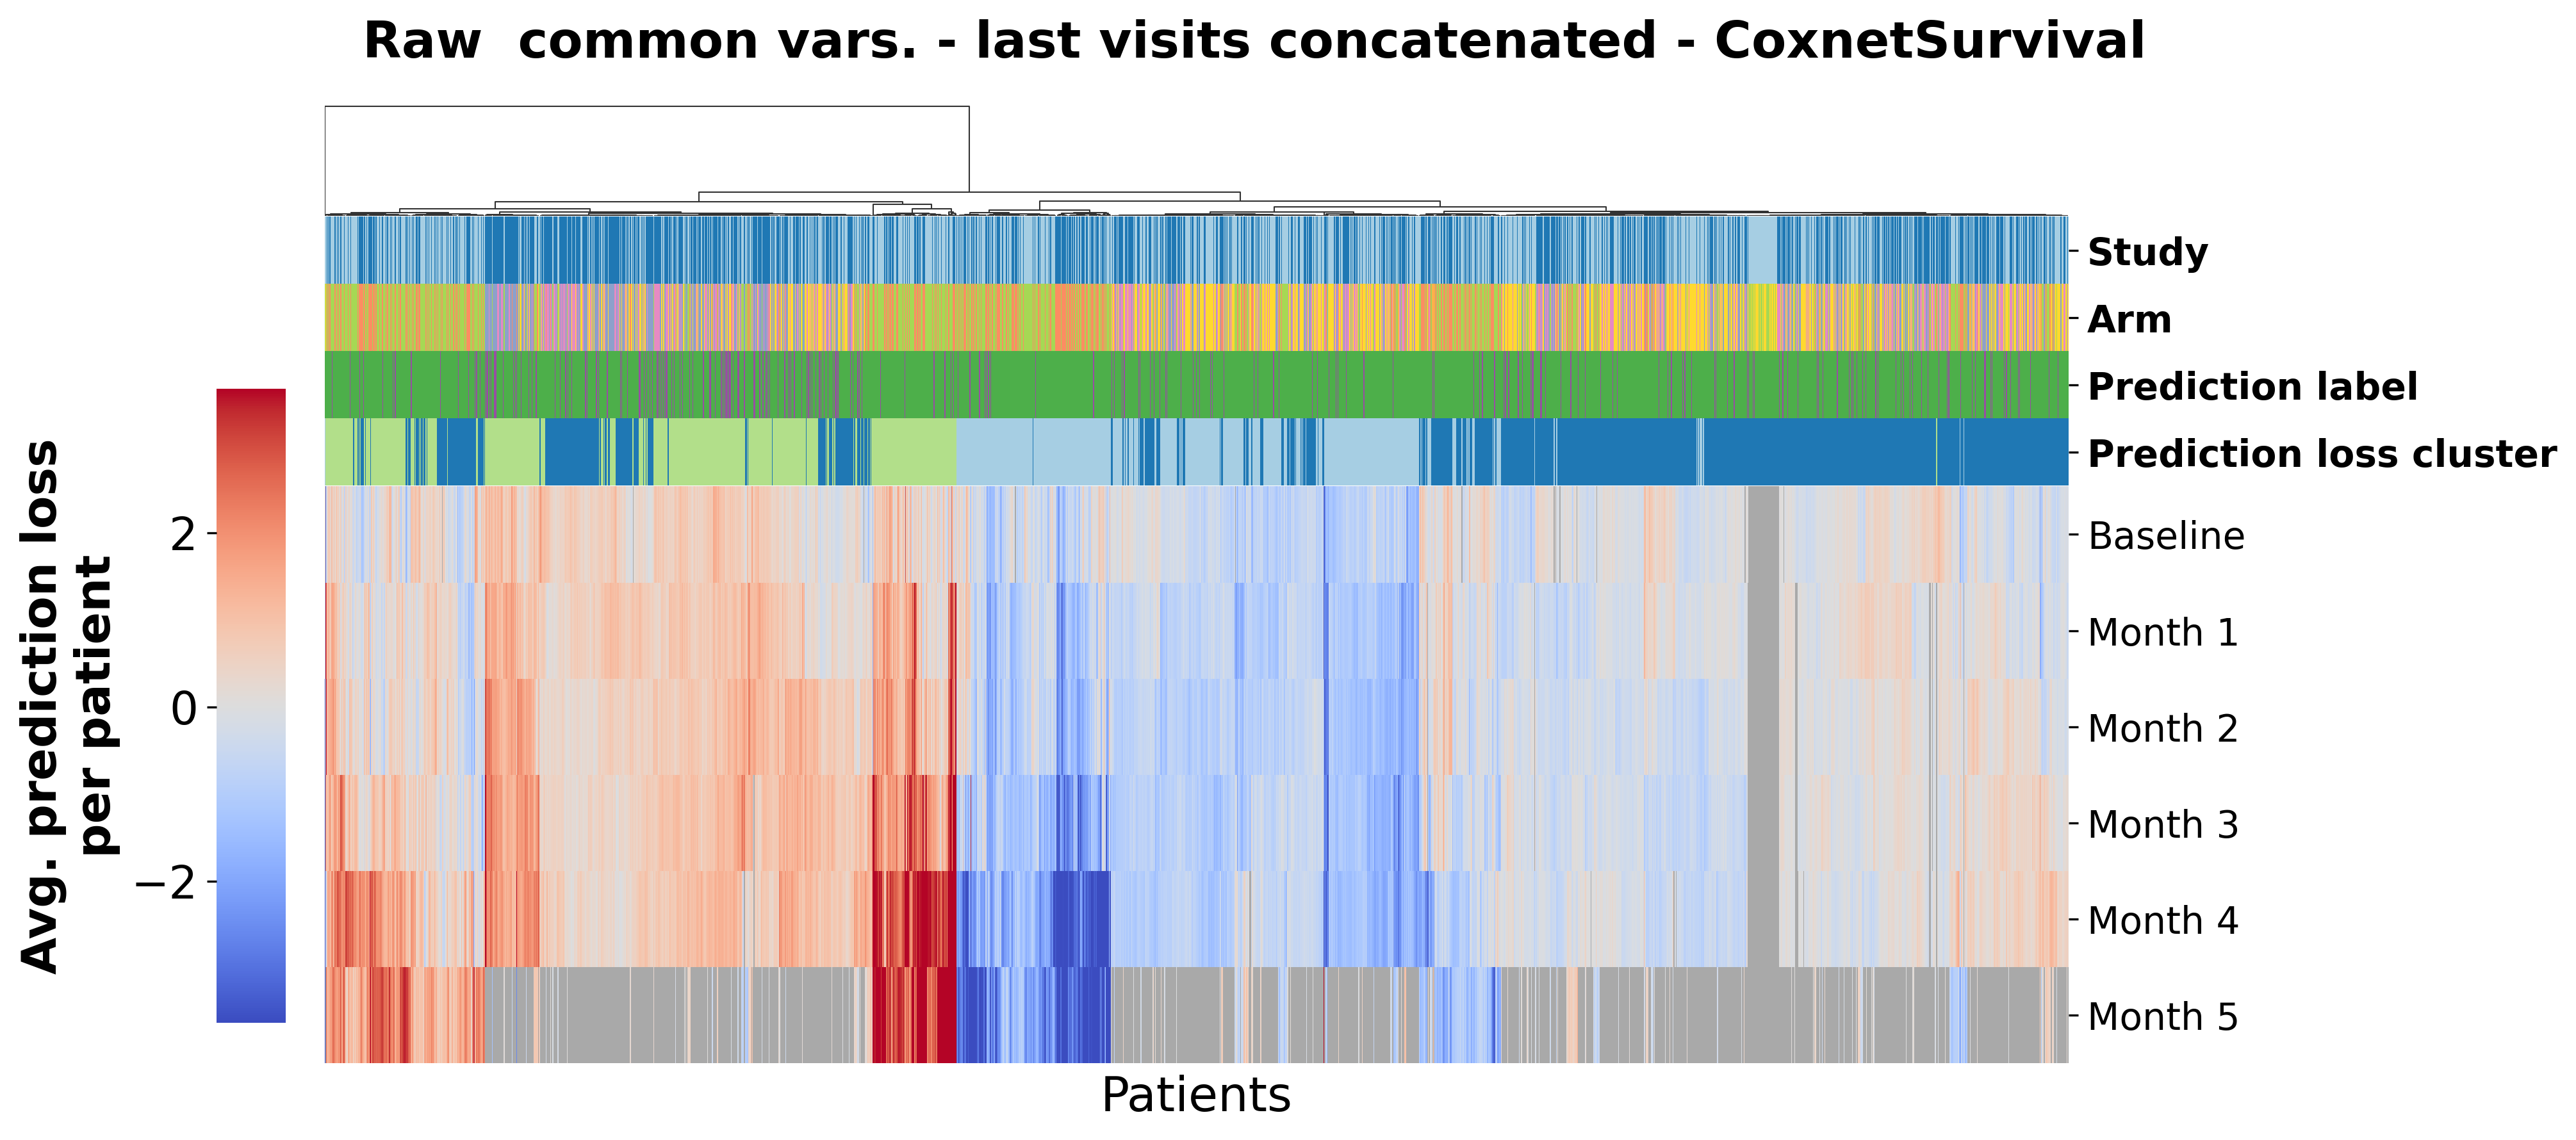

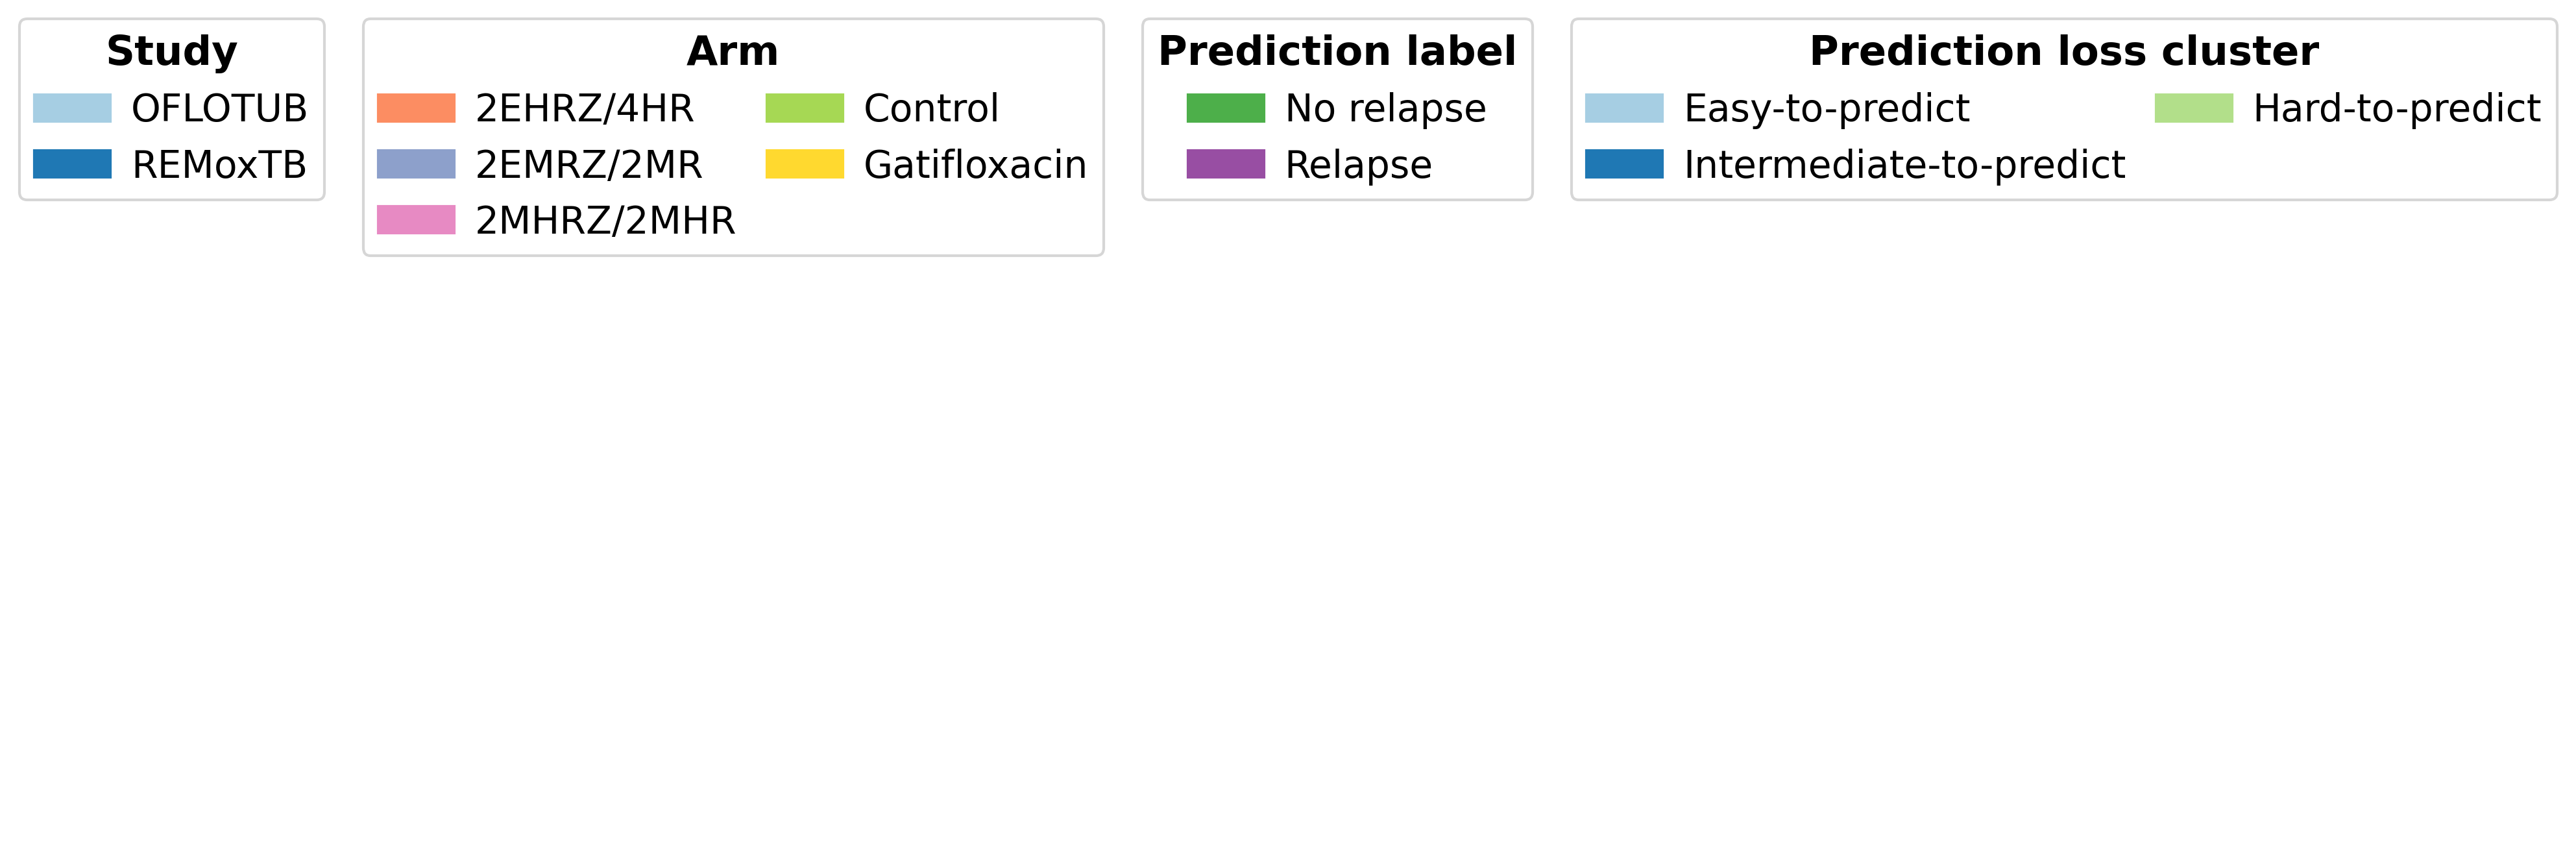

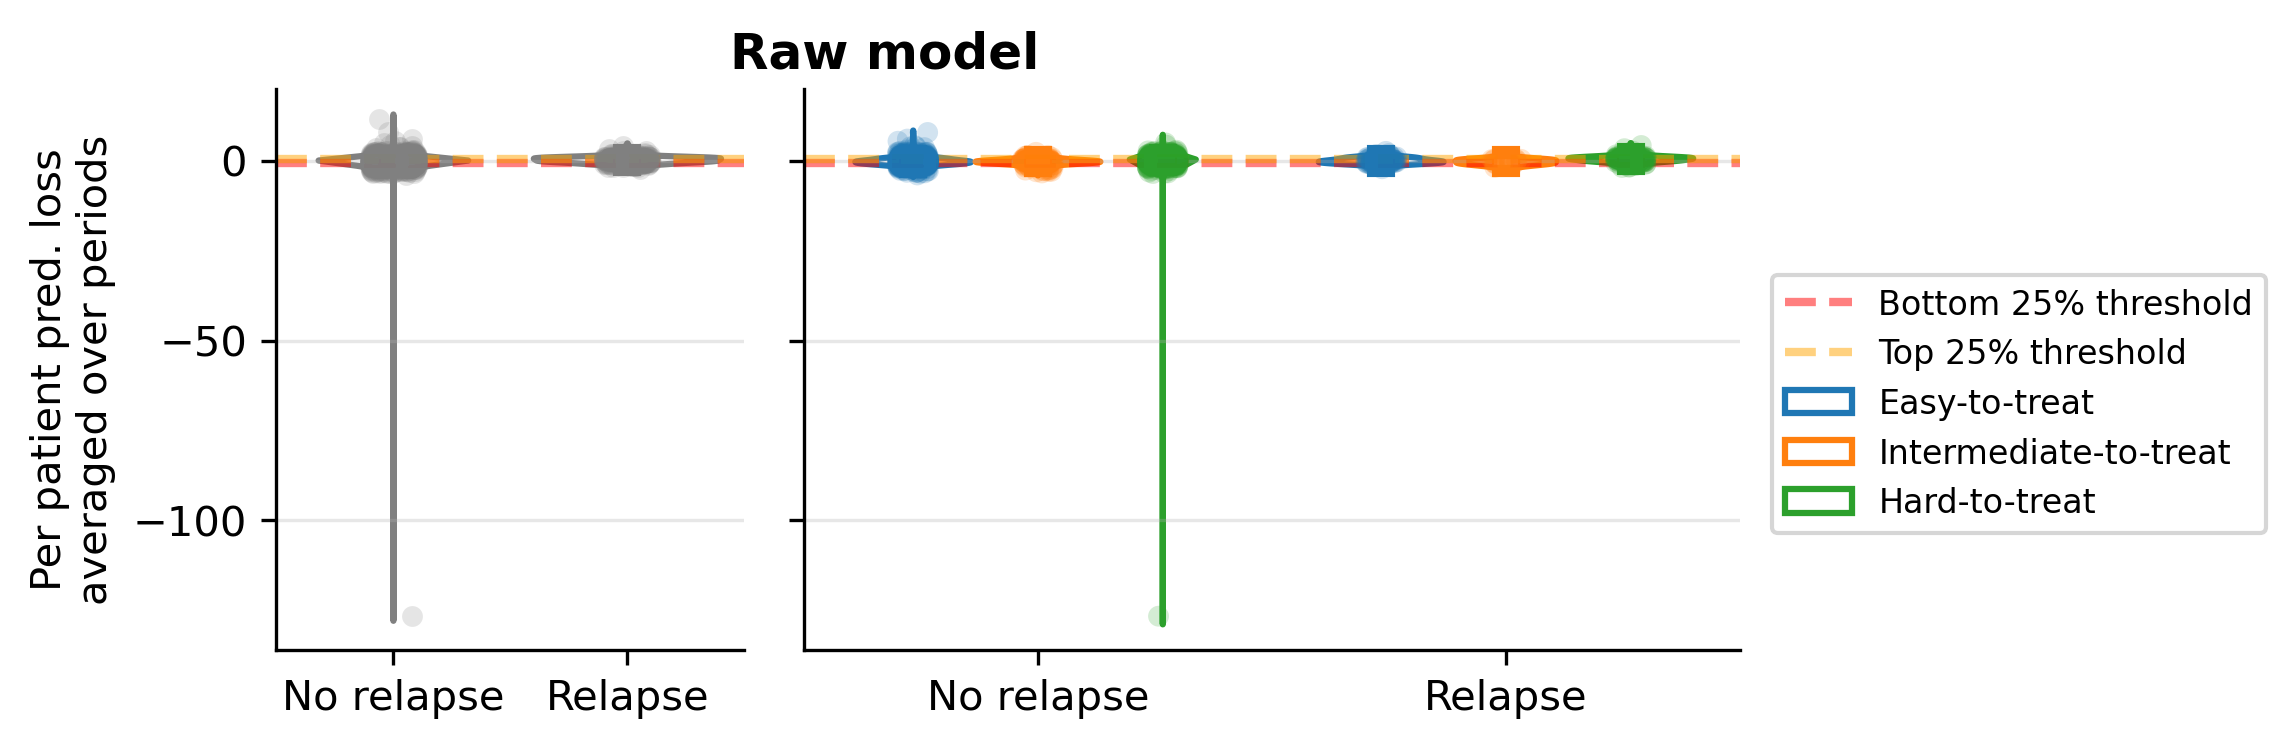

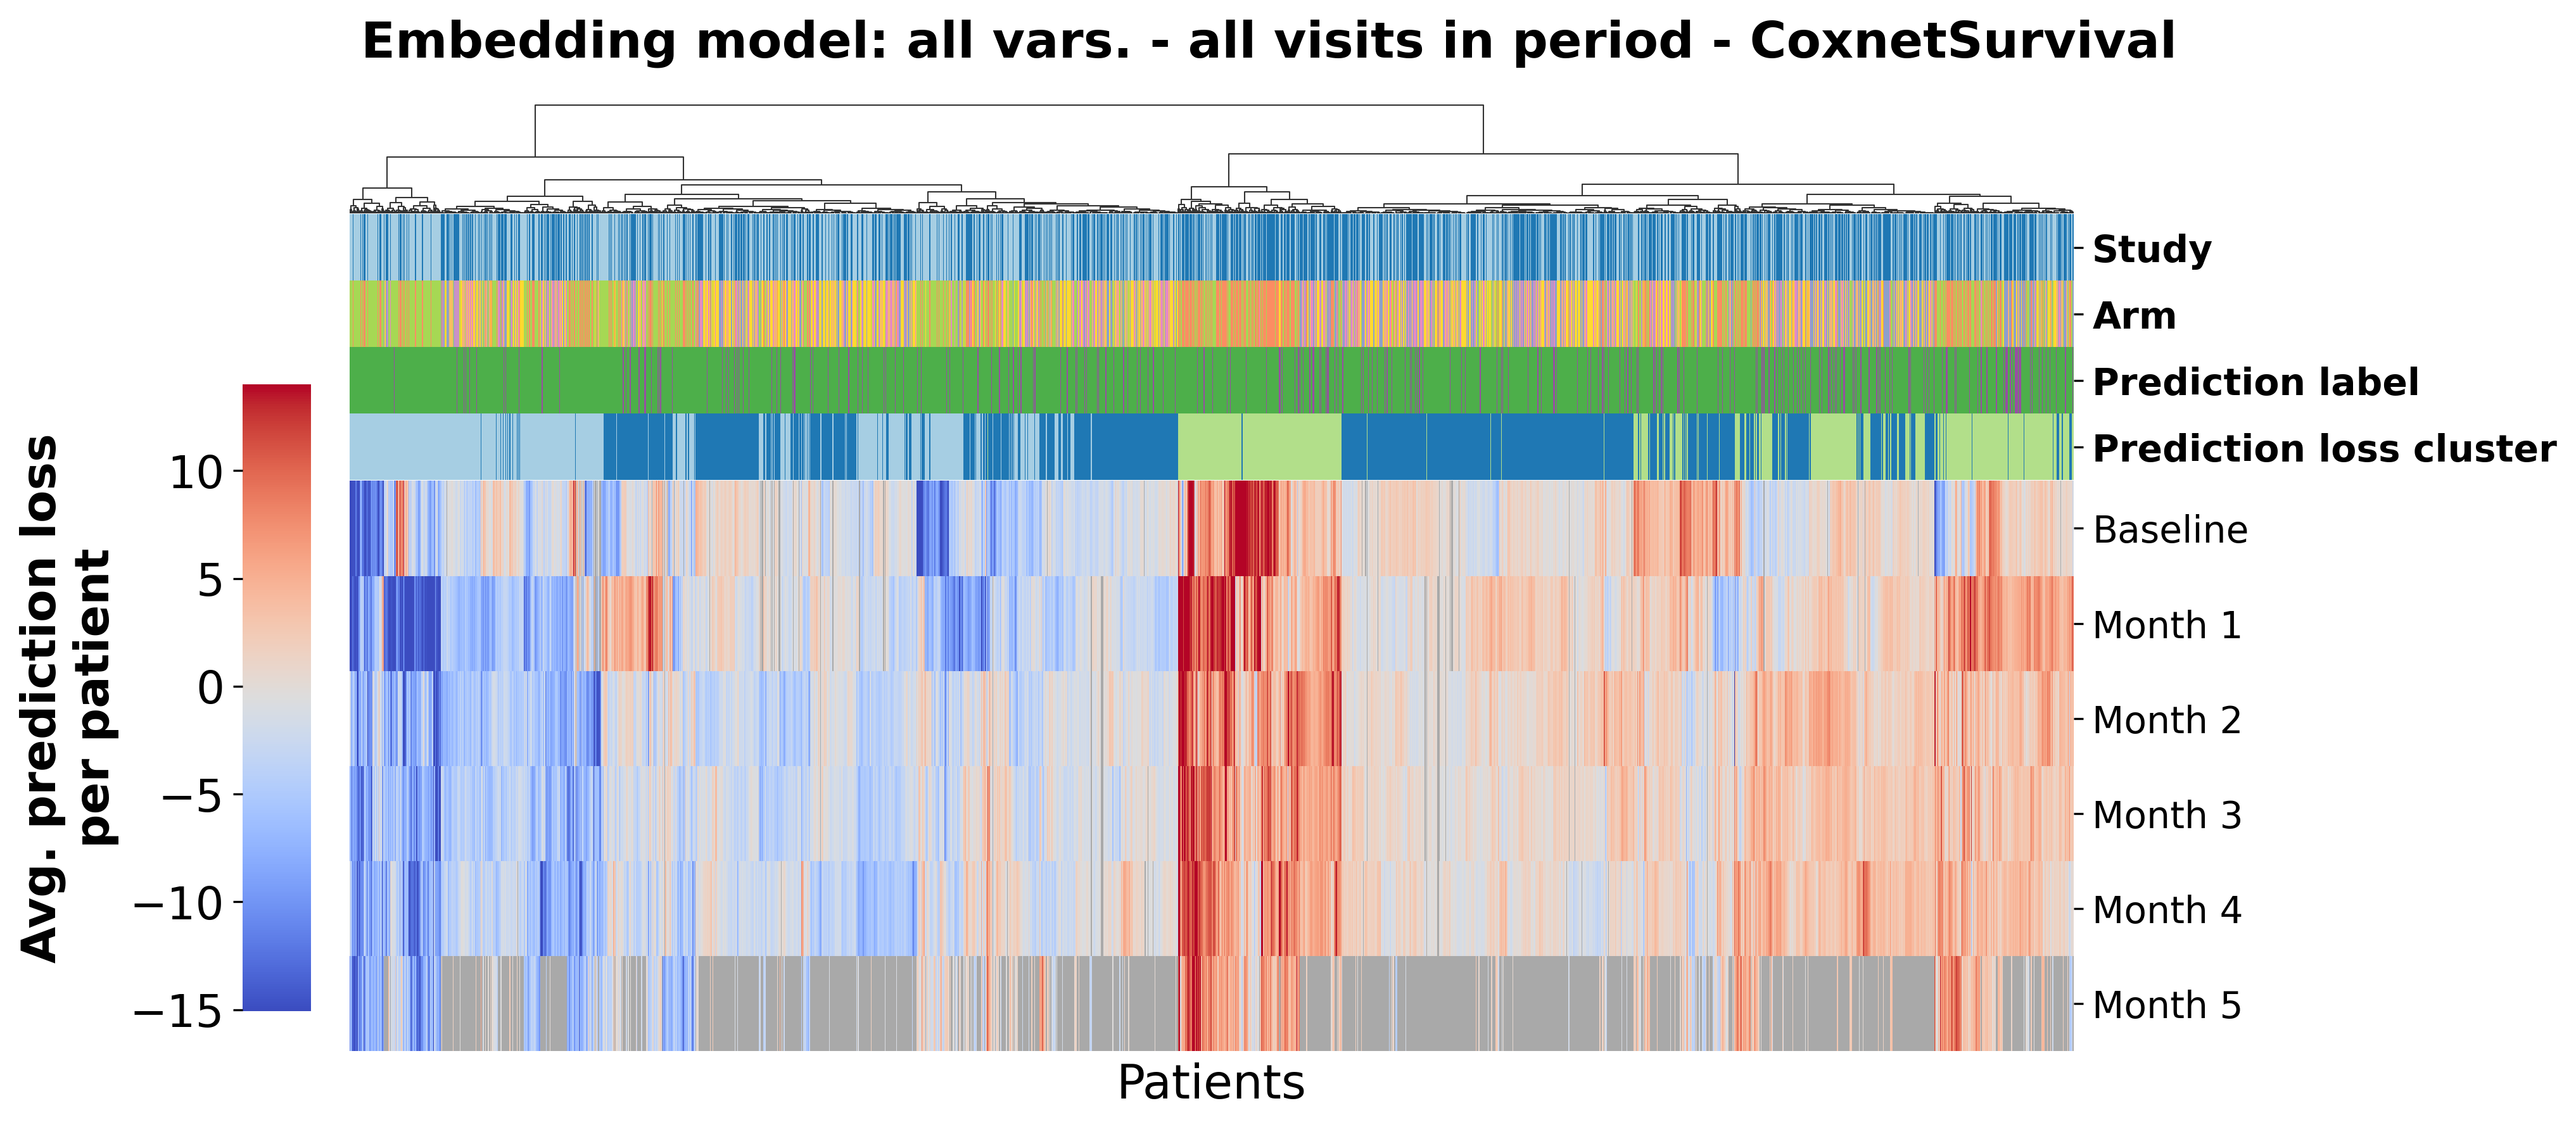

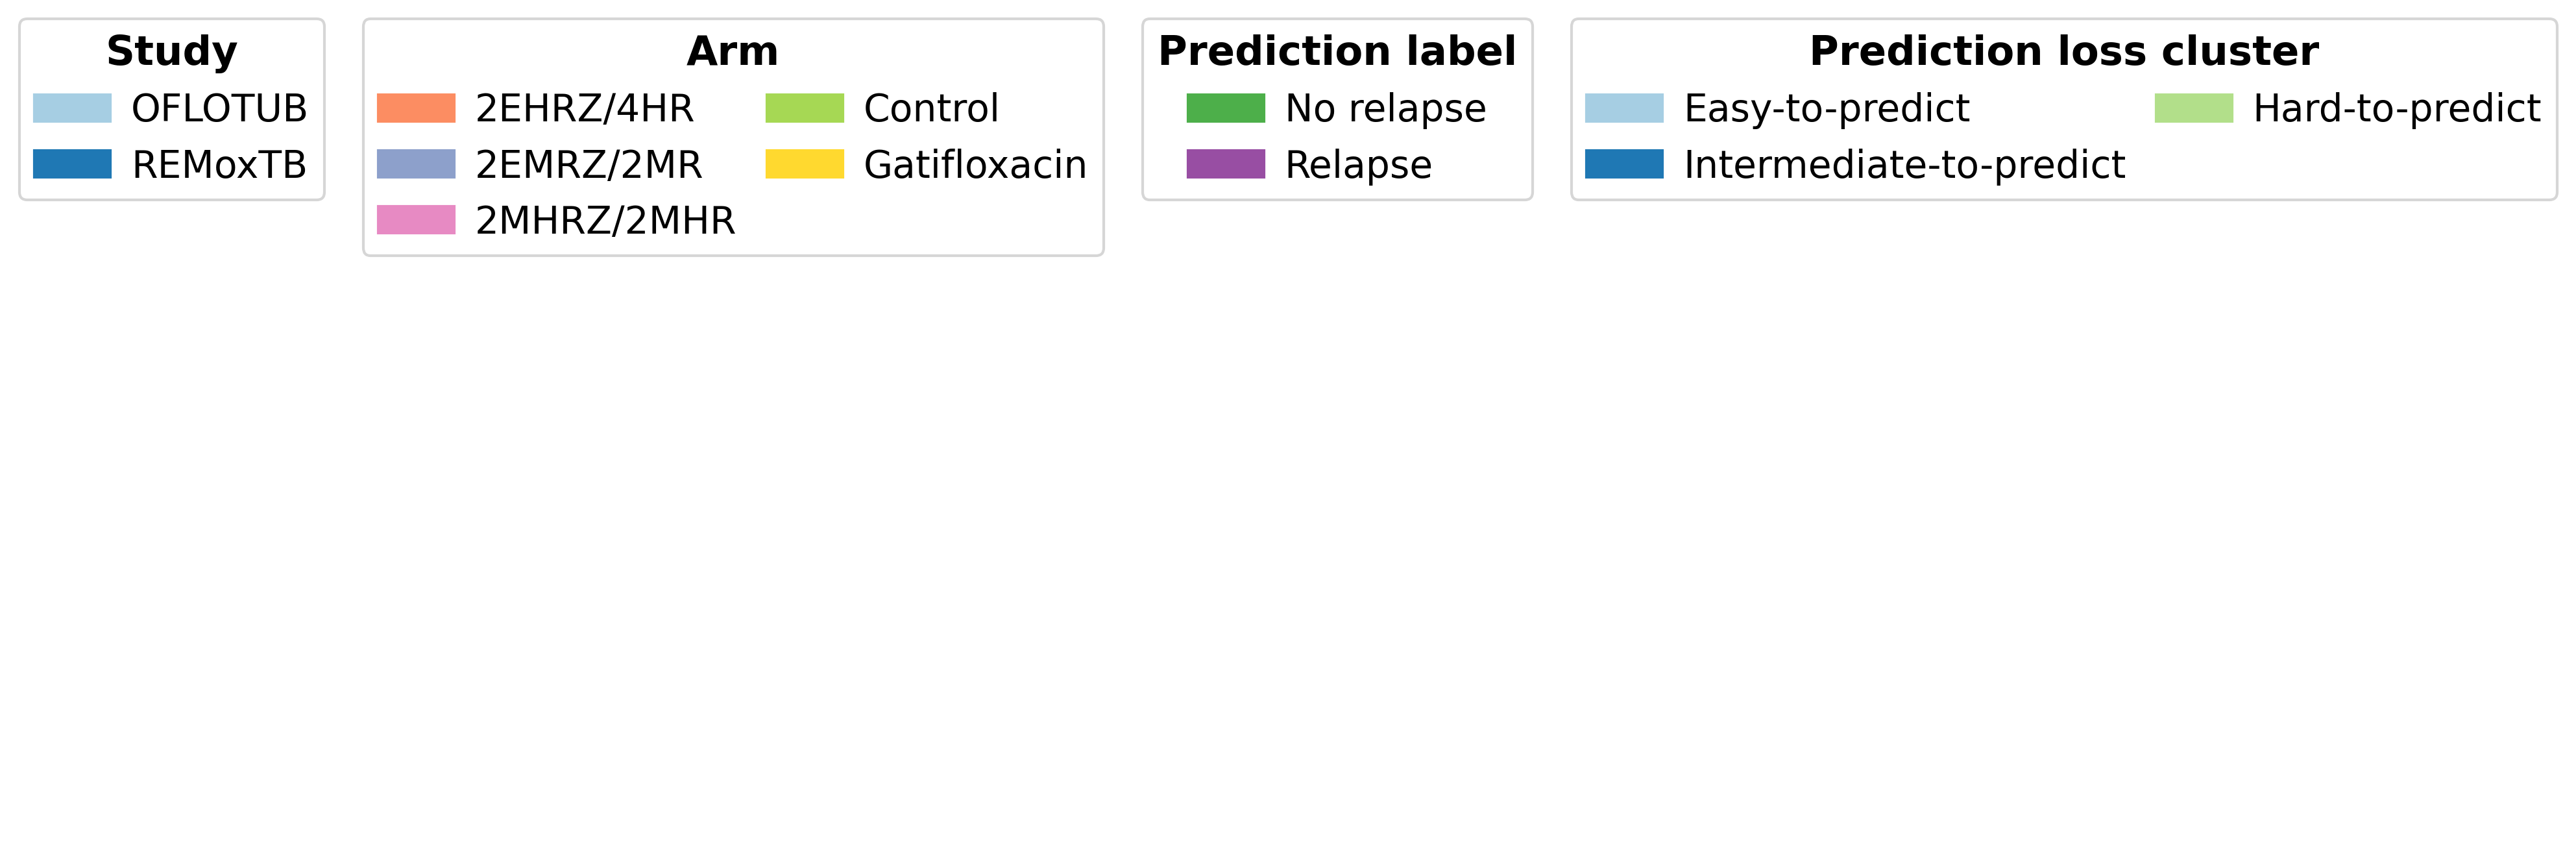

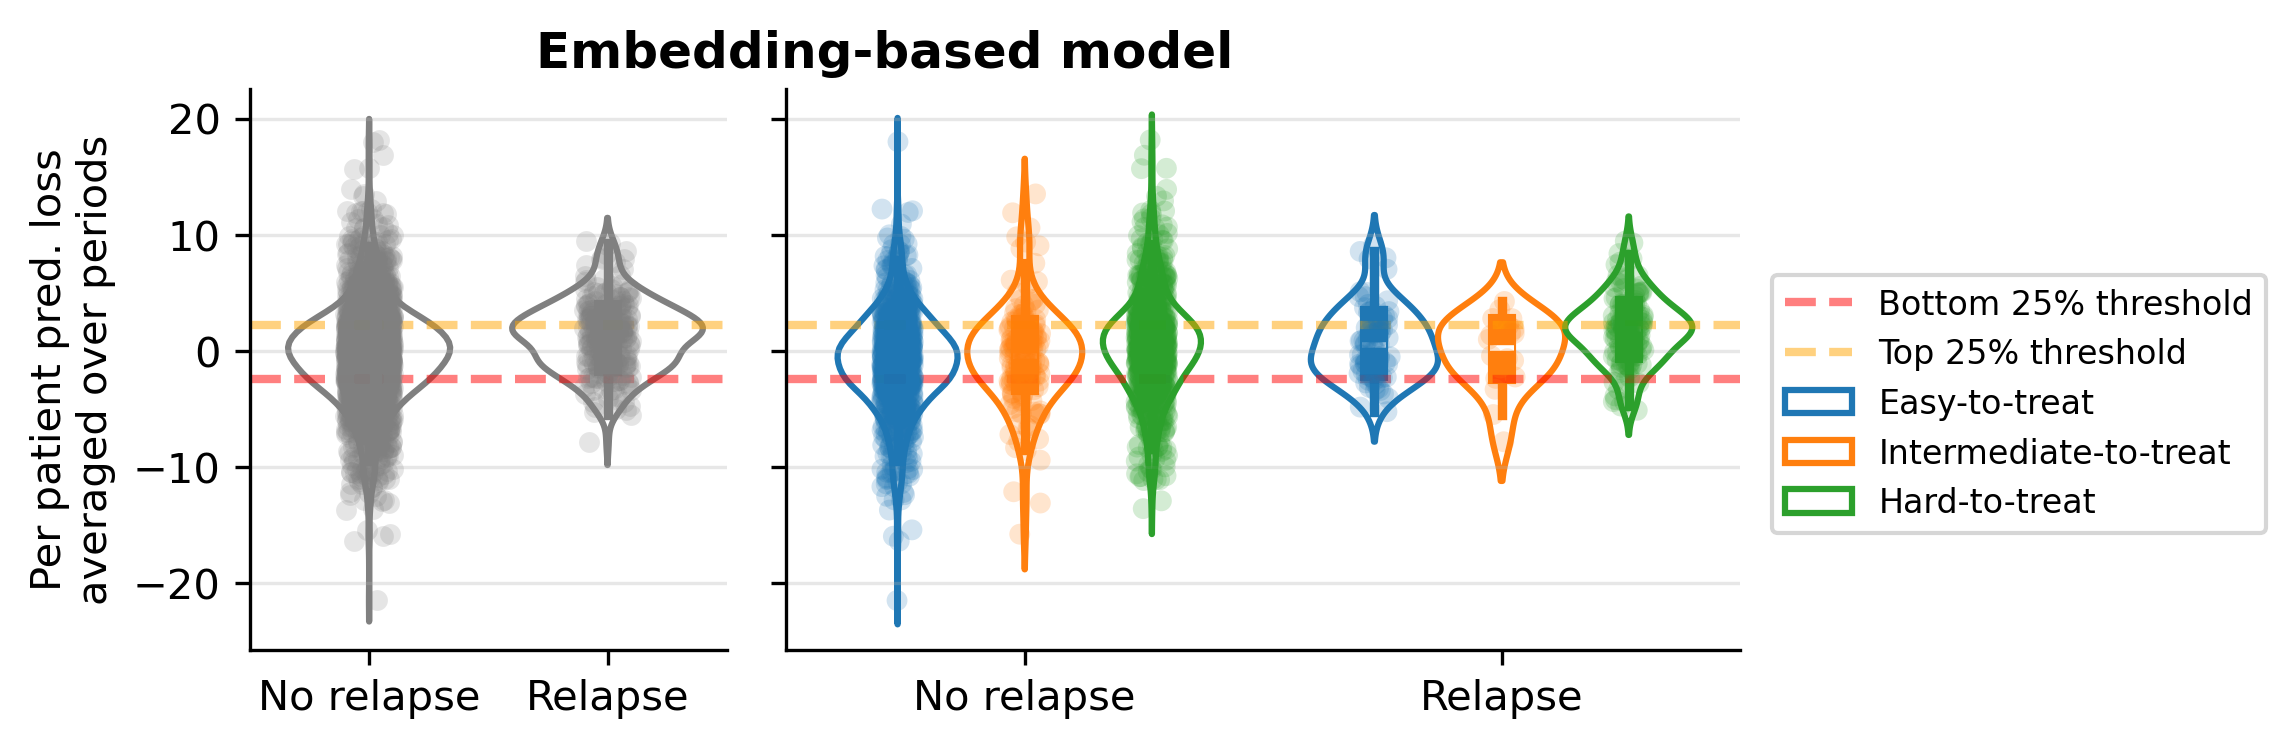

In [8]:
prob_df_conc=pd.concat(kk,axis=0)
prob_df_mean_conc=pd.concat(kk_,axis=0)
num_times_in_test_set=prob_df_conc.reset_index().groupby(['USUBJID','period']).apply(lambda x:x['cv_repeat_num'].shape[0]).groupby('USUBJID').mean()

cav_zn = return_treatment_strata(outcome_label)



import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import log_loss


low_prob_thr=0.3
high_prob_thr=1-low_prob_thr

avg_pred_prob_per_pat=True

if avg_pred_prob_per_pat==True:
    clust_df =prob_df_mean_conc.copy()
    clust_df['num_times_in_test'] = num_times_in_test_set.loc[clust_df.index].values
    #print(clust_df['ARM'])


if avg_pred_prob_per_pat==False:
    clust_df = prob_df_conc.copy()
#pred_prob_coln='raw_pred_prob_norm'

clust_result_dict={}


#for pred_prob_coln in ['raw_pred_prob_norm','llm_pred_prob_norm']:
for pred_prob_coln in [#'raw_pred_prob_norm',
                       #'llm_pred_prob_norm',
                       'raw_pred_risk',
                       'llm_pred_risk',
                       #'lstm_pred_prob',
                        'lstm_pred_prob_norm',
                        'raw_pred_prob_calibr',
                       'llm_pred_prob_calibr'][:2]:



    clust_df_ = clust_df.copy()
    
    clust_df_[f'{pred_prob_coln}_loss']=(clust_df_[pred_prob_coln] - clust_df_['true_labels']).abs().values
    #clust_df[f'{pred_prob_coln}_loss']  =  -1*((clust_df['true_labels'] * np.log10(clust_df[pred_prob_coln]))+\
    #                                       ((1-clust_df['true_labels'])*np.log10(1-clust_df[pred_prob_coln])))
    #clust_df[f'{pred_prob_coln}_loss'] = log_loss(clust_df['true_labels'], clust_df[pred_prob_coln])



    clust_df_['STUDYID'] = (clust_df_.reset_index()['USUBJID'].str.split('/',expand=True)[0]).values

    clust_df_['ARM'] = clust_df_['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                                'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    id2label_={'RESULT_AT_END_OF_TREATMENT':{0: "Favourable", 1: "Unfavourable"},
              'RELAPSE':{0: "No relapse", 1: "Relapse"}}

    
    clust_df_['Prediction label']=clust_df_['true_labels'].map(id2label_[outcome_label])
    #clust_df_wide = clust_df.reset_index().pivot(index='USUBJID',columns=['period'],values=f'{pred_prob_coln}_label')

    clust_df_ = clust_df_.rename(columns={'ARM':'Arm','STUDYID':'Study'})
    clust_df_['Study']=clust_df_['Study'].replace('TB-1022','OFLOTUB')
    clust_df_['Study']=clust_df_['Study'].replace('TB-1021','REMoxTB')

    if avg_pred_prob_per_pat==True:
        clust_df_wide = clust_df_.reset_index().pivot(index=['USUBJID','Arm','Study','Prediction label','num_times_in_test'][:-1],
                                                     columns=['period'],
                                                     #values=f'{pred_prob_coln}_loss',
                                                     values=f'{pred_prob_coln}')
    if avg_pred_prob_per_pat==False:
        clust_df_wide = clust_df_.reset_index().pivot(index=['USUBJID','cv_repeat_num','Arm','Study','Prediction label'],
                                                     columns=['period'],
                                                     #values=f'{pred_prob_coln}_loss',
                                                     values=f'{pred_prob_coln}')
        
    clust_df_wide.columns.name=None
    clust_result_dict[pred_prob_coln] = clust_df_wide





pred_label_loss_dict,pred_label_loss_quant_dict={},{}

for pred_label in ['Relapse','No relapse','Both'][-1:]:
    pred_label_loss_dict[pred_label] = {}
    pred_label_loss_quant_dict[pred_label] = {}

    #for pred_prob_coln in ['raw_pred_prob_norm','llm_pred_prob_norm','diff_pred_prob_norm']:
    for pred_prob_coln in [#raw_pred_prob_norm',
                           #'llm_pred_prob_norm',
                           'raw_pred_risk',
                           'llm_pred_risk',
                           #'lstm_pred_prob',
                            'lstm_pred_prob_norm',
                           #'diff_pred_prob_norm',
                           'diff_pred_prob',
                           'raw_pred_prob_calibr',
                           'llm_pred_prob_calibr'][:2]:
    
        
        #clust_df_wide = clust_df.reset_index().pivot(index=['USUBJID','cv_repeat_num'],columns=['period'],values='label')
        if pred_prob_coln in ['raw_pred_prob_norm','llm_pred_prob_norm','raw_pred_risk',
                              'llm_pred_risk','lstm_pred_risk','lstm_pred_prob_norm',
                              'raw_pred_prob_calibr',
                           'llm_pred_prob_calibr']:
    
            clust_df_wide = clust_result_dict[f'{pred_prob_coln}']
            cmap_='coolwarm'
            cmap_='berlin'
            camp_='managua'
    
        if pred_prob_coln in ['diff_pred_prob_norm']:
            clust_df_wide = clust_result_dict['raw_pred_prob_norm'] - clust_result_dict['llm_pred_prob_norm'] 
            
        if pred_prob_coln in ['diff_pred_prob']:
            clust_df_wide = clust_result_dict['raw_pred_prob'] - clust_result_dict['llm_pred_prob'] 
            
    
            
            clust_df_wide=clust_df_wide.abs()
            cmap_='viridis'
        
        clust_df_wide = clust_df_wide.replace({'confident_unfavour': 0, 
                                                                'confident_favour': 1, 
                                                                'unconfident_unfavour': 2,
                                                                'unconfident_favour':3})
        
        #prob_df_mean_conc_wide = prob_df_mean_conc_wide.astype(int)
    
    
        period_end_days__= period_end_days[:-1] if outcome_label=="RESULT_AT_END_OF_TREATMENT" else period_end_days
        clust_df_wide=clust_df_wide.loc[:,period_end_days__]
    
        print('outcome_label',outcome_label)
        periods_to_show= period_end_days[:-3] if outcome_label=="RESULT_AT_END_OF_TREATMENT" else  period_end_days[:-1]
        
        #plot_df =clust_df_wide.dropna(how='any', axis=0,subset=periods_to_show)
        #plot_df = plot_df.loc[:,periods_to_show]
        
        #periods_to_show = period_end_days__[:]
    
        print('periods_to_show',periods_to_show)
        
        
        plot_df =clust_df_wide.fillna(-0.0001)#.dropna(how='any', axis=0,subset=periods_to_show)
        plot_df = plot_df.loc[:,periods_to_show]

        #print(plot_df.head())
    
        #plot_df = plot_df.loc[plot_df.index.get_level_values('Prediction label')=='No relapse']
        if pred_label !='Both':
            plot_df = plot_df.loc[plot_df.index.get_level_values('Prediction label')==pred_label]
        

        
    
            
        
        from matplotlib.colors import ListedColormap
        
        # Define your 4 colors
        cmap = ListedColormap(["#1f77b4",  # blue → confident_unfavour
                               "#2ca02c",  # green → confident_favour
                               "#ff7f0e",  # orange → unconfident_unfavour
                               "#d62728"]) # red → unconfident_favour
    
        colormaps=['cool','rocket','RdBu','viridis']
        cat_colormaps=['Paired','Set2','Set1','Paired','tab10']
        #num_col_color_vars = ['pred_prob_norm','RELAPSE_DAY','DAYS_TO_RELAPSE']
        num_col_color_vars = ['pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE','num_times_in_test'][:-1]
        numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
    
        col_color_var_list=['Study',#'cv_repeat_num',
                        'Arm','Prediction label','num_times_in_test'][:-1]#'pred_prob_norm',]#'RELAPSE_DAY','DAYS_TO_RELAPSE']
    
    
    
        ### CREATE CUSTOM LEGEND FOR REGIONS
        # Create a list for column colors
        col_colrs_list = []
        legends = []  # Store legend details
    
            
    
        for n,colour_coln in enumerate(col_color_var_list):
        
            if colour_coln in num_col_color_vars:
        
                # Extract column values
                col_vals = plot_df.reset_index()[colour_coln]
                
                # Identify NaNs
                nan_mask = col_vals.isna()
            
                # Normalize only the non-NaN values
                non_nan_values = col_vals[~nan_mask]
                norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                     vmax=np.quantile(non_nan_values, 0.98))
            
                # Choose colormap
                colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
            
                # Apply color mapping (gray for NaNs, colormap for valid values)
                continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
                
                col_colrs_list.append(continuous_colors)
                
                # Add colorbar for continuous variable (only for non-NaN values)
                legends.append({"type": "continuous",
                                "label": colour_coln,
                                "norm": norm,
                                "colormap": colormap})
        
        
            #elif colour_coln=='cv_repeat_num':
            #    continue
                
            else:
                cat_cmap = cat_colormaps[n]
                
                col_vars=np.sort(plot_df.reset_index()[colour_coln].astype(str).unique())
                ordered_clusters_colors = plt.cm.get_cmap(cat_cmap)# len(col_vars))  
                ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
            
                #col_colrs_list.append(plot_df.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
                col_df = pd.DataFrame(data=plot_df.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).values,
                          index=plot_df.index,
                          columns=[colour_coln])
    
                col_colrs_list.append(col_df)
        
                # Add legend for categorical variable
                patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                    for region in col_vars]
                
                legends.append({"type": "categorical",
                                "label": colour_coln,
                                "handles": patch_handles})
    
         # Extract linkage matrix for columns
        col_linkage = sch.linkage(plot_df, method="ward", metric="euclidean") 
        max_clust_num=8
        col_clusters = fcluster(col_linkage, t=max_clust_num, criterion='maxclust')
        #=6
        #col_clusters = fcluster(col_linkage, t=t, criterion='distance')
        
        
        pred_label_loss_dict[pred_label][pred_prob_coln] = dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))
    
    
        ## TAKE LOWER OR UPPER 20% OF PATIENTS WITH AVERAGED PRED. LOSS ACROSS TIME AS EASY OR HARD TO PREDICT PATIENTS
        ## 0: easy-to-predict, 1: hard_to_predict, 2: intermediate-to-predict
        mean_pred_loss = plot_df[plot_df!=-0.0001].mean(axis=1).to_frame()#.quantile(0.2)#hist(bins=50)
        mean_pred_loss['pred_cluster']=2
        
        easy_mask = (mean_pred_loss[0]<=mean_pred_loss[0].quantile(0.25)).values
        hard_mask = (mean_pred_loss[0]>=mean_pred_loss[0].quantile(0.75)).values

        #easy_mask = (mean_pred_loss[0]<=0.5).values
        #hard_mask = (mean_pred_loss[0]>0.5).values
        
        mean_pred_loss.loc[easy_mask,'pred_cluster']=0
        mean_pred_loss.loc[hard_mask,'pred_cluster']=1
        
        pred_label_loss_quant_dict[pred_label][pred_prob_coln] = dict(zip(mean_pred_loss.reset_index()['USUBJID'],
                                                     mean_pred_loss.reset_index()['pred_cluster']))
        
        
        
        #clust_result_dict[pred_prob_coln] = dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))
        
        clust_df[f'{pred_prob_coln}_cluster'] = clust_df.reset_index()['USUBJID'].map(dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))).values
        clust_df[f'{pred_prob_coln}_quant_cluster'] = clust_df.reset_index()['USUBJID'].map(pred_label_loss_quant_dict[pred_label][pred_prob_coln]).values
        
    
    
        
        ### ADD RPEDICTION LOSS CLUSTER BASED ON HIERARCHICAL CLUSTERING
        '''
        num_clusters = len(set(col_clusters))  # Number of unique clusters
        col_palette = sns.color_palette("tab20", num_clusters)  # Use a categorical color palette
        cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(set(col_clusters))}
    
        dendro_colors = [cluster_color_mapping[cluster] for cluster in col_clusters]# + [(0,0,0,1)]*len(a)
        #col_colrs_list.append(dendro_colors)
        
        col_df = pd.DataFrame(data=pd.Series(dendro_colors).values,
                          index=plot_df.index,
                          columns=['Subcluster'])
        col_colrs_list.append(col_df)
        
        legends.append({"type": "categorical",
                            "label": "Subcluster",
                            "handles":[Patch(color=color, label=str(dendr_clust))
                                        for dendr_clust,color in cluster_color_mapping.items()]})
        col_color_var_list.append('Subcluster')
        '''
    
    
        ### ADD RPEDICTION LOSS CLUSTER BASED ON QUANTILES
        # Step 3: Map each cluster to a unique color
        dd_ = {0:'Easy-to-predict',1:'Hard-to-predict', 2:'Intermediate-to-predict'}
        pat_clust_df__=plot_df.reset_index()['USUBJID'].map(pred_label_loss_quant_dict[pred_label][pred_prob_coln]).replace(dd_)
        
        col_clusters=np.sort(pat_clust_df__.values)
        num_clusters = len(set(col_clusters))  # Number of unique clusters
        col_palette = sns.color_palette("Paired", num_clusters+2)  # Use a categorical color palette
        cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(set(col_clusters))}
    
        col_df = pd.DataFrame(data=pd.Series(pat_clust_df__.map(cluster_color_mapping)).values,
                              index=plot_df.index,
                              columns=['Prediction loss cluster'])
    
        col_colrs_list.append(col_df)
    
     
        
        legends.append({"type": "categorical",
                            "label": "Prediction loss cluster",
                            "handles":[Patch(color=color, label=str(dendr_clust))
                                        for dendr_clust,color in cluster_color_mapping.items()]})
        col_color_var_list.append('Prediction loss cluster')
    
    
    
    
    
        if pred_prob_coln=='llm_pred_risk':
            #cbar_label='Avg. prediction loss\nabs(True label - Embedding-based pred. prob.)'
            cbar_label='Avg. prediction loss\nper patient'#\nabs(True label - Embedding-based pred. prob.)'
    
        if pred_prob_coln=='raw_pred_risk':
            #cbar_label='Avg. prediction loss\nabs(True label - Raw pred. prob.)'
            cbar_label='Avg. prediction loss\nper patient'
            
            
        plot_df = plot_df.rename(columns={'baseline':'Baseline',
                                            31:'Month 1',
                                            62:'Month 2',
                                            93:'Month 3',
                                            125:'Month 4',
                                            160:'Month 5',
                                            'all':'Month 6',
                                           })
                    
        data = plot_df.T
        mask2 = (data.to_numpy() == -0.0001)  # ndarray[bool], no pandas alignment
        #assert mask2.shape == data.shape
        cmap_='coolwarm'
        #cmap_='berlin'
        #cmap_='Spectral'
    
        col_colrs_df = pd.concat(col_colrs_list,axis=1)
        
        g= sns.clustermap(
            data,#.astype(int),
            col_cluster=True,
            row_cluster=False,
            #col_colors=col_colrs_list,
            col_colors=col_colrs_df,
            yticklabels=True,
            xticklabels=False,
            colors_ratio=(0,0.07),
            dendrogram_ratio=(0.1, 0.12),
            figsize=(12, 5.5),
            cbar_pos=(0.05, 0.1, 0.03, 0.6),
            cbar_kws={'label':cbar_label},
            #cmap=cmap,
            cmap=cmap_,
            method='ward',
            mask=mask2,
            #vmin=np.min(data.to_numpy()[~mask2]),
            #vmax=np.max(data.to_numpy()[~mask2]),

            vmin=np.quantile(data.to_numpy()[~mask2],0.01),
            vmax=np.quantile(data.to_numpy()[~mask2],0.99),
            #vmax=3  # important: ensure full colormap range is used
        
        )
        g.ax_cbar.yaxis.set_label_position("left")
        g.ax_cbar.yaxis.tick_left()
        g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=18, fontweight='bold')
        g.ax_cbar.tick_params(axis='y',labelsize=17)
        g.ax_heatmap.tick_params(axis='y',labelsize=14)
        #g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, weight='bold')
        g.ax_heatmap.set_xlabel('Patients',fontsize=18)
        
        g.ax_heatmap.set_facecolor("darkgrey")
        
        suptitle = return_suptitle_clustermap(llm_data_inclusion_type,
                                   raw_training_data_type,
                                   model_name,
                                   pred_prob_coln)
        
        g.fig.suptitle(suptitle,fontsize=19,fontweight='bold',y=1.05)
    
    
    
        # Add legends
        cont_leg_num=0
        fig = g.fig  # Access the figure from clustermap
    
      
    
    
    
        #plt.show()
        ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
        # Calculate the y positions for the ticks
        
        num_col_colors = len(col_color_var_list)
        yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
        g.ax_col_colors.set_yticks(yticks)
        
        # Set the tick labels on the right side
        g.ax_col_colors.yaxis.tick_right()
        
        # Set the tick labels for each color bar
        col_col_names=col_color_var_list
        g.ax_col_colors.set_yticklabels(col_col_names, 
                                        fontsize=14,  # Adjust fontsize here
                                        ha='left',  # Horizontal alignment to be closer to the color bars
                                        weight='bold'
                                       )
        
        ## SAVE PLOTS
        data_dir_=f'../data/plots/pred_loss_clustermaps/{raw_data_param_key}/{pred_label}'
        os.makedirs(data_dir_,exist_ok=True)
    
        raw_training_data_type_dict ={'last_therapy_day':'last_visit_in_period',
                                     'all_days_in_period':'last_visits_concatenated'}
    
        llm_data_inclusion_type_dict={'baseline_last_day':'common vars__last_visit_in_period',
                                       'baseline_vars':'common vars__all visits in period',
                                       'all_days':'all vars__all visits_in_period'}
        
        r = raw_training_data_type_dict[raw_training_data_type]
        l = llm_data_inclusion_type_dict[llm_data_inclusion_type]
    
        if 'llm_pred_risk' in pred_prob_coln:
            fn = f"{period_end_day}__LLM_{l}__{model_name.replace('LogisticRegression','LR')}"
    
    
        if 'raw_pred_risk' in pred_prob_coln:
            fn = f"{period_end_day}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"

        if 'lstm' in pred_prob_coln:
            fn = f"{period_end_day}__LSTM_{r}__{model_name.replace('LogisticRegression','LR')}"
        
        
        fn=os.path.join(data_dir_,
                    f'{fn}')
        #g.fig.savefig(fn, bbox_inches='tight', dpi=300)
        #plt.close()
    
    
        
    
          
        # ----------------------------
        # 3) dynamic stacked legends + continuous colorbars
        # ----------------------------
        #fig = g.fig
        #leg_fig,axes = plt.subplots(1,1,figsize=(10,5))
        #axes.axis('off')
        #fig = plt.figure(figsize=(10,5))
    
        '''
        
        # Where to place the stack (figure coordinates, not axes coordinates)
        x_anchor = 0.5   # increase to move further right
        y_top = 1.0     # increase to move higher
        pad = 0.015       # vertical padding between items (figure fraction)
        
        # Continuous colorbar sizing (in figure fraction)
        cbar_width = 0.03
        cbar_height = 0.15
        
        # Stacking items by tracking the current y cursor (top of next item)
        y_cursor = y_top
        
        # Ensure a canvas exists before measuring text/legend extents
    
        leg_fig.canvas.draw()
        renderer = leg_fig.canvas.get_renderer()
    
        
        
        for legend in legends:
            if legend.get("label") == "cv_repeat_num":
                continue
        
            if legend.get("type") == "categorical":
                # Place categorical legend: anchor its upper-left at (x_anchor, y_cursor)
                leg = leg_fig.legend(
                    handles=legend["handles"],
                    title=legend["label"],
                    loc="upper left",
                    bbox_to_anchor=(x_anchor, y_cursor),
                    bbox_transform=leg_fig.transFigure,
                    frameon=True,
                    fontsize=14,
                    #title_fontsize=15,
                    title_fontproperties={'weight':'bold','size':15},
                    borderaxespad=0.0,
                )
        
                # Force draw so bbox is accurate
                leg_fig.canvas.draw()
                bbox_disp = leg.get_window_extent(renderer=renderer)  # pixels
                bbox_fig = bbox_disp.transformed(leg_fig.transFigure.inverted())  # figure coords
        
                # Move cursor to just below this legend
                y_cursor = bbox_fig.y0 - pad
        
            elif legend.get("type") == "continuous":
                # Place continuous colorbar axes directly under current cursor
                # Here, y_cursor is the *top* position of the next item.
                y0 = y_cursor - cbar_height
                cbar_ax = fig.add_axes([x_anchor, y0, cbar_width, cbar_height])
        
                cb = ColorbarBase(
                    cbar_ax,
                    cmap=legend["colormap"],
                    norm=legend["norm"],
                    orientation="vertical",
                )
                cb.set_label(legend["label"], fontsize=10)
        
                # Move cursor to below the cbar
                y_cursor = y0 - pad
    
        '''
    
    
    
    
        import matplotlib.pyplot as plt
        from matplotlib.colorbar import ColorbarBase
        
        leg_fig, ax = plt.subplots(figsize=(10, 5))
        ax.axis("off")   # hide dummy axes
        
        # --- layout controls ---
        x_left = 0.05
        y_top = 0.95
        pad = 0.02
        
        cbar_width = 0.03
        cbar_height = 0.18
        
        x_cursor = x_left
        
        leg_fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        
        for legend in legends:
            if legend.get("label") == "cv_repeat_num":
                continue
        
            # -------------------------
            # categorical legend blocks
            # -------------------------
            if legend.get("type") == "categorical":
        
                leg = leg_fig.legend(
                    handles=legend["handles"],
                    title=legend["label"],
                    loc="upper left",
                    bbox_to_anchor=(x_cursor, y_top),
                    ncols=1 if len(legend["handles"])<3 else 2,
                    bbox_transform=leg_fig.transFigure,
                    frameon=True,
                    fontsize=14,
                    handletextpad=0.55,
                    columnspacing=0.8,
                    title_fontproperties={"weight": "bold", "size": 15},
                    borderaxespad=0.0,
                )
        
                fig.canvas.draw()
        
                bbox_disp = leg.get_window_extent(renderer=renderer)
                bbox_fig = bbox_disp.transformed(leg_fig.transFigure.inverted())
        
                # move cursor right by actual legend width
                x_cursor = bbox_fig.x1 + pad
        
            # -------------------------
            # continuous colorbar blocks
            # -------------------------
            elif legend.get("type") == "continuous":
        
                y0 = y_top - cbar_height
        
                cbar_ax = leg_fig.add_axes([
                    x_cursor,
                    y0,
                    cbar_width,
                    cbar_height
                ])
        
                cb = ColorbarBase(
                    cbar_ax,
                    cmap=legend["colormap"],
                    norm=legend["norm"],
                    orientation="vertical",
                )
        
                cb.set_label(legend["label"], fontsize=10)
        
                x_cursor = x_cursor + cbar_width + pad
    
    
    
    
        if 'llm_pred_risk' in pred_prob_coln:
            fn = f"{period_end_day}__LLM_{l}__{model_name.replace('LogisticRegression','LR')}_legend.png"
    
    
        if 'raw_pred_risk' in pred_prob_coln:
            fn = f"{period_end_day}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}_legend.png"

        if 'lstm' in pred_prob_coln:
            fn = f"{period_end_day}__LSTM_{r}__{model_name.replace('LogisticRegression','LR')}_legend.png"
        
        
        fn=os.path.join(data_dir_,
                    f'{fn}')
        #leg_fig.savefig(fn, bbox_inches='tight', dpi=300)
    
        
    
        ## PLot mean prediction loss avereged over timepoints
    
        fig,ax=plt.subplots(1,1,figsize=(4.5,2.5))
        fig.suptitle(suptitle,fontsize=10,fontweight='bold',y=1.0)
        
        if 'llm_pred_risk' in pred_prob_coln:
            xlabel='Per patient pred. loss averaged over periods\nEmbedding-based model'
        
        
        if 'raw_pred_risk' in pred_prob_coln:
            #fn = f"{period_end_day}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
            xlabel='Per patient pred. loss averaged over periods\nRaw model'

        if 'lstm' in pred_prob_coln:
            #fn = f"{period_end_day}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
            xlabel='Per patient pred. loss averaged over periods\nLSTM model'
        
        p = mean_pred_loss.reset_index()
        p['Treatment strata']=np.nan
        p['Treatment strata'] = cav_zn.loc[p['USUBJID'].tolist(),'Treatment strata'].values
        
        #ax.hist(mean_pred_loss[0],bins=50,alpha=0.3,color='blue')#,label)
        sns.kdeplot(data=p,
                   x=0,
                    ax=ax,
                    cut=0,
                   hue='Prediction label')

    
        
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Count')
        ax.axvline(x=mean_pred_loss[0].quantile(0.2),color='red',alpha=0.5,label='Bottom 20% threshold',ls='--',lw=2,)
        ax.axvline(x=mean_pred_loss[0].quantile(0.8),color='orange',alpha=0.5,label='Top 20% threshold',ls='--',lw=2)
        ax.spines[['right', 'top']].set_visible(False)
        ax.set_xlim(0,1)
        
        ax.legend(fontsize=9,
                 frameon=True,
                  framealpha=0.2,
                  handletextpad=0.05,
                 loc='center',
                 bbox_to_anchor=(0.87,0.95))
    
    
    
        ## SAVE PLOTS
        data_dir_=f'../data/plots/pred_loss_avg_over_periods_hist/{raw_data_param_key}/{pred_label}'
        os.makedirs(data_dir_,exist_ok=True)
    
    
        if 'llm_pred_risk' in pred_prob_coln:
            fn = f"{period_end_day}__LLM_{l}__{model_name.replace('LogisticRegression','LR')}"
    
    
        if 'raw_pred_risk' in pred_prob_coln:
            fn = f"{period_end_day}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"

        if 'lstm' in pred_prob_coln:
            fn = f"{period_end_day}__LSTM_{r}__{model_name.replace('LogisticRegression','LR')}"
        
        
        fn=os.path.join(data_dir_,
                    f'{fn}')
        #fig.savefig(fn, bbox_inches='tight', dpi=300)
        plt.close()





        

        ## PLOT AVG. PREDICTION LOSS ACROSS TIMEPOINTS STRATIFIED BY SEVERITY
        fig,axes = plt.subplots(1,2,figsize=(6,2.4),width_ratios=[1,2],sharey=True)

        h_l,l_l=[],[]
        for hue_,ax in zip([None, 'Treatment strata'],axes):

            if hue_ is not None:
                hue_order = ['Easy-to-treat', 'Intermediate-to-treat','Hard-to-treat']
                color=None
            else:
                hue_order=None
                color='grey'
                
        
            #'Treatment strata'
            sns.violinplot(data=p,
                       x='Prediction label',
                           ax=ax,
                           hue=hue_,
                           hue_order=hue_order,
                           #boxprops={'fill': None},
                           color=color,
                           fill=False,
                           
                       y=0)
            
            sns.stripplot(data=p,
                       x='Prediction label',
                          ax=ax,
                          hue=hue_,
                          hue_order=hue_order,
                          dodge=True,
                          legend=False,
                          alpha=0.2,
                          color=color,
                          #lw=0.5,
                       y=0)
    

    
            if 'llm_pred_risk' in pred_prob_coln:
                title_='Embedding-based model'
            
            
            if 'raw_pred_risk' in pred_prob_coln:
                #fn = f"{period_end_day}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
                title_='Raw model'
    
            if 'lstm' in pred_prob_coln:
                #fn = f"{period_end_day}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
                title_='LSTM model'
            
            #ax.set_ylabel('Prediction loss')
            ax.set_ylabel('Per patient pred. loss\naveraged over periods')
            ax.set_xlabel(None)
            #ax.set_ylim(0,1)

            
            if hue_ is None:
                ax.axhline(y=mean_pred_loss[0].quantile(0.25),color='red',alpha=0.5,label='Bottom 25% threshold',ls='--',lw=2,)
                ax.axhline(y=mean_pred_loss[0].quantile(0.75),color='orange',alpha=0.5,label='Top 25% threshold',ls='--',lw=2)
            else:
                ax.axhline(y=mean_pred_loss[0].quantile(0.25),color='red',alpha=0.5,ls='--',lw=2,)
                ax.axhline(y=mean_pred_loss[0].quantile(0.75),color='orange',alpha=0.5,ls='--',lw=2)
                ax.get_legend().remove()

            h, l = ax.get_legend_handles_labels()
            h_l.append(h)
            l_l.append(l)
            if ax.get_legend() is not None:
                ax.get_legend().remove()
            
           # ax.legend(loc='best',#'upper left',
           #           fontsize=5,
                      #bbox_to_anchor=(1,0.98),
           #          )
           
            ax.yaxis.grid(True,alpha=0.3)           
            ax.spines[['right', 'top']].set_visible(False)
    
            plt.tight_layout()

        
        fig.legend(loc='center',
                   fontsize=8,
                   bbox_to_anchor=(1.13,0.5),
                  )
 
        fig.suptitle(title_,fontsize=12,fontweight='bold',y=1.02)





In [ ]:
df_facet.shape

In [ ]:
pats_with_relapse_df.loc[pats_with_relapse_df['STUDYID']=='TB-1021','RELAPSE_DAY'].max()

In [ ]:
d=pd.DataFrame.from_dict(pred_label_loss_quant_dict[pred_label])
#d.keys()
pd.crosstab(d['raw_pred_prob'],d['llm_pred_prob'])

In [ ]:
d=pd.DataFrame.from_dict(pred_label_loss_quant_dict[pred_label])
#d.keys()
pd.crosstab(d['raw_pred_prob_norm'],d['llm_pred_prob_norm'])

In [ ]:
pd.crosstab(p['Prediction label'],p['Treatment strata'],normalize='columns')

In [ ]:
np.sort(clust_df.columns)

for pred_prob_coln in ['raw_pred_prob','llm_pred_prob']:
    #pred_prob_coln = 'llm_pred_prob'
    
    prob_df_conc[f'{pred_prob_coln}_quant_cluster'] = prob_df_conc.reset_index()['USUBJID'].map(pred_label_loss_quant_dict[pred_label][pred_prob_coln]).values
    
    
    groupby_colnames = ['period',
                        #'llm_pred_prob_quant_cluster',
                        f'{pred_prob_coln}_quant_cluster',
                        'cv_repeat_num']
    prob_coln = 'raw_pred_prob'
    
    metric='roc'
    max_fpr_=1
    p = prob_df_conc.groupby(groupby_colnames).apply(
                                lambda df: safe_auc(
                                    df,
                                    pred_prob_coln=pred_prob_coln,
                                    metric=metric,
                                    #cv_results=cv_results, 
                                    max_fpr=max_fpr_,
                                    #cv_repeat_num=df.name[0],
                                    )).to_frame()
    
    p=p.reset_index()
    clust_dict_ = {0:'Easy-to-predict',
                     1:'Hard-to-predict',
                     2:'Intermediate-to-predict'}
    p[f'{pred_prob_coln}_quant_cluster'] = p[f'{pred_prob_coln}_quant_cluster'].replace(clust_dict_)
    
    perid_dict_ = {'baseline':'Baseline',
                                                31:'Month 1',
                                                62:'Month 2',
                                                93:'Month 3',
                                                125:'Month 4',
                                                160:'Month 5',
                                                'all':'Month 6',
                                               }
    p['period'] = p['period'].replace(perid_dict_)

    p=p[p['period'].isin(list(perid_dict_.values())[:-2]),:]
    
    
    fig,ax = plt.subplots(1,1,figsize=(8,3.5))
    sns.pointplot(data = p.reset_index(),
                  x='period',
                  y=0,
                  ax=ax,
                  errorbar='sd',
                  order = perid_dict_.values(),
                  hue=f'{pred_prob_coln}_quant_cluster'
                 )
    
    sns.stripplot(data = p.reset_index(),
                  x='period',
                  y=0,
                  ax=ax,
                  order = perid_dict_.values(),
                  legend=False,
                  hue=f'{pred_prob_coln}_quant_cluster',
                      alpha=0.3,
                    dodge=False
                 )
    ax.set_ylabel('ROC-AUC score')
    ax.legend(title=f'{pred_prob_coln}_quant_cluster',
             loc='upper left',
             bbox_to_anchor=(0.99,0.5))
    ax.yaxis.grid(True)

In [ ]:
perid_dict_.values()

In [ ]:
aa = prob_df_conc.reset_index() 
aa.loc[aa['USUBJID'].isin(plot_df.reset_index()['USUBJID']),:]


groupby_colnames = ['cv_repeat_num']
prob_coln = 'raw_pred_prob'
prob_df.groupby(groupby_colnames).apply(
                            lambda df: safe_auc(
                                df,
                                pred_prob_coln=prob_coln,
                                metric=metric,
                                cv_results=cv_results, 
                                max_fpr=max_fpr_,
                                cv_repeat_num=df.name[0],
                                )).to_frame()
            

In [ ]:
plot_df.index.get_level_values('USUBJID')
plot_df.index.get_level_values('USUBJID').isin(df_patient.index).shape

In [ ]:
df_patient = results_['df_patient']

df_patient = df_patient.set_index('Usubjid')
df_patient.index.name='USUBJID'
#df_patient.loc[plot_df.index.get_level_values('USUBJID'),:]

#plot_df_ = plot_df.reset_index().set_index('USUBJID')

plot_df_ = plot_df.loc[plot_df.index.get_level_values('USUBJID').isin(df_patient.index)].reset_index().set_index('USUBJID')
plot_df_ = plot_df_.reindex(df_patient.index)



In [ ]:
data_

In [ ]:
col_colrs_df_

In [ ]:
vars_missingness=(~df_patient.loc[:,~df_patient.columns.str.contains('cluster')].isna()).sum()
vars_to_keep=vars_missingness[vars_missingness>vars_missingness.quantile(0.2)].index.tolist()
vars_to_keep=[v for v in vars_to_keep if 'cluster' not in v]
data_ = df_patient[vars_to_keep].fillna(0)


data_['prediction_cluster'] = data_.reset_index()['USUBJID'].map(pred_label_loss_quant_dict[pred_prob_coln]).values
#data_['prediction_cluster'] = data_.reset_index()['USUBJID'].map(pred_label_loss_dict[pred_prob_coln]).values


col_colrs_df_ = col_colrs_df.loc[col_colrs_df.index.get_level_values('USUBJID').isin(df_patient.index)]#.reset_index()#.set_index('USUBJID').reindex(df_patient.index)
col_colrs_df_ = col_colrs_df_.reindex(df_patient.index,level='USUBJID')



legends_ = copy.deepcopy(legends)

# Step 3: Map each cluster to a unique color
num_clusters = len(set(data_['prediction_cluster']))  # Number of unique clusters
col_palette = sns.color_palette("tab20", num_clusters)  # Use a categorical color palette
cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(data_['prediction_cluster'].unique())}
legends_.append({"type": "categorical",
                        "label": "prediction_cluster",
                        "handles":[Patch(color=color, label=str(dendr_clust))
                                    for dendr_clust,color in cluster_color_mapping.items()]})

col_colrs_df_['prediction_cluster'] = data_['prediction_cluster'].map(cluster_color_mapping).values


data_ = data_.reset_index().set_index(['prediction_cluster','USUBJID'])
data_ = data_.sort_index(level='prediction_cluster')
col_colrs_df_ = col_colrs_df_.reindex(data_.index.get_level_values('USUBJID'),level='USUBJID')


g= sns.clustermap(
        #data,#.astype(int),
        data_.T,
        col_cluster=False,
        row_cluster=False,
        #col_colors=col_colrs_list,
        #col_colors=col_colrs_df_,
        col_colors = [col_colrs_df_[c].tolist() for c in col_colrs_df_.columns],
        yticklabels=False,
        xticklabels=False,
        colors_ratio=(0,0.07),
        dendrogram_ratio=(0.1, 0.17),
        figsize=(12, 7.5),
        cbar_pos=(0.05, 0.05, 0.03, 0.6),
        cbar_kws={'label':cbar_label},
        cmap='viridis',
        standard_scale=1,
        #cmap=cmap_,
        method='ward',
        #mask=mask2,
        #vmin=np.min(data_.to_numpy()[~mask2]),
        #vmax=np.max(data_.to_numpy()[~mask2]),
        #vmax=3  # important: ensure full colormap range is used
    
    )
g.ax_cbar.yaxis.set_label_position("left")
g.ax_cbar.yaxis.tick_left()
g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=18, fontweight='bold')
g.ax_cbar.tick_params(axis='y',labelsize=17)
g.ax_heatmap.tick_params(axis='y',labelsize=14)
#g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, weight='bold')
g.ax_heatmap.set_xlabel('Patients',fontsize=18)

g.ax_heatmap.set_facecolor("darkgrey")

suptitle = return_suptitle_clustermap(llm_data_inclusion_type,
                           raw_training_data_type,
                           model_name,
                           pred_prob_coln)

g.fig.suptitle(suptitle,fontsize=19,fontweight='bold',y=1.05)



# Add legends
cont_leg_num=0
fig = g.fig  # Access the figure from clustermap


    
# ----------------------------
# 3) dynamic stacked legends + continuous colorbars
# ----------------------------
fig = g.fig

# Where to place the stack (figure coordinates, not axes coordinates)
x_anchor = 1.09   # increase to move further right
y_top = 0.9      # increase to move higher
pad = 0.015       # vertical padding between items (figure fraction)

# Continuous colorbar sizing (in figure fraction)
cbar_width = 0.03
cbar_height = 0.15

# Stacking items by tracking the current y cursor (top of next item)
y_cursor = y_top

# Ensure a canvas exists before measuring text/legend extents

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

for legend in legends_:
    if legend.get("label") == "cv_repeat_num":
        continue

    if legend.get("type") == "categorical":
        # Place categorical legend: anchor its upper-left at (x_anchor, y_cursor)
        leg = fig.legend(
            handles=legend["handles"],
            title=legend["label"],
            loc="upper left",
            bbox_to_anchor=(x_anchor, y_cursor),
            bbox_transform=fig.transFigure,
            frameon=True,
            fontsize=14,
            #title_fontsize=15,
            title_fontproperties={'weight':'bold','size':15},
            borderaxespad=0.0,
        )

        # Force draw so bbox is accurate
        fig.canvas.draw()
        bbox_disp = leg.get_window_extent(renderer=renderer)  # pixels
        bbox_fig = bbox_disp.transformed(fig.transFigure.inverted())  # figure coords

        # Move cursor to just below this legend
        y_cursor = bbox_fig.y0 - pad

    elif legend.get("type") == "continuous":
        # Place continuous colorbar axes directly under current cursor
        # Here, y_cursor is the *top* position of the next item.
        y0 = y_cursor - cbar_height
        cbar_ax = fig.add_axes([x_anchor, y0, cbar_width, cbar_height])

        cb = ColorbarBase(
            cbar_ax,
            cmap=legend["colormap"],
            norm=legend["norm"],
            orientation="vertical",
        )
        cb.set_label(legend["label"], fontsize=10)

        # Move cursor to below the cbar
        y_cursor = y0 - pad



## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
# Calculate the y positions for the ticks

num_col_colors = len(col_colrs_df_.columns)
yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
g.ax_col_colors.set_yticks(yticks)

# Set the tick labels on the right side
g.ax_col_colors.yaxis.tick_right()

# Set the tick labels for each color bar
col_col_names=col_colrs_df_.columns
g.ax_col_colors.set_yticklabels(col_col_names, 
                                fontsize=14,  # Adjust fontsize here
                                ha='left',  # Horizontal alignment to be closer to the color bars
                                weight='bold'
                               )

## COMPARE VARIABLES ACROSS EASY/HARD TO PREDICT PATIENTS

### Functions

In [ ]:
"""
Patient-level subgroup explanation for sparse longitudinal TB data with 3 variable types:
- binary (0/1)
- ordinal categorical (integer categories)
- continuous (float)

Information necessary:
1) df_long: your long dataframe (rows=visits)
2) patient_id column name (e.g., "USUBJID")
3) time column name (e.g., "DAY") for first/last
4) group labels (8 clusters) or a binary easy-vs-rest label


Outputs:
- patient-level dataframe
- univariate stats table (FDR-corrected)
- missingness comparison
- sparse multivariable logistic regression coefficients (L1)
"""

from __future__ import annotations

import numpy as np
import pandas as pd

from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score



# -----------------------
# Helpers
# -----------------------
def check_columns_exist(df: pd.DataFrame, cols: list[str], name: str) -> list[str]:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name}: {len(missing)} columns not found in df, e.g. {missing[:10]}")
    return cols


def collapse_patient_level(
    df_long: pd.DataFrame,
    patient_id: str,
    time_col: str,
    binary_cols: list[str],
    ordinal_cols: list[str],
    continuous_cols: list[str],
    static_cols: list[str],
    subgroup_col: str,
    ts_features: bool,
) -> pd.DataFrame:
    """
    Collapse visit-level rows to patient-level features.

    Binary:
      - __ever (max) : ever occurred
      - __count (sum): count of visits with 1 (if truly 0/1)

    Ordinal:
      - __first, __last (by time)
      - __max
      - __median

    Continuous:
      - __first, __last
      - __max
      - __median
      - __mean
    """
    df = df_long.sort_values([patient_id, time_col]).copy()

    # Keep subgroup label per patient (first non-null)
    labels = (
        df[[patient_id, subgroup_col]]
        .dropna(subset=[subgroup_col])
        .drop_duplicates(subset=[patient_id], keep="first")
    )

    # Aggregations via groupby
    g = df.groupby(patient_id, sort=False)

    feats = {}

    # --- Binary ---
    for c in binary_cols:
        if ts_features==True:
             feats[c] = g[c].mean()
        else:
            #feats[c + "__ever"] = g[c].max()
            # sum works if it's 0/1; if it can be NaN, min_count=1 prevents all-NaN -> 0
            #feats[c + "__count"] = g[c].sum(min_count=1)
            feats[c + "__mean"] = g[c].mean()
            #feats[c + "__median"] = g[c].median()

    # --- Ordinal ---
    for c in ordinal_cols:
        if ts_features==True:
             feats[c] = g[c].mean()
        else:
            feats[c + "__first"] = g[c].first()
            feats[c + "__last"] = g[c].last()
            #feats[c + "__max"] = g[c].max()
            #feats[c + "__median"] = g[c].median()
            feats[c + "__mean"] = g[c].mean()

    # --- Continuous ---
    for c in continuous_cols:
        #feats[c + "__first"] = g[c].first()
        #feats[c + "__last"] = g[c].last()
        #feats[c + "__max"] = g[c].max()
        #feats[c + "__median"] = g[c].median()
        if ts_features==True:
             feats[c] = g[c].mean()
        else:
            feats[c + "__mean"] = g[c].mean()

    # --- Continuous ---
    for c in static_cols:
        #feats[c + "__first"] = g[c].first()
        #feats[c + "__last"] = g[c].last()
        #feats[c + "__max"] = g[c].max()
        #feats[c + "__median"] = g[c].median()
        feats[c + "__ever"] = g[c].max()

    df_patient = pd.concat(feats.values(), axis=1)
    df_patient.columns = list(feats.keys())
    df_patient = df_patient.reset_index()

    # Merge subgroup
    df_patient = df_patient.merge(labels, on=patient_id, how="left")
    return df_patient


def make_easy_label(df_patient: pd.DataFrame, subgroup_col: str, easy_groups: list) -> pd.Series:
    return df_patient[subgroup_col].isin(easy_groups).astype(int)




'''
def univariate_tests(df_patient: pd.DataFrame, label: pd.Series) -> pd.DataFrame:
    """
    Univariate easy vs rest:
      Binary: Fisher exact + prevalence diff
      Ordinal/Continuous: Mann–Whitney + median diff
    """
    tmp = df_patient.copy()
    tmp["label"] = label.values

    results = []
    feature_cols = [c for c in tmp.columns if c not in [PATIENT_ID, SUBGROUP_COL, "label", TIME_COL]]

    g1 = tmp[tmp["label"] == 1]
    g0 = tmp[tmp["label"] == 0]

    for col in feature_cols:
        x1 = g1[col].dropna()
        x0 = g0[col].dropna()
        if len(x1) < MIN_N_PER_GROUP or len(x0) < MIN_N_PER_GROUP:
            continue

        # identify binary patient-level features by name convention we created
        if col.endswith("__ever") or col.endswith("__count"):
            # __count is not strictly binary; treat __ever as binary, __count as ordinal-like
            if col.endswith("__ever"):
                # build 2x2
                a = int((x1 == 1).sum())
                b = int((x0 == 1).sum())
                c = int((x1 == 0).sum())
                d = int((x0 == 0).sum())

                # fisher exact
                p = fisher_exact([[a, b], [c, d]])[1]
                prev1 = a / (a + c) if (a + c) else np.nan
                prev0 = b / (b + d) if (b + d) else np.nan
                effect = prev1 - prev0
                results.append((col, "binary", effect, p))
            else:
                # __count: treat as ordinal-ish numeric
                p = mannwhitneyu(x1, x0, alternative="two-sided").pvalue
                effect = float(np.nanmedian(x1) - np.nanmedian(x0))
                results.append((col, "count", effect, p))
        else:
            # ordinal / continuous
            p = mannwhitneyu(x1, x0, alternative="two-sided").pvalue
            effect = float(np.nanmedian(x1) - np.nanmedian(x0))
            results.append((col, "numeric", effect, p))

    res = pd.DataFrame(results, columns=["variable", "type", "median_or_prev_diff", "pval"])
    if res.empty:
        return res
    res["fdr"] = multipletests(res["pval"].values, method="fdr_bh")[1]
    res = res.sort_values(["fdr", "pval"]).reset_index(drop=True)
    return res
'''



import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def univariate_tests(df_patient: pd.DataFrame, label: pd.Series) -> pd.DataFrame:
    """
    Univariate easy vs rest:
      - Binary (__ever): Fisher exact, prevalence diff, odds ratio, direction
      - Count / Ordinal / Continuous: Mann–Whitney U, median diff, direction

    Returns columns that explicitly tell:
      - which group is higher
      - what metric and statistic were used
      - n per group used in the test
    """
    tmp = df_patient.copy()
    tmp["label"] = label.values  # 1 = easy, 0 = rest

    results = []
    feature_cols = [c for c in tmp.columns if c not in [PATIENT_ID, SUBGROUP_COL, "label", TIME_COL]]
    #print('feature_cols',feature_cols)

    g1 = tmp[tmp["label"] == 1]
    g0 = tmp[tmp["label"] == 0]

    for col in feature_cols:
        x1 = g1[col].dropna()
        x0 = g0[col].dropna()

        n1 = int(len(x1))
        n0 = int(len(x0))
        #print('col',col,n0,n1)
        if n1 < MIN_N_PER_GROUP or n0 < MIN_N_PER_GROUP:
            continue
       
        # --- Binary: __ever ---
        if col.endswith("__ever"):
            #print(col,'col ever')
            a = int((x1 == 1).sum())
            b = int((x0 == 1).sum())
            c = int((x1 == 0).sum())
            d = int((x0 == 0).sum())

            # Fisher's exact: returns (oddsratio, pvalue)
            odds_ratio, p = fisher_exact([[a, b], [c, d]])

            prev1 = a / (a + c) if (a + c) else np.nan
            prev0 = b / (b + d) if (b + d) else np.nan
            prev_diff = prev1 - prev0

            if np.isfinite(prev_diff) and prev_diff != 0:
                direction = "easy" if prev_diff > 0 else "rest"
            else:
                direction = "tie"

            results.append({
                "variable": col,
                "type": "binary",
                "metric": "prevalence_diff",
                "effect": prev_diff,
                "higher_in": direction,
                "n_easy": n1,
                "n_rest": n0,
                "prev_easy": prev1,
                "prev_rest": prev0,
                "odds_ratio_easy_vs_rest": odds_ratio,   # >1 => higher odds in easy
                "stat_test": "fisher_exact",
                "statistic": odds_ratio,                # fisher returns OR as the main statistic
                "pval": p,
            })

        # --- Count: __count (numeric-ish, can be zero inflated) ---
        elif col.endswith("__count"):
            #print(col,'col __count')
            u = mannwhitneyu(x1, x0, alternative="two-sided")
            p = u.pvalue

            med1 = float(np.nanmedian(x1))
            med0 = float(np.nanmedian(x0))
            med_diff = med1 - med0

            if np.isfinite(med_diff) and med_diff != 0:
                direction = "easy" if med_diff > 0 else "rest"
            else:
                direction = "tie"

            results.append({
                "variable": col,
                "type": "count",
                "metric": "median_diff",
                "effect": med_diff,
                "higher_in": direction,
                "n_easy": n1,
                "n_rest": n0,
                "median_easy": med1,
                "median_rest": med0,
                "stat_test": "mannwhitneyu",
                "statistic": float(u.statistic),         # U statistic
                "pval": p,
            })

        # --- Ordinal / Continuous ---
        else:
            #print(col,'col else')
            u = mannwhitneyu(x1, x0, alternative="two-sided")
            p = u.pvalue

            med1 = float(np.nanmedian(x1))
            med0 = float(np.nanmedian(x0))
            med_diff = med1 - med0

            if np.isfinite(med_diff) and med_diff != 0:
                direction = "easy" if med_diff > 0 else "rest"
            else:
                direction = "tie"

            results.append({
                "variable": col,
                "type": "numeric",
                "metric": "median_diff",
                "effect": med_diff,
                "higher_in": direction,
                "n_easy": n1,
                "n_rest": n0,
                "median_easy": med1,
                "median_rest": med0,
                "stat_test": "mannwhitneyu",
                "statistic": float(u.statistic),         # U statistic
                "pval": p,
            })

    res = pd.DataFrame(results)
    if res.empty:
        #print('Res empty')
        return res

    res["fdr"] = multipletests(res["pval"].values, method="fdr_bh")[1]
    res = res.sort_values(["fdr", "pval"]).reset_index(drop=True)

    # Optional: a human-friendly sign column
    # +1 means higher in easy, -1 higher in rest, 0 tie
    res["sign_easy_minus_rest"] = np.select(
        [res["higher_in"].eq("easy"), res["higher_in"].eq("rest")],
        [1, -1],
        default=0
    )

    return res








def missingness_table(df_patient: pd.DataFrame, label: pd.Series) -> pd.DataFrame:
    X = df_patient.drop(columns=[PATIENT_ID, SUBGROUP_COL], errors="ignore")
    miss = X.isna().astype(int)
    miss["label"] = label.values
    miss_rate = miss.groupby("label").mean().T
    # columns 0 and 1
    miss_rate.columns = ["miss0", "miss1"]
    miss_rate["miss_diff"] = miss_rate["miss1"] - miss_rate["miss0"]
    return miss_rate.sort_values("miss_diff", ascending=False).reset_index().rename(columns={"index": "variable"})

'''
def l1_logistic(df_patient: pd.DataFrame, label: pd.Series, fill_value: float = 0.0) -> tuple[pd.Series, float]:
    """
    Interpretable multivariable confirmation model.
    Uses L1 logistic regression.

    NOTE: fill_value=0 is often sensible for sparse binary-like features.
    For continuous, consider median imputation; see below for optional mixed imputation.
    """
    X = df_patient.drop(columns=[PATIENT_ID, SUBGROUP_COL], errors="ignore").copy()
    y = label.values.astype(int)

    X = X.fillna(fill_value)

    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=1000,
            class_weight="balanced",
            random_state=0,
        ))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    auc = float(cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc").mean())

    pipe.fit(X, y)
    coef = pd.Series(pipe.named_steps["clf"].coef_[0], index=X.columns)
    coef = coef[coef != 0].sort_values(key=np.abs, ascending=False)
    return coef, auc
'''



def l1_logistic(
    df_patient: pd.DataFrame,
    label: pd.Series,
    patient_id: str,
    subgroup_col: str,
    *,
    # Heuristic: treat these as "binary-like" and impute missing as 0
    binary_suffixes: tuple[str, ...] = ("__ever",),
    # Everything else numeric -> median imputation (within each CV fold)
    add_missing_indicators: bool = True,
    n_splits: int = 5,
    random_state: int = 0,
) -> tuple[pd.Series, float, Pipeline]:
    """
    Interpretable multivariable confirmation model using L1-regularized logistic regression.

    Improvements vs fillna(0):
      - Type-aware imputation inside the CV pipeline (prevents leakage)
      - Binary-like features (e.g., '__ever') imputed with 0
      - Other numeric features imputed with median
      - Optional missingness indicators to capture informative missingness
      - Scaling after imputation (with_mean=False to remain sparse-friendly)

    Returns:
      - coef: non-zero coefficients (sorted by absolute magnitude)
      - auc: mean ROC-AUC across StratifiedKFold CV
      - pipe: fitted sklearn Pipeline (useful for inspection/reuse)
    """
    import numpy as np
    import pandas as pd

    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold, cross_val_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler

    # ----------------------
    # 1) Design matrix
    # ----------------------
    X = df_patient.drop(columns=[patient_id, subgroup_col], errors="ignore").copy()
    y = label.values.astype(int)

    # Keep only numeric columns (safe guard)
    X = X.select_dtypes(include=[np.number])

    if X.shape[1] == 0:
        raise ValueError("No numeric features available for logistic regression after filtering.")

    # ----------------------
    # 2) Column groups
    # ----------------------
    binary_like_cols = [c for c in X.columns if any(c.endswith(suf) for suf in binary_suffixes)]
    numeric_cols = [c for c in X.columns if c not in binary_like_cols]

    # ----------------------
    # 3) Preprocess: impute by type (+ optional missing indicators)
    # ----------------------
    # Note: add_indicator=True appends MissingIndicator features to each transformer.
    bin_imputer = SimpleImputer(
        strategy="constant",
        fill_value=0,
        add_indicator=add_missing_indicators,
    )
    num_imputer = SimpleImputer(
        strategy="median",
        add_indicator=add_missing_indicators,
    )

    preprocess = ColumnTransformer(
        transformers=[
            ("bin", bin_imputer, binary_like_cols),
            ("num", num_imputer, numeric_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )

    # ----------------------
    # 4) Model pipeline
    # ----------------------
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=1000,
            class_weight="balanced",
            random_state=random_state,
        )),
    ])

    # ----------------------
    # 5) CV AUC (no leakage: imputation happens within folds)
    # ----------------------
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    auc = float(cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc").mean())

    # ----------------------
    # 6) Fit final model on all data and extract coefficients
    # ----------------------
    pipe.fit(X, y)

    # Recover feature names after preprocessing (+ indicators)
    feat_names = pipe.named_steps["preprocess"].get_feature_names_out()
    coefs = pipe.named_steps["clf"].coef_.ravel()

    coef = pd.Series(coefs, index=feat_names)

    # Keep non-zero (L1-selected) and sort by absolute value
    coef = coef[coef != 0].sort_values(key=np.abs, ascending=False)

    return coef, auc, pipe





# -----------------------
# OPTIONAL: auto-infer types (if you truly have no metadata)
# -----------------------
def infer_types_with_safeguards(
    df: pd.DataFrame,
    exclude: list[str],
    max_unique_for_ordinal: int = 6,
) -> tuple[list[str], list[str], list[str]]:
    """
    Heuristic inference:
    - binary: non-null unique subset of {0,1}
    - ordinal: integer-like with <= max_unique_for_ordinal unique values
    - continuous: numeric otherwise
    """

    static = df.columns[df.columns.str.startswith(('su','mh','dm','RACE_','Male sex'))].tolist()
    
    binary, ordinal, cont = [], [], []
    for c in df.columns:
        if c in exclude or c in static:
            continue
        s = df[c]
        if not pd.api.types.is_numeric_dtype(s):
            continue

        vals = s.dropna().unique()
        if len(vals) == 0:
            continue


        if set(vals).issubset({0, 1}) and c not in static:
            binary.append(c)
            continue

        # integer-like?
        if np.all(np.isclose(vals, np.round(vals))) and len(vals) <= max_unique_for_ordinal and c not in static:
            ordinal.append(c)
            continue

        cont.append(c)

    return binary, ordinal, cont, static


# -----------------------
# RUN
# -----------------------
def run(df_long,PATIENT_ID, TIME_COL, SUBGROUP_COL,EASY_GROUPS,ts_features=False) -> dict[str, object]:
    # Basic checks
    for c in [PATIENT_ID, TIME_COL, SUBGROUP_COL]:
        if c not in df_long.columns:
            raise ValueError(f"Missing required column: {c}")

    # If you didn't provide lists, infer them
    if len(BINARY_COLS) == 0 and len(ORDINAL_COLS) == 0 and len(CONTINUOUS_COLS) == 0:
        exclude = [PATIENT_ID, TIME_COL, SUBGROUP_COL, "is_easy"]
        b, o, cont, static = infer_types_with_safeguards(df_long, exclude=exclude, max_unique_for_ordinal=6)
        print(f"Inferred: {len(b)} binary, {len(o)} ordinal, {len(cont)} continuous, {len(static)} static")
        binary_cols, ordinal_cols, continuous_cols, static_cols = b, o, cont, static
    else:
        binary_cols = check_columns_exist(df_long, BINARY_COLS, "BINARY_COLS")
        ordinal_cols = check_columns_exist(df_long, ORDINAL_COLS, "ORDINAL_COLS")
        continuous_cols = check_columns_exist(df_long, CONTINUOUS_COLS, "CONTINUOUS_COLS")
        #static_cols = check_columns_exist(df_long, static_cols, "static_cols")
        static_cols=[]

    # Collapse to patient-level
    df_patient = collapse_patient_level(
        df_long=df_long,
        patient_id=PATIENT_ID,
        time_col=TIME_COL,
        binary_cols=binary_cols,
        ordinal_cols=ordinal_cols,
        continuous_cols=continuous_cols,
        static_cols=static_cols,
        subgroup_col=SUBGROUP_COL,
        ts_features = ts_features,
    )

    # easy label
    label = make_easy_label(df_patient, subgroup_col=SUBGROUP_COL, easy_groups=EASY_GROUPS)

    #print('label',label)

    # Univariate
    uni = univariate_tests(df_patient, label)

    #print('df_patient',df_patient)

    # Missingness
    miss = missingness_table(df_patient, label)

    # Model
    #coef, auc = l1_logistic(df_patient, label, fill_value=0.0)
    #coef, auc, pipe = l1_logistic(df_patient=df_patient, 
    #                              label=label,
    #                                patient_id=PATIENT_ID,
    #                                subgroup_col=SUBGROUP_COL)



    ## REPLACE SUBSTRING TO MATCH VARIABLE NAMES IN OTHER PLOTS
    for substr in [r'_STD_NUM_RESULT',r'_STD_CAT_ORDINAL_RESULT',r'_STD_RESULT',r'_RESULT','mb_',
                            r"lb_Blood ",r"vs_",r"dm_",r"cmdos_",r"^re_",r"dr_reg_",]:
            df_patient.columns = df_patient.columns.str.replace(substr,'',regex=True)
    
    
    repl_dict = {r'STD_CETOXGR':'toxicity_grade',
                  r'_cumulative_dose':' cumul. dose',
                  r'_cumul_dose':' cumul. dose',
                  'study_drugs_cumul':'Drug appl. days',
                'culture_CULTURE_STATUS':'culture status',
                '_CULTURE_STATUS':'_CULTURE_STATUS',
                '__ever':'',
                '__count':'__number_of_visits_positive',
                '__mean':'__mean_over_therapy',
                '__first':'__first_measured_values',
                '__last':'__last_measured_values'}
    
    for substr,repl in repl_dict.items():
            df_patient.columns = df_patient.columns.str.replace(substr,repl,regex=True)

    #print('uni.columns',uni.columns.tolist())
    uni['variable'] = uni['variable'].replace([r'_STD_NUM_RESULT',r'_STD_CAT_ORDINAL_RESULT',r'_STD_RESULT',r'_RESULT','mb_',
                            r"lb_Blood ",r"vs_",r"dm_",r"cmdos_",r"^re_",r"dr_reg_",],'',regex=True)#.str.capitalize()#sort_values().head(40)
    
    uni['variable'] = uni['variable'].replace(repl_dict,regex=True)#.str.capitalize()#sort_values().head(40)

    #coef


    ## CApitalize after the data type prefix for the remaining data types
    #mask = (uni['variable'].str.startswith((r'ce','ae','mh','ms'))).values
    #uni.loc[mask,'variable'].str.split('_',expand=True)[0] + '_'+ uni.loc[mask,'variable'].str.split('_',expand=True)[1].str.capitalize()


    mask = (uni['variable'].str.startswith((r'ce','ae','mh','ms'))).values
    uni.loc[mask,'variable'] = uni.loc[mask,'variable'].str.split('_',n=1,expand=True)[0] + '_'+ uni.loc[mask,'variable'].str.split('_',n=1,expand=True)[1].str.capitalize()
    uni.loc[~mask,'variable'] =  uni.loc[~mask,'variable'].str.capitalize()
    #uni.loc[~mask,'variable'].str.split('_',expand=True)[0] + '_'+ uni.loc[mask,'variable'].str.split('_',expand=True)[1].str.capitalize()
    
    
    mask_=np.array([True if c.startswith((r'ce_','ae_','mh_','ms_')) else False for c in df_patient.columns])
    replaced_colns = pd.Series(df_patient.columns[mask_]).str.split('_',n=1,expand=True)[0] + \
                            '_' + pd.Series(df_patient.columns[mask_]).str.split('_',n=1,expand=True)[1].str.capitalize()
    repl_coln_dict_=dict(zip(df_patient.columns[mask_],
                            replaced_colns.values))
    
    repl_coln_dict__=dict(zip(df_patient.columns[~mask_],
                            df_patient.columns[~mask_].str.capitalize().values))
    
    repl_coln_dict = repl_coln_dict_ | repl_coln_dict__
    
    df_patient = df_patient.rename(columns=repl_coln_dict)

    

    # Print summary
    #print("\nTop univariate hits (FDR-sorted):")
    #if uni.empty:
    #    print("No univariate results (possibly due to MIN_N_PER_GROUP).")
    #else:
    #    print(uni.head(TOP_N).to_string(index=False))

    #print("\nTop missingness differences (easy - rest):")
    #print(miss.head(25).to_string(index=False))

    '''
    print(f"\nL1 logistic CV mean AUC: {auc:.3f}")
    print("\nTop non-zero coefficients:")
    if coef.empty:
        print("No non-zero coefficients selected.")
    else:
        print(coef.head(40).to_string())
    '''        

    return {
        "df_patient": df_patient,
        "label": label,
        "univariate": uni,
        "missingness": miss,
        #"coef": coef,
        #"auc": auc,
        "binary_cols": binary_cols,
        "ordinal_cols": ordinal_cols,
        "continuous_cols": continuous_cols,
        'static_cols':static_cols
    }



####==========
def plot_top_uni_vars(results_,
                      SUBGROUP_COL,
                      EASY_GROUPS,
                      HARD_GROUPS,
                      top_n_vars,
                     llm_data_inclusion_type,
                       raw_training_data_type,
                       model_name,
                       pred_prob_coln,
                      norm_heatmap=True,
                     severity_strata=None,
                     pred_label=None):
    
    import warnings
    warnings.filterwarnings("ignore")
    
    df_patient = results_['df_patient']
    uni=results_['univariate']
    
    impt_vars=uni[uni['fdr']<0.05]['variable'][:top_n_vars]


    
    df_patient['Prediction cluster'] = str(HARD_GROUPS[0]).replace('1','Hard-to-predict')
    
    
    df_patient.loc[df_patient[SUBGROUP_COL.capitalize()].isin(EASY_GROUPS),'Prediction cluster']=str(EASY_GROUPS[0]).replace('0','Easy-to-predict',)
    
    ncols=4
    nrows=int(np.ceil(len(impt_vars)/ncols))
    
    fig=plt.figure(figsize=(ncols*4.5,nrows*3.6))
    '''
    suptitle = return_suptitle_clustermap(llm_data_inclusion_type,
                               raw_training_data_type,
                               model_name,
                               SUBGROUP_COL
                               pred_prob_coln)
    '''                               

    suptitle = return_suptitle_comparison_figs(llm_data_inclusion_type,
                               raw_training_data_type,
                               model_name,
                               SUBGROUP_COL
                               )
    if pred_label is not None:
        suptitle = f"{suptitle}\n{pred_label.replace('Both','all')}"
        
    if severity_strata is not None:
        suptitle = f'{suptitle} - {severity_strata}'
    
    suptitle = f'{suptitle} patients'
            
        

    fig.suptitle(suptitle,fontsize=29,y=1.03)
    
    for n,y in enumerate(impt_vars):
        #print(y)
    
        ax=fig.add_subplot(nrows,ncols,n+1)
    
        order_ = np.sort(df_patient['Prediction cluster'].unique())
    
        #print(y.split('__')[0])
        #print(y.split('__')[0] in continuous_cols)
        #if y.split('__')[0] in continuous_cols:
        if df_patient[y].nunique()>7:
            
            '''
            sns.boxplot(data=df_patient,
                        x='pred_group',
                        #x='llm_pred_prob_cluster',
                        y=y,)
            '''
            sns.violinplot(data=df_patient,
                        x='Prediction cluster',
                        #x='llm_pred_prob_cluster',
                           ax=ax,
                           cut=0,
                           order=order_,
                        y=y,)
            
            sns.stripplot(data=df_patient,
                        x='Prediction cluster',
                        #x='llm_pred_prob_cluster',
                          ax=ax,
                          order=order_,
                        y=y,)
    
            ylabel = y.replace('__','\n')
            ax.set_ylabel(ylabel,fontsize=14,fontweight='bold')
            ax.set_xticklabels(ax.get_xticklabels(),fontsize=12,fontweight='bold')
            ax.set_xlabel(None)
            
        else:
            dd = crosstab=pd.crosstab(df_patient[y],
                            df_patient['Prediction cluster'])

            if norm_heatmap==True:
                dd = dd.div(dd.sum())*100
                dd.index = dd.index.round(1)
        
                annot= (dd.round().astype(str) + ' %').values
                fmt='s'
            else:
                annot=True
                dd.index = dd.index.round(1)
                fmt=".2f"
    
    
            
            sns.heatmap(data=dd[order_],
                annot=annot,
                fmt=fmt,
                ax=ax, 
                cbar=False,
                annot_kws={"fontsize":18},
               cmap='viridis')
            
        
            ylabel = y.replace('__','\n')
            ax.set_ylabel(ylabel,fontsize=14,fontweight='bold')
            ax.set_xticklabels(ax.get_xticklabels(),fontsize=12,fontweight='bold')
            ax.tick_params(axis='y',labelsize=14)
            ax.set_xlabel(None)
    
    plt.tight_layout()

    return fig

###=========
def keep_only_common_vars(dataframe,SUBGROUP_COL):
    common_vars=['AGE',
                 'USUBJID','DAY',
         'ce_SWEAT_STD_CAT_ORDINAL_RESULT',
         'ce_COUGH_STD_CAT_ORDINAL_RESULT',
         'ce_CHEST PAIN_STD_CAT_ORDINAL_RESULT',
         'ce_FEVER_STD_CAT_ORDINAL_RESULT',
         'ce_HAEMOPTYSIS_STD_CAT_ORDINAL_RESULT',
         'vs_Weight_STD_NUM_RESULT',
         'vs_Temperature_STD_NUM_RESULT',
         'vs_Diastolic Blood Pressure_STD_NUM_RESULT',
         'vs_Systolic Blood Pressure_STD_NUM_RESULT',
         'vs_Heart Rate_STD_NUM_RESULT',
         'vs_Height_STD_NUM_RESULT',
         'lb_Blood Creatinine_STD_NUM_RESULT',
         'lb_Blood Hemoglobin_STD_NUM_RESULT',
         'lb_Blood Alanine Aminotransferase_STD_NUM_RESULT',
         'lb_Blood Aspartate Aminotransferase_STD_NUM_RESULT',
         'lb_Blood Potassium_STD_NUM_RESULT',
         'lb_Blood Platelets_STD_NUM_RESULT',
         'mb_ZN-smear_STD_CAT_ORDINAL_RESULT',
         'mb_LJ-culture_STD_RESULT',
         'mb_LJ-culture_CULTURE_STATUS',
         'mh_DYSPNEA',
         'mh_FEVER',
         'mh_WEIGHT LOSS',
         'mh_COUGH',
         'mh_CHEST PAIN',
         'mh_HAEMOPTYSIS',
         'mh_SWEAT',
         'dr_reg_placebo_cumulative_dose',
         'dr_reg_rifampicin_cumulative_dose',
         'dr_reg_pyrazinamide_cumulative_dose',
         'dr_reg_ethambutol_cumulative_dose',
         'dr_reg_isoniazid_cumulative_dose',
         'dr_reg_moxifloxacin_cumulative_dose',
         'dr_reg_gatifloxacin_cumulative_dose',
         'dr_reg_study_drugs_cumul',
         'RACE_ASIAN',
         'RACE_BLACK',
         'RACE_MIXED OR COLOURED',
         'RACE_OTHER',
         'Male sex',
         'vs_BMI_STD_NUM_RESULT'] +[SUBGROUP_COL]

    comm_cols = list(set(dataframe.columns) & set(common_vars))
    dataframe = dataframe[comm_cols].copy()
    return dataframe


##===================
def format_sheets(writer):


    ###  FORMAT SHEETS
    ##  Loop through all sheets in the excel file, and auto-adjust the column widths for each column
    ##  -> If the columns is longer than max threshold, just cap it and wrapt the text in multiple rows within the cell
    max_length_cap = 50
    
    thin_border = Border(left=Side(style='thin'),
                        right=Side(style='thin'),
                        top=Side(style='thin'),
                        bottom=Side(style='thin'))
    
    for sheet_name, worksheet in writer.sheets.items():
        #print('sheet_name',sheet_name)
        for col_idx, col_cells in enumerate(worksheet.iter_cols(min_row=1), start=1):
            max_length = 0
            for cell in col_cells:
                try:
                    if cell.value:
                        max_length = max(max_length, len(str(cell.value)))
                except:
                    pass
            col_letter = get_column_letter(col_idx)
            
            worksheet.column_dimensions[col_letter].width = min(max_length+1, max_length_cap)   # Padding 
    
    
        
    
        ## If description sheet, for each row statring from row 3 (==the tables are contained here, Table title is is row 1)
        #. format all cells of the tables (Center and wrap_text)
        if sheet_name == 'Column Descriptions':
            for row in worksheet.iter_rows(min_row=3, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
                for cell in row:
                    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
                    cell.border = thin_border
        
        ## If not description sheet, for each row starting from row 2 (==the tables are contained here)
        #. format all cells of the tables (Center)
        if sheet_name != 'Column Descriptions':
            for row in worksheet.iter_rows(min_row=2, max_row=worksheet.max_row, min_col=1, max_col=worksheet.max_column):
                for cell in row:
                    cell.alignment = Alignment(horizontal='center', vertical='top', wrap_text=False)    

    #return worksheet



####=============
## Return dataframe containing treatment strata (easy/intermediate/hard to treat + outcome label)
def return_treatment_strata(outcome_label):
    
    ## EXTRACT TREATMENT STRATA INFORMATION
    data_inclusion_type__='all_days'
    period_end_day_ = 'all'
    #data_inclusion_type__='baseline_last_day'
    fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
    df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
    #df_concat = df_concat.reset_index()
    
    
    cav=df_concat.loc[:,['USUBJID'] + df_concat.columns[df_concat.columns.str.contains('re_Cav')].tolist()].groupby('USUBJID').first()
    zn_smear=df_concat.loc[:,['USUBJID','mb_ZN-smear_STD_CAT_ORDINAL_RESULT']].groupby('USUBJID').first()
    cav_zn=pd.concat([cav,zn_smear],axis=1)
    
    '''
    ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
             #((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
    '''
    ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
    
    htt_mask=((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']>=3))
    
    cav_zn['Treatment strata']='Intermediate-to-treat'#np.nan#'itt'
    cav_zn.loc[ett_mask,'Treatment strata']='Easy-to-treat'
    cav_zn.loc[htt_mask,'Treatment strata']='Hard-to-treat'
    cav_zn.loc[cav_zn['re_Cavitation_STD_CAT_RESULT'].isna(),'Treatment strata']=np.nan

    return cav_zn



### Comparison - easy vs. hard-to-predict

In [ ]:
   
SUBGROUP_COLNAMES = ['llm_pred_prob_cluster','raw_pred_prob_cluster','lstm_pred_prob_cluster','both',
                     'raw_pred_prob_norm_cluster','llm_pred_prob_norm_cluster']

SUBGROUP_COLNAMES = ['llm_pred_prob','raw_pred_prob','lstm_pred_prob','both',
                     'raw_pred_prob_norm','llm_pred_prob_norm']


for SUBGROUP_COL_ in SUBGROUP_COLNAMES[:2]:
    SUBGROUP_COL = f'{SUBGROUP_COL_}_cluster'
    
    for pred_label in ['Relapse','No relapse','Both'][:2]:
    
        d=pd.DataFrame.from_dict(pred_label_loss_quant_dict[pred_label])
        d = d.rename(columns={'raw_pred_prob':'raw_pred_prob_cluster',
                              'llm_pred_prob':'llm_pred_prob_cluster',
                              'lstm_pred_prob':'lstm_pred_prob_cluster',
                              'raw_pred_prob_norm':'raw_pred_prob_cluster',
                              'llm_pred_prob_norm':'llm_pred_prob_cluster',
                             'lstm_pred_prob_norm':'lstm_pred_prob_cluster'})
        
        d_ = d[d['raw_pred_prob_cluster']==d['llm_pred_prob_cluster']]
        d_ = d_[d_['llm_pred_prob_cluster'].isin([0,1])]
        pred_label_loss_quant_both_dict= d_['raw_pred_prob_cluster'].to_dict()
        
 
        # -----------------------
        # 1) SET COLUMN NAMES
        # -----------------------
        PATIENT_ID = "USUBJID"
        TIME_COL = "DAY"
        
    
        ## 1. ######
        # ==> Compare all patients (easy, hard, intermiediate), easy and hard to predict clusters are dervied from the clustermap above
        
        ## 2. ######
        # ==> Compare only easy vs. hard patients, easy and hard to predict clusters are dervied from the bottom 20 and top 20 quantile 
        ##. patients based on the avergage pred. loss across all timepoints per patient
        comparisons=['hierarchical_clust','quantile_clust']
    
        
        for comparison in comparisons[1:]:
        
    
            if comparison=='hierarchical_clust':
                easy_groups_dict={'llm_pred_prob_cluster':[8,1,4,5],
                                  'raw_pred_prob_cluster':[3,4,5,8] }

                EASY_GROUPS = easy_groups_dict[SUBGROUP_COL]
                #HARD_GROUPS = hard_groups_dict[SUBGROUP_COL]
            
            if comparison=='quantile_clust':
                
                easy_groups_dict={'llm_pred_prob_cluster':[0],
                                  'raw_pred_prob_cluster':[0],
                                  'lstm_pred_prob_cluster':[0],
                                  'raw_pred_prob_norm':[0],
                                  'llm_pred_prob_norm':[0],
                                 'both':[0]}

                hard_groups_dict={'llm_pred_prob_cluster':[1],
                                      'raw_pred_prob_cluster':[1],
                                      'lstm_pred_prob_cluster':[1],
                                   'raw_pred_prob_norm':[1],
                                  'llm_pred_prob_norm':[1],
                                     'both':[1],
                                     'Treatment strata':['Hard-to-treat'],}

                #EASY_GROUPS = easy_groups_dict[SUBGROUP_COL]
                #HARD_GROUPS = hard_groups_dict[SUBGROUP_COL]
                EASY_GROUPS = [0]
                HARD_GROUPS = [1]
            
            #EASY_GROUPS = easy_groups_dict[SUBGROUP_COL]
            if comparison=='hierarchical_clust' and SUBGROUP_COL=='both':
                continue
            
          
            
            MIN_N_PER_GROUP = 5
            FDR_ALPHA = 0.05
            TOP_N = 40
            
            # -----------------------
            # 2) PROVIDE COLUMN TYPES IF KNOWN BEFOREHAND
            # -----------------------
            
            BINARY_COLS = []
            
            ORDINAL_COLS = []
            
            CONTINUOUS_COLS = []
            
            
            ## Set period end day
            period_end_day_ = 'baseline'
            period_end_day_ = 'all'
            period_end_day_ = 125

            for period_end_day_ in period_end_days[-1:]:
                print(period_end_day_)
            
            
                ## LOAD DATA USED FOR THE EMBEDDING
                if 'llm_pred_prob' in SUBGROUP_COL:
                    coln=SUBGROUP_COL_ #'llm_pred_prob'
                    data_inclusion_type__='all_days'
                    #data_inclusion_type__='baseline_last_day'
                    fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                    df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
                    #df_concat = df_concat.reset_index()
        
                    #df_concat=return_ts_feats(data_inclusion_type,period_end_day)
                    #df_concat = df_concat.reset_index()
             
                   
                
                ## LOAD DATA USED FOR THE EMBEDDING
                if 'raw_pred_prob' in SUBGROUP_COL:
                    coln=SUBGROUP_COL_ #'raw_pred_prob'
                    #data_inclusion_type__='baseline_last_day'
                    data_inclusion_type__='all_days'
                    fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                    df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
    
                if 'lstm_pred_prob' in  SUBGROUP_COL:
                    coln=SUBGROUP_COL_ #'lstm_pred_prob_norm'
                    #data_inclusion_type__='baseline_last_day'
                    data_inclusion_type__='all_days'
                    fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                    df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
    
                    #df_concat=return_ts_feats(data_inclusion_type,period_end_day)
                    #df_concat = df_concat.reset_index()
                    
                    
                
                ## Select which clustering to add to df_concat later 
                # Based on hierarchical clustering, there easy/hard/intermediate -to -predict clusters. easy_groups_dict contains the easy
                # clusters, hard and intermediate clusters are considered as hard in this case. (meaning, that intermediates ARE INCLUDED IN COMPARISON!!)
                if comparison=='hierarchical_clust':
                    pred_clust_dict_= copy.deepcopy(pred_label_loss_dict[pred_label])
                
                # ==>pred_label_loss_quant_dict: dict containing clusters from bottom -top quantiles of avg. pred loss, 
                # 0: easy; 1:hard, 2:intermediate ; (intermediates are DROPPED FROM COMPARISON!!)
                if comparison=='quantile_clust':
                    pred_clust_dict_= copy.deepcopy(pred_label_loss_quant_dict[pred_label])
                
                if comparison=='quantile_clust' and SUBGROUP_COL=='both':
                    pred_clust_dict_= {coln:pred_label_loss_quant_both_dict}
        
           
                
                
                ## Include only patients present in outcome_label prediction
                #df_concat['raw_pred_prob_cluster'] = df_concat.reset_index()['USUBJID'].map(dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters)))
                df_concat_ = df_concat.loc[df_concat['USUBJID'].isin(plot_df.reset_index()['USUBJID'])]
        
                df_concat_ = df_concat_.loc[df_concat_['USUBJID'].isin(pred_clust_dict_[coln].keys()),:]
                
                ## Add pred. loss cluster labels
                df_concat_[SUBGROUP_COL] = (pd.Series(pred_clust_dict_[coln]).loc[df_concat_.reset_index()['USUBJID']]).values
                
                
                if 'RACE' in df_concat_.columns:
                    df_concat_['RACE'] = df_concat_['RACE'].replace('MIXED RACE OR COLOURED','MIXED OR COLOURED')
                    #print(df_concat_['RACE'].unique())
                    df_concat_ = pd.concat([df_concat_.drop(columns=['RACE']),pd.get_dummies(df_concat_['RACE'],dtype=int,prefix='RACE')],axis=1)
                if 'SEX' in df_concat_.columns:
                    df_concat_['Male sex'] = df_concat_['SEX'].replace({'M':1,'F':0})
    
                cav_zn = return_treatment_strata(outcome_label)
                df_concat_['Treatment strata'] = cav_zn.loc[df_concat_['USUBJID'].tolist(),'Treatment strata'].values
                df_concat_ = pd.concat([df_concat_.drop(columns=['Treatment strata']),pd.get_dummies(df_concat_['Treatment strata'],dtype=int)],axis=1)
                
                #if SUBGROUP_COL=='raw_pred_prob_cluster':
                #   df_concat_ = keep_only_common_vars(df_concat_,SUBGROUP_COL)
                    
                
                
                
                df_concat_ = df_concat_.set_index(['USUBJID','DAY']).select_dtypes(include='number').sort_values([SUBGROUP_COL,'USUBJID','DAY'])
                df_concat_=df_concat_.loc[~df_concat_[SUBGROUP_COL].isna(),:]
                #df_concat_.fillna(0)
                df_concat__ = df_concat_.reset_index()
                
                ## Drop some colymns, which contain redundant information from the same variable
                df_concat__ = drop_vars_with_duplicated_cols(df_concat__)
                
                #df_concat__.loc[:,df_concat__.columns.str.contains('mh_')] = df_concat__.loc[:,df_concat__.columns.str.contains('mh_')].fillna(0)
                
                
                if comparison=='hierarchical_clust':
                       df = df_concat__.loc[:,#df_concat__['llm_pred_prob_cluster'].isin([8,7]),
                                            #~df_concat__.columns.str.startswith('dr_reg')
                                            ]
                if comparison=='quantile_clust':
                        df = df_concat__.loc[df_concat__[SUBGROUP_COL].isin([0,1]),
                                            ~df_concat__.columns.str.startswith('dr_reg')
                          ]

                df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'] = pats_with_relapse_df.loc[df['USUBJID'].tolist(),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].values
                '''
                ## Add ARMS as one-hot encoded variables to alos check across easy/hard to predict patients
                if 'arm_pat_df' not in globals():
                    arm_pat_df = return_arm_pat_df(data_param_key)
                
                df = pd.concat([df.set_index('USUBJID'),
                                pd.get_dummies(arm_pat_df.loc[df['USUBJID'].tolist(),'ARM'],dtype=int,prefix='ARM')],
                               axis=1).reset_index()
                '''
                #CONTINUOUS_COLS = df.columns[~df.columns.str.contains('USUBJID|index')].tolist()
                ## Drop columns with same values
                df = df.loc[:, ~df.T.duplicated()]
                results_ = run(df,PATIENT_ID, TIME_COL, SUBGROUP_COL,EASY_GROUPS)
        
        
                
                
                
                
                top_n_vars=24
                fig = plot_top_uni_vars(results_,
                                      SUBGROUP_COL,
                                      EASY_GROUPS,
                                        HARD_GROUPS,
                                      top_n_vars,
                                     llm_data_inclusion_type,
                                       raw_training_data_type,
                                       model_name,
                                       pred_prob_coln,
                                       pred_label = pred_label,
                                       norm_heatmap=False)
            
            
            
            
                ## SAVE PLOTS
                data_dir_=f'../data/plots/pred_loss_comparisons/{raw_data_param_key}/{pred_label}'
                os.makedirs(data_dir_,exist_ok=True)
            
                raw_training_data_type_dict ={'last_therapy_day':'last_visit_in_period',
                                             'all_days_in_period':'last_visits_concatenated'}
            
                llm_data_inclusion_type_dict={'baseline_last_day':'common vars__last_visit_in_period',
                                               'baseline_vars':'common vars__all visits in period',
                                               'all_days':'all vars__all visits_in_period'}
                
                r = raw_training_data_type_dict[raw_training_data_type]
                l = llm_data_inclusion_type_dict[llm_data_inclusion_type]
            
                if 'llm_pred_prob' in pred_prob_coln:
                    fn = f"{period_end_day_}_days_{SUBGROUP_COL}__{comparison}__LLM_{l}__{model_name.replace('LogisticRegression','LR')}"
            
            
                if 'raw_pred_prob' in pred_prob_coln:
                    fn = f"{period_end_day_}_days_{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
    
                if 'lstm' in pred_prob_coln:
                    fn = f"{period_end_day_}_days_{SUBGROUP_COL}__{comparison}__LSTM_{r}__{model_name.replace('LogisticRegression','LR')}"
                
                
                fn=os.path.join(data_dir_,
                            f'{fn}')
                fig.savefig(fn, bbox_inches='tight', dpi=300)
                #plt.close()
        
        
                data_dir_=f'../data/pred_loss_comparisons/{raw_data_param_key}/{pred_label}'
                os.makedirs(data_dir_,exist_ok=True)
                fn = f"{period_end_day_}_days_{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
                with open(fn, 'wb') as handle:
                    pickle.dump(results_, handle)

In [ ]:
df['USUBJID'].unique().shape
SUBGROUP_COL

In [ ]:
uni = results_['univariate']
uni.sort_values('fdr',ascending=True).head(20)#[uni['fdr']<0.05]#[uni['variable'].str.contains('mh_Chest pain')]

#uni[uni['fdr']<0.05]#['variable'][:top_n_vars]

In [ ]:
results_.keys()

In [ ]:
df_patient = results_['df_patient']

p = df_patient.loc[:,((~df_patient.isna()).sum()>(~df_patient.isna()).sum().quantile(0.96)).values]

cmap = plt.get_cmap('Set2')

hue_levels = p['Prediction cluster'].unique()

colormap_ = {level:cmap(i) for i,level in enumerate(hue_levels)}

col_colors = p['Prediction cluster'].map(colormap_)

from sklearn.preprocessing import MinMaxScaler
p_vals = MinMaxScaler().fit_transform(p.drop(columns=['Usubjid','Prediction cluster']))

p_ = p.drop(columns=['Usubjid','Prediction cluster'])
p_[p_.columns] = p_vals
p__ = p_.fillna(-10000)#.T

g = sns.clustermap(data=p__,
              method='ward',
              #z_score=0,
               row_colors = col_colors.tolist(),
                   
              mask=p__==-10000)


import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color=colormap_[level], label=str(level))
    for level in hue_levels
]

g.ax_heatmap.legend(
    handles=handles,
    title="Prediction cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.
)

In [ ]:
col_colors

In [ ]:
p.drop(columns=['Usubjid','Prediction cluster']).max().sort_values()

In [ ]:
rel = pd.DataFrame.from_dict(pred_label_loss_quant_dict['Relapse'])
both = pd.DataFrame.from_dict(pred_label_loss_quant_dict['Both'])
#pred_label_loss_quant_dict['Both']
bb= pd.concat([both.loc[rel.index,'llm_pred_prob'],
              rel['llm_pred_prob']],axis=1)

bb.columns=['llm_both','llm_relapse_only']

bb = bb.replace({0:'easy-to-predict',
            1:'hard-to-predict',
            2:'intermediate-to-predict',
           })

pd.crosstab(bb['llm_both'],
            bb['llm_relapse_only'])
            



In [ ]:
rel

In [ ]:
rel_ = rel.replace({0:'easy-to-predict',
            1:'hard-to-predict',
            2:'intermediate-to-predict',
           })

pd.crosstab(rel_['raw_pred_prob'],
            rel_['llm_pred_prob'])

In [ ]:
df.loc[:,df.columns.str.contains('Amylase|USUBJID')].dropna()['USUBJID'].unique()

### SUPPL. TABLE D - SAVE RESULTS OF PRED. LOSS COMPARISONS

In [ ]:
from openpyxl.styles import Alignment, Font,Border,Side
from openpyxl.utils import get_column_letter


## NAME OF SUPPLEMENTARY TABLE + TITLE OF TABLE, WHICH WILL BE ADDED TO THE FIRST CELLS OF DESCRIPTION SHEET
supp_table_name='D'
#supp_table_number=1



## DICTIONARY CONTAINING DESCRIPTIONS OF COLUMNS NAMES
UNIVARIATE_COLUMN_DESCRIPTIONS = {
    "variable":
        "Patient-level feature derived from longitudinal measurements and used in the subgroup comparison.",

    "type":
        "Feature type used to determine the statistical test, classified as binary, count, or numeric.",

    "metric":
        "Effect size metric reported for the feature, defined as prevalence difference for binary variables and median difference for count and numeric variables.",

    "effect":
        "Estimated effect size comparing easy-to-treat patients with the remaining patients. For binary variables, this corresponds to the difference in prevalence; for count and numeric variables, to the difference in medians.",

    "higher_in":
        "Indicates the patient group in which the feature value or prevalence is higher (easy, rest, or tie).",

    "n_easy":
        "Number of easy-to-treat patients with non-missing values for the feature.",

    "n_rest":
        "Number of remaining patients with non-missing values for the feature.",

    "prev_easy":
        "Prevalence of the binary feature among easy-to-treat patients.",

    "prev_rest":
        "Prevalence of the binary feature among the remaining patients.",

    "median_easy":
        "Median feature value among easy-to-treat patients.",

    "median_rest":
        "Median feature value among the remaining patients.",

    "odds_ratio_easy_vs_rest":
        "Odds ratio comparing easy-to-treat patients with the remaining patients for binary features, estimated using Fisher’s exact test.",

    "stat_test":
        "Statistical test used to assess group differences for the feature.",

    "statistic":
        "Test statistic associated with the statistical test (odds ratio for Fisher’s exact test or U statistic for the Mann–Whitney U test).",

    "pval":
        "Two-sided unadjusted p-value from the statistical test.",

    "fdr":
        "False discovery rate–adjusted p-value obtained using the Benjamini–Hochberg procedure.",

    "sign_easy_minus_rest":
        "Directional indicator of the effect size, where +1 denotes higher values in easy-to-treat patients, −1 denotes higher values in the remaining patients, and 0 indicates no difference."
}








SUBGROUP_COLNAMES = ['llm_pred_prob_cluster','raw_pred_prob_cluster','both']
comparisons_=['hierarchical_clust','quantile_clust'][1:]

for raw_data_param_key in [*parameters_for_analysis][1:2]:
    for SUBGROUP_COL in SUBGROUP_COLNAMES[:2]:
    
        for comparison in comparisons_[:]:

            data_dir_=f'../data/pred_loss_comparisons/{raw_data_param_key}'
            os.makedirs(data_dir_,exist_ok=True)
            fn = f"{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
            with open(fn, 'rb') as handle:
                results_ = pickle.load(handle)
            uni = results_['univariate']
            
            uni.columns = uni.columns.str.replace('_rest','_hard')
            descr_dict = {key.replace('_rest','_hard'):value.replace('remaining','hard-to-predict') for key,value in UNIVARIATE_COLUMN_DESCRIPTIONS.items()}
            descr_dict = {key:value.replace('-to-treat','-to-predict') for key,value in descr_dict.items()}
    
            #k_
            #k_ = [*parameters_for_analysis].index(data_param_key)
            k_ = SUBGROUP_COLNAMES.index(SUBGROUP_COL)
        
        
            ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
            ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
        
            ## Update descriptiob_dict with current prediction label
            descr_dict_=copy.deepcopy(descr_dict)
        
            
            ## Create name of xlsx file to save DGE results to
            #data_dir_=os.path.join(proc_dir,'suppl_tables',f'S_table_{supp_table_number}')
            data_dir_=f'../data/suppl_tables/pred_loss_comparisons/{data_param_key}/{SUBGROUP_COL}/{comparison}'
            os.makedirs(data_dir_,exist_ok=True)
            xlsx_fn=os.path.join(data_dir_,
                            f"Supplementary_Table_{supp_table_name}{k_+1}.xlsx")
        
            print(f"Supplementary_Table_{supp_table_name}{k_+1}")

            if 'llm' in  SUBGROUP_COL:
                mod_name = f'embedding-based, all-variables all-visits {model_name}'
            if 'raw' in  SUBGROUP_COL:
                mod_name = f'raw, last-visit in period {model_name}'

            if outcome_label=='RELAPSE':
                outcome_label_=outcome_label.capitalize()

            if outcome_label!='RELAPSE':
                outcome_label_='end-of-therapy outcome'
                
            supp_table_title=f"Supplementary table {supp_table_name}{k_+1}: Patient-level univariate comparisons between easy-to-predict and hard-to-predict patient subgroups identified by {mod_name} models, predicting {outcome_label_}."
            
        
        
            
            with pd.ExcelWriter(xlsx_fn, engine='openpyxl') as writer:
        
                
                # Write the description sheet starting from row 3 (row=2, since it's 0-indexed)
                column_desc_df = pd.DataFrame({'Column': descr_dict_.keys(),
                                                'Description': descr_dict_.values()})
                column_desc_df.to_excel(writer, sheet_name='Column Descriptions', index=False, startrow=2)
            
                # Add custom header text at the top
                # Merge first 2 cells in the first row (A1 to B1)
                #worksheet.merge_cells(start_row=1, start_column=1, end_row=1, end_column=2)
            
                worksheet = writer.sheets['Column Descriptions']
                cell = worksheet.cell(row=1, column=1)
                cell.value = supp_table_title
            
                cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
                cell.font = Font(bold=True)

                sheet_name_='Summary metrics'
                uni.to_excel(writer, sheet_name=sheet_name_, index=False)
                
                format_sheets(writer)
        
    
    

In [ ]:
uni = results_['univariate']

In [ ]:
#df_concat_
df_concat.loc[df_concat['USUBJID'].isin(plot_df.reset_index()['USUBJID'])]

In [ ]:
df_patient = results_['df_patient']
df_patient.loc[:,df_patient.columns.str.contains('mh_Chest p')].isna()

In [ ]:
uni = results_['univariate']
uni[uni['fdr']<0.05]#[uni['variable'].str.contains('mh_Chest pain')]

In [ ]:
print(results_['auc'])

coef = results_['coef'].to_frame()
coef['abs_coef'] = coef[0].abs()

coef.sort_values('abs_coef',ascending=False).head(30)

In [ ]:
len(cont_var_names)

In [ ]:
df_concat_ = df_concat.loc[df_concat['USUBJID'].isin(plot_df.reset_index()['USUBJID'])]

df_concat_


df_concat_

### Comparison - within severity - easy vs. hard-to-predict 

In [ ]:
for pred_label in ['Relapse','No relapse','Both'][:2]:



    d=pd.DataFrame.from_dict(pred_label_loss_quant_dict[pred_label])
    d = d.rename(columns={'raw_pred_prob':'raw_pred_prob_cluster',
                          'llm_pred_prob':'llm_pred_prob_cluster',
                          'lstm_pred_prob':'lstm_pred_prob_cluster',
                         'lstm_pred_prob_norm':'lstm_pred_prob_cluster'})
    
    d_ = d[d['raw_pred_prob_cluster']==d['llm_pred_prob_cluster']]
    d_ = d_[d_['llm_pred_prob_cluster'].isin([0,1])]
    pred_label_loss_quant_both_dict= d_['raw_pred_prob_cluster'].to_dict()
    
    
    SUBGROUP_COLNAMES = ['llm_pred_prob_cluster','raw_pred_prob_cluster','lstm_pred_prob_cluster','both']
    
    for SUBGROUP_COL in SUBGROUP_COLNAMES[:2]:
        # -----------------------
        # 1) SET COLUMN NAMES
        # -----------------------
        PATIENT_ID = "USUBJID"
        TIME_COL = "DAY"
        
    
        ## 1. ######
        # ==> Compare all patients (easy, hard, intermiediate), easy and hard to predict clusters are dervied from the clustermap above
        
        ## 2. ######
        # ==> Compare only easy vs. hard patients, easy and hard to predict clusters are dervied from the bottom 20 and top 20 quantile 
        ##. patients based on the avergage pred. loss across all timepoints per patient
        comparisons=['hierarchical_clust','quantile_clust']
    
        
        for comparison in comparisons[1:]:
     
        
    
            if comparison=='hierarchical_clust':
                easy_groups_dict={'llm_pred_prob_cluster':[8,1,4,5],
                                  'raw_pred_prob_cluster':[3,4,5,8] }
            
            if comparison=='quantile_clust':
                
                easy_groups_dict={'llm_pred_prob_cluster':[0],
                                  'raw_pred_prob_cluster':[0],
                                  'lstm_pred_prob_cluster':[0],
                                 'both':[0]}

                hard_groups_dict={'llm_pred_prob_cluster':[1],
                                  'raw_pred_prob_cluster':[1],
                                  'lstm_pred_prob_cluster':[1],
                                 'both':[1],
                                 'Treatment strata':['Hard-to-treat']}
            
            #EASY_GROUPS = easy_groups_dict[SUBGROUP_COL]
            if comparison=='hierarchical_clust' and SUBGROUP_COL=='both':
                continue
            
            EASY_GROUPS = easy_groups_dict[SUBGROUP_COL]
            HARD_GROUPS = hard_groups_dict[SUBGROUP_COL]
            
            MIN_N_PER_GROUP = 5
            FDR_ALPHA = 0.05
            TOP_N = 40
            
            # -----------------------
            # 2) PROVIDE COLUMN TYPES IF KNOWN BEFOREHAND
            # -----------------------
            
            BINARY_COLS = []
            
            ORDINAL_COLS = []
            
            CONTINUOUS_COLS = []
            
            
            ## Set period end day
            period_end_day_ = 'baseline'
            period_end_day_ = 'all'
            #period_end_day_ = 125
            
            
            ## LOAD DATA USED FOR THE EMBEDDING
            if SUBGROUP_COL=='llm_pred_prob_cluster':
                coln='llm_pred_prob'
                data_inclusion_type__='all_days'
                #data_inclusion_type__='baseline_last_day'
                fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
                #df_concat = df_concat.reset_index()
    
                #df_concat=return_ts_feats(data_inclusion_type,period_end_day)
                #df_concat = df_concat.reset_index()
         
               
            
            ## LOAD DATA USED FOR THE EMBEDDING
            if SUBGROUP_COL=='raw_pred_prob_cluster':
                coln='raw_pred_prob'
                #data_inclusion_type__='baseline_last_day'
                data_inclusion_type__='all_days'
                fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                df_concat = pd.read_csv(fn,index_col=0,low_memory=False)

            if SUBGROUP_COL=='lstm_pred_prob_cluster':
                coln='lstm_pred_prob_norm'
                #data_inclusion_type__='baseline_last_day'
                data_inclusion_type__='all_days'
                fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                df_concat = pd.read_csv(fn,index_col=0,low_memory=False)

                #df_concat=return_ts_feats(data_inclusion_type,period_end_day)
                #df_concat = df_concat.reset_index()
                
                
            
            ## Select which clustering to add to df_concat later 
            # Based on hierarchical clustering, there easy/hard/intermediate -to -predict clusters. easy_groups_dict contains the easy
            # clusters, hard and intermediate clusters are considered as hard in this case. (meaning, that intermediates ARE INCLUDED IN COMPARISON!!)
            if comparison=='hierarchical_clust':
                pred_clust_dict_= copy.deepcopy(pred_label_loss_dict[pred_label])
            
            # ==>pred_label_loss_quant_dict: dict containing clusters from bottom -top quantiles of avg. pred loss, 
            # 0: easy; 1:hard, 2:intermediate ; (intermediates are DROPPED FROM COMPARISON!!)
            if comparison=='quantile_clust':
                pred_clust_dict_= copy.deepcopy(pred_label_loss_quant_dict[pred_label])
            
            if comparison=='quantile_clust' and SUBGROUP_COL=='both':
                pred_clust_dict_= {coln:pred_label_loss_quant_both_dict}
    
       
            
            
            ## Include only patients present in outcome_label prediction
            #df_concat['raw_pred_prob_cluster'] = df_concat.reset_index()['USUBJID'].map(dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters)))
            df_concat_ = df_concat.loc[df_concat['USUBJID'].isin(plot_df.reset_index()['USUBJID'])]
    
            df_concat_ = df_concat_.loc[df_concat_['USUBJID'].isin(pred_clust_dict_[coln].keys()),:]
            
            ## Add pred. loss cluster labels
            df_concat_[SUBGROUP_COL] = (pd.Series(pred_clust_dict_[coln]).loc[df_concat_.reset_index()['USUBJID']]).values
            
            
            if 'RACE' in df_concat_.columns:
                df_concat_['RACE'] = df_concat_['RACE'].replace('MIXED RACE OR COLOURED','MIXED OR COLOURED')
                #print(df_concat_['RACE'].unique())
                df_concat_ = pd.concat([df_concat_.drop(columns=['RACE']),pd.get_dummies(df_concat_['RACE'],dtype=int,prefix='RACE')],axis=1)
            if 'SEX' in df_concat_.columns:
                df_concat_['Male sex'] = df_concat_['SEX'].replace({'M':1,'F':0})
            
            #if SUBGROUP_COL=='raw_pred_prob_cluster':
            #   df_concat_ = keep_only_common_vars(df_concat_,SUBGROUP_COL)
                
            
            
            
            df_concat_ = df_concat_.set_index(['USUBJID','DAY']).select_dtypes(include='number').sort_values([SUBGROUP_COL,'USUBJID','DAY'])
            df_concat_=df_concat_.loc[~df_concat_[SUBGROUP_COL].isna(),:]
            #df_concat_.fillna(0)
            df_concat__ = df_concat_.reset_index()
            
            ## Drop some colymns, which contain redundant information from the same variable
            df_concat__ = drop_vars_with_duplicated_cols(df_concat__)
            
            #df_concat__.loc[:,df_concat__.columns.str.contains('mh_')] = df_concat__.loc[:,df_concat__.columns.str.contains('mh_')].fillna(0)
            
            
            if comparison=='hierarchical_clust':
                   df = df_concat__.loc[:,#df_concat__['llm_pred_prob_cluster'].isin([8,7]),
                                        #~df_concat__.columns.str.startswith('dr_reg')
                                        ]
            if comparison=='quantile_clust':
                    df = df_concat__.loc[df_concat__[SUBGROUP_COL].isin([0,1]),
                                        ~df_concat__.columns.str.startswith('dr_reg')
                      ]
            
            '''
            ## Add ARMS as one-hot encoded variables to alos check across easy/hard to predict patients
            if 'arm_pat_df' not in globals():
                arm_pat_df = return_arm_pat_df(data_param_key)
            
            df = pd.concat([df.set_index('USUBJID'),
                            pd.get_dummies(arm_pat_df.loc[df['USUBJID'].tolist(),'ARM'],dtype=int,prefix='ARM')],
                           axis=1).reset_index()
            '''
            #CONTINUOUS_COLS = df.columns[~df.columns.str.contains('USUBJID|index')].tolist()

            ## ADD SEVERITY STRATA 
            cav_zn = return_treatment_strata(outcome_label)
            df['Treatment strata'] = cav_zn.loc[df['USUBJID'].tolist(),'Treatment strata'].values

            ## Drop columns with same values
            df = df.loc[:, ~df.T.duplicated()]

            for severity_strata in ['Easy-to-treat','Hard-to-treat'][:]:

                print(pred_label,SUBGROUP_COL,comparison,severity_strata)

                df_ = df[df['Treatment strata']==severity_strata]
            
                results_ = run(df_,PATIENT_ID, TIME_COL, SUBGROUP_COL,EASY_GROUPS)
        
        
                
                
                
                
                top_n_vars=24
                fig = plot_top_uni_vars(results_ = results_,
                                  SUBGROUP_COL = SUBGROUP_COL,
                                  EASY_GROUPS = EASY_GROUPS,
                                    
                                  top_n_vars = top_n_vars,
                                 llm_data_inclusion_type = llm_data_inclusion_type,
                                   raw_training_data_type = raw_training_data_type,
                                   model_name = model_name,
                                   pred_prob_coln = pred_prob_coln,
                                    HARD_GROUPS=HARD_GROUPS,
                                   pred_label = pred_label,
                                        severity_strata= severity_strata,
                                       norm_heatmap=False)
            
            
            
            
                ## SAVE PLOTS
                data_dir_=f'../data/plots/pred_loss_comparisons/{raw_data_param_key}/{pred_label}'
                os.makedirs(data_dir_,exist_ok=True)
            
                raw_training_data_type_dict ={'last_therapy_day':'last_visit_in_period',
                                             'all_days_in_period':'last_visits_concatenated'}
            
                llm_data_inclusion_type_dict={'baseline_last_day':'common vars__last_visit_in_period',
                                               'baseline_vars':'common vars__all visits in period',
                                               'all_days':'all vars__all visits_in_period'}
                
                r = raw_training_data_type_dict[raw_training_data_type]
                l = llm_data_inclusion_type_dict[llm_data_inclusion_type]
            
                if pred_prob_coln=='llm_pred_prob':
                    fn = f"{SUBGROUP_COL}__{comparison}__LLM_{l}__{model_name.replace('LogisticRegression','LR')}"
            
            
                if pred_prob_coln=='raw_pred_prob':
                    fn = f"{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
    
                if 'lstm' in pred_prob_coln:
                    fn = f"{SUBGROUP_COL}__{comparison}__LSTM_{r}__{model_name.replace('LogisticRegression','LR')}"
                
                
                fn=os.path.join(data_dir_,
                            f'{fn}')
                #fig.savefig(fn, bbox_inches='tight', dpi=300)
                #plt.close()
        
        
                data_dir_=f'../data/pred_loss_comparisons/{raw_data_param_key}/{pred_label}'
                os.makedirs(data_dir_,exist_ok=True)
                fn = f"{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
                #with open(fn, 'wb') as handle:
                #    pickle.dump(results_, handle)

In [ ]:
uni = results_['univariate']
uni.sort_values('fdr',ascending=True).head(20)#[uni['fdr']<0.05]#[uni['variable'].str.contains('mh_Chest pain')]

In [ ]:
d['Treatment strata'] = cav_zn.loc[d.index,'Treatment strata'].values
d

In [ ]:
d.loc[(d['raw_pred_prob_cluster']==0),'Treatment strata'].value_counts()

In [ ]:
d.loc[(d['llm_pred_prob_cluster']==0),'Treatment strata'].value_counts()

In [ ]:
d.loc[(d['raw_pred_prob_cluster']==0)&(d['llm_pred_prob_cluster']==0),'Treatment strata'].value_counts()

In [ ]:
d.loc[(d['raw_pred_prob_cluster']==1)&(d['llm_pred_prob_cluster']==1),'Treatment strata'].value_counts()

In [ ]:
uni = results_['univariate']
uni#[uni['fdr']<0.05]
#uni.loc[uni['variable'].str.startswith('mh'),:]

### Comparison - within easy vs. hard-to-predict - severity 

In [ ]:
for pred_label in ['Relapse','No relapse','Both'][:1]:



    d=pd.DataFrame.from_dict(pred_label_loss_quant_dict[pred_label])
    d = d.rename(columns={'raw_pred_prob':'raw_pred_prob_cluster',
                          'llm_pred_prob':'llm_pred_prob_cluster',
                          'lstm_pred_prob':'lstm_pred_prob_cluster',
                         'lstm_pred_prob_norm':'lstm_pred_prob_cluster'})
    
    d_ = d[d['raw_pred_prob_cluster']==d['llm_pred_prob_cluster']]
    d_ = d_[d_['llm_pred_prob_cluster'].isin([0,1])]
    pred_label_loss_quant_both_dict= d_['raw_pred_prob_cluster'].to_dict()
    
    
    #SUBGROUP_COLNAMES = ['llm_pred_prob_cluster','raw_pred_prob_cluster','lstm_pred_prob_cluster','both']
    SUBGROUP_COLNAMES = ['Treatment strata']
    
    for SUBGROUP_COL in SUBGROUP_COLNAMES[:1]:
        # -----------------------
        # 1) SET COLUMN NAMES
        # -----------------------
        PATIENT_ID = "USUBJID"
        TIME_COL = "DAY"
        
    
        ## 1. ######
        # ==> Compare all patients (easy, hard, intermiediate), easy and hard to predict clusters are dervied from the clustermap above
        
        ## 2. ######
        # ==> Compare only easy vs. hard patients, easy and hard to predict clusters are dervied from the bottom 20 and top 20 quantile 
        ##. patients based on the avergage pred. loss across all timepoints per patient
        comparisons=['hierarchical_clust','quantile_clust']
    
        
        for comparison in comparisons[1:]:
     
        
    
            if comparison=='hierarchical_clust':
                easy_groups_dict={'llm_pred_prob_cluster':[8,1,4,5],
                                  'raw_pred_prob_cluster':[3,4,5,8] }
            
            if comparison=='quantile_clust':
                
                easy_groups_dict={'llm_pred_prob_cluster':[0],
                                  'raw_pred_prob_cluster':[0],
                                  'lstm_pred_prob_cluster':[0],
                                  'Treatment strata':['Easy-to-treat'],
                                 'both':[0]}

                hard_groups_dict={'llm_pred_prob_cluster':[1],
                                  'raw_pred_prob_cluster':[1],
                                  'lstm_pred_prob_cluster':[1],
                                 'both':[1],
                                 'Treatment strata':['Hard-to-treat']}
            
            #EASY_GROUPS = easy_groups_dict[SUBGROUP_COL]
            if comparison=='hierarchical_clust' and SUBGROUP_COL=='both':
                continue
            
            EASY_GROUPS = easy_groups_dict[SUBGROUP_COL]
            HARD_GROUPS = hard_groups_dict[SUBGROUP_COL]
            
            MIN_N_PER_GROUP = 5
            FDR_ALPHA = 0.05
            TOP_N = 40
            
            # -----------------------
            # 2) PROVIDE COLUMN TYPES IF KNOWN BEFOREHAND
            # -----------------------
            
            BINARY_COLS = []
            
            ORDINAL_COLS = []
            
            CONTINUOUS_COLS = []
            
            
            ## Set period end day
            period_end_day_ = 'baseline'
            period_end_day_ = 'all'
            #period_end_day_ = 125
            
            
            ## LOAD DATA USED FOR THE EMBEDDING
            if SUBGROUP_COL=='llm_pred_prob_cluster':
                coln='llm_pred_prob'
                data_inclusion_type__='all_days'
                #data_inclusion_type__='baseline_last_day'
                fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
                #df_concat = df_concat.reset_index()
    
                #df_concat=return_ts_feats(data_inclusion_type,period_end_day)
                #df_concat = df_concat.reset_index()
         
               
            
            ## LOAD DATA USED FOR THE EMBEDDING
            if SUBGROUP_COL=='raw_pred_prob_cluster':
                coln='raw_pred_prob'
                #data_inclusion_type__='baseline_last_day'
                data_inclusion_type__='all_days'
                fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                df_concat = pd.read_csv(fn,index_col=0,low_memory=False)

            if SUBGROUP_COL=='lstm_pred_prob_cluster':
                coln='lstm_pred_prob_norm'
                #data_inclusion_type__='baseline_last_day'
                data_inclusion_type__='all_days'
                fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                df_concat = pd.read_csv(fn,index_col=0,low_memory=False)

                #df_concat=return_ts_feats(data_inclusion_type,period_end_day)
                #df_concat = df_concat.reset_index()
                
                
            
            ## Select which clustering to add to df_concat later 
            # Based on hierarchical clustering, there easy/hard/intermediate -to -predict clusters. easy_groups_dict contains the easy
            # clusters, hard and intermediate clusters are considered as hard in this case. (meaning, that intermediates ARE INCLUDED IN COMPARISON!!)
            if comparison=='hierarchical_clust':
                pred_clust_dict_= copy.deepcopy(pred_label_loss_dict[pred_label])
            
            # ==>pred_label_loss_quant_dict: dict containing clusters from bottom -top quantiles of avg. pred loss, 
            # 0: easy; 1:hard, 2:intermediate ; (intermediates are DROPPED FROM COMPARISON!!)
            if comparison=='quantile_clust':
                pred_clust_dict_= copy.deepcopy(pred_label_loss_quant_dict[pred_label])
            
            if comparison=='quantile_clust' and SUBGROUP_COL=='both':
                pred_clust_dict_= {coln:pred_label_loss_quant_both_dict}
    
       
            
            
            ## Include only patients present in outcome_label prediction
            #df_concat['raw_pred_prob_cluster'] = df_concat.reset_index()['USUBJID'].map(dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters)))
            df_concat_ = df_concat.loc[df_concat['USUBJID'].isin(plot_df.reset_index()['USUBJID'])]
    
            df_concat_ = df_concat_.loc[df_concat_['USUBJID'].isin(pred_clust_dict_[coln].keys()),:]

            print('SUBGROUP_COL',SUBGROUP_COL)

            if SUBGROUP_COL!='Treatment strata':
                ## Add pred. loss cluster labels
                df_concat_[SUBGROUP_COL] = (pd.Series(pred_clust_dict_[coln]).loc[df_concat_.reset_index()['USUBJID']]).values
            
            if SUBGROUP_COL=='Treatment strata':
                ## ADD SEVERITY STRATA 
                cav_zn = return_treatment_strata(outcome_label)
                
                df_concat_['Treatment strata'] = cav_zn.loc[df_concat_['USUBJID'].tolist(),'Treatment strata'].values
               # df_concat_['Treatment strata'] = df_concat_['Treatment strata'].replace({})
                print('added',SUBGROUP_COL)
                
            
            
            if 'RACE' in df_concat_.columns:
                df_concat_['RACE'] = df_concat_['RACE'].replace('MIXED RACE OR COLOURED','MIXED OR COLOURED')
                #print(df_concat_['RACE'].unique())
                df_concat_ = pd.concat([df_concat_.drop(columns=['RACE']),pd.get_dummies(df_concat_['RACE'],dtype=int,prefix='RACE')],axis=1)
            if 'SEX' in df_concat_.columns:
                df_concat_['Male sex'] = df_concat_['SEX'].replace({'M':1,'F':0})

            
            
            #if SUBGROUP_COL=='raw_pred_prob_cluster':
            #   df_concat_ = keep_only_common_vars(df_concat_,SUBGROUP_COL)
                
            
            

            #df_concat_ = df_concat_.set_index(['USUBJID','DAY']).select_dtypes(include='number')#.sort_values([SUBGROUP_COL,'USUBJID','DAY'])
            df_concat_tmp = df_concat_.set_index(['USUBJID','DAY']).select_dtypes(include='number')
            df_concat_ = pd.concat([df_concat_tmp,df_concat_.set_index(['USUBJID','DAY'])[SUBGROUP_COL]],axis=1).sort_values([SUBGROUP_COL,'USUBJID','DAY'])
            
            df_concat_=df_concat_.loc[~df_concat_[SUBGROUP_COL].isna(),:]
            #df_concat_.fillna(0)
            df_concat__ = df_concat_.reset_index()
            


            ## Drop some colymns, which contain redundant information from the same variable
            df_concat__ = drop_vars_with_duplicated_cols(df_concat__)
            
            #df_concat__.loc[:,df_concat__.columns.str.contains('mh_')] = df_concat__.loc[:,df_concat__.columns.str.contains('mh_')].fillna(0)
            
            
            if comparison=='hierarchical_clust':
                   df = df_concat__.loc[:,#df_concat__['llm_pred_prob_cluster'].isin([8,7]),
                                        #~df_concat__.columns.str.startswith('dr_reg')
                                        ]
            if comparison=='quantile_clust':
                    df = df_concat__.loc[df_concat__[SUBGROUP_COL].isin(EASY_GROUPS + HARD_GROUPS),
                                        ~df_concat__.columns.str.startswith('dr_reg')
                      ]
            
            '''
            ## Add ARMS as one-hot encoded variables to alos check across easy/hard to predict patients
            #if 'arm_pat_df' not in globals():
            #    arm_pat_df = return_arm_pat_df(data_param_key)
            
            #df = pd.concat([df.set_index('USUBJID'),
            #                pd.get_dummies(arm_pat_df.loc[df['USUBJID'].tolist(),'ARM'],dtype=int,prefix='ARM')],
            #               axis=1).reset_index()
            '''
            
            #CONTINUOUS_COLS = df.columns[~df.columns.str.contains('USUBJID|index')].tolist(


            #for severity_strata in ['Easy-to-treat','Hard-to-treat'][:1]:
            for severity_strata in ['llm_pred_prob_cluster','raw_pred_prob_cluster','lstm_pred_prob_cluster','both'][:2]:

                print(pred_label,SUBGROUP_COL,comparison,severity_strata)

                if severity_strata=='llm_pred_prob_cluster':
                    coln='llm_pred_prob'
                   
                ## LOAD DATA USED FOR THE EMBEDDING
                if severity_strata=='raw_pred_prob_cluster':
                    coln='raw_pred_prob'

                #df_ = df[df['Treatment strata']==severity_strata]
                df[severity_strata] = (pd.Series(pred_clust_dict_[coln]).loc[df.reset_index()['USUBJID']]).values
                ## 0== easy to predict, 1++ hard-to-predict
                df_ = df[df[severity_strata]==1]
                
                ## Drop columns with same values
                df_ = df_.loc[:, ~df_.T.duplicated()]
            
                results_ = run(df_,PATIENT_ID, TIME_COL, SUBGROUP_COL,EASY_GROUPS)
        
        
                
                
                
                
                top_n_vars=24
                fig = plot_top_uni_vars(results_ = results_,
                                      SUBGROUP_COL = SUBGROUP_COL,
                                      EASY_GROUPS = EASY_GROUPS,
                                        HARD_GROUPS = HARD_GROUPS,
                                      top_n_vars = top_n_vars,
                                      llm_data_inclusion_type = llm_data_inclusion_type,
                                       raw_training_data_type = raw_training_data_type,
                                       model_name = model_name,
                                       pred_prob_coln = pred_prob_coln,
                                       severity_strata = severity_strata,
                                       pred_label= pred_label,
                                       norm_heatmap=False)
            
            
            
            
                ## SAVE PLOTS
                data_dir_=f'../data/plots/pred_loss_comparisons/{raw_data_param_key}/{pred_label}'
                os.makedirs(data_dir_,exist_ok=True)
            
                raw_training_data_type_dict ={'last_therapy_day':'last_visit_in_period',
                                             'all_days_in_period':'last_visits_concatenated'}
            
                llm_data_inclusion_type_dict={'baseline_last_day':'common vars__last_visit_in_period',
                                               'baseline_vars':'common vars__all visits in period',
                                               'all_days':'all vars__all visits_in_period'}
                
                r = raw_training_data_type_dict[raw_training_data_type]
                l = llm_data_inclusion_type_dict[llm_data_inclusion_type]
            
                if pred_prob_coln=='llm_pred_prob':
                    fn = f"{SUBGROUP_COL}__{comparison}__LLM_{l}__{model_name.replace('LogisticRegression','LR')}"
            
            
                if pred_prob_coln=='raw_pred_prob':
                    fn = f"{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
    
                if 'lstm' in pred_prob_coln:
                    fn = f"{SUBGROUP_COL}__{comparison}__LSTM_{r}__{model_name.replace('LogisticRegression','LR')}"
                
                
                fn=os.path.join(data_dir_,
                            f'{fn}')
                #fig.savefig(fn, bbox_inches='tight', dpi=300)
                #plt.close()
        
        
                data_dir_=f'../data/pred_loss_comparisons/{raw_data_param_key}/{pred_label}'
                os.makedirs(data_dir_,exist_ok=True)
                fn = f"{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
                #with open(fn, 'wb') as handle:
                #    pickle.dump(results_, handle)
            

In [ ]:
pred_clust_dict_.keys()

In [ ]:
#df_concat_.set_index(['USUBJID','DAY']).select_dtypes(include='number') 
pd.concat([df_concat_tmp,df_concat_[SUBGROUP_COL]],axis=1)


In [ ]:
df_concat__[SUBGROUP_COL]

In [ ]:
 df_concat__.loc[df_concat__[SUBGROUP_COL].isin(EASY_GROUPS + HARD_GROUPS),
                                        ~df_concat__.columns.str.startswith('dr_reg')
                      ]

In [ ]:
df_concat_
SUBGROUP_COL
cav_zn = return_treatment_strata(outcome_label)
df_concat_['Treatment strata'] = cav_zn.loc[df_concat_['USUBJID'].tolist(),'Treatment strata'].values

In [ ]:
df_concat_['Treatment strata'].value_counts(dropna=False)

### Comparison - EASY-TO-PREDICT VS. HARD-TO-PREDICT across pred. labels

In [ ]:
## COMPARE: EASY-TO-PREDICT VS. HARD-TO-PREDICT ACROSS PRED. LABELS 
#. ==> EASY-TO-PREDICT OF NO RELAPSE VS. EASY-TO-PREDICT OF RELAPSE
#. ==> EASY-TO-PREDICT OF NO RELAPSE VS. HARD-TO-PREDICT OF RELAPSE


def return_comparison_cluster_df(comparison,SUBGROUP_COL_,d):

    d_=d.copy()
    if comparison=='Relapse_easy__No_relapse_easy':

        d_['comparison_cluster']=np.nan


        d_.loc[(d_[f'Relapse__{SUBGROUP_COL_}']==0),'comparison_cluster']='Relapse_easy'
        d_.loc[(d_[f'No relapse__{SUBGROUP_COL_}']==0),'comparison_cluster']='No_relapse_easy'
        EASY_GROUPS=['Relapse_easy']
        HARD_GROUPS=['No_relapse_easy']

        
    if comparison=='Relapse_easy__No_relapse_hard':


        d_['comparison_cluster']=np.nan
        d_.loc[(d_[f'Relapse__{SUBGROUP_COL_}']==0),'comparison_cluster']='Relapse_easy'
        d_.loc[(d_[f'No relapse__{SUBGROUP_COL_}']==1),'comparison_cluster']='No_relapse_hard'
        EASY_GROUPS=['Relapse_easy']
        HARD_GROUPS=['No_relapse_hard']

    if comparison=='Relapse_hard__No_relapse_easy':

        d_['comparison_cluster']=np.nan
        d_.loc[(d_[f'Relapse__{SUBGROUP_COL_}']==1),'comparison_cluster']='Relapse_hard'
        d_.loc[(d_[f'No relapse__{SUBGROUP_COL_}']==0),'comparison_cluster']='No_relapse_easy'
        EASY_GROUPS=['No_relapse_easy']
        HARD_GROUPS=['Relapse_hard']

    if comparison=='Relapse_hard__No_relapse_hard':

        d_['comparison_cluster']=np.nan
        d_.loc[(d_[f'Relapse__{SUBGROUP_COL_}']==1),'comparison_cluster']='Relapse_hard'
        d_.loc[(d_[f'No relapse__{SUBGROUP_COL_}']==1),'comparison_cluster']='No_relapse_hard'
        EASY_GROUPS=['Relapse_hard']
        HARD_GROUPS=['No_relapse_hard']
        
    return d_,EASY_GROUPS,HARD_GROUPS
l_=[]
for pred_label in ['Relapse','No relapse','Both'][:2]:



    d=pd.DataFrame.from_dict(pred_label_loss_quant_dict[pred_label])

    d.columns=[f'{pred_label}__{c}' for c in d.columns]
    l_.append(d)

d = pd.concat(l_,axis=1)
d


ts_features=True
ts_features=False

SUBGROUP_COLNAMES = ['llm_pred_prob','raw_pred_prob','lstm_pred_prob','both',
                     'raw_pred_prob_norm','llm_pred_prob_norm']
    
for SUBGROUP_COL_ in SUBGROUP_COLNAMES[:1]:
    #SUBGROUP_COL = f'{SUBGROUP_COL_}_cluster'
    SUBGROUP_COL = 'comparison_cluster'

    for comparison in ['Relapse_easy__No_relapse_easy', 
                       'Relapse_easy__No_relapse_hard', 
                       'Relapse_hard__No_relapse_easy',
                       'Relapse_hard__No_relapse_hard'][:]:
    
    
        d_,EASY_GROUPS,HARD_GROUPS = return_comparison_cluster_df(comparison,SUBGROUP_COL_,d)
    

        # -----------------------
        # 1) SET COLUMN NAMES
        # -----------------------
        PATIENT_ID = "USUBJID"
        TIME_COL = "DAY"
    

            
        MIN_N_PER_GROUP = 10
        FDR_ALPHA = 0.05
        TOP_N = 40
        
        # -----------------------
        # 2) PROVIDE COLUMN TYPES IF KNOWN BEFOREHAND
        # -----------------------
        
        BINARY_COLS = []
        
        ORDINAL_COLS = []
        
        CONTINUOUS_COLS = []
        
        
        ## Set period end day
        period_end_day_ = 'baseline'
        period_end_day_ = 'all'
        #period_end_day_ = 125
        
        
        ## LOAD DATA USED FOR THE EMBEDDING
        if SUBGROUP_COL_=='llm_pred_prob':
            #coln='llm_pred_prob'
            coln='comparison_cluster'
            data_inclusion_type__='all_days'
            #data_inclusion_type__='baseline_vars'
            fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
            df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
            #df_concat = df_concat.reset_index()

            if ts_features==True:
                df_concat=return_ts_feats(data_inclusion_type,period_end_day)
                df_concat = df_concat.reset_index()
     
           
        
        ## LOAD DATA USED FOR THE EMBEDDING
        if SUBGROUP_COL_=='raw_pred_prob':
            #coln='raw_pred_prob'
            #coln='comparison_cluster'
            #data_inclusion_type__='baseline_last_day'
            data_inclusion_type__='all_days'
            fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
            df_concat = pd.read_csv(fn,index_col=0,low_memory=False)

            if ts_features==True:
                df_concat=return_ts_feats(data_inclusion_type,period_end_day)
                df_concat = df_concat.reset_index()

        if SUBGROUP_COL_=='lstm_pred_prob':
            #coln='lstm_pred_prob_norm'
            #coln='comparison_cluster'
            #data_inclusion_type__='baseline_last_day'
            data_inclusion_type__='all_days'
            fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
            df_concat = pd.read_csv(fn,index_col=0,low_memory=False)

            #df_concat=return_ts_feats(data_inclusion_type,period_end_day)
            #df_concat = df_concat.reset_index()
            
            
        '''
        ## Select which clustering to add to df_concat later 
        # Based on hierarchical clustering, there easy/hard/intermediate -to -predict clusters. easy_groups_dict contains the easy
        # clusters, hard and intermediate clusters are considered as hard in this case. (meaning, that intermediates ARE INCLUDED IN COMPARISON!!)
        if comparison=='hierarchical_clust':
            pred_clust_dict_= copy.deepcopy(pred_label_loss_dict[pred_label])
        
        # ==>pred_label_loss_quant_dict: dict containing clusters from bottom -top quantiles of avg. pred loss, 
        # 0: easy; 1:hard, 2:intermediate ; (intermediates are DROPPED FROM COMPARISON!!)
        if comparison=='quantile_clust':
            pred_clust_dict_= copy.deepcopy(pred_label_loss_quant_dict[pred_label])
        
        if comparison=='quantile_clust' and SUBGROUP_COL=='both':
            pred_clust_dict_= {coln:pred_label_loss_quant_both_dict}
        '''
   
        
        
        ## Include only patients present in outcome_label prediction
        #df_concat['raw_pred_prob_cluster'] = df_concat.reset_index()['USUBJID'].map(dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters)))
        df_concat_ = df_concat.loc[df_concat['USUBJID'].isin(plot_df.reset_index()['USUBJID'])]

        #df_concat_ = df_concat_.loc[df_concat_['USUBJID'].isin(pred_clust_dict_[coln].keys()),:]

        print('SUBGROUP_COL_',SUBGROUP_COL_)

        ## ADD COMPARISON CLUSTER TO DF_CONCAT_
        df_concat_[SUBGROUP_COL] = d_.loc[df_concat_['USUBJID'].tolist(),SUBGROUP_COL].values
        

        '''

        if SUBGROUP_COL!='Treatment strata':
            ## Add pred. loss cluster labels
            df_concat_[SUBGROUP_COL] = (pd.Series(pred_clust_dict_[coln]).loc[df_concat_.reset_index()['USUBJID']]).values
        
        if SUBGROUP_COL=='Treatment strata':
            ## ADD SEVERITY STRATA 
            cav_zn = return_treatment_strata(outcome_label)
            
            df_concat_['Treatment strata'] = cav_zn.loc[df_concat_['USUBJID'].tolist(),'Treatment strata'].values
           # df_concat_['Treatment strata'] = df_concat_['Treatment strata'].replace({})
           # print('added',SUBGROUP_COL)
         '''

        
        
        
        if 'RACE' in df_concat_.columns:
            df_concat_['RACE'] = df_concat_['RACE'].replace('MIXED RACE OR COLOURED','MIXED OR COLOURED')
            #print(df_concat_['RACE'].unique())
            df_concat_ = pd.concat([df_concat_.drop(columns=['RACE']),pd.get_dummies(df_concat_['RACE'],dtype=int,prefix='RACE')],axis=1)
        if 'SEX' in df_concat_.columns:
            df_concat_['Male sex'] = df_concat_['SEX'].replace({'M':1,'F':0})

        
        
        #if SUBGROUP_COL=='raw_pred_prob_cluster':
        #   df_concat_ = keep_only_common_vars(df_concat_,SUBGROUP_COL)
            
        
        

        #df_concat_ = df_concat_.set_index(['USUBJID','DAY']).select_dtypes(include='number')#.sort_values([SUBGROUP_COL,'USUBJID','DAY'])
        df_concat_tmp = df_concat_.set_index(['USUBJID','DAY']).select_dtypes(include='number')
        df_concat_ = pd.concat([df_concat_tmp,df_concat_.set_index(['USUBJID','DAY'])[SUBGROUP_COL]],axis=1).sort_values([SUBGROUP_COL,'USUBJID','DAY'])
        
        df_concat_=df_concat_.loc[~df_concat_[SUBGROUP_COL].isna(),:]
        #df_concat_.fillna(0)
        df_concat__ = df_concat_.reset_index()
        


        ## Drop some colymns, which contain redundant information from the same variable
        df_concat__ = drop_vars_with_duplicated_cols(df_concat__)
        
        #df_concat__.loc[:,df_concat__.columns.str.contains('mh_')] = df_concat__.loc[:,df_concat__.columns.str.contains('mh_')].fillna(0)
        
        '''
        if comparison=='hierarchical_clust':
               df = df_concat__.loc[:,#df_concat__['llm_pred_prob_cluster'].isin([8,7]),
                                    #~df_concat__.columns.str.startswith('dr_reg')
                                    ]
        if comparison=='quantile_clust':
                df = df_concat__.loc[df_concat__[SUBGROUP_COL].isin(EASY_GROUPS + HARD_GROUPS),
                                    ~df_concat__.columns.str.startswith('dr_reg')
                  ]
        '''
        ## SUBSET TO FINAL GROUPS AND NO DR_REG COLUMNS
        #if comparison=='quantile_clust':
        df = df_concat__.loc[df_concat__[SUBGROUP_COL].isin(EASY_GROUPS + HARD_GROUPS),
                            ~df_concat__.columns.str.startswith(('dr_reg'))
                  ]#.drop(columns=['index'])
    
        '''
        ## Add ARMS as one-hot encoded variables to alos check across easy/hard to predict patients
        if 'arm_pat_df' not in globals():
            arm_pat_df = return_arm_pat_df(data_param_key)
        
        df = pd.concat([df.set_index('USUBJID'),
                        pd.get_dummies(arm_pat_df.loc[df['USUBJID'].tolist(),'ARM'],dtype=int,prefix='ARM')],
                       axis=1).reset_index()
        '''                       

        df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'] = pats_with_relapse_df.loc[df['USUBJID'].tolist(),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].values
        
        #CONTINUOUS_COLS = df.columns[~df.columns.str.contains('USUBJID|index')].tolist(

        ## Drop columns with same values
        df = df.loc[:, ~df.T.duplicated()]
        results_ = run(df,PATIENT_ID, TIME_COL, SUBGROUP_COL,EASY_GROUPS,ts_features)


        
        
        
        
        top_n_vars=24
        fig = plot_top_uni_vars(results_ = results_,
                                  SUBGROUP_COL = SUBGROUP_COL,
                                  EASY_GROUPS = EASY_GROUPS,
                                    
                                  top_n_vars = top_n_vars,
                                 llm_data_inclusion_type = llm_data_inclusion_type,
                                   raw_training_data_type = raw_training_data_type,
                                   model_name = model_name,
                                   pred_prob_coln = pred_prob_coln,
                                    HARD_GROUPS=HARD_GROUPS,
                                   pred_label = pred_label,
                                  norm_heatmap=False)

        
        suptitle = fig._suptitle.get_text()
        suptitle = f'{SUBGROUP_COL_} - {comparison}'
        fig.suptitle(suptitle,fontsize=17)
    
    
    
        ## SAVE PLOTS
        data_dir_=f'../data/plots/pred_loss_comparisons/{raw_data_param_key}/{pred_label}'
        os.makedirs(data_dir_,exist_ok=True)
    
        raw_training_data_type_dict ={'last_therapy_day':'last_visit_in_period',
                                     'all_days_in_period':'last_visits_concatenated'}
    
        llm_data_inclusion_type_dict={'baseline_last_day':'common vars__last_visit_in_period',
                                       'baseline_vars':'common vars__all visits in period',
                                       'all_days':'all vars__all visits_in_period'}
        
        r = raw_training_data_type_dict[raw_training_data_type]
        l = llm_data_inclusion_type_dict[llm_data_inclusion_type]
    
        if pred_prob_coln=='llm_pred_prob':
            fn = f"{SUBGROUP_COL}__{comparison}__LLM_{l}__{model_name.replace('LogisticRegression','LR')}"
    
    
        if pred_prob_coln=='raw_pred_prob':
            fn = f"{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"

        if 'lstm' in pred_prob_coln:
            fn = f"{SUBGROUP_COL}__{comparison}__LSTM_{r}__{model_name.replace('LogisticRegression','LR')}"
        
        
        fn=os.path.join(data_dir_,
                    f'{fn}')
        #fig.savefig(fn, bbox_inches='tight', dpi=300)
        #plt.close()


        data_dir_=f'../data/pred_loss_comparisons/{raw_data_param_key}/{pred_label}'
        os.makedirs(data_dir_,exist_ok=True)
        fn = f"{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
        #with open(fn, 'wb') as handle:
        #    pickle.dump(results_, handle)
            

In [ ]:
uni = results_['univariate']
uni[uni['fdr']<0.05]['variable'].str.split('__',expand=True)[0].value_counts()

In [ ]:
uni = results_['univariate']
uni[uni['fdr']<0.05]['variable'].str.split('__',expand=True)[0].value_counts()

In [ ]:
uni[uni['fdr']<0.05]['variable'].tolist()

In [ ]:
df_patient = results_['df_patient'].drop(columns=['Comparison_cluster'])

p = df_patient.loc[:,((~df_patient.isna()).sum()>(~df_patient.isna()).sum().quantile(0.9)).values]

#p = df_patient.loc[:,uni[uni['fdr']<0.05]['variable'].tolist() + ['Prediction cluster','Usubjid']]

cmap = plt.get_cmap('Set2')

hue_levels = p['Prediction cluster'].unique()

colormap_ = {level:cmap(i) for i,level in enumerate(hue_levels)}

col_colors = p['Prediction cluster'].map(colormap_)

from sklearn.preprocessing import MinMaxScaler
p_vals = MinMaxScaler().fit_transform(p.drop(columns=['Usubjid','Prediction cluster']))

p_ = p.drop(columns=['Usubjid','Prediction cluster'])
p_[p_.columns] = p_vals
fillna_val = np.nanmin(p_vals) -0.001
p__ = p_.fillna(p_.median(numeric_only=True)).T
#p__ = p_.fillna(fillna_val).T
mask = p_.T.isna()

g = sns.clustermap(data=p__,
              method='ward',
              #z_score=0,
               #row_colors = col_colors.tolist(),
              col_colors = col_colors.tolist(),
                   #xticklabels=False,
                   yticklabels=False,
                   cmap='viridis',
                   
              mask=mask,
                  )


import matplotlib.patches as mpatches
handles = [
    mpatches.Patch(color=colormap_[level], label=str(level))
    for level in hue_levels
]

g.ax_heatmap.legend(
    handles=handles,
    title="Prediction cluster",
    bbox_to_anchor=(1.05, 1.1),
    loc="upper left",
    borderaxespad=0.
)

In [ ]:
p_

In [ ]:
SUBGROUP_COL_

In [ ]:
SUBGROUP_COL

### Heatmap: comparing prediction groups across methods

In [ ]:
comparison='hierarchical_clust'
comparison='quantile_clust'



for pred_label in ['Relapse','No relapse','Both'][:1]:

    if comparison=='hierarchical_clust':
        easy_groups_dict={'llm_pred_prob_cluster':[8,1,4,5],
                          'raw_pred_prob_cluster':[3,4,5,8] }
        hard_groups_dict={'llm_pred_prob_cluster':[2,6],
                          'raw_pred_prob_cluster':[3,4,5,8] }
    
        interm_groups_dict={'llm_pred_prob_cluster':[3,7,],
                          'raw_pred_prob_cluster':[3,4,5,8] }
    
    if comparison=='quantile_clust':
        
        easy_groups_dict={'llm_pred_prob_cluster':[0],
                          'raw_pred_prob_cluster':[0],
                          'lstm_pred_prob_cluster':[0]}
    
    
    if comparison=='hierarchical_clust':
        pred_clust_dict_= copy.deepcopy(pred_label_loss_dict[pred_label])
    
    # ==>pred_label_loss_quant_dict: dict containing clusters from bottom -top quantiles of avg. pred loss, 
    # 0: easy; 1:hard, 2:intermediate ; (intermediates are DROPPED FROM COMPARISON!!)
    if comparison=='quantile_clust':
        pred_clust_dict_= copy.deepcopy(pred_label_loss_quant_dict[pred_label])
    
    
    d=pd.DataFrame.from_dict(pred_clust_dict_)
    d = d.rename(columns={'raw_pred_prob':'raw_pred_prob_cluster',
                     'llm_pred_prob':'llm_pred_prob_cluster',
                         'lstm_pred_prob':'lstm_pred_prob_cluster'})
    
    
    
    if comparison=='quantile_clust':
        #df_concat__[SUBGROUP_COL].isin([0,1]
    
        for key in easy_groups_dict.keys():
            d.loc[d[key].isin([0]),key]='Easy-to-predict'
            d.loc[d[key].isin([1]),key]='Hard-to-predict'
            d.loc[d[key].isin([2]),key]='Intermediate-to-predict'
    
    if comparison=='hierarchical_clust':
        for key in easy_groups_dict.keys():
            #print(key)
            #d.loc[d[key].isin([0]),key]='easy-to-predict'
            #print(d.loc[d[key].isin(easy_groups_dict[key]),key])
            d.loc[d[key].isin(easy_groups_dict[key]),key]='easy-to-predict'
            d.loc[~d[key].isin(easy_groups_dict[key]),key]='hard-to-predict'
           # d.loc[d[key].isin([2]),key]=np.nan
    
    #d
    #d.loc[~d[key].isin(easy_groups_dict[key]),key]='hard-to-predict'
    d = d.rename(columns={'raw_pred_prob_cluster':'Raw pred. loss cluster',
                         'llm_pred_prob_cluster':'Embedding-based pred. loss cluster',
                         'lstm_pred_prob_cluster':'LSTM pred. loss cluster'})
    
    
    
    d.reset_index()['index'].map(arm_pat_dict)
    d['Arm']  = d.reset_index()['index'].map(arm_pat_dict).values
    d['Arm'] = d['Arm'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                 'Control-arm regimen (6 month regimen)':'Control'},regex=False)
    
    label_df=plot_df.reset_index()[['USUBJID','Prediction label']].set_index('USUBJID')
    
    d['Prediction label']=label_df.loc[d.index,'Prediction label'].values
    
    d_ = d[d['Raw pred. loss cluster']==d['Embedding-based pred. loss cluster']]
    d_ = d_[d_['Raw pred. loss cluster'].isin(['Hard-to-predict','Easy-to-predict'])]
    
    
    
    fig,ax=plt.subplots(1,1,figsize=(6,2))
    dd = pd.crosstab(d['Raw pred. loss cluster'],d['Embedding-based pred. loss cluster'])
    dd = dd.iloc[[0,2,1],[0,2,1]]
    
    sns.heatmap(data=dd,#[order_],
                    annot=True,
                    fmt='.0f',
                    ax=ax, 
                    cbar=False,
                    annot_kws={"fontsize":18},
                   cmap='viridis')
                
            
    #ylabel = y.replace('__','\n')
    #ax.set_ylabel(ylabel,fontsize=14,fontweight='bold')
    x_ticks=[tick.get_text().replace('Intermediate-','Intermediate\n') for tick in ax.get_xticklabels()]
    y_ticks=[tick.get_text().replace('Intermediate-','Intermediate\n') for tick in ax.get_yticklabels()]
    x_ticks=[tick.get_text().replace('-to-predict','\nto-predict') for tick in ax.get_xticklabels()]
    y_ticks=[tick.get_text().replace('-to-predict','\nto-predict') for tick in ax.get_yticklabels()]
    #y_ticks=[tick.get_text().replace('-to-treat','\nto-treat\n') for tick in ax.get_yticklabels()]
    ax.set_xticklabels(x_ticks,fontsize=13,)#fontweight='bold')
    ax.set_yticklabels(y_ticks,fontsize=13,)#fontweight='bold')
    #ax.tick_params(axis='y',labelsize=13)
    ax.set_xlabel('Raw pred. loss cluster',fontsize=12,fontweight='bold')
    ax.set_ylabel('Embedding-based\npred. loss cluster',fontsize=12,fontweight='bold')
#sns.he

### Heatmap: Easy-to-treat, hard-to-treat vs. easy-to-predict hard-to-predict

In [ ]:




dd = pd.crosstab(cav_zn['comp'],
           cav_zn['Embedding-based pred. loss cluster'])

dd


In [ ]:
#dd = pd.crosstab(cav_zn['comp'],
           cav_zn['Raw pred. loss cluster'])

dd


In [ ]:
cav=df_concat.loc[:,['USUBJID'] + df_concat.columns[df_concat.columns.str.contains('re_Cav')].tolist()].groupby('USUBJID').first()
zn_smear=df_concat.loc[:,['USUBJID','mb_ZN-smear_STD_CAT_ORDINAL_RESULT']].groupby('USUBJID').first()
cav_zn=pd.concat([cav,zn_smear],axis=1)

'''
ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
         #((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
              (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
'''
ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
              (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)

htt_mask=((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
              (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']>=3))

cav_zn['Treatment strata']=np.nan#'itt'
cav_zn.loc[ett_mask,'Treatment strata']='Easy-to-treat'
cav_zn.loc[htt_mask,'Treatment strata']='Hard-to-treat'




for pred_label in ['Relapse','No relapse','Both'][:1]:

    if comparison=='hierarchical_clust':
        easy_groups_dict={'llm_pred_prob_cluster':[8,1,4,5],
                          'raw_pred_prob_cluster':[3,4,5,8] }
        hard_groups_dict={'llm_pred_prob_cluster':[2,6],
                          'raw_pred_prob_cluster':[3,4,5,8] }
    
        interm_groups_dict={'llm_pred_prob_cluster':[3,7,],
                          'raw_pred_prob_cluster':[3,4,5,8] }
    
    if comparison=='quantile_clust':
        
            easy_groups_dict={'llm_pred_prob_cluster':[0],
                          'raw_pred_prob_cluster':[0],
                          'lstm_pred_prob_cluster':[0]}
    
    
    if comparison=='hierarchical_clust':
        pred_clust_dict_= copy.deepcopy(pred_label_loss_dict[pred_label])
    
    # ==>pred_label_loss_quant_dict: dict containing clusters from bottom -top quantiles of avg. pred loss, 
    # 0: easy; 1:hard, 2:intermediate ; (intermediates are DROPPED FROM COMPARISON!!)
    if comparison=='quantile_clust':
        pred_clust_dict_= copy.deepcopy(pred_label_loss_quant_dict[pred_label])
    
    
    d=pd.DataFrame.from_dict(pred_clust_dict_)
    d = d.rename(columns={'raw_pred_prob':'raw_pred_prob_cluster',
                        'llm_pred_prob':'llm_pred_prob_cluster',
                         'lstm_pred_prob_norm':'lstm_pred_prob_cluster'})
    
    
    
    if comparison=='quantile_clust':
        #df_concat__[SUBGROUP_COL].isin([0,1]
    
        for key in easy_groups_dict.keys():
            d.loc[d[key].isin([0]),key]='Easy-to-predict'
            d.loc[d[key].isin([1]),key]='Hard-to-predict'
            d.loc[d[key].isin([2]),key]='Intermediate-to-predict'
    
    if comparison=='hierarchical_clust':
        for key in easy_groups_dict.keys():
            #print(key)
            #d.loc[d[key].isin([0]),key]='easy-to-predict'
            #print(d.loc[d[key].isin(easy_groups_dict[key]),key])
            d.loc[d[key].isin(easy_groups_dict[key]),key]='easy-to-predict'
            d.loc[~d[key].isin(easy_groups_dict[key]),key]='hard-to-predict'
           # d.loc[d[key].isin([2]),key]=np.nan
    
    #d
    #d.loc[~d[key].isin(easy_groups_dict[key]),key]='hard-to-predict'
    d = d.rename(columns={'raw_pred_prob_cluster':'Raw pred. loss cluster',
                         'llm_pred_prob_cluster':'Embedding-based pred. loss cluster',
                         'lstm_pred_prob_cluster':'LSTM pred. loss cluster'})
    
    
    
    d.reset_index()['index'].map(arm_pat_dict)
    d['Arm']  = d.reset_index()['index'].map(arm_pat_dict).values
    d['Arm'] = d['Arm'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                 'Control-arm regimen (6 month regimen)':'Control'},regex=False)
    
    label_df=plot_df.reset_index()[['USUBJID','Prediction label']].set_index('USUBJID')
    
    d['Prediction label']=label_df.loc[d.index,'Prediction label'].values


    cav_zn_ = cav_zn.loc[d.index,:]


    cav_zn_[['Raw pred. loss cluster',
            'Embedding-based pred. loss cluster',
            'LSTM pred. loss cluster']]=d.loc[cav_zn_.index,['Raw pred. loss cluster',
                                                             'Embedding-based pred. loss cluster',
                                                            'LSTM pred. loss cluster']].values
    
    #d['treat_strata'] = cav_zn.loc[d.index,'treat_strata'].values
    cav_zn_ = cav_zn_.dropna(how='any',axis=0)
    
    cav_zn_['Prediction label'] = d.loc[cav_zn_.index,'Prediction label']
    cav_zn_['comp'] = (cav_zn_['Treatment strata'] +'__'+cav_zn_['Prediction label']).values
    
    dd = pd.crosstab(cav_zn_['Treatment strata'],
               cav_zn_['Embedding-based pred. loss cluster'])
    
    
    
    
    for y in ['Treatment strata','comp']:
        clusts_to_plots = ['Raw pred. loss cluster',
                              'Embedding-based pred. loss cluster',
                             'LSTM pred. loss cluster']
        
        nrows=1
        ncols=len(clusts_to_plots)

        
        fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*6,nrows*1))
        for ax,x in zip(axes,clusts_to_plots[:]):
        
            dd = pd.crosstab(cav_zn_[y],
                   cav_zn_[x])
    
            if y in ['comp']:
                dd = dd.iloc[:,[0,2,1]]
            
            sns.heatmap(data=dd,#[order_],
                            annot=True,
                            fmt='.0f',
                            ax=ax, 
                            cbar=False,
                            annot_kws={"fontsize":18},
                           cmap='viridis')
            
            x_ticks=[tick.get_text().replace('-to-predict','\nto-predict') for tick in ax.get_xticklabels()]
            #y_ticks=[tick.get_text().replace('-to-treat','\nto-treat\n') for tick in ax.get_yticklabels()]
            y_ticks=[tick.get_text().replace('__','\n') for tick in ax.get_yticklabels()]
            ax.set_xticklabels(x_ticks,fontsize=10,)#fontweight='bold')
            ax.set_yticklabels(y_ticks,fontsize=10,)#fontweight='bold')
        
            ax.tick_params(axis='y',labelsize=10,rotation=0)
            ax.tick_params(axis='x',labelsize=10,rotation=0)
            ax.set_ylabel(None,fontsize=10)
            ax.set_ylabel(None,fontsize=10)
            ax.set_xlabel(None,fontsize=10)
            ax.set_title(x.replace('-based ','-based\n'),fontsize=10)
        #ax.tick_params(axis='y',labelsize=13)
            #ax.set_xlabel(x,fontsize=10,fontweight='bold')
            #ax.set_ylabel('Treatment strata',fontsize=15,fontweight='bold')
            ax.set_xlabel(None)
           # ax.set_title(x,fontsize=20,fontweight='bold')
        
        
    
        
        #plt.tight_layout()
        plt.subplots_adjust(wspace=0.6)


In [ ]:
cav_zn_

### Heatmap: comparing prediction groups across arms & prediction labels

In [ ]:
ncols=2#(d["Prediction label"].unique().shape[0])

fig,axes=plt.subplots(1,ncols,figsize=(ncols*6,2.5))

for k,model_approach in enumerate(['Embedding-based pred. loss cluster','Raw pred. loss cluster'][::-1]):


    
    for n,pred_lab in enumerate(d["Prediction label"].unique()):
        d_ = d.loc[d["Prediction label"]==pred_lab,:]
        
        ax=axes[k]
    
        dd =pd.crosstab(d_[model_approach],d_['Arm'])
        sns.heatmap(data=dd,
                   #x='Embedding-based pred. loss cluster',
                   #y='Arm',
                    annot=True,
                            fmt='.0f',
    
                            cbar=False,
                            annot_kws={"fontsize":18},
                           cmap='viridis',
                   ax=ax,
                   )#axes[n])
        ax.set_title(pred_lab,fontsize=15)
    
        ax.set_ylabel(None)
        y_ticks=[tick.get_text().replace('-to-predict','\nto-predict') for tick in ax.get_yticklabels()]
        #y_ticks=[tick.get_text().replace('-to-treat','\nto-treat\n') for tick in ax.get_yticklabels()]
        ax.set_yticklabels(y_ticks,fontsize=10,)#fontweight='bold')
        #ax.set_yticklabels(y_ticks,fontsize=10,)#fontweight='bold')
        ax.tick_params(axis='y',labelsize=10,rotation=0)
        ax.tick_params(axis='x',labelsize=10,rotation=0)
        ax.set_xlabel(None)
        ax.set_title(model_approach)
        #fig.suptitle(model_approach,fontsize=16,y=1.0)
        plt.tight_layout()
    

    

In [ ]:
d.reset_index()['index'].map(arm_pat_dict)
d['Arm']  = d.reset_index()['index'].map(arm_pat_dict).values
d['Arm'] = d['Arm'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                             'Control-arm regimen (6 month regimen)':'Control'},regex=False)

label_df=plot_df.reset_index()[['USUBJID','Prediction label']].set_index('USUBJID')

d['Prediction label']=label_df.loc[d.index,'Prediction label'].values





for x in ['Arm','Prediction label']:

    max_=0
    for c in ['Raw pred. loss cluster','Embedding-based pred. loss cluster']:
        dd = pd.crosstab(d[c],d[x])
        max__ = np.max(dd.values)
        if max__>max_:
            max_ = copy.copy(max__)
    
    fig,axes=plt.subplots(1,2,figsize=(8,2))
    for ax,c in zip(axes,['Raw pred. loss cluster','Embedding-based pred. loss cluster']):





     
        dd = pd.crosstab(d[c],d[x])
        
        sns.heatmap(data=dd.T,#[order_],
                        annot=True,
                        fmt='.0f',
                        ax=ax, 
                        cbar=False,
                        vmax= max_,
                        annot_kws={"fontsize":18},
                       cmap='viridis')
                    
                
        #ylabel = y.replace('__','\n')
        #ax.set_ylabel(ylabel,fontsize=14,fontweight='bold')
        x_ticks=[tick.get_text().replace('Intermediate-','Intermediate\n') for tick in ax.get_xticklabels()]
        x_ticks=[tick.get_text().replace('-to-predict','\nto-predict') for tick in ax.get_xticklabels()]
        y_ticks=[tick.get_text().replace('-to-treat','\nto-treat\n') for tick in ax.get_yticklabels()]
        ax.set_xticklabels(x_ticks,fontsize=10,)#fontweight='bold')
        ax.set_yticklabels(y_ticks,fontsize=10,)#fontweight='bold')
        #ax.set_xticklabels(ax.get_xticklabels(),fontsize=10,)#fontweight='bold')
        ax.tick_params(axis='y',labelsize=10,rotation=0)
        ax.tick_params(axis='x',labelsize=10,rotation=0)
        ax.set_ylabel(None,fontsize=10)
        ax.set_ylabel(None,fontsize=10)
        ax.set_xlabel(None,fontsize=10)
        ax.set_title(c.replace('-based ','-based\n'),fontsize=10)
        #pd.crosstab(d['Raw pred. loss cluster'],d['Embedding-based pred. loss cluster'])
        plt.tight_layout()
        

In [ ]:
easy_groups_dict

In [ ]:
results_['df_patient'].columns

In [ ]:
uni = results_['univariate']
uni[uni['fdr']<0.05]

In [ ]:
df[['USUBJID','DAY','dr_reg_study_drugs_cumul']]

In [ ]:
df_patient

In [ ]:
prob_df.reset_index()['USUBJID'].unique().shape

In [ ]:
prob_df_conc=pd.concat(kk,axis=0)


In [ ]:
df_concat_.nunique()[df_concat_.nunique()<8].sort_values()

In [ ]:
df_concat_.nunique()[df_concat_.nunique()>8]

In [ ]:
df_concat_.reset_index().head()

In [ ]:
sns.heatmap(df_concat_.fillna(0))

### Comparison - easy-to-treat vs. hard-to-treat

In [ ]:
for pred_label in ['Relapse','No relapse','Both'][-1:]:

    d=pd.DataFrame.from_dict(pred_label_loss_quant_dict[pred_label])
    d = d.rename(columns={'raw_pred_prob':'raw_pred_prob_cluster',
                          'llm_pred_prob':'llm_pred_prob_cluster',
                          'lstm_pred_prob':'lstm_pred_prob_cluster',
                         'lstm_pred_prob_norm':'lstm_pred_prob_cluster'})
    
    d_ = d[d['raw_pred_prob_cluster']==d['llm_pred_prob_cluster']]
    d_ = d_[d_['llm_pred_prob_cluster'].isin([0,1])]
    pred_label_loss_quant_both_dict= d_['raw_pred_prob_cluster'].to_dict()
    
    
    #SUBGROUP_COLNAMES = ['llm_pred_prob_cluster','raw_pred_prob_cluster','lstm_pred_prob_cluster','both']

    SUBGROUP_COLNAMES = ['Treatment strata','Prediction label']


    
    for SUBGROUP_COL in SUBGROUP_COLNAMES[:2]:
        # -----------------------
        # 1) SET COLUMN NAMES
        # -----------------------
        PATIENT_ID = "USUBJID"
        TIME_COL = "DAY"
        
    
        ## 1. ######
        # ==> Compare all patients (easy, hard, intermiediate), easy and hard to predict clusters are dervied from the clustermap above
        
        ## 2. ######
        # ==> Compare only easy vs. hard patients, easy and hard to predict clusters are dervied from the bottom 20 and top 20 quantile 
        ##. patients based on the avergage pred. loss across all timepoints per patient
        comparisons=['hierarchical_clust','quantile_clust']
    
        
        for comparison in comparisons[1:]:
        
    
            if comparison=='hierarchical_clust':
                easy_groups_dict={'llm_pred_prob_cluster':[8,1,4,5],
                                  'raw_pred_prob_cluster':[3,4,5,8] }
            
            if comparison=='quantile_clust':
                
                easy_groups_dict={'llm_pred_prob_cluster':[0],
                                  'raw_pred_prob_cluster':[0],
                                  'lstm_pred_prob_cluster':[0],
                                 'both':[0],
                                 'Treatment strata':['Easy-to-treat'],
                                  'Prediction label':['No relapse']
                }
                hard_groups_dict={'llm_pred_prob_cluster':[1],
                                  'raw_pred_prob_cluster':[1],
                                  'lstm_pred_prob_cluster':[1],
                                 'both':[1],
                                 'Treatment strata':['Hard-to-treat'],
                                  'Prediction label':['Relapse']
                }
            
            #EASY_GROUPS = easy_groups_dict[SUBGROUP_COL]
            if comparison=='hierarchical_clust' and SUBGROUP_COL=='both':
                continue
            
            EASY_GROUPS = easy_groups_dict[SUBGROUP_COL]
            HARD_GROUPS = hard_groups_dict[SUBGROUP_COL]
            
            MIN_N_PER_GROUP = 5
            FDR_ALPHA = 0.05
            TOP_N = 40
            
            # -----------------------
            # 2) PROVIDE COLUMN TYPES IF KNOWN BEFOREHAND
            # -----------------------
            
            BINARY_COLS = []
            
            ORDINAL_COLS = []
            
            CONTINUOUS_COLS = []
            
            
            ## Set period end day
            period_end_day_ = 'baseline'
            period_end_day_ = 'all'
            #period_end_day_ = 125


            data_inclusion_type__='all_days'
            #data_inclusion_type__='baseline_last_day'
            fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
            df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
            #df_concat = df_concat.reset_index()

            #df_concat=return_ts_feats(data_inclusion_type,period_end_day)
            #df_concat = df_concat.reset_index()
            
            '''
            ## LOAD DATA USED FOR THE EMBEDDING
            if SUBGROUP_COL=='llm_pred_prob_cluster':
            
                coln='llm_pred_prob'
                data_inclusion_type__='all_days'
                #data_inclusion_type__='baseline_last_day'
                fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
                #df_concat = df_concat.reset_index()
    
                df_concat=return_ts_feats(data_inclusion_type,period_end_day)
                df_concat = df_concat.reset_index()
         
               
            
            ## LOAD DATA USED FOR THE EMBEDDING
            if SUBGROUP_COL=='raw_pred_prob_cluster':
                coln='raw_pred_prob'
                #data_inclusion_type__='baseline_last_day'
                data_inclusion_type__='all_days'
                fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                df_concat = pd.read_csv(fn,index_col=0,low_memory=False)

            if SUBGROUP_COL=='lstm_pred_prob_cluster':
                coln='lstm_pred_prob_norm'
                #data_inclusion_type__='baseline_last_day'
                data_inclusion_type__='all_days'
                fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
                df_concat = pd.read_csv(fn,index_col=0,low_memory=False)

                #df_concat=return_ts_feats(data_inclusion_type,period_end_day)
                #df_concat = df_concat.reset_index()
                
            '''  
            
            ## Select which clustering to add to df_concat later 
            # Based on hierarchical clustering, there easy/hard/intermediate -to -predict clusters. easy_groups_dict contains the easy
            # clusters, hard and intermediate clusters are considered as hard in this case. (meaning, that intermediates ARE INCLUDED IN COMPARISON!!)
            if comparison=='hierarchical_clust':
                pred_clust_dict_= copy.deepcopy(pred_label_loss_dict[pred_label])
            
            # ==>pred_label_loss_quant_dict: dict containing clusters from bottom -top quantiles of avg. pred loss, 
            # 0: easy; 1:hard, 2:intermediate ; (intermediates are DROPPED FROM COMPARISON!!)
            if comparison=='quantile_clust':
                pred_clust_dict_= copy.deepcopy(pred_label_loss_quant_dict[pred_label])
            
            if comparison=='quantile_clust' and SUBGROUP_COL=='both':
                pred_clust_dict_= {coln:pred_label_loss_quant_both_dict}
    
       
            
            
            ## Include only patients present in outcome_label prediction
            #df_concat['raw_pred_prob_cluster'] = df_concat.reset_index()['USUBJID'].map(dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters)))
            df_concat_ = df_concat.loc[df_concat['USUBJID'].isin(plot_df.reset_index()['USUBJID'])]
    
            df_concat_ = df_concat_.loc[df_concat_['USUBJID'].isin(pred_clust_dict_[coln].keys()),:]
            
            ## Add pred. loss cluster labels
            df_concat_[SUBGROUP_COL] = (pd.Series(pred_clust_dict_[coln]).loc[df_concat_.reset_index()['USUBJID']]).values
            
            
            if 'RACE' in df_concat_.columns:
                df_concat_['RACE'] = df_concat_['RACE'].replace('MIXED RACE OR COLOURED','MIXED OR COLOURED')
                #print(df_concat_['RACE'].unique())
                df_concat_ = pd.concat([df_concat_.drop(columns=['RACE']),pd.get_dummies(df_concat_['RACE'],dtype=int,prefix='RACE')],axis=1)
            if 'SEX' in df_concat_.columns:
                df_concat_['Male sex'] = df_concat_['SEX'].replace({'M':1,'F':0})
            
            #if SUBGROUP_COL=='raw_pred_prob_cluster':
            #   df_concat_ = keep_only_common_vars(df_concat_,SUBGROUP_COL)
                
            
            
            
            df_concat_ = df_concat_.set_index(['USUBJID','DAY']).select_dtypes(include='number').sort_values([SUBGROUP_COL,'USUBJID','DAY'])
            df_concat_=df_concat_.loc[~df_concat_[SUBGROUP_COL].isna(),:]
            #df_concat_.fillna(0)
            df_concat__ = df_concat_.reset_index()
            
            ## Drop some colymns, which contain redundant information from the same variable
            df_concat__ = drop_vars_with_duplicated_cols(df_concat__)
            
            #df_concat__.loc[:,df_concat__.columns.str.contains('mh_')] = df_concat__.loc[:,df_concat__.columns.str.contains('mh_')].fillna(0)

                        ## ADD SEVERITY STRATA 
            cav_zn = return_treatment_strata(outcome_label)
            df_concat__['Treatment strata'] = cav_zn.loc[df_concat__['USUBJID'].tolist(),'Treatment strata'].values
            df_concat__['Prediction label'] = pats_with_relapse_df.loc[df_concat__['USUBJID'].tolist(),'RELAPSE'].replace({0:'No relapse',1:'Relapse'}).values
            
            
            if comparison=='hierarchical_clust':
                   df = df_concat__.loc[:,#df_concat__['llm_pred_prob_cluster'].isin([8,7]),
                                        #~df_concat__.columns.str.startswith('dr_reg')
                                        ]
            if comparison=='quantile_clust':
                    df = df_concat__.loc[df_concat__[SUBGROUP_COL].isin(HARD_GROUPS + EASY_GROUPS),
                                        ~df_concat__.columns.str.startswith('dr_reg')
                      ]
            
            '''
            ## Add ARMS as one-hot encoded variables to alos check across easy/hard to predict patients
            if 'arm_pat_df' not in globals():
                arm_pat_df = return_arm_pat_df(data_param_key)
            
            df = pd.concat([df.set_index('USUBJID'),
                            pd.get_dummies(arm_pat_df.loc[df['USUBJID'].tolist(),'ARM'],dtype=int,prefix='ARM')],
                           axis=1).reset_index()
            '''
            #CONTINUOUS_COLS = df.columns[~df.columns.str.contains('USUBJID|index')].tolist()


        
            results_ = run(df,PATIENT_ID, TIME_COL, SUBGROUP_COL,EASY_GROUPS)
    
    
            
            
            
            
            top_n_vars=24
            fig = plot_top_uni_vars(results_ = results_,
                                  SUBGROUP_COL = SUBGROUP_COL,
                                  EASY_GROUPS = EASY_GROUPS,
                                    
                                  top_n_vars = top_n_vars,
                                 llm_data_inclusion_type = llm_data_inclusion_type,
                                   raw_training_data_type = raw_training_data_type,
                                   model_name = model_name,
                                   pred_prob_coln = pred_prob_coln,
                                    HARD_GROUPS=HARD_GROUPS,
                                   pred_label = pred_label)
        
        
        
        
            ## SAVE PLOTS
            data_dir_=f'../data/plots/pred_loss_comparisons/{raw_data_param_key}/{pred_label}'
            os.makedirs(data_dir_,exist_ok=True)
        
            raw_training_data_type_dict ={'last_therapy_day':'last_visit_in_period',
                                         'all_days_in_period':'last_visits_concatenated'}
        
            llm_data_inclusion_type_dict={'baseline_last_day':'common vars__last_visit_in_period',
                                           'baseline_vars':'common vars__all visits in period',
                                           'all_days':'all vars__all visits_in_period'}
            
            r = raw_training_data_type_dict[raw_training_data_type]
            l = llm_data_inclusion_type_dict[llm_data_inclusion_type]
        
            if pred_prob_coln=='llm_pred_prob':
                fn = f"{SUBGROUP_COL}__{comparison}__LLM_{l}__{model_name.replace('LogisticRegression','LR')}"
        
        
            if pred_prob_coln=='raw_pred_prob':
                fn = f"{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"

            if 'lstm' in pred_prob_coln:
                fn = f"{SUBGROUP_COL}__{comparison}__LSTM_{r}__{model_name.replace('LogisticRegression','LR')}"
            
            
            fn=os.path.join(data_dir_,
                        f'{fn}')
            #fig.savefig(fn, bbox_inches='tight', dpi=300)
            #plt.close()
    
    
            data_dir_=f'../data/pred_loss_comparisons/{raw_data_param_key}/{pred_label}'
            os.makedirs(data_dir_,exist_ok=True)
            fn = f"{SUBGROUP_COL}__{comparison}__RAW_{r}__{model_name.replace('LogisticRegression','LR')}"
           #with open(fn, 'wb') as handle:
           #     pickle.dump(results_, handle)

In [ ]:
df

In [ ]:
uni = results_['univariate']
uni[uni['fdr']<0.05]['variable'].str.split('__',expand=True)[0].value_counts()

### Cluster based on pred. loss - within model & across timepoints

In [ ]:
prob_df_conc=pd.concat(kk,axis=0)
prob_df_mean_conc=pd.concat(kk_,axis=0)
num_times_in_test_set=prob_df_conc.reset_index().groupby(['USUBJID','period']).apply(lambda x:x['cv_repeat_num'].shape[0]).groupby('USUBJID').mean()



import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import log_loss


low_prob_thr=0.3
high_prob_thr=1-low_prob_thr

avg_pred_prob_per_pat=True

if avg_pred_prob_per_pat==True:
    clust_df =prob_df_mean_conc.copy()
    clust_df['num_times_in_test'] = num_times_in_test_set.loc[clust_df.index].values

if avg_pred_prob_per_pat==False:
    clust_df = prob_df_conc.copy()
#pred_prob_coln='raw_pred_prob_norm'

clust_result_dict={}

#for pred_prob_coln in ['raw_pred_prob_norm','llm_pred_prob_norm']:
for pred_prob_coln in [#'raw_pred_prob_norm',
                       #'llm_pred_prob_norm',
                       'raw_pred_prob',
                       'llm_pred_prob',
                        'raw_pred_prob_calibr',
                       'llm_pred_prob_calibr']:



   
    
    clust_df[f'{pred_prob_coln}_loss']=(clust_df[pred_prob_coln] - clust_df['true_labels']).abs().values
    #clust_df[f'{pred_prob_coln}_loss']  =  -1*((clust_df['true_labels'] * np.log10(clust_df[pred_prob_coln]))+\
    #                                       ((1-clust_df['true_labels'])*np.log10(1-clust_df[pred_prob_coln])))
    #clust_df[f'{pred_prob_coln}_loss'] = log_loss(clust_df['true_labels'], clust_df[pred_prob_coln])


    clust_df['STUDYID'] = (clust_df.reset_index()['USUBJID'].str.split('/',expand=True)[0]).values
    clust_df['ARM'] = clust_df['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                                'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    
    clust_df['true_labels_']=clust_df['true_labels'].map(id2label)
    #clust_df_wide = clust_df.reset_index().pivot(index='USUBJID',columns=['period'],values=f'{pred_prob_coln}_label')

    if avg_pred_prob_per_pat==True:
        clust_df_wide = clust_df.reset_index().pivot(index=['USUBJID','ARM','STUDYID','true_labels_','num_times_in_test'],
                                                     columns=['period'],
                                                     values=f'{pred_prob_coln}_loss')
    if avg_pred_prob_per_pat==False:
        clust_df_wide = clust_df.reset_index().pivot(index=['USUBJID','cv_repeat_num','ARM','STUDYID','true_labels_'],
                                                     columns=['period'],
                                                     values=f'{pred_prob_coln}_loss')
        
    clust_df_wide.columns.name=None
    clust_result_dict[pred_prob_coln] = clust_df_wide





pred_label_loss_dict,pred_label_loss_quant_dict={},{}

#for pred_prob_coln in ['raw_pred_prob_norm','llm_pred_prob_norm','diff_pred_prob_norm']:
for pred_prob_coln in [#'raw_pred_prob_norm',
                       #'llm_pred_prob_norm',
                       'raw_pred_prob',
                       'llm_pred_prob',
                       #'diff_pred_prob_norm',
                       'diff_pred_prob',
                       'raw_pred_prob_calibr',
                       'llm_pred_prob_calibr'][:2]:

    
    #clust_df_wide = clust_df.reset_index().pivot(index=['USUBJID','cv_repeat_num'],columns=['period'],values='label')
    if pred_prob_coln in ['raw_pred_prob_norm','llm_pred_prob_norm','raw_pred_prob','llm_pred_prob', 'raw_pred_prob_calibr',
                       'llm_pred_prob_calibr']:

        clust_df_wide = clust_result_dict[f'{pred_prob_coln}']
        cmap_='coolwarm'

    if pred_prob_coln in ['diff_pred_prob_norm']:
        clust_df_wide = clust_result_dict['raw_pred_prob_norm'] - clust_result_dict['llm_pred_prob_norm'] 
        
    if pred_prob_coln in ['diff_pred_prob']:
        clust_df_wide = clust_result_dict['raw_pred_prob'] - clust_result_dict['llm_pred_prob'] 
        

        
        clust_df_wide=clust_df_wide.abs()
        cmap_='viridis'
    
    clust_df_wide = clust_df_wide.replace({'confident_unfavour': 0, 
                                                            'confident_favour': 1, 
                                                            'unconfident_unfavour': 2,
                                                            'unconfident_favour':3})
    
    #prob_df_mean_conc_wide = prob_df_mean_conc_wide.astype(int)


    period_end_days__= period_end_days[:-1] if outcome_label=="RESULT_AT_END_OF_TREATMENT" else period_end_days
    clust_df_wide=clust_df_wide.loc[:,period_end_days__]
    
    #periods_to_show= period_end_days[:-3] if outcome_label=="RESULT_AT_END_OF_TREATMENT" else  period_end_days[:-2]
    
    #plot_df =clust_df_wide.dropna(how='any', axis=0,subset=periods_to_show)
    #plot_df = plot_df.loc[:,periods_to_show]
    
    periods_to_show = period_end_days[:]
    
    
    plot_df =clust_df_wide.fillna(-1)#.dropna(how='any', axis=0,subset=periods_to_show)
    plot_df = plot_df.loc[:,periods_to_show]

        
    
    from matplotlib.colors import ListedColormap
    
    # Define your 4 colors
    cmap = ListedColormap(["#1f77b4",  # blue → confident_unfavour
                           "#2ca02c",  # green → confident_favour
                           "#ff7f0e",  # orange → unconfident_unfavour
                           "#d62728"]) # red → unconfident_favour

    colormaps=['cool','rocket','RdBu','viridis']
    cat_colormaps=['tab10','Set2','Set1','Paired','tab10']
    #num_col_color_vars = ['pred_prob_norm','RELAPSE_DAY','DAYS_TO_RELAPSE']
    num_col_color_vars = ['pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE','num_times_in_test']
    numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))

    col_color_var_list=['STUDYID',#'cv_repeat_num',
                    'ARM','true_labels_','num_times_in_test']#'pred_prob_norm',]#'RELAPSE_DAY','DAYS_TO_RELAPSE']



    ### CREATE CUSTOM LEGEND FOR REGIONS
    # Create a list for column colors
    col_colrs_list = []
    legends = []  # Store legend details

        

    for n,colour_coln in enumerate(col_color_var_list):
    
        if colour_coln in num_col_color_vars:
    
            # Extract column values
            col_vals = plot_df.reset_index()[colour_coln]
            
            # Identify NaNs
            nan_mask = col_vals.isna()
        
            # Normalize only the non-NaN values
            non_nan_values = col_vals[~nan_mask]
            norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                 vmax=np.quantile(non_nan_values, 0.98))
        
            # Choose colormap
            colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
        
            # Apply color mapping (gray for NaNs, colormap for valid values)
            continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
            
            col_colrs_list.append(continuous_colors)
            
            # Add colorbar for continuous variable (only for non-NaN values)
            legends.append({"type": "continuous",
                            "label": colour_coln,
                            "norm": norm,
                            "colormap": colormap})
    
    
        #elif colour_coln=='cv_repeat_num':
        #    continue
            
        else:
            cat_cmap = cat_colormaps[n]
            
            col_vars=np.sort(plot_df.reset_index()[colour_coln].astype(str).unique())
            ordered_clusters_colors = plt.cm.get_cmap(cat_cmap)# len(col_vars))  
            ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
        
            col_colrs_list.append(plot_df.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
    
            # Add legend for categorical variable
            patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                for region in col_vars]
            
            legends.append({"type": "categorical",
                            "label": colour_coln,
                            "handles": patch_handles})

     # Extract linkage matrix for columns
    col_linkage = sch.linkage(plot_df, method="ward", metric="euclidean") 
    max_clust_num=8
    col_clusters = fcluster(col_linkage, t=max_clust_num, criterion='maxclust')
    #=6
    #col_clusters = fcluster(col_linkage, t=t, criterion='distance')
    
    
    pred_label_loss_dict[pred_prob_coln] = dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))


    ## TAKE LOWER OR UPPER 20% OF PATIENTS WITH AVERAGED PRED. LOSS ACROSS TIME AS EASY OR HARD TO PREDICT PATIENTS
    mean_pred_loss = plot_df[plot_df!=-1].mean(axis=1).to_frame()#.quantile(0.2)#hist(bins=50)
    mean_pred_loss['pred_cluster']=2
    
    easy_mask = (mean_pred_loss[0]<=mean_pred_loss[0].quantile(0.2)).values
    hard_mask = (mean_pred_loss[0]>=mean_pred_loss[0].quantile(0.8)).values
    
    mean_pred_loss.loc[easy_mask,'pred_cluster']=0
    mean_pred_loss.loc[hard_mask,'pred_cluster']=1
    
    pred_label_loss_quant_dict[pred_prob_coln] = dict(zip(mean_pred_loss.reset_index()['USUBJID'],
                                                 mean_pred_loss.reset_index()['pred_cluster']))
    
    
    
    #clust_result_dict[pred_prob_coln] = dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))
    
    clust_df[f'{pred_prob_coln}_cluster'] = clust_df.reset_index()['USUBJID'].map(pred_label_loss_dict[pred_prob_coln]).values
    clust_df[f'{pred_prob_coln}_quant_cluster'] = clust_df.reset_index()['USUBJID'].map(pred_label_loss_quant_dict[pred_prob_coln]).values

    
    ## Save clustes for each data approach (raw or LLM)
    if pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob','diff_pred_prob_norm','diff_pred_prob']:
        data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                        f'{raw_data_param_key}_days_{raw_training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')


        cl_df=clust_df.copy()
        
        if pred_prob_coln in ['diff_pred_prob_norm']:
            
            raw_loss =(clust_df['raw_pred_prob_norm'] - clust_df['true_labels']).abs().values
            llm_loss =(clust_df['llm_pred_prob_norm'] - clust_df['true_labels']).abs().values   
            cl_df['diff_pred_prob_norm_loss']=(raw_loss - llm_loss)


        if pred_prob_coln in ['diff_pred_prob']:

           raw_loss =(clust_df['raw_pred_prob'] - clust_df['true_labels']).abs().values
           llm_loss =(clust_df['llm_pred_prob'] - clust_df['true_labels']).abs().values       
           cl_df['diff_pred_prob_loss']=(raw_loss - llm_loss)

        cl_df = cl_df[[f'{pred_prob_coln}_loss','period',f'{pred_prob_coln}_cluster',f'{pred_prob_coln}_quant_cluster','true_labels']]
            
        print(f'Saved to {fn}')
        cl_df.to_csv(fn)

    if pred_prob_coln in ['llm_pred_prob_norm','llm_pred_prob','diff_pred_prob_norm','diff_pred_prob']:
        data_dir_=f'../data/model_interpretation/LLM/pred_prob_clusters'
        os.makedirs(data_dir_,exist_ok=True)
        fn=os.path.join(data_dir_,
                    f'{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pred_prob_coln}_pred_prob_clusters.csv')

        cl_df=clust_df.copy()
        
        if pred_prob_coln in ['diff_pred_prob_norm']:
            
            raw_loss =(clust_df['raw_pred_prob_norm'] - clust_df['true_labels']).abs().values
            llm_loss =(clust_df['llm_pred_prob_norm'] - clust_df['true_labels']).abs().values   
            cl_df['diff_pred_prob_norm_loss']=(raw_loss - llm_loss)


        if pred_prob_coln in ['diff_pred_prob']:

           raw_loss =(clust_df['raw_pred_prob'] - clust_df['true_labels']).abs().values
           llm_loss =(clust_df['llm_pred_prob'] - clust_df['true_labels']).abs().values       
           cl_df['diff_pred_prob_loss']=(raw_loss - llm_loss)
            
        cl_df = cl_df[[f'{pred_prob_coln}_loss','period',f'{pred_prob_coln}_cluster',f'{pred_prob_coln}_quant_cluster','true_labels']]
        print(f'Saved to {fn} ')
        cl_df.to_csv(fn)
    
    

    # Step 3: Map each cluster to a unique color
    num_clusters = len(set(col_clusters))  # Number of unique clusters
    col_palette = sns.color_palette("tab20", num_clusters)  # Use a categorical color palette
    cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(set(col_clusters))}
    
    # Step 4: Apply colors to the column dendrogram
    dendro_colors = [cluster_color_mapping[cluster] for cluster in col_clusters]# + [(0,0,0,1)]*len(a)
    col_colrs_list.append(dendro_colors)


    legends.append({"type": "categorical",
                        "label": "Dendrogram cluster",
                        "handles":[Patch(color=color, label=str(dendr_clust))
                                    for dendr_clust,color in cluster_color_mapping.items()]})
    col_color_var_list.append('Hierarchical_clusters')

    
    cbar_label='Loss: abs(Label - pred. prob.)'

    data = plot_df.T
    mask2 = (data.to_numpy() == -1)  # ndarray[bool], no pandas alignment
    #assert mask2.shape == data.shape
    
    g= sns.clustermap(
        data,#.astype(int),
        col_cluster=True,
        row_cluster=False,
        col_colors=col_colrs_list,
        yticklabels=True,
        xticklabels=False,
        colors_ratio=(0,0.07),
        dendrogram_ratio=(0.15, 0.17),
        figsize=(12, 7.5),
        cbar_pos=(0.1, 0.25, 0.03, 0.5),
        cbar_kws={'label':cbar_label},
        #cmap=cmap,
        cmap=cmap_,
        method='ward',
        mask=mask2,
        vmin=np.min(data.to_numpy()[~mask2]),
        vmax=np.max(data.to_numpy()[~mask2]),
        #vmax=3  # important: ensure full colormap range is used
    
    )
    g.ax_cbar.yaxis.set_label_position("left")
    g.ax_cbar.yaxis.tick_left()
    g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=17, fontweight='bold')
    g.ax_cbar.tick_params(axis='y',labelsize=17)
    g.ax_heatmap.tick_params(axis='y',labelsize=12)
    g.fig.suptitle(f'{outcome_label} - {pred_prob_coln}',fontsize=16,fontweight='bold',y=1.05)
    g.ax_heatmap.set_xlabel('Patients',fontsize=18)


    # Add legends
    cont_leg_num=0
    fig = g.fig  # Access the figure from clustermap
    i=0
    for _, legend in enumerate(legends):
    
        if legend["label"]=='cv_repeat_num':
            continue
    
        if legend["type"] == "categorical":
            if i==0:
                label_size=0
            
            fig.legend(
                handles=legend["handles"],
                title=legend["label"],
                loc="upper right",
                bbox_to_anchor=(1.2, 0.8 - i * 0.07 -label_size),
                frameon=True,
                fontsize=10,
                title_fontsize=11
            )
            label_size=len(legend["handles"])*0.13
            
            i=i+1
            
        elif legend["type"] == "continuous":
    
            cbar_ax = fig.add_axes([1.25, 0.7 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
            ColorbarBase(
                cbar_ax,
                cmap=legend["colormap"],
                norm=legend["norm"],
                orientation='vertical',
            ).set_label(legend["label"], fontsize=10)
            cont_leg_num=cont_leg_num+1
            #i+1
    
        
    
    ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
    # Calculate the y positions for the ticks
    
    num_col_colors = len(col_color_var_list)
    yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
    g.ax_col_colors.set_yticks(yticks)
    
    # Set the tick labels on the right side
    g.ax_col_colors.yaxis.tick_right()
    
    # Set the tick labels for each color bar
    col_col_names=col_color_var_list
    g.ax_col_colors.set_yticklabels(col_col_names, 
                                    fontsize=12,  # Adjust fontsize here
                                    ha='left',  # Horizontal alignment to be closer to the color bars
                                    weight='bold'
                                   )

    
    '''
    import matplotlib.patches as mpatches
    import matplotlib.pyplot as plt
    
    legend_labels = ['confident_unfavour', 'confident_favour', 'unconfident_unfavour', 'unconfident_favour']
    legend_colors = cmap.colors
    patches = [mpatches.Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)]
    
    #g.ax_heatmap.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='center', borderaxespad=0.)
    g.fig.suptitle(pred_prob_coln,fontsize=17,fontweight='bold')
    plt.show()
    '''



### Cluster based on pred. loss - across models & per timepoints

In [ ]:
period_end_days[:-1] if outcome_label=="RESULT_AT_END_OF_TREATMENT" else period_end_days

In [ ]:
period_end_days

In [ ]:

prob_df_conc=pd.concat(kk,axis=0)
prob_df_mean_conc=pd.concat(kk_,axis=0)


import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import log_loss


low_prob_thr=0.3
high_prob_thr=1-low_prob_thr

avg_pred_prob_per_pat=False

if avg_pred_prob_per_pat==True:
    clust_df =prob_df_mean_conc.copy()

if avg_pred_prob_per_pat==False:
    clust_df = prob_df_conc.copy()
#pred_prob_coln='raw_pred_prob_norm'

clust_result_dict={}

#for pred_prob_coln in ['raw_pred_prob_norm','llm_pred_prob_norm']:
for pred_prob_coln in [#'raw_pred_prob_norm',
                       #'llm_pred_prob_norm',
                       'raw_pred_prob',
                       'llm_pred_prob',
                         'raw_pred_prob_calibr',
                       'llm_pred_prob_calibr']:

   
    
    clust_df[f'{pred_prob_coln}_loss']=(clust_df[pred_prob_coln] - clust_df['true_labels']).abs().values
    #clust_df[f'{pred_prob_coln}_loss']  =  -1*((clust_df['true_labels'] * np.log10(clust_df[pred_prob_coln]))+\
    #                                       ((1-clust_df['true_labels'])*np.log10(1-clust_df[pred_prob_coln])))
    #clust_df[f'{pred_prob_coln}_loss'] = log_loss(clust_df['true_labels'], clust_df[pred_prob_coln])


    clust_df['STUDYID'] = (clust_df.reset_index()['USUBJID'].str.split('/',expand=True)[0]).values
    clust_df['ARM'] = clust_df['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                                'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    
    clust_df['true_labels_']=clust_df['true_labels'].map(id2label)
    #clust_df_wide = clust_df.reset_index().pivot(index='USUBJID',columns=['period'],values=f'{pred_prob_coln}_label')

    if avg_pred_prob_per_pat==True:
        clust_df_wide = clust_df.reset_index().pivot(index=['USUBJID','ARM','STUDYID','true_labels_'],
                                                     columns=['period'],
                                                     values=f'{pred_prob_coln}_loss')
    if avg_pred_prob_per_pat==False:
        clust_df_wide = clust_df.reset_index().pivot(index=['USUBJID','cv_repeat_num','ARM','STUDYID','true_labels_'],
                                                     columns=['period'],
                                                     values=f'{pred_prob_coln}_loss')
        
    clust_df_wide.columns.name=None
    clust_result_dict[pred_prob_coln] = clust_df_wide





pred_label_loss_dict={}




period_end_days__= period_end_days[:-1] if outcome_label=="RESULT_AT_END_OF_TREATMENT" else period_end_days

 
periods_to_show= period_end_days[:-3] if outcome_label=="RESULT_AT_END_OF_TREATMENT" else  period_end_days[:]


for raw_pred_coln,llm_pred_coln in zip(['raw_pred_prob','raw_pred_prob_calibr'][:1],
                                        ['llm_pred_prob','llm_pred_prob_calibr'][:1]):

    for period_end_day in periods_to_show[:]:
    
    
        #plot_df=pd.concat([clust_result_dict['llm_pred_prob'][period_end_day],
        #                    clust_result_dict['raw_pred_prob'][period_end_day]],axis=1)
    
        #plot_df=pd.concat([clust_result_dict['llm_pred_prob_calibr'][period_end_day],
        #                    clust_result_dict['raw_pred_prob_calibr'][period_end_day]],axis=1)

        plot_df=pd.concat([clust_result_dict[llm_pred_coln][period_end_day],
                            clust_result_dict[raw_pred_coln][period_end_day]],axis=1)
        
        
    
        plot_df = plot_df[~plot_df.isna().any(axis=1)]
        
        plot_df.columns=[f'{llm_pred_coln}_{period_end_day}_loss',f'{raw_pred_coln}_{period_end_day}_loss']
    
        
        
        from matplotlib.colors import ListedColormap
        
        # Define your 4 colors
        cmap = ListedColormap(["#1f77b4",  # blue → confident_unfavour
                               "#2ca02c",  # green → confident_favour
                               "#ff7f0e",  # orange → unconfident_unfavour
                               "#d62728"]) # red → unconfident_favour
    
        colormaps=['cool','rocket','RdBu']
        cat_colormaps=['tab10','Set2','Set1','Paired',]
        #num_col_color_vars = ['pred_prob_norm','RELAPSE_DAY','DAYS_TO_RELAPSE']
        num_col_color_vars = ['pred_prob','RELAPSE_DAY','DAYS_TO_RELAPSE']
        numer_cmap_dict=dict(zip(num_col_color_vars,colormaps))
    
        col_color_var_list=['STUDYID',#'cv_repeat_num',
                        'ARM','true_labels_',]#'pred_prob_norm',]#'RELAPSE_DAY','DAYS_TO_RELAPSE']
    
    
    
        ### CREATE CUSTOM LEGEND FOR REGIONS
        # Create a list for column colors
        col_colrs_list = []
        legends = []  # Store legend details
    
            
    
        for n,colour_coln in enumerate(col_color_var_list):
        
            if colour_coln in num_col_color_vars:
        
                # Extract column values
                col_vals = plot_df.reset_index()[colour_coln]
                
                # Identify NaNs
                nan_mask = col_vals.isna()
            
                # Normalize only the non-NaN values
                non_nan_values = col_vals[~nan_mask]
                norm = plt.Normalize(vmin=np.quantile(non_nan_values, 0.01), 
                                     vmax=np.quantile(non_nan_values, 0.98))
            
                # Choose colormap
                colormap = matplotlib.colormaps[numer_cmap_dict[colour_coln]]
            
                # Apply color mapping (gray for NaNs, colormap for valid values)
                continuous_colors = [colormap(norm(val)) if not np.isnan(val) else '#d3d3d3' for val in col_vals]
                
                col_colrs_list.append(continuous_colors)
                
                # Add colorbar for continuous variable (only for non-NaN values)
                legends.append({"type": "continuous",
                                "label": colour_coln,
                                "norm": norm,
                                "colormap": colormap})
        
        
            #elif colour_coln=='cv_repeat_num':
            #    continue
                
            else:
                cat_cmap = cat_colormaps[n]
                
                col_vars=np.sort(plot_df.reset_index()[colour_coln].astype(str).unique())
                ordered_clusters_colors = plt.cm.get_cmap(cat_cmap)# len(col_vars))  
                ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}
            
                col_colrs_list.append(plot_df.reset_index()[colour_coln].astype(str).map(ordered_clusters_color_mapping).tolist())
        
                # Add legend for categorical variable
                patch_handles = [Patch(color=ordered_clusters_color_mapping[region], label=str(region))
                    for region in col_vars]
                
                legends.append({"type": "categorical",
                                "label": colour_coln,
                                "handles": patch_handles})
    
         # Extract linkage matrix for columns
        col_linkage = sch.linkage(plot_df, method="ward", metric="euclidean") 
        max_clust_num=4
        col_clusters = fcluster(col_linkage, t=max_clust_num, criterion='maxclust')
        #=6
        #col_clusters = fcluster(col_linkage, t=t, criterion='distance')
        
        
        pred_label_loss_dict[pred_prob_coln] = dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))
        
        #clust_result_dict[pred_prob_coln] = dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))
        
        clust_df[f'{pred_prob_coln}_cluster'] = clust_df.reset_index()['USUBJID'].map(dict(zip(plot_df.index.get_level_values('USUBJID'),col_clusters))).values
    
        '''
        ## Save clustes for each data approach (raw or LLM)
        if pred_prob_coln in ['raw_pred_prob_norm','raw_pred_prob','diff_pred_prob_norm','diff_pred_prob']:
            data_dir_=f'../data/model_interpretation/baseline/pred_prob_clusters'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{model_name}_{pred_prob_coln}_pred_prob_clusters.csv')
    
    
            cl_df=clust_df.copy()
            
            if pred_prob_coln in ['diff_pred_prob_norm']:
                
                raw_loss =(clust_df['raw_pred_prob_norm'] - clust_df['true_labels']).abs().values
                llm_loss =(clust_df['llm_pred_prob_norm'] - clust_df['true_labels']).abs().values   
                cl_df['diff_pred_prob_norm_loss']=(raw_loss - llm_loss)
    
    
            if pred_prob_coln in ['diff_pred_prob']:
    
               raw_loss =(clust_df['raw_pred_prob'] - clust_df['true_labels']).abs().values
               llm_loss =(clust_df['llm_pred_prob'] - clust_df['true_labels']).abs().values       
               cl_df['diff_pred_prob_loss']=(raw_loss - llm_loss)
    
            cl_df = cl_df[[f'{pred_prob_coln}_loss','period',f'{pred_prob_coln}_cluster','true_labels']]
                
            print(f'Saved to {fn}')
            cl_df.to_csv(fn)
    
        if pred_prob_coln in ['llm_pred_prob_norm','llm_pred_prob','diff_pred_prob_norm','diff_pred_prob']:
            data_dir_=f'../data/model_interpretation/LLM/pred_prob_clusters'
            os.makedirs(data_dir_,exist_ok=True)
            fn=os.path.join(data_dir_,
                        f'{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pred_prob_coln}_pred_prob_clusters.csv')
    
            cl_df=clust_df.copy()
            
            if pred_prob_coln in ['diff_pred_prob_norm']:
                
                raw_loss =(clust_df['raw_pred_prob_norm'] - clust_df['true_labels']).abs().values
                llm_loss =(clust_df['llm_pred_prob_norm'] - clust_df['true_labels']).abs().values   
                cl_df['diff_pred_prob_norm_loss']=(raw_loss - llm_loss)
    
    
            if pred_prob_coln in ['diff_pred_prob']:
    
               raw_loss =(clust_df['raw_pred_prob'] - clust_df['true_labels']).abs().values
               llm_loss =(clust_df['llm_pred_prob'] - clust_df['true_labels']).abs().values       
               cl_df['diff_pred_prob_loss']=(raw_loss - llm_loss)
                
            cl_df = cl_df[[f'{pred_prob_coln}_loss','period',f'{pred_prob_coln}_cluster','true_labels']]
            print(f'Saved to {fn} ')
            cl_df.to_csv(fn)
        
        '''
    
        # Step 3: Map each cluster to a unique color
        num_clusters = len(set(col_clusters))  # Number of unique clusters
        col_palette = sns.color_palette("tab10", num_clusters)  # Use a categorical color palette
        cluster_color_mapping = {cluster: col_palette[i] for i, cluster in enumerate(set(col_clusters))}
        
        # Step 4: Apply colors to the column dendrogram
        dendro_colors = [cluster_color_mapping[cluster] for cluster in col_clusters]# + [(0,0,0,1)]*len(a)
        col_colrs_list.append(dendro_colors)
    
    
        legends.append({"type": "categorical",
                            "label": "Dendrogram cluster",
                            "handles":[Patch(color=color, label=str(dendr_clust))
                                        for dendr_clust,color in cluster_color_mapping.items()]})
        col_color_var_list.append('Hierarchical_clusters')
    
        if np.max(plot_df.values.flatten())>1:
            cmap_='viridis'
        else:
            cmap_='coolwarm'
    
        
        cbar_label='Loss: abs(Label - pred. prob.)'
        g= sns.clustermap(
            plot_df.T,#.astype(int),
            col_cluster=True,
            row_cluster=False,
            col_colors=col_colrs_list,
            yticklabels=True,
            xticklabels=False,
            colors_ratio=(0,0.07),
            dendrogram_ratio=(0.15, 0.17),
            figsize=(12, 7.5),
            cbar_pos=(0.1, 0.25, 0.03, 0.5),
            cbar_kws={'label':cbar_label},
            cmap=cmap_,
            #cmap='coolwarm',
            method='ward',
            #vmin=0,
            #vmax=3  # important: ensure full colormap range is used
        
        )
        g.ax_cbar.yaxis.set_label_position("left")
        g.ax_cbar.yaxis.tick_left()
        g.ax_cbar.set_ylabel(g.ax_cbar.get_ylabel(), fontsize=17, fontweight='bold')
        g.ax_cbar.tick_params(axis='y',labelsize=17)
        g.ax_heatmap.tick_params(axis='y',labelsize=12)
        g.fig.suptitle(f'{outcome_label}',fontsize=16,fontweight='bold',y=1.05)
        g.ax_heatmap.set_xlabel('Patients',fontsize=18)
    
    
        # Add legends
        cont_leg_num=0
        fig = g.fig  # Access the figure from clustermap
        i=0
        for _, legend in enumerate(legends):
        
            if legend["label"]=='cv_repeat_num':
                continue
        
            if legend["type"] == "categorical":
                if i==0:
                    label_size=0
                
                fig.legend(
                    handles=legend["handles"],
                    title=legend["label"],
                    loc="upper right",
                    bbox_to_anchor=(1.2, 0.8 - i * 0.07 -label_size),
                    frameon=True,
                    fontsize=10,
                    title_fontsize=11
                )
                label_size=len(legend["handles"])*0.09
                
                i=i+1
                
            elif legend["type"] == "continuous":
        
                cbar_ax = fig.add_axes([1.25, 0.7 - cont_leg_num * 0.2, 0.03, 0.15])  # Adjust position and size
                ColorbarBase(
                    cbar_ax,
                    cmap=legend["colormap"],
                    norm=legend["norm"],
                    orientation='vertical',
                ).set_label(legend["label"], fontsize=10)
                cont_leg_num=cont_leg_num+1
                #i+1
        
            
        
        ## ADD THE COLUMN COLOURING VARIABLE NAMES NEXT TO THE COLUMN COLOURING BARS
        # Calculate the y positions for the ticks
        
        num_col_colors = len(col_color_var_list)
        yticks = np.linspace(0.5, num_col_colors - 0.5, num_col_colors)
        g.ax_col_colors.set_yticks(yticks)
        
        # Set the tick labels on the right side
        g.ax_col_colors.yaxis.tick_right()
        
        # Set the tick labels for each color bar
        col_col_names=col_color_var_list
        g.ax_col_colors.set_yticklabels(col_col_names, 
                                        fontsize=12,  # Adjust fontsize here
                                        ha='left',  # Horizontal alignment to be closer to the color bars
                                        weight='bold'
                                       )
    
        '''
        clusters=plot_df.reset_index()['USUBJID'].map(pred_label_loss_dict[pred_prob_coln]).values
        jp = sns.jointplot(data=plot_df.reset_index(),
                    #x=f'llm_{period_end_day}_loss',
                    x = f'{llm_pred_coln}_{period_end_day}_loss',
                    y = f'{raw_pred_coln}_{period_end_day}_loss',
                    #y=f'raw_{period_end_day}_loss',
                    #hue='ARM',
                    hue='true_labels_',
                    #hue=clusters,
                    #color=dendro_colors,
                    #palette=cluster_color_mapping,
                    
                    marginal_kws={'cut':0,'common_norm':False},            
                   s=10)
        
        xlabel=f'LLM model loss - {period_end_day} days' if 'calibr' not in raw_pred_coln else f'LLM model calibrated loss - {period_end_day} days'
        ylabel=f'RAW model loss - {period_end_day} days' if 'calibr' not in raw_pred_coln else f'RAW model calibrated loss - {period_end_day} days'
        
        jp.ax_joint.set_xlabel(xlabel)
        jp.ax_joint.set_ylabel(ylabel)
        plt.gcf().suptitle(f'{outcome_label} - {period_end_day}')
        '''


In [ ]:
p = sns.jointplot(data=plot_df.reset_index(),
                    #x=f'llm_{period_end_day}_loss',
                    x = f'{llm_pred_coln}_{period_end_day}_loss',
                    y = f'{raw_pred_coln}_{period_end_day}_loss',
                    #y=f'raw_{period_end_day}_loss',
                    hue='ARM',
                    #hue='true_labels_',
                    #hue=clusters,
                    #color=dendro_colors,
                    #palette=cluster_color_mapping,
                    
                    marginal_kws={'cut':0,'common_norm':False},            
                   s=10)

xlabel=f'LLM model loss - {period_end_day} days' if 'calibr' not in raw_pred_coln else f'LLM model calibrated loss - {period_end_day} days'
ylabel=f'RAW model loss - {period_end_day} days' if 'calibr' not in raw_pred_coln else f'RAW model calibrated loss - {period_end_day} days'

jp.ax_joint.set_xlabel(xlabel)
jp.ax_joint.set_ylabel(ylabel)
plt.gcf().suptitle(f'{outcome_label} - {period_end_day}')


# PLOT PRED. PROB - RELAPSE DAY SCATTERPLOT

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import patsy
from matplotlib.gridspec import GridSpec


def plot_two_pred_joint(
    df,
    pred_cols=("raw_pred_prob", "llm_pred_prob"),
    relapse_col="RELAPSE_DAY",
    arm_col="ARM",
    subj_col="USUBJID",
    re_formula="1",                 # set to "1 + raw_pred_prob" etc if you want random slopes
    color_mapping=None,
    kde_fill=True,
    kde_cut=0,
    common_norm=False,
    n_grid=200,
    figsize=(14, 6),
    legend_title=None,
):
    """
    Create ONE figure with two joint-style panels (scatter+errorbars + marginal KDEs),
    one for each prediction column in pred_cols, sharing a single legend.

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : dict
        axes[col] = {"joint": ax, "marg_x": ax, "marg_y": ax}
    results : dict
        results[col] = fitted statsmodels MixedLMResults
    """

    if len(pred_cols) != 2:
        raise ValueError("pred_cols must be a tuple/list of length 2, e.g. ('raw_pred_prob','llm_pred_prob').")

    required = {subj_col, relapse_col, arm_col, *pred_cols}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"df is missing required columns: {sorted(missing)}")

    # Clean copy
    d = df[list(required)].copy()
    d = d.dropna(subset=list(required))

    d[subj_col] = d[subj_col].astype("category")
    d[arm_col] = d[arm_col].astype("category")

    for c in pred_cols:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d[relapse_col] = pd.to_numeric(d[relapse_col], errors="coerce")
    d = d.dropna(subset=list(pred_cols) + [relapse_col])

    # Shared palette across both panels
    arms = list(d[arm_col].cat.categories) if hasattr(d[arm_col], "cat") else sorted(d[arm_col].unique())
    if color_mapping is None:
        palette = sns.color_palette(n_colors=len(arms))
        arm_to_color = dict(zip(arms, palette))
    else:
        arm_to_color = color_mapping

    sns.set(style="white")

    # ---- Figure layout: two joint panels side-by-side ----
    # Each panel uses a 2x2 layout: top marginal, right marginal, main joint, empty corner.
    fig = plt.figure(figsize=figsize)
    outer = GridSpec(nrows=1, ncols=2, figure=fig, wspace=0.0)

    axes = {}
    results = {}

    def _make_panel(gs_cell):
        # Nested gridspec for one joint panel
        inner = gs_cell.subgridspec(
            nrows=2, ncols=2,
            height_ratios=[1, 4],
            width_ratios=[4, 1],
            hspace=0.0, wspace=0.05
        )
        ax_marg_x = fig.add_subplot(inner[0, 0])
        ax_joint  = fig.add_subplot(inner[1, 0], sharex=ax_marg_x)
        ax_marg_y = fig.add_subplot(inner[1, 1], sharey=ax_joint)
        ax_corner = fig.add_subplot(inner[0, 1])
        ax_corner.axis("off")

        # Clean up ticks for marginals
        plt.setp(ax_marg_x.get_xticklabels(), visible=False)
        plt.setp(ax_marg_y.get_yticklabels(), visible=False)

        return ax_joint, ax_marg_x, ax_marg_y

    for i, pred_col in enumerate(pred_cols):
        ax_joint, ax_marg_x, ax_marg_y = _make_panel(outer[i])

        # ---- patient-level aggregation for THIS prediction column ----
        df_pat = (
            d.groupby([subj_col, arm_col], observed=True)
             .agg(
                 pred_mean=(pred_col, "mean"),
                 pred_sd=(pred_col, "std"),
                 relapse_day=(relapse_col, "first"),
                 n_preds=(pred_col, "size"),
             )
             .reset_index()
        )
        df_pat["pred_sd"] = df_pat["pred_sd"].fillna(0.0)

        # ---- scatter + x-errorbars ----
        for arm, sub in df_pat.groupby(arm_col):
            ax_joint.errorbar(
                x=sub["pred_mean"],
                y=sub["relapse_day"],
                xerr=sub["pred_sd"],
                fmt="o",
                markersize=5,
                alpha=0.7,
                capsize=2,
                color=arm_to_color.get(arm, "gray"),
                label=str(arm)  # legend will be created once from panel 0
            )

        # ---- marginal KDEs on full (non-aggregated) data ----
        sns.kdeplot(
            data=d, x=pred_col, hue=arm_col, palette=arm_to_color,
            cut=kde_cut, fill=kde_fill, common_norm=common_norm,
            ax=ax_marg_x, legend=False
        )
        sns.kdeplot(
            data=d, y=relapse_col, hue=arm_col,palette=arm_to_color,
            cut=kde_cut, fill=kde_fill, common_norm=common_norm,
            ax=ax_marg_y, legend=False
        )

        # Make marginals cleaner
        ax_marg_x.set_ylabel("")
        ax_marg_y.set_xlabel("")
        ax_marg_x.grid(False)
        ax_marg_y.grid(False)

        #ax_mx.set_ylabel("")
        #ax_mx.set_xlabel("")
        #ax_my.set_ylabel("")
        #ax_my.set_xlabel("")
        ax_marg_y.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        ax_marg_x.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
    
        for ax in (ax_marg_x, ax_marg_y):
            sns.despine(ax=ax, left=True, bottom=True)

        # ---- labels ----
        ax_joint.set_xlabel(pred_col)
        if i == 0:
            ax_joint.set_ylabel(relapse_col)
        else:
            ax_joint.set_ylabel("")
            plt.setp(ax_joint.get_yticklabels(), visible=False)

        # ---- MixedLM fit for THIS pred_col ----
        formula = f"{relapse_col} ~ {pred_col} * {arm_col}"
        md = smf.mixedlm(
            formula=formula,
            data=d,
            groups=d[subj_col],
            re_formula=re_formula
        )

        # Fit with a robust try sequence
        fit_ok = False
        last_err = None
        for method in ["lbfgs", "bfgs", "cg", "nm"]:
            try:
                res = md.fit(reml=True, method=method, maxiter=2000, disp=False)
                fit_ok = True
                break
            except Exception as e:
                last_err = e

        if not fit_ok:
            raise RuntimeError(f"MixedLM failed for {pred_col}. Last error: {repr(last_err)}")

        results[pred_col] = res

        # ---- Fixed-effect prediction grid + Wald CI ----
        x_grid = np.linspace(d[pred_col].min(), d[pred_col].max(), n_grid)
        pred_grid = pd.concat(
            [pd.DataFrame({pred_col: x_grid, arm_col: arm}) for arm in arms],
            ignore_index=True
        )

        design_info = res.model.data.design_info
        X = patsy.build_design_matrices([design_info], pred_grid)[0]

        fe = res.fe_params.values
        y_hat = np.asarray(X @ fe)

        fe_names = list(res.fe_params.index)
        cov_fe = np.asarray(res.cov_params().loc[fe_names, fe_names])

        XV = np.asarray(X) @ cov_fe
        se_mean = np.sqrt(np.sum(XV * np.asarray(X), axis=1))

        z = 1.96
        pred_grid["y_hat"] = y_hat
        pred_grid["ci_low"] = y_hat - z * se_mean
        pred_grid["ci_high"] = y_hat + z * se_mean

        # ---- overlay lines + CI ----
        for arm in arms:
            dd = pred_grid[pred_grid[arm_col] == arm]
            c = arm_to_color.get(arm, "gray")
            ax_joint.plot(dd[pred_col], dd["y_hat"], linewidth=2, color=c)
            ax_joint.fill_between(dd[pred_col].to_numpy(),
                                  dd["ci_low"].to_numpy(),
                                  dd["ci_high"].to_numpy(),
                                  alpha=0.20, color=c)

        axes[pred_col] = {"joint": ax_joint, "marg_x": ax_marg_x, "marg_y": ax_marg_y}

    # ---- One shared legend (to the side) ----
    # Grab handles/labels from the first joint axis only
    first_ax = axes[pred_cols[0]]["joint"]
    handles, labels = first_ax.get_legend_handles_labels()

    # De-duplicate while preserving order
    seen = set()
    uniq = []
    for h, lab in zip(handles, labels):
        if lab not in seen:
            uniq.append((h, lab))
            seen.add(lab)

    handles_u = [h for h, _ in uniq]
    labels_u = [lab for _, lab in uniq]

    fig.legend(
        handles_u,
        labels_u,
        title=(legend_title if legend_title is not None else arm_col),
        loc="center",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False
    )

    fig.tight_layout(rect=[0, 0, 1, 1])  # leave space for legend on right
    return fig, axes, results


#pats_with_relapse_df.
rel_colns=['RELAPSE_DAY','RELAPSE','DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']

prob_df_conc[rel_colns] = pats_with_relapse_df.loc[prob_df_conc.reset_index()['USUBJID'],rel_colns].values

cat_cmap='Set2'
col_vars=np.sort(prob_df_conc.reset_index()['ARM'].astype(str).unique())
ordered_clusters_colors = plt.cm.get_cmap(cat_cmap)# len(col_vars))  
ordered_clusters_color_mapping = {region: ordered_clusters_colors(i+n) for i, region in enumerate(col_vars)}

for period in prob_df_conc['period'].unique():
    print(period)
    df = prob_df_conc[(prob_df_conc['period']==period)&(prob_df_conc['RELAPSE']==1)].reset_index()

    fig, axes, results = plot_two_pred_joint(
        df=df,  # or your original df before selecting columns, as long as it contains both pred cols
        pred_cols=("raw_pred_prob", "llm_pred_prob"),
        re_formula="1",  # change to "1 + raw_pred_prob" only if pred_col is the same name; see note below
        legend_title="Arm",
        color_mapping=ordered_clusters_color_mapping
    )
    plt.show()

# KAPLAN-MEIER CURVES

## Functions

In [25]:
### LOAD LSTM RESULTS
def load_lstm_pred_probs(lstm_model_complexities,raw_data_param_key):

    lstm_l = []
    for model_complex_ in lstm_model_complexities:
        data_dir_=f'../data/model_interpretation/LSTM/'
        fn=os.path.join(data_dir_,
                         f'{raw_data_param_key}_days_{model_complex_}_LSTM_test_pred_probs_merged.csv')
        try:
            lstm_pred_prob_df = pd.read_csv(fn)  
            print(f'===== Loading {model_complex_} LSTM model====\n')
            lstm_pred_prob_df['model_complex']= model_complex_
            lstm_pred_prob_df['data_param_key']= raw_data_param_key
            lstm_pred_prob_df['model_name']= 'LSTM'

            lstm_l.append(lstm_pred_prob_df)
        except FileNotFoundError:
            lstm_pred_prob_df=None
            pass

    return pd.concat(lstm_l,axis=0)


### LOAD RAW PRED PROBS + X_TEST DATAFRAMES
###============================
def load_raw_pred_probs(parameters_for_analysis_raw,
                        parameters_for_analysis,
                       model_names_):


    raw_prob_l, raw_test_l = [],[]
    
    #for raw_data_param_key,llm_data_param_key in zip(parameters_for_analysis_raw,parameters_for_analysis_llm):
    for raw_data_param_key in parameters_for_analysis_raw:
        print('\n===========',raw_data_param_key,'===========\n')
        ## Define X and y dataframes for training
    
        #outcome_label=data_param_key.split('vars_')[-1].upper()
        outcome_label = parameters_for_analysis[raw_data_param_key]['result_cat']
    
        if outcome_label=='RELAPSE':
            id2label={0: "NO RELAPSE", 1: "RELAPSE"}
            label2id={"NO RELAPSE": 0, "RELAPSE": 1}
        else:
            id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
            label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
        
        
       # if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
       #     fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
       # else:
       #     fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
            
       #X=pd.read_csv(fn,index_col=0)
         
        X,race_colnames = load_and_modify_preprocessed_data(raw_data_param_key)


        ## Return dataframe with the outcome label
        pat_ids,y,target_df,outcome_label = return_predict_label_dataframe(parameters_for_analysis,
                                                                           raw_data_param_key,
                                                                           X,
                                                                           outcome_df,
                                                                           outcome_label,
                                                                           model_names)

        arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
        study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()
    
    
        #l,k=[],[]

        
        for period_end_day in period_end_days_:      
            print(f'{period_end_day}')
    
            if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
                continue
    
            for raw_training_data_type in raw_data_training_data_types_:
                print('======= Loading Raw data model======\n')
                print(f'{raw_training_data_type} model\n')
    
    
                for model_name in model_names_:
                    #print(f'Loading SHAP-values for model {model_name}')
                    
                    
                    ### LOAD SHAP-value dataframes + merged X_test dataframes
                    #data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                    data_dir_=f'../data/survival_analysis/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                    raw_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
                    raw_merged_shap_across_cv['data_param_key']= raw_data_param_key
                    raw_merged_shap_across_cv['period']= period_end_day
                    raw_merged_shap_across_cv['training_data_type']= raw_training_data_type
                    raw_merged_shap_across_cv['model_name']= model_name
                    
                    raw_prob_l.append(raw_merged_shap_across_cv)

                
                ## Load merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                raw_merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
                raw_merged_x_test_across_cv['data_param_key']= raw_data_param_key
                raw_merged_x_test_across_cv['period']= period_end_day
                raw_merged_x_test_across_cv['training_data_type']= raw_training_data_type
                raw_merged_x_test_across_cv['model_name']= model_name
                
                raw_test_l.append(raw_merged_x_test_across_cv)

    raw_prob_df = pd.concat(raw_prob_l,axis=0)
    raw_test_df = pd.concat(raw_test_l,axis=0)

    return raw_prob_df,raw_test_df




######=======================================
def load_llm_pred_probs(parameters_for_analysis_llm,
                        llm_data_inclusion_types_,
                        llm_pool_methods_,
                        period_end_days_,
                        model_names_
                       ):
    
    llm_prob_l =[]
    ### ======= LOAD LLM LOGITS! ===== ###
                
    print('======= Loading LLM model======\n')
    #for data_param_key in parameters_for_analysis_:
    for llm_data_param_key in parameters_for_analysis_llm:

        '''
        ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
        if 'pat_ids_fn' in parameters_for_analysis[llm_data_param_key].keys():
            fn=f"../data/{parameters_for_analysis[llm_data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
        else:  
            fn=f'../data/{llm_data_param_key}_final_pat_ids_for_analysis.pickle'
    
    
        with open(fn, 'rb') as handle:
            final_pat_ids_for_analysis=pickle.load(handle)
        '''            
        #print('pat_ids_fn')
        
        #print(data_param_key)
        #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
        #X=pd.read_csv(fn,index_col=0,low_memory=False)
        
        ## Define X and y dataframes for training
        #fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
        if 'X_fn' in parameters_for_analysis[llm_data_param_key].keys():
            fn='../data/'+parameters_for_analysis[llm_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
        else:
            fn='../data/'+parameters_for_analysis[llm_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
        X_imp=pd.read_csv(fn,index_col=0)
    
        
        #outcome_label=data_param_key.split('vars_')[-1].upper()
            
        for llm_model_name in llm_model_names[:1]:
            
            for fine_tuned_tag in fine_tuned_tags[:1]:
                
    
                if 'text-embedding' in llm_model_name:
                    llm_model_name_with_tag=llm_model_name
                else:
                    llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                
                
                for period_end_day in period_end_days_:                
                    period_num = period_end_days.index(period_end_day)
                    
                    #print(f'Training on {period_end_day} days of data')
        
                    for llm_data_inclusion_type in llm_data_inclusion_types_:
        
                        for autoencoder_merged in autoenc_merged_bool_list[:1]:
        
                            for pool_method in llm_pool_methods_:
        
                                ## Load embeddings created by LLM model
                
            
                                ## Load embeddings created by LLM model
                                #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                try:
                                    df=embed_dict[llm_data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                                    print(f'Loaded embeddings of {llm_data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
                                except KeyError:
                                    warnings.warn(f"Embeddings of {llm_data_param_key} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                    continue
            
                                #print(data_param_key)
                                if 'X_fn' in parameters_for_analysis[llm_data_param_key].keys():
                                    fn='../data/'+parameters_for_analysis[llm_data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                                else:
                                    fn='../data/'+parameters_for_analysis[llm_data_param_key]['fn']+'_all_data_concat.csv.gz'
                                X=pd.read_csv(fn,index_col=0,low_memory=False)
        
                            
        
                                for training_data_type in llm_training_data_types_:
    
                                    for model_name in model_names_:
                                        
                                        #fn=f'../data/{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_4096_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'                                
                                        #with open(fn, 'rb') as handle:
                                        #    print("loaded:",fn) 
                                        #    training_results=pickle.load(handle)
            
                                        #print('Loadding training results:\n',fn)
                                        
                                        #cv_results=training_results['cv_results']
            
                                        #for n, model_name in enumerate(tqdm(model_names_, desc="Processing", unit="model")):
                                        print(model_name)
                
                                        ### LOAD SHAP-value dataframes + merged X_test dataframes
                                        data_dir_=f'../data/survival_analysis/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                        #os.makedirs(data_dir_,exist_ok=True)
                                        fn=os.path.join(data_dir_,
                                                    f'{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_SHAP_vals_across_CV_splits.csv.gz')
                                                    
                                        #merged_shap_across_cv.to_csv(fn)
                                        
                                        llm_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
                                        llm_merged_shap_across_cv = llm_merged_shap_across_cv.rename(columns={'pred_prob':'pred_risk'})
                                        
                                        #print(llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['USUBJID']=='TB-1022/53504','true_labels'])
                                        llm_merged_shap_across_cv['data_param_key']= llm_data_param_key
                                        llm_merged_shap_across_cv['period']= period_end_day
                                        llm_merged_shap_across_cv['llm_data_inclusion_type']= llm_data_inclusion_type
                                        llm_merged_shap_across_cv['model_name']= model_name
                                
                                llm_prob_l.append(llm_merged_shap_across_cv)
    
    llm_prob_df = pd.concat(llm_prob_l,axis=0)

    return llm_prob_df




######==============================
def concat_raw_llm_pred_probs_dfs(raw_merged_shap_across_cv,
                                  llm_merged_shap_across_cv,
                                  lstm_pred_prob_df,
                                  raw_merged_x_test_across_cv,
                                  ens_merged_shap_across_cv=None):
    
    raw=raw_merged_shap_across_cv.loc[raw_merged_shap_across_cv['data_type']=='test',['pred_risk',#'test_pred_prob_calibr',#'true_labels',
                                                                                      'USUBJID','cv_repeat_num','ARM']]
    llm=llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['data_type']=='test',[#'test_pred_prob_calibr',
                                                                                   'pred_risk',#'true_labels',
                                                                                   'USUBJID','cv_repeat_num','ARM']]
    if lstm_pred_prob_df is not None:
        lstm = lstm_pred_prob_df.loc[(lstm_pred_prob_df['data_type']=='test')&\
                                     (lstm_pred_prob_df['period']==str(period_end_day)),['lstm_pred_prob',#'test_pred_prob_calibr',#'true_labels',
                                                                                          'USUBJID','cv_repeat_num','ARM']]
        #lstm = 
        lstm['ARM'] = lstm['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                         'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    llm['ARM'] = llm['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                     'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    

    pred_prob_name='test_pred_prob_calibr'
    pred_prob_name='pred_risk'
    
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
    raw['raw_pred_prob_norm']=pd.concat(l).values
    raw[['raw_pred_risk','raw_pred_prob_calibr'][:1]]=raw[['pred_risk','test_pred_prob_calibr'][:1]].values
    
    l=[]
    
    pred_prob_name='test_pred_prob_calibr'
    pred_prob_name='pred_risk'
    
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
    
    llm['llm_pred_prob_norm']=pd.concat(l).values
    #llm['llm_pred_prob']=llm[pred_prob_name]
    llm[['llm_pred_risk','llm_pred_prob_calibr'][:1]]=llm[['pred_risk','test_pred_prob_calibr'][:1]].values


    if lstm_pred_prob_df is not None:
        l=[]
        pred_prob_name='lstm_pred_prob'
        for cv_rep,x in lstm.groupby('cv_repeat_num'):
            l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
        lstm['lstm_pred_prob_norm']=pd.concat(l).values
    


    if ens_merged_shap_across_cv is not None:
        ens=ens_merged_shap_across_cv.loc[ens_merged_shap_across_cv['data_type']=='test',['pred_prob',#'true_labels',
                                                                                          'USUBJID','cv_repeat_num','ARM']]

        ens['ARM'] = ens['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                     'Control-arm regimen (6 month regimen)':'Control'},regex=False)

        pred_prob_name='pred_risk'
        
        l=[]
        for cv_rep,x in ens.groupby('cv_repeat_num'):
            l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
        
        ens['ens_pred_prob_norm']=pd.concat(l).values
        ens['ens_pred_risk']=ens[pred_prob_name]


    
    raw = raw.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #raw['exp_setup']='raw_data'
    llm = llm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])

    if lstm_pred_prob_df is not None:
        lstm = lstm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #llm['exp_setup']='LLM'


        
    
    #raw['raw_logits']=np.log(raw['raw_pred_prob_norm'] / (1 - raw['raw_pred_prob_norm']))
    #llm['llm_logits']=np.log(llm['llm_pred_prob_norm'] / (1 - llm['llm_pred_prob_norm']))

    '''
    ## CALCULATE RAW LOGITS FROM THE RAW PREDICTION PROBS.
    raw['raw_logits']=np.log(raw['raw_pred_prob'] / (1 - raw['raw_pred_prob']))
    llm['llm_logits']=np.log(llm['llm_pred_prob'] / (1 - llm['llm_pred_prob']))
    if lstm_pred_prob_df is not None:
        lstm['lstm_logits']=np.log(lstm['lstm_pred_prob'] / (1 - lstm['lstm_pred_prob']))

    ## NORMALISE RAW LOGITS PER CV FROM THE RAW PREDICTION LOGITS.
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x['raw_logits']-x['raw_logits'].min())/(x['raw_logits'].max()-x['raw_logits'].min()))
    raw['raw_logits_norm']=pd.concat(l).values


    l=[]
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x['llm_logits']-x['llm_logits'].min())/(x['llm_logits'].max()-x['llm_logits'].min()))
    llm['llm_logits_norm']=pd.concat(l).values


    if lstm_pred_prob_df is not None:
        l=[]
        for cv_rep,x in lstm.groupby('cv_repeat_num'):
            l.append((x['lstm_logits']-x['lstm_logits'].min())/(x['lstm_logits'].max()-x['lstm_logits'].min()))
        lstm['lstm_logits_norm']=pd.concat(l).values


    if ens_merged_shap_across_cv is not None:

        ens['ens_logits']=np.log(ens['ens_pred_prob'] / (1 - ens['ens_pred_prob']))
        
        ens = ens.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
        l=[]
        for cv_rep,x in ens.groupby('cv_repeat_num'):
            l.append((x['ens_logits']-x['ens_logits'].min())/(x['ens_logits'].max()-x['ens_logits'].min()))
        
        ens['ens_logits_norm']=pd.concat(l).values

    '''
  
    ## MERGE VALUES OF TEST DATA VARIABLES 
    x_test__ = raw_merged_x_test_across_cv[raw_merged_x_test_across_cv['data_type']=='test'].reset_index().sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])

    data_to_concat=[raw,llm,x_test__]
    
    if lstm_pred_prob_df is not None:
        data_to_concat.append(lstm)

        
    if ens_merged_shap_across_cv is not None:
        data_to_concat.append(ens)

    
    prob_df = pd.concat(data_to_concat,axis=1)
    prob_df=prob_df.loc[:,~prob_df.columns.duplicated()]


    ## ADD TRUE LABELS
    if outcome_label=='RELAPSE':
        prob_df['true_labels']= pats_with_relapse_df.loc[prob_df.reset_index()['USUBJID'],'RELAPSE'].values

    if outcome_label=='RESULT_AT_END_OF_TREATMENT': 
        prob_df['true_labels']= eot_outcome_df.loc[prob_df.reset_index()['USUBJID']].values


    #prob_df['raw_pred_loss'] = ((prob_df['raw_pred_risk'] - prob_df['true_labels']).abs()).values
    #prob_df['llm_pred_loss'] = ((prob_df['llm_pred_risk'] - prob_df['true_labels']).abs()).values
    
    #if lstm_pred_prob_df is not None:
    #    prob_df['lstm_pred_loss'] = ((prob_df['lstm_pred_prob'] - prob_df['true_labels']).abs()).values

    return prob_df




####===============
def avg_pred_probs_across_cvs(plot_df,arm_pat_dict):
    
    num_col = [col for col in plot_df.columns if col not in ['ARM','data_type','period']]
    plot_df_mean = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
    arm_pat_df = pd.DataFrame(data=arm_pat_dict.values(),index=arm_pat_dict.keys())
    plot_df_mean['ARM']=arm_pat_df.loc[plot_df_mean.index,0].values

    return plot_df_mean

####===============
def return_pred_prob_strata(df,groupby_coln,low_thr=0.25,abs_val=None):

   #labels=['Low prob.','Interm. prob.','High prob.']
    

    if abs_val is None:
        bins=[0,
             df['pred_prob'].quantile(low_thr),
             df['pred_prob'].quantile(1-low_thr),
             1]
        labels=['Low','Interm.','High']
    
    if abs_val is not None:
        ## Hard thresholds
        if isinstance(abs_val, (int, float, complex)) and not isinstance(x, bool):
            bins=[0,
                 abs_val,
                   1]

        ## Function determining the threshold
        if callable(abs_val):
            print('low high threshold',abs_val(df['pred_prob']))
            bins=[0,
                 abs_val(df['pred_prob']),
                 1]
        labels=['Low','High']
      
        
    
    if groupby_coln is None:
        strata = pd.cut(x=df['pred_prob'],
                          bins=bins,
                          labels=labels)
        df['Pred. prob. strata']= strata.values
        
        
    if groupby_coln is not None:
        
        a=df.groupby(groupby_coln).apply(lambda x:pd.cut(x=x['pred_prob'],
                                                              bins=bins,
                                                              labels=labels))
        b=df.groupby(groupby_coln).apply(lambda x:x['USUBJID'])
        strata=pd.concat([a,b],axis=1).set_index('USUBJID').loc[df['USUBJID'].tolist(),:]
        df['Pred. prob. strata']= strata['pred_prob'].values
        
    return df


###============
import pandas as pd
import numpy as np


def return_pred_prob_strata_within(df, groupby_coln=None, low_thr=None, abs_val=None):
    df_ = df.copy()

    def cut_group(g):
        s = g['pred_prob']

        # Case 1: quantile-based thresholds
        if abs_val is None:
            q_low = s.quantile(low_thr)
            q_high = s.quantile(1 - low_thr)
            bins = [0, q_low, q_high, 1]
            labels = ['Low', 'Interm.', 'High']

        # Case 2: absolute threshold given as scalar
        elif isinstance(abs_val, (int, float, complex)) and not isinstance(abs_val, bool):
            bins = [0, abs_val, 1]
            labels = ['Low', 'High']

        # Case 3: threshold determined from this group's values
        elif callable(abs_val):
            thr = abs_val(s)
            #print()
            if groupby_coln is not None:
                group_name = f'{np.unique(g[groupby_coln].values)}'
            else:
                group_name=''
            print(f'{group_name} group threshold:', thr)
            bins = [0, thr, 1]
            labels = ['Low', 'High']

        else:
            raise ValueError("abs_val must be None, a numeric scalar, or a callable")

        # Make bins strictly increasing
        bins = np.unique(bins)

        if len(bins) - 1 != len(labels):
            # This happens if quantiles collapse, e.g. low==high
            if len(bins) == 3:
                labels_use = ['Low', 'High']
            elif len(bins) == 2:
                # everything falls in one bin
                return pd.Series([labels[0]] * len(g), index=g.index)
            else:
                raise ValueError(f"Invalid bins after removing duplicates: {bins}")
        else:
            labels_use = labels

        return pd.Series(
            pd.cut(s, bins=bins, labels=labels_use, include_lowest=True),
            index=g.index
        )

    if groupby_coln is None:
        df['Pred. prob. strata'] = cut_group(df)

    else:
        df['Pred. prob. strata'] = (
            df.groupby(groupby_coln, group_keys=False)
              .apply(cut_group)
        )

    #b=df.groupby(groupby_coln).apply(lambda x:x['USUBJID'])
    #strata=pd.concat([df,b],axis=1).set_index('USUBJID').loc[df['USUBJID'].tolist(),:]
    #df['Pred. prob. strata']= strata['pred_prob'].values

    return df




####===========

def calc_mode_kde(probs, grid_size=1000, bw_method='scott', clip=(0, 1)):
    """
    Estimate the mode of a 1D distribution using Gaussian KDE.

    Parameters
    ----------
    probs : array-like
        Probability values.
    grid_size : int
        Number of grid points used to evaluate the KDE.
    bw_method : str, scalar, or callable
        Bandwidth method passed to scipy.stats.gaussian_kde.
        Common choices: 'scott', 'silverman', or a float.
    clip : tuple or None
        Range over which to evaluate the density. For probabilities, (0, 1) is sensible.
        Use None to evaluate on the data range.

    Returns
    -------
    float
        Estimated mode.
    """
    import numpy as np
    from scipy.stats import gaussian_kde

    
    probs = np.asarray(probs, dtype=float)
    probs = probs[np.isfinite(probs)]

    if len(probs) == 0:
        raise ValueError("`probs` contains no finite values.")

    if len(probs) == 1:
        return probs[0]

    # If all values are identical, KDE can fail due to singular covariance
    if np.allclose(probs, probs[0]):
        return probs[0]

    kde = gaussian_kde(probs, bw_method=bw_method)

    if clip is None:
        x_min, x_max = probs.min(), probs.max()
    else:
        x_min, x_max = clip

    x_grid = np.linspace(x_min, x_max, grid_size)
    density = kde(x_grid)

    mode = x_grid[np.argmax(density)]
    return mode

###========
def calc_quant_threshold(probs,
                         quant_threshold=0.3):
    
    probs = np.asarray(probs, dtype=float)
    thr = np.quantile(probs,quant_threshold)
    return thr
    



###=================


import numpy as np
import pandas as pd
from numbers import Number


def return_pred_prob_strata_from_train(
    test_df,
    train_df,
    groupby_coln=None,
    low_thr=None,
    abs_val=None,
    pred_prob_col='pred_risk',
    strata_col='Pred. prob. strata',
    verbose=False
):
    """
    Infer probability thresholds from train_df and apply them to test_df.

    Parameters
    ----------
    test_df : pd.DataFrame
        DataFrame whose rows will be assigned strata.
    train_df : pd.DataFrame
        DataFrame used to infer thresholds.
    groupby_coln : str or list, optional
        Column(s) used to define groups within which thresholds are learned/applied.
    low_thr : float, optional
        Lower quantile threshold when abs_val is None.
        Example: low_thr=0.25 gives Low / Interm. / High using q25 and q75.
    abs_val : None, scalar, or callable
        - None: use quantiles from train_df
        - scalar: use fixed threshold
        - callable: function taking a pandas Series and returning a threshold
    pred_prob_col : str
        Name of prediction probability column.
    strata_col : str
        Name of output strata column.
    verbose : bool
        Whether to print learned thresholds.

    Returns
    -------
    pd.DataFrame
        Copy of test_df with an added strata column.
    """

    test_df_ = test_df.copy()
    train_df_ = train_df.copy()

    def _format_group_name(group_key):
        if groupby_coln is None:
            return ""
        return f"{group_key}"

    def _get_bins_and_labels_from_train(s_train, group_key=None):
        # Case 1: quantile-based thresholds
        if abs_val is None:
            if low_thr is None:
                raise ValueError("low_thr must be provided when abs_val is None")
            q_low = s_train.quantile(low_thr)
            q_high = s_train.quantile(1 - low_thr)
            bins = [-np.inf, q_low, q_high, np.inf]
            labels = ['Low', 'Interm.', 'High']
            thr_info = {"q_low": q_low, "q_high": q_high}

        # Case 2: absolute threshold given as scalar
        elif isinstance(abs_val, Number) and not isinstance(abs_val, bool):
            bins = [-np.inf, abs_val, np.inf]
            labels = ['Low', 'High']
            thr_info = {"thr": abs_val}

        # Case 3: threshold determined from train group's values
        elif callable(abs_val):
            thr = abs_val(s_train)
            bins = [-np.inf, thr, np.inf]
            labels = ['Low', 'High']
            thr_info = {"thr": thr}

        else:
            raise ValueError("abs_val must be None, a numeric scalar, or a callable")

        if verbose:
            group_name = _format_group_name(group_key)
            if "thr" in thr_info:
                print(f"{group_name} group threshold: {thr_info['thr']}")
            else:
                print(
                    f"{group_name} group thresholds: "
                    f"q_low={thr_info['q_low']}, q_high={thr_info['q_high']}"
                )

        # Make bins strictly increasing
        bins = np.unique(bins)

        if len(bins) - 1 != len(labels):
            if len(bins) == 3:
                labels_use = ['Low', 'High']
            elif len(bins) == 2:
                labels_use = None
            else:
                raise ValueError(f"Invalid bins after removing duplicates: {bins}")
        else:
            labels_use = labels

        return bins, labels_use

    def _cut_with_bins(s_test, bins, labels_use):
        if labels_use is None:
            # everything falls into one bin
            return pd.Series(['Low'] * len(s_test), index=s_test.index)

        return pd.Series(
            pd.cut(s_test, bins=bins, labels=labels_use, include_lowest=True),
            index=s_test.index
        )

    # No grouping
    if groupby_coln is None:
        s_train = train_df_[pred_prob_col]
        s_test = test_df_[pred_prob_col]

        bins, labels_use = _get_bins_and_labels_from_train(s_train)
        test_df_[strata_col] = _cut_with_bins(s_test, bins, labels_use)

        return test_df_

    # Grouped case
    # build threshold map from training data
    threshold_map = {}
    for group_key, g_train in train_df_.groupby(groupby_coln):
        s_train = g_train[pred_prob_col]
        bins, labels_use = _get_bins_and_labels_from_train(s_train, group_key=group_key)
        threshold_map[group_key] = (bins, labels_use)

    # apply thresholds to test data group by group
    strata_parts = []

    for group_key, g_test in test_df_.groupby(groupby_coln):
        if group_key not in threshold_map:
            raise KeyError(
                f"Group {group_key} exists in test_df but not in train_df"
            )

        bins, labels_use = threshold_map[group_key]
        strata = _cut_with_bins(g_test[pred_prob_col], bins, labels_use)
        strata_parts.append(strata)

    test_df_[strata_col] = pd.concat(strata_parts).loc[test_df_.index]

    return test_df_







####============
def return_treatment_strata(include_rifaquin=None):
    
    ## EXTRACT TREATMENT STRATA INFORMATION
    data_inclusion_type__='all_days'
    period_end_day_ = 'all'
    #data_inclusion_type__='baseline_last_day'
    fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
    df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
    #df_concat = df_concat.reset_index()
    
    
    cav=df_concat.loc[:,['USUBJID'] + df_concat.columns[df_concat.columns.str.contains('re_Cav')].tolist()].groupby('USUBJID').first()
    zn_smear=df_concat.loc[:,['USUBJID','mb_ZN-smear_STD_CAT_ORDINAL_RESULT']].groupby('USUBJID').first()
    cav_zn=pd.concat([cav,zn_smear],axis=1)

    if include_rifaquin:
        data=load_merged_data_of_lab_vars()

        outcome_tb1020 = pd.read_csv('../data/tb_1020_outcome.csv.gz')
        tb_1020_pat_df = outcome_tb1020[outcome_tb1020['UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'].isin(['FAVOURABLE','RELAPSE'])]
        
        df_concat = data[data['USUBJID'].isin(tb_1020_pat_df['Unnamed: 0'].tolist())]
        del data
        

        cav_=df_concat.loc[:,['USUBJID'] + df_concat.columns[df_concat.columns.str.contains('re_Cav')].tolist()].groupby('USUBJID').first()
        zn_smear_=df_concat.sort_values(['USUBJID','DAY']).loc[:,['USUBJID','mb_ZN-smear_STD_CAT_ORDINAL_RESULT']].groupby('USUBJID').first()
        cav_zn_=pd.concat([cav_,zn_smear_],axis=1)

        cav_zn=pd.concat([cav_zn,cav_zn_],axis=0)
        #cav_zn = cav_zn.loc[cav_zn.index.duplicated(),:]
        
        
    
    '''
    ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
             #((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
    
    #ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
    #              (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
    
    #htt_mask=((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
    #              (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']>=3))
    '''

    ## Imperial et al. used the WHO reporting charts ( negative/1+/2+/3+) 
    ## Here the REMoxTB reporting chart values are present in the data 
    ## Using remox-laboratory-manual.pdf page 15, define easy-to-treat and hard-to-treat based on the WHO reporting chart!
    ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<=2) # Negative, scanty, 1+
    
    htt_mask=((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)& 
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']>=4)) # Equals 3+ in the WHO chart
    
    cav_zn['Severity strata']='Intermediate-to-treat'#np.nan#'itt'
    cav_zn.loc[ett_mask,'Severity strata']='Easy-to-treat'
    cav_zn.loc[htt_mask,'Severity strata']='Hard-to-treat'
    cav_zn.loc[cav_zn['re_Cavitation_STD_CAT_RESULT'].isna(),'Severity strata']=np.nan

    return cav_zn



####=====================
def return_suptitle_KM_curve(gr_level1,
                             model_name,
                            approach,
                            data_param_key_):

    suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                   'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                  'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
                  'TB-1021':'REMox',
                  'TB-1022':'OFLOTUB'}
    
    study_dict={'TB-1021':'REMox',
                 'TB-1022':'OFLOTUB'}
    
    suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                                 'last_therapy_day':'visit at end of period'}
    
    model_name_dict={'CoxnetSurvival':'CoxnetSurvival',
                    'XGBoost':'XGBoost'}
    
    raw_data_training_data_types=['all_days_in_period','last_therapy_day']
    
    
    raw_training_data_type_dict ={'last_therapy_day':'Raw common vars. - last visit in period',
                                 'all_days_in_period':'Raw  common vars. - last visits concatenated',
                                 'tb21_22_2984_pats_22_vars_relapse_basic_vars':'Raw basic vars. - '}
    
    llm_data_inclusion_type_dict={'baseline_last_day':'Embedded common vars. - last visit in period',
                                   'baseline_vars':'Embedded common vars. - all visits in period',
                                   'all_days':'Embedding model: all vars. - all visits in period'}
    
    
    period_end_day_dict={'baseline':'Baseline',
                         '31':'Month 1',
                         '62':'Month 2',
                         '93':'Month 3',
                         '125':'Month 4',
                         '160':'Month 5',
                         'all':'Month 6'}
    
    

    if 'llm' in approach:
        suptitle = f"{llm_data_inclusion_type_dict[gr_level1]} - {model_name_dict[model_name_]}"
    
    if 'raw' in approach:

        if 'basic' not in data_param_key_:
            suptitle = f"{raw_training_data_type_dict[gr_level1]} - {model_name_dict[model_name_]}"
        
        if 'basic' in data_param_key_:
            suptitle = f"Raw basic vars. -  {raw_training_data_type_dict[gr_level1].split(' - ')[-1]} - {model_name_dict[model_name_]}"
            

    if 'lstm' in approach:
        suptitle = f"{raw_training_data_type_dict['all_days_in_period']} - LSTM"
    
    if 'severity' in approach:
        suptitle = "TB severity (based on baseline Cavitation & ZN-smear)"
        
    
    return suptitle


##=========
def _sksurv_y(event_bool, time_float):
    event_bool = np.asarray(event_bool, dtype=bool)
    time_float = np.asarray(time_float, dtype=float)
    return np.array(list(zip(event_bool, time_float)), dtype=[("event", "?"), ("time", "<f8")])



###======

def calc_mode(probs):
#from scipy.stats import gaussian_kde
    #probs = df['pred_prob']
    hist, bin_edges = np.histogram(probs, bins=50)
    mode_bin = np.argmax(hist)
    mode = bin_edges[mode_bin]

    return mode



####=
    


#####================
def add_relapse_or_censoring_days(df,
                                  pats_with_relapse_df,
                                  #time_origin='SAT',
                                  max_day=750
                                 ):

    '''
    - Add relapse day or censoring day information to as separate column
    - Exact right censoring timepoint (end-of-follow-up without relapse) is extracted from dpreprocessed isposition events dataframe
    - For non-relapsers with missing censoring data: take the scheduled end of follow-up 
                                                    - RemoxTB: 18 months after treaetment start
                                                    - OFLOTUB: 24 months after end-of-treatment
    Parameters:                                                    
    - time_origin:  Timepoint used to calculate day of relapse or day of censoring 
                    -'SOT' (Start of treatment): Day to relapse is day of relapse since treatment was started
                    - EOT' (End of treatment): Day to relapse is day of relapse since EOT. EOT timepoints were extracted earlier    
                    - Both are calculated in the end, user can choose which one to use
                    
    - max_day:      Maximum horizon of follow-up
                    - Censoring day of non-relapse patients with censoring data after this threshold are capped at threshold
                    - Relapse patients relapsing after threshold are set to non-relapse + their censoring day is set to threshold
                    (i.e.: max_day=730, patient X relapses on day 850 ==> patient swithced to non-relapsers with censoring day of 730)

    '''
    
    relepse_day_cols=['RELAPSE_DAY',
                      'RELAPSE',
                      'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE',
                      'last_therapy_day',
                        ]
    
    #df[rel_relepse_day_cols]=pats_with_relapse_df.loc[df['USUBJID'].tolist(),rel_relepse_day_cols].values
    #df.loc[
    #df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna()
    #df.loc[df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna()
    
    
    df_ = df.copy()
    
    df_[relepse_day_cols] = pats_with_relapse_df.loc[df_.reset_index()['USUBJID'].tolist(),relepse_day_cols].values
        
    # df columns expected:
    # time, event (0/1), group (categorical), study (e.g., "study1"/"study2")
    #df = mean_pred_loss_.copy()#reset_index()
    
    
    ### LOAD AND EXTRACT REAL COMPLETION DAYS OF PATIENTS RECORDED
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True) 
    de=de.set_index('USUBJID')
    comm_idx = list(set(de.index) & set(pats_with_relapse_df[pats_with_relapse_df['RELAPSE_DAY'].isna()].index))
    de_ = de.loc[comm_idx,:]
    
    compl_day_df= de_[~(de_['COMPLETION FOLLOW-UP PHASE'].isna())&\
                        (de_['COMPLETION FOLLOW-UP PHASE']!='YES')]
    
    idx_=list(set(compl_day_df.index) & set(df.index))
    
    ## Add real completion day of patients who had no relapse
    df_.loc[idx_,'RELAPSE_DAY']=compl_day_df.loc[idx_,'COMPLETION FOLLOW-UP PHASE'].astype(float).values
    df_.loc[df_['RELAPSE_DAY']>10300,'RELAPSE_DAY']=np.nan
    #df.loc[df['RELAPSE_DAY']>1000,'RELAPSE_DAY']=1000
    
    
    ## For no relapse patients where completion day is missing, set scheduled follow-up as completion day (18 months for RemoxTB & 24 months for OFLOTUB)
    df_.loc[(df_['RELAPSE_DAY'].isna())&\
            (df_['Study']=='REMoxTB'),'RELAPSE_DAY']=550
    
    
    #df.loc[(df['RELAPSE_DAY'].isna())&\
    #        (df['Study']=='OFLOTUB'),'RELAPSE_DAY'] = 2*365 + 730
    
    df_.loc[(df_['RELAPSE_DAY'].isna())&\
            (df_['Arm'].isin(['Control'])),'RELAPSE_DAY']= (180 +  2 *365)
    
    df_.loc[(df_['RELAPSE_DAY'].isna())&\
            (df_['Arm'].isin(['Gatifloxacin'])),'RELAPSE_DAY']= (120 +  2 *365)
    
    
    mask= (df_['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna()).values
    df_.loc[mask,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'] = (df_.loc[mask,'RELAPSE_DAY'] - df_.loc[mask,'last_therapy_day']).values
    
    df_[['RELAPSE_DAY_SOT','RELAPSE_DAY_EOT']] = df_[['RELAPSE_DAY','DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']].values
    df_[['RELAPSE_SOT','RELAPSE_EOT']] = df_[['RELAPSE','RELAPSE']].values
    
    
    #if time_origin=='SAT':
    #rel_day_coln='RELAPSE_DAY_SOT'

    for time_origin in ['SOT','EOT']:
        
        rel_day_coln=f'RELAPSE_DAY_{time_origin}'
        rel_ind_coln=f'RELAPSE_{time_origin}'
        
 
        
        #df_.loc[(~df_[rel_day_coln].isna())&\
        #        (df_[rel_day_coln]>max_day),rel_day_coln]=max_day
                
        df_.loc[(~df_[rel_day_coln].isna())&\
                (df_[rel_day_coln]>max_day),rel_ind_coln]=0

        #max_day=750
        df_.loc[#(df['RELAPSE_DAY'].isna())&\
                (df_[rel_day_coln]>max_day),rel_day_coln]=max_day
        

    df_ = df_.reset_index()
    
    return df_





#####=============================
def plot_arm_gap_by_subgroup(df, 
                             subgroup_mask, 
                             subgroup_name,
                             strat_cats_,
                             xlabel,
                             color_dict_,
                             time_origin,
                             suptitle,
                             ax_title,
                             figsize,
                              relapse_ind_coln,#=f'RELAPSE_{time_origin}',
                             relapse_day_coln,#=f'RELAPSE_DAY_{time_origin}',
                              study_col='STUDYID',
                              arm_col='therapy_arm_duration',
                              control_label='6-month',
                             non_inf_margin=3,
                              t_eval=730,
                              n_boot=500,   # Imperial et al. use 500
                              seed=42):

    def compute_ipw_weights(df_, study_col, arm_col, control_label):
        df_ = df_.copy()
        df_['_is_control'] = (df_[arm_col] == control_label).astype(int)
        weights = np.zeros(len(df_))

        for study, grp in df_.groupby(study_col):
            idx          = df_.index.get_indexer(grp.index)
            p_control    = grp['_is_control'].mean()
            p_experimental = 1 - p_control

            if p_control == 0 or p_experimental == 0:
                weights[idx] = 1.0
                continue

            weights[idx] = np.where(
                grp['_is_control'].values == 1,
                1.0 / p_control,
                1.0 / p_experimental
            )
        return weights

    def weighted_km_at_t(times, events, weights, t):
        times   = np.array(times,   dtype=float)
        events  = np.array(events,  dtype=bool)
        weights = np.array(weights, dtype=float)

        # Rescale weights to sum to n for numerical stability
        weights = weights / weights.mean()

        order   = np.argsort(times)
        times   = times[order]
        events  = events[order]
        weights = weights[order]

        survival    = 1.0
        event_times = np.unique(times[events])

        for t_i in event_times:
            if t_i > t:
                break
            at_risk    = times >= t_i
            n_risk_w   = weights[at_risk].sum()
            n_events_w = weights[events & (times == t_i)].sum()
            if n_risk_w > 0:
                survival *= (1.0 - n_events_w / n_risk_w)

        return survival

    def compute_gap(sg_df):
        # reset_index critical — ensures flat integer index after bootstrap
        sg_df      = sg_df.copy().reset_index(drop=True)
        ipw        = compute_ipw_weights(sg_df, study_col, arm_col, control_label)
        sg_df['_ipw'] = ipw

        exp_df  = sg_df.loc[sg_df[arm_col] != control_label]
        ctrl_df = sg_df.loc[sg_df[arm_col] == control_label]

        surv_exp  = weighted_km_at_t(
            exp_df[relapse_day_coln], exp_df[relapse_ind_coln], exp_df['_ipw'], t_eval
        )
        surv_ctrl = weighted_km_at_t(
            ctrl_df[relapse_day_coln], ctrl_df[relapse_ind_coln], ctrl_df['_ipw'], t_eval
        )

        # Positive = experimental arm has more unfavorable outcomes
        # = (1 - surv_exp) - (1 - surv_ctrl) = surv_ctrl - surv_exp
        return (surv_ctrl - surv_exp) * 100

    def bootstrap_gap(sg_df, n_boot, seed):
        """
        Resample within each study × arm stratum to preserve
        trial structure — matches Imperial et al.'s approach.
        """
        rng  = np.random.default_rng(seed)
        gaps = []

        for _ in range(n_boot):
            boot = (sg_df
                    .groupby(
                        [sg_df[study_col],
                         (sg_df[arm_col] == control_label).astype(int),
                        ],
                        
                        group_keys=False
                    )
                    .apply(
                        lambda x: x.sample(len(x), replace=True,
                                           random_state=int(rng.integers(1e6)))
                    )
                    .reset_index(drop=True))  # flatten MultiIndex — prevents index bug

            gaps.append(compute_gap(boot))

        return np.array(gaps)

    # ----------------------------------------------------------------
    # Main plotting
    # ----------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    subgroup_labels = {True: strat_cats_[0], False: strat_cats_[1]}
    colors_sg       = {True: color_dict_[strat_cats_[0]], False: color_dict_[strat_cats_[1]]}
    x_positions     = {True: 0,             False: 1}

    ci_hi_thr=0

    for in_subgroup, sg_label in subgroup_labels.items():
        sg_df = df.loc[subgroup_mask == in_subgroup].copy()

        if len(sg_df) == 0:
            print(f"Warning: no patients in subgroup '{sg_label}', skipping.")
            continue

        # Check we have events in both arms — otherwise gap is not estimable
        exp_events  = sg_df.loc[sg_df[arm_col] != control_label, relapse_ind_coln].sum()
        ctrl_events = sg_df.loc[sg_df[arm_col] == control_label, relapse_ind_coln].sum()
        if exp_events == 0 or ctrl_events == 0:
            print(f"Warning: zero events in one arm for '{sg_label}' — "
                  f"gap not estimable (exp={exp_events}, ctrl={ctrl_events}).")
            continue

        observed  = compute_gap(sg_df)
        boot_gaps = bootstrap_gap(sg_df, n_boot=n_boot, seed=seed)

        # Two-sided 90% CI = 5th and 95th percentiles (matches Imperial et al.)
        ci_lo = np.percentile(boot_gaps, 5)
        ci_hi = np.percentile(boot_gaps, 95)

        # Non-inferiority: upper bound of 90% CI must be below 6pp margin
        non_inferior = ci_hi < non_inf_margin
        verdict      = '✓ Non-inferior' if non_inferior else '✗ Not non-inferior'

        x     = x_positions[in_subgroup]
        color = colors_sg[in_subgroup]

        ax.scatter(x, observed, color=color, s=80, zorder=3)
        ax.plot([x, x], [ci_lo, ci_hi], color=color, linewidth=2.5, zorder=2)
        ax.text(x, ci_hi + 0.4,
                f'{observed:.1f} pp\n90% CI: [{ci_lo:.1f}, {ci_hi:.1f}]\n{verdict}',
                ha='center', va='bottom', fontsize=8, color=color)

        if ci_hi >ci_hi_thr:
            ci_hi_thr = ci_hi

        print(f"\nSubgroup: {sg_label}")
        print(f"  N patients : {len(sg_df)} "
              f"(exp={( sg_df[arm_col] != control_label).sum()}, "
              f"ctrl={(sg_df[arm_col] == control_label).sum()})")
        print(f"  Events     : exp={int(exp_events)}, ctrl={int(ctrl_events)}")
        print(f"  Observed gap : {observed:.2f} pp")
        print(f"  90% CI       : [{ci_lo:.2f}, {ci_hi:.2f}]")
        print(f"  Non-inferior : {non_inferior} (upper CI {ci_hi:.2f} vs margin 6.0)")

    ax.axhline(0, color='grey',  linestyle='--', linewidth=1,   alpha=0.5)
    ax.axhline(non_inf_margin, color='red',   linestyle=':',  linewidth=1.5, alpha=0.3,
               label=f'Non-inferiority margin ({non_inf_margin} pp)')

    ax.set_xticks([0, 1])
    ax.set_xticklabels([strat_cats_[0], strat_cats_[1]], fontsize=11)
    ax.set_xlim(-0.5, 1.5)  # add padding on both sides


    
    ax.set_xlabel(f'Days since {ylabel_dict[time_origin]}')
    ax.set_ylabel(
        f"Difference in relapse risk\n(4-month − 6-month arms, pp)",
        fontsize=9
    )
    ax.set_xlabel(xlabel,fontsize=12)
    ax.set_ylim(None,ci_hi_thr*1.3)
    #t_eval_ = f'{max_day} days after {ylabel_dict[time_origin]}'
    ax.set_title(ax_title,
        #f'IPW-weighted treatment effect gap\n'
        #f'Evaluated at day {t_eval_}',# | Bootstrap n={n_boot}',
        fontsize=9,
        y=1.025
    )
    fig.suptitle(suptitle,fontsize=9,fontweight='bold',y=0.95)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=7.5,loc='center',bbox_to_anchor=(0.5,0.1))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    #plt.show()

    return fig



####============
def check_interaction_and_proceed(df, subgroup_mask, subgroup_name,relapse_ind_coln,relapse_day_coln):
    from statsmodels.duration.hazard_regression import PHReg
    
    fit_df = pd.DataFrame({
        'ARM_duration_binary':       (df['therapy_arm_duration'] != '6-month').astype(int),
        'subgroup':         subgroup_mask.astype(int),
        relapse_ind_coln:      df[relapse_ind_coln].astype(int),
        relapse_day_coln:     df[relapse_day_coln].astype(float),
    }, index=df.index)
    
    fit_df['ARM_x_subgroup'] = fit_df['ARM_duration_binary'] * fit_df['subgroup']
    
    model = PHReg(
        endog=fit_df[relapse_day_coln],
        exog=fit_df[['ARM_duration_binary', 'subgroup', 'ARM_x_subgroup']],
        status=fit_df[relapse_ind_coln],
        ties='efron'
    )
    
    result = model.fit(disp=False)
    #print(result.summary())

    # conf_int() returns shape (n_params, 2)
    # rows = parameters, columns = [lower, upper]
    ci = result.conf_int()  # shape (3, 2)
    
    p_interaction = result.pvalues[2]
    hr_interaction = np.exp(result.params[2])
    ci_lower = np.exp(ci[2, 0])  # row 2 (ARM_x_subgroup), column 0 (lower)
    ci_upper = np.exp(ci[2, 1])  # row 2 (ARM_x_subgroup), column 1 (upper)
    
    print(result.summary())
    print(f"\nSubgroup: {subgroup_name}")
    print(f"ARM_x_subgroup  HR: {hr_interaction:.3f} "
          f"(95% CI: {ci_lower:.3f}–{ci_upper:.3f})  "
          f"p = {p_interaction:.4f}")
    
    if p_interaction < 0.05:
        print("→ Significant interaction. Proceed with non-inferiority test.")
    else:
        print("→ No significant interaction. Subgroup analysis is exploratory only.")
    
    return p_interaction, result, fit_df




#####========
def weighted_km_curve(times, events, weights, t_max=None):
    """
    Compute IPW-weighted Kaplan-Meier curve.
    Returns (unique_times, survival, ci_low, ci_high)
    """
    times   = np.array(times,   dtype=float)
    events  = np.array(events,  dtype=bool)
    weights = np.array(weights, dtype=float)
    weights = weights / weights.mean()  # rescale for stability

    if t_max is not None:
        events  = events  & (times <= t_max)
        times   = np.minimum(times, t_max)

    order   = np.argsort(times)
    times   = times[order]
    events  = events[order]
    weights = weights[order]

    event_times = np.unique(times[events])
    surv_times  = np.concatenate([[0], event_times])
    survival    = np.ones(len(surv_times))
    var_sum     = np.zeros(len(surv_times))  # for Greenwood CI

    for j, t_i in enumerate(event_times):
        at_risk    = times >= t_i
        n_risk_w   = weights[at_risk].sum()
        n_events_w = weights[events & (times == t_i)].sum()
        if n_risk_w > 0:
            h          = n_events_w / n_risk_w
            survival[j+1] = survival[j] * (1.0 - h)
            # Greenwood variance term
            if n_risk_w > n_events_w:
                var_sum[j+1] = var_sum[j] + n_events_w / (n_risk_w * (n_risk_w - n_events_w))
            else:
                var_sum[j+1] = var_sum[j]
        else:
            survival[j+1] = survival[j]
            var_sum[j+1]  = var_sum[j]

    # Log-log CI (matches sksurv conf_type="log-log")
    with np.errstate(divide='ignore', invalid='ignore'):
        log_surv = np.log(survival)
        se_loglog = np.sqrt(var_sum) / np.abs(log_surv)
        z = 1.645  # 95% CI
        ci_low  = np.exp(-np.exp(np.log(-log_surv) + z * se_loglog))
        ci_high = np.exp(-np.exp(np.log(-log_surv) - z * se_loglog))

    # Replace NaNs at time 0 with 1
    ci_low  = np.where(np.isnan(ci_low),  1.0, ci_low)
    ci_high = np.where(np.isnan(ci_high), 1.0, ci_high)

    return surv_times, survival, ci_low, ci_high


def ipw_weighted_logrank(times, events, groups, weights):
    """
    IPW-weighted log-rank test.
    Returns (chisq, p_value)
    Uses the weighted observed-minus-expected statistic.
    """
    times   = np.array(times,   dtype=float)
    events  = np.array(events,  dtype=bool)
    groups  = np.array(groups,  dtype=str)
    weights = np.array(weights, dtype=float)
    weights = weights / weights.mean()

    unique_groups = np.unique(groups)
    if len(unique_groups) < 2:
        return np.nan, np.nan

    event_times = np.unique(times[events])
    if len(event_times) == 0:
        return np.nan, np.nan

    # Use first group as reference, compute U statistic for group 1
    g1 = unique_groups[0]
    U  = 0.0
    V  = 0.0

    for t_i in event_times:
        at_risk    = times >= t_i
        at_risk_g1 = at_risk & (groups == g1)

        n_w    = weights[at_risk].sum()
        n_w_g1 = weights[at_risk_g1].sum()

        d_w    = weights[events & (times == t_i)].sum()
        d_w_g1 = weights[events & (times == t_i) & (groups == g1)].sum()

        if n_w <= 0:
            continue

        expected_g1 = d_w * (n_w_g1 / n_w)
        U += (d_w_g1 - expected_g1)

        # Hypergeometric-like variance term
        if n_w > 1:
            V += d_w * (n_w_g1 / n_w) * (1 - n_w_g1 / n_w) * ((n_w - d_w) / (n_w - 1))

    if V <= 0:
        return np.nan, np.nan

    chisq   = (U ** 2) / V
    p_value = 1 - chi2.cdf(chisq, df=1)
    return chisq, p_value




###=======
def add_censoring_data_to_rifaquin(time_origin,
                                  max_day):
    
    data=load_merged_data_of_lab_vars()
    
    
    de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True)
    de = de.set_index('USUBJID')


    
    outcome_tb1020 = pd.read_csv('../data/tb_1020_outcome.csv.gz')
    tb_1020_pat_df = outcome_tb1020[outcome_tb1020['UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'].isin(['FAVOURABLE','RELAPSE'])]
    tb_1020_pat_df = tb_1020_pat_df.rename(columns={'Unnamed: 0':'USUBJID',})

    df_tb_20 = data[data['USUBJID'].isin(tb_1020_pat_df['USUBJID'].tolist())]
    del data

    

    tb_1020_pat_df = tb_1020_pat_df.set_index('USUBJID')
    tb_1020_pat_df['last_therapy_day'] = de.loc[tb_1020_pat_df.index,'COMPLETION CONTINUATION PHASE'].values
    
    tb_1020_pat_df['RELAPSE']=tb_1020_pat_df['UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'].replace({'FAVOURABLE':0,'RELAPSE':1})
    tb_1020_pat_df['RELAPSE_DAY']= tb_1020_pat_df['TIME_TO_EVENT'].values
    
    
    tb_1020_pat_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'] = (tb_1020_pat_df['RELAPSE_DAY'] - tb_1020_pat_df['last_therapy_day']).values
    
    tb_1020_pat_df[['RELAPSE_DAY_SOT','RELAPSE_DAY_EOT']] = tb_1020_pat_df[['RELAPSE_DAY','DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']].values
    tb_1020_pat_df[['RELAPSE_SOT','RELAPSE_EOT']] = tb_1020_pat_df[['RELAPSE','RELAPSE']].values
        
    
    #if time_origin=='SAT':
    #rel_day_coln='RELAPSE_DAY_SOT'
    
    for time_origin in ['SOT','EOT']:
        
        rel_day_coln=f'RELAPSE_DAY_{time_origin}'
        rel_ind_coln=f'RELAPSE_{time_origin}'
        
        #max_day=750
        tb_1020_pat_df.loc[#(df['RELAPSE_DAY'].isna())&\
                (tb_1020_pat_df[rel_day_coln]>max_day),rel_day_coln]=max_day
        
        
        tb_1020_pat_df.loc[(~tb_1020_pat_df[rel_day_coln].isna())&\
                (tb_1020_pat_df[rel_day_coln]>max_day),rel_day_coln]=max_day
                
        tb_1020_pat_df.loc[(~tb_1020_pat_df[rel_day_coln].isna())&\
                (tb_1020_pat_df[rel_day_coln]>max_day),rel_ind_coln]=0



    #df_tb_20 = data[data['USUBJID'].isin(tb_1020_pat_df.reset_index()['USUBJID'].tolist())]
    arm_df_ = df_tb_20.drop_duplicates('USUBJID')[['USUBJID','ARM']].set_index('USUBJID')
    tb_1020_pat_df['Arm'] = arm_df_.loc[tb_1020_pat_df.reset_index()['USUBJID'],'ARM'].values
    tb_1020_pat_df['Study'] = 'Rifaquin'
    
    tb_1020_pat_df['therapy_arm_duration']='4-month'
    tb_1020_pat_df.loc[tb_1020_pat_df['Arm'].str.contains('Control'),'therapy_arm_duration']='6-month'
        
    
    tb_1020_pat_df = tb_1020_pat_df.reset_index()

    return tb_1020_pat_df






####================
def _normalize_arm_label(x):
    """
    Convert therapy arm labels to clean strings like '4-month cohort' / '6-month cohort'.
    """
    s = str(x).strip().lower()
    if s in {"4", "4-month", "4 month", "4_month"}:
        return "4-month cohort"
    if s in {"6", "6-month", "6 month", "6_month"}:
        return "6-month cohort"
    return str(x)


def _compute_counts_for_group(
    df_group,
    #timepoints_months,
    timepoints_days,
    month_days=30.4375,
    time_col="RELAPSE_DAY_EOT",
    event_col="RELAPSE_EOT"
):
    """
    For one stratum group, compute:
      - number at risk at each timepoint
      - cumulative number of relapses by each timepoint

    Definitions:
      at risk at t: time >= t
      cumulative relapses by t: event == 1 and time <= t
    """
    #times_days = np.array(timepoints_months) * month_days
    
    #print('times_days',times_days)
    times_days = np.array(timepoints_days) 
    
    followup = df_group[time_col].to_numpy()
    event = df_group[event_col].to_numpy()

    n_at_risk = [(followup >= t).sum() for t in times_days]
    cum_events = [((event == 1) & (followup <= t)).sum() for t in times_days]

    return n_at_risk, cum_events


def _draw_text_table_panel(
    ax,
    counts_dict,
    row_labels,
    timepoints,
    title,
    row_colors=None,
    fontsize=12,
    title_fontsize=16,
    label_fontsize=13,
    x_label="Months since end of therapy"
):
    """
    Draw one text-only panel like:
      title
      row1_label   100  95  80 ...
      row2_label    90  88  70 ...
                   0   3   6  ...
    """
    n_rows = len(row_labels)
    n_cols = len(timepoints)

    # Coordinate system:
    # x positions are actual column indices
    # y positions go from top row to bottom row
    y_positions = np.arange(n_rows)[::-1]  # e.g. [1, 0] for 2 rows

    # Put numbers in cells
    for i, label in enumerate(row_labels):
        y = y_positions[i]
        vals = counts_dict[label]
        for j, val in enumerate(vals):
            ax.text(
                j, y, str(val),
                ha="center", va="center",
                fontsize=fontsize
            )

    # Row labels on the left
    for i, label in enumerate(row_labels):
        y = y_positions[i]
        color = row_colors.get(label, "black") if row_colors else "black"
        ax.text(
            -0.4, y, label,
            ha="right", va="center",
            fontsize=label_fontsize,
            fontweight='bold',
            color=color
        )

    # Axes formatting
    ax.set_xlim(-0.3, n_cols - 0.8 if n_cols > 1 else 0.8)
    ax.set_ylim(-0.6, n_rows - 0.4)
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(timepoints, fontsize=fontsize)
    ax.set_yticks([])
    ax.set_xlabel(x_label, fontsize=label_fontsize)
    ax.set_title(title, fontsize=title_fontsize, #weight="bold", 
                 pad=6)

    # Show only left and bottom spines, like your example
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.8)
    ax.spines["bottom"].set_linewidth(1.8)
    ax.tick_params(axis="x", width=1.5, length=4)
    ax.tick_params(axis="y", length=0)


def plot_risk_and_event_tables(
    df,
    timepoints_days=(0, 93, 182, 275, 365),
    timepoints_months=(0, 3, 6, 9, 12),
    therapy_col="therapy_arm_duration",
    strata_col="strat_coln",
    time_col="RELAPSE_DAY_EOT",
    event_col="RELAPSE_EOT",
    month_days=30.4375,
    arm_order=None,
    strata_order=None,
    row_colors=None,
    figsize=None,
    fontsize=10,
    title_fontsize=11,
    label_fontsize=10,
    x_label="Months since end of therapy"
):
    """
    Create text-only tables for:
      1) Number at risk
      2) Cumulative number of relapses

    One column per therapy arm.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain one row per patient.
    timepoints_months : iterable
        E.g. (0, 3, 6, 9, 12)
    therapy_col : str
        Column with therapy arm, e.g. 4 vs 6 months
    strata_col : str
        Column with strata labels, e.g. low/high or easy/hard-to-treat
    time_col : str
        Follow-up time in days after EOT
    event_col : str
        Event indicator, 1=relapse, 0=censored
    month_days : float
        Conversion factor from months to days
    arm_order : list or None
        Order of therapy arms. If None, inferred from data.
    strata_order : list or None
        Order of rows within each panel. If None, inferred from data.
    row_colors : dict or None
        Example: {"low": "tab:blue", "high": "tab:orange"}
    """

    data = df.copy()

    # Clean labels
    data[therapy_col] = data[therapy_col].map(_normalize_arm_label)

    if arm_order is None:
        arm_order = sorted(data[therapy_col].dropna().unique().tolist())

        # Prefer 4-month then 6-month if present
        preferred = ["4-month cohort", "6-month cohort"]
        arm_order = [x for x in preferred if x in arm_order] + [x for x in arm_order if x not in preferred]

    if strata_order is None:
        strata_order = data[strata_col].dropna().astype(str).unique().tolist()

    data[strata_col] = data[strata_col].astype(str)

    n_arms = len(arm_order)
    if figsize is None:
        figsize = (3.5 * n_arms, 2.8)

    fig, axes = plt.subplots(
        2, n_arms,
        figsize=figsize,
        squeeze=False,
        constrained_layout=True
    )

    for col_idx, arm in enumerate(arm_order):
        arm_df = data[data[therapy_col] == arm].copy()

        risk_counts = {}
        event_counts = {}

        for stratum in strata_order:
            group_df = arm_df[arm_df[strata_col] == stratum].copy()
            n_at_risk, cum_events = _compute_counts_for_group(
                group_df,
                #timepoints_months=timepoints_months,
                timepoints_days=timepoints_days,
                month_days=month_days,
                time_col=time_col,
                event_col=event_col
            )
            risk_counts[stratum] = n_at_risk
            event_counts[stratum] = cum_events

        # Top row: number at risk
        _draw_text_table_panel(
            ax=axes[0, col_idx],
            counts_dict=risk_counts,
            row_labels=strata_order,
            timepoints=timepoints_months,
            title="Number at risk",
            row_colors=row_colors,
            fontsize=fontsize,
            title_fontsize=title_fontsize,
            label_fontsize=label_fontsize,
            x_label=x_label
        )

        # Put cohort name above panel
        axes[0, col_idx].text(
            0.5, 1.32, arm,
            transform=axes[0, col_idx].transAxes,
            ha="center", va="bottom",
            fontsize=title_fontsize + 2,
            weight="bold"
        )

        # Bottom row: cumulative events
        _draw_text_table_panel(
            ax=axes[1, col_idx],
            counts_dict=event_counts,
            row_labels=strata_order,
            timepoints=timepoints_months,
            title="Cumulative number of relapses",
            row_colors=row_colors,
            fontsize=fontsize,
            title_fontsize=title_fontsize,
            label_fontsize=label_fontsize,
            x_label=x_label
        )

    return fig, axes


###===========
def replace_arm_names(d):
    
    d['Arm'] = d['Arm'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                             'Control-arm regimen (6 month regimen)':'Control',
                              'Control Regimen : 2 months of daily ethambutol, isoniazid, rifampicin, and pyrazinamide followed by 4 months of daily isoniazid and rifampicin.':'2EHRZ/4HR_RIF',
                            'Study Regimen 2: 2 months of daily ethambutol, moxifloxacin, rifampicin, and pyrazinamide followed by 4 months of once weekly moxifloxacin and rifapentine.':'2EMRZ/4MP',
                             'Study Regimen 1: 2 months of daily ethambutol, moxifloxacin, rifampicin, and pyrazinamide followed by 2 months of twice weekly moxifloxacin and rifapentine.':'2EMRZ/2MP'},regex=False)
    return d
    
    

## Plot curves - stratified by pred. prob. quantiles

tb21_22_2984_pats_22_vars_relapse
period_end_day 160
2EHRZ/4HR group threshold: 1.0
Control group threshold: 0.0

 Pred. prob. strata  RELAPSE_EOT  Arm      
Low                 0.0          Control      324
                                 2EHRZ/4HR    161
                    1.0          2EHRZ/4HR      4
                                 Control        2
High                0.0          Control      229
                                 2EHRZ/4HR    207
                    1.0          Control       22
                                 2EHRZ/4HR     11
Name: count, dtype: int64 


 Arm                             2EHRZ/4HR
Pred. prob. strata RELAPSE_EOT           
Low                0.0              161.0
                   1.0                4.0
Interm.            0.0                NaN
                   1.0                NaN
High               0.0              207.0
                   1.0               11.0 


 Arm                             Control
Pred. prob. strata RELAPSE_EOT  

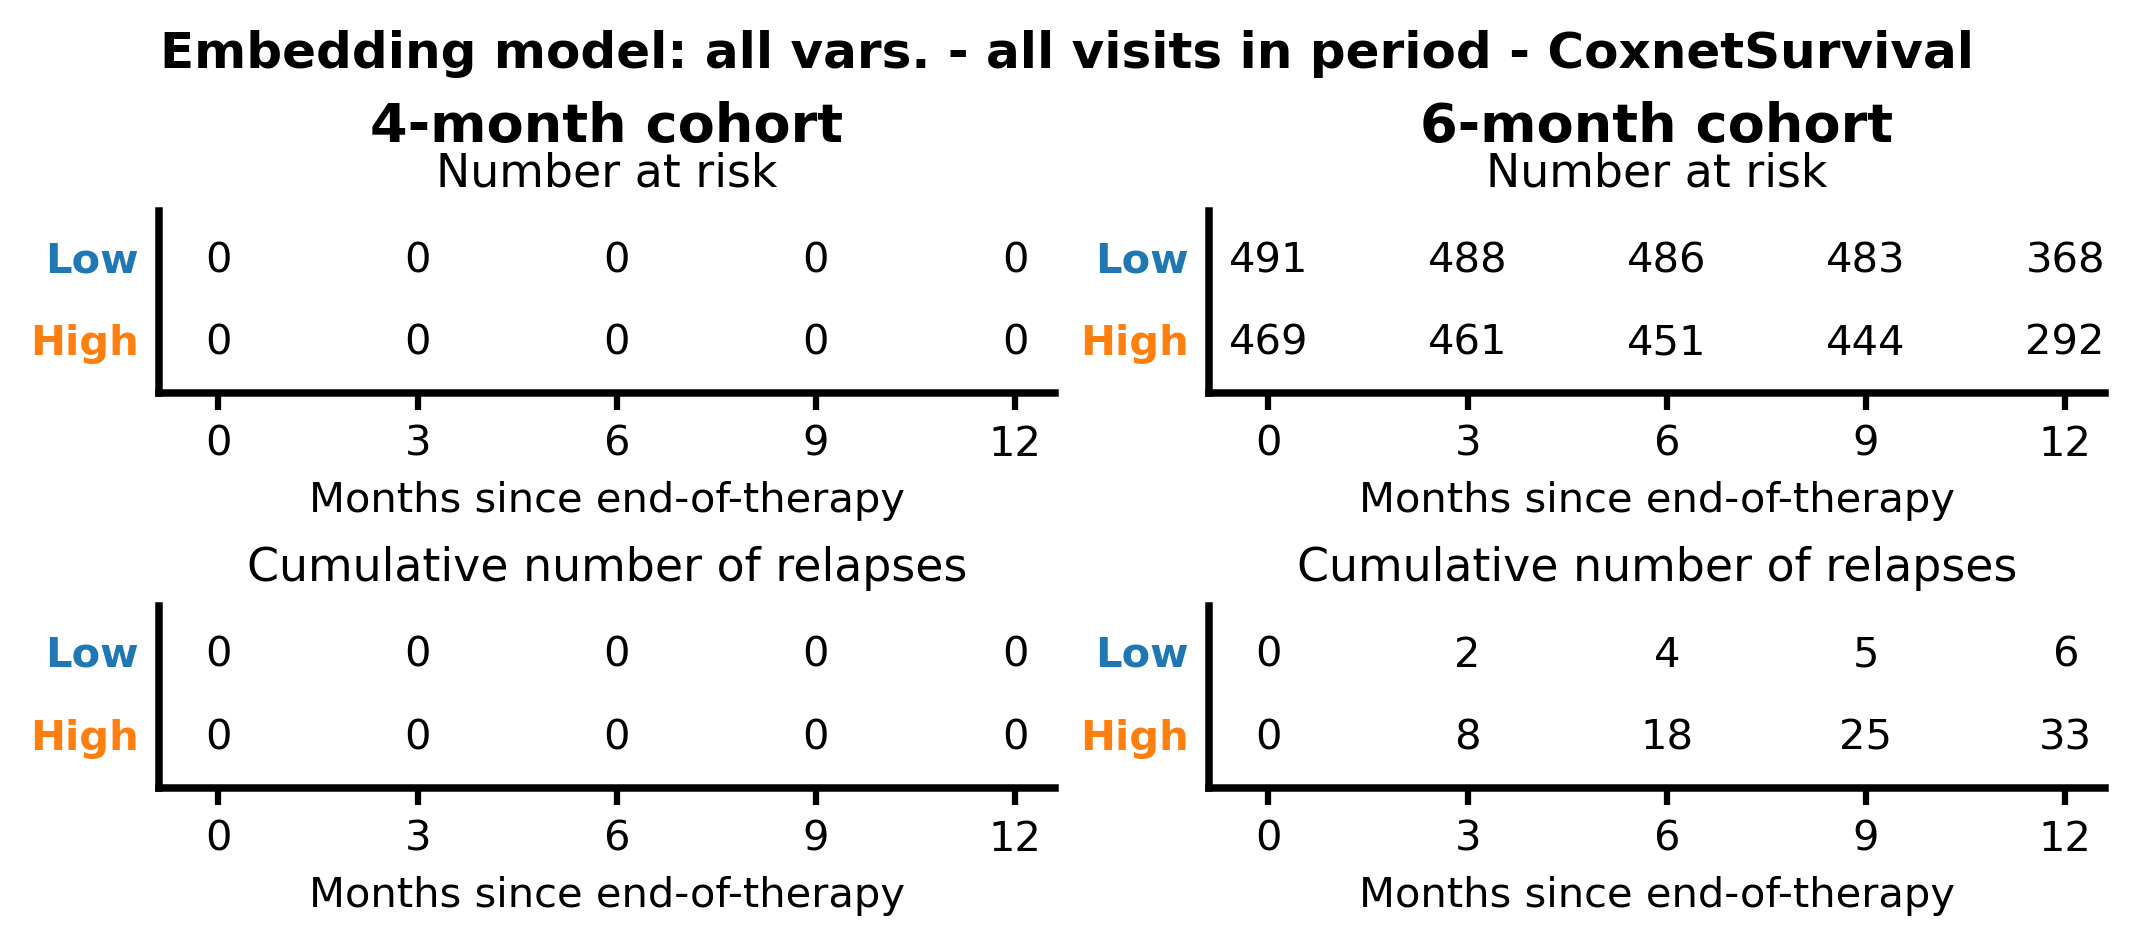

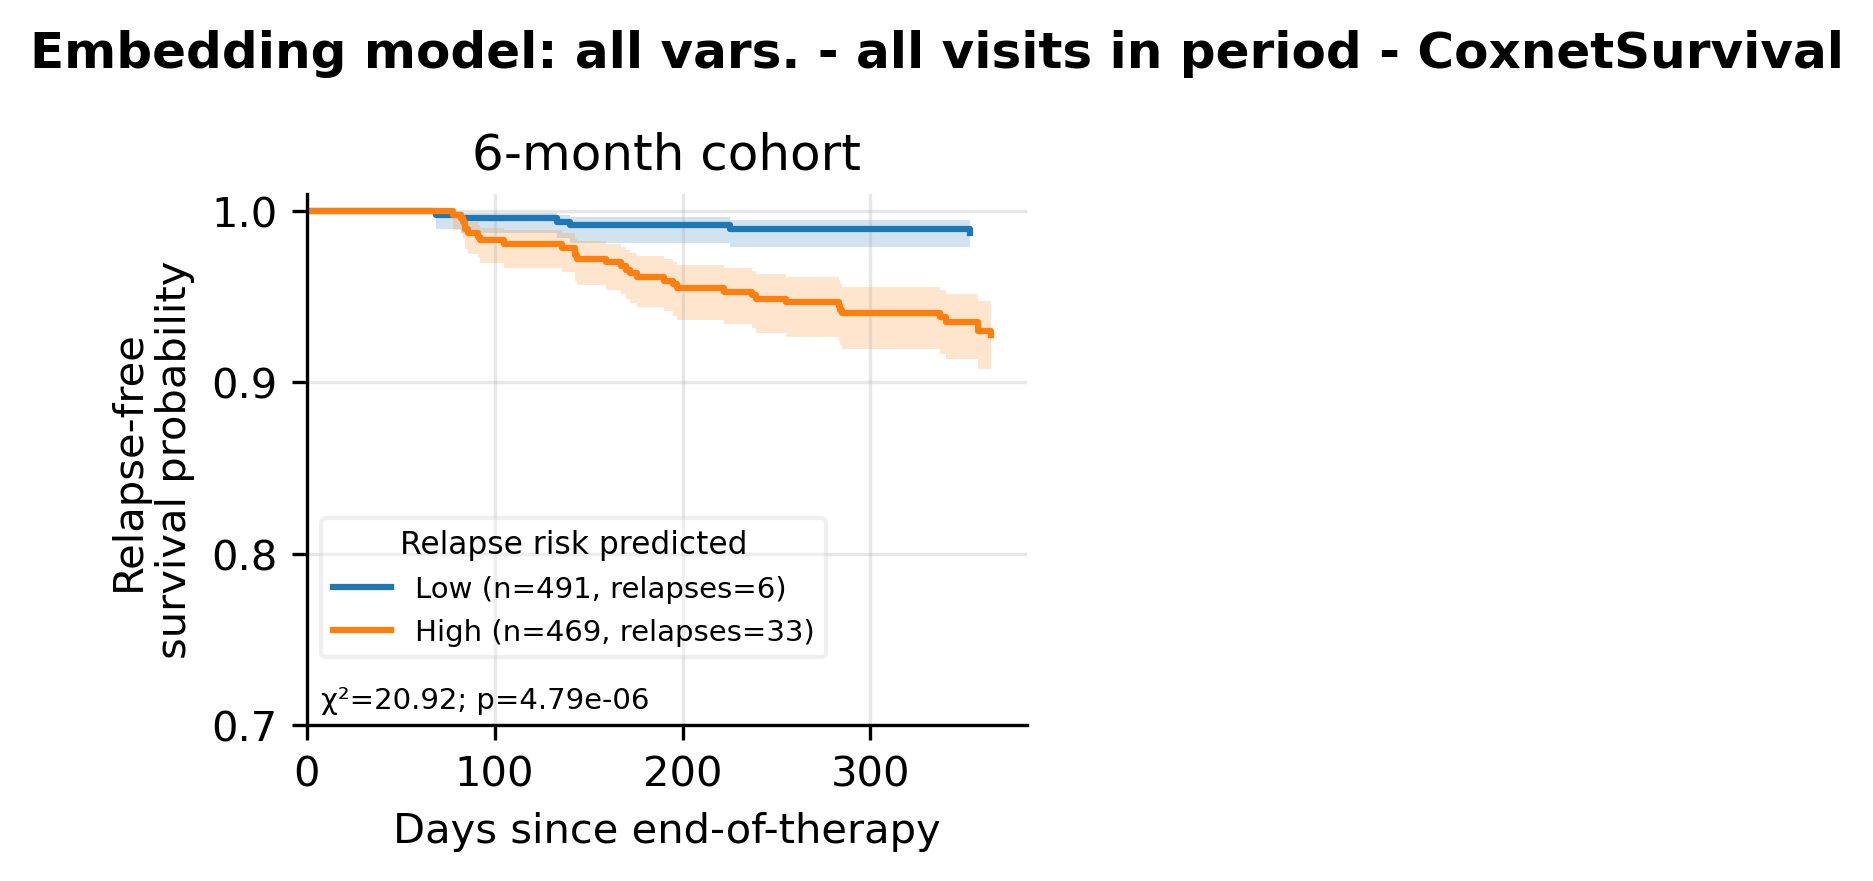

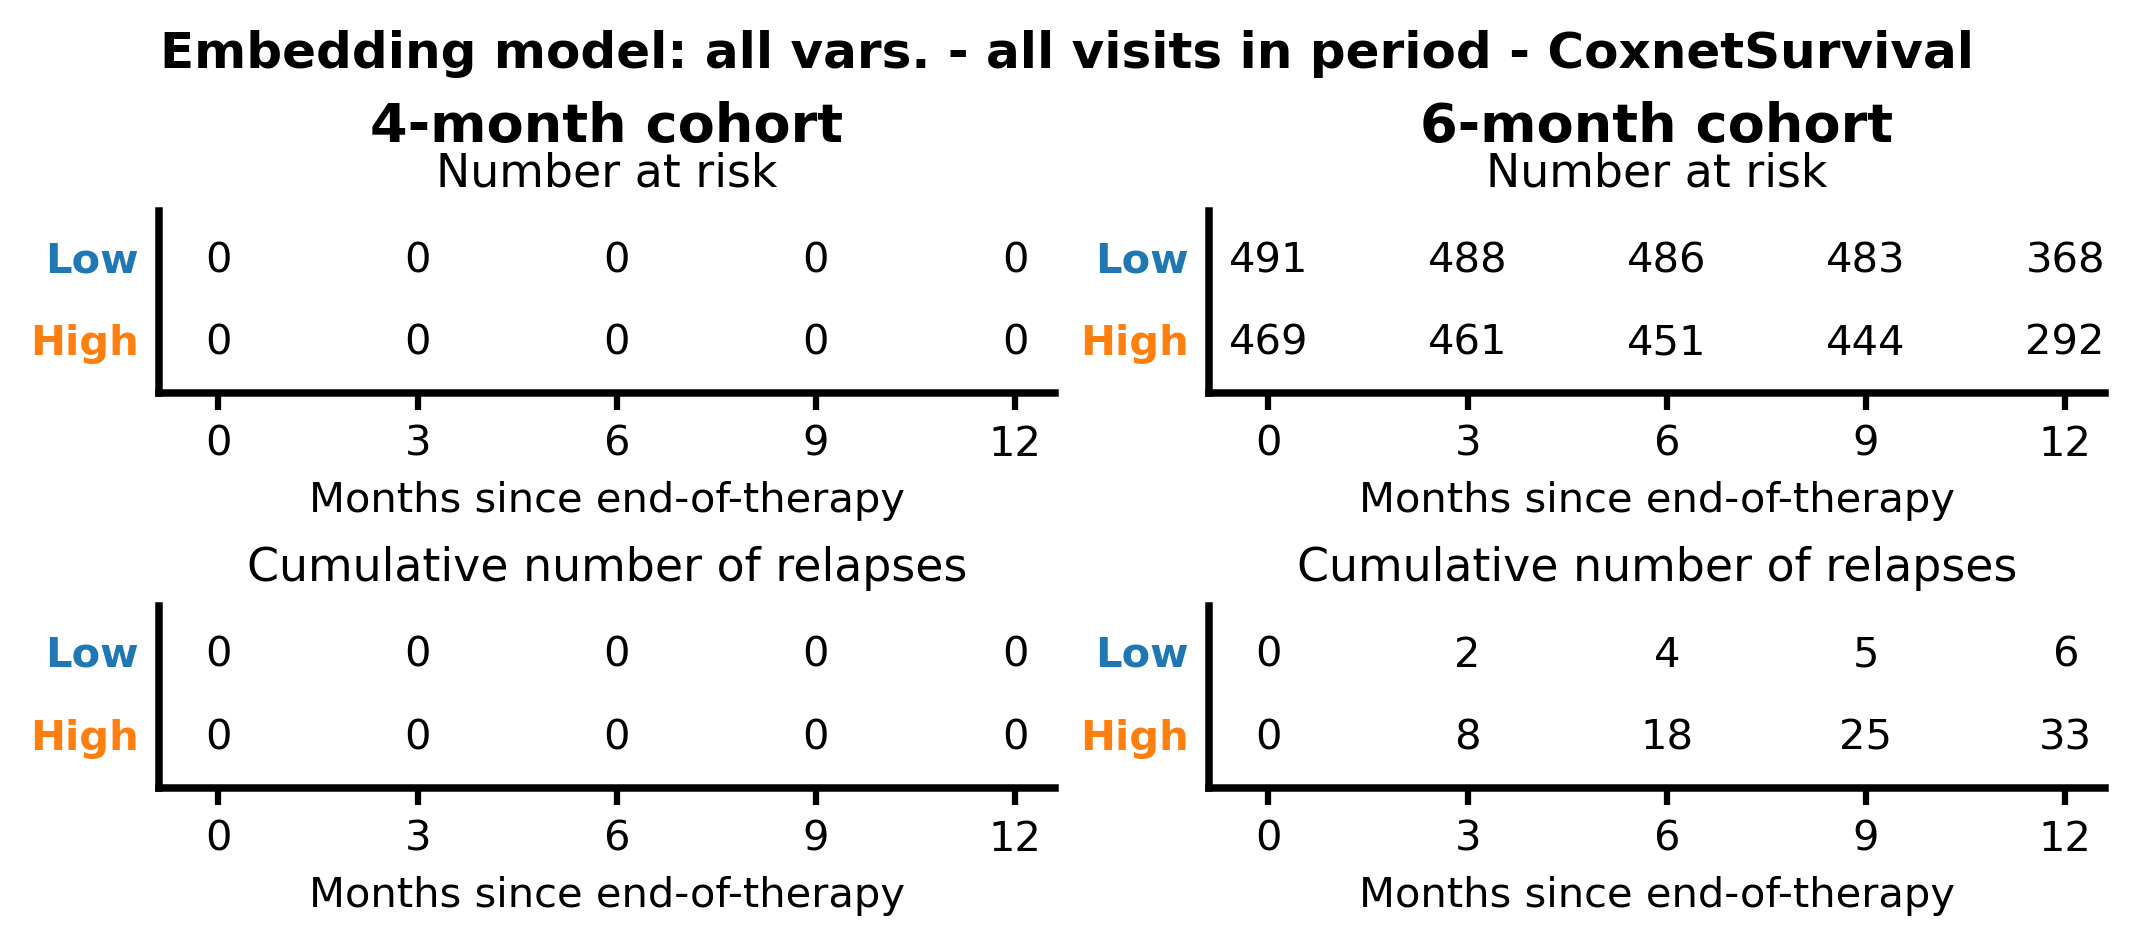

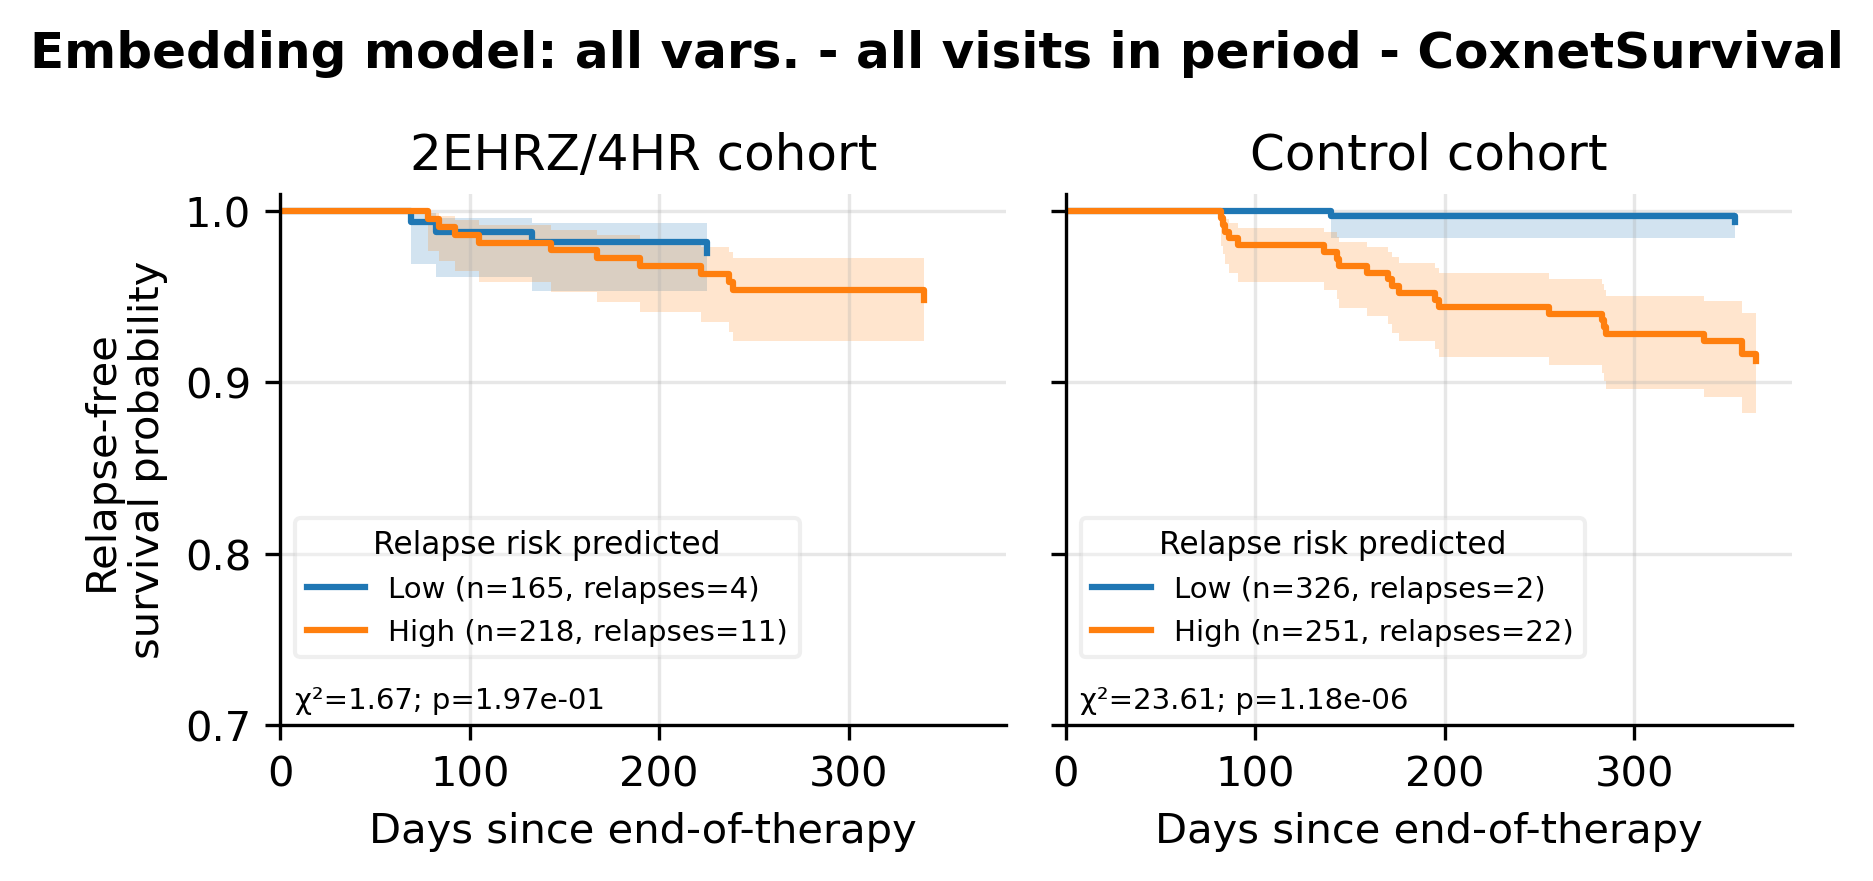

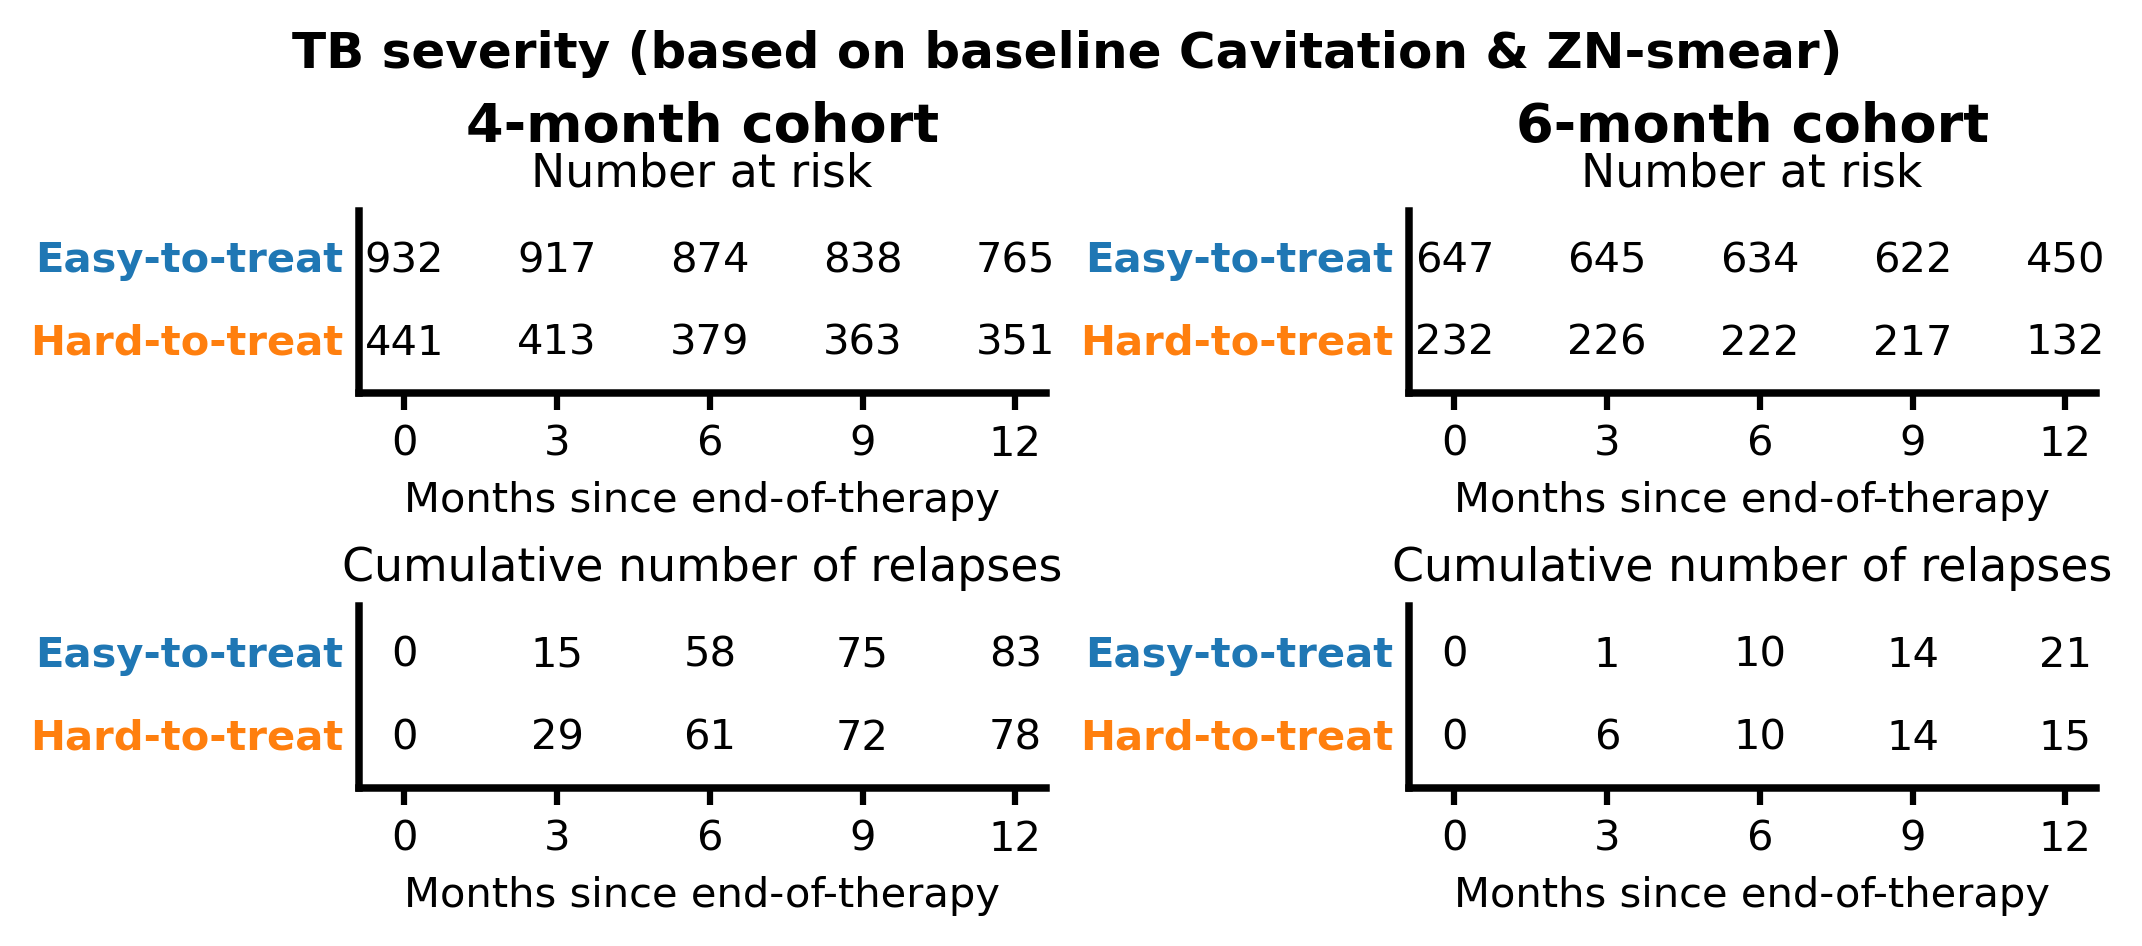

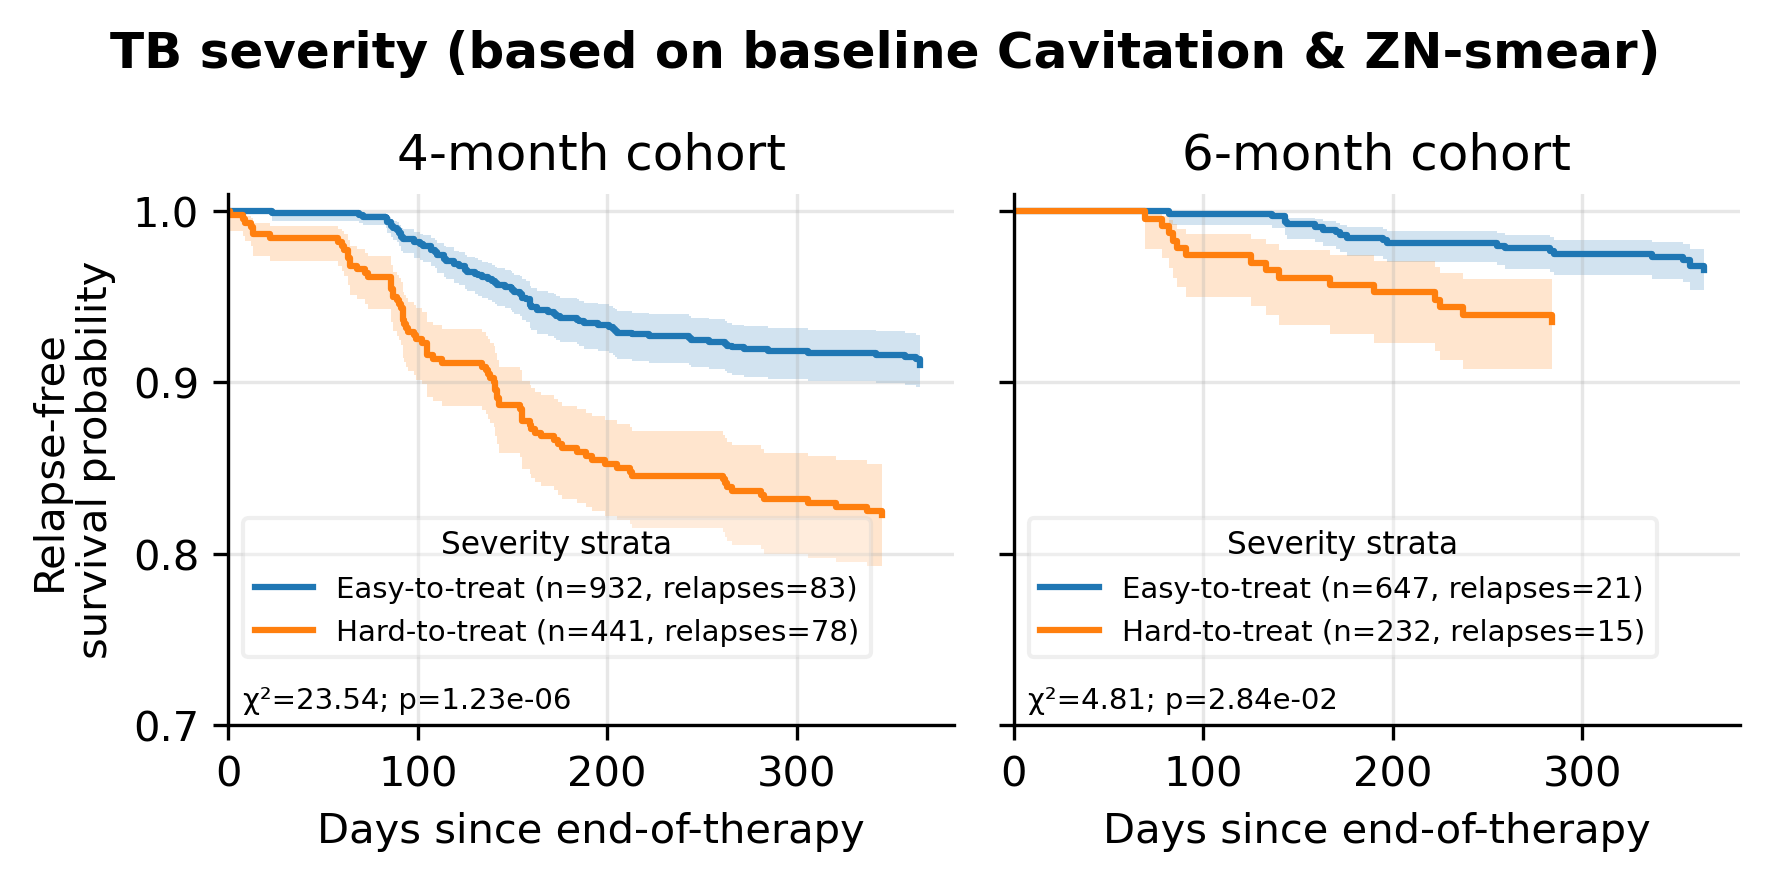

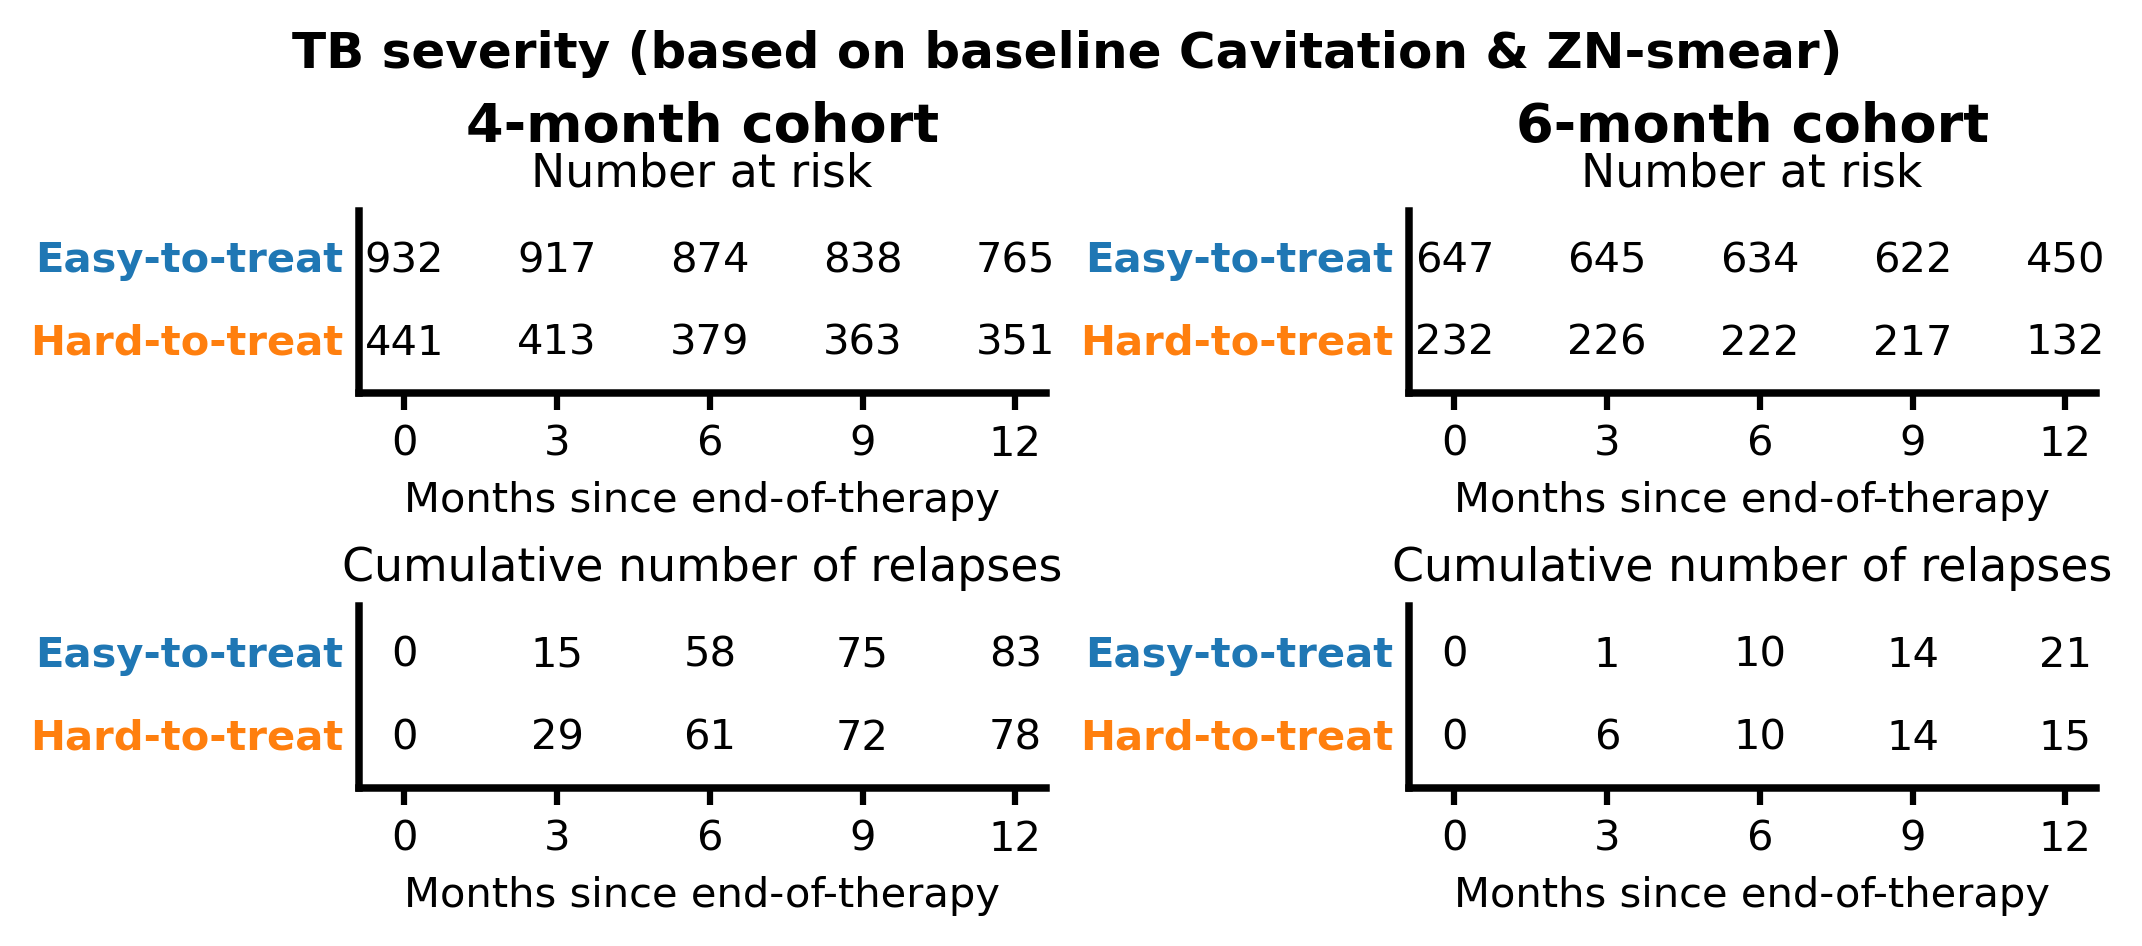

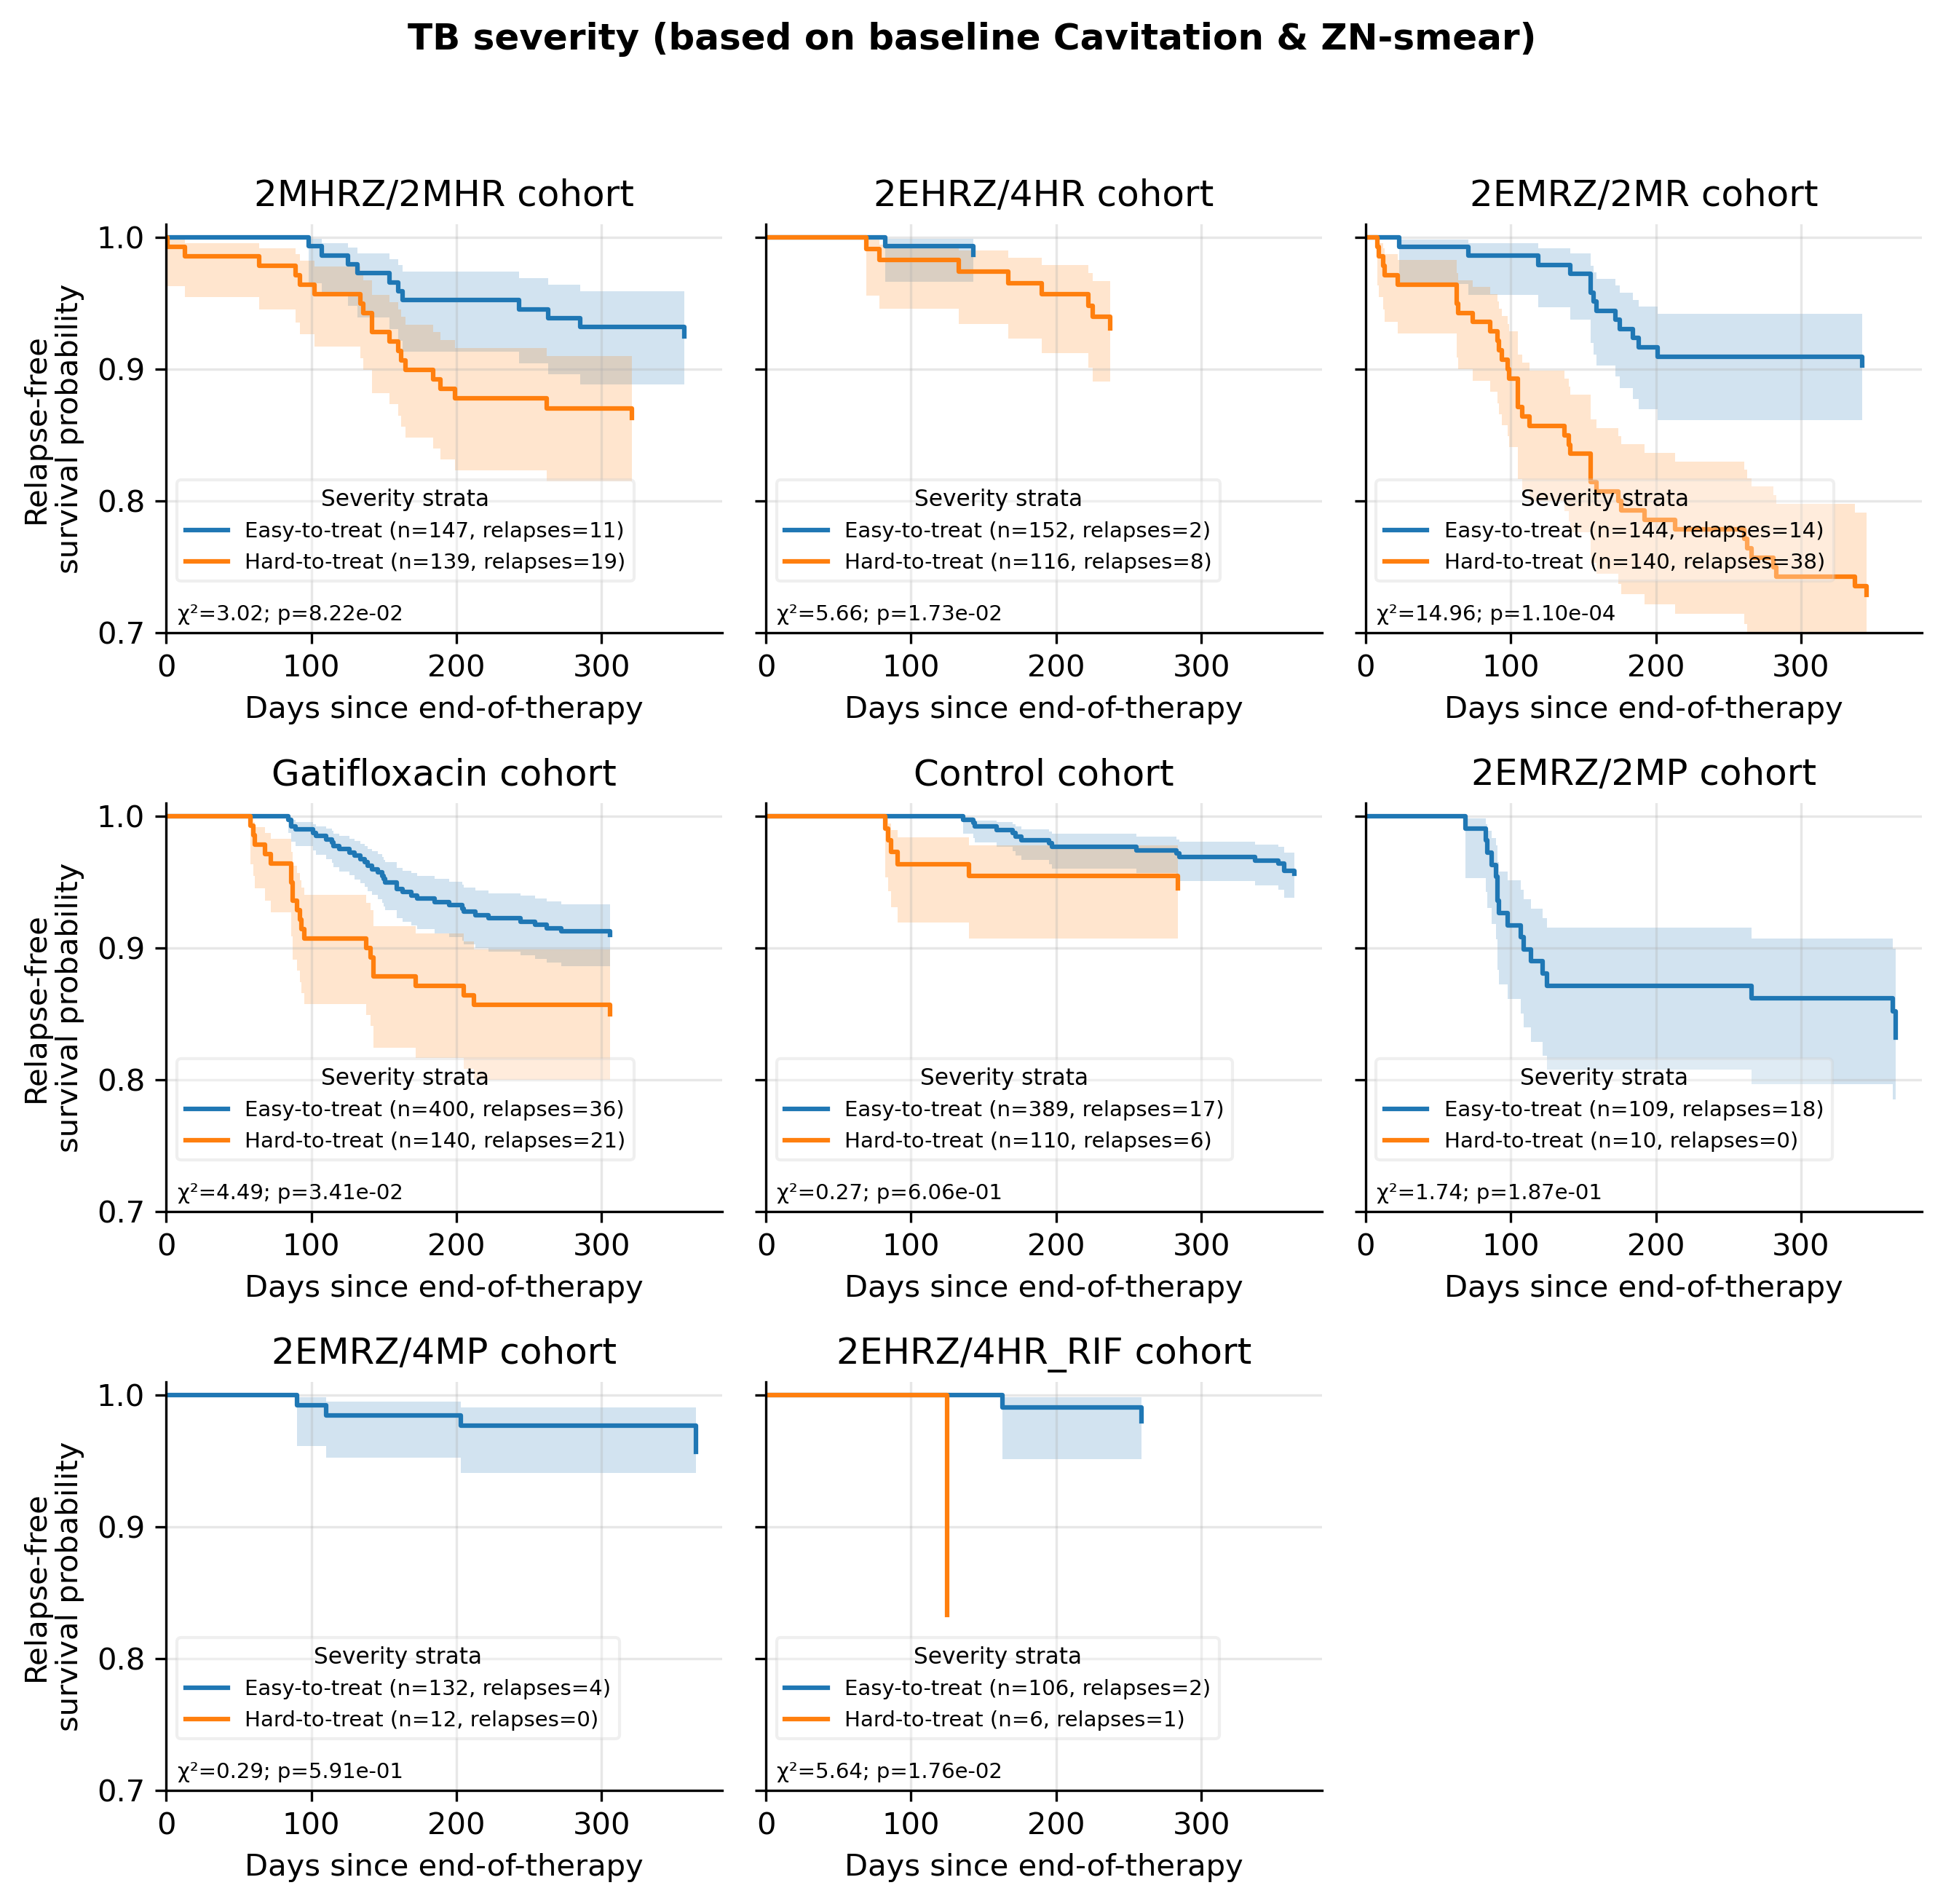

In [65]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy



from itertools import combinations
from sksurv.compare import compare_survival
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2

from sksurv.nonparametric import kaplan_meier_estimator
import warnings
warnings.filterwarnings('ignore')







figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

#pats_with_relapse_df=extract_21_22_relapse_pats()



suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


raw_data_training_data_types=['all_days_in_period','last_therapy_day']
llm_training_data_types=['full','pca']

model_names_for_plotting=['XGBoost','CoxnetSurvival'][1:]

parameters_for_analysis_raw=  [*parameters_for_analysis][1:2]# + [*parameters_for_analysis][5:6]
parameters_for_analysis_llm= [*parameters_for_analysis][1:2]

## Adding across_time ==> which averages the pred. probs per patinet across the first 4 monthsa
period_end_days_=period_end_days[:-1]# +['across_time']
raw_data_training_data_types_ = raw_data_training_data_types[1:]

model_names_ = model_names_for_plotting[:]
llm_data_inclusion_types_=['baseline_last_day','baseline_vars','all_days'][2:]
llm_training_data_types_ = ['full','pca'][:1]
llm_pool_methods_=['mean_pooling','attention_pooling'][:1]

lstm_model_complexities=['day_only','regimen_only','wo_regimen','full'][-1:]

include_rifaquin=True
cav_zn = return_treatment_strata(include_rifaquin=include_rifaquin)

'''
#lstm_pred_probs = load_lstm_pred_probs(lstm_model_complexities,raw_data_param_key)
raw_pred_probs,raw_test_df = load_raw_pred_probs(parameters_for_analysis_raw,
                                                 parameters_for_analysis,
                                                model_names_)

llm_pred_probs = load_llm_pred_probs(parameters_for_analysis_llm,
                        llm_data_inclusion_types_,
                        llm_pool_methods_,
                        period_end_days_,
                        model_names_
                       )
'''                    

#data_params_to_loop = parameters_for_analysis_raw# + parameters_for_analysis_llm

#low_thr=0.3 #0.25
low_thr=None #0.25
#abs_val = None #0.3
abs_val = calc_mode_kde #0.3
#abs_val = None
#thr_func=np.mean

#abs_val = calc_quant_threshold#(quant_threshold=0.3)

all_pairwise_tests, all_figures = [], []
period_end_days__ = period_end_days_[:] +['across_time']

## APPROACHES: 
#. - the pre-loaded raw, llm and lstm models test prob outputs concatenated
#  - severity: easy-to-treat/ hard-to-treat patients based on Impeorial et al's stritification



for time_origin, max_day in zip(['SOT','EOT'][1:],
                                [730,365][1:]):

    for approach in ['raw','llm','severity','lstm'][1:3]:
    
        if 'raw' in approach or 'treatment' in approach:
            pred_prob_df = raw_pred_probs[(raw_pred_probs['data_type']=='test')#&\
                                           #(raw_pred_probs['period']== period_end_day)
                                            ].copy()
            pred_prob_df_train = raw_pred_probs[(raw_pred_probs['data_type']=='train')#&\
                                           #(raw_pred_probs['period']== period_end_day)
                                            ].copy()
            groupby_colns=['training_data_type','model_name']
            
            data_params_to_loop = pred_prob_df['data_param_key'].unique()
            strat_coln='Pred. prob. strata'
            period_to_loop = period_end_days__[2:3]
    
        
        if 'llm' in approach:
            pred_prob_df = llm_pred_probs[(llm_pred_probs['data_type']=='test')#&\
                                           #(llm_pred_probs['period']== period_end_day)
                                            ].copy()
            pred_prob_df_train = llm_pred_probs[(llm_pred_probs['data_type']=='train')#&\
                                           #(raw_pred_probs['period']== period_end_day)
                                            ].copy()
            groupby_colns=['llm_data_inclusion_type','model_name']

            data_params_to_loop = pred_prob_df['data_param_key'].unique()
            strat_coln='Pred. prob. strata'
            period_to_loop = period_end_days__[5:6]
    
        if 'lstm' in approach:
            pred_prob_df = lstm_pred_probs[(lstm_pred_probs['data_type']=='test')#&\
                                            #(lstm_pred_probs['period']==period_end_day)
                                            ].copy()
            pred_prob_df_train = lstm_pred_probs[(lstm_pred_probs['data_type']=='train')#&\
                                            #(lstm_pred_probs['period']==period_end_day)
                                            ].copy()
            
            groupby_colns=['model_complex','model_name']
    
    
        ## Extract prediction setups loaded into dataframe
        ## ==> IF stratified by severity (easy or hard-to-treat), just run the data_params once, as anyway the severity strata will be used for plotting
        if 'severity' in approach:
            pred_prob_df = llm_pred_probs[(llm_pred_probs['data_type']=='test')#&\
                                           #(raw_pred_probs['period']== period_end_day)
                                            ].copy()
            data_params_to_loop = pred_prob_df['data_param_key'].unique().tolist()[:1]
            strat_coln='Severity strata'
            #pred_prob_df[strat_coln] =  cav_zn.loc[pred_prob_df['USUBJID'].tolist(),strat_coln].values
            period_to_loop = period_end_days__[:1]
            
            
    
        for data_param_key_ in data_params_to_loop:
            print(data_param_key_)
        
            outcome_label = parameters_for_analysis[data_param_key_]['result_cat']
    
    
        
            if outcome_label=='RELAPSE':
                id2label={0: "NO RELAPSE", 1: "RELAPSE"}
                label2id={"NO RELAPSE": 0, "RELAPSE": 1}
            else:
                id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
                label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
    
    
            
            ## SETTING TIME 
            for period_end_day in period_to_loop:


                
                print('period_end_day',period_end_day)
    
                if 'across_time' not in str(period_end_day):
                    pred_prob_df_period = pred_prob_df[(pred_prob_df['period']== period_end_day)&\
                                                        (pred_prob_df['data_param_key']==data_param_key_)]
                    pred_prob_df_period_train = pred_prob_df_train[(pred_prob_df_train['period']== period_end_day)&\
                                                        (pred_prob_df_train['data_param_key']==data_param_key_)]
                if 'across_time' in str(period_end_day):
                    pred_prob_df_period = pred_prob_df[(pred_prob_df['period'].isin(period_end_days__[:-1]))&\
                                                        (pred_prob_df['data_param_key']==data_param_key_)]
                    pred_prob_df_period_train = pred_prob_df_train[(pred_prob_df_train['period'].isin(period_end_days__[:-1]))&\
                                                        (pred_prob_df_train['data_param_key']==data_param_key_)]

                
    
    
                ## LOOP THGROUGH THE DIFFERENT EXPERISMENTAL SETUPS DEFINED BY THE groupby_colns 
                #.  ==> (i.e.: last-visit or all visit setup for raw models/ LLm models: last-visit, all-visit - common vars., all visit-all vars
                ##  ==> EACH OF THEM CREATES SEPARATE PLOTS
                #for (gr_level1,model_name_),pred_prob_df_group in pred_prob_df_period.groupby(groupby_colns):
                for ((gr_level1, model_name_), pred_prob_df_group_test), ((_, _), pred_prob_df_group_train) in zip(pred_prob_df_period.groupby(groupby_colns),
                                                                                                               pred_prob_df_period_train.groupby(groupby_colns)):
                                                                                                               
    

                    pred_loss_dict={}
                    
                    for data_type, pred_prob_df__ in zip(['train','test'],[pred_prob_df_group_train,pred_prob_df_group_test]):
                        
                        ## As one patient can appear mutliple times in the 25 test-sets, average their pred probs. to derive one preed. prob per patient for each time period
                        mean_pred_loss_ = pred_prob_df__.groupby(['period','USUBJID']).apply(lambda x:x['pred_risk'].mean()).to_frame()
                        
                        mean_pred_loss_ = mean_pred_loss_.groupby('USUBJID').apply(lambda x:x[0].mean()).to_frame()
                        mean_pred_loss_.columns=['pred_risk']
        
                        ## Add Arms & Study & therapy arm duration columns
                        mean_pred_loss_['Arm']= pred_prob_df__.drop_duplicates('USUBJID').set_index('USUBJID')[['ARM']].loc[mean_pred_loss_.index,'ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                                                                                                                        'Control-arm regimen (6 month regimen)':'Control'},regex=False) 
                        mean_pred_loss_['Study'] = (mean_pred_loss_.reset_index()['USUBJID'].str.split('/',expand=True)[0]).values
                        mean_pred_loss_['Study']=mean_pred_loss_['Study'].replace({'TB-1022':'OFLOTUB',
                                                                           'TB-1021':'REMoxTB'},regex=True)
                        mean_pred_loss_['therapy_arm_duration'] = '4-month'
                        mean_pred_loss_.loc[mean_pred_loss_['Arm'].isin(['2EHRZ/4HR','Control']),'therapy_arm_duration'] = '6-month'
        
                        ## Add Relapse information
                        mean_pred_loss_[['RELAPSE_DAY','RELAPSE']] = pats_with_relapse_df.loc[mean_pred_loss_.reset_index()['USUBJID'].tolist(),['RELAPSE_DAY','RELAPSE']].values
                   
    
                        
                        df = add_relapse_or_censoring_days(df=mean_pred_loss_,
                                                  pats_with_relapse_df=pats_with_relapse_df,
                                                  #time_origin='SAT',
                                                  max_day=max_day,
                                                 )
                        pred_loss_dict[data_type] = df
                        
    
                    
                    ### ADD PREDICTION GROUPS 
                    #.  ==> IF BASELINE TIMEPOINTS, JUST TAKE LOWER X AND UPPER X % AS LOW/HIGH STRATA
                    # . ==> IF TIMEPOINTS LATER THAN BASELINE: DRUG REGIMEN DATA WAS ADDED, AND MODELS LEARNS ABOUT ARM ASSIGMENTS
                    #.      CALCULATE PREID. PROB. STRATA WITHIN ARMS or therapy_arm_duration
                    #  ==> pre_prob_groupby_coln==None  => use global distribution of pred probs to calcaulate thresholds
                    
                    for pre_prob_groupby_coln_ in [None,'Arm','therapy_arm_duration'][1:2]:

                        
                        if 'severity' in approach:# or period_end_day=='baseline' or 'basic' in data_param_key_:
                            pre_prob_groupby_coln=None
                            
                            df_ = pred_loss_dict['test'].copy()#df.copy()
    
                            
                            if include_rifaquin==True:
                                df_rifaquin = add_censoring_data_to_rifaquin(time_origin,
                                                                      max_day)
                                df_ = pd.concat([df_,df_rifaquin],axis=0)
    
                            
                            df_[strat_coln] =  cav_zn.loc[df_['USUBJID'].tolist(),strat_coln].values
                            df_[strat_coln] = df_[strat_coln].replace('Intermediate-to-treat','Interm.-to-treat')
        
                        #if period_end_day!='baseline':
                        else:
                            pre_prob_groupby_coln=copy.copy(pre_prob_groupby_coln_)
                            #pre_prob_groupby_coln = ['therapy_arm_duration']
                            #pre_prob_groupby_coln = None
    
    
    
                            df_ = return_pred_prob_strata_from_train(
                                                        test_df=pred_loss_dict['test'].copy(),
                                                        train_df=pred_loss_dict['train'].copy(),
                                                        groupby_coln=pre_prob_groupby_coln,
                                                        low_thr=low_thr,
                                                        abs_val=abs_val,
                                                        #bs_val=None,
                                                        verbose=True)
                            '''
                            df_ = return_pred_prob_strata_within(df=df,
                                                        groupby_coln=pre_prob_groupby_coln,
                                                        #low_thr=low_thr,
                                                         abs_val=abs_val,
                                                         )
                            '''                                                     
                        
        
                        ## CHOOSE WHICH STRATA WILL BE COMPARED
                        #. ==> ALL 3, OR JUST THE LOW/HIGH
                        if 'severity' not in approach:
                            categories = ['Low','Interm.','High']
                        
                        if 'severity'  in approach:
                            categories=['Easy-to-treat','Interm.-to-treat', 'Hard-to-treat']
                            #categories=['4-month','6-month']
                        
                        df_[strat_coln] = pd.Categorical(df_[strat_coln],
                                                            categories=categories,
                                                            ordered=True)
        
        
        
                        df_ = replace_arm_names(df_)
        
                        facet_stat_pairs_dict={'ther_arm_dur_facet':['therapy_arm_duration',
                                                                 strat_coln,],
                                                'arm_facet':['Arm',
                                                           strat_coln],
                                              'strat_coln_facet':[strat_coln,
                                                                  'therapy_arm_duration'],
                                     
                                             }
                                              
                        for facet_strat_pair in [*facet_stat_pairs_dict][:2]:
                            
                            facet_coln_, strat_coln_ = facet_stat_pairs_dict[facet_strat_pair][0],facet_stat_pairs_dict[facet_strat_pair][1]
        
                        
        
                            ## Keep only the extremes of the categories
                            strat_cats = df_[strat_coln_].cat.categories
                            #strat_cats = df_[strat_coln_].unique()
                            #pred_cats = np.sort(df_facet_[strat_coln].dropna().unique())
                            #pred_cats_ = copy.copy(pred_cats)
                            strat_cats_ = [strat_cats[0]] + [strat_cats[-1]]
                            #strat_cats_ = strat_cats
        
                            facet_strat_levels =  strat_cats_ #df_[strat_coln_].astype(str).unique().tolist() #df_[facet_coln_].astype(str).unique().tolist() +
                            cmap_=plt.get_cmap('tab10',10)
                            color_dict_ = {lev:cmap_(i) for  i,lev in enumerate(facet_strat_levels)}
                            
                        
                            #facet_coln='Study'
                            #facet_coln='therapy_arm_duration'
                            #facet_coln='Arm'
                            num_of_plots=df_[facet_coln_].unique().shape[0]
                            ncols=3 if num_of_plots>3 else 2
                            nrows=int(np.ceil(num_of_plots/ncols))  
                            #cmap_name='tab10'
            
    
    
                            time_origin_dict={'SOT':'start-of-therapy',
                                              'EOT':'end-of-therapy',}
    
    
                            fig_table, _ = plot_risk_and_event_tables(
                                df=df_,
                                #timepoints_months=(0, 3, 6, 9, 12),
                                timepoints_days=(0, 93, 182, 275, 365),
                                therapy_col="therapy_arm_duration",
                                strata_col=strat_coln,
                                time_col=f"RELAPSE_DAY_{time_origin}",
                                event_col=f"RELAPSE_{time_origin}",
                                arm_order=["4-month cohort", "6-month cohort"],
                                strata_order=strat_cats_,
                                row_colors=color_dict_,
                                x_label=f"Months since {time_origin_dict[time_origin]}"
                            )
    
                
                            fig = plt.figure(figsize=(ncols*3,nrows*2.7))
                            #fig,axes = plt.subplots(nrows=nrows,ncols=ncols, figsize=(ncols*4,nrows*2),sharey=True)
                                            
                            all_figures.append({
                                                "fig": fig,
                                                "fig_table": fig_table,
                                                "meta": {
                                                    "approach": approach,
                                                    "data_param_key": data_param_key_,
                                                    "period_end_day": period_end_day,
                                                    "gr_level1": gr_level1,
                                                    "model_name": model_name_,
                                                    'time_origin':time_origin,
                                                    'max_day':max_day,
                                                    'pre_prob_groupby_coln_':pre_prob_groupby_coln_,
                                                        }
                                                    })   #ax=axes.flatten()[n]
                                                                
                                                
                
                            #plt.close(fig_table)
            
                           
                            
                            for n,facet_level in enumerate(df_[facet_coln_].unique()):
                                ax=fig.add_subplot(nrows,ncols,n+1)
            
                                df_facet=df_[df_[facet_coln_]==facet_level]
                
                                         
                                df_facet_ = df_facet[#(~df_facet['prediction_strata'].isin(['Intermediate-to-treat','intermediate_to_predict']))&\
                                           (~df_facet[strat_coln_].isna())]
    
    
                                print('\n',df_facet_.groupby([strat_coln_,f'RELAPSE_{time_origin}']).apply(lambda x:x['Arm'].value_counts(dropna=False)),'\n')
    
                                 # --- Compute IPW weights for this facet ---
                                # Weights are study-level: 1/P(ARM=observed | STUDY)
                                df_facet_ = df_facet_.copy().reset_index(drop=True)
                                ipw       = np.zeros(len(df_facet_))
                                
                                study_col = 'Study'                 
                                arm_col = 'therapy_arm_duration'   
                                control_label = '6-month'               
                                
                            
                                for study, grp in df_facet_.groupby(study_col):
                                    idx        = df_facet_.index.get_indexer(grp.index)
                                    p_ctrl     = (grp[arm_col] == control_label).mean()
                                    p_exp      = 1 - p_ctrl
                                    if p_ctrl == 0 or p_exp == 0:
                                        ipw[idx] = 1.0
                                    else:
                                        ipw[idx] = np.where(
                                            (grp[arm_col] == control_label).values,
                                            1.0 / p_ctrl,
                                            1.0 / p_exp
                                        )
                                df_facet_['_ipw'] = ipw
            
            
                                # Pairwise log-rank tests within this facet
                                pairs = list(combinations(list(strat_cats_), 2))
                                
                                # If you have <2 groups present in this facet, skip
                                if len(pairs) > 0:
                                    # Create placeholder text objects now, update later after global FDR
                                    # Stack them in the lower-left corner
                                    y0 = 0.02
                                    dy = 0.055
                                
                                    for i, (g1, g2) in enumerate(pairs):
                                        mask = df_facet_[strat_coln_].isin([g1, g2])
                                
                                        groups_pair = df_facet_.loc[mask, strat_coln_].astype(str).values
                                        event_pair = df_facet_.loc[mask, f'RELAPSE_{time_origin}'].astype(bool).values
                                        time_pair = df_facet_.loc[mask, f'RELAPSE_DAY_{time_origin}'].astype(float).values
                                        weights_pair = df_facet_.loc[mask, '_ipw'].values
                                        event_numbers = (df_facet_.loc[mask,:]
                                                         .groupby(strat_coln_)
                                                         .apply(lambda x: x[f'RELAPSE_{time_origin}'].value_counts()))
        
                                        #n = len(df_facet_[f'RELAPSE_{time_origin}'][mask])
                                        #n_events = int(df_facet_[f'RELAPSE_{time_origin}'][mask].sum())
                                
                                        # Need at least 1 event and at least 2 groups represented
                                        if (event_pair.sum() == 0) or (np.unique(groups_pair).size < 2):
                                            p_raw = np.nan
                                            chisq = np.nan
                                        else:
                                            #y = _sksurv_y(event_pair, time_pair)
                                            #chisq, p_raw = compare_survival(y, groups_pair)
    
                                            # IPW-weighted log-rank instead of standard compare_survival
                                            chisq, p_raw = ipw_weighted_logrank(
                                                time_pair, event_pair, groups_pair, weights_pair
                                            )
    
                                
                                        # placeholder text on the axis (we will overwrite after FDR)
                                        t = ax.text(
                                            0.02, y0 + i * dy,
                                            f"{g1} vs {g2}: p=...",
                                            transform=ax.transAxes,
                                            fontsize=7,
                                            va="bottom"
                                        )
                                
                                        all_pairwise_tests.append({
                                            "chisq": chisq,
                                            "p_raw": p_raw,
                                            "ax": ax,
                                            "text_artist": t,
                                            "facet_level": facet_level,
                                            'strat_coln_':strat_coln_,
                                            'time_origin':time_origin,
                                            #"facet_level": facet_level_,
                                            "pair": (str(g1), str(g2)),
                                            'event_numbers': event_numbers,
                                            "meta": {
                                                "approach": approach,
                                                "data_param_key": data_param_key_,
                                                "period_end_day": period_end_day,
                                                "gr_level1": gr_level1,
                                                'pre_prob_groupby_coln_':pre_prob_groupby_coln_,
                                                "model_name": model_name_,
                                            }
                                        })
            
            
                
                                # --- IPW-weighted KM curves ---
                                for g in strat_cats_:
                                    #print(g)
                                    mask = df_facet_[strat_coln_] == g
                                    '''
                                    time, survival_prob, conf_int = kaplan_meier_estimator(
                                        df_facet_[f'RELAPSE_{time_origin}'][mask].astype(bool),
                                        df_facet_[f'RELAPSE_DAY_{time_origin}'][mask],
                                        conf_type="log-log"
                                    )
                                    '''
                                    times_g   = df_facet_.loc[mask, f'RELAPSE_DAY_{time_origin}'].astype(float).values
                                    events_g  = df_facet_.loc[mask, f'RELAPSE_{time_origin}'].astype(bool).values
                                    weights_g = df_facet_.loc[mask, '_ipw'].values
                            
                                    # Apply t_max truncation (e.g. 365 days post-EOT)
                                    time, survival, ci_low, ci_high = weighted_km_curve(
                                        times_g, events_g, weights_g, t_max=max_day
                                    )
        
                                    num_of_relapses = int(df_facet_[f'RELAPSE_{time_origin}'][mask].sum())
                                    num_of_pats = df_facet_[f'RELAPSE_{time_origin}'][mask].shape[0]
                                    
                                    #print(df_facet_[strat_coln].shape)
                                    ax.step(time, survival,#survival_prob, 
                                            where="post", 
                                            label=f'{g} (n={num_of_pats}, relapses={num_of_relapses})',
                                            #label=str(g),
                                            color=color_dict_[g])
                        
                                    
                                    ax.fill_between(time, 
                                                    ci_low, 
                                                    ci_high,
                                                    #conf_int[0],
                                                    #onf_int[1], 
                                                    alpha=0.2, step="post")
    
                                    meta= {"approach": approach,
                                            #"data_param_key": data_param_key_,
                                            "period_end_day": period_end_day,
                                           'pre_prob_groupby_coln_':pre_prob_groupby_coln_,
                                            #"gr_level1": gr_level1,
                                           'facet_level':facet_level,
                                            #"model_name": model_name_,
                                            }
                                    #print('\n',meta, g, survival[-1])
                            
                                #ax.set_xlabel("Time (days)")
                                xlabel_dict={'SOT':'start-of-therapy',
                                             'EOT':'end-of-therapy',}
                                ax.set_xlabel(f'Days since {xlabel_dict[time_origin]}')
                    
                                ## If subplot is not the first subplot in the row, disable y-ticks
                                if n%ncols!=0:
                                    ax.tick_params(axis='y', labelleft=False)
                    
                                ## If subplot is  the first subplot in the row, set y-ticks
                                if n%ncols==0:
                                    ax.set_ylabel(f"Relapse-free\nsurvival probability")
                                    #ax.tick_params(axis='y', labelsize=ytick_labelsize)
                        
                                ax.set_title(f'{facet_level} cohort')
                                ax.set_xlim(0,max_day*1.05)
                                ax.set_ylim(0.7,1.01)
                                ax.grid(alpha=0.3)
                                ax.spines[['top','right']].set_visible(False)
                                #ax.legend()
                                plt.tight_layout()
                                l,h = ax.get_legend_handles_labels()
        
                                
                                leg_title_dict = {'Pred. prob. strata':'Relapse risk predicted',
                                                  'Severity strata':'Severity strata',
                                                  'therapy_arm_duration':'Therapy duration',
                                                  'Arm':'Arm'}
                                
                                
            
                                #if 'pred.'strat_coln_
                                #if strat_coln_ == 'Pred. prob. strata':
                                leg_title = leg_title_dict[strat_coln_]
                                
                                ax.legend(title=leg_title,
                                       loc='lower left',
                                        title_fontsize=7.5,
                                        fontsize=7,
                                        markerscale=1,
                                        frameon=True,
                                        framealpha=0.3,
                                       bbox_to_anchor=(0,0.1))
                            
                            # Remove all unused axes
                            #for ax in axes[num_of_plots:]:
                                #fig.delaxes(ax)
                            #    ax.remove()
                                #ax.axis("off")
            
                            dd = {'baseline':'Baseline',
                                    31:'Month 1',
                                    62:'Month 2',
                                    93:'Month 3',
                                    125:'Month 4',
                                    160:'Month 5',
                                    'all':'Month 6',
                                  #'across_time':'Baseline-Month 4'
                                  'across_time':'',
                                  
                                   }
        
                                
        
                            
                            #plt.legend(title=leg_title,
                            #           loc='upper left',
                            #           bbox_to_anchor=(1.05,1))
            
                            suptitle = return_suptitle_KM_curve(gr_level1,
                                                                 model_name_,
                                                                approach,
                                                                data_param_key_)
            
                            #if 'severity' not in approach:
                            #    suptitle = f'{suptitle}\n Trained at {dd[period_end_day]}'
                            #plt.subplots_adjust(wspace=0.3)
                            
                            #suptitle = f'{data_param_key_} - {approach} - {dd[period_end_day]}'
                            fig.suptitle(suptitle,y=1.07,fontweight='bold')
                            fig_table.suptitle(suptitle,y=1.07,fontweight='bold')
                            #plt.show()
                            
        
    
    # Global FDR across all performed pairwise tests
    pvals = np.array([d["p_raw"] for d in all_pairwise_tests], dtype=float)
    valid = np.isfinite(pvals)
    
    pvals_fdr = np.full_like(pvals, np.nan, dtype=float)
    if valid.sum() > 0:
        _, pvals_fdr_valid, _, _ = multipletests(pvals[valid], method="fdr_bh")
        pvals_fdr[valid] = pvals_fdr_valid
    
    # Write corrected p-values into the already-created Text artists
    for d, p_corr,p_raw in zip(all_pairwise_tests, pvals_fdr,pvals):
        g1, g2 = d["pair"]
        chisq = d.get("chisq", np.nan)
        
        if np.isfinite(p_corr):
            if p_corr<0.05:
                #d["text_artist"].set_text(f"{g1} vs {g2}: q={p_corr:.3e}")
                #d["text_artist"].set_text(f"{g1} vs {g2}:\nFDR={p_corr:.3e}")
                #text_ = f"χ²={chisq:.2f}; FDR={p_corr:.2e}"
                text_ = f"χ²={chisq:.2f}; p={p_raw:.2e}"
              
                d["text_artist"].set_text(f"{text_}")
            else:
                text_ = f"χ²={chisq:.2f}; p={p_raw:.2e}"
                #d["text_artist"].set_text(f"")
                d["text_artist"].set_text(f"{text_}")
                
        else:
            #d["text_artist"].set_text(f"{g1} vs {g2}: q=NA")
            d["text_artist"].set_text(f"")
    
    
    ### SAVE PLOTS
    
    for fig_dict in all_figures:
        fig = fig_dict["fig"]
        meta = fig_dict["meta"]
        fig_table=  fig_dict["fig_table"]
        
        data_dir_=f"../data/plots/KM_curves/{meta['approach']}/{meta['data_param_key']}/survival_analysis"
    
        os.makedirs(data_dir_,exist_ok=True)
    

        if meta['pre_prob_groupby_coln_'] is not None:
            filename = (
                f"{meta['period_end_day']}_days_"
                f"{meta['gr_level1']}_"        
                f"{meta['model_name'].replace('LogisticRegression','LR')}_"
                f"{meta['time_origin']}_" 
                f"grouped_by_{meta['pre_prob_groupby_coln_']}_" 
                f"{meta['max_day']}.png" 
            )
        else:
            filename = (
                f"{meta['period_end_day']}_days_"
                f"{meta['gr_level1']}_"        
                f"{meta['model_name'].replace('LogisticRegression','LR')}_"
                f"{meta['time_origin']}_" 
                #f"grouped_by_{meta['pre_prob_groupby_coln_']}_" 
                f"{meta['max_day']}.png" 
            )
            
    
        filepath = os.path.join(data_dir_, filename)
        #fig.savefig(filepath, dpi=300, bbox_inches="tight")


        
        ## SAve table plots
        filename_ =f"table_{filename}" 
        filepath = os.path.join(data_dir_, filename_)
        #fig_table.savefig(filepath, dpi=300, bbox_inches="tight")

        


## Calculate interaction terms & perform non-inferiority test

---------------------------------------------------------------------------------------------------- 
 tb21_22_2984_pats_22_vars_relapse 

period_end_day across_time
                              Results: PHReg
Model:                     PH Reg                 Sample size:        2401
Dependent variable:        RELAPSE_DAY_SOT        Num. events:        242 
Ties:                      Efron                                          
--------------------------------------------------------------------------
                     log HR log HR SE   HR      t    P>|t|  [0.025  0.975]
--------------------------------------------------------------------------
ARM_duration_binary  1.1287    0.1801 3.0916  6.2672 0.0000 2.1721  4.4003
subgroup            -1.7263    0.5997 0.1779 -2.8786 0.0040 0.0549  0.5764
ARM_x_subgroup       1.1249    0.6267 3.0801  1.7950 0.0727 0.9018 10.5202
Confidence intervals are for the hazard ratios

Subgroup: Low
ARM_x_subgroup  HR: 3.080 (95% CI: 0.902–10.520)  p 

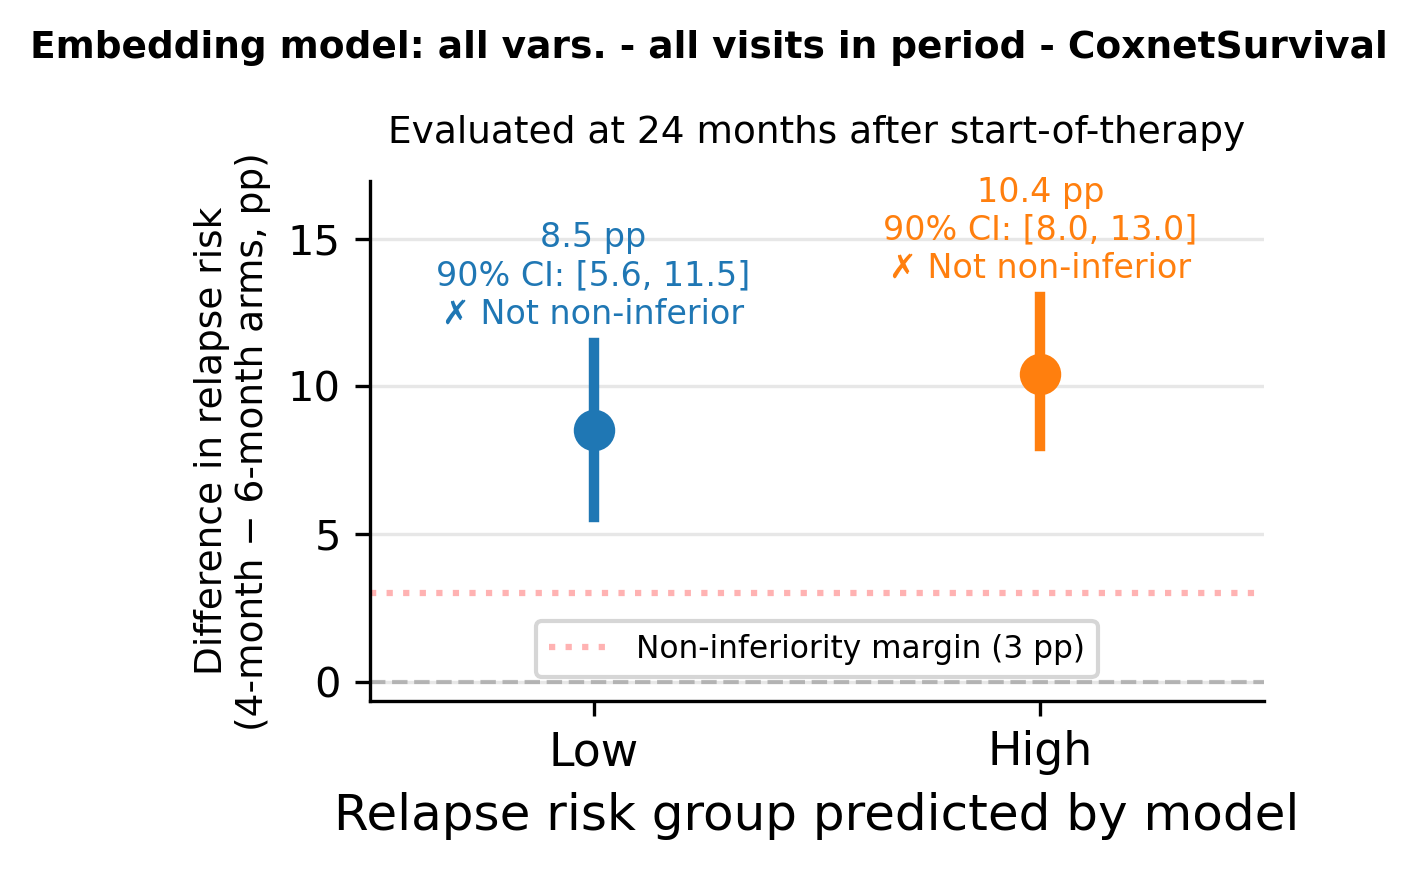

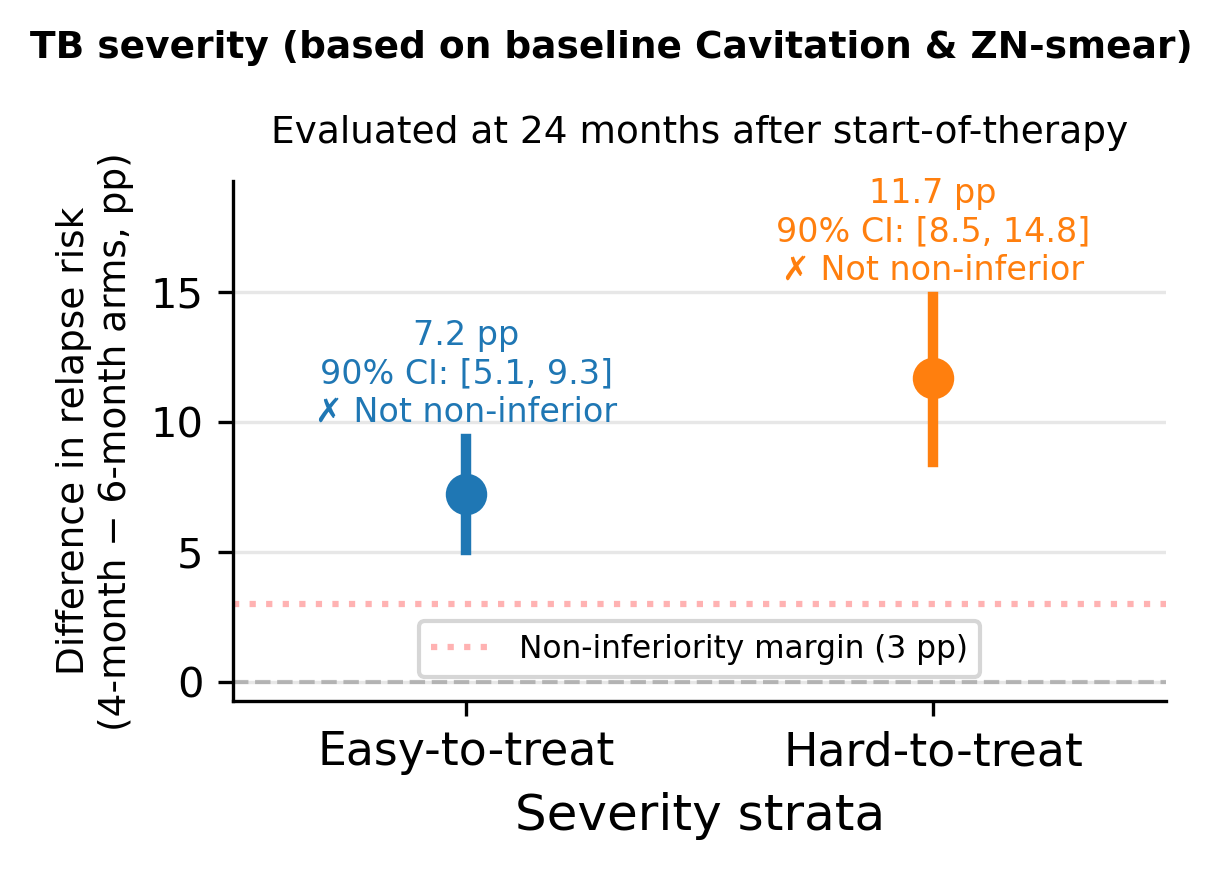

In [69]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy



from itertools import combinations
from sksurv.compare import compare_survival
from statsmodels.stats.multitest import multipletests

from sksurv.nonparametric import kaplan_meier_estimator
import warnings
warnings.filterwarnings('ignore')







figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

#pats_with_relapse_df=extract_21_22_relapse_pats()



suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


raw_data_training_data_types=['all_days_in_period','last_therapy_day']
llm_training_data_types=['full','pca']

model_names_for_plotting=['XGBoost','LogisticRegression'][1:]

parameters_for_analysis_raw=  [*parameters_for_analysis][1:2]# + [*parameters_for_analysis][5:6]
parameters_for_analysis_llm= [*parameters_for_analysis][1:3]

## Adding across_time ==> which averages the pred. probs per patinet across the first 4 monthsa
period_end_days_=period_end_days[:-2]# +['across_time']
raw_data_training_data_types_ = raw_data_training_data_types[2:]

model_names_ = model_names_for_plotting[:]
llm_data_inclusion_types_=['baseline_last_day','baseline_vars','all_days'][2:]
llm_training_data_types_ = ['full','pca'][:1]
llm_pool_methods_=['mean_pooling','attention_pooling'][:1]

lstm_model_complexities=['day_only','regimen_only','wo_regimen','full'][-1:]


## TO INCLUDE RIFAQUAIN PATIENTS IN THE SEVERITY COMPARISON, SET THIS TO TRUE, ELSE SET TO NONE
include_rifaquin=True
cav_zn = return_treatment_strata(include_rifaquin=include_rifaquin)

'''
#lstm_pred_probs = load_lstm_pred_probs(lstm_model_complexities,raw_data_param_key)
raw_pred_probs,raw_test_df = load_raw_pred_probs(parameters_for_analysis_raw,
                                                 parameters_for_analysis,
                                                model_names_)

llm_pred_probs = load_llm_pred_probs(parameters_for_analysis_llm,
                        llm_data_inclusion_types_,
                        llm_pool_methods_,
                        period_end_days_,
                        model_names_
                       )
'''

#data_params_to_loop = parameters_for_analysis_raw# + parameters_for_analysis_llm

low_thr=0.3#0.25
#abs_val = None #0.3
#abs_val = calc_mode_kde #0.3
abs_val=None
#thr_func=np.mean

all_pairwise_tests, all_figures = [], []
period_end_days__ = period_end_days_[:] +['across_time']

## APPROACHES: 
#. - the pre-loaded raw, llm and lstm models test prob outputs concatenated
#  - severity: easy-to-treat/ hard-to-treat patients based on Impeorial et al's stritification



for time_origin, max_day in zip(['SOT','EOT'][:1],
                                [730,365][:1]):

    for approach in ['raw','llm','severity','lstm'][1:3]:
    
        if 'raw' in approach or 'treatment' in approach:
            pred_prob_df = raw_pred_probs[(raw_pred_probs['data_type']=='test')#&\
                                           #(raw_pred_probs['period']== period_end_day)
                                            ].copy()
            pred_prob_df_train = raw_pred_probs[(raw_pred_probs['data_type']=='train')#&\
                                           #(raw_pred_probs['period']== period_end_day)
                                            ].copy()
            groupby_colns=['training_data_type','model_name']
            
            data_params_to_loop = pred_prob_df['data_param_key'].unique()
            strat_coln='Pred. prob. strata'
            period_to_loop = period_end_days__[2:3]
    
        
        if 'llm' in approach:
            pred_prob_df = llm_pred_probs[(llm_pred_probs['data_type']=='test')#&\
                                           #(llm_pred_probs['period']== period_end_day)
                                            ].copy()
            pred_prob_df_train = llm_pred_probs[(llm_pred_probs['data_type']=='train')#&\
                                           #(raw_pred_probs['period']== period_end_day)
                                            ].copy()
            groupby_colns=['llm_data_inclusion_type','model_name']

            data_params_to_loop = pred_prob_df['data_param_key'].unique()
            strat_coln='Pred. prob. strata'
            period_to_loop = period_end_days__[5:6]
    
        if 'lstm' in approach:
            pred_prob_df = lstm_pred_probs[(lstm_pred_probs['data_type']=='test')#&\
                                            #(lstm_pred_probs['period']==period_end_day)
                                            ].copy()
            pred_prob_df_train = lstm_pred_probs[(lstm_pred_probs['data_type']=='train')#&\
                                            #(lstm_pred_probs['period']==period_end_day)
                                            ].copy()
            
            groupby_colns=['model_complex','model_name']
    
    
        ## Extract prediction setups loaded into dataframe
        ## ==> IF stratified by severity (easy or hard-to-treat), just run the data_params once, as anyway the severity strata will be used for plotting
        if 'severity' in approach:
            pred_prob_df = llm_pred_probs[(llm_pred_probs['data_type']=='test')#&\
                                           #(raw_pred_probs['period']== period_end_day)
                                            ].copy()
            data_params_to_loop = pred_prob_df['data_param_key'].unique().tolist()[:1]
            strat_coln='Severity strata'
            #pred_prob_df[strat_coln] =  cav_zn.loc[pred_prob_df['USUBJID'].tolist(),strat_coln].values
            period_to_loop = period_end_days__[:1]
            
    
        for data_param_key_ in data_params_to_loop:
            print('--'*50,'\n',data_param_key_,'\n')
        
            outcome_label = parameters_for_analysis[data_param_key_]['result_cat']
    
    
        
            if outcome_label=='RELAPSE':
                id2label={0: "NO RELAPSE", 1: "RELAPSE"}
                label2id={"NO RELAPSE": 0, "RELAPSE": 1}
            else:
                id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
                label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
    
    
            
            ## SETTING TIME 
            for period_end_day in period_to_loop:
                print('period_end_day',period_end_day)
    
                if 'across_time' not in str(period_end_day):
                    pred_prob_df_period = pred_prob_df[(pred_prob_df['period']== period_end_day)&\
                                                        (pred_prob_df['data_param_key']==data_param_key_)]
                    pred_prob_df_period_train = pred_prob_df_train[(pred_prob_df_train['period']== period_end_day)&\
                                                        (pred_prob_df_train['data_param_key']==data_param_key_)]
                if 'across_time' in str(period_end_day):
                    pred_prob_df_period = pred_prob_df[(~pred_prob_df['period'].isin([160,'all']))&\
                                                        (pred_prob_df['data_param_key']==data_param_key_)]
                    pred_prob_df_period_train = pred_prob_df_train[(~pred_prob_df_train['period'].isin([160,'all']))&\
                                                        (pred_prob_df_train['data_param_key']==data_param_key_)]
    
    
                ## LOOP THGROUGH THE DIFFERENT EXPERISMENTAL SETUPS DEFINED BY THE groupby_colns 
                #.  ==> (i.e.: last-visit or all visit setup for raw models/ LLm models: last-visit, all-visit - common vars., all visit-all vars
                ##  ==> EACH OF THEM CREATES SEPARATE PLOTS
                #for (gr_level1,model_name_),pred_prob_df_group in pred_prob_df_period.groupby(groupby_colns):
                for ((gr_level1, model_name_), pred_prob_df_group_test), ((_, _), pred_prob_df_group_train) in zip(pred_prob_df_period.groupby(groupby_colns),
                                                                                                               pred_prob_df_period_train.groupby(groupby_colns)):
                                                                                                               
    

                    pred_loss_dict={}
                    
                    for data_type, pred_prob_df__ in zip(['train','test'],[pred_prob_df_group_train,pred_prob_df_group_test]):
                        
                        ## As one patient can appear mutliple times in the 25 test-sets, average their pred probs. to derive one preed. prob per patient for each time period
                        mean_pred_loss_ = pred_prob_df__.groupby(['period','USUBJID']).apply(lambda x:x['pred_risk'].mean()).to_frame()
                        
                        mean_pred_loss_ = mean_pred_loss_.groupby('USUBJID').apply(lambda x:x[0].mean()).to_frame()
                        mean_pred_loss_.columns=['pred_risk']
        
                        ## Add Arms & Study & therapy arm duration columns
                        mean_pred_loss_['Arm']= pred_prob_df__.drop_duplicates('USUBJID').set_index('USUBJID')[['ARM']].loc[mean_pred_loss_.index,'ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                                                                                                                        'Control-arm regimen (6 month regimen)':'Control'},regex=False) 
                        mean_pred_loss_['Study'] = (mean_pred_loss_.reset_index()['USUBJID'].str.split('/',expand=True)[0]).values
                        mean_pred_loss_['Study']=mean_pred_loss_['Study'].replace({'TB-1022':'OFLOTUB',
                                                                           'TB-1021':'REMoxTB'},regex=True)
                        mean_pred_loss_['therapy_arm_duration'] = '4-month'
                        mean_pred_loss_.loc[mean_pred_loss_['Arm'].isin(['2EHRZ/4HR','Control']),'therapy_arm_duration'] = '6-month'
        
                        ## Add Relapse information
                        mean_pred_loss_[['RELAPSE_DAY','RELAPSE']] = pats_with_relapse_df.loc[mean_pred_loss_.reset_index()['USUBJID'].tolist(),['RELAPSE_DAY','RELAPSE']].values
                   
        
                        ##
                        #time_origin='SOT'
                        #time_origin='EOT'
                        #max_day=400
                        #max_day=730
        
        
                        
                        df = add_relapse_or_censoring_days(df=mean_pred_loss_,
                                                  pats_with_relapse_df=pats_with_relapse_df,
                                                  #time_origin='SAT',
                                                  max_day=max_day,
                                                 )
                        pred_loss_dict[data_type] = df
                        
    
                    
                    ### ADD PREDICTION GROUPS 
                    #.  ==> IF BASELINE TIMEPOINTS, JUST TAKE LOWER X AND UPPER X % AS LOW/HIGH STRATA
                    # . ==> IF TIMEPOINTS LATER THAN BASELINE: DRUG REGIMEN DATA WAS ADDED, AND MODELS LEARNS ABOUT ARM ASSIGMENTS
                    #.      CALCULATE PREID. PROB. STRATA WITHIN ARMS or therapy_arm_duration
                    #  ==> pre_prob_groupby_coln==None  => use global distribution of pred probs to calcaulate thresholds
                    if 'severity' in approach:# or period_end_day=='baseline' or 'basic' in data_param_key_:
                        pre_prob_groupby_coln=None
                        
                        df_ = pred_loss_dict['test'].copy()#df.copy()

                        
                        if include_rifaquin==True:
                            df_rifaquin = add_censoring_data_to_rifaquin(time_origin,
                                                                  max_day)
                            df_ = pd.concat([df_,df_rifaquin],axis=0)

                        df_[strat_coln] =  cav_zn.loc[df_['USUBJID'].tolist(),strat_coln].values
                        df_[strat_coln] = df_[strat_coln].replace('Intermediate-to-treat','Interm.-to-treat')
    
                    #if period_end_day!='baseline':
                    else:
                        pre_prob_groupby_coln=['Arm']
                        #pre_prob_groupby_coln = ['therapy_arm_duration']
                        #pre_prob_groupby_coln = None



                        df_ = return_pred_prob_strata_from_train(
                                                    test_df=pred_loss_dict['test'].copy(),
                                                    train_df=pred_loss_dict['train'].copy(),
                                                    groupby_coln=pre_prob_groupby_coln,
                                                    low_thr=low_thr,
                                                    abs_val=abs_val,
                                                    #bs_val=None,
                                                    verbose=False)
                    
    
                    ## CHOOSE WHICH STRATA WILL BE COMPARED
                    #. ==> ALL 3, OR JUST THE LOW/HIGH
                    if 'severity' not in approach:
                        categories = ['Low','Interm.','High']
                    
                    if 'severity'  in approach:
                        categories=['Easy-to-treat','Interm.-to-treat', 'Hard-to-treat']
                    
                    df_[strat_coln] = pd.Categorical(df_[strat_coln],
                                                        categories=categories,
                                                        ordered=True)
    
    
    
                    
    
                    facet_stat_pairs_dict={'ther_arm_dur_facet':['therapy_arm_duration',
                                                             strat_coln,],
                                          'strat_coln_facet':[strat_coln,
                                                              'therapy_arm_duration'],
                                          'arm_facet':['Arm',
                                                       strat_coln],
                                         }
                                          
                    for facet_strat_pair in [*facet_stat_pairs_dict][:1]:
                        
                        facet_coln_, strat_coln_ = facet_stat_pairs_dict[facet_strat_pair][0],facet_stat_pairs_dict[facet_strat_pair][1]
    
                    
    
                    
                        strat_cats = df_[strat_coln_].cat.categories
                        #strat_cats = df_[strat_coln_].unique()
                        #pred_cats = np.sort(df_facet_[strat_coln].dropna().unique())
                        #pred_cats_ = copy.copy(pred_cats)
                        strat_cats_ = [strat_cats[0]] + [strat_cats[-1]]
    
                        facet_strat_levels =  strat_cats_#df_[strat_coln_].astype(str).unique().tolist() #df_[facet_coln_].astype(str).unique().tolist() +
                        cmap_=plt.get_cmap('tab10',10)
                        color_dict_ = {lev:cmap_(i) for  i,lev in enumerate(facet_strat_levels)}
                        
                    
                        #facet_coln='Study'
                        #facet_coln='therapy_arm_duration'
                        #facet_coln='Arm'
                        num_of_plots=df_[facet_coln_].unique().shape[0]
                        ncols=3 if num_of_plots>3 else 2
                        nrows=int(np.ceil(num_of_plots/ncols))  
                        #cmap_name='tab10'

                        leg_title_dict = {'Pred. prob. strata':'Relapse risk group predicted by model',
                                              'Severity strata':'Severity strata',
                                              'therapy_arm_duration':'Therapy duration',
                                              'Arm':'Arm'}
                            
                        
    
                        #if 'pred.'strat_coln_
                        #if strat_coln_ == 'Pred. prob. strata':
                        leg_title = leg_title_dict[strat_coln_]


                        #if 'Pred. prob. strata' in strat_coln_:
                        #    strat_cats__ = strat_cats_[::-1]
                            
                        ## Check interaction term between therapy_arm_duration & stratification levels
                        #. ==> If non-sgnificant: no evidence for different treatment effects in the 4 and 6-month arms stratified
                        subgroup_name = strat_cats_[0]
                        subgroup_mask = (df_[strat_coln_] == strat_cats_[0])

                        p_val, result,fit_df = check_interaction_and_proceed(df=df_, 
                                                     subgroup_mask=subgroup_mask, 
                                                     subgroup_name=subgroup_name,
                                                    relapse_ind_coln=f'RELAPSE_{time_origin}',
                                                    relapse_day_coln=f'RELAPSE_DAY_{time_origin}')

                        suptitle = return_suptitle_KM_curve(gr_level1,
                                                             model_name_,
                                                            approach,
                                                            data_param_key_)

                        
                        dd = {'baseline':'Baseline',
                                31:'Month 1',
                                62:'Month 2',
                                93:'Month 3',
                                125:'Month 4',
                                160:'Month 5',
                                'all':'Month 6',
                              #'across_time':'Baseline-Month 4'
                              'across_time':''
                               }
        
                        #if 'severity' not in approach:
                        #    suptitle = f'{suptitle}\n Trained at {dd[period_end_day]}'

                        ylabel_dict={'SOT':'start-of-therapy',
                                     'EOT':'end-of-therapy',}
                        t_eval_ = f'{int((max_day/365)*12)} months after {ylabel_dict[time_origin]}'
                        ax_title = f'Evaluated at {t_eval_}'# | Bootstrap n={n_boot}',
    
                            
                        figsize=(4,3)
                        fig = plot_arm_gap_by_subgroup(df_,                                              
                                             subgroup_mask, 
                                             subgroup_name,
                                             figsize=figsize,
                                             suptitle = suptitle,
                                             ax_title=ax_title,
                                             time_origin=time_origin,
                                             strat_cats_ = strat_cats_,
                                                  study_col='Study',
                                                  arm_col='therapy_arm_duration',
                                                  control_label='6-month',
                                                  t_eval=max_day, 
                                                  xlabel=leg_title,
                                                  color_dict_ = color_dict_,
                                                  relapse_ind_coln=f'RELAPSE_{time_origin}',
                                                 relapse_day_coln=f'RELAPSE_DAY_{time_origin}',
                                                 n_boot=500, 
                                                 seed=42)

                        data_dir_=f"../data/plots/non_infer_tests/{approach}/{data_param_key}?survival_analysis"
    
                        os.makedirs(data_dir_,exist_ok=True)
                    
                    
                        filename = (
                            f"{period_end_day}_days_"
                            f"{gr_level1}_"        
                            f"{model_name_.replace('LogisticRegression','LR')}_"
                            f"{time_origin}_" 
                            f"{max_day}.png"
                        )
                    
                        filepath = os.path.join(data_dir_, filename)
                    
                        #fig.savefig(filepath, dpi=300, bbox_inches="tight")
                        #plt.close(fig)   # optional but recommended
    
        
        
                        
                        


# COX-ANALYSIS

## Functions

In [ ]:
### LOAD LSTM RESULTS
def load_lstm_pred_probs(lstm_model_complexities,raw_data_param_key):

    lstm_l = []
    for model_complex_ in lstm_model_complexities:
        data_dir_=f'../data/model_interpretation/LSTM/'
        fn=os.path.join(data_dir_,
                         f'{raw_data_param_key}_days_{model_complex_}_LSTM_test_pred_probs_merged.csv')
        try:
            lstm_pred_prob_df = pd.read_csv(fn)  
            print(f'===== Loading {model_complex_} LSTM model====\n')
            lstm_pred_prob_df['model_complex']= model_complex_
            lstm_pred_prob_df['data_param_key']= raw_data_param_key
            lstm_pred_prob_df['model_name']= 'LSTM'

            lstm_l.append(lstm_pred_prob_df)
        except FileNotFoundError:
            lstm_pred_prob_df=None
            pass

    return pd.concat(lstm_l,axis=0)


### LOAD RAW PRED PROBS + X_TEST DATAFRAMES
###============================
def load_raw_pred_probs(parameters_for_analysis_raw,
                        parameters_for_analysis,
                       model_names_):


    raw_prob_l, raw_test_l = [],[]
    
    #for raw_data_param_key,llm_data_param_key in zip(parameters_for_analysis_raw,parameters_for_analysis_llm):
    for raw_data_param_key in parameters_for_analysis_raw:
        print('\n===========',raw_data_param_key,'===========\n')
        ## Define X and y dataframes for training
    
        #outcome_label=data_param_key.split('vars_')[-1].upper()
        outcome_label = parameters_for_analysis[raw_data_param_key]['result_cat']
    
        if outcome_label=='RELAPSE':
            id2label={0: "NO RELAPSE", 1: "RELAPSE"}
            label2id={"NO RELAPSE": 0, "RELAPSE": 1}
        else:
            id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
            label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
        
        
        if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
            fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
        else:
            fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
        X=pd.read_csv(fn,index_col=0)
        arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
        study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()
    
    
        #l,k=[],[]

        
        for period_end_day in period_end_days_:      
            print(f'{period_end_day}')
    
            if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
                continue
    
            for raw_training_data_type in raw_data_training_data_types_:
                print('======= Loading Raw data model======\n')
                print(f'{raw_training_data_type} model\n')
    
    
                for model_name in model_names_:
                    #print(f'Loading SHAP-values for model {model_name}')
                    
                    
                    ### LOAD SHAP-value dataframes + merged X_test dataframes
                    data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                    os.makedirs(data_dir_,exist_ok=True)
                    fn=os.path.join(data_dir_,
                                f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                    raw_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
                    raw_merged_shap_across_cv['data_param_key']= raw_data_param_key
                    raw_merged_shap_across_cv['period']= period_end_day
                    raw_merged_shap_across_cv['training_data_type']= raw_training_data_type
                    raw_merged_shap_across_cv['model_name']= model_name
                    
                    raw_prob_l.append(raw_merged_shap_across_cv)

                
                ## Load merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                raw_merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
                raw_merged_x_test_across_cv['data_param_key']= raw_data_param_key
                raw_merged_x_test_across_cv['period']= period_end_day
                raw_merged_x_test_across_cv['training_data_type']= raw_training_data_type
                raw_merged_x_test_across_cv['model_name']= model_name
                
                raw_test_l.append(raw_merged_x_test_across_cv)

    raw_prob_df = pd.concat(raw_prob_l,axis=0)
    raw_test_df = pd.concat(raw_test_l,axis=0)

    return raw_prob_df,raw_test_df




######=======================================
def load_llm_pred_probs(parameters_for_analysis_llm,
                        llm_data_inclusion_types_,
                        llm_pool_methods_,
                        period_end_days_,
                        model_names_
                       ):
    
    llm_prob_l =[]
    ### ======= LOAD LLM LOGITS! ===== ###
                
    print('======= Loading LLM model======\n')
    #for data_param_key in parameters_for_analysis_:
    for llm_data_param_key in parameters_for_analysis_llm:

        ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
        if 'pat_ids_fn' in parameters_for_analysis[llm_data_param_key].keys():
            fn=f"../data/{parameters_for_analysis[llm_data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
        else:  
            fn=f'../data/{llm_data_param_key}_final_pat_ids_for_analysis.pickle'
    
    
        with open(fn, 'rb') as handle:
            final_pat_ids_for_analysis=pickle.load(handle)
        #print('pat_ids_fn')
        
        #print(data_param_key)
        #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
        #X=pd.read_csv(fn,index_col=0,low_memory=False)
        
        ## Define X and y dataframes for training
        #fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
        if 'X_fn' in parameters_for_analysis[llm_data_param_key].keys():
            fn='../data/'+parameters_for_analysis[llm_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
        else:
            fn='../data/'+parameters_for_analysis[llm_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
        X_imp=pd.read_csv(fn,index_col=0)
    
        
        #outcome_label=data_param_key.split('vars_')[-1].upper()
            
        for llm_model_name in llm_model_names[:1]:
            
            for fine_tuned_tag in fine_tuned_tags[:1]:
                
    
                if 'text-embedding' in llm_model_name:
                    llm_model_name_with_tag=llm_model_name
                else:
                    llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                
                
                for period_end_day in period_end_days_:                
                    period_num = period_end_days.index(period_end_day)
                    
                    #print(f'Training on {period_end_day} days of data')
        
                    for llm_data_inclusion_type in llm_data_inclusion_types_:
        
                        for autoencoder_merged in autoenc_merged_bool_list[:1]:
        
                            for pool_method in llm_pool_methods_:
        
                                ## Load embeddings created by LLM model
                
            
                                ## Load embeddings created by LLM model
                                #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                try:
                                    df=embed_dict[parameters_for_analysis[llm_data_param_key]['fn']][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                                    print(f'Loaded embeddings of {llm_data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
                                except KeyError:
                                    warnings.warn(f"Embeddings of {parameters_for_analysis[llm_data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                    continue
            
                                #print(data_param_key)
                                if 'X_fn' in parameters_for_analysis[llm_data_param_key].keys():
                                    fn='../data/'+parameters_for_analysis[llm_data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                                else:
                                    fn='../data/'+parameters_for_analysis[llm_data_param_key]['fn']+'_all_data_concat.csv.gz'
                                X=pd.read_csv(fn,index_col=0,low_memory=False)
        
                            
        
                                for training_data_type in llm_training_data_types_:
    
                                    for model_name in model_names_:
        
                                        fn=f'../data/{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_4096_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'                                
                                        with open(fn, 'rb') as handle:
                                            print("loaded:",fn) 
                                            training_results=pickle.load(handle)
            
                                        #print('Loadding training results:\n',fn)
                                        
                                        cv_results=training_results['cv_results']
            
                                        #for n, model_name in enumerate(tqdm(model_names_, desc="Processing", unit="model")):
                                        print(model_name)
                
                                        ### LOAD SHAP-value dataframes + merged X_test dataframes
                                        data_dir_=f'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                        #os.makedirs(data_dir_,exist_ok=True)
                                        fn=os.path.join(data_dir_,
                                                    f'{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_SHAP_vals_across_CV_splits.csv.gz')
                                                    
                                        #merged_shap_across_cv.to_csv(fn)
                                        
                                        llm_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
                                        #print(llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['USUBJID']=='TB-1022/53504','true_labels'])
                                        llm_merged_shap_across_cv['data_param_key']= llm_data_param_key
                                        llm_merged_shap_across_cv['period']= period_end_day
                                        llm_merged_shap_across_cv['llm_data_inclusion_type']= llm_data_inclusion_type
                                        llm_merged_shap_across_cv['model_name']= model_name
                                
                                llm_prob_l.append(llm_merged_shap_across_cv)
    
    llm_prob_df = pd.concat(llm_prob_l,axis=0)

    return llm_prob_df




######==============================
def concat_raw_llm_pred_probs_dfs(raw_merged_shap_across_cv,
                                  llm_merged_shap_across_cv,
                                  lstm_pred_prob_df,
                                  raw_merged_x_test_across_cv,
                                  ens_merged_shap_across_cv=None):
    
    raw=raw_merged_shap_across_cv.loc[raw_merged_shap_across_cv['data_type']=='test',['pred_prob',#'test_pred_prob_calibr',#'true_labels',
                                                                                      'USUBJID','cv_repeat_num','ARM']]
    llm=llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['data_type']=='test',['test_pred_prob_calibr',
                                                                                   'pred_prob',#'true_labels',
                                                                                   'USUBJID','cv_repeat_num','ARM']]
    if lstm_pred_prob_df is not None:
        lstm = lstm_pred_prob_df.loc[(lstm_pred_prob_df['data_type']=='test')&\
                                     (lstm_pred_prob_df['period']==str(period_end_day)),['lstm_pred_prob',#'test_pred_prob_calibr',#'true_labels',
                                                                                          'USUBJID','cv_repeat_num','ARM']]
        #lstm = 
        lstm['ARM'] = lstm['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                         'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    llm['ARM'] = llm['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                     'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    

    pred_prob_name='test_pred_prob_calibr'
    pred_prob_name='pred_prob'
    
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
    raw['raw_pred_prob_norm']=pd.concat(l).values
    raw[['raw_pred_prob','raw_pred_prob_calibr'][:1]]=raw[['pred_prob','test_pred_prob_calibr'][:1]].values
    
    l=[]
    
    pred_prob_name='test_pred_prob_calibr'
    pred_prob_name='pred_prob'
    
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
    
    llm['llm_pred_prob_norm']=pd.concat(l).values
    #llm['llm_pred_prob']=llm[pred_prob_name]
    llm[['llm_pred_prob','llm_pred_prob_calibr'][:1]]=llm[['pred_prob','test_pred_prob_calibr'][:1]].values


    if lstm_pred_prob_df is not None:
        l=[]
        pred_prob_name='lstm_pred_prob'
        for cv_rep,x in lstm.groupby('cv_repeat_num'):
            l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
        lstm['lstm_pred_prob_norm']=pd.concat(l).values
    


    if ens_merged_shap_across_cv is not None:
        ens=ens_merged_shap_across_cv.loc[ens_merged_shap_across_cv['data_type']=='test',['pred_prob',#'true_labels',
                                                                                          'USUBJID','cv_repeat_num','ARM']]

        ens['ARM'] = ens['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                     'Control-arm regimen (6 month regimen)':'Control'},regex=False)

        pred_prob_name='pred_prob'
        
        l=[]
        for cv_rep,x in ens.groupby('cv_repeat_num'):
            l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
        
        ens['ens_pred_prob_norm']=pd.concat(l).values
        ens['ens_pred_prob']=ens[pred_prob_name]


    
    raw = raw.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #raw['exp_setup']='raw_data'
    llm = llm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])

    if lstm_pred_prob_df is not None:
        lstm = lstm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #llm['exp_setup']='LLM'


        
    
    #raw['raw_logits']=np.log(raw['raw_pred_prob_norm'] / (1 - raw['raw_pred_prob_norm']))
    #llm['llm_logits']=np.log(llm['llm_pred_prob_norm'] / (1 - llm['llm_pred_prob_norm']))


    ## CALCULATE RAW LOGITS FROM THE RAW PREDICTION PROBS.
    raw['raw_logits']=np.log(raw['raw_pred_prob'] / (1 - raw['raw_pred_prob']))
    llm['llm_logits']=np.log(llm['llm_pred_prob'] / (1 - llm['llm_pred_prob']))
    if lstm_pred_prob_df is not None:
        lstm['lstm_logits']=np.log(lstm['lstm_pred_prob'] / (1 - lstm['lstm_pred_prob']))

    ## NORMALISE RAW LOGITS PER CV FROM THE RAW PREDICTION LOGITS.
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x['raw_logits']-x['raw_logits'].min())/(x['raw_logits'].max()-x['raw_logits'].min()))
    raw['raw_logits_norm']=pd.concat(l).values


    l=[]
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x['llm_logits']-x['llm_logits'].min())/(x['llm_logits'].max()-x['llm_logits'].min()))
    llm['llm_logits_norm']=pd.concat(l).values


    if lstm_pred_prob_df is not None:
        l=[]
        for cv_rep,x in lstm.groupby('cv_repeat_num'):
            l.append((x['lstm_logits']-x['lstm_logits'].min())/(x['lstm_logits'].max()-x['lstm_logits'].min()))
        lstm['lstm_logits_norm']=pd.concat(l).values


    if ens_merged_shap_across_cv is not None:

        ens['ens_logits']=np.log(ens['ens_pred_prob'] / (1 - ens['ens_pred_prob']))
        
        ens = ens.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
        l=[]
        for cv_rep,x in ens.groupby('cv_repeat_num'):
            l.append((x['ens_logits']-x['ens_logits'].min())/(x['ens_logits'].max()-x['ens_logits'].min()))
        
        ens['ens_logits_norm']=pd.concat(l).values

    
  
    ## MERGE VALUES OF TEST DATA VARIABLES 
    x_test__ = raw_merged_x_test_across_cv[raw_merged_x_test_across_cv['data_type']=='test'].reset_index().sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])

    data_to_concat=[raw,llm,x_test__]
    
    if lstm_pred_prob_df is not None:
        data_to_concat.append(lstm)

        
    if ens_merged_shap_across_cv is not None:
        data_to_concat.append(ens)

    
    prob_df = pd.concat(data_to_concat,axis=1)
    prob_df=prob_df.loc[:,~prob_df.columns.duplicated()]


    ## ADD TRUE LABELS
    if outcome_label=='RELAPSE':
        prob_df['true_labels']= pats_with_relapse_df.loc[prob_df.reset_index()['USUBJID'],'RELAPSE'].values

    if outcome_label=='RESULT_AT_END_OF_TREATMENT': 
        prob_df['true_labels']= eot_outcome_df.loc[prob_df.reset_index()['USUBJID']].values


    prob_df['raw_pred_loss'] = ((prob_df['raw_pred_prob'] - prob_df['true_labels']).abs()).values
    prob_df['llm_pred_loss'] = ((prob_df['llm_pred_prob'] - prob_df['true_labels']).abs()).values
    
    if lstm_pred_prob_df is not None:
        prob_df['lstm_pred_loss'] = ((prob_df['lstm_pred_prob'] - prob_df['true_labels']).abs()).values

    return prob_df



####===============
def avg_pred_probs_across_cvs(plot_df,arm_pat_dict):
    
    num_col = [col for col in plot_df.columns if col not in ['ARM','data_type','period']]
    plot_df_mean = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
    arm_pat_df = pd.DataFrame(data=arm_pat_dict.values(),index=arm_pat_dict.keys())
    plot_df_mean['ARM']=arm_pat_df.loc[plot_df_mean.index,0].values

    return plot_df_mean

####===============
def return_pred_prob_strata(df,groupby_coln,low_thr):

   #labels=['Low prob.','Interm. prob.','High prob.']
    labels=['Low','Interm.','High']
    
    if groupby_coln is None:
        strata = pd.cut(x=df['pred_prob'],
                          bins=[0,
                                df['pred_prob'].quantile(low_thr),
                                df['pred_prob'].quantile(1-low_thr),
                                1],
                          labels=labels)
        df['Pred. prob. strata']= strata.values
        
        
    if groupby_coln is not None:
        
        a=df.groupby(groupby_coln).apply(lambda x:pd.cut(x=x['pred_prob'],
                                                              bins=[0,
                                                                    x['pred_prob'].quantile(low_thr),
                                                                    x['pred_prob'].quantile(1-low_thr),
                                                                    1],
                                                              labels=labels))
        b=df.groupby(groupby_coln).apply(lambda x:x['USUBJID'])
        strata=pd.concat([a,b],axis=1).set_index('USUBJID').loc[df['USUBJID'].tolist(),:]
        df['Pred. prob. strata']= strata['pred_prob'].values
        
    return df


####============
def return_treatment_strata():
    
    ## EXTRACT TREATMENT STRATA INFORMATION
    data_inclusion_type__='all_days'
    period_end_day_ = 'all'
    #data_inclusion_type__='baseline_last_day'
    fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
    df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
    #df_concat = df_concat.reset_index()
    
    
    cav=df_concat.loc[:,['USUBJID'] + df_concat.columns[df_concat.columns.str.contains('re_Cav')].tolist()].groupby('USUBJID').first()
    zn_smear=df_concat.loc[:,['USUBJID','mb_ZN-smear_STD_CAT_ORDINAL_RESULT']].groupby('USUBJID').first()
    cav_zn=pd.concat([cav,zn_smear],axis=1)
    
    '''
    ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
             #((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
    '''
    ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
    
    htt_mask=((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']>=3))
    
    cav_zn['Severity strata']='Intermediate-to-treat'#np.nan#'itt'
    cav_zn.loc[ett_mask,'Severity strata']='Easy-to-treat'
    cav_zn.loc[htt_mask,'Severity strata']='Hard-to-treat'
    cav_zn.loc[cav_zn['re_Cavitation_STD_CAT_RESULT'].isna(),'Severity strata']=np.nan

    return cav_zn



####=====================
def return_suptitle_KM_curve(gr_level1,
                             model_name,
                            approach,
                            data_param_key_):

    suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                   'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                  'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
                  'TB-1021':'REMox',
                  'TB-1022':'OFLOTUB'}
    
    study_dict={'TB-1021':'REMox',
                 'TB-1022':'OFLOTUB'}
    
    suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                                 'last_therapy_day':'visit at end of period'}
    
    model_name_dict={'LogisticRegression':'LR',
                    'XGBoost':'XGBoost'}
    
    raw_data_training_data_types=['all_days_in_period','last_therapy_day']
    
    
    raw_training_data_type_dict ={'last_therapy_day':'Raw common vars. - last visit in period',
                                 'all_days_in_period':'Raw  common vars. - last visits concatenated',
                                 'tb21_22_2984_pats_22_vars_relapse_basic_vars':'Raw basic vars. - '}
    
    llm_data_inclusion_type_dict={'baseline_last_day':'Embedded common vars. - last visit in period',
                                   'baseline_vars':'Embedded common vars. - all visits in period',
                                   'all_days':'Embedding model: all vars. - all visits in period'}
    
    
    period_end_day_dict={'baseline':'Baseline',
                         '31':'Month 1',
                         '62':'Month 2',
                         '93':'Month 3',
                         '125':'Month 4',
                         '160':'Month 5',
                         'all':'Month 6'}
    
    

    if 'llm' in approach:
        suptitle = f"{llm_data_inclusion_type_dict[gr_level1]} - {model_name_dict[model_name_]}"
    
    if 'raw' in approach:

        if 'basic' not in data_param_key_:
            suptitle = f"{raw_training_data_type_dict[gr_level1]} - {model_name_dict[model_name_]}"
        
        if 'basic' in data_param_key_:
            suptitle = f"Raw basic vars. -  {raw_training_data_type_dict[gr_level1].split(' - ')[-1]} - {model_name_dict[model_name_]}"
            

    if 'lstm' in approach:
        suptitle = f"{raw_training_data_type_dict['all_days_in_period']} - LSTM"
    
    if 'severity' in approach:
        suptitle = "TB severity (Cavitaation + baseline ZN-smear)"
        
    
    return suptitle

    

## Run

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib



from itertools import combinations
from sksurv.compare import compare_survival
from statsmodels.stats.multitest import multipletests

from sksurv.nonparametric import kaplan_meier_estimator
import warnings
warnings.filterwarnings('ignore')







figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

#pats_with_relapse_df=extract_21_22_relapse_pats()



suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


raw_data_training_data_types=['all_days_in_period','last_therapy_day']
llm_training_data_types=['full','pca']

model_names_for_plotting=['XGBoost','LogisticRegression'][1:]

parameters_for_analysis_raw=  [*parameters_for_analysis][1:2] + [*parameters_for_analysis][5:6]
parameters_for_analysis_llm= [*parameters_for_analysis][1:2]

period_end_days_=period_end_days[:] +['across_time']
raw_data_training_data_types_ = raw_data_training_data_types[:1]

model_names_ = model_names_for_plotting[:]
llm_data_inclusion_types_=['baseline_last_day','baseline_vars','all_days'][2:]
llm_training_data_types_ = ['full','pca'][:1]
llm_pool_methods_=['mean_pooling','attention_pooling'][:1]

lstm_model_complexities=['day_only','regimen_only','wo_regimen','full'][-1:]

cav_zn = return_treatment_strata()

'''
#lstm_pred_probs = load_lstm_pred_probs(lstm_model_complexities,raw_data_param_key)
raw_pred_probs,raw_test_df = load_raw_pred_probs(parameters_for_analysis_raw,
                                                 parameters_for_analysis,
                                                model_names_)
llm_pred_probs = load_llm_pred_probs(parameters_for_analysis_llm,
                        llm_data_inclusion_types_,
                        llm_pool_methods_,
                        period_end_days_,
                        model_names_
                       )
'''

#data_params_to_loop = parameters_for_analysis_raw# + parameters_for_analysis_llm

low_thr=0.49

all_pairwise_tests, all_figures = [], []

## APPROACHES: 
#. - the pre-loaded raw, llm and lstm models test prob outputs concatenated
#  - severity: easy-to-treat/ hard-to-treat patients based on Impeorial et al's stritification

for approach in ['raw','llm','severity','lstm'][1:2]:

    if 'raw' in approach or 'treatment' in approach:
        pred_prob_df = raw_pred_probs[(raw_pred_probs['data_type']=='test')#&\
                                       #(raw_pred_probs['period']== period_end_day)
                                        ].copy()
        groupby_colns=['training_data_type','model_name']

    
    if 'llm' in approach:
        pred_prob_df = llm_pred_probs[(llm_pred_probs['data_type']=='test')#&\
                                       #(llm_pred_probs['period']== period_end_day)
                                        ].copy()
        groupby_colns=['llm_data_inclusion_type','model_name']

    if 'lstm' in approach:
        pred_prob_df = lstm_pred_probs[(lstm_pred_probs['data_type']=='test')#&\
                                        #(lstm_pred_probs['period']==period_end_day)
                                        ].copy()
        groupby_colns=['model_complex','model_name']


    ## Extract prediction setups loaded into dataframe
    ## ==> IF stratified by severity (easy or hard-to-treat), just run the data_params once, as anyway the severity strata will be used for plotting
    if 'severity' in approach:
        data_params_to_loop = pred_prob_df['data_param_key'].unique().tolist()[:1]
        strat_coln='Severity strata'
    else:
        data_params_to_loop = pred_prob_df['data_param_key'].unique()
        strat_coln='Pred. prob. strata'
        

    for data_param_key_ in data_params_to_loop:
    
        outcome_label = parameters_for_analysis[data_param_key_]['result_cat']


    
        if outcome_label=='RELAPSE':
            id2label={0: "NO RELAPSE", 1: "RELAPSE"}
            label2id={"NO RELAPSE": 0, "RELAPSE": 1}
        else:
            id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
            label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}

        
    
        for period_end_day in period_end_days_[-1:]:

            if 'across_time' not in str(period_end_day):
                pred_prob_df_period = pred_prob_df[(pred_prob_df['period']== period_end_day)&\
                                                    (pred_prob_df['data_param_key']==data_param_key_)]
            if 'across_time' in str(period_end_day):
                pred_prob_df_period = pred_prob_df[#(pred_prob_df['period']== period_end_day)&\
                                                    (pred_prob_df['data_param_key']==data_param_key_)]


          
            for (gr_level1,model_name_),pred_prob_df_group in pred_prob_df_period.groupby(groupby_colns):

                
                mean_pred_loss_ = pred_prob_df_group.groupby(['period','USUBJID']).apply(lambda x:x['pred_prob'].mean()).to_frame()
                
                #mean_pred_loss_ = mean_pred_loss_.groupby('USUBJID').apply(lambda x:x[0].mean()).to_frame()
                mean_pred_loss_.columns=['pred_prob']
                mean_pred_loss_ = mean_pred_loss_.reset_index()
                arms_df = pred_prob_df_group.drop_duplicates('USUBJID').set_index('USUBJID')[['ARM']].loc[mean_pred_loss_['USUBJID'],'ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                                                                                                                                'Control-arm regimen (6 month regimen)':'Control'},regex=False) 

                mean_pred_loss_['Arm']= arms_df.values
                mean_pred_loss_['Study'] = (mean_pred_loss_.reset_index()['USUBJID'].str.split('/',expand=True)[0]).values
                mean_pred_loss_['Study']=mean_pred_loss_['Study'].replace({'TB-1022':'OFLOTUB',
                                                                   'TB-1021':'REMoxTB'},regex=True)
                mean_pred_loss_[['RELAPSE_DAY','RELAPSE']] = pats_with_relapse_df.loc[mean_pred_loss_.reset_index()['USUBJID'].tolist(),['RELAPSE_DAY','RELAPSE']].values
    
                # df columns expected:
                # time, event (0/1), group (categorical), study (e.g., "study1"/"study2")
                df = mean_pred_loss_.copy()#reset_index()


                ### LOAD AND EXTRACT REAL COMPLETION DAYS OF PATIENTS RECORDED
                de=pd.read_csv('../../C-Path_data/preprocessing/disposition_events.csv',low_memory=True) 
                de=de.set_index('USUBJID')
                comm_idx = list(set(de.index) & set(pats_with_relapse_df[pats_with_relapse_df['RELAPSE_DAY'].isna()].index))
                de_ = de.loc[comm_idx,:]
                
                compl_day_df= de_[~(de_['COMPLETION FOLLOW-UP PHASE'].isna())&\
                                    (de_['COMPLETION FOLLOW-UP PHASE']!='YES')]

                idx_=list(set(compl_day_df.index) & set(df.index))
                
                ## Add real completion day of patients who had no relapse
                df.loc[idx_,'RELAPSE_DAY']=compl_day_df.loc[idx_,'COMPLETION FOLLOW-UP PHASE'].astype(float).values
                df.loc[df['RELAPSE_DAY']>10300,'RELAPSE_DAY']=np.nan
                #df.loc[df['RELAPSE_DAY']>1000,'RELAPSE_DAY']=1000
                
                
                ## For no relapse patients where completion day is missing, set scheduled follow-up as completion day (18 months for RemoxTB & 24 months for OFLOTUB)
                df.loc[(df['RELAPSE_DAY'].isna())&\
                        (df['Study']=='REMoxTB'),'RELAPSE_DAY']=550

    
                #df.loc[(df['RELAPSE_DAY'].isna())&\
                #        (df['Study']=='OFLOTUB'),'RELAPSE_DAY'] = 2*365 + 730

                df.loc[(df['RELAPSE_DAY'].isna())&\
                        (df['Arm'].isin(['Control'])),'RELAPSE_DAY']= (180 +  2 *365)
               
                df.loc[(df['RELAPSE_DAY'].isna())&\
                        (df['Arm'].isin(['Gatifloxacin'])),'RELAPSE_DAY']= (120 +  2 *365)

                '''

                df.loc[(df['RELAPSE_DAY'].isna())&\
                        (df['RELAPSE_DAY']>730),'RELAPSE_DAY']=730

                
                df.loc[(~df['RELAPSE_DAY'].isna())&\
                        (df['RELAPSE_DAY']>730),'RELAPSE_DAY']=730
                df.loc[(~df['RELAPSE_DAY'].isna())&\
                        (df['RELAPSE_DAY']>730),'RELAPSE']=0
                '''

                df = df.reset_index()
    
                
                #df = df[df['RELAPSE_DAY']<=800]
            
                
                df["RELAPSE"] = df["RELAPSE"].astype(int)
                df['RELAPSE_DAY'] =  df['RELAPSE_DAY'].astype(float)
                #df["prediction_strata"] = df["prediction_strata"].astype("category")
                df["USUBJID"] = df["USUBJID"].astype("category")
    
                
                '''
                facet_coln='Study'
                facet_coln='Arm'
                num_of_plots=df[facet_coln].unique().shape[0]
                ncols=3 if num_of_plots>3 else 2
                nrows=int(np.ceil(num_of_plots/ncols))  
                cmap_name='tab10'
        
        
                fig = plt.figure(figsize=(ncols*2.4,nrows*2.1))
                #fig,axes = plt.subplots(nrows=nrows,ncols=ncols, figsize=(ncols*4,nrows*2),sharey=True)
                                
                all_figures.append({
                                    "fig": fig,
                                    "meta": {
                                        "approach": approach,
                                        "data_param_key": data_param_key_,
                                        "period_end_day": period_end_day,
                                        "gr_level1": gr_level1,
                                        "model_name": model_name_,
                                            }
                                        })   #ax=axes.flatten()[n]
                                                    
                                    
    
    
                ### ADD PREDICTION GROUPS 
                #.  ==> IF BASELINE TIMEPOINTS, JUST TAKE LOWER X AND UPPER X % AS LOW/HIGH STRATA
                # . ==> IF TIMEPOINTS LATER THAN BASELINE: DRUG REGIMEN DATA WAS ADDED, AND MODELS LEARNS ABOUT ARM ASSIGMENTS
                #.      CALCULATE PREID. PROB. STRATA WITHIN ARMS@
                if 'severity' in approach:# or period_end_day=='baseline' or 'basic' in data_param_key_:
                    pre_prob_groupby_coln=None

                #if period_end_day!='baseline':
                else:
                    pre_prob_groupby_coln=['Arm']
                    #pre_prob_groupby_coln = None

                
                df_ = return_pred_prob_strata(df=df,
                                            groupby_coln=pre_prob_groupby_coln,
                                            low_thr=low_thr)

               
                
                for n,facet_level in enumerate(df_[facet_coln].unique()):
                    ax=fig.add_subplot(nrows,ncols,n+1)

                    df_facet=df_[df_[facet_coln]==facet_level]
    
                       
                    df_facet_ = df_facet[#(~df_facet['prediction_strata'].isin(['Intermediate-to-treat','intermediate_to_predict']))&\
                               (~df_facet[strat_coln].isna())]
                        
                    #pred_cats = df_["prediction_strata"].astype(str).astype('category').cat.categories
                    pred_cats = np.sort(df_facet_[strat_coln].dropna().unique())


                    ## CHOOSE WHICH STRATA WILL BE COMPARED
                    #. ==> ALL 3, OR JUST THE LOW/HIGH
                    if 'severity' not in approach:
                        pred_cats_ = pred_cats[::-1]
                        pred_cats_ = [pred_cats_[0]] + [pred_cats_[-1]]
                    
                    if 'severity'  in approach:
                        pred_cats_ = pred_cats
        
                    #print(df_.shape)
            
                    cmap = plt.get_cmap(cmap_name)
                    colormap_dict = {cat:cmap(i) for i,cat in enumerate(pred_cats_)}
                    #df_study["prediction_strata"]

                    # Pairwise log-rank tests within this facet
                    pairs = list(combinations(list(pred_cats_), 2))
                    
                    # If you have <2 groups present in this facet, skip
                    if len(pairs) > 0:
                        # Create placeholder text objects now, update later after global FDR
                        # Stack them in the lower-left corner
                        y0 = 0.05
                        dy = 0.055
                    
                        for i, (g1, g2) in enumerate(pairs):
                            mask = df_facet_[strat_coln].isin([g1, g2])
                    
                            groups_pair = df_facet_.loc[mask, strat_coln].astype(str).values
                            event_pair  = df_facet_.loc[mask, "RELAPSE"].astype(bool).values
                            time_pair   = df_facet_.loc[mask, "RELAPSE_DAY"].astype(float).values
                    
                            # Need at least 1 event and at least 2 groups represented
                            if (event_pair.sum() == 0) or (np.unique(groups_pair).size < 2):
                                p_raw = np.nan
                                chisq = np.nan
                            else:
                                y = _sksurv_y(event_pair, time_pair)
                                chisq, p_raw = compare_survival(y, groups_pair)
                    
                            # placeholder text on the axis (we will overwrite after FDR)
                            t = ax.text(
                                0.02, y0 + i * dy,
                                f"{g1} vs {g2}: p=...",
                                transform=ax.transAxes,
                                fontsize=7,
                                va="bottom"
                            )
                    
                            all_pairwise_tests.append({
                                "chisq": chisq,
                                "p_raw": p_raw,
                                "ax": ax,
                                "text_artist": t,
                                "facet_level": facet_level,
                                "pair": (str(g1), str(g2)),
                                "meta": {
                                    "approach": approach,
                                    "data_param_key": data_param_key_,
                                    "period_end_day": period_end_day,
                                    "gr_level1": gr_level1,
                                    "model_name": model_name_,
                                }
                            })


    
                    
                    for g in pred_cats_:
                        #print(g)
                        mask = df_facet_[strat_coln] == g
                        time, survival_prob, conf_int = kaplan_meier_estimator(
                            df_facet_["RELAPSE"][mask].astype(bool),
                            df_facet_["RELAPSE_DAY"][mask],
                            conf_type="log-log"
                        )
            
                        ax.step(time, survival_prob, where="post", label=str(g),color=colormap_dict[g])
                        ax.fill_between(time, conf_int[0], conf_int[1], alpha=0.2, step="post")
                
                    ax.set_xlabel("Time (days)")
        
                    ## If subplot is not the first subplot in the row, disable y-ticks
                    if n%ncols!=0:
                        ax.tick_params(axis='y', labelleft=False)
        
                    ## If subplot is  the first subplot in the row, set y-ticks
                    if n%ncols==0:
                        ax.set_ylabel("Relapse-free\nsurvival probability")
                        #ax.tick_params(axis='y', labelsize=ytick_labelsize)
            
                    ax.set_title(facet_level)
                    #ax.set_xlim(df['RELAPSE_DAY'].min(),df['RELAPSE_DAY'].max())
                    ax.set_ylim(0.6,1.05)
                    #ax.legend()
                    plt.tight_layout()
                    l,h = ax.get_legend_handles_labels()
                
                # Remove all unused axes
                #for ax in axes[num_of_plots:]:
                    #fig.delaxes(ax)
                #    ax.remove()
                    #ax.axis("off")

                dd = {'baseline':'Baseline',
                        31:'Month 1',
                        62:'Month 2',
                        93:'Month 3',
                        125:'Month 4',
                        160:'Month 5',
                        'all':'Month 6',
                      'across_time':'Baseline-Month 4'
                       }
                
                leg_title = f"Relapse risk predicted"
                plt.legend(title=leg_title,
                           loc='upper left',
                           bbox_to_anchor=(1.05,1))

                suptitle = return_suptitle_KM_curve(gr_level1,
                                                     model_name_,
                                                    approach,
                                                    data_param_key_)

                if 'severity' not in approach:
                    suptitle = f'{suptitle}\n Trained at {dd[period_end_day]}'
                    
                
                #suptitle = f'{data_param_key_} - {approach} - {dd[period_end_day]}'
                fig.suptitle(suptitle,y=1.07,fontweight='bold')
                #plt.show()
                


# Global FDR across all performed pairwise tests
pvals = np.array([d["p_raw"] for d in all_pairwise_tests], dtype=float)
valid = np.isfinite(pvals)

pvals_fdr = np.full_like(pvals, np.nan, dtype=float)
if valid.sum() > 0:
    _, pvals_fdr_valid, _, _ = multipletests(pvals[valid], method="fdr_bh")
    pvals_fdr[valid] = pvals_fdr_valid

# Write corrected p-values into the already-created Text artists
for d, p_corr in zip(all_pairwise_tests, pvals_fdr):
    g1, g2 = d["pair"]
    chisq = d.get("chisq", np.nan)
    if np.isfinite(p_corr):
        if p_corr<0.05:
            #d["text_artist"].set_text(f"{g1} vs {g2}: q={p_corr:.3e}")
            #d["text_artist"].set_text(f"{g1} vs {g2}:\nFDR={p_corr:.3e}")
            d["text_artist"].set_text(f"χ²={chisq:.2f}\nFDR={p_corr:.2e}")
        else:
            d["text_artist"].set_text(f"")
            
    else:
        #d["text_artist"].set_text(f"{g1} vs {g2}: q=NA")
        d["text_artist"].set_text(f"")


### SAVE PLOTS



for fig_dict in all_figures:
    fig = fig_dict["fig"]
    meta = fig_dict["meta"]
    
    data_dir_=f"../data/plots/KM_curves/{meta['approach']}/{meta['data_param_key']}"

    os.makedirs(data_dir_,exist_ok=True)


    filename = (
        f"{meta['period_end_day']}_days_"
        f"{meta['gr_level1']}_"        
        f"{meta['model_name'].replace('LogisticRegression','LR')}.png"
    )

    filepath = os.path.join(data_dir_, filename)

    fig.savefig(filepath, dpi=300, bbox_inches="tight")
    #plt.close(fig)   # optional but recommended

    
        '''                

In [ ]:
periods_ordered

In [ ]:
import pandas as pd
import numpy as np

df_ = df.copy()

df_['period'] = df_['period'].replace({'baseline':'Baseline',
                        31:'Month 1',
                        62:'Month 2',
                        93:'Month 3',
                        125:'Month 4',
                        160:'Month 5',
                        'all':'Month 6',
                      'across_time':'Baseline-Month 4'
                       })

period_order = ['Baseline', 'Month 1', 'Month 2', 'Month 3', 'Month 4','Month 5','Month 6']  # adjust to match your exact values

df_['period'] = pd.Categorical(df_['period'], categories=period_order, ordered=True)

rows = []
pred_agg = pred_agg = (df_#.set_index(['Arm','Study','RELAPSE_DAY','RELAPSE'])
    .groupby(['USUBJID', 'period'])['pred_prob']
    .mean()
    .reset_index()
    .rename(columns={'pred_prob': 'pred_prob_mean'})
)
periods_ordered = period_order[:5]



period_cutoffs = {
    'Baseline': 0,
    'Month 1': 31,
    'Month 2': 62,
    'Month 3': 93,
    'Month 4': 125,
}


arms_df = pred_prob_df_group.drop_duplicates('USUBJID').set_index('USUBJID')[['ARM']].loc[pred_agg['USUBJID'],'ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                                                                                                                                'Control-arm regimen (6 month regimen)':'Control'},regex=False) 

pred_agg['Arm']= arms_df.values
pred_agg['Study'] = (pred_agg.reset_index()['USUBJID'].str.split('/',expand=True)[0]).values
pred_agg['Study']=pred_agg['Study'].replace({'TB-1022':'OFLOTUB',
                                                   'TB-1021':'REMoxTB'},regex=True)
pred_agg[['RELAPSE_DAY','RELAPSE']] = pats_with_relapse_df.loc[pred_agg.reset_index()['USUBJID'].tolist(),['RELAPSE_DAY','RELAPSE']].values
    



for usubjid, patient_data in pred_agg.groupby('USUBJID'):
    
    # Get this patient's periods, sorted
    patient_periods = (patient_data
        .set_index('period')
        .reindex(periods_ordered)
        .dropna(subset=['pred_prob_mean'])  # only periods where patient has a prediction
    )
    
    relapse_day = patient_data['RELAPSE_DAY'].iloc[0]
    event = patient_data['RELAPSE'].iloc[0]
    arm = patient_data['Arm'].iloc[0]
    
    available_periods = patient_periods.index.tolist()
    
    for i, period in enumerate(available_periods):
        tstart = period_cutoffs[period]
        
        # tstop is either the next period cutoff or the event/censor day
        if i + 1 < len(available_periods):
            next_cutoff = period_cutoffs[available_periods[i + 1]]
            tstop = min(next_cutoff, relapse_day)
        else:
            tstop = relapse_day
        
        # Skip degenerate intervals
        if tstop <= tstart:
            continue
        
        # Event only fires in the last interval
        interval_event = 1 if (event == 1 and tstop == relapse_day) else 0
        
        rows.append({
            'USUBJID': usubjid,
            'tstart': tstart,
            'tstop': tstop,
            'event': interval_event,
            'pred_prob': patient_periods.loc[period, 'pred_prob_mean'],
            'ARM': arm,
        })

long_df = pd.DataFrame(rows)


follow_up_cutoff = 730  # days post-EOT, adjust based on your data
long_df_trimmed = long_df.copy()
long_df_trimmed = long_df_trimmed[long_df_trimmed['tstart'] < follow_up_cutoff]
long_df_trimmed['tstop'] = long_df_trimmed['tstop'].clip(upper=follow_up_cutoff)
long_df_trimmed['event'] = long_df_trimmed.apply(
    lambda r: r['event'] if r['tstop'] < follow_up_cutoff else 0, axis=1
)



reference_arm='2EHRZ/4HR'


long_df_trimmed['ARM'] = pd.Categorical(
    long_df_trimmed['ARM'],
    categories=[reference_arm] + [a for a in long_df['ARM'].unique() if a != reference_arm]
)


long_df_ = pd.get_dummies(long_df_trimmed, columns=['ARM'], drop_first=True,dtype='int')#.drop(columns=['ARM'])
arm_cols = [c for c in long_df_.columns if c.startswith('ARM_')]



from statsmodels.duration.hazard_regression import PHReg
import statsmodels.formula.api as smf
import pandas as pd

# Fit the time-varying Cox model
# endog = tstop (the event/censoring time for each interval)
# status = event indicator
# entry = tstart (left truncation / interval start)

model = PHReg(
    endog=long_df_['tstop'],
    exog=long_df_[['pred_prob'] + arm_cols],  # add covariates here later
    status=long_df_['event'],
    entry=long_df_['tstart'],
    ties='efron'
)

result = model.fit()
print(result.summary())

In [ ]:
pd.crosstab(pats_with_relapse_df['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                          'Control-arm regimen (6 month regimen)':'Control'},regex=False),
            pats_with_relapse_df['RELAPSE'],normalize='index')

In [ ]:
long_df_

In [ ]:
len(rows)

In [ ]:
long_df

In [ ]:
pred_prob_df_group.drop_duplicates('USUBJID').set_index('USUBJID')[['ARM']].loc[mean_pred_loss_['USUBJID'],:]

# HARD-TO-TREAT VS. FULL MODELS

## Functions

In [ ]:
def concat_raw_llm_pred_probs_dfs(raw_merged_shap_across_cv,
                                  llm_merged_shap_across_cv,
                                  raw_merged_x_test_across_cv,
                                  ens_merged_shap_across_cv=None):
    
    #raw=raw_merged_shap_across_cv.loc[raw_merged_shap_across_cv['data_type']=='test',['pred_prob','test_pred_prob_calibr',#'true_labels',
    #                                                                                  'USUBJID','cv_repeat_num','ARM']]
    raw=raw_merged_shap_across_cv.loc[:,['pred_prob',#'test_pred_prob_calibr',#'true_labels',
                                                                                      'USUBJID','cv_repeat_num','ARM']]
    llm=llm_merged_shap_across_cv[[#'test_pred_prob_calibr',
                                   'pred_prob',#'true_labels',
                                   'USUBJID','cv_repeat_num','ARM']]

    llm['ARM'] = llm['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                     'Control-arm regimen (6 month regimen)':'Control'},regex=False)

    pred_prob_name='test_pred_prob_calibr'
    pred_prob_name='pred_prob'
    
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
    raw['raw_pred_prob_norm']=pd.concat(l).values
    raw[['raw_pred_prob','raw_pred_prob_calibr'][:1]]=raw[['pred_prob','test_pred_prob_calibr'][:1]].values
    
    l=[]
    
    pred_prob_name='test_pred_prob_calibr'
    pred_prob_name='pred_prob'
    
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
    
    
    llm['llm_pred_prob_norm']=pd.concat(l).values
    #llm['llm_pred_prob']=llm[pred_prob_name]
    llm[['llm_pred_prob','llm_pred_prob_calibr'][:1]]=llm[['pred_prob','test_pred_prob_calibr'][:1]].values


    if ens_merged_shap_across_cv is not None:
        ens=ens_merged_shap_across_cv.loc[ens_merged_shap_across_cv['data_type']=='test',['pred_prob',#'true_labels',
                                                                                          'USUBJID','cv_repeat_num','ARM']]

        ens['ARM'] = ens['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                     'Control-arm regimen (6 month regimen)':'Control'},regex=False)

        pred_prob_name='pred_prob'
        
        l=[]
        for cv_rep,x in ens.groupby('cv_repeat_num'):
            l.append((x[pred_prob_name]-x[pred_prob_name].min())/(x[pred_prob_name].max()-x[pred_prob_name].min()))
        
        ens['ens_pred_prob_norm']=pd.concat(l).values
        ens['ens_pred_prob']=ens[pred_prob_name]


    
    raw = raw.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #raw['exp_setup']='raw_data'
    llm = llm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
    #llm['exp_setup']='LLM'


        
    
    #raw['raw_logits']=np.log(raw['raw_pred_prob_norm'] / (1 - raw['raw_pred_prob_norm']))
    #llm['llm_logits']=np.log(llm['llm_pred_prob_norm'] / (1 - llm['llm_pred_prob_norm']))


    ## CALCULATE RAW LOGITS FROM THE RAW PREDICTION PROBS.
    raw['raw_logits']=np.log(raw['raw_pred_prob'] / (1 - raw['raw_pred_prob']))
    llm['llm_logits']=np.log(llm['llm_pred_prob'] / (1 - llm['llm_pred_prob']))

    ## NORMALISE RAW LOGITS PER CV FROM THE RAW PREDICTION LOGITS.
    l=[]
    for cv_rep,x in raw.groupby('cv_repeat_num'):
        l.append((x['raw_logits']-x['raw_logits'].min())/(x['raw_logits'].max()-x['raw_logits'].min()))
    raw['raw_logits_norm']=pd.concat(l).values


    l=[]
    for cv_rep,x in llm.groupby('cv_repeat_num'):
        l.append((x['llm_logits']-x['llm_logits'].min())/(x['llm_logits'].max()-x['llm_logits'].min()))
    llm['llm_logits_norm']=pd.concat(l).values


    if ens_merged_shap_across_cv is not None:

        ens['ens_logits']=np.log(ens['ens_pred_prob'] / (1 - ens['ens_pred_prob']))
        
        ens = ens.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
        l=[]
        for cv_rep,x in ens.groupby('cv_repeat_num'):
            l.append((x['ens_logits']-x['ens_logits'].min())/(x['ens_logits'].max()-x['ens_logits'].min()))
        
        ens['ens_logits_norm']=pd.concat(l).values

    
  
    ## MERGE VALUES OF TEST DATA VARIABLES 
    x_test__ = raw_merged_x_test_across_cv[raw_merged_x_test_across_cv['data_type']=='test'].reset_index().sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])

    if ens_merged_shap_across_cv is not None:
        data_to_concat=[raw,llm,ens,x_test__]
    else:
        data_to_concat=[raw,llm,x_test__]
    
    prob_df = pd.concat(data_to_concat,axis=1)
    prob_df=prob_df.loc[:,~prob_df.columns.duplicated()]


    ## ADD TRUE LABELS
    if outcome_label=='RELAPSE':
        prob_df['true_labels']= pats_with_relapse_df.loc[prob_df.reset_index()['USUBJID'],'RELAPSE'].values

    if outcome_label=='RESULT_AT_END_OF_TREATMENT': 
        prob_df['true_labels']= eot_outcome_df.loc[prob_df.reset_index()['USUBJID']].values


    prob_df['raw_pred_loss'] = ((prob_df['raw_pred_prob'] - prob_df['true_labels']).abs()).values
    prob_df['llm_pred_loss'] = ((prob_df['llm_pred_prob'] - prob_df['true_labels']).abs()).values

    return prob_df


####===============
def avg_pred_probs_across_cvs(plot_df,arm_pat_dict):
    
    num_col = [col for col in plot_df.columns if col not in ['ARM','data_type']]
    plot_df_mean = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
    arm_pat_df = pd.DataFrame(data=arm_pat_dict.values(),index=arm_pat_dict.keys())
    plot_df_mean['ARM']=arm_pat_df.loc[plot_df_mean.index,0].values

    return plot_df_mean



##=============
def safe_auc(df, pred_prob_coln, metric,cv_results, cv_repeat_num,max_fpr):
    from sklearn.metrics import roc_auc_score,average_precision_score
    
    y_true = df['true_labels']
    y_score = df[pred_prob_coln]

    if len(set(y_true)) < 2:
        return np.nan

    # Lookup class weights for this CV split
    label_weights = cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 

    # Convert each true label to its weight
    sample_weight = y_true.map(label_weights)
    
    if metric=='roc':
        
        metric_ = roc_auc_score(y_true, 
                            y_score, 
                            sample_weight=sample_weight,
                            max_fpr=max_fpr)
                            
    if metric=='avg_precision':
        metric_ = average_precision_score(y_true = y_true, 
                            y_score = y_score)
                            #sample_weight=sample_weight,
                            #max_fpr=max_fpr)

    
    return metric_




####===============================
def plot_facet_grid_scatter_kdeplot(prob_df,hue,facet_col,x_coln,y_coln):

    import seaborn as sns
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from matplotlib.patches import Patch
    
    
    #x_coln = 'llm_pred_prob_norm'
    #y_coln = 'raw_pred_prob_norm'
    #hue = 'true_labels'
    #facet_col = 'ARM'
    #hue = 'ARM'
    #facet_col = 'true_labels'
    
    # Prepare consistent color mapping
    unique_hues = sorted(prob_df[hue].dropna().unique())
    palette = sns.color_palette(n_colors=len(unique_hues))
    hue_to_color = dict(zip(unique_hues, palette))
    
    # Create FacetGrid
    g = sns.FacetGrid(
        data=prob_df,
        col=facet_col,
        col_wrap=3,
        height=3,
        aspect=1.2,
        margin_titles=True
    )
    
    # Scatterplot per facet
    def scatter(data, color, **kwargs):
        sns.scatterplot(
            data=data,
            x=x_coln,
            y=y_coln,
            hue=hue,
            palette=hue_to_color,
            s=20,
            alpha=0.6,
            legend=False,
            **kwargs )

        data_xmin=np.nanmin(data[[x_coln]].values)
        data_xmax=np.nanmax(data[[x_coln]].values)
        data_ymin=np.nanmin(data[[y_coln]].values)
        data_ymax=np.nanmax(data[[y_coln]].values)

        ax = plt.gca()
        ax.set_xlim(data_xmin,data_xmax*1.1)
        ax.set_ylim(data_ymin,data_ymax*1.1)
        
        # Add diagonal line y = x
        ax = plt.gca()
        lims = [
            min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])
        ]
        ax.plot(lims, lims, linestyle='--', color='red', alpha=0.3)
        
    g.map_dataframe(scatter)
    

    for ax, (facet_val, subdf) in zip(g.axes.flat, g.facet_data()):
        # Inset for top KDE (x-axis)
        ax_top = inset_axes(ax, width="100%", height="40%", loc='upper center',
                            bbox_to_anchor=(0, 0.9, 1, 0.35),  # stays inside
                            bbox_transform=ax.transAxes, borderpad=0)
    
        # Inset for side KDE (y-axis)
        ax_side = inset_axes(ax, width="40%", height="100%", loc='center right',
                             bbox_to_anchor=(0.8, 0, 0.35, 1),
                             bbox_transform=ax.transAxes, borderpad=0)
    
        # Plot KDEs per hue group
        for hval in unique_hues:
            sub_subdf = subdf[subdf[hue] == hval]
            if sub_subdf.shape[0] >= 2:
                sns.kdeplot(
                    data=sub_subdf,
                    x=x_coln,
                    fill=True,
                    ax=ax_top,
                    cut=0,
                    color=hue_to_color[hval],
                    alpha=0.4,
                    linewidth=1
                )
                sns.kdeplot(
                    data=sub_subdf,
                    y=y_coln,
                    fill=True,
                    ax=ax_side,
                    cut=0,
                    color=hue_to_color[hval],
                    alpha=0.4,
                    linewidth=1
                )
    
        ax_top.axis('off')
        ax_side.axis('off')
    
    
    # Add shared legend manually
    handles = [
        Patch(color=hue_to_color[h], label=str(h))
        for h in unique_hues
    ]
    g.fig.legend(handles=handles, title=hue, loc='center', ncol=1, fontsize=8, bbox_to_anchor=(0.8, 0.3))
    
    #plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, wspace=0.25)

    return g



####=========================

def plot_roc_auc_per_arm_across_raw_llm(prob_df,raw_pred_prob_coln,llm_pred_prob_coln,metric,max_fpr,ensembl_prob_coln=None):

    #if 'cv_repeat_num' in prob_df.columns:
    groupby_colnames=['cv_repeat_num', 'ARM']

    #if 'cv_repeat_num' not in prob_df.columns:
    #    groupby_colnames=['cv_repeat_num', 'ARM'][1:]
    results_list=[]
    
    for max_fpr_ in [1,max_fpr]:

        for model_type,prob_coln in zip(['Raw','LLM'],[raw_pred_prob_coln,
                                                     llm_pred_prob_coln]):
    
        
            result = prob_df.groupby(groupby_colnames).apply(
                            lambda df: safe_auc(
                                df,
                                pred_prob_coln=prob_coln,
                                metric=metric,
                                cv_results=cv_results, 
                                max_fpr=max_fpr_,
                                cv_repeat_num=df.name[0],
                                )).to_frame()
            
            
            model_type_ = f"{model_type}-Max. FPR:{max_fpr_}"
            result['model']=model_type_
            results_list.append(result)
            
        

    '''
    if ensembl_prob_coln is not None:
        result3 = prob_df.groupby(groupby_colnames).apply(
                    lambda df: safe_auc(
                        df,
                        pred_prob_coln=ensembl_prob_coln,
                        cv_results=cv_results, 
                        max_fpr=max_fpr,
                        cv_repeat_num=df.name[0]
                        )).to_frame()
        
        result3['model']='ensemble'
        result = pd.concat([result1,result2,result3])
    
    if ensembl_prob_coln is None:   
        result = pd.concat([result1,result2])
    '''

    result = pd.concat(results_list)
    
    fig,ax=plt.subplots(1,1,figsize=(10,4))
    sns.boxplot(data=result.reset_index(),
                x='ARM',
                hue='model',
                boxprops={'fill': None},
                legend=False,
                ax=ax,
                y=0)
    
    
    sns.stripplot(data=result.reset_index(),
                x='ARM',
                hue='model',
                dodge=True,
                ax=ax,
                y=0)

    ax.set_ylabel('ROC-AUC',fontsize=12)
    ax.yaxis.grid(True,which='both') 
    ax.set_ylim(0,1)
    
    ax.axhline(y=0.5,color='black', linestyle='dashed')
    range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
    ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                        rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

    return fig



###==========
def return_suptitle(llm_data_inclusion_type,raw_training_data_type,period_end_day,model_name):

    suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                   'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                  'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
                  'TB-1021':'REMox',
                  'TB-1022':'OFLOTUB'}
    
    study_dict={'TB-1021':'REMox',
                 'TB-1022':'OFLOTUB'}
    
    suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                                 'last_therapy_day':'visit at end of period'}
    
    model_name_dict={'LogisticRegression':'LR',
                    'XGBoost':'XGBoost'}
    
    raw_data_training_data_types=['all_days_in_period','last_therapy_day']
    
    
    raw_training_data_type_dict ={'last_therapy_day':'Raw model: common vars. - last visit in period',
                                 'all_days_in_period':'Raw model: common vars. - last visits concatenated'}
    
    llm_data_inclusion_type_dict={'baseline_last_day':'Embedding model: common vars. - last visit in period',
                                   'baseline_vars':'Embedding model: common vars. - all visits in period',
                                   'all_days':'Embedding model: all vars. - all visits in period'}
    
    
    period_end_day_dict={'baseline':'Baseline',
                         '31':'Month 1',
                         '62':'Month 2',
                         '93':'Month 3',
                         '125':'Month 4',
                         '160':'Month 5',
                         'all':'Month 6'}
    
    '''
    def return_study_names(data_param_key):
        
        if 'tb21_22' in data_param_key:
            study_names='REMoxTB + OFLOTUB'
    
    
        
        elif 'tb21_' in data_param_key and 'tb21_22' not in data_param_key:
            study_names='REMoxTB'
        
        elif 'tb22_' in data_param_key and 'tb21_22' not in data_param_key:
            study_names='OFLOTUB'
        
        elif data_param_key=='TB-1021':
            study_names='REMoxTB'
            
        elif data_param_key=='TB-1022':
            study_names='OFLOTUB'
    
        elif 'TB-' not in data_param_key or 'tb_' not in data_param_key:
            study_names=data_param_key
                
        return study_names
    
    study_names = return_study_names(data_param_key)
            
    if 'end_of_treatment' in data_param_key:
    
        #prediction_time=data_param_key.split('at_')[-1].replace('_','-')
        prediction_time='end-of-therapy'
        prediction_time = rf"$\bf{{{prediction_time}\ outcome}}$"
    
    
    if 'relapse' in data_param_key:
        prediction_time='relapse'
        prediction_time = r'$\bf{relapse}$'
    
    if 'pred_prob' in data_param_key:
        prediction_time=parameters_for_analysis[data_param_key]['result_cat'].replace('_',' ').replace(' ',r'\ ')
        prediction_time = rf'$\bf{{{prediction_time}}}$'
    '''
        
    
    llm_model_ = llm_data_inclusion_type_dict[llm_data_inclusion_type]#.replace(' ',r'\ ')   
    raw_model_ = raw_training_data_type_dict[raw_training_data_type]#.replace(' ',r'\ ')   
    
    
    raw_model_ = f"{raw_model_} - {period_end_day_dict[str(period_end_day)]} - {model_name_dict[model_name]}"
  
    llm_model_ = f"{llm_model_} - {period_end_day_dict[str(period_end_day)]} - {model_name_dict[model_name]}"
    
    #llm_model_ = llm_model_.replace(' ',r'\ ')  
    #raw_model_ = raw_model_.replace(' ',r'\ ') 
    
    
    #raw_model_ = rf"$\bf{{{raw_model_}}}$"
    #llm_model_ = rf"$\bf{{{llm_model_}}}$"
    
    #train_ds_type = rf"$\bf{{{train_ds_type}}}$"
    
    #study_names=study_names.replace(' ',r'\ ')
    #study_names=rf"$\bf{{{study_names}}}$"
    
    suptitle= f"{raw_model_}\n{llm_model_}"#\nPrediction: {prediction_time}"#\nEvaluation: {study_names}"
    
    
    return suptitle



####===========================

def jointplot_raw_llm_probs_split_by_hue(prob_df,hue,split_by_coln,outcome_label,x_colname,y_colname,model_name):

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    from matplotlib.patches import Patch
    from matplotlib.legend import Legend
    from matplotlib.font_manager import FontProperties
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D
    from matplotlib.legend import Legend
    
    label_dict = {'RELAPSE':{0: "No relapse", 1: "Relapse"},
                 'RESULT_AT_END_OF_TREATMENT':{0: "Favourable", 1: "Unfavourable"}}

    
    if 'prob' in y_colname:
        lab_end = 'probability'
    elif 'logit' in y_colname:
        lab_end = 'logit'
    elif 'loss' in y_colname:
        lab_end = 'loss'
        
    y_label = f"Raw model - pred. {lab_end}" 
    x_label = f"Embedding model - pred. {lab_end}"
    
    
    prob_df['Prediction label'] = prob_df['true_labels'].map(label_dict[outcome_label])

    if 'prob' in y_colname or 'loss' in y_colname:
        x_low_lim,x_hi_lim = 0,1
        y_low_lim,y_hi_lim = 0,1
        
    elif 'logit' in y_colname:
        x_low_lim,x_hi_lim = prob_df[x_colname].min() - 1 , prob_df[x_colname].max() +1
        y_low_lim,y_hi_lim = prob_df[y_colname].min() - 1, prob_df[y_colname].max() +1

        x_low_lim,x_hi_lim = prob_df[x_colname].quantile(0.01) - 1 , prob_df[x_colname].quantile(0.99) +1
        y_low_lim,y_hi_lim = prob_df[y_colname].quantile(0.01) - 1 , prob_df[y_colname].quantile(0.99) +1
    
    #hue = "ARM"
    #split_by_coln='Prediction label'
    
    #hue = "Prediction label"
    #split_by_coln='ARM'
    
    #x_colname='llm_pred_prob'
    #y_colname='raw_pred_prob'
    
    # --- Color mapping (same idea as your code) ---
    hue_colors = plt.cm.get_cmap("tab10", 10)
    hue_levels = np.sort(prob_df[hue].unique())
    hue_color_mapping = {level: hue_colors(i) for i, level in enumerate(hue_levels)}
    
    # --- Facet order (keep consistent) ---
    label_levels = np.sort(prob_df[split_by_coln].unique())
    ncols = min(3,len(label_levels))
    nrows=int(np.ceil(len(label_levels)/ncols))
    
    # --- Figure + outer grid (one column per true_label) ---
    fig = plt.figure(figsize=(4 * ncols, nrows*3.4), constrained_layout=False)
    outer = fig.add_gridspec(nrows=nrows, 
                             ncols=ncols, 
                             wspace=0.15,  
                             hspace=0.3)
                             #wspace=0.15)
    
    legend_handles = None
    legend_labels = None
    
    #for j, lab in enumerate(label_levels):
    
    
    for j, lab in enumerate(label_levels):
        r = j // ncols
        c = j % ncols
        df = prob_df[prob_df[split_by_coln] == lab]
    
        # Inner grid per facet: top marginal (row 0), joint (row 1), right marginal (col 1)
        inner = outer[r, c].subgridspec(
            nrows=2, ncols=2,
            height_ratios=[1, 4],
            width_ratios=[4, 1],
            hspace=0.0, wspace=0.0
        )
    
        ax_mx = fig.add_subplot(inner[0, 0])  # top marginal (x)
        ax_joint = fig.add_subplot(inner[1, 0], sharex=ax_mx)  # joint
        ax_my = fig.add_subplot(inner[1, 1], sharey=ax_joint)  # right marginal (y)
    
        # --- Joint scatter ---
        sns.scatterplot(
            data=df,
            x=x_colname, 
            y=y_colname,
            hue=hue, palette=hue_color_mapping,
            s=10, alpha=0.7, linewidth=0,
            ax=ax_joint, legend=(j == 0)  # only build legend once
        )
    
         #Optional: add 2D KDE contours on the joint axes (comment out if you don't want it)
        #sns.kdeplot(
        #     data=df, x="llm_pred_prob", y="raw_pred_prob",
        #     hue=hue, palette=hue_color_mapping,
        #     levels=5, linewidths=1, fill=False,
        #     common_norm=False, ax=ax_joint, legend=False
        # )
    
        # --- Marginal KDEs (separate axes, like jointplot) ---
        sns.kdeplot(
            data=df, 
            x=x_colname, 
            hue=hue, palette=hue_color_mapping,
            fill=True, alpha=0.25,
            cut=0, common_norm=False,
            ax=ax_mx, legend=False
        )
        sns.kdeplot(
            data=df,y=y_colname,
            hue=hue, palette=hue_color_mapping,
            fill=True, alpha=0.25,
            cut=0, common_norm=False,
            ax=ax_my, legend=False
        )
    
        # --- Clean up marginal axes (jointplot-style) ---
        ax_mx.set_ylabel("")
        ax_mx.set_xlabel("")
        ax_my.set_ylabel("")
        ax_my.set_xlabel("")
        ax_mx.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        ax_my.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
    
        for ax in (ax_mx, ax_my):
            sns.despine(ax=ax, left=True, bottom=True)
    
        # --- Titles / labels ---
        ax_mx.set_title(lab, fontsize=11, fontweight='bold',pad=5)
    
        if c == 0:
            ax_joint.set_ylabel(y_label)
        else:
            ax_joint.set_ylabel("")
    
        ax_joint.set_xlabel(x_label)
    
        sns.despine(ax=ax_joint)

        # Grab legend from the first joint axes
        if j == 0:
            leg = ax_joint.get_legend()
            if leg is not None:
                legend_handles, legend_labels = ax_joint.get_legend_handles_labels()
                leg.remove()

       
        ax_joint.set_ylim(y_low_lim,y_hi_lim )
        ax_joint.set_xlim(x_low_lim,x_hi_lim )

        lims = [min(x_low_lim, y_low_lim),
                max(y_hi_lim, x_hi_lim)]
        
        ax_joint.plot(lims, lims, linestyle='--', color='red', alpha=0.3)

        
    

    
    
     # Create handles and labels for each unique value of the current column coloring
    #handles = [Patch(color=hue_color_mapping[label], label=label) for label in hue_color_mapping.keys()]
    legend_labels = list(hue_color_mapping.keys())
    
    legend_handles=[Line2D([0],[0],marker="o",color=c,lw=0,label=l,markerfacecolor=c,markersize=7,)
                                for l, c in hue_color_mapping.items()]
    
    bbox_to_anchor = (1.01, 0.5) if ncols<3 else (0.75, 0.3)
    leg_fs = 13 if ncols<3 else 16
    markerscale = 1.8 if ncols<3 else 2.5
    
    fig.legend(
            legend_handles, 
            legend_labels,
            title=hue,
            loc="center",
            bbox_to_anchor=bbox_to_anchor,
            #frameon=False,
            fontsize=leg_fs,
            markerscale=markerscale,
            frameon=False,
            handletextpad=0.1,
            title_fontsize=leg_fs*1.2,
        )
    
    
    
    suptitle = return_suptitle(llm_data_inclusion_type,raw_training_data_type,period_end_day,model_name)
    y=1.1 if ncols<3 else 1.01
    
    fig_area = (4 * ncols) *(nrows*3.4)
    suptit_fs = 14 if ncols<3 else 15
    
    fig.suptitle(suptitle,fontsize=suptit_fs,y=y)
    plt.tight_layout(rect=(0, 0, 0.95, 1))

    return fig

'''

def jointplot_raw_llm_probs_split_by_hue(prob_df, hue, split_by_coln, outcome_label,
                                        x_colname, y_colname, model_name):

    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    from matplotlib.lines import Line2D

    import statsmodels.api as sm
    from statsmodels.stats.multitest import multipletests

    label_dict = {
        'RELAPSE': {0: "No relapse", 1: "Relapse"},
        'RESULT_AT_END_OF_TREATMENT': {0: "Favourable", 1: "Unfavourable"}
    }

    if 'prob' in y_colname:
        lab_end = 'probability'
    elif 'logit' in y_colname:
        lab_end = 'logit'
    elif 'loss' in y_colname:
        lab_end = 'loss'

    y_label = f"Raw model - pred. {lab_end}"
    x_label = f"Embedding model - pred. {lab_end}"

    prob_df = prob_df.copy()
    prob_df['Prediction label'] = prob_df['true_labels'].map(label_dict[outcome_label])

    if 'prob' in y_colname or 'loss' in y_colname:
        x_low_lim, x_hi_lim = 0, 1
        y_low_lim, y_hi_lim = 0, 1
    else:
        x_low_lim, x_hi_lim = prob_df[x_colname].quantile(0.01) - 1, prob_df[x_colname].quantile(0.99) + 1
        y_low_lim, y_hi_lim = prob_df[y_colname].quantile(0.01) - 1, prob_df[y_colname].quantile(0.99) + 1

    # Colors
    hue_colors = plt.cm.get_cmap("tab10", 10)
    hue_levels = np.sort(prob_df[hue].unique())
    hue_color_mapping = {level: hue_colors(i) for i, level in enumerate(hue_levels)}

    # Facets
    label_levels = np.sort(prob_df[split_by_coln].unique())
    ncols = min(3, len(label_levels))
    nrows = int(np.ceil(len(label_levels) / ncols))

    fig = plt.figure(figsize=(4 * ncols, nrows * 3.4), constrained_layout=False)
    outer = fig.add_gridspec(nrows=nrows, ncols=ncols, wspace=0.15, hspace=0.3)

    # Collect per-subplot stats so we can FDR-correct across facets
    ax_joints = []
    r2_list = []
    p_list = []
    lab_list = []

    for j, lab in enumerate(label_levels):
        r = j // ncols
        c = j % ncols
        df = prob_df[prob_df[split_by_coln] == lab]

        inner = outer[r, c].subgridspec(
            nrows=2, ncols=2,
            height_ratios=[1, 4],
            width_ratios=[4, 1],
            hspace=0.0, wspace=0.0
        )

        ax_mx = fig.add_subplot(inner[0, 0])
        ax_joint = fig.add_subplot(inner[1, 0], sharex=ax_mx)
        ax_my = fig.add_subplot(inner[1, 1], sharey=ax_joint)

        # Joint scatter
        sns.scatterplot(
            data=df, x=x_colname, y=y_colname,
            hue=hue, palette=hue_color_mapping,
            s=10, alpha=0.7, linewidth=0,
            ax=ax_joint, legend=(j == 0)
        )

        # Marginals
        sns.kdeplot(
            data=df, x=x_colname, hue=hue, palette=hue_color_mapping,
            fill=True, alpha=0.25, cut=0, common_norm=False,
            ax=ax_mx, legend=False
        )
        sns.kdeplot(
            data=df, y=y_colname, hue=hue, palette=hue_color_mapping,
            fill=True, alpha=0.25, cut=0, common_norm=False,
            ax=ax_my, legend=False
        )

        # Clean marginal axes
        ax_mx.set_ylabel(""); ax_mx.set_xlabel("")
        ax_my.set_ylabel(""); ax_my.set_xlabel("")
        ax_mx.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        ax_my.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
        for ax in (ax_mx, ax_my):
            sns.despine(ax=ax, left=True, bottom=True)

        # Title/labels
        ax_mx.set_title(lab, fontsize=11, fontweight='bold', pad=5)
        ax_joint.set_xlabel(x_label)
        ax_joint.set_ylabel(y_label if c == 0 else "")
        sns.despine(ax=ax_joint)

        # Remove seaborn legend from first subplot (you recreate a global one later)
        if j == 0:
            leg = ax_joint.get_legend()
            if leg is not None:
                leg.remove()

        # Limits + y=x
        ax_joint.set_ylim(y_low_lim, y_hi_lim)
        ax_joint.set_xlim(x_low_lim, x_hi_lim)
        lims = [min(x_low_lim, y_low_lim), max(y_hi_lim, x_hi_lim)]
        ax_joint.plot(lims, lims, linestyle='--', color='red', alpha=0.3)

        # ---- R2 + p-value for this facet (all points in facet, ignoring hue) ----
        tmp = df[[x_colname, y_colname]].dropna()
        if len(tmp) >= 3 and tmp[x_colname].nunique() > 1:
            X = sm.add_constant(tmp[x_colname].to_numpy())
            yv = tmp[y_colname].to_numpy()
            fit = sm.OLS(yv, X).fit()

            r2 = float(fit.rsquared)
            # p-value for slope (coefficient on x)
            p = float(fit.pvalues[1])
        else:
            r2, p = np.nan, np.nan

        ax_joints.append(ax_joint)
        r2_list.append(r2)
        p_list.append(p)
        lab_list.append(lab)

    # ---- FDR correction across facets ----
    p_arr = np.asarray(p_list, dtype=float)
    valid = np.isfinite(p_arr)
    q_arr = np.full_like(p_arr, np.nan, dtype=float)
    if valid.any():
        _, q_valid, _, _ = multipletests(p_arr[valid], alpha=0.05, method="fdr_bh")
        q_arr[valid] = q_valid

    # ---- Annotate each subplot ----
    for ax, r2, q in zip(ax_joints, r2_list, q_arr):
        if np.isfinite(r2) and np.isfinite(q):
            #txt = rf"$R^2$ = {r2:.3f}" + "\n" + rf"$q_{{FDR}}$ = {q:.3g}"
            txt = rf"$R^2$ = {r2:.3f}" + "\n" + rf"$FDR$ = {q:.3g}"
        elif np.isfinite(r2):
            txt = rf"$R^2$ = {r2:.3f}" + "\n" + "q_FDR = NA"
        else:
            txt = "R2 = NA\nq_FDR = NA"

        ax.text(
            0.02, 0.98, txt,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10,
            #bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.7", alpha=0.9)
        )

    # ---- Global legend (your style) ----
    legend_labels = list(hue_color_mapping.keys())
    legend_handles = [
        Line2D([0], [0], marker="o", color=c, lw=0, label=l,
               markerfacecolor=c, markersize=7)
        for l, c in hue_color_mapping.items()
    ]

    bbox_to_anchor = (1.01, 0.5) if ncols < 3 else (0.75, 0.3)
    leg_fs = 13 if ncols < 3 else 16
    markerscale = 1.8 if ncols < 3 else 2.5

    fig.legend(
        legend_handles, legend_labels, title=hue,
        loc="center", bbox_to_anchor=bbox_to_anchor,
        fontsize=leg_fs, markerscale=markerscale,
        frameon=False, handletextpad=0.1,
        title_fontsize=leg_fs * 1.2,
    )

    # Your existing suptitle code (kept as-is, assumes these vars exist in scope)
    suptitle = return_suptitle(llm_data_inclusion_type, raw_training_data_type, period_end_day, model_name)
    y = 1.1 if ncols < 3 else 1.01
    suptit_fs = 14 if ncols < 3 else 15
    fig.suptitle(suptitle, fontsize=suptit_fs, y=y)

    plt.tight_layout(rect=(0, 0, 0.95, 1))
    return fig
'''






####===================
## ==> SOME VARIABLES WERE STANDARDISED BY BINARISING THEM. THESE HAVE A BINARY STD_RESULT COLUMN, BUT THEY ARE ALSO PRESENT
#  AS STD_NUM_RESULT OR STD_CAT_RESULT OR STD_CAT_ORDINAL RESULT. 
#. ==> FOR TESTING, SELECT ONLY ONE OF THESE VOLUMNS, AS THEY ARE REDUNDANT

def drop_vars_with_duplicated_cols(datafr):
    import copy
    cmdos_to_drop = datafr.columns[datafr.columns.str.startswith('cmdos')&\
                    (~datafr.columns.str.contains('cumul'))].tolist()

    std_colnames = list(set([c.split('_STD_')[0] for c in datafr.columns if '_STD_' in c]))
    
    cols_to_drop=copy.deepcopy(cmdos_to_drop)
    
    for std  in  std_colnames[:]:  #['mb_LJ-culture']:


        ## Select vars with which have STD_resuot/or std_NUM_RESULT or STD_CAT_RESULT all present as columns
        colnames=datafr.columns[((datafr.columns.str.startswith(std))&\
                                    (~datafr.columns.str.contains('CULTURE_STATUS')))&\
    
                                    ((datafr.columns.str.startswith(f'{std}_STD_RESULT'))|\
                                    (datafr.columns.str.startswith(f'{std}_STD_CAT'))|\
                                    (datafr.columns.str.startswith(f'{std}_STD_NUM')))\
                                    #(df_concat_.columns.str.startswith(f'{std}_STD_NUM')))
                                     ].tolist()
    
    
        
        #  1. ==> Select that one, that has the least missing rows
        #print('colnames',colnames)
        l=[]
        if len(colnames)>1:
            for c in colnames:
                #print(c)
                #print((~df_concat_[c].isna()).sum())
                l.append((~datafr[c].isna()).sum())
    
            l=np.array(l)
            vars_with_max_rows = np.where(l==np.max(l))[0]
    
            #. 2. ==> IF both have equal missingness, select the one that has more levels, as it contains more-grained information
            if len(vars_with_max_rows)>1:
    
                k=[]
    
                
                for var_id in vars_with_max_rows:
                    #print(var_id)
                    var_max_coln = np.array(colnames)[var_id]
                    #print(var_max_coln)
                    num_of_unique_levels = datafr[var_max_coln].nunique()
                    k.append(num_of_unique_levels)
    
                #print('k',k)
                max_var_id=np.argmax(k)
                #print('max_var_id',max_var_id)
    
                #print('col to keep',np.array(colnames)[np.arange(0,len(colnames))==max_var_id])
    
                cols_to_drop_=np.array(colnames)[np.arange(0,len(colnames))!=max_var_id].tolist()
    
                #df_concat_
                
            #print('np.argmax(l)',np.argmax(l))
            #. 2. ==> If there isa clear cariable with leeast missing rows, select that one to keep
            if len(vars_with_max_rows)==1:
                cols_to_drop_=np.array(colnames)[np.arange(0,len(colnames))!=np.argmax(l)].tolist()
            #print((np.array(colnames)[np.arange(0,len(colnames))==np.argmax(l)]))
    
                #print('col to keep',np.array(colnames)[np.arange(0,len(colnames))==np.argmax(l)].tolist())
        
            cols_to_drop.extend(cols_to_drop_)

    datafr = datafr.drop(columns=cols_to_drop)

    return datafr


###=============
def return_arm_pat_df(data_param_key):
    if 'X_fn' in parameters_for_analysis[data_param_key].keys():
        fn='../data/'+parameters_for_analysis[data_param_key]['X_fn']+'_all_data_concat.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[data_param_key]['fn']+'_all_data_concat.csv.gz'
        
    X=pd.read_csv(fn,index_col=0,low_memory=False)
    
    arm_pat_df=X.drop_duplicates(subset=['USUBJID'])[['USUBJID','ARM']].set_index('USUBJID')
    del X
    
    arm_pat_df['ARM']= arm_pat_df['ARM'].replace({'Gati-arm regimen (4 month regimen)':'Gatifloxacin',
                                                 'Control-arm regimen (6 month regimen)':'Control'},regex=False)
    
    
    return arm_pat_df




###=============
def return_suptitle_clustermap(llm_data_inclusion_type,
                               raw_training_data_type,
                               model_name,
                               pred_prob_coln):

    suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                   'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                  'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
                  'TB-1021':'REMox',
                  'TB-1022':'OFLOTUB'}
    
    study_dict={'TB-1021':'REMox',
                 'TB-1022':'OFLOTUB'}
    
    suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                                 'last_therapy_day':'visit at end of period'}
    
    model_name_dict={'LogisticRegression':'LR',
                    'XGBoost':'XGBoost'}
    
    raw_data_training_data_types=['all_days_in_period','last_therapy_day']
    
    
    raw_training_data_type_dict ={'last_therapy_day':'Raw common vars. - last visit in period',
                                 'all_days_in_period':'Raw  common vars. - last visits concatenated'}
    
    llm_data_inclusion_type_dict={'baseline_last_day':'Embedded common vars. - last visit in period',
                                   'baseline_vars':'Embedded common vars. - all visits in period',
                                   'all_days':'Embedding model: all vars. - all visits in period'}
    
    
    period_end_day_dict={'baseline':'Baseline',
                         '31':'Month 1',
                         '62':'Month 2',
                         '93':'Month 3',
                         '125':'Month 4',
                         '160':'Month 5',
                         'all':'Month 6'}
    
    

    if 'raw' in pred_prob_coln:
        suptitle = f"{raw_training_data_type_dict[raw_training_data_type]} - {model_name_dict[model_name]}"

    if 'llm' in pred_prob_coln:
        suptitle = f"{llm_data_inclusion_type_dict[llm_data_inclusion_type]} - {model_name_dict[model_name]}"

    
    return suptitle




###=============
def return_suptitle_comparison_figs(llm_data_inclusion_type,
                                   raw_training_data_type,
                                   model_name,
                                   SUBGROUP_COL):

    suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                   'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
                  'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
                  'TB-1021':'REMox',
                  'TB-1022':'OFLOTUB'}
    
    study_dict={'TB-1021':'REMox',
                 'TB-1022':'OFLOTUB'}
    
    suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                                 'last_therapy_day':'visit at end of period'}
    
    model_name_dict={'LogisticRegression':'LR',
                    'XGBoost':'XGBoost'}
    
    raw_data_training_data_types=['all_days_in_period','last_therapy_day']
    
    
    raw_training_data_type_dict ={'last_therapy_day':'Common vars. - last visit in period - raw',
                                 'all_days_in_period':'Raw  common vars. - last visits concatenated'}
    
    llm_data_inclusion_type_dict={'baseline_last_day':'Embedded common vars. - last visit in period',
                                   'baseline_vars':'Embedded common vars. - all visits in period',
                                   'all_days':'All vars. - all visits in period - embedding'}
    
    
    period_end_day_dict={'baseline':'Baseline',
                         '31':'Month 1',
                         '62':'Month 2',
                         '93':'Month 3',
                         '125':'Month 4',
                         '160':'Month 5',
                         'all':'Month 6'}
    
    

    if 'raw' in SUBGROUP_COL:
        suptitle = f" Clusters derived from: {raw_training_data_type_dict[raw_training_data_type]} - {model_name_dict[model_name]}"

    if 'llm' in SUBGROUP_COL:
        suptitle = f"Clusters derived from: {llm_data_inclusion_type_dict[llm_data_inclusion_type]} - {model_name_dict[model_name]}"

    if 'both' in SUBGROUP_COL:
        suptitle = f"Overlapping clusters of: {llm_data_inclusion_type_dict[llm_data_inclusion_type]} - {model_name_dict[model_name]}\n{llm_data_inclusion_type_dict[llm_data_inclusion_type]} - {model_name_dict[model_name]}"
        

    
    return suptitle



###==============
def return_ts_feats(data_inclusion_type,period_end_day):
    save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
    #os.makedirs(save_dir,exist_ok=True)
    
    #fn=os.path.join(save_dir,f'{var_name}_ts_features.csv.gz')
    #ts_feature_df.to_csv(fn)
    
    
    save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type)
    fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
    cont_vars_per_period=pd.read_csv(fn,index_col=0)
    cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
    
      
    
    ## Extract available cont vars of period from dataframe created in earlier step
    cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period']==period_end_day]
    
    ## Exclude _scaled columns, as the raw variables were used for the embeddings
    cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()
    
    l=[]
    for var_name in tqdm(cont_var_names[:],position=0, leave=True):
        #print(var_name)
    
        ## Load pre-calculated TS features dataframe of variable
        #ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_param_key,str(period_end_day))
        ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
        ts_fn=os.path.join(ts_save_dir,f'{var_name}_ts_features.csv.gz')
        try:
            ts_feature_df=pd.read_csv(ts_fn,index_col=0)
        except FileNotFoundError:
            print(f'{ts_fn} not found! Skipping to next variable!')
            continue
        
        l.append(ts_feature_df[ts_feature_df.nunique()[ts_feature_df.nunique()>20].index])
    
    ts_feats=pd.concat(l,axis=1)
    ts_feats['DAY']=0

    ts_feats.index.name='USUBJID'
    ts_feats = ts_feats.reset_index()
    
    
    return ts_feats


####============
## Return dataframe containing treatment strata (easy/intermediate/hard to treat + outcome label)
def return_treatment_strata(outcome_label):
    
    ## EXTRACT TREATMENT STRATA INFORMATION
    data_inclusion_type__='all_days'
    period_end_day_ = 'all'
    #data_inclusion_type__='baseline_last_day'
    fn=f'../data/tb21_22_2984_pats_22_vars_result_at_end_of_treatment_{period_end_day_}_days_{data_inclusion_type__}_data_for_embedding.csv.gz'
    df_concat = pd.read_csv(fn,index_col=0,low_memory=False)
    #df_concat = df_concat.reset_index()
    
    
    cav=df_concat.loc[:,['USUBJID'] + df_concat.columns[df_concat.columns.str.contains('re_Cav')].tolist()].groupby('USUBJID').first()
    zn_smear=df_concat.loc[:,['USUBJID','mb_ZN-smear_STD_CAT_ORDINAL_RESULT']].groupby('USUBJID').first()
    cav_zn=pd.concat([cav,zn_smear],axis=1)
    
    '''
    ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
             #((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
    '''
    ett_mask=(cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==0)|\
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']<2)
    
    htt_mask=((cav_zn['re_Cavitation_STD_CAT_ORDINAL_RESULT']==1)&
                  (cav_zn['mb_ZN-smear_STD_CAT_ORDINAL_RESULT']>=3))
    
    cav_zn['Treatment strata']='Intermediate-to-treat'#np.nan#'itt'
    cav_zn.loc[ett_mask,'Treatment strata']='Easy-to-treat'
    cav_zn.loc[htt_mask,'Treatment strata']='Hard-to-treat'
    cav_zn.loc[cav_zn['re_Cavitation_STD_CAT_RESULT'].isna(),'Treatment strata']=np.nan

    return cav_zn




####============

## Retur neturn train-test datat based on the original splits
## IMPROTANT: there are ca. 150 patients, who don't have cavity information, ==> no TB severity can be reliable assigned to the patients
##. ==> drop these patients

def return_train_test_data(clust_df,final_pat_ids_for_analysis,period_end_day,cv_repeat_num,input_data_comb):

    X_train_ids = final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_train_ids']
    X_test_ids  = final_pat_ids_for_analysis[period_end_day][cv_repeat_num]['X_test_ids']
                    
    
    
    data = clust_df.loc[(clust_df['period']==period_end_day)&\
                        (clust_df.index.get_level_values('cv_repeat_num')==cv_repeat_num)&\
                        ~(clust_df['Treatment strata_'].isna()),:]
    
    #X__ = X.loc[~X_['Treatment strata_'].isna(),:].copy()
    
    input_data_combs = ['severity','ml_score','severity_plus_ml_score']
    if input_data_comb=='severity':
    
        X_ = data.reset_index().set_index(['USUBJID','cv_repeat_num','ARM']).loc[:,['Treatment strata_']].copy()
        X_ = pd.get_dummies(data['Treatment strata_'],dtype='int')
    
    if input_data_comb=='ml_score':
        ml_coln=f'{input_data_approach}_pred_prob'
        
        X_ = data.reset_index().set_index(['USUBJID','cv_repeat_num','ARM']).loc[:,[ml_coln]].copy()
    
    if input_data_comb=='severity_plus_ml_score':
        ml_coln=f'{input_data_approach}_pred_prob'
        
        X_ = data.reset_index().set_index(['USUBJID','cv_repeat_num','ARM']).loc[:,[ml_coln,'Treatment strata_']].copy()
        X_ = pd.concat([X_.drop(columns=['Treatment strata_']),pd.get_dummies(X_['Treatment strata_'],dtype=int)],axis=1)
    
    y = data.reset_index().set_index(['USUBJID','cv_repeat_num','ARM']).loc[:,['true_labels']].copy()
    
    
    X_train = X_.loc[(X_.index.get_level_values('USUBJID').isin(X_train_ids)),]
    X_test = X_.loc[(X_.index.get_level_values('USUBJID').isin(X_test_ids)),]
    
    y_train = y.loc[(y.index.get_level_values('USUBJID').isin(X_train_ids)),]
    y_test = y.loc[(y.index.get_level_values('USUBJID').isin(X_test_ids)),]


    return X_train,X_test,y_train,y_test



######-================================================
### FUNCTION FOR TRAINING THE ML MODELS & CALCULATING CV ROC-AUC SCORES
def init_model_(model_name,
               X_train,
               y_train_data,
               #k_folds,
               random_state,
               outcome_label,
               #model_params,
               weight_by_label_freq=True,
                #train_params,
                #dense_network_params,
                ):

    from sklearn.model_selection import cross_val_score,RepeatedKFold,cross_validate,GridSearchCV
    from sklearn.linear_model import Lasso,LogisticRegressionCV,LogisticRegression
    from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier

    import warnings
    warnings.filterwarnings("ignore")

    
    
    if weight_by_label_freq==True:
        target_label_freq=y_train_data[outcome_label].value_counts(normalize=True)
        
        target_label_freq=target_label_freq.sort_index(ascending=False)

        label_weights_dict={label:1/x for label,x in zip(target_label_freq.index.tolist(),
                                                         target_label_freq.values.tolist())}

        rf_label_weight='balanced' 
        gb_label_weight=y_train_data[outcome_label].map(label_weights_dict).values
        #print(gb_label_weight)
        #print('label_weights_dict',label_weights_dict)
    
    if weight_by_label_freq==False:

        if train_params['label_weights'] is not None:
            rf_label_weight={label:x for label,x in enumerate(train_params['label_weights'])}
            gb_label_weight=y_train_data[outcome_label].map(rf_label_weight).values

            #print('label_weights_dict',rf_label_weight)

        if train_params['label_weights'] is None:
            rf_label_weight=None   
            gb_label_weight=None

        if dense_network_params['label_weights'] is not None:
            label_weights_dict={label:x for label,x in enumerate(dense_network_params['label_weights'])}
        if dense_network_params['label_weights'] is None:
            label_weights_dict=None

    if 'RandomForest' in model_name:

        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        
        '''
        rfCV=RandomForestClassifier(n_estimators=200, max_features='sqrt',random_state=random_state,
                                     class_weight=label_weights)
        params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'max_depth':[3,5,7],}

        grid=GridSearchCV(rfCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)
        print(model_name,'parameter grid search...')

        '''
                                    
        model=RandomForestClassifier(class_weight=rf_label_weight,random_state=random_state,
                                     **model_params)
        
        #model=RandomForestClassifier(n_estimators=500, max_features='sqrt',random_state=random_state,
        #                             class_weight=label_weights)
        #model.fit(X_train, y_train_data)
        #feature_names=model.feature_names_in_
        #feature_importances=model.feature_importances_

        
    elif 'GradientBoost' in model_name:
        
        label_weights=gb_label_weight
        label_weight_param_name='sample_weight'
        '''
        gbCV=GradientBoostingClassifier(n_estimators=200, subsample=0.9,max_features='sqrt',random_state=random_state,\
                                        learning_rate=0.1)
        params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'learning_rate':[0.1,0.3,0.5],}

        print(model_name,'parameter grid search...')                        
        grid=GridSearchCV(gbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data,sample_weight=label_weights)

        model=GradientBoostingClassifier(n_estimators=grid.best_params_['n_estimators'], subsample=0.9,
                                         max_features=grid.best_params_['max_features'],random_state=random_state,\
                                         learning_rate=grid.best_params_['learning_rate']) 
        '''                                                 
        
        model=GradientBoostingClassifier(random_state=random_state,**model_params)
        
        #model.fit(X_train, y_train_data,label_weights=gb_label_weight)
        #feature_names=model.feature_names_in_
        #feature_importances=model.feature_importances_

        
    elif 'XGBoost' in model_name:
        
        label_weights=gb_label_weight
        label_weight_param_name='sample_weight'
        
        '''
        xgbCV=XGBClassifier(n_estimators=200, max_depth=7, eta=0.1, subsample=1.0, colsample_bytree=0.8,\
                           random_state=random_state)
        params={'n_estimators':[250,500],'max_depth':[3,5,7],'eta':[0.1,0.3,0.5],}

        print(model_name,'parameter grid search...')                        
        grid=GridSearchCV(xgbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)    
        grid.fit(X_train,y_train_data,sample_weight=label_weights)

        model=XGBClassifier(n_estimators=grid.best_params_['n_estimators'], max_depth=grid.best_params_['max_depth'],
                            eta=grid.best_params_['eta'], subsample=1.0, colsample_bytree=0.8,\
                            random_state=random_state)
        '''
        model=XGBClassifier(random_state=random_state,**model_params,colsample_bytree=0.8)
        #model.fit(X_train, y_train_data,sample_weight=label_weights)
        #feature_names=X_train.columns.tolist()
        #feature_importances=model.feature_importances_

        
    elif 'LogisticRegression' in model_name:
        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        
        model=LogisticRegression(penalty=None,
                                 solver='saga',
                                 class_weight=label_weights,
                                 max_iter=1000,
                                 #**model_params,
                                )
        #model.fit(X_train, y_train_data)
        #feature_names=X_train.columns.tolist()
        #feature_importances=np.abs(model.coef_)

    
    elif 'SVC' in model_name:
        
        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        '''
        svc=SVC(kernel='rbf',gamma='scale', C=1.0,class_weight=rf_label_weight)
        params={'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2]}
        #f1_macro_scorer=make_scorer(f1_score, average='macro')

        grid=GridSearchCV(svc,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)

        model=SVC(kernel='rbf',gamma='scale', C=grid.best_params_['C'],class_weight=rf_label_weight)
        '''
        model=SVC(gamma='scale',class_weight=rf_label_weight,**model_params)
        #model.fit(X_train, y_train_data)
        #feature_importances=np.abs(model.coef_)

        
    elif 'KNN' in model_name:
        
        label_weights=None
        label_weight_param_name=None
        '''
        knn=KNeighborsClassifier(n_neighbors=2)
        params={'n_neighbors':[2,5,10,25,50,100]}
        #f1_macro_scorer=make_scorer(f1_score, average='macro')

        grid=GridSearchCV(knn,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)
        model=KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'])
        '''
        model=KNeighborsClassifier(**model_params)
        #model.fit(X_train, y_train_data)
        #feature_importances=np.abs(model.coef_)   

    elif 'Dense' in model_name:
        device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model=DenseNetwork(len(X_train.columns), dense_network_params['output_dim'], 
                            dense_network_params['hidden_dims'],dense_network_params['last_activation'],
                            dense_network_params['last_activation'])
        label_weights=None
        
    return model,label_weights,label_weights_dict




######==========================

def train_and_test_model(model_name,
                        X_train,
                        y_train_data,
                        #k_folds,
                        random_state,
                        outcome_label,
                        training_results,
                        cv_repeat_num,
                        weight_by_label_freq=True):

    
    model,label_weights,label_weights_dict =init_model_(model_name=model_name,
                                                               X_train=X_train,
                                                               y_train_data=y_train,
                                                               #k_folds,
                                                               random_state=random_state,
                                                               outcome_label=outcome_label,
                                                               #model_params,
                                                               #weight_by_label_freq,
                                                                #train_params,
                                                                #dense_network_params,
                                                                                )
    ## Fit model
    if model_name in ['XGBoost','GradientBoost']:
        model.fit(X_train, y_train.values.ravel(),sample_weight=label_weights)
    elif model_name in ['RandomForest','LogisticRegression','SVC','KNN']:
        model.fit(X_train, y_train.values.ravel())

    train_probabilities = model.predict_proba(X_train)[:,1]
    test_probabilities = model.predict_proba(X_test)[:,1]

    training_results[cv_repeat_num]['model']=model
    training_results[cv_repeat_num]['test_probabilities']=test_probabilities
    training_results[cv_repeat_num]['train_probabilities']=train_probabilities
    training_results[cv_repeat_num]['y_train']=y_train
    training_results[cv_repeat_num]['y_test']=y_test

    return training_results

## CALCULATE HARD-TO-TREAT - RELAPSE ODDS RATIOS

### Concat data

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

pats_with_relapse_df=extract_21_22_relapse_pats()

shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


raw_data_training_data_types=['all_days_in_period','last_therapy_day']
llm_training_data_types=['full','pca']

model_names_for_plotting=['XGBoost','LogisticRegression'][1:]

parameters_for_analysis_raw= [*parameters_for_analysis][1:2]
parameters_for_analysis_llm= [*parameters_for_analysis][1:2]

period_end_days_=period_end_days[:]
raw_data_training_data_types_ = raw_data_training_data_types[1:]

model_names_ = model_names_for_plotting[:]
llm_data_inclusion_types_=['baseline_last_day','baseline_vars','all_days'][-1:]
llm_training_data_types_ = ['full','pca'][:1]
llm_pool_methods_=['mean_pooling','attention_pooling'][:1]


kk,kk_=[],[]


### loop over ML models, train them & training results in a dictionary
print('\n======= Loading Raw data model======\n')

for raw_data_param_key,llm_data_param_key in zip(parameters_for_analysis_raw,parameters_for_analysis_llm):
    print('\n===========',raw_data_param_key,'===========\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[raw_data_param_key]['result_cat']

    if outcome_label=='RELAPSE':
        id2label={0: "NO RELAPSE", 1: "RELAPSE"}
        label2id={"NO RELAPSE": 0, "RELAPSE": 1}
    else:
        id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
        label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
    
    
    if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days_:      
        print(f'{period_end_day}')

        if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
            continue

        for raw_training_data_type in raw_data_training_data_types_:
            print(f'{raw_training_data_type} model')


            for model_name in model_names_:
                #print(f'Loading SHAP-values for model {model_name}')
                

                ### LOAD SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                raw_merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                raw_merged_x_test_across_cv=pd.read_csv(fn,index_col=0)


                ### =======

                ### ======= LOAD LLM LOGITS! ===== ###
            
                print('\n======= Loading LLM model======\n')
                #for data_param_key in parameters_for_analysis_:
            
                ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
                fn=f'../data/{raw_data_param_key}_final_pat_ids_for_analysis.pickle'
                with open(fn, 'rb') as handle:
                    final_pat_ids_for_analysis=pickle.load(handle)
                
                #print(data_param_key)
                #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                #X=pd.read_csv(fn,index_col=0,low_memory=False)
                
                ## Define X and y dataframes for training
                #fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
                    fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
                else:
                    fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                X_imp=pd.read_csv(fn,index_col=0)
            
                
                #outcome_label=data_param_key.split('vars_')[-1].upper()
                    
                for llm_model_name in llm_model_names[:1]:
                    
                    for fine_tuned_tag in fine_tuned_tags[:1]:
                        
            
                        if 'text-embedding' in llm_model_name:
                            llm_model_name_with_tag=llm_model_name
                        else:
                            llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                        
                        
                        #for period_end_day in period_end_days_:                
                        period_num = period_end_days.index(period_end_day)
                        
                        #print(f'Training on {period_end_day} days of data')
        
                        for llm_data_inclusion_type in llm_data_inclusion_types_:
        
                            for autoencoder_merged in autoenc_merged_bool_list[:1]:
        
                                for pool_method in llm_pool_methods_:

                                    ## Load embeddings created by LLM model
                                    print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
                
                                    ## Load embeddings created by LLM model
                                    #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                    try:
                                        df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                                    except KeyError:
                                        warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                        continue
                
                                    #print(data_param_key)
                                    if 'X_fn' in parameters_for_analysis[llm_data_param_key].keys():
                                        fn='../data/'+parameters_for_analysis[llm_data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                                    else:
                                        fn='../data/'+parameters_for_analysis[llm_data_param_key]['fn']+'_all_data_concat.csv.gz'
                                    X=pd.read_csv(fn,index_col=0,low_memory=False)
            
                                
            
                                    for training_data_type in llm_training_data_types_:
            
                                        fn=f'../data/{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_4096_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'                                
                                        with open(fn, 'rb') as handle:
                                            print("loaded:",fn) 
                                            training_results=pickle.load(handle)
    
                                        #print('Loadding training results:\n',fn)
                                        
                                        cv_results=training_results['cv_results']
            
                                        #for n, model_name in enumerate(tqdm(model_names_, desc="Processing", unit="model")):
                                        print(model_name)
                
                                        ### LOAD SHAP-value dataframes + merged X_test dataframes
                                        data_dir_=f'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                        #os.makedirs(data_dir_,exist_ok=True)
                                        fn=os.path.join(data_dir_,
                                                    f'{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_SHAP_vals_across_CV_splits.csv.gz')
                                                    
                                        #merged_shap_across_cv.to_csv(fn)
                                        
                                        llm_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
                                        #print(llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['USUBJID']=='TB-1022/53504','true_labels'])
    
    
                                        ## CONCAT RAW PREDICITON PROB. AND LLM PROBS. WITH INPUT DATA
                                        prob_df = concat_raw_llm_pred_probs_dfs(raw_merged_shap_across_cv,
                                                                                llm_merged_shap_across_cv,
                                                                                raw_merged_x_test_across_cv)
    
                                        #prob_df['ensembl_pred_prob_norm'] = ((prob_df['llm_pred_prob_norm'] + prob_df['raw_pred_prob_norm'])/2).values
                                        
                                        prob_df_mean = avg_pred_probs_across_cvs(prob_df,arm_pat_dict)
                                        
                                        #x_coln = 'llm_pred_prob_norm'
                                        #y_coln = 'raw_pred_prob_norm'
                                        x_coln = 'llm_pred_prob'
                                        y_coln = 'raw_pred_prob'

                                        x_coln = 'llm_pred_prob_calibr'
                                        y_coln = 'raw_pred_prob_calibr'
                                        
                                        #x_coln='llm_logits_norm'
                                        #y_coln='raw_logits_norm'
    
                                        #x_coln='llm_logits'
                                        #y_coln='raw_logits'
                                        prob_df['period']=period_end_day
                                        kk.append(prob_df)
                                        
                                        prob_df_mean['period']=period_end_day
                                        kk_.append(prob_df_mean)
                                        



                                

### Plot odds ratios over time

In [ ]:
clust_df['data_type'].value_counts(dropna=False)

In [ ]:
fish_results

In [ ]:
clust_df.reset_index().groupby(cols_to_groupby).apply(lambda x:pd.crosstab(x['Prediction label'],
                                                                                                     x['Treatment strata_']).sort_index(ascending=False))

In [ ]:


outcome_label='RELAPSE'

## EXTRACT TREATMENT STRATA INFORMATION
cav_zn = return_treatment_strata(outcome_label)


prob_df_conc=pd.concat(kk,axis=0)
prob_df_mean_conc=pd.concat(kk_,axis=0)

avg_pred_prob_per_pat=True

if avg_pred_prob_per_pat==True:
    clust_df =prob_df_mean_conc.copy()
    cols_to_groupby=['period','cv_repeat_num'][:1]
    #print(clust_df['ARM'])


if avg_pred_prob_per_pat==False:
    clust_df = prob_df_conc.copy()
    cols_to_groupby=['period','cv_repeat_num']



id2label_={'RESULT_AT_END_OF_TREATMENT':{0: "Favourable", 1: "Unfavourable"},
              'RELAPSE':{0: "No relapse", 1: "Relapse"}}


## BINARISE TREATMENT STRATA INTO HARD-TO-TREAT VS. NOT HARD TO TREAT (EASY and INTERMEDIATE TO TREAT ARE IN ONE CATEGORY)
    
clust_df['Prediction label']=clust_df['true_labels'].map(id2label_[outcome_label])
clust_df['Treatment strata'] = cav_zn.loc[clust_df.reset_index()['USUBJID'],'Treatment strata'].values
clust_df['Treatment strata_'] = cav_zn.loc[clust_df.reset_index()['USUBJID'],'Treatment strata'].values
clust_df.loc[clust_df['Treatment strata'].isin(['Easy-to-treat','Intermediate-to-treat']),'Treatment strata_']='Not-hard-to-treat'
#clust_df = clust_df.rename(columns={'period_end_day':'period'})


label_df = clust_df.loc[~clust_df.index.duplicated(),'Prediction label']


from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


## CALCAULTE ODDS RATIO AND P-VALES OF THE FISHER EXACT TEST (WITH FDR CORRECTION
odds_ratio = clust_df.reset_index().groupby(cols_to_groupby).apply(lambda x:fisher_exact(pd.crosstab(x['Prediction label'],
                                                                                                     x['Treatment strata_']).sort_index(ascending=False), alternative='two-sided')[0])
fish_p_vals = clust_df.reset_index().groupby(cols_to_groupby).apply(lambda x:fisher_exact(pd.crosstab(x['Prediction label'],
                                                                                                     x['Treatment strata_']).sort_index(ascending=False), alternative='two-sided')[1])

fish_fdrs = multipletests(fish_p_vals.values, method="fdr_bh")[1]

fish_results=pd.concat([odds_ratio,fish_p_vals],axis=1)
fish_results['fdr'] = fish_fdrs

fish_results.columns=['OR','pval','fdr']



## IF NO CV-REPETITION IS CONSIDERED (NO 25-TRAIN-TEST SPLITS, JUST ALL PATIENTS), CALCULATE THE LOW AND HIGH CONFIDENCE INTERVALS OF THE ODDS RATION USINF STATSMODELS
if avg_pred_prob_per_pat==True:

    from statsmodels.stats.contingency_tables import Table2x2

    low_conf_intervals = clust_df.reset_index().groupby(cols_to_groupby).apply(lambda x:Table2x2(pd.crosstab(x['Prediction label'],#
                                                                                                         x['Treatment strata_']).sort_index(ascending=False).values).oddsratio_confint()[0])
    high_conf_intervals = clust_df.reset_index().groupby(cols_to_groupby).apply(lambda x:Table2x2(pd.crosstab(x['Prediction label'],#
                                                                                                         x['Treatment strata_']).sort_index(ascending=False).values).oddsratio_confint()[1])
                                                                                        
    fish_results = pd.concat([fish_results,low_conf_intervals,high_conf_intervals],axis=1)
    fish_results.columns=['OR','pval','fdr','low_ci','high_ci']
    

fish_results = fish_results.reset_index()
fish_results['period'] = fish_results['period'].replace({'baseline':'Baseline',
                                            31:'Month 1',
                                            62:'Month 2',
                                            93:'Month 3',
                                            125:'Month 4',
                                            160:'Month 5',
                                            'all':'Month 6',
                                           })

period_ord = ['Baseline','Month 1', 'Month 2', 'Month 3', 'Month 4', 'Month 5', 'Month 6']


##
if avg_pred_prob_per_pat==True:

    import matplotlib.pyplot as plt
    import numpy as np
    
    df = fish_results.copy()
    df = df.set_index('period')

    df = df.loc[period_ord,:]
    df = df.reset_index()
    
    # Sort periods if needed
    # df = df.sort_values("period")
    
    x = np.arange(len(df))
    
    # Calculate asymmetric error bars
    lower_error = df["OR"] - df["low_ci"]
    upper_error = df["high_ci"] - df["OR"]
    errors = [lower_error, upper_error]
    
    plt.figure()
    plt.errorbar(
        x,
        df["OR"],
        yerr=errors,
        fmt='o',
        capsize=5
    )
    
    plt.xticks(x, df["period"], rotation=45)
    plt.axhline(1, linestyle='--')  # OR=1 reference line
    plt.ylabel("Odds Ratio")
    plt.xlabel("Period")
    
    plt.tight_layout()
    #plt.show()





## IF  CV-REPETITION IS CONSIDERED, PLOT THE LOW AND HIGH CONFIDENCE INTERVALS OF THE ODDS RATIO USING THE 25 CV TEST SPLITS
if avg_pred_prob_per_pat==False:
    fig,ax = plt.subplots(1,1,figsize=(8,3.6))

    sns.pointplot(data = fish_results,
               x='period',
               order = period_ord,
               y='OR',
                errorbar='sd',
                  ax = ax
               )
    ax.set_ylabel("Odds Ratio")



In [ ]:
fish_results
clust_df.loc[~clust_df.index.duplicated(),'Prediction label']

clust_df.reset_index()[]

In [ ]:
clust_df

In [ ]:
label_df.reset_index()

In [ ]:
cav_zn.loc[label_df.index,'Treatment strata'].value_counts(dropna=False)

In [ ]:
cav_zn.loc[,'Treatment strata']

## TRAIN MODELS

### Concat data along time

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

pats_with_relapse_df=extract_21_22_relapse_pats()

shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


raw_data_training_data_types=['all_days_in_period','last_therapy_day']
llm_training_data_types=['full','pca']

model_names_for_plotting=['XGBoost','LogisticRegression'][1:]

parameters_for_analysis_raw= [*parameters_for_analysis][1:2]
parameters_for_analysis_llm= [*parameters_for_analysis][1:2]

period_end_days_=period_end_days[:]
raw_data_training_data_types_ = raw_data_training_data_types[1:]

model_names_ = model_names_for_plotting[:]
llm_data_inclusion_types_=['baseline_last_day','baseline_vars','all_days'][-1:]
llm_training_data_types_ = ['full','pca'][:1]
llm_pool_methods_=['mean_pooling','attention_pooling'][:1]


kk,kk_=[],[]


### loop over ML models, train them & training results in a dictionary
print('\n======= Loading Raw data model======\n')

for raw_data_param_key,llm_data_param_key in zip(parameters_for_analysis_raw,parameters_for_analysis_llm):
    print('\n===========',raw_data_param_key,'===========\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[raw_data_param_key]['result_cat']

    if outcome_label=='RELAPSE':
        id2label={0: "NO RELAPSE", 1: "RELAPSE"}
        label2id={"NO RELAPSE": 0, "RELAPSE": 1}
    else:
        id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
        label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
    
    
    if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days_:      
        print(f'{period_end_day}')

        if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
            continue

        for raw_training_data_type in raw_data_training_data_types_:
            print(f'{raw_training_data_type} model')


            for model_name in model_names_:
                #print(f'Loading SHAP-values for model {model_name}')
                

                ### LOAD SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                raw_merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                raw_merged_x_test_across_cv=pd.read_csv(fn,index_col=0)


                ### =======

                ### ======= LOAD LLM LOGITS! ===== ###
            
                print('\n======= Loading LLM model======\n')
                #for data_param_key in parameters_for_analysis_:
            
                ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
                fn=f'../data/{raw_data_param_key}_final_pat_ids_for_analysis.pickle'
                with open(fn, 'rb') as handle:
                    final_pat_ids_for_analysis=pickle.load(handle)
                
                #print(data_param_key)
                #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                #X=pd.read_csv(fn,index_col=0,low_memory=False)
                
                ## Define X and y dataframes for training
                #fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
                    fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
                else:
                    fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                X_imp=pd.read_csv(fn,index_col=0)
            
                
                #outcome_label=data_param_key.split('vars_')[-1].upper()
                    
                for llm_model_name in llm_model_names[:1]:
                    
                    for fine_tuned_tag in fine_tuned_tags[:1]:
                        
            
                        if 'text-embedding' in llm_model_name:
                            llm_model_name_with_tag=llm_model_name
                        else:
                            llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                        
                        
                        #for period_end_day in period_end_days_:                
                        period_num = period_end_days.index(period_end_day)
                        
                        #print(f'Training on {period_end_day} days of data')
        
                        for llm_data_inclusion_type in llm_data_inclusion_types_:
        
                            for autoencoder_merged in autoenc_merged_bool_list[:1]:
        
                                for pool_method in llm_pool_methods_:

                                    ## Load embeddings created by LLM model
                                    print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
                
                                    ## Load embeddings created by LLM model
                                    #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                    try:
                                        df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                                    except KeyError:
                                        warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                        continue
                
                                    #print(data_param_key)
                                    if 'X_fn' in parameters_for_analysis[llm_data_param_key].keys():
                                        fn='../data/'+parameters_for_analysis[llm_data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                                    else:
                                        fn='../data/'+parameters_for_analysis[llm_data_param_key]['fn']+'_all_data_concat.csv.gz'
                                    X=pd.read_csv(fn,index_col=0,low_memory=False)
            
                                
            
                                    for training_data_type in llm_training_data_types_:
            
                                        fn=f'../data/{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_4096_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'                                
                                        with open(fn, 'rb') as handle:
                                            print("loaded:",fn) 
                                            training_results=pickle.load(handle)
    
                                        #print('Loadding training results:\n',fn)
                                        
                                        cv_results=training_results['cv_results']
            
                                        #for n, model_name in enumerate(tqdm(model_names_, desc="Processing", unit="model")):
                                        print(model_name)
                
                                        ### LOAD SHAP-value dataframes + merged X_test dataframes
                                        data_dir_=f'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                        #os.makedirs(data_dir_,exist_ok=True)
                                        fn=os.path.join(data_dir_,
                                                    f'{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_SHAP_vals_across_CV_splits.csv.gz')
                                                    
                                        #merged_shap_across_cv.to_csv(fn)
                                        
                                        llm_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
                                        #print(llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['USUBJID']=='TB-1022/53504','true_labels'])
    
    
                                        ## CONCAT RAW PREDICITON PROB. AND LLM PROBS. WITH INPUT DATA
                                        prob_df = concat_raw_llm_pred_probs_dfs(raw_merged_shap_across_cv,
                                                                                llm_merged_shap_across_cv,
                                                                                raw_merged_x_test_across_cv)
    
                                        #prob_df['ensembl_pred_prob_norm'] = ((prob_df['llm_pred_prob_norm'] + prob_df['raw_pred_prob_norm'])/2).values
                                        
                                        prob_df_mean = avg_pred_probs_across_cvs(prob_df,arm_pat_dict)
                                        
                                        #x_coln = 'llm_pred_prob_norm'
                                        #y_coln = 'raw_pred_prob_norm'
                                        x_coln = 'llm_pred_prob'
                                        y_coln = 'raw_pred_prob'

                                        x_coln = 'llm_pred_prob_calibr'
                                        y_coln = 'raw_pred_prob_calibr'
                                        
                                        #x_coln='llm_logits_norm'
                                        #y_coln='raw_logits_norm'
    
                                        #x_coln='llm_logits'
                                        #y_coln='raw_logits'
                                        prob_df['period']=period_end_day
                                        kk.append(prob_df)
                                        
                                        prob_df_mean['period']=period_end_day
                                        kk_.append(prob_df_mean)
                                        



                                

### Run training

In [ ]:
from tqdm import tqdm 


input_data_combs = ['severity','ml_score','severity_plus_ml_score']
#input_data_approaches= ['raw','llm']
model_names__ = ['LogisticRegression']

for data_param_key in [*parameters_for_analysis][1:2]:

    ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
    if 'pat_ids_fn' in parameters_for_analysis[data_param_key].keys():
        fn=f"../data/{parameters_for_analysis[data_param_key]['pat_ids_fn']}_final_pat_ids_for_analysis.pickle"
    else:  
        fn=f'../data/{data_param_key}_final_pat_ids_for_analysis.pickle'
    with open(fn, 'rb') as handle:
        final_pat_ids_for_analysis=pickle.load(handle)

    #outcome_label = parameters_for_analysis[data_param_key]['result_cat']
    outcome_label = 'true_labels'

    ## EXTRACT TREATMENT STRATA INFORMATION
    cav_zn = return_treatment_strata(outcome_label)


    prob_df_conc=pd.concat(kk,axis=0)
    prob_df_mean_conc=pd.concat(kk_,axis=0)
    
    avg_pred_prob_per_pat=False
    
    if avg_pred_prob_per_pat==True:
        clust_df =prob_df_mean_conc.copy()
        cols_to_groupby=['period','cv_repeat_num'][:1]
        #print(clust_df['ARM'])
    
    
    if avg_pred_prob_per_pat==False:
        clust_df = prob_df_conc.copy()
        cols_to_groupby=['period','cv_repeat_num']
    
    
    
    id2label_={'RESULT_AT_END_OF_TREATMENT':{0: "Favourable", 1: "Unfavourable"},
                  'RELAPSE':{0: "No relapse", 1: "Relapse"}}
    
    
    ## BINARISE TREATMENT STRATA INTO HARD-TO-TREAT VS. NOT HARD TO TREAT (EASY and INTERMEDIATE TO TREAT ARE IN ONE CATEGORY)
        
    #clust_df['Prediction label']=clust_df['true_labels'].map(id2label_[outcome_label])
    clust_df['Treatment strata'] = cav_zn.loc[clust_df.reset_index()['USUBJID'],'Treatment strata'].values
    clust_df['Treatment strata_'] = cav_zn.loc[clust_df.reset_index()['USUBJID'],'Treatment strata'].values
    clust_df.loc[clust_df['Treatment strata'].isin(['Easy-to-treat','Intermediate-to-treat']),'Treatment strata_']='Not-hard-to-treat'
    clust_df = clust_df.rename(columns={'period_end_day':'period'})
    
    
    #label_df = clust_df.loc[~clust_df.index.duplicated(),'Prediction label']

    for model_name in model_names__:

        for input_data_comb in input_data_combs[:]:

            ## If only severity data is included, set the data approach to '', as no previously trained ML scores are included
            if input_data_comb=='severity':
                input_data_approaches= ['']
            else:
                input_data_approaches= ['raw','llm'][:1]
    
            for input_data_approach in input_data_approaches[:]:
        
                for period_end_day in period_end_days[:]:                
                    period_num = period_end_days.index(period_end_day)

                    training_results={}

                    print(f'===== {data_param_key} - {model_name} - {input_data_comb} - {input_data_approach} - {period_end_day} days======\n')
        
                    
                    #for cv_repeat_num in [*final_pat_ids_for_analysis[period_end_day]][:1]:
                    for cv_repeat_num in tqdm([*final_pat_ids_for_analysis[period_end_day]][:], 
                                                          desc="Processing", 
                                                          unit="CV_repeat_num",
                                                         leave=True):
                        
                        rand_state=train_params['random_state'] + cv_repeat_num

                        training_results[cv_repeat_num]={}
        
                        X_train,X_test,y_train,y_test = return_train_test_data(clust_df,
                                                                               final_pat_ids_for_analysis,
                                                                               period_end_day,
                                                                               cv_repeat_num,
                                                                               input_data_comb)

                        X_train, X_test = scale_by_training_data(X_train, X_test)


                        
                        training_results = train_and_test_model(model_name=model_name,
                                            X_train=X_train,
                                            y_train_data=y_train,
                                            #k_folds,
                                            random_state=rand_state,
                                            outcome_label=outcome_label,
                                            training_results=training_results,
                                            cv_repeat_num=cv_repeat_num)

                        ## Save training results
                        save_dir_ = '../data/hard_to_treat_models'
                        os.makedirs(save_dir_,exist_ok=True)
                        fn=os.path.join(save_dir_,
                                        f'{data_param_key}_{model_name}_{input_data_comb}_{input_data_approach}_{period_end_day}_days_vars_training_results.pickle')
                        with open(fn, 'wb') as handle:
                            pickle.dump(training_results, handle)
               
        

### Compare models

In [ ]:
from sklearn.metrics import roc_auc_score



figtitle_size=15
subtitle_size=15
x_tick_size=13.5
y_tick_size=13
y_label_size=14
legend_fontsize=11.5
axis_lw=1.6


input_data_combs = ['severity','ml_score','severity_plus_ml_score']
#input_data_approaches= ['raw','llm']
model_names__ = ['LogisticRegression']

for data_param_key in [*parameters_for_analysis][1:2]:

    #outcome_label = parameters_for_analysis[data_param_key]['result_cat']
    outcome_label = 'true_labels'

    ## EXTRACT TREATMENT STRATA INFORMATION
    cav_zn = return_treatment_strata(outcome_label)


    prob_df_conc=pd.concat(kk,axis=0)
    prob_df_mean_conc=pd.concat(kk_,axis=0)
    
    avg_pred_prob_per_pat=False
    
    if avg_pred_prob_per_pat==True:
        clust_df =prob_df_mean_conc.copy()
        cols_to_groupby=['period','cv_repeat_num'][:1]
        #print(clust_df['ARM'])
    
    
    if avg_pred_prob_per_pat==False:
        clust_df = prob_df_conc.copy()
        cols_to_groupby=['period','cv_repeat_num']
    
    
    
    id2label_={'RESULT_AT_END_OF_TREATMENT':{0: "Favourable", 1: "Unfavourable"},
                  'RELAPSE':{0: "No relapse", 1: "Relapse"}}
    
    
    ## BINARISE TREATMENT STRATA INTO HARD-TO-TREAT VS. NOT HARD TO TREAT (EASY and INTERMEDIATE TO TREAT ARE IN ONE CATEGORY)
        
    #clust_df['Prediction label']=clust_df['true_labels'].map(id2label_[outcome_label])
    clust_df['Treatment strata'] = cav_zn.loc[clust_df.reset_index()['USUBJID'],'Treatment strata'].values
    clust_df['Treatment strata_'] = cav_zn.loc[clust_df.reset_index()['USUBJID'],'Treatment strata'].values
    clust_df.loc[clust_df['Treatment strata'].isin(['Easy-to-treat','Intermediate-to-treat']),'Treatment strata_']='Not-hard-to-treat'
    
    
    #label_df = clust_df.loc[~clust_df.index.duplicated(),'Prediction label']

    for model_name in model_names__:
        kk=[]

        for input_data_comb in input_data_combs[:]:

            ## If only severity data is included, set the data approach to '', as no previously trained ML scores are included
            if input_data_comb=='severity':
                input_data_approaches= ['']
            else:
                input_data_approaches= ['raw','llm'][:]
    
            for input_data_approach in input_data_approaches[:]:
        
                for period_end_day in period_end_days[:]:                
                    period_num = period_end_days.index(period_end_day)

                    #training_results={}

                    save_dir_ = '../data/hard_to_treat_models'
                    os.makedirs(save_dir_,exist_ok=True)
                    fn=os.path.join(save_dir_,
                                    f'{data_param_key}_{model_name}_{input_data_comb}_{input_data_approach}_{period_end_day}_days_vars_training_results.pickle')
                    with open(fn, 'rb') as handle:
                        training_results = pickle.load(handle)

                    #print(f'===== {data_param_key} - {model_name} - {input_data_comb} - {input_data_approach} - {period_end_day} days======\n')
        
                    
                    #for cv_repeat_num in [*final_pat_ids_for_analysis[period_end_day]][:1]:
   

                    for cv_repeat_num in  [*training_results]: 

                        #training_results[cv_repeat_num]['model']=model
                        test_probabilities = training_results[cv_repeat_num]['test_probabilities']
                        train_probabilities = training_results[cv_repeat_num]['train_probabilities']
                        y_train = training_results[cv_repeat_num]['y_train']
                        y_test= training_results[cv_repeat_num]['y_test']
                                            ## Save training results
                        df = y_test.copy()
                        df['period_end_day']=period_end_day
                        df['input_data_approach']=input_data_approach
                        df['input_data_comb']=input_data_comb.replace('ml',input_data_approach)
                        df['test_probabilities']=test_probabilities
                        
                        
                        kk.append(df)
        test_res_df=pd.concat(kk,axis=0)

        plot_df=test_res_df.groupby(['period_end_day','input_data_comb','input_data_approach','cv_repeat_num']).apply(lambda x:roc_auc_score(x['true_labels'],x['test_probabilities'])).to_frame()
        plot_df.columns=['ROC-AUC score']
        
        plot_df['Inclusion period'] = plot_df.reset_index()['period_end_day'].replace({'baseline':'Baseline',
                                                    31:'Month 1',
                                                    62:'Month 2',
                                                    93:'Month 3',
                                                    125:'Month 4',
                                                    160:'Month 5',
                                                    'all':'Month 6',
                                                   }).values
        
        plot_df= plot_df.reset_index()
        period_ord = ['Baseline','Month 1', 'Month 2', 'Month 3', 'Month 4', 'Month 5', 'Month 6']
        
            
        hue_levels=np.sort(plot_df[hue_].unique())[::-1]
        hue_levels_colors = plt.cm.get_cmap('tab10', 10)  # Use a colormap with enough distinct colors
        hue_color_mapping_ = {setup: hue_levels_colors(i) for i, setup in enumerate(hue_levels)}
        
        
        for input_data_approach in ['raw','llm']:#plot_df['input_data_approach'].unique():
            print(input_data_approach)
        
            plot_df_=plot_df.loc[plot_df['input_data_approach'].isin([input_data_approach,''])]
        
            hue_= 'input_data_comb'
            dodge= True if len(plot_df_[hue_].unique())>1 else False
        
            
            fig,ax=plt.subplots(1,1,figsize=(8,4))
            
            
            sns.boxplot(data=plot_df_,x='Inclusion period',hue=hue_,
                                y='ROC-AUC score',
                                #y='ROC_AUC_score_calibr',
                                order = period_ord,
                                #hue_order=
                                ax=ax,boxprops={'fill': None},legend=False,
                                palette=hue_color_mapping_)
            
            sns.stripplot(data=plot_df_, x='Inclusion period',
                          hue=hue_, 
                          y='ROC-AUC score', 
                          #y='ROC_AUC_score_calibr',
                          order = period_ord,
                          ax=ax, #color='black',
                          size=5, 
                          jitter=0.1, 
                          alpha=0.5, 
                          dodge=dodge,
                          legend=False,
                          linewidth=0.5,
                         palette=hue_color_mapping_)
            
            sns.pointplot(data=plot_df_,x='Inclusion period',
                          hue=hue_,
                          y='ROC-AUC score',
                          order = period_ord,
                          #y='ROC_AUC_score_calibr',
                          ax=ax,
                          linewidth=3,
                          errorbar='sd',alpha=0.5,dodge=dodge,
                          palette=hue_color_mapping_)
        
            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel('Inclusion period',fontsize=y_label_size,fontweight='bold')
                
            
             # Adjust legend: changing font size and handle size
            h, l = ax.get_legend_handles_labels()
            legend = ax.legend(h, l, title='Models', 
                               loc='upper left',
                               bbox_to_anchor=(1.02,0.5),
                               title_fontsize=12,handlelength=2)
            
            #ax.legend(h,l,frameon=True,framealpha=0.5,
            #                    prop={'weight':'bold','size':legend_fontsize})
            
            
            ## PLot chance predicor's line at 0.5
            ax.axhline(y=0.5,color='black', linestyle='dashed')
            range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
            ax.text(range_mean,0.45,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
            
            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.tick_params(axis='y',labelsize=y_tick_size)
            ax.yaxis.grid(True) 
            ax.spines[['top','right']].set_visible(False)               
               

In [ ]:
#plot_df['input_data_comb'].replace('severity','')


# RAW VALUE - PRED. LOSS ASSOCIATION

## Functions

In [ ]:
## Functions
def calc_correlation(df_a,df_b):
    import pandas as pd
    import numpy as np
    from scipy.stats import t
    from statsmodels.stats.multitest import fdrcorrection
    
    # Assume df_a and df_b are your pandas DataFrames with the same patient IDs
    # and df_a and df_b contain numeric data only in their corresponding columns
    comm_idx=list(set(df_a.index) & set(df_b.index))
    df_a=df_a.loc[comm_idx,:]
    df_b=df_b.loc[comm_idx,:]

    df_a=df_a.loc[:, df_a.nunique() > 1]
    df_b=df_b.loc[:,df_b.nunique()>1]
    
    # Extract numeric columns
    df_a_numeric = df_a.select_dtypes(include='number')
    df_b_numeric = df_b.select_dtypes(include='number')
    
    # Ensure both dataframes have the same index alignment
    assert (df_a_numeric.index == df_b_numeric.index).all(), "Indexes must be aligned"
    
    # Compute the correlation matrix using numpy's corrcoef
    # Correlation between columns of df_a and columns of df_b
    correlation_matrix = np.corrcoef(df_a_numeric.T, df_b_numeric.T)[
        :df_a_numeric.shape[1], df_a_numeric.shape[1]:]

    # Handle perfect correlations by replacing ±1 with a slightly less extreme value
    epsilon = 1e-5
    correlation_matrix = np.clip(correlation_matrix, -1 + epsilon, 1 - epsilon)
    
    # Convert correlation matrix to a DataFrame for easier handling
    correlation_matrix_df = pd.DataFrame(
        correlation_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )
    
 

    # Calculate the p-values based on correlation coefficients
    n = df_a_numeric.shape[0]  # Number of observations
    # Calculate t-statistic for each correlation value
    t_stat = correlation_matrix * np.sqrt((n - 2) / (1 - correlation_matrix ** 2))
    # Calculate p-value from t-statistic using the t-distribution
    p_value_matrix = 2 * (1 - t.cdf(np.abs(t_stat), df=n - 2))
    
    # Convert p-value matrix to a DataFrame for easier handling
    p_value_matrix_df = pd.DataFrame(
        p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns,
        dtype=np.float64
    )

    # Flatten the p-value matrix to apply FDR correction
    p_values_flattened = p_value_matrix_df.values.flatten()
    
    # Apply FDR correction using statsmodels
    fdr_corrected_results = fdrcorrection(p_values_flattened, alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    
    # Reshape FDR corrected p-values to the original matrix shape
    fdr_corrected_p_value_matrix = fdr_corrected_p_values.reshape(p_value_matrix_df.shape)
    
    # Convert corrected p-value matrix to a DataFrame for easier handling
    fdr_corrected_p_value_matrix_df = pd.DataFrame(
        fdr_corrected_p_value_matrix, 
        index=df_a_numeric.columns, 
        columns=df_b_numeric.columns
    )

    return correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df


def calculate_corr_with_fdr(X_subset,pred_df,corr_method):
    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr
    
    # Initialize lists to store results
    
    corr_l,p_val_l,fdr_l=[],[],[]

    corr_dict={}
    pval_dict={}
    
    correlations,pvalues,var_names=[],[],[]
    
    # Iterate through each column in df
    for var in X_subset.columns[:]: #X_subset.columns.str.startswith('mh')
        #print(var)

        
        # Find patients with values for the variable
        pats_with_vals = X_subset[~X_subset[var].isna()].index.tolist()
        pats_wo_vals = X_subset[X_subset[var].isna()].index.tolist()
    
        # Extract the values of the variable for patients with values
        is_binary = X_subset.loc[pats_with_vals, var].isin([0, 1]).all()
        val_df = X_subset.loc[pats_with_vals, var]
    
        #print(val_df.value_counts())
        if len(val_df)>2 and len(val_df.unique())>1:
            
            
            # Subset the corresponding rows from the "df" DataFrame using the patient indices
            pred_df_subset = pred_df.loc[pats_with_vals, :]

            #print(pred_df_subset.isna().any())
            #print(val_df.isna().any())
        
            # Iterate through each column in df_subset and calculate Pearson correlation and p-value
            #n_cols=5
            #fig,ax=plt.subplots(1,n_cols,figsize=(n_cols*3,4))
            #fig.suptitle(var,fontweight='bold')
            
            #for n,col in enumerate(pred_df_subset.columns[:]):
    
            # Calculate Pearson correlation and p-value
            if is_binary==False:
                if corr_method=='pearson':
                    corr, p_value = pearsonr(val_df.values, pred_df_subset.values.flatten())
                
                if corr_method=='spearman':
                    corr, p_value = spearmanr(val_df.values, pred_df_subset.values)
            
            if is_binary==True:
                #print(val_df.unique())
                #print(val_df.dtype)
                #print(pred_df_subset.values)
                corr, p_value = pointbiserialr(val_df.astype(int), pred_df_subset.values.flatten())

                if str(p_value)=='nan':
                    print(f'Point-biserial p_value is nan for binary variable: {var}')
                    #print(val_df)
                
            #print(corr,p_value)
            correlations.append(corr)
            pvalues.append(p_value)
            var_names.append(var)


    # Convert the results to a DataFrame for easy viewing
    corr_df = pd.DataFrame(data=correlations,index=var_names)    
    pval_df = pd.DataFrame(data=pvalues,index=var_names)
    
    _, p_values_fdr = fdrcorrection(pval_df[0].values, alpha=0.05, method='indep')
    fdr_df= pd.DataFrame(data=p_values_fdr,index=var_names) 
    

    return corr_df.T,pval_df.T,fdr_df.T


#corr_df, pval_df ,fdr_df = calculate_corr_with_fdr(X_subset_test,predict_prob_df,corr_method=corr_method)

#### =============================== ######
## https://gist.github.com/ryananeff/c66cdf086979b13e855f2c3d0f3e54e1
def acat_test(pvalues,weights=None):

    import numpy as np
    import scipy as sp
    '''acat_test()
    Aggregated Cauchy Assocaition Test
    A p-value combination method using the Cauchy distribution.
    
    Inspired by: https://github.com/yaowuliu/ACAT/blob/master/R/ACAT.R
    
    Author: Ryan Neff
    
    Inputs:
        pvalues: <list or numpy array>
            The p-values you want to combine.
        weights: <list or numpy array>, default=None
            The weights for each of the p-values. If None, equal weights are used.
    
    Returns:
        pval: <float>
            The ACAT combined p-value.
    '''
    if any(np.isnan(pvalues)):
        raise Exception("Cannot have NAs in the p-values.")
    if any([(i>1)|(i<0) for i in pvalues]):
        raise Exception("P-values must be between 0 and 1.")
    if any([i==1 for i in pvalues])&any([i==0 for i in pvalues]):
        raise Exception("Cannot have both 0 and 1 p-values.")
    if any([i==0 for i in pvalues]):
        print("Warn: p-values are exactly 0.")
        return 0
    if any([i==1 for i in pvalues]):
        print("Warn: p-values are exactly 1.")
        return 1
    if weights==None:
        weights = [1/len(pvalues) for i in pvalues]
    elif len(weights)!=len(pvalues):
        raise Exception("Length of weights and p-values differs.")
    elif any([i<0 for i in weights]):
        raise Exception("All weights must be positive.")
    else:
        weights = [i/len(weights) for i in weights]
    
    pvalues = np.array(pvalues)
    weights = np.array(weights)
    
    if any([i<1e-16 for i in pvalues])==False:
        cct_stat = sum(weights*np.tan((0.5-pvalues)*np.pi))
    else:
        is_small = [i<(1e-16) for i in pvalues]
        is_large = [i>=(1e-16) for i in pvalues]
        cct_stat = sum((weights[is_small]/pvalues[is_small])/np.pi)
        cct_stat += sum(weights[is_large]*np.tan((0.5-pvalues[is_large])*np.pi))
    
    if cct_stat>1e15:
        pval = (1/cct_stat)/np.pi
    else:
        pval = 1 - sp.stats.cauchy.cdf(cct_stat)
    
    return pval



#### =============================== ######
def print_correlations_volcano_plot(corr_df_sign,suptitle):

    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    
    # Assuming you have your acat_corr_pvals, acat_corr_fdr, and d defined
    
    fig = plt.figure(figsize=(15,8))
    
    # Generate a color palette (or you can define custom colors)
    palette = sns.color_palette("husl", len(corr_df_sign.columns))
    
    # Create sorted x-axis labels (now these will represent the y-axis after flipping)
    x_axis_labels = -np.log10(acat_corr_pvals.loc[corr_df_sign.columns.tolist()]).sort_values(ascending=False)
    
    # Loop through each variable ('varn') and its color
    for idx, varn in enumerate(x_axis_labels.index):
        color = palette[idx]  # Assign a unique color for each variable
        
        # Plot all points for the current variable with flipped axes
        plt.scatter(
            y=[-np.log10(acat_corr_pvals.loc[varn])] * len(corr_df_sign[varn]),  # Same y-value for all points (formerly x-values)
            x=corr_df_sign[varn],  # x-values are now the values in the current column of 'd' (formerly y-values)
            color=color,  # Color all points for this variable the same
            label=varn  # Add the label once for the legend
        )
        
        # Calculate the mean and standard deviation for error bars
        mean_val = np.mean(corr_df_sign[varn])
        std_dev = np.std(corr_df_sign[varn])  # Standard deviation
    
        # Add mean and error bars with flipped axes (standard deviation instead of SEM)
        plt.errorbar(
            y=-np.log10(acat_corr_pvals.loc[varn]),  # Same y-value for the mean (formerly x-values)
            x=mean_val,  # Mean value for the x-axis (formerly y-values)
            xerr=std_dev,  # Error bar on the x-axis (standard deviation)
            fmt='o',  # 'o' for circle marker
            color=color,  # Same color as the scatter points
            capsize=5,  # Length of the error bar caps
            markersize=8,  # Size of the marker for the mean
            markeredgewidth=2,  # Width of the edge of the marker
            markeredgecolor=color  # Color for the edge of the marker
        )
    
        # Add the variable name text next to the error bar, with a line connecting to the mean dot
        plt.annotate(
            varn,  # The variable name
            xy=(mean_val, -np.log10(acat_corr_pvals.loc[varn])),  # Position of the mean point
            #xytext=(mean_val +  0.1, -np.log10(acat_corr_pvals.loc[varn]) + 0.05),  # Offset for the label
            xytext=(mean_val, -np.log10(acat_corr_pvals.loc[varn]) - 0.1), 
            textcoords='data',
            fontsize=10,
            color='black',  # Same color as the points and error bar
            ha='center',  # Horizontal alignment to the left of the annotation
            va='center',  # Vertical alignment
            arrowprops=dict(
                        arrowstyle="->",  # Use a simple arrow
                        color=color,  # Ensure the arrow matches the point color
                        lw=1  # Line width of the arrow
                    )
            )
        
    
    # Show the legend
    plt.legend()
    #plt.ylim(0,None)
    plt.xlabel('Correlation with UNFAVOURABLE outcome',fontsize=20,fontweight='bold')
    plt.ylabel('-log10(FDR)',fontsize=20,fontweight='bold')
    #plt.yscale('log')
    plt.grid()
    plt.suptitle(suptitle,fontweight='bold',fontsize=15,y=1.05)
    
    # Show the plot
    plt.show()


#### =============================== ######
def plot_corr_heatmap_with_bar_on_top(X_subset,corr_df_wo_nans,sign_mask):

    '''
    OLD CLUSTERMAP CODE
    g=sns.clustermap(corr_df_wo_nans,
                     figsize=(corr_df_wo_nans.shape[1]*0.5,corr_df_wo_nans.shape[0]*1.9),
                     col_cluster=False,
                     row_cluster=False,
                     dendrogram_ratio=(0.1,0.1),
                     mask=sign_mask, 
                     cmap=cmap, 
                     center=0,
                     vmin=-1, 
                     vmax=1,
                     annot=True,
                     fmt='.2f')
    
    suptitle=f"{corr_method}'s R - raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days - input vars {data_inclusion_type}\n{'_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])}\n{data_param_key} - {training_data_type} {X.shape[1]} vars" 
    g.fig.suptitle(suptitle,fontweight='bold',fontsize=15,y=1.05)
    
    # Add grey tiles for masked values
    g.ax_heatmap.set_facecolor('grey')
    
    '''
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 
    #print([x.split('__')[0] if '__' in x else x.split('_last_day') for x in corr_df_wo_nans.columns])
    variable_counts = X_subset[[x.split('__')[0] if '__' in x else x.split('_last_day')[0] for x in corr_df_wo_nans.columns]].apply(lambda x: x[~x.isna()].shape[0])
    
    # Sort the columns of the correlation DataFrame based on the number of patients
    sorted_indices = variable_counts.sort_values(ascending=False).index
    sorted_indices_ = [y for x in sorted_indices for y in corr_df_wo_nans.columns if y.startswith(x)]
    corr_df_sorted = corr_df_wo_nans.loc[:,sorted_indices_]
    
    
    # Update the sign_mask to match the sorted columns
    sign_mask_sorted = sign_mask.loc[:, sorted_indices_]
    
    
    # Set up the figure layout
    # Set up the figure layout
    figsize=(corr_df_wo_nans.shape[1]*0.4, corr_df_wo_nans.shape[0]*2.5)
    figsize=(18,13)
    fig, (ax_hist, ax_heatmap) = plt.subplots(
        2, 1, figsize=figsize,
        gridspec_kw={'height_ratios': [5, 10]}, constrained_layout=True
    )
    #gs = fig.add_gridspec(2, 1, height_ratios=[1, 10], hspace=0.1)
    
    # Plot the histogram for patient counts
    #ax_hist = fig.add_subplot(gs[0])

    # Plot the histogram for patient counts
    #print('variable_counts',variable_counts)
    ax_hist.bar(sorted_indices, variable_counts.sort_values(ascending=False), color='blue')
    
    # Set the x tick labels
    ax_hist.set_ylabel('Number of Patients',fontsize=15,fontweight='bold')
    ax_hist.set_xticks([])
    ax_hist.set_xlim(-0.5, len(sorted_indices) - 0.5)
    
    # Plot the heatmap for correlation
    sns.heatmap(
        #corr_df_wo_nans,
        corr_df_sorted,
        ax=ax_heatmap,
        mask=sign_mask_sorted,
        cmap=cmap,
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        cbar_kws={'shrink': 0.5}
    )
    # Add grey tiles for masked values
    ax_heatmap.set_facecolor('grey')
    
    # Set labels and alignment
    new_xticklabels = [
        label.get_text()  if '__' not in label.get_text()  else label.get_text().replace('__','\n',1) for label in ax_heatmap.get_xticklabels()]

    ax_heatmap.set_xticklabels(new_xticklabels, rotation=90, ha='right', fontsize=10)
    
    new_yticklabels = [f"CV-split {int(label.get_text())+1}" for label in ax_heatmap.get_yticklabels()]
    ax_heatmap.set_yticklabels(new_yticklabels, fontsize=10)
    ax_hist.set_yticklabels(ax_hist.get_yticklabels(), fontsize=15)
    
    # Add a suptitle above both plots
    plt.suptitle(
        f"{corr_method}'s R - raw variable vs. predict. UNFAVOUR. prob. {model_name} - training on {period_end_day} days\n"
        f"- input vars {data_inclusion_type} {'_'.join([llm_model_name.split('/')[-1], fine_tuned_tag])}\n"
        f"{data_param_key} - {training_data_type} {X.shape[1]} vars",
        fontweight='bold', fontsize=20, y=1.12
    )
    
    plt.show()



#### =============================== ######
def plot_ACAT_boxplot_with_bar_on_top(X_subset,corr_df_sign,suptitle,data_param_key):
    '''
    OLD CODE
    #sorted_columns = corr_df_sign.columns.sort_values()
    sorted_columns = X_subset[corr_df_sign.columns].apply(lambda x: x[~x.isna()].shape[0]).sort_values(ascending=False).index.tolist()
    corr_df_sign_sorted = corr_df_sign[sorted_columns]
    
    sns.boxplot(corr_df_sign_sorted,boxprops=dict(facecolor="none") )
    sns.stripplot(corr_df_sign_sorted,jitter=0)
    
    fig.suptitle(suptitle,fontsize=12,fontweight='bold',y=1.05)
    plt.ylabel('Correlation with UNFAVOURABLE outcome',fontsize=10,fontweight='bold')
    # Rotate the x-axis tick labels
    plt.xticks(rotation=60, ha='right', fontsize=9)  # Adjust rotation and horizontal alignment
    plt.yticks(fontsize=15)  # Adjust rotation and horizontal alignment
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    
    plt.grid()
    '''

    ## Extract the final variables' FDR values and corelation as separate dataframes
    final_corr_df_pivot=corr_df_sign.reset_index().pivot(columns=['index'],index=['cv_repeat'])#.columns.get_level_values(0)=='fdr'
    final_fdr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='fdr']
    final_corr_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='corr']
    final_var_name_df=final_corr_df_pivot.loc[:,final_corr_df_pivot.columns.get_level_values(0)=='var_name']

    final_fdr_df.columns = final_fdr_df.columns.get_level_values('index')
    final_corr_df.columns = final_corr_df.columns.get_level_values('index')



    
    # Create a colormap object (e.g., 'coolwarm')
    cmap = sns.diverging_palette(220, 20, as_cmap=True) 

    #variable_counts = X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]].apply(lambda x: x[~x.isna()].shape[0])
    variable_counts = X_subset_[[p.split('__')[0] for p in final_fdr_df.columns]].groupby('USUBJID').apply(lambda x: ~x.isna().all()).sum(axis=0).sort_values(ascending=False)
    sorted_columns = variable_counts.sort_values(ascending=False).index.tolist()

    #print(final_var_name_df)
    
    ## Sort the matching TS feature columns based on the sorted variable name columns
    sorted_ts_feat_columns=final_var_name_df.T.reset_index().set_index(0).loc[sorted_columns,'index'].values
    corr_df_sign_sorted = final_corr_df[sorted_ts_feat_columns]
    
    # Set up the figure layout
    #figsize=(max(corr_df_sign_sorted.shape[1] * 0.6,5),5.5)
    figsize=(8,3.5)
    print(figsize)
    
    fig, (ax_bar, ax_box) = plt.subplots(2, 1, figsize=figsize,
                                        gridspec_kw={'height_ratios': [2.5, 5]}, constrained_layout=False)


        
    ## Replace some name endings to shorten them
    for subs_to_replace in ['_STD_CAT_ORDINAL_RESULT','_STD_NUM_RESULT','_STD_CAT_RESULT','su_','lb_','dr_reg_','vs_','_STD_RESULT',]:
        corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace(subs_to_replace,'')
        variable_counts.index = variable_counts.index.str.replace(subs_to_replace,'')

    ## One variable can have multiple units of measurement (i.e. Zone_score_STD_RESULT, Zone_score_STD_CAT_ORDINAL_RESULT)
    # ==> by omitting the unit (i.e. _STD_CAT_ORDINAL_RESULT), there will be duplicates in the variable names
    # ==> drop them
    #print('variable_counts',variable_counts)
    variable_counts = variable_counts.loc[~variable_counts.index.duplicated(keep='first')]
    sorted_columns = variable_counts.sort_values(ascending=False).index.tolist()
    corr_df_sign_sorted= corr_df_sign_sorted.loc[:,~corr_df_sign_sorted.columns.duplicated(keep='first')]

    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_CULTURE_STATUS',' culture status')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_cumulative_dose',' cumulative dose')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_SUSC_CONC',' low. susc. conc.')
    corr_df_sign_sorted.columns = corr_df_sign_sorted.columns.str.replace('_STD_CETOXGR',' grade')




    ### BOX AND STRIPPLOT - LOWER SUBPLOT
    #print('corr_df_sign_sorted.columns',corr_df_sign_sorted.columns)
    
    sns.stripplot(data=corr_df_sign_sorted, s=6,jitter=0.05, ax=ax_box,linewidth=1,alpha=0.5,palette='Set3')
    sns.boxplot(data=corr_df_sign_sorted, ax=ax_box, boxprops=dict(facecolor="none"))

    # Extract colors for each xtick group
    colors_per_xtick = []
    for collection in ax_box.collections:
        facecolors = collection.get_facecolors()
        if len(facecolors) > 0:
            color = facecolors[0]  # RGBA
            colors_per_xtick.append(color)

        
    ### BARPLOT- UPPER SUBPLOT
    from matplotlib.ticker import MaxNLocator

    # Plot the boxplot and stripplot for correlation
    ax_bar.yaxis.set_major_locator(MaxNLocator(4))
    ax_bar.grid(True,alpha=0.3)
    #print('sorted_columns',sorted_columns, variable_counts[sorted_columns])
    
    # Plot the bar plot for the number of patients per column
    ax_bar.bar(sorted_columns, variable_counts[sorted_columns], color=colors_per_xtick,alpha=0.8)
    ax_bar.set_ylabel('Num. of\npatients', fontsize=9, fontweight='bold')
    ax_bar.set_xticks([])
    ax_bar.set_xlim(-0.5, len(sorted_columns) - 0.5)

    
    # Add titles and labels
    fig.suptitle(suptitle, fontsize=12, fontweight='normal', y=1.05)

    y_label='UNFAVOURABLE prob.'
    if 'relapse' in data_param_key:
        y_label='RELAPSE prob.'
    
    ax_box.set_ylabel(f'Corr. with\n{y_label}', fontsize=9, fontweight='bold')
    
    # Rotate the x-axis tick labels
    ax_box.set_xticklabels(ax_box.get_xticklabels(), rotation=0, ha='right', fontsize=9)

    
    def insert_line_break(label, max_chars=15):
        """
        Insert a line break ('\n') at the space closest to the middle of the label,
        but only if the label exceeds max_chars.
        """
        if len(label) <= max_chars or ' ' not in label:
            return label
    
        middle = len(label) // 2
        space_positions = [i for i, c in enumerate(label) if c == ' ']
    
        # Find the space closest to the center
        closest_space = min(space_positions, key=lambda x: abs(x - middle))
        
        return label[:closest_space] + '\n' + label[closest_space+1:]

    #print('corr_df_sign_sorted.columns',corr_df_sign_sorted.columns)
    ax_box.set_xticks(np.arange(len(corr_df_sign_sorted.columns)))
    corr_df_sign_sorted.columns = [col.replace("__",' ') for col in corr_df_sign_sorted.columns]

    formatted_labels = [insert_line_break(label,max_chars=20) for label in corr_df_sign_sorted.columns]
    ax_box.set_xticklabels(formatted_labels,fontsize=9)
    
    for label in ax_box.get_xticklabels():
        label.set_rotation(60)
        label.set_horizontalalignment('right')  # crucial
        label.set_rotation_mode('anchor')        # anchor keeps them centered
        label.set_fontsize(9)

    
    
    ax_box.tick_params(axis='y', labelsize=10)
    #ax_box.set_ylim(-1.05,1.05)
    ax_box.set_xlabel(None)
    
    # Add a horizontal line at y=0
    ax_box.axhline(0, color='black', linestyle='--', linewidth=1)
    
    # Add grid lines
    ax_box.grid(True)
    fig.subplots_adjust(hspace=0.03)

    #plt.show()

    return fig

#### =============================== ######
def calc_correlation_with_pred_logits(X_subset_test,data_inclusion_type,period_end_day,
                                      cont_vars_per_patient,predict_prob_df,corr_method,fdr_thr):

    from scipy.stats import pearsonr,spearmanr
    from statsmodels.stats.multitest import fdrcorrection
    from scipy.stats import pointbiserialr

    if cont_vars_per_patient is not None:
        cont_var_names=X_subset_test.columns[X_subset_test.columns.isin(cont_vars_per_patient.columns)].tolist()
        
        cont_var_names=cont_vars_per_patient.columns[~cont_vars_per_patient.columns.str.contains('SCALED|DAY|USUBJID|period')].tolist()
        const_var_names=X_subset_test.columns[~X_subset_test.columns.isin(cont_vars_per_patient.columns)].tolist()
    
    if cont_vars_per_patient is None:
        cont_var_names=[]
        const_var_names=X_subset_test.columns.tolist()
    
    ## Loop over cont variables and:
    #. 1. Calculate the Pearson corr. + FDR corrected p-values with the embedding dimensions                      
    #print('cont_var_names',cont_var_names)
    #print('const_var_names',const_var_names)
    
    p_val_list,corr_list=[],[]
    for var_name in (X_subset_test.columns[:]):#,position=0, leave=True):
        if var_name=='DAY':
            continue
        #print(var_name)
   
        
        ## If period is not baseline (multiple timepoints of variable is available) and variable is continuous, 
        #. use the TFFeatures calculated before to correlate with prediciton logits
        if var_name in cont_var_names and period_end_day!='baseline':

            
            ## Load pre-calculated TS features dataframe of variable
            #ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_param_key,str(period_end_day))
            ts_save_dir=os.path.join("../data",'ts_feature_embedding',data_inclusion_type,str(period_end_day))
            ts_fn=os.path.join(ts_save_dir,f'{var_name}_ts_features.csv.gz')
            try:
                ts_feature_df=pd.read_csv(ts_fn,index_col=0)
                #print(f'Loading {var_name} ts features')
            except FileNotFoundError:
                #print(f'{ts_fn} not found! Skipping to next variable!')
                continue
        
            #print(ts_feature_df.shape)
            ## Calculate Pearson correlation + FDR corr. p-values
            comm_idx=list(set(ts_feature_df.index) & set(X_subset_test.index))
            ts_feature_df=ts_feature_df.loc[comm_idx, ts_feature_df.loc[comm_idx].nunique() > 1]
            #print(ts_feature_df.shape)
            
            if ts_feature_df.shape[1]>0 and ts_feature_df.shape[0]>2:
                correlation_matrix_df,p_value_matrix_df,fdr_corrected_p_value_matrix_df = calc_correlation(ts_feature_df,predict_prob_df)
                p_val_list.append(p_value_matrix_df)
                corr_list.append(correlation_matrix_df)

        ## If period is baseline (only one timepoint of variable is available) or variable is from later timepoints, 
        # but only has a constant value, (i.e. sex, race, ...),correlate the value itself with prediciton logits
        if var_name in const_var_names or period_end_day=='baseline':
            pats_with_vals = X_subset_test[~X_subset_test[var_name].isna()].index.tolist()
            pats_wo_vals = X_subset_test[X_subset_test[var_name].isna()].index.tolist()

            #if len(pats_with_vals)<1:
            #    continue
        
            # Extract the values of the variable for patients with values
            is_binary = X_subset_test.loc[pats_with_vals, var_name].isin([0, 1]).all()
            
            #if is_binary==False: 
                #print(var_name,'is not binary!')
    
            ## Skip variable if it has only one uniqe value for all patients in the data, as correlation computation is not possible.
            if X_subset_test.loc[pats_with_vals, var_name].unique().shape[0]<2:
                #print(f'One unique value for variable: {var_name}, correletaion computation not possible!')
                continue
            
            # Calculate Pearson correlation and p-value
            if is_binary==False:
                
                #X_subset_test_unique=X_subset_test.reset_index().groupby('index').apply(lambda x:x[var_name].dropna().unique()[0])
                ind_name = 'index' if X_subset_test.index.name is None else X_subset_test.index.name
                X_subset_test_unique = X_subset_test[~X_subset_test[var_name].isna()].reset_index().groupby(ind_name).apply(lambda x:x[var_name].unique()[0])
                #set(X_subset_test_unique.index)&()

                if len(X_subset_test_unique.loc[pats_with_vals])<2:
                    #print(f'{var_name} less than 2 patients!')
                    continue
                
                if corr_method=='pearson':
                    corr, p_value = pearsonr(X_subset_test_unique.loc[pats_with_vals].values, predict_prob_df.loc[pats_with_vals].values.flatten())
                
                if corr_method=='spearman':
                    corr, p_value = spearmanr(X_subset_test_unique.loc[pats_with_vals].values, predict_prob_df.loc[pats_with_vals].values)

                #if str(p_value)=='nan':
                #    print(f'{corr_method} p_value is nan for non-binary variable: {var_name}')
                    #print(val_df)
    
                if str(p_value)!='nan':
                    #print('corr, p_value',corr, p_value)
                    p_val_list.append(pd.DataFrame(data=[p_value],index=[var_name]))
                    corr_list.append(pd.DataFrame(data=[corr],index=[var_name]))

                #print('corr, p_value',corr, p_value)
                
            if is_binary==True:
                #print(val_df.unique())
                #print(val_df.dtype)
                #print(pred_df_subset.values)
                #X_subset_test_unique=X_subset_test.reset_index().groupby('index').apply(lambda x:x[var_name].dropna().unique()[0])
                ind_name = 'index' if X_subset_test.index.name is None else X_subset_test.index.name
                X_subset_test_unique = X_subset_test[~X_subset_test[var_name].isna()].reset_index().groupby(ind_name).apply(lambda x:x[var_name].unique()[0])

                if len(X_subset_test_unique.loc[pats_with_vals])<2:
                    #print(f'{var_name} less than 2 patients!')
                    continue
                
                #corr, p_value = pointbiserialr(X_subset_test.loc[pats_with_vals, var_name].astype(int), predict_prob_df.loc[pats_with_vals].values.flatten())
                corr, p_value = pointbiserialr(X_subset_test_unique.loc[pats_with_vals].astype(int), predict_prob_df.loc[pats_with_vals].values.flatten())
                
                if str(p_value)=='nan':
                    print(f'Point-biserial p_value is nan for binary variable: {var_name}')
                    #print(val_df)
    
                if str(p_value)!='nan':
                    #print('corr, p_value',corr, p_value)
                    p_val_list.append(pd.DataFrame(data=[p_value],index=[var_name]))
                    corr_list.append(pd.DataFrame(data=[corr],index=[var_name]))
    
    
    p_val_concat=pd.concat(p_val_list,axis=0)
    corr_concat=pd.concat(corr_list,axis=0)

    
    fdr_corrected_results =fdrcorrection(p_val_concat.values.flatten(), alpha=0.05, method='indep')
    fdr_corrected_p_values = fdr_corrected_results[1]
    p_val_concat.columns=['p_value']
    p_val_concat['fdr']=fdr_corrected_p_values
    p_val_concat['corr']=corr_concat.values
    p_val_concat['var_name']=[ind.split('__')[0] if '__' in ind else ind.split('_last_day')[0] for ind in p_val_concat.index]

    return p_val_concat



#####==================
def return_study_names(data_param_key):
    
    if 'tb21_22' in data_param_key:
        study_names='REMoxTB + OFLOTUB'

    if 'tb21_22' not in data_param_key:
    
        if 'tb21_' in data_param_key:
            study_names='REMoxTB'
        
        if 'tb22_' in data_param_key:
            study_names='OFLOTUB'
    
    if data_param_key=='TB-1021':
        study_names='REMoxTB'
        
    if data_param_key=='TB-1022':
        study_names='OFLOTUB'
            
    return study_names


#####======================
## Modified version of function htat prepared mh varos for sentence conversion. 
## It returns the mh cols to drop, instead of the mh cols to keep, as opposed to s7_4 notebook
def convert_mh_vars(df,data_inclusion_type):

    ## Drop duplicated columns
    df = df.loc[:,~df.columns.duplicated()].copy()
    #df=df.drop_duplicates(subset=['USUBJID'])
    df=df.loc[:,df.columns.str.startswith('mh')]

    df=df.dropna(how='all',axis=1)

    ## For each patient, extract if there is non-NaN value mh variable available, registered at any time point in the data
    df=df.groupby('USUBJID').apply(lambda x: ~(x.loc[:,x.columns.str.startswith('mh')].isna().any(axis=0)))
 

    
    ## For each patient, set available mh variables to True, and if variable was not recorded, set to NaN
    #b=df.reset_index().groupby('USUBJID').apply(lambda x: x[x==True].dropna(axis=1,how='any')).reset_index().drop(columns=['level_1']).set_index('USUBJID')
    b=df.replace(False, np.nan)
    
    ## Drop mh_ from the beginning of the variable name
    #b.columns=[col.split('mh_')[-1].capitalize() for col in b.columns]
    #print(b)

    ## Keep only medical history terms, that have at least thr number of patients who have 'YES' entries for that term
    if data_inclusion_type!='all_days':
        thr=b.shape[0]*0.3
    if data_inclusion_type=='all_days':
        thr=b.shape[0]*0.1

    
    b=b[b.sum(axis=0)[b.sum(axis=0)<=thr].index]

    ## Return mh columns to drop
    return b.columns


####===================
def load_data_used_for_sentence_conversion(data_param_key,period_end_day,data_inclusion_type):
    
    fn=f"../data/{parameters_for_analysis[data_param_key]['fn']}_{period_end_day}_days_{data_inclusion_type}_data_for_embedding.csv.gz" 
    X_subset_=pd.read_csv(fn,index_col=0,low_memory=False)
    X_subset_=X_subset_.reset_index().set_index('USUBJID')
    X_subset_ = X_subset_.loc[:,~X_subset_.columns.isin(['index'])]
    
    ## Drop mh cols not used for sentence conversion + fill NaNs with zeroes
    mh_cols_to_drop=convert_mh_vars(X_subset_,data_inclusion_type)
    X_subset_=X_subset_.drop(columns=mh_cols_to_drop)
    X_subset_.loc[:,X_subset_.columns.str.startswith('mh')] = X_subset_.loc[:,X_subset_.columns.str.startswith('mh')].fillna(0)

    ## Drop TOXGRADE columns for common vars cases, as they are sparse
    if data_inclusion_type!='all_days':
        X_subset_=X_subset_.loc[:,~X_subset_.columns.str.endswith(('CETOXGR','Unnamed: 1'))]

    ## Drop columns with only zeroes and NaN values (dr_reg columns for drugs, that weren't applied)
    X_subset_ = X_subset_.loc[:, ~((X_subset_ == 0) | (X_subset_.isna())).all()]
   
    print(X_subset_.shape)
                                                      
    
    #X_subset_=X_subset_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.ffill().loc[x.index[-1],:])
    #X_subset_=X_subset_.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    #X_subset_['SEX']=X_subset_.loc[:,'SEX'].replace({'M':int(1),'F':int(0)},regex=True).astype(int)
    X_subset_['SEX'] = X_subset_['SEX'].replace({0:'F',1:'M'})
    X_subset_ = pd.concat([X_subset_.drop(columns=['SEX']),pd.get_dummies(X_subset_['SEX'],dtype=int,prefix='SEX')],axis=1)
    X_subset_=X_subset_.drop(columns=['SEX_F'])

    X_subset_ = X_subset_.dropna(how='all',axis=1).select_dtypes(include=['number'])

    return X_subset_

In [ ]:
from matplotlib.patches import Patch
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
import matplotlib
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

pats_with_relapse_df=extract_21_22_relapse_pats()

shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
               'tb21_22_2984_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox',
              'TB-1021':'REMox',
              'TB-1022':'OFLOTUB'}

study_dict={'TB-1021':'REMox',
             'TB-1022':'OFLOTUB'}

suptitle_training_type_dict={'all_days_in_period':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


raw_data_training_data_types=['all_days_in_period','last_therapy_day']
llm_training_data_types=['full','pca']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

parameters_for_analysis_raw= [*parameters_for_analysis][1:2]
parameters_for_analysis_llm= [*parameters_for_analysis][1:2]

period_end_days_=period_end_days[4:5]
raw_data_training_data_types_ = raw_data_training_data_types[1:]

model_names_ = model_names_for_plotting[1:]
llm_data_inclusion_types_=['baseline_last_day','baseline_vars','all_days'][-1:]
llm_training_data_types_ = ['full','pca'][:1]
llm_pool_methods_=['mean_pooling','attention_pooling'][:1]


kk,kk_=[],[]


### loop over ML models, train them & training results in a dictionary
print('\n======= Loading Raw data model======\n')

for raw_data_param_key,llm_data_param_key in zip(parameters_for_analysis_raw,parameters_for_analysis_llm):
    print('\n===========',raw_data_param_key,'===========\n')
    ## Define X and y dataframes for training

    #outcome_label=data_param_key.split('vars_')[-1].upper()
    outcome_label = parameters_for_analysis[raw_data_param_key]['result_cat']

    if outcome_label=='RELAPSE':
        id2label={0: "NO RELAPSE", 1: "RELAPSE"}
        label2id={"NO RELAPSE": 0, "RELAPSE": 1}
    else:
        id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
        label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}
    
    
    if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
    else:
        fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    arm_pat_dict=X.groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
    study_pat_dict=X.groupby('USUBJID').apply(lambda x: x['STUDYID'].unique()[0]).to_dict()

    l,k=[],[]
    
    for period_end_day in period_end_days_:      
        print(f'{period_end_day}')

        if period_end_day=='all' and outcome_label=='RESULT_AT_END_OF_TREATMENT':
            continue

        for raw_training_data_type in raw_data_training_data_types_:
            print(f'{raw_training_data_type} model')


            for model_name in model_names_:
                #print(f'Loading SHAP-values for model {model_name}')
                
                '''
                ### LOAD SHAP-value dataframes + merged X_test dataframes
                data_dir_=f'../data/model_interpretation/baseline/raw_SHAP_values_all_datapoints'
                os.makedirs(data_dir_,exist_ok=True)
                fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_{model_name}_SHAP_vals_across_CV_splits.csv.gz')
                raw_merged_shap_across_cv=pd.read_csv(fn,index_col=0)

                ## Save merged X_test dataframe
                fn=os.path.join(data_dir_,
                            f'{raw_data_param_key}_days_{raw_training_data_type}_{period_end_day}_X_test_across_CV_splits.csv.gz')
                raw_merged_x_test_across_cv=pd.read_csv(fn,index_col=0)
                '''

                ### =======

                ### ======= LOAD LLM LOGITS! ===== ###
            
                print('\n======= Loading LLM model======\n')
                #for data_param_key in parameters_for_analysis_:
            
                ## LOAD FINAL PATIENT IDS FOR ANALYSIS, SAVED DURING PREPROCESSING OF THE BASELINE MODELS IN NOTEBOOK S9_3
                fn=f'../data/{raw_data_param_key}_final_pat_ids_for_analysis.pickle'
                with open(fn, 'rb') as handle:
                    final_pat_ids_for_analysis=pickle.load(handle)
                
                #print(data_param_key)
                #fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
                #X=pd.read_csv(fn,index_col=0,low_memory=False)
                
                ## Define X and y dataframes for training
                #fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                if 'X_fn' in parameters_for_analysis[raw_data_param_key].keys():
                    fn='../data/'+parameters_for_analysis[raw_data_param_key]['X_fn']+'_preproc_data_with_imp.csv.gz'
                else:
                    fn='../data/'+parameters_for_analysis[raw_data_param_key]['fn']+'_preproc_data_with_imp.csv.gz'
                X_imp=pd.read_csv(fn,index_col=0)
            
                
                #outcome_label=data_param_key.split('vars_')[-1].upper()
                    
                for llm_model_name in llm_model_names[:1]:
                    
                    for fine_tuned_tag in fine_tuned_tags[:1]:
                        
            
                        if 'text-embedding' in llm_model_name:
                            llm_model_name_with_tag=llm_model_name
                        else:
                            llm_model_name_with_tag='_'.join([llm_model_name.split('/')[-1],fine_tuned_tag])
                        
                        
                        #for period_end_day in period_end_days_:                
                        period_num = period_end_days.index(period_end_day)
                        
                        #print(f'Training on {period_end_day} days of data')
        
                        for llm_data_inclusion_type in llm_data_inclusion_types_:

                            try:
                                ## LOAD CONTINUOUS VARIABLES PER PERIOD COLLECTED IN A DATAFRAME EARLIER
                                save_dir=os.path.join("../data",'ts_feature_embedding',llm_data_inclusion_type)
                                fn=os.path.join(save_dir,f'cont_vars_per_period.csv.gz')
                                cont_vars_per_period=pd.read_csv(fn,index_col=0,low_memory=False)
                                cont_vars_per_period = cont_vars_per_period.drop(columns=['Unnamed: 1','USUBJID.1'])
            
                                ## Extract available cont vars of period from dataframe created in earlier step
                                cont_vars_per_patient = cont_vars_per_period[cont_vars_per_period['period'].astype(str)==str(period_end_day)]
                            except FileNotFoundError:
                                cont_vars_per_patient=None
        
                            for autoencoder_merged in autoenc_merged_bool_list[:1]:
        
                                for pool_method in llm_pool_methods_:

                                    ## Load embeddings created by LLM model
                                    print(f'Loading embeddings of {data_param_key} data / {llm_model_name_with_tag} /{period_end_day} /{data_inclusion_type} /autoenc {autoencoder_merged} / {pool_method} model')
                
                                    ## Load embeddings created by LLM model
                                    #print(f'Loading embeddings of {llm_model_name_with_tag} model')
                                    try:
                                        df=embed_dict[data_param_key][llm_model_name_with_tag][period_end_day][data_inclusion_type][autoencoder_merged][pool_method]
                                    except KeyError:
                                        warnings.warn(f"Embeddings of {parameters_for_analysis[data_param_key]['fn']} data / {llm_model_name_with_tag} model/ {period_end_day} days/ {data_inclusion_type}/ autoenc {autoencoder_merged} /{pool_method} not found! Check if they have been created. Skipping to next item.")
                                        continue
                
                                    #print(data_param_key)
                                    if 'X_fn' in parameters_for_analysis[llm_data_param_key].keys():
                                        fn='../data/'+parameters_for_analysis[llm_data_param_key]['X_fn']+'_all_data_concat.csv.gz'
                                    else:
                                        fn='../data/'+parameters_for_analysis[llm_data_param_key]['fn']+'_all_data_concat.csv.gz'
                                    X=pd.read_csv(fn,index_col=0,low_memory=False)


                                    ## LOAD DATA USED FOR EMBEDDING
                                    df_embed = load_data_used_for_sentence_conversion(llm_data_param_key,period_end_day,data_inclusion_type)
            
                                
            
                                    for training_data_type in llm_training_data_types_:
            
                                        fn=f'../data/{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_4096_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_vars_training_results.pickle'                                
                                        with open(fn, 'rb') as handle:
                                            print("loaded:",fn) 
                                            training_results=pickle.load(handle)
    
                                        #print('Loadding training results:\n',fn)
                                        
                                        cv_results=training_results['cv_results']
            
                                        #for n, model_name in enumerate(tqdm(model_names_, desc="Processing", unit="model")):
                                        print(model_name)
                
                                        ### LOAD SHAP-value dataframes + merged X_test dataframes
                                        data_dir_=f'../data/model_interpretation/LLM/raw_SHAP_values_all_datapoints'
                                        #os.makedirs(data_dir_,exist_ok=True)
                                        fn=os.path.join(data_dir_,
                                                    f'{llm_data_param_key}_{llm_model_name_with_tag}_{model_name}_{period_end_day}_days_{training_data_type}_{llm_data_inclusion_type}_autoenc_{autoencoder_merged}_{pool_method}_SHAP_vals_across_CV_splits.csv.gz')
                                                    
                
                                        llm_merged_shap_across_cv=pd.read_csv(fn,index_col=0)
                                        #print(llm_merged_shap_across_cv.loc[llm_merged_shap_across_cv['USUBJID']=='TB-1022/53504','true_labels'])

                                        
                                        corr_df_list,fdr_df_list,pval_df_list=[],[],[]
                                        for cv_repeat_num in llm_merged_shap_across_cv['cv_repeat_num'].unique(): 
                                            print(cv_repeat_num)
                                            llm=llm_merged_shap_across_cv[llm_merged_shap_across_cv['cv_repeat_num']==cv_repeat_num].set_index('USUBJID')
                                        
                                            fdr_thr=0.05
                                            #corr_method='pearson'
                                            corr_method='spearman'
                                            predict_prob_df = llm.copy() #.groupby(['USUBJID']).apply(lambda x:x[['pred_loss']].mean())  
                                            X_subset_test=df_embed.loc[predict_prob_df.index,:].copy()
                                            #cont_vars_per_patient=None
                                            p_val_concat = calc_correlation_with_pred_logits(X_subset_test,
                                                                                             data_inclusion_type,
                                                                                             period_end_day,
                                                                                             cont_vars_per_patient,
                                                                                             predict_prob_df,
                                                                                             corr_method,
                                                                                             fdr_thr)
                                            p_val_concat['cv_repeat']=cv_repeat_num
                                            pval_df_list.append(p_val_concat)
                                        
                                       
                                 
                                        #corr_df_all_splits=pd.concat(corr_df_list,axis=0)
                                        #fdr_df_all_splits=pd.concat(fdr_df_list,axis=0)
                                        pval_df_all_splits=pd.concat(pval_df_list,axis=0)
            
                                   
    
                                    from statsmodels.stats.multitest import fdrcorrection
    
                                    #fdr_thr=0.05
                                    fdr_thr=1
    
                                    ### Drop TS features, that don't have a correlation calculate across all 25 CV-splits
                                    #. ==> Probably due to present in a low number of patients, or due to low variance in its values
                                    #. (i.e. binary variable, which is 1 for 95 % of patients ==> no valuable information is contained in variable probably)
                                    num_of_cv_splits_ts_feat_corr_present=pval_df_all_splits.reset_index().groupby('index').apply(lambda x: x.shape[0])
                                    ts_feats_present_all_cv_splits = num_of_cv_splits_ts_feat_corr_present[num_of_cv_splits_ts_feat_corr_present==25].index.tolist()
                                    pval_df_all_splits = pval_df_all_splits.loc[ts_feats_present_all_cv_splits,:]
                                    
                                    ### RUN ACAT COMBINATION OF THE 25-FOLDS SPLIT P-VALUES FOR EACH VARIABLE, THEN CORRECT FOR MULTIPLE TESTING
                                    acat_corr_pvals = pval_df_all_splits.dropna(how='any',axis=0).replace(0,1e-20).reset_index().groupby(['index','var_name']).apply(lambda x:acat_test(x['p_value'].values))
                                    acat_corr_fdr=fdrcorrection(acat_corr_pvals,alpha=fdr_thr, method='indep')[1]
                                    
                                    ## Get variable only that survived the FDR correction
                                    corr_df_sign=pval_df_all_splits.loc[acat_corr_pvals[acat_corr_fdr<fdr_thr].reset_index()['index'],:]
    
                                    ## If TS features are used, then average the FDR values across CV-splits for each ts feature, and select the TS feature
                                    #. with the lowest average FDR for each a variable
                                    #if period_end_day!='baseline':
                                    corr_df_sign=corr_df_sign.dropna(how='any',axis=0)
    
                                    ## Calculate mean FDRs within each Ts feature across the CV-splits
                                    mean_fdrs_across_cv_per_ts_feature=corr_df_sign.reset_index().groupby(['index','var_name']).apply(lambda x:x['fdr'].mean())
    
                                    ## For each variable, get the TS feature belonging to that variable, taht has the lowest average FDR value
                                    ts_feat_with_min_fdr_within_var = mean_fdrs_across_cv_per_ts_feature.reset_index().groupby('var_name',as_index=False).apply(lambda x:x.min())#['index'].tolist()
    
                                    ## Extract only TS features that have a lower average FDR across 25 CV-splits than 
                                    ts_feat_with_min_avg_fdr_per_var=ts_feat_with_min_fdr_within_var[ts_feat_with_min_fdr_within_var[0]<fdr_thr]['index'].tolist()
    
                                    corr_df_sign = corr_df_sign.loc[ts_feat_with_min_avg_fdr_per_var,:]
    


                                

In [ ]:
p_val_concat

In [ ]:
pval_df_list.append(p_val_concat)

In [ ]:
#p_val_concat.sort_values('fdr')

llm_merged_shap_across_cv['cv_repeat_num']

In [ ]:
X_subset_test

In [ ]:
llm=llm_merged_shap_across_cv.copy()
llm['pred_loss'] = (llm_merged_shap_across_cv['true_labels'] - llm_merged_shap_across_cv['pred_prob']).abs()




In [ ]:
p_val_concat.sort_values(['fdr','corr']).tail(20)

In [ ]:
#predict_prob_df
#.to_frame()

In [ ]:
df_embed.index

In [ ]:
llm_merged_shap_across_cv
#df_embed.columns[df_embed.columns.str.startswith('re')]

# END

## Plot raw vs. LLM logits

In [ ]:


hue='mb_ZN-smear'
hue='true_labels'
#hue='mb_LJ-culture'
#hue='SEX_M'
#hue='ARM'
x_coln='llm_pred_prob_norm'
y_coln='raw_pred_prob_norm'

#x_coln='llm_logits'
#y_coln='raw_logits'
# Create the JointGrid
g = sns.JointGrid(
    data=plot_df,
    x=x_coln,
    y=y_coln,
    hue=hue
)

# Scatter plot
#g.plot_joint(sns.scatterplot, s=10,alpha=0.5)

sns.scatterplot(
    data=plot_df,
    x=x_coln,
    y=y_coln,
    hue=hue,
    s=25,
    alpha=0.8,
    #style='mb_ZN-smear',
    ax=g.ax_joint
)


hue='ARM'

# Marginal KDE plots with independent normalization
for ax, var in zip([g.ax_marg_x, g.ax_marg_y], [x_coln, y_coln]):
    sns.kdeplot(
        data=plot_df,
        x=var if ax is g.ax_marg_x else None,
        y=None if ax is g.ax_marg_x else var,
        hue=hue,
        ax=ax,
        cut=0,
        #size=5,
        #alpha=0.5,
        common_norm=False,
        fill=True,
        legend=False
    )
    
    handles,labels=g.ax_joint.get_legend_handles_labels()

    
    g.ax_marg_x.legend(handles=handles,
                      labels=labels,
                      fontsize=6,
                      bbox_to_anchor=(0.75,0.5),
                      markerscale=1,
                      loc='center')

# Add legend
g.ax_joint.legend_.remove()  # remove the duplicate
#g.ax_joint.legend(title=hue)

plt.tight_layout()
plt.show()

### CALCULATE RATIO OF RELAPSING PATIENTS BELONGING TO DIFFERENT ARMS 
plot_df_mean = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=np.nan
plot_df_mean.loc[:,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=pats_with_relapse_df.loc[plot_df_mean.index.get_level_values('USUBJID'),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].values

plot_df_mean['ARM']=pats_with_relapse_df.loc[plot_df_mean.index,'ARM'].values
plot_df_mean[~plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna()]['ARM'].value_counts(normalize=True)

In [ ]:


### CALCULATE RATIO OF RELAPSING PATIENTS BELONGING TO DIFFERENT ARMS 
plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=np.nan
plot_df_mean.loc[:,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=pats_with_relapse_df.loc[plot_df_mean.index.get_level_values('USUBJID'),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].values

plot_df_mean['ARM']=pats_with_relapse_df.loc[plot_df_mean.index,'ARM'].values
plot_df_mean[~plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna()]['ARM'].value_counts(normalize=True)


In [ ]:



result1 = plot_df.groupby(['cv_repeat_num', 'ARM']).apply(
                lambda df: safe_auc(
                    df,
                    pred_prob_coln='raw_pred_prob',
                    cv_results=cv_results,  # your full dict
                    cv_repeat_num=df.name[0])).to_frame()

result1['model']='raw'
result2 = plot_df.groupby(['cv_repeat_num', 'ARM']).apply(
                lambda df: safe_auc(
                    df,
                    pred_prob_coln='llm_pred_prob',
                    cv_results=cv_results,  # your full dict
                    cv_repeat_num=df.name[0])).to_frame()

result2['model']='llm'
result = pd.concat([result1,result2])


fig,ax=plt.subplots(1,1,figsize=(10,4))
sns.boxplot(data=result.reset_index(),
            x='ARM',
            hue='model',
            boxprops={'fill': None},
            legend=False,
            ax=ax,
            y=0)


sns.stripplot(data=result.reset_index(),
            x='ARM',
            hue='model',
            dodge=True,
            ax=ax,
            y=0)

In [ ]:
result1

## Pred. logits - days between last therapy day - relapse

In [ ]:
pats_with_relapse_df=extract_21_22_relapse_pats()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr,spearmanr
from statsmodels.stats.multitest import fdrcorrection

raw=raw_merged_shap_across_cv.loc[raw_merged_shap_across_cv['data_type']=='test',['pred_prob','true_labels','USUBJID','cv_repeat_num','ARM']]
llm=merged_shap_across_cv[['pred_prob','true_labels','USUBJID','cv_repeat_num','ARM']]

l=[]
for cv_rep,x in raw.groupby('cv_repeat_num'):
    l.append((x['pred_prob']-x['pred_prob'].min())/(x['pred_prob'].max()-x['pred_prob'].min()))

raw['raw_pred_prob_norm']=pd.concat(l).values
raw['raw_pred_prob']=raw['pred_prob']

l=[]
for cv_rep,x in llm.groupby('cv_repeat_num'):
    l.append((x['pred_prob']-x['pred_prob'].min())/(x['pred_prob'].max()-x['pred_prob'].min()))


llm['llm_pred_prob_norm']=pd.concat(l).values
llm['llm_pred_prob']=llm['pred_prob']


raw = raw.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
#raw['exp_setup']='raw_data'
llm = llm.sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])
#llm['exp_setup']='LLM'


x_test__ = raw_merged_x_test_across_cv[raw_merged_x_test_across_cv['data_type']=='test'].reset_index().sort_values(['USUBJID','cv_repeat_num']).set_index(['USUBJID','cv_repeat_num'])

plot_df = pd.concat([raw,llm,
                     x_test__],axis=1)
plot_df=plot_df.loc[:,~plot_df.columns.duplicated()]

plot_df['raw_logits']=np.log(plot_df['raw_pred_prob'] / (1 - plot_df['raw_pred_prob']))
plot_df['llm_logits']=np.log(plot_df['llm_pred_prob'] / (1 - plot_df['llm_pred_prob']))


num_col = [col for col in plot_df.columns if col not in ['ARM','data_type']]

#plot_df = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
#plot_df['ARM']=pats_with_relapse_df.loc[plot_df.index,'ARM'].values


plot_df['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=np.nan
plot_df.loc[:,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=pats_with_relapse_df.loc[plot_df.index.get_level_values('USUBJID'),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].values



hue='mb_ZN-smear'
hue='true_labels'
#hue='mb_LJ-culture'
#hue='SEX_M'
hue='ARM'


for y_coln in ['raw_pred_prob_norm','llm_pred_prob_norm']:
    
    x_coln='DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'
    #y_coln='raw_logits'
    #y_coln='raw_pred_prob_norm'
    #y_coln='llm_pred_prob_norm'
    #y_coln='llm_logits'
    # Create the JointGrid
    g = sns.JointGrid(
        data=plot_df,
        x=x_coln,
        y=y_coln,
        hue=hue,
        height=5,
        ratio=2
    )
    
    # Scatter plot
    g.plot_joint(sns.scatterplot, s=10,alpha=0.5)
    
    #hue='ARM'
    # Marginal KDE plots with independent normalization
    for ax, var in zip([g.ax_marg_x, g.ax_marg_y], [x_coln, y_coln]):
        sns.kdeplot(
            data=plot_df,
            x=var if ax is g.ax_marg_x else None,
            y=None if ax is g.ax_marg_x else var,
            hue=hue,
            ax=ax,
            cut=0,
            #size=5,
            #alpha=0.5,
            common_norm=False,
            fill=True,
            legend=False
        )

    
    # Add legend
    #g.ax_joint.legend_.remove()  # remove the duplicate
    #g.ax_marg_x.legend_.remove()  # remove the duplicate
    handles,labels=g.ax_joint.get_legend_handles_labels()

    
    g.ax_marg_x.legend(handles=handles,
                      labels=labels,
                      fontsize=6,
                      bbox_to_anchor=(0.75,0.5),
                      markerscale=1,
                      loc='center')
    

    g.ax_joint.legend_.remove()
    
    plt.tight_layout()
    plt.show()


### CALCULATE RATIO OF RELAPSING PATIENTS BELONGING TO DIFFERENT ARMS 
plot_df_mean = plot_df.reset_index().groupby('USUBJID').apply(lambda x:x.loc[:,num_col].mean())
plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=np.nan
plot_df_mean.loc[:,'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE']=pats_with_relapse_df.loc[plot_df_mean.index.get_level_values('USUBJID'),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].values

plot_df_mean['ARM']=pats_with_relapse_df.loc[plot_df_mean.index,'ARM'].values
plot_df_mean[~plot_df_mean['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna()]['ARM'].value_counts(normalize=True)

In [ ]:

#for 
for pred_coln in ['raw_pred_prob_norm','llm_pred_prob_norm']:
    
    agg_df = (
        plot_df
        .groupby('USUBJID')
        .agg({
            pred_coln: ['mean', 'std'],
            'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE': 'first',
            hue: 'first'  # Optional: keep hue if consistent per patient
        })
        .reset_index()
    )
    
    # Flatten MultiIndex column names
    agg_df.columns = ['USUBJID', 'logit_mean', 'logit_std', x_coln, hue]
    
    x_coln = 'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'
    y_coln = 'logit_mean'
    
    g = sns.JointGrid(
        data=agg_df,
        x=x_coln,
        y=y_coln,
        hue=hue,
        height=6,
    )
    
    # Main scatterplot with error bars
    sns.scatterplot(
        data=agg_df,
        x=x_coln,
        y=y_coln,
        hue=hue,
        ax=g.ax_joint,
        s=15,
        alpha=0.8
    )
    
    # Add error bars manually
    for _, row in agg_df.iterrows():
        g.ax_joint.errorbar(
            x=row[x_coln],
            y=row['logit_mean'],
            yerr=row['logit_std'],
            fmt='none',
            ecolor='gray',
            alpha=0.3,
            capsize=1
        )
    
    # Marginal KDEs
    for ax, var in zip([g.ax_marg_x, g.ax_marg_y], [x_coln, y_coln]):
        sns.kdeplot(
            data=agg_df,
            x=var if ax is g.ax_marg_x else None,
            y=None if ax is g.ax_marg_x else var,
            hue=hue,
            ax=ax,
            cut=0,
            fill=True,
            common_norm=False,
            legend=False
        )
    
    # Clean legend
    #g.ax_joint.legend_.remove()
    g.ax_joint.set_ylabel(f'mean {pred_coln}')
    # Optional: g.ax_joint.legend(title=hue)
    
    plt.tight_layout()
    plt.show()



In [ ]:
from scipy.stats import pearsonr,spearmanr
from statsmodels.stats.multitest import fdrcorrection

pred_coln='raw_pred_prob_norm'
pred_coln='llm_pred_prob_norm'

y_coln='raw_logits'
y_coln='llm_logits'

l=[]
for pred_coln,pred in zip(['raw_logits','llm_logits'],['raw','llm']):
    a_=plot_df.groupby('cv_repeat_num').apply(lambda x:pearsonr(x.loc[~x['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna(),pred_coln],\
                                                              x.loc[~x['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna(),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'])[0])
    
    a__=plot_df.groupby('cv_repeat_num').apply(lambda x:pearsonr(x.loc[~x['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna(),pred_coln],\
                                                              x.loc[~x['DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'].isna(),'DAYS_BETWEEEN_THERAPY_END_AND_RELAPSE'])[1])
    
    #corr, p_value = spearmanr(val_df.values, pred_df_subset.values)
    a___=pd.concat([a_,a__],axis=1)
    a___.columns=[f'{pred}_corr',f'{pred}_p_val']
    a___[f'{pred}_fdr']=fdrcorrection(a___[f'{pred}_p_val'],alpha=0.05, method='indep')[1]
    l.append(a___)

p=pd.concat(l,axis=1)

In [ ]:
plt.hist(p['raw_corr'],label='raw',alpha=0.5);
plt.hist(p['llm_corr'],label='llm',alpha=0.5);
plt.legend()
            

In [ ]:
sns.scatterplot(data=p,
               x='raw_corr',
               y='llm_corr'
               )
plt.xlim(-0.9,0.2)
plt.ylim(-0.9,0.2)


In [ ]:
relapse_df